# Notebook 3 – Model 1: Daily Isolation Forest Analysis

This notebook develops Model 1 using the final daily BT dataset created in `2_Cleaning_and_Feature_Engineering` (Notebook 2).

The purpose of Model 1 is to identify unusual patterns in the daily BT network data and then investigate where and when these anomalies occur.

The notebook is divided into two main parts.

## Part 1 – Isolation Forest Anomaly Detection

Part 1 creates and applies the Isolation Forest model.

Only the original BT network measurements are used to train the model. Location, date and Point of Interest (POI) information are not used to decide whether an observation is anomalous. These fields are kept so that the anomalies can be investigated afterwards.

Part 1:

- loads and checks all available prepared daily BT data;
- selects the BT measurements used by Model 1;
- creates a sample of the data for training;
- trains or reuses the Isolation Forest;
- calculates an anomaly score for every daily BT observation;
- ranks all observations from most to least anomalous;
- identifies the Top 2%, Top 1% and Top 0.5% anomalies;
- examines which BT measurements are most unusual for the detected anomalies;
- creates the final ranked daily datasets;
- saves the Top 100, Top 1,000, Top 10,000 and complete Top 1% anomaly outputs;
- and saves the model and results so completed work can be reused.

## Part 2 – Location and POI Anomaly Analysis

Part 2 investigates the anomalies found by Model 1 in more detail.

The analysis examines:

- which BT grid locations contain the strongest anomalies;
- whether strong anomaly locations form geographic clusters;
- how often anomalies return to the same locations;
- whether anomalies continue across consecutive days;
- how anomaly activity changes by date, day of the week and week;
- whether anomalies occur close to particular types of POIs;
- whether the POI relationships remain similar when different distance ranges are used;
- which BT network measurements are most unusual;
- and which locations may be most useful to investigate further.

The notebook is designed to reuse completed work when it is run again. If the prepared daily data and model have not changed, existing results can be reused instead of recalculating them.

Together, the two parts allow Model 1 to first identify unusual daily BT network activity and then investigate the geographic, temporal and POI context surrounding those anomalies.

# Notebook Roadmap

The notebook contains 130 numbered code cells divided into two main parts.

## Part 1 – Isolation Forest Anomaly Detection

| Section | Cells | Purpose |
|---|---:|---|
| 1. Project Setup | 1–3 | Prepare the project environment |
| 2. Model Dataset Discovery | 4–8 | Discover and validate all model-ready partitions |
| 3. Model Configuration | 9–13 | Configure features, parameters, caching and outputs |
| 4. Training Sample | 14–19 | Create the reproducible model sample |
| 5. Train or Reuse Isolation Forest | 20–24 | Train or load, validate and save Model 1 |
| 6. Score All Partitions | 25–30 | Reuse existing scores and score new or changed observations |
| 7. Global Ranking | 31–37 | Create or reuse one global anomaly ranking |
| 8. Anomaly Thresholds | 38–42 | Create anomaly thresholds |
| 9. Normal Reference Sample | 43–45 | Create or reuse the normal comparison dataset |
| 10. Normal and Robust Statistics | 46–49 | Calculate reference statistics |
| 11. Anomaly Explanations | 50–56 | Create explanation columns |
| 12. Final Ranked Partitions | 57–61 | Create the completed ranked partitions |
| 13. Selected Anomaly Outputs | 62–67 | Create the main anomaly datasets |
| 14. Model 1 Results Visualisation | 68–77 | Visualise scores, rankings, temporal behaviour and explanations |
| 15. Model Outputs | 78–80 | Save metadata, cache state and complete Part 1 |

**Part 1 contains 80 numbered code cells.**

## Part 2 – Location and POI Anomaly Analysis

| Question | Cells | Purpose |
|---|---:|---|
| 1. What data will be analysed? | 81–85 | Prepare and validate the Part 2 datasets |
| 2. Where do the strongest anomalies occur? | 86–94 | Identify strong locations and geographic hotspots |
| 3. Which locations generate anomalies most often? | 95–101 | Analyse frequency, rate, recurrence and consecutive streaks |
| 4. When do anomalies occur? | 102–107 | Analyse daily, weekly and day-of-week anomaly behaviour |
| 5. Are anomalies associated with certain POIs? | 108–116 | Analyse POI type, distance, categories and robustness |
| 6. What makes these locations anomalous? | 117–121 | Interpret anomalies using BT measurements and measurement families |
| 7. Which locations should BT investigate first? | 122–126 | Create and test the practical investigation-priority ranking |
| 8. What outputs has Part 2 produced? | 127–130 | Save and verify the completed analysis |

**Part 2 contains 50 numbered code cells.**

## Complete Notebook

The complete Model 1 notebook therefore contains:

- **80 Part 1 code cells**
- **50 Part 2 code cells**
- **130 numbered code cells in total**

Part 1 produces and visualises the Isolation Forest anomaly results.

Part 2 converts those results into geographic, temporal, POI-based and investigation-priority evidence.

# Python Package Setup

This cell checks that the Python packages required by the project are available.

Packages that are already installed are left unchanged. If a required package is missing, it is installed automatically into the Python environment used by this notebook.

This allows the notebook to run on another computer without requiring the packages to be installed manually beforehand.

In [1]:
# ================================================================
# CHECK AND INSTALL REQUIRED PYTHON PACKAGES
# ================================================================

import importlib.util
import subprocess
import sys


required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "duckdb": "duckdb",
    "geopandas": "geopandas",
    "fiona": "fiona",
    "shapely": "shapely",
    "osmnx": "osmnx",
    "pyproj": "pyproj",
    "folium": "folium",
    "IPython": "ipython"
}


print("=" * 80)
print("CHECK AND INSTALL REQUIRED PYTHON PACKAGES")
print("=" * 80)


installed_packages = []
missing_packages = []


for import_name, package_name in required_packages.items():

    if importlib.util.find_spec(import_name) is None:

        missing_packages.append(
            package_name
        )

    else:

        installed_packages.append(
            package_name
        )


print(
    f"\nPackages already available: "
    f"{len(installed_packages):,}"
)

for package_name in installed_packages:

    print(
        f"  - {package_name}"
    )


if missing_packages:

    print(
        f"\nPackages requiring installation: "
        f"{len(missing_packages):,}"
    )

    for package_name in missing_packages:

        print(
            f"  - {package_name}"
        )


    print(
        "\nInstalling missing packages..."
    )


    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            *missing_packages
        ]
    )


    print(
        "\nMissing packages were installed successfully."
    )

else:

    print(
        "\nAll required packages are already installed."
    )


print(
    "\nPython package setup complete."
)

CHECK AND INSTALL REQUIRED PYTHON PACKAGES

Packages already available: 15
  - numpy
  - pandas
  - pyarrow
  - matplotlib
  - seaborn
  - scikit-learn
  - joblib
  - duckdb
  - geopandas
  - fiona
  - shapely
  - osmnx
  - pyproj
  - folium
  - ipython

All required packages are already installed.

Python package setup complete.


# 1. Project Setup

This section imports the required Python packages, locates the project folder and prepares the input and output locations used by Model 1.

In [2]:
# ================================================================
# CELL 1 - IMPORT PYTHON PACKAGES
# ================================================================

from pathlib import Path

import gc
import json
import math
import platform
import shutil
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
import sklearn

from IPython.display import display
from sklearn.ensemble import IsolationForest


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    200
)

pd.set_option(
    "display.width",
    220
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.6f}"
)


warnings.filterwarnings(
    "default"
)


print("=" * 80)
print("CELL 1 - IMPORT PYTHON PACKAGES")
print("=" * 80)

print("\nPython packages imported successfully.")


software_versions = pd.DataFrame(
    {
        "Software": [
            "Python",
            "Operating System",
            "pandas",
            "NumPy",
            "PyArrow",
            "scikit-learn",
            "joblib",
            "Matplotlib"
        ],
        "Version": [
            sys.version.split()[0],
            platform.platform(),
            pd.__version__,
            np.__version__,
            pa.__version__,
            sklearn.__version__,
            joblib.__version__,
            plt.matplotlib.__version__
        ]
    }
)


display(
    software_versions
)

CELL 1 - IMPORT PYTHON PACKAGES

Python packages imported successfully.


,Software,Version
0,Python,3.13.5
1,Operating System,Windows-11-10.0.26200-SP0
2,pandas,2.2.3
3,NumPy,2.1.3
4,PyArrow,19.0.0
5,scikit-learn,1.6.1
6,joblib,1.4.2
7,Matplotlib,3.10.0


## What Cell 1 Does

This cell imports the Python packages used throughout the notebook.

The packages support:

- working with large Parquet datasets;
- sampling and processing tables;
- training the Isolation Forest;
- saving and reloading the model;
- creating figures;
- recording model settings and software versions;
- managing memory during large processing stages.

The software versions are displayed so that the model environment can be documented and reproduced.

In [3]:
# ================================================================
# CELL 2 - CONFIGURE PROJECT FOLDERS
# ================================================================

EXPECTED_MODEL_DATASET_FOLDER = Path(
    "data",
    "cleaned_model_data",
    "bt_final_model_dataset"
)


def find_project_folder():
    """
    Search the current folder and its parent folders for the
    BT dissertation project structure.
    """

    current_folder = Path.cwd().resolve()

    candidate_folders = [
        current_folder,
        *current_folder.parents
    ]


    for candidate_folder in candidate_folders:

        expected_model_dataset_path = (
            candidate_folder
            / EXPECTED_MODEL_DATASET_FOLDER
        )


        if expected_model_dataset_path.exists():

            return candidate_folder


    raise FileNotFoundError(
        "Could not locate the BT_Dissertation_AL project folder. "
        "The notebook must be stored inside the project folder or "
        "one of its subfolders, and the final model dataset folder "
        "created by Notebook 2 must exist."
    )


PROJECT_FOLDER = find_project_folder()


DATA_FOLDER = (
    PROJECT_FOLDER
    / "data"
)


MODEL_READY_INPUT_FOLDER = (
    PROJECT_FOLDER
    / EXPECTED_MODEL_DATASET_FOLDER
)


MODEL_1_FOLDER = (
    PROJECT_FOLDER
    / "model_1"
)


MODEL_1_MODEL_FOLDER = (
    MODEL_1_FOLDER
    / "model"
)


MODEL_1_TEMPORARY_PARTITIONS_FOLDER = (
    MODEL_1_FOLDER
    / "daily_temporary_ranked_partitions"
)


MODEL_1_RANKED_PARTITIONS_FOLDER = (
    MODEL_1_FOLDER
    / "daily_ranked_partitions"
)


MODEL_1_ANOMALY_OUTPUT_FOLDER = (
    MODEL_1_FOLDER
    / "anomaly_outputs"
)


MODEL_1_TABLE_FOLDER = (
    MODEL_1_FOLDER
    / "tables"
)


MODEL_1_FIGURE_FOLDER = (
    MODEL_1_FOLDER
    / "figures"
)


MODEL_1_ISOLATION_FOREST_FILE = (
    MODEL_1_MODEL_FOLDER
    / "isolation_forest.joblib"
)


MODEL_1_METADATA_FILE = (
    MODEL_1_MODEL_FOLDER
    / "model_1_metadata.json"
)


MODEL_1_REFERENCE_STATISTICS_FILE = (
    MODEL_1_TABLE_FOLDER
    / "model_1_normal_reference_statistics.csv"
)


MODEL_1_TOP_100_FILE = (
    MODEL_1_ANOMALY_OUTPUT_FOLDER
    / "model_1_top_100.csv"
)


MODEL_1_TOP_1000_FILE = (
    MODEL_1_ANOMALY_OUTPUT_FOLDER
    / "model_1_top_1000.csv"
)


MODEL_1_TOP_10000_FILE = (
    MODEL_1_ANOMALY_OUTPUT_FOLDER
    / "model_1_top_10000.csv"
)


MODEL_1_TOP_1_PERCENT_FILE = (
    MODEL_1_ANOMALY_OUTPUT_FOLDER
    / "model_1_top_1_percent.parquet"
)


MODEL_1_SCORE_DISTRIBUTION_FIGURE = (
    MODEL_1_FIGURE_FOLDER
    / "model_1_anomaly_score_distribution.png"
)


model_1_output_folders = [
    MODEL_1_MODEL_FOLDER,
    MODEL_1_TEMPORARY_PARTITIONS_FOLDER,
    MODEL_1_RANKED_PARTITIONS_FOLDER,
    MODEL_1_ANOMALY_OUTPUT_FOLDER,
    MODEL_1_TABLE_FOLDER,
    MODEL_1_FIGURE_FOLDER
]


for output_folder in model_1_output_folders:

    output_folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 80)
print("CELL 2 - CONFIGURE PROJECT FOLDERS")
print("=" * 80)


project_folder_summary = pd.DataFrame(
    {
        "Purpose": [
            "Project folder",
            "Model-ready input partitions",
            "Model 1 output folder",
            "Saved model",
            "Temporary scored partitions",
            "Final ranked partitions",
            "Selected anomaly outputs",
            "Tables",
            "Figures",
            "Metadata"
        ],
        "Location": [
            str(
                PROJECT_FOLDER
            ),
            str(
                MODEL_READY_INPUT_FOLDER
            ),
            str(
                MODEL_1_FOLDER
            ),
            str(
                MODEL_1_ISOLATION_FOREST_FILE
            ),
            str(
                MODEL_1_TEMPORARY_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_ANOMALY_OUTPUT_FOLDER
            ),
            str(
                MODEL_1_TABLE_FOLDER
            ),
            str(
                MODEL_1_FIGURE_FOLDER
            ),
            str(
                MODEL_1_METADATA_FILE
            )
        ]
    }
)


display(
    project_folder_summary
)


print(
    "\nThe project and Model 1 folders were "
    "configured successfully."
)

CELL 2 - CONFIGURE PROJECT FOLDERS


,Purpose,Location
0,Project folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Model-ready input partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,Model 1 output folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Saved model,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
4,Temporary scored partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
5,Final ranked partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,Selected anomaly outputs,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
7,Tables,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
8,Figures,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
9,Metadata,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



The project and Model 1 folders were configured successfully.


## What Cell 2 Does

This cell automatically locates the main project folder and defines the input and output locations used by Model 1.

The input folder contains the final model-ready daily partitions produced by Notebook 2.

The Model 1 outputs are organised into a small number of clear folders:

- `model` contains the saved Isolation Forest and metadata;
- `daily_temporary_ranked_partitions` contains temporary scored files used while global ranking is created;
- `daily_ranked_partitions` contains the completed ranked daily files;
- `anomaly_outputs` contains the selected Top 100, Top 1,000, Top 10,000 and Top 1% datasets;
- `tables` contains the normal-reference statistics table;
- `figures` contains saved model figures.

All paths are defined relative to the project folder so that the project can be moved or opened on another computer.

In [4]:
# ================================================================
# CELL 3 - VERIFY PROJECT INPUTS AND OUTPUTS
# ================================================================

required_input_checks = pd.DataFrame(
    {
        "Input": [
            "Project folder",
            "Model-ready input folder"
        ],
        "Location": [
            str(
                PROJECT_FOLDER
            ),
            str(
                MODEL_READY_INPUT_FOLDER
            )
        ],
        "Exists": [
            PROJECT_FOLDER.exists(),
            MODEL_READY_INPUT_FOLDER.exists()
        ]
    }
)


output_folder_checks = pd.DataFrame(
    {
        "Output Folder": [
            "Model",
            "Temporary scored partitions",
            "Final ranked partitions",
            "Selected anomaly outputs",
            "Tables",
            "Figures"
        ],
        "Location": [
            str(
                MODEL_1_MODEL_FOLDER
            ),
            str(
                MODEL_1_TEMPORARY_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_ANOMALY_OUTPUT_FOLDER
            ),
            str(
                MODEL_1_TABLE_FOLDER
            ),
            str(
                MODEL_1_FIGURE_FOLDER
            )
        ],
        "Exists": [
            MODEL_1_MODEL_FOLDER.exists(),
            MODEL_1_TEMPORARY_PARTITIONS_FOLDER.exists(),
            MODEL_1_RANKED_PARTITIONS_FOLDER.exists(),
            MODEL_1_ANOMALY_OUTPUT_FOLDER.exists(),
            MODEL_1_TABLE_FOLDER.exists(),
            MODEL_1_FIGURE_FOLDER.exists()
        ]
    }
)


input_path = (
    MODEL_READY_INPUT_FOLDER.resolve()
)


output_paths = [
    output_folder.resolve()
    for output_folder
    in model_1_output_folders
]


input_output_overlap = any(
    output_path == input_path
    or
    output_path in input_path.parents
    or
    input_path in output_path.parents
    for output_path
    in output_paths
)


distinct_output_folders = (
    len(
        set(
            output_paths
        )
    )
    ==
    len(
        output_paths
    )
)


output_parent_valid = all(
    output_path == MODEL_1_FOLDER.resolve()
    or
    MODEL_1_FOLDER.resolve()
    in output_path.parents
    for output_path
    in output_paths
)


print("=" * 80)
print("CELL 3 - VERIFY PROJECT INPUTS AND OUTPUTS")
print("=" * 80)

print("\nRequired inputs:")

display(
    required_input_checks
)


print("\nModel 1 output folders:")

display(
    output_folder_checks
)


project_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Required inputs exist",
            "Output folders exist",
            "Input and output folders overlap",
            "Output folders are distinct",
            "Outputs are inside Model 1 folder"
        ],
        "Result": [
            bool(
                required_input_checks[
                    "Exists"
                ].all()
            ),
            bool(
                output_folder_checks[
                    "Exists"
                ].all()
            ),
            input_output_overlap,
            distinct_output_folders,
            output_parent_valid
        ]
    }
)


display(
    project_validation_summary
)


assert required_input_checks[
    "Exists"
].all()

assert output_folder_checks[
    "Exists"
].all()

assert not input_output_overlap

assert distinct_output_folders

assert output_parent_valid


print(
    "\nAll required inputs and Model 1 output "
    "folders were verified successfully."
)

CELL 3 - VERIFY PROJECT INPUTS AND OUTPUTS

Required inputs:


,Input,Location,Exists
0,Project folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
1,Model-ready input folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True



Model 1 output folders:


,Output Folder,Location,Exists
0,Model,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
1,Temporary scored partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
2,Final ranked partitions,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
3,Selected anomaly outputs,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
4,Tables,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True
5,Figures,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True


,Check,Result
0,Required inputs exist,True
1,Output folders exist,True
2,Input and output folders overlap,False
3,Output folders are distinct,True
4,Outputs are inside Model 1 folder,True



All required inputs and Model 1 output folders were verified successfully.


## What Cell 3 Does

This cell checks that the final model dataset created by Notebook 2 is available and that all Model 1 output folders have been created correctly.

It also confirms that:

- the model input folder is separate from the output folders;
- each output folder has a different location;
- all outputs are stored inside the main `model_1` folder.

The notebook stops here if an essential input is missing or the folder structure is incorrect.

# 2. Model Dataset Discovery

This section finds every model-ready daily partition currently available from Notebook 2.

The number of files is determined automatically during each run. If additional model-ready daily partitions are created in the future, they will be included without changing the notebook.

In [5]:
# ================================================================
# CELL 4 - DISCOVER ALL MODEL-READY PARTITIONS
# ================================================================

MODEL_READY_FILE_PATTERN = (
    "*_model_ready.parquet"
)


discovered_model_ready_files = sorted(
    [
        file_path
        for file_path
        in MODEL_READY_INPUT_FOLDER.glob(
            MODEL_READY_FILE_PATTERN
        )
        if file_path.is_file()
    ]
)


combined_model_ready_size_bytes = sum(
    file_path.stat().st_size
    for file_path
    in discovered_model_ready_files
)


duplicate_model_ready_filenames = (
    len(
        discovered_model_ready_files
    )
    -
    len(
        {
            file_path.name
            for file_path
            in discovered_model_ready_files
        }
    )
)


print("=" * 80)
print("CELL 4 - DISCOVER ALL MODEL-READY PARTITIONS")
print("=" * 80)


model_ready_discovery_summary = pd.DataFrame(
    {
        "Measure": [
            "Input folder",
            "File pattern",
            "Partitions discovered",
            "Duplicate filenames",
            "Combined size (GB)"
        ],
        "Value": [
            str(
                MODEL_READY_INPUT_FOLDER
            ),
            MODEL_READY_FILE_PATTERN,
            len(
                discovered_model_ready_files
            ),
            duplicate_model_ready_filenames,
            round(
                combined_model_ready_size_bytes
                / 1_000_000_000,
                2
            )
        ]
    }
)


display(
    model_ready_discovery_summary
)


if discovered_model_ready_files:

    print(
        f"\nFirst discovered partition:\n"
        f"{discovered_model_ready_files[0].name}"
    )

    print(
        f"\nFinal discovered partition:\n"
        f"{discovered_model_ready_files[-1].name}"
    )


assert len(
    discovered_model_ready_files
) > 0

assert duplicate_model_ready_filenames == 0


print(
    "\nAll currently available model-ready "
    "partitions were discovered successfully."
)

CELL 4 - DISCOVER ALL MODEL-READY PARTITIONS


,Measure,Value
0,Input folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,File pattern,*_model_ready.parquet
2,Partitions discovered,90
3,Duplicate filenames,0
4,Combined size (GB),34.640000



First discovered partition:
GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-04_2026-04-05_Neon_v93_csv_model_ready.parquet

Final discovered partition:
GEO_Export_Neon_530k_5590k_668k_5650k_2026-07-22_2026-07-23_Neon_v93_csv_model_ready.parquet

All currently available model-ready partitions were discovered successfully.


## What Cell 4 Does

This cell finds every final model-ready Parquet partition currently stored in the Notebook 2 output folder.

It reports:

- the number of files discovered;
- the combined storage size;
- the first and final filenames;
- whether any filenames are duplicated.

No fixed number of daily partitions is assumed. If Notebook 2 later produces additional valid files, they will be discovered automatically when this notebook is rerun.

In [6]:
# ================================================================
# CELL 5 - INSPECT PARTITION METADATA
# ================================================================

partition_metadata_start_time = time.time()

partition_metadata_records = []


for file_number, file_path in enumerate(
    discovered_model_ready_files,
    start=1
):

    readable = False
    row_count = 0
    column_count = 0
    row_group_count = 0
    schema_names = []
    schema_object = None
    metadata_error = None


    try:

        parquet_metadata = pq.read_metadata(
            file_path
        )

        parquet_schema = pq.read_schema(
            file_path
        )


        row_count = int(
            parquet_metadata.num_rows
        )

        column_count = int(
            parquet_metadata.num_columns
        )

        row_group_count = int(
            parquet_metadata.num_row_groups
        )

        schema_names = list(
            parquet_schema.names
        )

        schema_object = parquet_schema

        readable = True


    except Exception as error:

        metadata_error = str(
            error
        )


    partition_metadata_records.append(
        {
            "File Number": file_number,
            "Filename": file_path.name,
            "File Path": file_path,
            "File Size (MB)": round(
                file_path.stat().st_size
                / 1_000_000,
                2
            ),
            "Rows": row_count,
            "Columns": column_count,
            "Row Groups": row_group_count,
            "Readable": readable,
            "Column Names": schema_names,
            "Schema": schema_object,
            "Metadata Error": metadata_error
        }
    )


model_partition_metadata = pd.DataFrame(
    partition_metadata_records
)


readable_partitions = int(
    model_partition_metadata[
        "Readable"
    ].sum()
)


unreadable_partitions = int(
    (
        ~model_partition_metadata[
            "Readable"
        ]
    ).sum()
)


metadata_processing_seconds = (
    time.time()
    -
    partition_metadata_start_time
)


print("=" * 80)
print("CELL 5 - INSPECT PARTITION METADATA")
print("=" * 80)


partition_metadata_summary = pd.DataFrame(
    {
        "Measure": [
            "Partitions inspected",
            "Readable partitions",
            "Unreadable partitions",
            "Total recorded rows",
            "Metadata inspection time (seconds)"
        ],
        "Value": [
            len(
                model_partition_metadata
            ),
            readable_partitions,
            unreadable_partitions,
            int(
                model_partition_metadata[
                    "Rows"
                ].sum()
            ),
            round(
                metadata_processing_seconds,
                2
            )
        ]
    }
)


display(
    partition_metadata_summary
)


print("\nPartition metadata:")

display(
    model_partition_metadata[
        [
            "File Number",
            "Filename",
            "File Size (MB)",
            "Rows",
            "Columns",
            "Row Groups",
            "Readable",
            "Metadata Error"
        ]
    ]
)


assert len(
    model_partition_metadata
) == len(
    discovered_model_ready_files
)

assert readable_partitions > 0


print(
    "\nPartition metadata was inspected "
    "successfully."
)

CELL 5 - INSPECT PARTITION METADATA


,Measure,Value
0,Partitions inspected,90.000000
1,Readable partitions,90.000000
2,Unreadable partitions,0.000000
3,Total recorded rows,"119,267,039.000000"
4,Metadata inspection time (seconds),0.340000



Partition metadata:


,File Number,Filename,File Size (MB),Rows,Columns,Row Groups,Readable,Metadata Error
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,385.700000,1322741,62,6,True,None
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,386.480000,1325263,62,6,True,None
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,400.140000,1371738,62,6,True,None
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,353.220000,1223418,62,5,True,None
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,375.310000,1294137,62,6,True,None
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,353.720000,1215695,62,5,True,None
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,371.640000,1276920,62,6,True,None
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,366.420000,1267340,62,6,True,None
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,358.440000,1232265,62,5,True,None
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,347.410000,1208420,62,5,True,None



Partition metadata was inspected successfully.


## What Cell 5 Does

This cell reads the metadata from every discovered Parquet partition without loading the complete observations into memory.

For each file, it records:

- row count;
- column count;
- row-group count;
- file size;
- readable status;
- any error encountered.

This provides a fast initial check of the model dataset before the full column structure is validated.

In [7]:
# ================================================================
# CELL 6 - VALIDATE DATASET STRUCTURE
# ================================================================

EXPECTED_BT_COLUMNS = [
    "xbin",
    "ybin",
    "averagedownlinkthroughput",
    "averageuplinkthroughput",
    "csfallbackattempts",
    "irathandoverattempts",
    "linearaveragersrp",
    "linearaveragersrq",
    "minutesofuse",
    "numberofconnections",
    "pedestrianminutesofuse",
    "s1handoverattempts",
    "s1handoverfailures",
    "s1handoversuccesses",
    "stationaryminutesofuse",
    "totalconnectionblocks",
    "totalconnectiondrops",
    "totalconnectionnormalreleases",
    "totaldownlinkdataduration",
    "totaldownlinkvolume",
    "totalerabblocks",
    "totalerabdrops",
    "totalerabnormalreleases",
    "totaluplinkdataduration",
    "totaluplinkvolume",
    "vehicularminutesofuse",
    "voiceminutesofuse",
    "x2handoverattempts",
    "x2handoverfailures",
    "x2handoversuccesses",
    "indoorminutesofuse",
    "outdoorminutesofuse",
    "en_dt"
]


EXPECTED_LOCATION_COLUMN = [
    "location_id"
]


EXPECTED_ADDITIONAL_POI_COLUMNS = [
    "nearest_transport_hub_distance",
    "nearest_poi_distance",
    "nearest_poi_type",
    "nearest_poi_name"
]


# ------------------------------------------------
# Find a readable reference partition
# ------------------------------------------------

reference_schema = None

reference_model_ready_columns = None


for _, metadata_row in (
    model_partition_metadata.iterrows()
):

    if (
        bool(
            metadata_row[
                "Readable"
            ]
        )
        and
        metadata_row[
            "Schema"
        ]
        is not None
    ):

        reference_schema = (
            metadata_row[
                "Schema"
            ]
        )


        reference_model_ready_columns = list(
            metadata_row[
                "Column Names"
            ]
        )


        break


if reference_schema is None:

    raise ValueError(
        "No readable model-ready partition schema "
        "was available."
    )


# ------------------------------------------------
# Verify the fixed Notebook 2 prefix
# ------------------------------------------------

EXPECTED_MODEL_READY_PREFIX = [
    *EXPECTED_LOCATION_COLUMN,
    *EXPECTED_BT_COLUMNS
]


if (
    reference_model_ready_columns[
        :len(
            EXPECTED_MODEL_READY_PREFIX
        )
    ]
    !=
    EXPECTED_MODEL_READY_PREFIX
):

    raise ValueError(
        "The model-ready dataset does not begin with "
        "the expected location and BT columns."
    )


# ------------------------------------------------
# Discover the current POI structure dynamically
# ------------------------------------------------

EXPECTED_POI_COLUMNS = (
    reference_model_ready_columns[
        len(
            EXPECTED_MODEL_READY_PREFIX
        ):
    ]
)


missing_additional_poi_columns = [
    column_name
    for column_name
    in EXPECTED_ADDITIONAL_POI_COLUMNS
    if column_name
    not in EXPECTED_POI_COLUMNS
]


if missing_additional_poi_columns:

    raise ValueError(
        "The model-ready data is missing required "
        "POI context fields: "
        f"{missing_additional_poi_columns}"
    )


EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS = [
    column_name
    for column_name
    in EXPECTED_POI_COLUMNS
    if (
        column_name.startswith(
            "nearest_"
        )
        and
        column_name.endswith(
            "_distance"
        )
        and
        column_name
        not in EXPECTED_ADDITIONAL_POI_COLUMNS
    )
]


valid_dynamic_poi_columns = set(
    EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
    +
    EXPECTED_ADDITIONAL_POI_COLUMNS
)


invalid_dynamic_poi_columns = [
    column_name
    for column_name
    in EXPECTED_POI_COLUMNS
    if column_name
    not in valid_dynamic_poi_columns
]


if invalid_dynamic_poi_columns:

    raise ValueError(
        "Unexpected columns were found in the POI "
        "section of the model-ready dataset: "
        f"{invalid_dynamic_poi_columns}"
    )


if len(
    EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
) == 0:

    raise ValueError(
        "No category-specific POI distance columns "
        "were discovered."
    )


EXPECTED_MODEL_READY_COLUMNS = [
    *EXPECTED_MODEL_READY_PREFIX,
    *EXPECTED_POI_COLUMNS
]


EXPECTED_MODEL_READY_COLUMN_COUNT = len(
    EXPECTED_MODEL_READY_COLUMNS
)


# ------------------------------------------------
# Validate every discovered partition
# ------------------------------------------------

partition_structure_records = []


for _, metadata_row in (
    model_partition_metadata.iterrows()
):

    file_path = Path(
        metadata_row[
            "File Path"
        ]
    )


    observed_columns = list(
        metadata_row[
            "Column Names"
        ]
    )


    missing_columns = [
        column_name
        for column_name
        in EXPECTED_MODEL_READY_COLUMNS
        if column_name
        not in observed_columns
    ]


    unexpected_columns = [
        column_name
        for column_name
        in observed_columns
        if column_name
        not in EXPECTED_MODEL_READY_COLUMNS
    ]


    duplicate_columns = (
        len(
            observed_columns
        )
        -
        len(
            set(
                observed_columns
            )
        )
    )


    correct_column_count = (
        len(
            observed_columns
        )
        ==
        EXPECTED_MODEL_READY_COLUMN_COUNT
    )


    correct_column_order = (
        observed_columns
        ==
        EXPECTED_MODEL_READY_COLUMNS
    )


    schema_matches_reference = (
        bool(
            metadata_row[
                "Readable"
            ]
        )
        and
        metadata_row[
            "Schema"
        ]
        ==
        reference_schema
    )


    positive_row_count = (
        int(
            metadata_row[
                "Rows"
            ]
        )
        >
        0
    )


    positive_row_groups = (
        int(
            metadata_row[
                "Row Groups"
            ]
        )
        >
        0
    )


    valid_structure = (
        bool(
            metadata_row[
                "Readable"
            ]
        )
        and
        correct_column_count
        and
        correct_column_order
        and
        len(
            missing_columns
        )
        ==
        0
        and
        len(
            unexpected_columns
        )
        ==
        0
        and
        duplicate_columns
        ==
        0
        and
        schema_matches_reference
        and
        positive_row_count
        and
        positive_row_groups
    )


    if not bool(
        metadata_row[
            "Readable"
        ]
    ):

        exclusion_reason = (
            "Unreadable Parquet file"
        )

    elif not positive_row_count:

        exclusion_reason = (
            "Partition contains no observations"
        )

    elif not correct_column_count:

        exclusion_reason = (
            "Incorrect column count"
        )

    elif len(
        missing_columns
    ) > 0:

        exclusion_reason = (
            "Missing required columns"
        )

    elif len(
        unexpected_columns
    ) > 0:

        exclusion_reason = (
            "Unexpected columns"
        )

    elif duplicate_columns > 0:

        exclusion_reason = (
            "Duplicate column names"
        )

    elif not correct_column_order:

        exclusion_reason = (
            "Incorrect column order"
        )

    elif not schema_matches_reference:

        exclusion_reason = (
            "Schema differs from other partitions"
        )

    elif not positive_row_groups:

        exclusion_reason = (
            "Partition has no row groups"
        )

    else:

        exclusion_reason = None


    partition_structure_records.append(
        {
            "Filename": file_path.name,
            "File Path": file_path,
            "Rows": int(
                metadata_row[
                    "Rows"
                ]
            ),
            "Columns": int(
                metadata_row[
                    "Columns"
                ]
            ),
            "Readable": bool(
                metadata_row[
                    "Readable"
                ]
            ),
            "Correct Column Count": (
                correct_column_count
            ),
            "Correct Column Order": (
                correct_column_order
            ),
            "Missing Columns": len(
                missing_columns
            ),
            "Unexpected Columns": len(
                unexpected_columns
            ),
            "Duplicate Columns": (
                duplicate_columns
            ),
            "Schema Matches": (
                schema_matches_reference
            ),
            "Positive Rows": (
                positive_row_count
            ),
            "Positive Row Groups": (
                positive_row_groups
            ),
            "Valid Structure": (
                valid_structure
            ),
            "Exclusion Reason": (
                exclusion_reason
            )
        }
    )


model_partition_structure = pd.DataFrame(
    partition_structure_records
)


valid_structure_partitions = int(
    model_partition_structure[
        "Valid Structure"
    ].sum()
)


invalid_structure_partitions = int(
    (
        ~model_partition_structure[
            "Valid Structure"
        ]
    ).sum()
)


print("=" * 80)
print("CELL 6 - VALIDATE DATASET STRUCTURE")
print("=" * 80)


model_structure_summary = pd.DataFrame(
    {
        "Check": [
            "Expected model-ready columns",
            "Supplied BT columns",
            "Location identifier columns",
            "POI category-distance columns",
            "Additional POI columns",
            "Total POI context columns",
            "Partitions inspected",
            "Valid structures",
            "Invalid structures",
            "Files with missing columns",
            "Files with unexpected columns",
            "Files with incorrect column order",
            "Files with schema differences"
        ],
        "Result": [
            EXPECTED_MODEL_READY_COLUMN_COUNT,
            len(
                EXPECTED_BT_COLUMNS
            ),
            len(
                EXPECTED_LOCATION_COLUMN
            ),
            len(
                EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
            ),
            len(
                EXPECTED_ADDITIONAL_POI_COLUMNS
            ),
            len(
                EXPECTED_POI_COLUMNS
            ),
            len(
                model_partition_structure
            ),
            valid_structure_partitions,
            invalid_structure_partitions,
            int(
                (
                    model_partition_structure[
                        "Missing Columns"
                    ]
                    >
                    0
                ).sum()
            ),
            int(
                (
                    model_partition_structure[
                        "Unexpected Columns"
                    ]
                    >
                    0
                ).sum()
            ),
            int(
                (
                    ~model_partition_structure[
                        "Correct Column Order"
                    ]
                ).sum()
            ),
            int(
                (
                    ~model_partition_structure[
                        "Schema Matches"
                    ]
                ).sum()
            )
        ]
    }
)


display(
    model_structure_summary
)


print(
    "\nDiscovered POI category-distance columns:"
)


display(
    pd.DataFrame(
        {
            "Distance Column": (
                EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
            )
        }
    )
)


print(
    "\nPartition structure validation:"
)


display(
    model_partition_structure[
        [
            "Filename",
            "Rows",
            "Columns",
            "Readable",
            "Correct Column Count",
            "Correct Column Order",
            "Schema Matches",
            "Valid Structure",
            "Exclusion Reason"
        ]
    ]
)


if invalid_structure_partitions > 0:

    print(
        "\nPartitions with invalid structures:"
    )


    display(
        model_partition_structure.loc[
            ~model_partition_structure[
                "Valid Structure"
            ]
        ]
    )


assert len(
    EXPECTED_BT_COLUMNS
) == 33


assert len(
    EXPECTED_LOCATION_COLUMN
) == 1


assert len(
    EXPECTED_ADDITIONAL_POI_COLUMNS
) == 4


assert len(
    EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
) >= 1


assert EXPECTED_MODEL_READY_COLUMN_COUNT == (
    len(
        EXPECTED_LOCATION_COLUMN
    )
    +
    len(
        EXPECTED_BT_COLUMNS
    )
    +
    len(
        EXPECTED_POI_COLUMNS
    )
)


assert invalid_structure_partitions == 0


print(
    "\nThe model-ready partition structures "
    "were validated successfully."
)


print(
    f"\nCurrent POI category-distance fields: "
    f"{len(EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS):,}"
)


print(
    f"Current POI context fields: "
    f"{len(EXPECTED_POI_COLUMNS):,}"
)


print(
    f"Current model-ready columns: "
    f"{EXPECTED_MODEL_READY_COLUMN_COUNT:,}"
)

CELL 6 - VALIDATE DATASET STRUCTURE


,Check,Result
0,Expected model-ready columns,62
1,Supplied BT columns,33
2,Location identifier columns,1
3,POI category-distance columns,24
4,Additional POI columns,4
5,Total POI context columns,28
6,Partitions inspected,90
7,Valid structures,90
8,Invalid structures,0
9,Files with missing columns,0



Discovered POI category-distance columns:


,Distance Column
0,nearest_airports_distance
1,nearest_attractions_distance
2,nearest_beaches_distance
3,nearest_bus_stations_distance
4,nearest_bus_stops_distance
5,nearest_cafes_distance
6,nearest_fast_foods_distance
7,nearest_gyms_distance
8,nearest_holiday_parks_distance
9,nearest_hospitals_distance



Partition structure validation:


,Filename,Rows,Columns,Readable,Correct Column Count,Correct Column Order,Schema Matches,Valid Structure,Exclusion Reason
0,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1322741,62,True,True,True,True,True,None
1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1325263,62,True,True,True,True,True,None
2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1371738,62,True,True,True,True,True,None
3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1223418,62,True,True,True,True,True,None
4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1294137,62,True,True,True,True,True,None
5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1215695,62,True,True,True,True,True,None
6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1276920,62,True,True,True,True,True,None
7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1267340,62,True,True,True,True,True,None
8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1232265,62,True,True,True,True,True,None
9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1208420,62,True,True,True,True,True,None



The model-ready partition structures were validated successfully.

Current POI category-distance fields: 24
Current POI context fields: 28
Current model-ready columns: 62


## What Cell 6 Does

This cell defines and validates the structure of the current model-ready data.

Each partition must begin with:

- one `location_id` column;
- the 33 cleaned BT columns.

The remaining POI fields are discovered dynamically from the current Notebook 2 output.

The cell identifies the available category-specific POI distance fields together with the required overall POI context fields.

The total model-ready column count is therefore calculated from the current dataset rather than being fixed in advance.

Every discovered partition is checked for:

- required columns;
- correct column order;
- duplicated or unexpected columns;
- compatible schema;
- positive row count;
- valid Parquet row groups.

Partitions that do not meet the required structure are recorded with an exclusion reason and are not used for Model 1.

In [8]:
# ================================================================
# CELL 7 - CREATE THE USABLE PARTITION LIST
# ================================================================

usable_model_partition_audit = (
    model_partition_metadata[
        [
            "Filename",
            "File Path",
            "File Size (MB)",
            "Rows",
            "Columns",
            "Row Groups"
        ]
    ]
    .merge(
        model_partition_structure[
            [
                "Filename",
                "Valid Structure",
                "Exclusion Reason"
            ]
        ],
        how="left",
        on="Filename",
        validate="one_to_one"
    )
    .sort_values(
        "Filename"
    )
    .reset_index(
        drop=True
    )
)


usable_model_partition_audit.insert(
    0,
    "Partition Number",
    np.arange(
        1,
        len(
            usable_model_partition_audit
        ) + 1
    )
)


excluded_model_partition_audit = (
    usable_model_partition_audit.loc[
        ~usable_model_partition_audit[
            "Valid Structure"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


usable_model_partition_audit = (
    usable_model_partition_audit.loc[
        usable_model_partition_audit[
            "Valid Structure"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


usable_model_partition_audit[
    "Partition Number"
] = np.arange(
    1,
    len(
        usable_model_partition_audit
    ) + 1
)


usable_model_partition_files = [
    Path(
        file_path
    )
    for file_path
    in usable_model_partition_audit[
        "File Path"
    ]
]


USABLE_MODEL_PARTITION_COUNT = len(
    usable_model_partition_files
)


MODEL_DATASET_TOTAL_ROWS = int(
    usable_model_partition_audit[
        "Rows"
    ].sum()
)


MODEL_DATASET_TOTAL_SIZE_GB = (
    usable_model_partition_audit[
        "File Size (MB)"
    ].sum()
    / 1_000
)


print("=" * 80)
print("CELL 7 - CREATE THE USABLE PARTITION LIST")
print("=" * 80)


usable_partition_summary = pd.DataFrame(
    {
        "Measure": [
            "Discovered partitions",
            "Usable partitions",
            "Excluded partitions",
            "Usable observations",
            "Usable dataset size (GB)"
        ],
        "Value": [
            len(
                discovered_model_ready_files
            ),
            USABLE_MODEL_PARTITION_COUNT,
            len(
                excluded_model_partition_audit
            ),
            MODEL_DATASET_TOTAL_ROWS,
            round(
                MODEL_DATASET_TOTAL_SIZE_GB,
                2
            )
        ]
    }
)


display(
    usable_partition_summary
)


print("\nUsable model-ready partitions:")

display(
    usable_model_partition_audit[
        [
            "Partition Number",
            "Filename",
            "Rows",
            "Columns",
            "Row Groups",
            "File Size (MB)"
        ]
    ]
)


if len(
    excluded_model_partition_audit
) > 0:

    print("\nExcluded model-ready partitions:")

    display(
        excluded_model_partition_audit[
            [
                "Filename",
                "Rows",
                "Columns",
                "Exclusion Reason"
            ]
        ]
    )


assert USABLE_MODEL_PARTITION_COUNT > 0

assert (
    USABLE_MODEL_PARTITION_COUNT
    +
    len(
        excluded_model_partition_audit
    )
) == len(
    discovered_model_ready_files
)

assert len(
    usable_model_partition_files
) == USABLE_MODEL_PARTITION_COUNT

assert len(
    set(
        usable_model_partition_files
    )
) == USABLE_MODEL_PARTITION_COUNT

assert MODEL_DATASET_TOTAL_ROWS > 0

assert (
    usable_model_partition_audit[
        "Valid Structure"
    ]
).all()


print(
    "\nThe official usable model-partition list "
    "was created successfully."
)

CELL 7 - CREATE THE USABLE PARTITION LIST


,Measure,Value
0,Discovered partitions,90.000000
1,Usable partitions,90.000000
2,Excluded partitions,0.000000
3,Usable observations,"119,267,039.000000"
4,Usable dataset size (GB),34.640000



Usable model-ready partitions:


,Partition Number,Filename,Rows,Columns,Row Groups,File Size (MB)
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1322741,62,6,385.700000
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1325263,62,6,386.480000
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1371738,62,6,400.140000
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1223418,62,5,353.220000
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1294137,62,6,375.310000
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1215695,62,5,353.720000
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1276920,62,6,371.640000
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1267340,62,6,366.420000
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1232265,62,5,358.440000
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1208420,62,5,347.410000



The official usable model-partition list was created successfully.


## What Cell 7 Does

This cell creates the official ordered list of model-ready partitions used by the remainder of the notebook.

Every retained partition has passed the file, row-count and 62-column structure checks. Files that do not meet these requirements remain recorded separately with an exclusion reason.

The partition numbers and expected totals are created from the files available during the current run. No fixed number of daily files is used.

In [9]:
# ================================================================
# CELL 8 - DISPLAY THE COMPLETE DATASET SUMMARY
# ================================================================

partition_row_counts = (
    usable_model_partition_audit[
        "Rows"
    ]
    .astype(
        "int64"
    )
)


partition_size_values = (
    usable_model_partition_audit[
        "File Size (MB)"
    ]
    .astype(
        "float64"
    )
)


model_dataset_summary = pd.DataFrame(
    {
        "Measure": [
            "Partitions discovered",
            "Usable partitions",
            "Excluded partitions",
            "Total observations",
            "Model-ready columns",
            "Original BT columns",
            "Location identifier columns",
            "POI category-distance columns",
            "POI context columns",
            "Minimum rows in one partition",
            "Median rows in one partition",
            "Maximum rows in one partition",
            "Combined dataset size (GB)"
        ],
        "Value": [
            len(
                discovered_model_ready_files
            ),
            USABLE_MODEL_PARTITION_COUNT,
            len(
                excluded_model_partition_audit
            ),
            MODEL_DATASET_TOTAL_ROWS,
            EXPECTED_MODEL_READY_COLUMN_COUNT,
            len(
                EXPECTED_BT_COLUMNS
            ),
            len(
                EXPECTED_LOCATION_COLUMN
            ),
            len(
                EXPECTED_POI_CATEGORY_DISTANCE_COLUMNS
            ),
            len(
                EXPECTED_POI_COLUMNS
            ),
            int(
                partition_row_counts.min()
            ),
            int(
                partition_row_counts.median()
            ),
            int(
                partition_row_counts.max()
            ),
            round(
                MODEL_DATASET_TOTAL_SIZE_GB,
                2
            )
        ]
    }
)


partition_size_summary = pd.DataFrame(
    {
        "Measure": [
            "Minimum partition size (MB)",
            "Median partition size (MB)",
            "Maximum partition size (MB)"
        ],
        "Value": [
            round(
                partition_size_values.min(),
                2
            ),
            round(
                partition_size_values.median(),
                2
            ),
            round(
                partition_size_values.max(),
                2
            )
        ]
    }
)


print("=" * 80)
print("CELL 8 - DISPLAY THE COMPLETE DATASET SUMMARY")
print("=" * 80)


display(
    model_dataset_summary
)


print(
    "\nPartition storage summary:"
)


display(
    partition_size_summary
)


assert MODEL_DATASET_TOTAL_ROWS == int(
    model_partition_structure.loc[
        model_partition_structure[
            "Valid Structure"
        ],
        "Rows"
    ].sum()
)


assert EXPECTED_MODEL_READY_COLUMN_COUNT == (
    len(
        EXPECTED_LOCATION_COLUMN
    )
    +
    len(
        EXPECTED_BT_COLUMNS
    )
    +
    len(
        EXPECTED_POI_COLUMNS
    )
)


assert len(
    usable_model_partition_audit
) == USABLE_MODEL_PARTITION_COUNT


print(
    "\nThe complete model-ready dataset was "
    "summarised successfully."
)

CELL 8 - DISPLAY THE COMPLETE DATASET SUMMARY


,Measure,Value
0,Partitions discovered,90.000000
1,Usable partitions,90.000000
2,Excluded partitions,0.000000
3,Total observations,"119,267,039.000000"
4,Model-ready columns,62.000000
5,Original BT columns,33.000000
6,Location identifier columns,1.000000
7,POI category-distance columns,24.000000
8,POI context columns,28.000000
9,Minimum rows in one partition,"989,610.000000"



Partition storage summary:


,Measure,Value
0,Minimum partition size (MB),281.440000
1,Median partition size (MB),389.640000
2,Maximum partition size (MB),452.130000



The complete model-ready dataset was summarised successfully.


## What Cell 8 Does

This cell summarises the complete model-ready dataset selected for the current run.

It reports the number of discovered, usable and excluded partitions together with the total observations, column structure, partition row counts and storage size.

These values are calculated automatically from the current files and will update if additional model-ready daily partitions are added in the future.

# 3. Model Configuration

This section defines the original BT measurements used to train the Isolation Forest.

Identifiers, coordinates, dates and POI information remain available in the final results but are excluded from model training.

In [10]:
# ================================================================
# CELL 9 - DEFINE BT TRAINING FEATURES
# ================================================================

MODEL_1_IDENTIFIER_COLUMNS = [
    "location_id"
]


MODEL_1_COORDINATE_COLUMNS = [
    "xbin",
    "ybin"
]


MODEL_1_DATE_COLUMNS = [
    "en_dt"
]


MODEL_1_CANDIDATE_FEATURES = [
    column_name
    for column_name
    in EXPECTED_BT_COLUMNS
    if column_name
    not in (
        MODEL_1_COORDINATE_COLUMNS
        +
        MODEL_1_DATE_COLUMNS
    )
]


MODEL_1_CANDIDATE_FEATURE_COUNT = len(
    MODEL_1_CANDIDATE_FEATURES
)


candidate_feature_table = pd.DataFrame(
    {
        "Feature Number": np.arange(
            1,
            MODEL_1_CANDIDATE_FEATURE_COUNT + 1
        ),
        "BT Training Feature": (
            MODEL_1_CANDIDATE_FEATURES
        )
    }
)


model_feature_structure = pd.DataFrame(
    {
        "Column Group": [
            "Original BT columns",
            "Coordinates excluded from training",
            "Date columns excluded from training",
            "Candidate BT training features"
        ],
        "Columns": [
            len(
                EXPECTED_BT_COLUMNS
            ),
            len(
                MODEL_1_COORDINATE_COLUMNS
            ),
            len(
                MODEL_1_DATE_COLUMNS
            ),
            MODEL_1_CANDIDATE_FEATURE_COUNT
        ]
    }
)


print("=" * 80)
print("CELL 9 - DEFINE BT TRAINING FEATURES")
print("=" * 80)

display(
    model_feature_structure
)


print("\nCandidate Isolation Forest features:")

display(
    candidate_feature_table
)


assert len(
    EXPECTED_BT_COLUMNS
) == 33

assert MODEL_1_CANDIDATE_FEATURE_COUNT == 30

assert len(
    set(
        MODEL_1_CANDIDATE_FEATURES
    )
) == MODEL_1_CANDIDATE_FEATURE_COUNT

assert all(
    column_name
    in EXPECTED_MODEL_READY_COLUMNS
    for column_name
    in MODEL_1_CANDIDATE_FEATURES
)

assert not set(
    MODEL_1_CANDIDATE_FEATURES
).intersection(
    MODEL_1_IDENTIFIER_COLUMNS
    +
    MODEL_1_COORDINATE_COLUMNS
    +
    MODEL_1_DATE_COLUMNS
    +
    EXPECTED_POI_COLUMNS
)


print(
    "\nThe original BT candidate training "
    "features were defined successfully."
)

CELL 9 - DEFINE BT TRAINING FEATURES


,Column Group,Columns
0,Original BT columns,33
1,Coordinates excluded from training,2
2,Date columns excluded from training,1
3,Candidate BT training features,30



Candidate Isolation Forest features:


,Feature Number,BT Training Feature
0,1,averagedownlinkthroughput
1,2,averageuplinkthroughput
2,3,csfallbackattempts
3,4,irathandoverattempts
4,5,linearaveragersrp
5,6,linearaveragersrq
6,7,minutesofuse
7,8,numberofconnections
8,9,pedestrianminutesofuse
9,10,s1handoverattempts



The original BT candidate training features were defined successfully.


## What Cell 9 Does

This cell defines the original BT network measurements considered for Isolation Forest training.

The two coordinate fields and the date field are removed from the 33 supplied BT columns. This leaves 30 candidate network measurements.

No engineered measurements or POI fields are added to the candidate feature list.

In [11]:
# ================================================================
# CELL 10 - DEFINE EXCLUDED COLUMNS
# ================================================================

MODEL_1_POI_COLUMNS = list(
    EXPECTED_POI_COLUMNS
)


MODEL_1_CONTEXT_COLUMNS = (
    MODEL_1_IDENTIFIER_COLUMNS
    +
    MODEL_1_COORDINATE_COLUMNS
    +
    MODEL_1_DATE_COLUMNS
    +
    MODEL_1_POI_COLUMNS
)


MODEL_1_EXCLUDED_FROM_TRAINING = list(
    MODEL_1_CONTEXT_COLUMNS
)


model_1_column_roles = pd.DataFrame(
    {
        "Column": (
            EXPECTED_MODEL_READY_COLUMNS
        ),
        "Role": [
            (
                "Model training feature"
                if column_name
                in MODEL_1_CANDIDATE_FEATURES
                else
                "Location identifier"
                if column_name
                in MODEL_1_IDENTIFIER_COLUMNS
                else
                "Grid coordinate"
                if column_name
                in MODEL_1_COORDINATE_COLUMNS
                else
                "Date"
                if column_name
                in MODEL_1_DATE_COLUMNS
                else
                "POI interpretation"
            )
            for column_name
            in EXPECTED_MODEL_READY_COLUMNS
        ],
        "Used for Training": [
            column_name
            in MODEL_1_CANDIDATE_FEATURES
            for column_name
            in EXPECTED_MODEL_READY_COLUMNS
        ]
    }
)


excluded_column_summary = (
    model_1_column_roles.loc[
        ~model_1_column_roles[
            "Used for Training"
        ]
    ]
    .groupby(
        "Role",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Columns"
        }
    )
)


print("=" * 80)
print("CELL 10 - DEFINE EXCLUDED COLUMNS")
print("=" * 80)


print(
    "\nExcluded-column groups:"
)


display(
    excluded_column_summary
)


print(
    "\nComplete model-ready column roles:"
)


display(
    model_1_column_roles
)


assert len(
    MODEL_1_CANDIDATE_FEATURES
) == 30


assert len(
    MODEL_1_CONTEXT_COLUMNS
) == (
    len(
        MODEL_1_IDENTIFIER_COLUMNS
    )
    +
    len(
        MODEL_1_COORDINATE_COLUMNS
    )
    +
    len(
        MODEL_1_DATE_COLUMNS
    )
    +
    len(
        MODEL_1_POI_COLUMNS
    )
)


assert (
    len(
        MODEL_1_CONTEXT_COLUMNS
    )
    +
    len(
        MODEL_1_CANDIDATE_FEATURES
    )
) == EXPECTED_MODEL_READY_COLUMN_COUNT


assert len(
    set(
        MODEL_1_CONTEXT_COLUMNS
    )
) == len(
    MODEL_1_CONTEXT_COLUMNS
)


assert not set(
    MODEL_1_CONTEXT_COLUMNS
).intersection(
    MODEL_1_CANDIDATE_FEATURES
)


assert set(
    MODEL_1_CONTEXT_COLUMNS
    +
    MODEL_1_CANDIDATE_FEATURES
) == set(
    EXPECTED_MODEL_READY_COLUMNS
)


print(
    "\nAll training and interpretation columns "
    "were assigned successfully."
)


print(
    f"\nPOI interpretation columns excluded "
    f"from Model 1 training: "
    f"{len(MODEL_1_POI_COLUMNS):,}"
)

CELL 10 - DEFINE EXCLUDED COLUMNS

Excluded-column groups:


,Role,Columns
0,Date,1
1,Grid coordinate,2
2,Location identifier,1
3,POI interpretation,28



Complete model-ready column roles:


,Column,Role,Used for Training
0,location_id,Location identifier,False
1,xbin,Grid coordinate,False
2,ybin,Grid coordinate,False
3,averagedownlinkthroughput,Model training feature,True
4,averageuplinkthroughput,Model training feature,True
5,csfallbackattempts,Model training feature,True
6,irathandoverattempts,Model training feature,True
7,linearaveragersrp,Model training feature,True
8,linearaveragersrq,Model training feature,True
9,minutesofuse,Model training feature,True



All training and interpretation columns were assigned successfully.

POI interpretation columns excluded from Model 1 training: 28


## What Cell 10 Does

This cell separates the complete model-ready column set into training and interpretation roles.

The Isolation Forest is not trained using:

- `location_id`;
- `xbin` or `ybin`;
- `en_dt`;
- POI distances, types or names.

These fields remain in the daily files so that anomalies can later be linked to their location, date and nearby POIs.

In [12]:
# ================================================================
# CELL 11 - INSPECT CANDIDATE TRAINING FEATURES
# ================================================================

MODEL_1_FEATURE_INSPECTION_ROWS_PER_PARTITION = (
    25_000
)

MODEL_1_FEATURE_INSPECTION_RANDOM_SEED = 42


feature_inspection_start_time = time.time()

feature_inspection_frames = []

feature_inspection_partition_records = []


for partition_number, partition_file in enumerate(
    usable_model_partition_files,
    start=1
):

    partition_rows = int(
        usable_model_partition_audit.loc[
            usable_model_partition_audit[
                "File Path"
            ].apply(
                Path
            ) == partition_file,
            "Rows"
        ].iloc[0]
    )


    inspection_rows = min(
        MODEL_1_FEATURE_INSPECTION_ROWS_PER_PARTITION,
        partition_rows
    )


    partition_features = pd.read_parquet(
        partition_file,
        columns=MODEL_1_CANDIDATE_FEATURES,
        engine="pyarrow"
    )


    if len(
        partition_features
    ) > inspection_rows:

        partition_sample = (
            partition_features.sample(
                n=inspection_rows,
                random_state=(
                    MODEL_1_FEATURE_INSPECTION_RANDOM_SEED
                    +
                    partition_number
                ),
                replace=False
            )
            .reset_index(
                drop=True
            )
        )

    else:

        partition_sample = (
            partition_features
            .reset_index(
                drop=True
            )
        )


    feature_inspection_frames.append(
        partition_sample
    )


    feature_inspection_partition_records.append(
        {
            "Partition Number": partition_number,
            "Partition Rows": partition_rows,
            "Inspection Rows": len(
                partition_sample
            )
        }
    )


    del partition_features
    del partition_sample

    gc.collect()


model_1_feature_inspection_sample = pd.concat(
    feature_inspection_frames,
    ignore_index=True
)


model_1_feature_inspection_partitions = pd.DataFrame(
    feature_inspection_partition_records
)


del feature_inspection_frames

gc.collect()


feature_inspection_records = []


for feature_name in MODEL_1_CANDIDATE_FEATURES:

    feature_values = pd.to_numeric(
        model_1_feature_inspection_sample[
            feature_name
        ],
        errors="coerce"
    )


    feature_array = feature_values.to_numpy(
        dtype="float64",
        copy=False
    )


    missing_values = int(
        np.isnan(
            feature_array
        ).sum()
    )


    infinite_values = int(
        np.isinf(
            feature_array
        ).sum()
    )


    finite_values = feature_array[
        np.isfinite(
            feature_array
        )
    ]


    finite_count = len(
        finite_values
    )


    unique_finite_values = int(
        pd.Series(
            finite_values
        ).nunique(
            dropna=True
        )
    )


    if finite_count > 0:

        minimum_value = float(
            np.min(
                finite_values
            )
        )

        maximum_value = float(
            np.max(
                finite_values
            )
        )

        median_value = float(
            np.median(
                finite_values
            )
        )

    else:

        minimum_value = np.nan
        maximum_value = np.nan
        median_value = np.nan


    if finite_count == 0:

        exclusion_reason = (
            "No finite values in inspection sample"
        )

    elif unique_finite_values <= 1:

        exclusion_reason = (
            "Constant in inspection sample"
        )

    else:

        exclusion_reason = None


    retained_for_training = (
        exclusion_reason is None
    )


    feature_inspection_records.append(
        {
            "Feature": feature_name,
            "Inspection Rows": len(
                feature_array
            ),
            "Finite Values": finite_count,
            "Missing Values": missing_values,
            "Missing Percentage": (
                missing_values
                / len(
                    feature_array
                )
                * 100
            ),
            "Infinite Values": infinite_values,
            "Unique Finite Values": (
                unique_finite_values
            ),
            "Minimum": minimum_value,
            "Median": median_value,
            "Maximum": maximum_value,
            "Retained for Training": (
                retained_for_training
            ),
            "Exclusion Reason": (
                exclusion_reason
            )
        }
    )


model_1_feature_inspection = pd.DataFrame(
    feature_inspection_records
)


MODEL_1_TRAINING_FEATURES = (
    model_1_feature_inspection.loc[
        model_1_feature_inspection[
            "Retained for Training"
        ],
        "Feature"
    ]
    .tolist()
)


MODEL_1_EXCLUDED_FEATURES = (
    model_1_feature_inspection.loc[
        ~model_1_feature_inspection[
            "Retained for Training"
        ],
        [
            "Feature",
            "Exclusion Reason"
        ]
    ]
    .reset_index(
        drop=True
    )
)


MODEL_1_TRAINING_FEATURE_COUNT = len(
    MODEL_1_TRAINING_FEATURES
)


feature_inspection_seconds = (
    time.time()
    -
    feature_inspection_start_time
)


print("=" * 80)
print("CELL 11 - INSPECT CANDIDATE TRAINING FEATURES")
print("=" * 80)


feature_inspection_summary = pd.DataFrame(
    {
        "Measure": [
            "Usable partitions represented",
            "Inspection rows",
            "Candidate BT features",
            "Retained training features",
            "Excluded BT features",
            "Inspection time (minutes)"
        ],
        "Value": [
            model_1_feature_inspection_partitions[
                "Partition Number"
            ].nunique(),
            len(
                model_1_feature_inspection_sample
            ),
            len(
                MODEL_1_CANDIDATE_FEATURES
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            len(
                MODEL_1_EXCLUDED_FEATURES
            ),
            round(
                feature_inspection_seconds / 60,
                2
            )
        ]
    }
)


display(
    feature_inspection_summary
)


print("\nCandidate-feature inspection:")

display(
    model_1_feature_inspection
)


if len(
    MODEL_1_EXCLUDED_FEATURES
) > 0:

    print("\nFeatures excluded from model training:")

    display(
        MODEL_1_EXCLUDED_FEATURES
    )


assert len(
    model_1_feature_inspection_sample
) > 0

assert (
    model_1_feature_inspection_partitions[
        "Partition Number"
    ].nunique()
) == USABLE_MODEL_PARTITION_COUNT

assert MODEL_1_TRAINING_FEATURE_COUNT > 0

assert MODEL_1_TRAINING_FEATURE_COUNT <= len(
    MODEL_1_CANDIDATE_FEATURES
)

assert len(
    set(
        MODEL_1_TRAINING_FEATURES
    )
) == MODEL_1_TRAINING_FEATURE_COUNT

assert all(
    feature_name
    in MODEL_1_CANDIDATE_FEATURES
    for feature_name
    in MODEL_1_TRAINING_FEATURES
)


print(
    "\nThe final Isolation Forest training "
    "feature list was created successfully."
)

CELL 11 - INSPECT CANDIDATE TRAINING FEATURES


,Measure,Value
0,Usable partitions represented,90.000000
1,Inspection rows,"2,250,000.000000"
2,Candidate BT features,30.000000
3,Retained training features,28.000000
4,Excluded BT features,2.000000
5,Inspection time (minutes),0.590000



Candidate-feature inspection:


,Feature,Inspection Rows,Finite Values,Missing Values,Missing Percentage,Infinite Values,Unique Finite Values,Minimum,Median,Maximum,Retained for Training,Exclusion Reason
0,averagedownlinkthroughput,2250000,2250000,0,0.000000,0,103441,0.000000,59.360000,"15,617.620000",True,None
1,averageuplinkthroughput,2250000,2250000,0,0.000000,0,33164,0.000000,15.630000,"68,646.030000",True,None
2,csfallbackattempts,2250000,2250000,0,0.000000,0,62,0.000000,0.000000,96.000000,True,None
3,irathandoverattempts,2250000,0,2250000,100.000000,0,0,NaN,NaN,NaN,False,No finite values in inspection sample
4,linearaveragersrp,2250000,1957912,292088,12.981689,0,7717,-140.000000,-109.330000,-44.000000,True,None
5,linearaveragersrq,2250000,1957911,292089,12.981733,0,1570,-19.500000,-12.930000,-3.000000,True,None
6,minutesofuse,2250000,2250000,0,0.000000,0,100123,0.000000,1.140000,"71,061.050000",True,None
7,numberofconnections,2250000,2250000,0,0.000000,0,8374,1.000000,6.000000,"152,862.000000",True,None
8,pedestrianminutesofuse,2250000,2250000,0,0.000000,0,16922,0.000000,0.000000,"2,844.490000",True,None
9,s1handoverattempts,2250000,2250000,0,0.000000,0,1144,0.000000,0.000000,"149,837.000000",True,None



Features excluded from model training:


,Feature,Exclusion Reason
0,irathandoverattempts,No finite values in inspection sample
1,totalconnectionblocks,Constant in inspection sample



The final Isolation Forest training feature list was created successfully.


## What Cell 11 Does

This cell inspects a reproducible sample from every usable daily partition before the training sample is built.

For each candidate BT measurement, it reports:

- finite and missing values;
- infinite values;
- number of distinct values;
- minimum, median and maximum.

A measurement is excluded only when the inspection sample contains no usable finite values or the measurement is constant throughout the sample. Any exclusion is recorded with a clear reason.

The original column remains available in the model-ready data even when it is not suitable for Isolation Forest training.

In [13]:
# ================================================================
# CELL 12 - CONFIGURE THE ISOLATION FOREST
# ================================================================

MODEL_1_RANDOM_SEED = 42

MODEL_1_N_ESTIMATORS = 500

MODEL_1_MAX_SAMPLES = 100_000

MODEL_1_CONTAMINATION = "auto"

MODEL_1_MAX_FEATURES = 1.0

MODEL_1_BOOTSTRAP = False

MODEL_1_N_JOBS = -1

MODEL_1_VERBOSE = 0


model_1_isolation_forest_parameters = {
    "n_estimators": (
        MODEL_1_N_ESTIMATORS
    ),
    "max_samples": (
        MODEL_1_MAX_SAMPLES
    ),
    "contamination": (
        MODEL_1_CONTAMINATION
    ),
    "max_features": (
        MODEL_1_MAX_FEATURES
    ),
    "bootstrap": (
        MODEL_1_BOOTSTRAP
    ),
    "n_jobs": (
        MODEL_1_N_JOBS
    ),
    "random_state": (
        MODEL_1_RANDOM_SEED
    ),
    "verbose": (
        MODEL_1_VERBOSE
    )
}


model_1_model_configuration = pd.DataFrame(
    {
        "Setting": [
            "Retained training features",
            "Number of trees",
            "Rows considered by each tree",
            "Contamination setting",
            "Feature proportion per tree",
            "Bootstrap sampling",
            "Parallel processing",
            "Random seed"
        ],
        "Value": [
            MODEL_1_TRAINING_FEATURE_COUNT,
            MODEL_1_N_ESTIMATORS,
            MODEL_1_MAX_SAMPLES,
            MODEL_1_CONTAMINATION,
            MODEL_1_MAX_FEATURES,
            MODEL_1_BOOTSTRAP,
            MODEL_1_N_JOBS,
            MODEL_1_RANDOM_SEED
        ]
    }
)


print("=" * 80)
print("CELL 12 - CONFIGURE THE ISOLATION FOREST")
print("=" * 80)

display(
    model_1_model_configuration
)


assert MODEL_1_N_ESTIMATORS == 500

assert MODEL_1_MAX_SAMPLES == 100_000

assert MODEL_1_MAX_FEATURES > 0

assert MODEL_1_MAX_FEATURES <= 1

assert MODEL_1_RANDOM_SEED >= 0

assert MODEL_1_TRAINING_FEATURE_COUNT > 0


print(
    "\nThe Isolation Forest settings were "
    "configured successfully."
)

CELL 12 - CONFIGURE THE ISOLATION FOREST


,Setting,Value
0,Retained training features,28
1,Number of trees,500
2,Rows considered by each tree,100000
3,Contamination setting,auto
4,Feature proportion per tree,1.000000
5,Bootstrap sampling,False
6,Parallel processing,-1
7,Random seed,42



The Isolation Forest settings were configured successfully.


## What Cell 12 Does

This cell defines the settings used to train the Isolation Forest.

The model uses 500 trees. Each tree is built using up to 100,000 randomly selected training observations and all retained BT training features.

Using more trees gives a more stable anomaly score, while limiting each tree to 100,000 observations keeps the training process practical on a very large dataset.

`contamination="auto"` is used because the final anomaly groups are defined later using the complete global ranking rather than a fixed percentage during training.

The fixed random seed makes the model reproducible, while parallel processing allows the trees to be trained using the available processor cores.

In [14]:
# ================================================================
# CELL 13 - CONFIGURE NOTEBOOK SETTINGS
# ================================================================

import hashlib
import json


# ------------------------------------------------
# Main sample settings
# ------------------------------------------------

MODEL_1_TRAINING_SAMPLE_TARGET_ROWS = (
    10_000_000
)


MODEL_1_NORMAL_REFERENCE_TARGET_ROWS = (
    5_000_000
)


MODEL_1_TRAINING_SAMPLE_ROWS = min(
    MODEL_1_TRAINING_SAMPLE_TARGET_ROWS,
    MODEL_DATASET_TOTAL_ROWS
)


MODEL_1_PARQUET_BATCH_SIZE = (
    250_000
)


MODEL_1_PARQUET_ROW_GROUP_SIZE = (
    250_000
)


MODEL_1_PARQUET_COMPRESSION = (
    "snappy"
)


MODEL_1_TRAINING_SAMPLE_DTYPE = (
    "float32"
)


# ------------------------------------------------
# Model and overwrite behaviour
# ------------------------------------------------

MODEL_1_RETRAIN_MODEL = (
    False
)


MODEL_1_OVERWRITE_MODEL = (
    False
)


MODEL_1_OVERWRITE_TEMPORARY_PARTITIONS = (
    False
)


MODEL_1_OVERWRITE_RANKED_PARTITIONS_REQUESTED = (
    False
)


MODEL_1_OVERWRITE_ANOMALY_OUTPUTS_REQUESTED = (
    False
)


MODEL_1_OVERWRITE_RANKED_PARTITIONS = (
    MODEL_1_OVERWRITE_RANKED_PARTITIONS_REQUESTED
)


MODEL_1_OVERWRITE_ANOMALY_OUTPUTS = (
    MODEL_1_OVERWRITE_ANOMALY_OUTPUTS_REQUESTED
)


# ------------------------------------------------
# Persistent cache-state file
# ------------------------------------------------

MODEL_1_CACHE_STATE_FILE = (
    MODEL_1_FOLDER
    /
    "model_1_cache_state.json"
)


MODEL_1_CACHE_STATE_VERSION = (
    1
)


# ------------------------------------------------
# Hash helpers
# ------------------------------------------------

def calculate_text_sha256(
    value
):
    """
    Calculate a SHA256 hash from a JSON-compatible value.
    """

    canonical_text = json.dumps(
        value,
        sort_keys=True,
        separators=(
            ",",
            ":"
        ),
        default=str
    )


    return hashlib.sha256(
        canonical_text.encode(
            "utf-8"
        )
    ).hexdigest()


def calculate_file_sha256(
    file_path,
    chunk_size=4 * 1024 * 1024
):
    """
    Calculate the SHA256 hash of one file.
    """

    file_path = Path(
        file_path
    )


    file_hash = hashlib.sha256()


    with open(
        file_path,
        "rb"
    ) as input_file:

        while True:

            chunk = input_file.read(
                chunk_size
            )


            if not chunk:

                break


            file_hash.update(
                chunk
            )


    return file_hash.hexdigest()


# ------------------------------------------------
# Load the previously completed cache state
# ------------------------------------------------

MODEL_1_PREVIOUS_CACHE_STATE = None


if MODEL_1_CACHE_STATE_FILE.exists():

    try:

        with open(
            MODEL_1_CACHE_STATE_FILE,
            "r",
            encoding="utf-8"
        ) as cache_state_file:

            MODEL_1_PREVIOUS_CACHE_STATE = (
                json.load(
                    cache_state_file
                )
            )


    except Exception as error:

        raise RuntimeError(
            "The saved Model 1 cache-state file could not "
            "be read safely. Do not continue until the "
            "cache-state file has been inspected."
        ) from error


MODEL_1_CACHE_STATE_BOOTSTRAP = (
    MODEL_1_PREVIOUS_CACHE_STATE
    is None
)


# ------------------------------------------------
# Preserve stable partition numbers
# ------------------------------------------------

previous_partition_numbers = {}


if MODEL_1_PREVIOUS_CACHE_STATE is not None:

    previous_partition_numbers = {
        partition_record[
            "filename"
        ]: int(
            partition_record[
                "partition_number"
            ]
        )
        for partition_record
        in MODEL_1_PREVIOUS_CACHE_STATE.get(
            "source_partitions",
            []
        )
    }


next_partition_number = (
    max(
        previous_partition_numbers.values()
    )
    +
    1
    if previous_partition_numbers
    else 1
)


current_partition_numbers = []


for filename in usable_model_partition_audit[
    "Filename"
]:

    if filename in previous_partition_numbers:

        partition_number = (
            previous_partition_numbers[
                filename
            ]
        )


    else:

        partition_number = (
            next_partition_number
        )


        next_partition_number += 1


    current_partition_numbers.append(
        partition_number
    )


usable_model_partition_audit[
    "Partition Number"
] = current_partition_numbers


assert usable_model_partition_audit[
    "Partition Number"
].is_unique


# ------------------------------------------------
# Build one fingerprint for each source partition
# ------------------------------------------------

MODEL_1_CURRENT_SOURCE_MANIFEST = []


for _, source_row in (
    usable_model_partition_audit.iterrows()
):

    source_file = Path(
        source_row[
            "File Path"
        ]
    )


    source_stat = source_file.stat()


    source_fingerprint_information = {
        "filename": (
            source_file.name
        ),
        "size_bytes": int(
            source_stat.st_size
        ),
        "modified_time_ns": int(
            source_stat.st_mtime_ns
        ),
        "rows": int(
            source_row[
                "Rows"
            ]
        ),
        "columns": int(
            source_row[
                "Columns"
            ]
        ),
        "row_groups": int(
            source_row[
                "Row Groups"
            ]
        )
    }


    source_fingerprint = (
        calculate_text_sha256(
            source_fingerprint_information
        )
    )


    MODEL_1_CURRENT_SOURCE_MANIFEST.append(
        {
            "partition_number": int(
                source_row[
                    "Partition Number"
                ]
            ),
            "filename": (
                source_file.name
            ),
            "file_path": str(
                source_file.resolve()
            ),
            "rows": int(
                source_row[
                    "Rows"
                ]
            ),
            "columns": int(
                source_row[
                    "Columns"
                ]
            ),
            "row_groups": int(
                source_row[
                    "Row Groups"
                ]
            ),
            "size_bytes": int(
                source_stat.st_size
            ),
            "modified_time_ns": int(
                source_stat.st_mtime_ns
            ),
            "source_fingerprint": (
                source_fingerprint
            )
        }
    )


MODEL_1_CURRENT_SOURCE_MANIFEST = sorted(
    MODEL_1_CURRENT_SOURCE_MANIFEST,
    key=lambda record: (
        record[
            "partition_number"
        ]
    )
)


# ------------------------------------------------
# Complete dataset fingerprint
# ------------------------------------------------

MODEL_1_CURRENT_DATASET_FINGERPRINT = (
    calculate_text_sha256(
        [
            {
                "partition_number": (
                    record[
                        "partition_number"
                    ]
                ),
                "filename": (
                    record[
                        "filename"
                    ]
                ),
                "source_fingerprint": (
                    record[
                        "source_fingerprint"
                    ]
                )
            }
            for record
            in MODEL_1_CURRENT_SOURCE_MANIFEST
        ]
    )
)


# ------------------------------------------------
# Model-configuration fingerprint
# ------------------------------------------------

MODEL_1_MODEL_CONFIGURATION_FINGERPRINT = (
    calculate_text_sha256(
        {
            "training_features": (
                MODEL_1_TRAINING_FEATURES
            ),
            "training_feature_count": (
                MODEL_1_TRAINING_FEATURE_COUNT
            ),
            "random_seed": (
                MODEL_1_RANDOM_SEED
            ),
            "isolation_forest_parameters": (
                model_1_isolation_forest_parameters
            ),
            "training_sample_target": (
                MODEL_1_TRAINING_SAMPLE_TARGET_ROWS
            )
        }
    )
)


previous_model_configuration_fingerprint = (
    None
    if MODEL_1_PREVIOUS_CACHE_STATE is None
    else MODEL_1_PREVIOUS_CACHE_STATE.get(
        "model_configuration_fingerprint"
    )
)


MODEL_1_MODEL_CONFIGURATION_MATCH = (
    MODEL_1_CACHE_STATE_BOOTSTRAP
    or
    previous_model_configuration_fingerprint
    ==
    MODEL_1_MODEL_CONFIGURATION_FINGERPRINT
)


# ------------------------------------------------
# Load saved training medians where available
# ------------------------------------------------

MODEL_1_SAVED_TRAINING_MEDIANS = None


if MODEL_1_METADATA_FILE.exists():

    try:

        with open(
            MODEL_1_METADATA_FILE,
            "r",
            encoding="utf-8"
        ) as metadata_file:

            previous_model_metadata = json.load(
                metadata_file
            )


        previous_training_medians = (
            previous_model_metadata.get(
                "training",
                {}
            )
            .get(
                "training_medians"
            )
        )


        if previous_training_medians is not None:

            MODEL_1_SAVED_TRAINING_MEDIANS = (
                previous_training_medians
            )


    except Exception:

        MODEL_1_SAVED_TRAINING_MEDIANS = (
            None
        )


# ------------------------------------------------
# Compare current and previous source datasets
# ------------------------------------------------

previous_source_lookup = {}


if MODEL_1_PREVIOUS_CACHE_STATE is not None:

    previous_source_lookup = {
        record[
            "filename"
        ]: record
        for record
        in MODEL_1_PREVIOUS_CACHE_STATE.get(
            "source_partitions",
            []
        )
    }


current_source_lookup = {
    record[
        "filename"
    ]: record
    for record
    in MODEL_1_CURRENT_SOURCE_MANIFEST
}


unchanged_partition_count = 0

changed_partition_count = 0

new_partition_count = 0


for filename, current_record in (
    current_source_lookup.items()
):

    previous_record = (
        previous_source_lookup.get(
            filename
        )
    )


    if previous_record is None:

        new_partition_count += 1


    elif (
        previous_record.get(
            "source_fingerprint"
        )
        ==
        current_record[
            "source_fingerprint"
        ]
    ):

        unchanged_partition_count += 1


    else:

        changed_partition_count += 1


removed_partition_count = len(
    set(
        previous_source_lookup
    )
    -
    set(
        current_source_lookup
    )
)


# ------------------------------------------------
# Display notebook settings
# ------------------------------------------------

model_1_notebook_settings = pd.DataFrame(
    {
        "Setting": [
            "Available observations",
            "Training sample target",
            "Training sample used",
            "Normal-reference target",
            "Parquet batch size",
            "Parquet row-group size",
            "Parquet compression",
            "Training matrix dtype",
            "Random seed",
            "Retrain Model 1",
            "Overwrite model",
            "Overwrite scored partitions",
            "Overwrite ranked partitions requested",
            "Overwrite anomaly outputs requested",
            "Previous cache state available",
            "Current dataset fingerprint",
            "Unchanged source partitions",
            "New source partitions",
            "Changed source partitions",
            "Removed source partitions"
        ],
        "Value": [
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_TRAINING_SAMPLE_TARGET_ROWS,
            MODEL_1_TRAINING_SAMPLE_ROWS,
            MODEL_1_NORMAL_REFERENCE_TARGET_ROWS,
            MODEL_1_PARQUET_BATCH_SIZE,
            MODEL_1_PARQUET_ROW_GROUP_SIZE,
            MODEL_1_PARQUET_COMPRESSION,
            MODEL_1_TRAINING_SAMPLE_DTYPE,
            MODEL_1_RANDOM_SEED,
            MODEL_1_RETRAIN_MODEL,
            MODEL_1_OVERWRITE_MODEL,
            MODEL_1_OVERWRITE_TEMPORARY_PARTITIONS,
            MODEL_1_OVERWRITE_RANKED_PARTITIONS_REQUESTED,
            MODEL_1_OVERWRITE_ANOMALY_OUTPUTS_REQUESTED,
            not MODEL_1_CACHE_STATE_BOOTSTRAP,
            MODEL_1_CURRENT_DATASET_FINGERPRINT,
            unchanged_partition_count,
            new_partition_count,
            changed_partition_count,
            removed_partition_count
        ]
    }
)


if "model_1_feature_inspection_sample" in globals():

    del model_1_feature_inspection_sample


gc.collect()


print("=" * 80)
print("CELL 13 - CONFIGURE NOTEBOOK SETTINGS")
print("=" * 80)


display(
    model_1_notebook_settings
)


if MODEL_1_CACHE_STATE_BOOTSTRAP:

    print(
        "\nNo previous cache-state file was found. "
        "Existing valid outputs will be treated as the "
        "initial trusted cache and recorded after the "
        "notebook completes successfully."
    )


elif (
    new_partition_count > 0
    or
    changed_partition_count > 0
    or
    removed_partition_count > 0
):

    print(
        "\nThe source dataset has changed since the "
        "previous completed Model 1 run."
    )


else:

    print(
        "\nThe source dataset matches the previous "
        "completed Model 1 run."
    )


assert MODEL_1_TRAINING_SAMPLE_ROWS > 0


assert len(
    MODEL_1_CURRENT_SOURCE_MANIFEST
) == USABLE_MODEL_PARTITION_COUNT


print(
    "\nModel 1 notebook settings and cache "
    "fingerprints were configured successfully."
)

CELL 13 - CONFIGURE NOTEBOOK SETTINGS


,Setting,Value
0,Available observations,119267039
1,Training sample target,10000000
2,Training sample used,10000000
3,Normal-reference target,5000000
4,Parquet batch size,250000
5,Parquet row-group size,250000
6,Parquet compression,snappy
7,Training matrix dtype,float32
8,Random seed,42
9,Retrain Model 1,False



No previous cache-state file was found. Existing valid outputs will be treated as the initial trusted cache and recorded after the notebook completes successfully.

Model 1 notebook settings and cache fingerprints were configured successfully.


### What Cell 13 Does

This cell defines the main processing settings used by Model 1.

It sets:

- the target size of the training sample;
- the target size of the normal comparison sample;
- the random seed;
- the main Parquet processing settings;
- and controls for whether existing model results should be reused or recalculated.

The cell also records information about each input file and the current model settings.

This allows the notebook to recognise when the source data or model configuration has changed. When nothing has changed, previously completed calculations can be reused. If new or changed data is detected, only the necessary parts of the analysis need to be updated.

This makes repeated runs of the large Model 1 workflow considerably more efficient.

# 4. Training Sample

This section creates the reproducible sample used to train the Isolation Forest.

The sample is allocated proportionally across all usable daily partitions so that the complete time period is represented.

In [15]:
# ================================================================
# CELL 14 - ALLOCATE THE TRAINING SAMPLE
# ================================================================

training_allocation = (
    usable_model_partition_audit[
        [
            "Partition Number",
            "Filename",
            "File Path",
            "Rows"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


training_allocation[
    "Exact Allocation"
] = (
    training_allocation[
        "Rows"
    ]
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    MODEL_1_TRAINING_SAMPLE_ROWS
)


training_allocation[
    "Allocated Rows"
] = np.floor(
    training_allocation[
        "Exact Allocation"
    ]
).astype(
    "int64"
)


training_allocation[
    "Allocation Remainder"
] = (
    training_allocation[
        "Exact Allocation"
    ]
    -
    training_allocation[
        "Allocated Rows"
    ]
)


remaining_training_rows = int(
    MODEL_1_TRAINING_SAMPLE_ROWS
    -
    training_allocation[
        "Allocated Rows"
    ].sum()
)


if remaining_training_rows > 0:

    remainder_order = (
        training_allocation[
            "Allocation Remainder"
        ]
        .sort_values(
            ascending=False,
            kind="mergesort"
        )
        .index[
            :remaining_training_rows
        ]
    )


    training_allocation.loc[
        remainder_order,
        "Allocated Rows"
    ] += 1


training_allocation[
    "Sampling Fraction"
] = (
    training_allocation[
        "Allocated Rows"
    ]
    /
    training_allocation[
        "Rows"
    ]
)


training_allocation[
    "Allocation Valid"
] = (
    (
        training_allocation[
            "Allocated Rows"
        ] > 0
    )
    &
    (
        training_allocation[
            "Allocated Rows"
        ]
        <=
        training_allocation[
            "Rows"
        ]
    )
)


allocated_training_rows = int(
    training_allocation[
        "Allocated Rows"
    ].sum()
)


print("=" * 80)
print("CELL 14 - ALLOCATE THE TRAINING SAMPLE")
print("=" * 80)


training_allocation_summary = pd.DataFrame(
    {
        "Measure": [
            "Usable partitions",
            "Available observations",
            "Requested training rows",
            "Allocated training rows",
            "Allocation difference",
            "Minimum allocation",
            "Median allocation",
            "Maximum allocation",
            "Invalid allocations"
        ],
        "Value": [
            USABLE_MODEL_PARTITION_COUNT,
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_TRAINING_SAMPLE_ROWS,
            allocated_training_rows,
            (
                allocated_training_rows
                -
                MODEL_1_TRAINING_SAMPLE_ROWS
            ),
            int(
                training_allocation[
                    "Allocated Rows"
                ].min()
            ),
            int(
                training_allocation[
                    "Allocated Rows"
                ].median()
            ),
            int(
                training_allocation[
                    "Allocated Rows"
                ].max()
            ),
            int(
                (
                    ~training_allocation[
                        "Allocation Valid"
                    ]
                ).sum()
            )
        ]
    }
)


display(
    training_allocation_summary
)


print("\nTraining allocation by partition:")

display(
    training_allocation[
        [
            "Partition Number",
            "Filename",
            "Rows",
            "Allocated Rows",
            "Sampling Fraction",
            "Allocation Valid"
        ]
    ]
)


assert len(
    training_allocation
) == USABLE_MODEL_PARTITION_COUNT

assert allocated_training_rows == (
    MODEL_1_TRAINING_SAMPLE_ROWS
)

assert (
    training_allocation[
        "Allocation Valid"
    ]
).all()

assert (
    training_allocation[
        "Allocated Rows"
    ] > 0
).all()


print(
    "\nThe training sample was allocated "
    "proportionally across all usable partitions."
)

CELL 14 - ALLOCATE THE TRAINING SAMPLE


,Measure,Value
0,Usable partitions,90
1,Available observations,119267039
2,Requested training rows,10000000
3,Allocated training rows,10000000
4,Allocation difference,0
5,Minimum allocation,82974
6,Median allocation,112503
7,Maximum allocation,130785
8,Invalid allocations,0



Training allocation by partition:


,Partition Number,Filename,Rows,Allocated Rows,Sampling Fraction,Allocation Valid
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1322741,110906,0.083846,True
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1325263,111117,0.083845,True
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1371738,115014,0.083845,True
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1223418,102578,0.083845,True
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1294137,108508,0.083846,True
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1215695,101930,0.083845,True
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1276920,107064,0.083846,True
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1267340,106261,0.083846,True
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1232265,103320,0.083846,True
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1208420,101321,0.083846,True



The training sample was allocated proportionally across all usable partitions.


## What Cell 14 Does

This cell determines how many training observations will be selected from each usable daily partition.

The allocation is proportional to each partition's share of the complete dataset. Larger daily files therefore contribute more observations, while every usable partition remains represented.

Small rounding differences are distributed using the fractional remainders so that the final allocation equals the exact requested training-sample size.

In [16]:
# ================================================================
# CELL 15 - BUILD THE TRAINING SAMPLE
# ================================================================

training_sample_start_time = time.time()

training_sample_frames = []

training_sample_partition_records = []


print("=" * 80)
print("CELL 15 - BUILD THE TRAINING SAMPLE")
print("=" * 80)

print(
    f"\nRequested training rows: "
    f"{MODEL_1_TRAINING_SAMPLE_ROWS:,}"
)

print(
    f"Training features: "
    f"{MODEL_1_TRAINING_FEATURE_COUNT:,}"
)


for _, allocation_row in training_allocation.iterrows():

    partition_number = int(
        allocation_row[
            "Partition Number"
        ]
    )

    partition_file = Path(
        allocation_row[
            "File Path"
        ]
    )

    partition_rows = int(
        allocation_row[
            "Rows"
        ]
    )

    allocated_rows = int(
        allocation_row[
            "Allocated Rows"
        ]
    )


    partition_start_time = time.time()


    partition_features = pd.read_parquet(
        partition_file,
        columns=MODEL_1_TRAINING_FEATURES,
        engine="pyarrow"
    )


    assert len(
        partition_features
    ) == partition_rows


    partition_training_sample = (
        partition_features.sample(
            n=allocated_rows,
            replace=False,
            random_state=(
                MODEL_1_RANDOM_SEED
                +
                partition_number
            )
        )
        .reset_index(
            drop=True
        )
    )


    training_sample_frames.append(
        partition_training_sample
    )


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    training_sample_partition_records.append(
        {
            "Partition Number": (
                partition_number
            ),
            "Filename": (
                partition_file.name
            ),
            "Available Rows": (
                partition_rows
            ),
            "Requested Rows": (
                allocated_rows
            ),
            "Sampled Rows": len(
                partition_training_sample
            ),
            "Processing Time (Seconds)": round(
                partition_seconds,
                2
            )
        }
    )


    print(
        f"Partition {partition_number:03d}/"
        f"{USABLE_MODEL_PARTITION_COUNT:03d} | "
        f"{len(partition_training_sample):,} rows | "
        f"{partition_seconds:,.2f} seconds"
    )


    del partition_features
    del partition_training_sample

    gc.collect()


model_1_raw_training_sample = pd.concat(
    training_sample_frames,
    ignore_index=True
)


training_sample_partition_summary = pd.DataFrame(
    training_sample_partition_records
)


del training_sample_frames

gc.collect()


training_sample_seconds = (
    time.time()
    -
    training_sample_start_time
)


print(
    f"\nTraining sample rows created: "
    f"{len(model_1_raw_training_sample):,}"
)

print(
    f"Training sample processing time: "
    f"{training_sample_seconds / 60:,.2f} minutes"
)


assert len(
    model_1_raw_training_sample
) == MODEL_1_TRAINING_SAMPLE_ROWS

assert list(
    model_1_raw_training_sample.columns
) == MODEL_1_TRAINING_FEATURES

assert len(
    training_sample_partition_summary
) == USABLE_MODEL_PARTITION_COUNT

assert (
    training_sample_partition_summary[
        "Requested Rows"
    ]
    ==
    training_sample_partition_summary[
        "Sampled Rows"
    ]
).all()

assert int(
    training_sample_partition_summary[
        "Sampled Rows"
    ].sum()
) == MODEL_1_TRAINING_SAMPLE_ROWS


print(
    "\nThe reproducible training sample was "
    "created successfully."
)

CELL 15 - BUILD THE TRAINING SAMPLE

Requested training rows: 10,000,000
Training features: 28
Partition 001/090 | 110,906 rows | 0.23 seconds
Partition 002/090 | 111,117 rows | 0.24 seconds
Partition 003/090 | 115,014 rows | 0.26 seconds
Partition 004/090 | 102,578 rows | 0.24 seconds
Partition 005/090 | 108,508 rows | 0.23 seconds
Partition 006/090 | 101,930 rows | 0.23 seconds
Partition 007/090 | 107,064 rows | 0.24 seconds
Partition 008/090 | 106,261 rows | 0.26 seconds
Partition 009/090 | 103,320 rows | 0.23 seconds
Partition 010/090 | 101,321 rows | 0.22 seconds
Partition 011/090 | 97,712 rows | 0.24 seconds
Partition 012/090 | 104,372 rows | 0.24 seconds
Partition 013/090 | 106,671 rows | 0.27 seconds
Partition 014/090 | 114,766 rows | 0.29 seconds
Partition 015/090 | 104,565 rows | 0.22 seconds
Partition 016/090 | 102,638 rows | 0.23 seconds
Partition 017/090 | 103,556 rows | 0.23 seconds
Partition 018/090 | 103,786 rows | 0.25 seconds
Partition 019/090 | 113,675 rows | 0.26 se

## What Cell 15 Does

This cell creates the Isolation Forest training sample.

For each usable partition, it loads only the retained BT training features and selects the number of observations assigned in Cell 14.

A fixed partition-specific random seed is used, making the sample reproducible when the same input files and settings are used again.

The individual partition samples are then combined into one training table containing up to 10 million observations.

In [17]:
# ================================================================
# CELL 16 - VALIDATE THE RAW TRAINING SAMPLE
# ================================================================

raw_training_numeric_matrix = (
    model_1_raw_training_sample[
        MODEL_1_TRAINING_FEATURES
    ]
    .to_numpy(
        dtype="float64",
        copy=False
    )
)


raw_training_missing_values = int(
    np.isnan(
        raw_training_numeric_matrix
    ).sum()
)


raw_training_infinite_values = int(
    np.isinf(
        raw_training_numeric_matrix
    ).sum()
)


raw_training_finite_values = int(
    np.isfinite(
        raw_training_numeric_matrix
    ).sum()
)


raw_training_total_values = int(
    raw_training_numeric_matrix.size
)


raw_training_memory_gb = (
    model_1_raw_training_sample
    .memory_usage(
        deep=True
    )
    .sum()
    / 1_000_000_000
)


training_feature_validation_records = []


for feature_name in MODEL_1_TRAINING_FEATURES:

    feature_array = pd.to_numeric(
        model_1_raw_training_sample[
            feature_name
        ],
        errors="coerce"
    ).to_numpy(
        dtype="float64",
        copy=False
    )


    finite_mask = np.isfinite(
        feature_array
    )


    training_feature_validation_records.append(
        {
            "Feature": feature_name,
            "Rows": len(
                feature_array
            ),
            "Finite Values": int(
                finite_mask.sum()
            ),
            "Missing Values": int(
                np.isnan(
                    feature_array
                ).sum()
            ),
            "Infinite Values": int(
                np.isinf(
                    feature_array
                ).sum()
            ),
            "Unique Finite Values": int(
                pd.Series(
                    feature_array[
                        finite_mask
                    ]
                ).nunique(
                    dropna=True
                )
            )
        }
    )


training_feature_validation = pd.DataFrame(
    training_feature_validation_records
)


print("=" * 80)
print("CELL 16 - VALIDATE THE RAW TRAINING SAMPLE")
print("=" * 80)


raw_training_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Requested rows",
            "Observed rows",
            "Partitions represented",
            "Expected training features",
            "Observed training features",
            "Total matrix values",
            "Finite values",
            "Missing values",
            "Infinite values",
            "Memory use (GB)"
        ],
        "Result": [
            MODEL_1_TRAINING_SAMPLE_ROWS,
            len(
                model_1_raw_training_sample
            ),
            len(
                training_sample_partition_summary
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            model_1_raw_training_sample.shape[1],
            raw_training_total_values,
            raw_training_finite_values,
            raw_training_missing_values,
            raw_training_infinite_values,
            round(
                raw_training_memory_gb,
                2
            )
        ]
    }
)


display(
    raw_training_validation_summary
)


print("\nTraining-feature validation:")

display(
    training_feature_validation
)


assert len(
    model_1_raw_training_sample
) == MODEL_1_TRAINING_SAMPLE_ROWS

assert len(
    training_sample_partition_summary
) == USABLE_MODEL_PARTITION_COUNT

assert model_1_raw_training_sample.shape[1] == (
    MODEL_1_TRAINING_FEATURE_COUNT
)

assert list(
    model_1_raw_training_sample.columns
) == MODEL_1_TRAINING_FEATURES

assert raw_training_infinite_values == 0

assert (
    training_feature_validation[
        "Finite Values"
    ] > 0
).all()

assert (
    training_feature_validation[
        "Unique Finite Values"
    ] > 1
).all()


print(
    "\nThe raw training sample passed all "
    "required validation checks."
)

CELL 16 - VALIDATE THE RAW TRAINING SAMPLE


,Check,Result
0,Requested rows,"10,000,000.000000"
1,Observed rows,"10,000,000.000000"
2,Partitions represented,90.000000
3,Expected training features,28.000000
4,Observed training features,28.000000
5,Total matrix values,"280,000,000.000000"
6,Finite values,"277,405,975.000000"
7,Missing values,"2,594,025.000000"
8,Infinite values,0.000000
9,Memory use (GB),2.240000



Training-feature validation:


,Feature,Rows,Finite Values,Missing Values,Infinite Values,Unique Finite Values
0,averagedownlinkthroughput,10000000,10000000,0,0,174211
1,averageuplinkthroughput,10000000,10000000,0,0,51905
2,csfallbackattempts,10000000,10000000,0,0,83
3,linearaveragersrp,10000000,8702988,1297012,0,8417
4,linearaveragersrq,10000000,8702987,1297013,0,1631
5,minutesofuse,10000000,10000000,0,0,177567
6,numberofconnections,10000000,10000000,0,0,12724
7,pedestrianminutesofuse,10000000,10000000,0,0,29169
8,s1handoverattempts,10000000,10000000,0,0,2510
9,s1handoverfailures,10000000,10000000,0,0,2493



The raw training sample passed all required validation checks.


## What Cell 16 Does

This cell checks the completed raw training sample before missing values are handled.

It confirms:

- the requested number of observations was created;
- every usable partition is represented;
- the correct retained features are present in the correct order;
- no infinite values are present;
- every retained feature contains usable variation.

Missing values are reported but are allowed at this stage because they are handled consistently in the following cells.

In [18]:
# ================================================================
# CELL 17 - CALCULATE MEDIAN IMPUTATION VALUES
# ================================================================

imputation_start_time = time.time()


MODEL_1_IMPUTATION_VALUES = (
    model_1_raw_training_sample[
        MODEL_1_TRAINING_FEATURES
    ]
    .median(
        axis=0,
        skipna=True
    )
    .astype(
        "float64"
    )
)


model_1_imputation_table = pd.DataFrame(
    {
        "Feature": (
            MODEL_1_TRAINING_FEATURES
        ),
        "Median Imputation Value": [
            float(
                MODEL_1_IMPUTATION_VALUES[
                    feature_name
                ]
            )
            for feature_name
            in MODEL_1_TRAINING_FEATURES
        ],
        "Training Missing Values": [
            int(
                model_1_raw_training_sample[
                    feature_name
                ].isna().sum()
            )
            for feature_name
            in MODEL_1_TRAINING_FEATURES
        ]
    }
)


model_1_imputation_table[
    "Imputation Value Finite"
] = np.isfinite(
    model_1_imputation_table[
        "Median Imputation Value"
    ].to_numpy(
        dtype="float64"
    )
)


features_requiring_imputation = int(
    (
        model_1_imputation_table[
            "Training Missing Values"
        ] > 0
    ).sum()
)


imputation_calculation_seconds = (
    time.time()
    -
    imputation_start_time
)


print("=" * 80)
print("CELL 17 - CALCULATE MEDIAN IMPUTATION VALUES")
print("=" * 80)


imputation_summary = pd.DataFrame(
    {
        "Measure": [
            "Training features",
            "Features containing missing values",
            "Finite imputation values",
            "Calculation time (seconds)"
        ],
        "Value": [
            MODEL_1_TRAINING_FEATURE_COUNT,
            features_requiring_imputation,
            int(
                model_1_imputation_table[
                    "Imputation Value Finite"
                ].sum()
            ),
            round(
                imputation_calculation_seconds,
                2
            )
        ]
    }
)


display(
    imputation_summary
)


print("\nMedian imputation values:")

display(
    model_1_imputation_table
)


assert len(
    MODEL_1_IMPUTATION_VALUES
) == MODEL_1_TRAINING_FEATURE_COUNT

assert list(
    MODEL_1_IMPUTATION_VALUES.index
) == MODEL_1_TRAINING_FEATURES

assert (
    model_1_imputation_table[
        "Imputation Value Finite"
    ]
).all()


print(
    "\nA finite median imputation value was "
    "calculated for every training feature."
)

CELL 17 - CALCULATE MEDIAN IMPUTATION VALUES


,Measure,Value
0,Training features,28.000000
1,Features containing missing values,2.000000
2,Finite imputation values,28.000000
3,Calculation time (seconds),3.590000



Median imputation values:


,Feature,Median Imputation Value,Training Missing Values,Imputation Value Finite
0,averagedownlinkthroughput,59.320000,0,True
1,averageuplinkthroughput,15.610000,0,True
2,csfallbackattempts,0.000000,0,True
3,linearaveragersrp,-109.350000,1297012,True
4,linearaveragersrq,-12.940000,1297013,True
5,minutesofuse,1.140000,0,True
6,numberofconnections,6.000000,0,True
7,pedestrianminutesofuse,0.000000,0,True
8,s1handoverattempts,0.000000,0,True
9,s1handoverfailures,0.000000,0,True



A finite median imputation value was calculated for every training feature.


## What Cell 17 Does

This cell calculates one median value for every retained BT training feature.

These medians are used whenever a network measurement is missing during model training or full-dataset scoring.

The values are kept in the notebook and will later be included in the single model metadata file. No separate imputation model is saved.

In [19]:
# ================================================================
# CELL 18 - PREPARE THE FINAL TRAINING MATRIX
# ================================================================

training_matrix_start_time = time.time()


model_1_imputed_training_sample = (
    model_1_raw_training_sample[
        MODEL_1_TRAINING_FEATURES
    ]
    .fillna(
        MODEL_1_IMPUTATION_VALUES
    )
)


MODEL_1_TRAINING_MATRIX = (
    model_1_imputed_training_sample
    .to_numpy(
        dtype=MODEL_1_TRAINING_SAMPLE_DTYPE,
        copy=True
    )
)


training_matrix_missing_values = int(
    np.isnan(
        MODEL_1_TRAINING_MATRIX
    ).sum()
)


training_matrix_infinite_values = int(
    np.isinf(
        MODEL_1_TRAINING_MATRIX
    ).sum()
)


training_matrix_memory_gb = (
    MODEL_1_TRAINING_MATRIX.nbytes
    / 1_000_000_000
)


training_matrix_seconds = (
    time.time()
    -
    training_matrix_start_time
)


print("=" * 80)
print("CELL 18 - PREPARE THE FINAL TRAINING MATRIX")
print("=" * 80)


training_matrix_summary = pd.DataFrame(
    {
        "Check": [
            "Training rows",
            "Training features",
            "Matrix type",
            "Missing values",
            "Infinite values",
            "Matrix memory (GB)",
            "Preparation time (seconds)"
        ],
        "Result": [
            MODEL_1_TRAINING_MATRIX.shape[0],
            MODEL_1_TRAINING_MATRIX.shape[1],
            str(
                MODEL_1_TRAINING_MATRIX.dtype
            ),
            training_matrix_missing_values,
            training_matrix_infinite_values,
            round(
                training_matrix_memory_gb,
                2
            ),
            round(
                training_matrix_seconds,
                2
            )
        ]
    }
)


display(
    training_matrix_summary
)


assert MODEL_1_TRAINING_MATRIX.shape == (
    MODEL_1_TRAINING_SAMPLE_ROWS,
    MODEL_1_TRAINING_FEATURE_COUNT
)

assert training_matrix_missing_values == 0

assert training_matrix_infinite_values == 0

assert np.isfinite(
    MODEL_1_TRAINING_MATRIX
).all()


# The intermediate DataFrame is no longer required.
del model_1_imputed_training_sample
del raw_training_numeric_matrix

gc.collect()


print(
    "\nThe final numeric training matrix is ready "
    "for Isolation Forest training."
)

CELL 18 - PREPARE THE FINAL TRAINING MATRIX


,Check,Result
0,Training rows,10000000
1,Training features,28
2,Matrix type,float32
3,Missing values,0
4,Infinite values,0
5,Matrix memory (GB),1.120000
6,Preparation time (seconds),9.370000



The final numeric training matrix is ready for Isolation Forest training.


## What Cell 18 Does

This cell fills missing training values using the medians calculated in Cell 17.

The completed table is converted into a compact numeric matrix using 32-bit values. This reduces memory use while preserving more than enough precision for the Isolation Forest calculations.

The final checks confirm that the matrix has the expected dimensions and contains no missing or infinite values.

The matrix is now ready for model training.

In [20]:
# ================================================================
# CELL 19 - DISPLAY THE TRAINING SAMPLE SUMMARY
# ================================================================

training_sample_missing_before = int(
    model_1_raw_training_sample[
        MODEL_1_TRAINING_FEATURES
    ].isna().sum().sum()
)


training_sample_summary = pd.DataFrame(
    {
        "Measure": [
            "Available model observations",
            "Training sample target",
            "Training sample rows",
            "Usable partitions represented",
            "Candidate BT features",
            "Retained training features",
            "Excluded BT features",
            "Missing values before imputation",
            "Missing values after imputation",
            "Infinite values after imputation",
            "Training matrix type",
            "Training matrix memory (GB)",
            "Sampling time (minutes)"
        ],
        "Value": [
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_TRAINING_SAMPLE_TARGET_ROWS,
            MODEL_1_TRAINING_MATRIX.shape[0],
            training_sample_partition_summary[
                "Partition Number"
            ].nunique(),
            len(
                MODEL_1_CANDIDATE_FEATURES
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            len(
                MODEL_1_EXCLUDED_FEATURES
            ),
            training_sample_missing_before,
            training_matrix_missing_values,
            training_matrix_infinite_values,
            str(
                MODEL_1_TRAINING_MATRIX.dtype
            ),
            round(
                training_matrix_memory_gb,
                2
            ),
            round(
                training_sample_seconds / 60,
                2
            )
        ]
    }
)


training_sample_partition_check = pd.DataFrame(
    {
        "Check": [
            "Requested rows equal sampled rows",
            "Every usable partition represented",
            "Correct feature order",
            "Finite completed matrix",
            "Training sample ready"
        ],
        "Result": [
            bool(
                len(
                    model_1_raw_training_sample
                )
                ==
                MODEL_1_TRAINING_SAMPLE_ROWS
            ),
            bool(
                training_sample_partition_summary[
                    "Partition Number"
                ].nunique()
                ==
                USABLE_MODEL_PARTITION_COUNT
            ),
            bool(
                list(
                    model_1_raw_training_sample.columns
                )
                ==
                MODEL_1_TRAINING_FEATURES
            ),
            bool(
                np.isfinite(
                    MODEL_1_TRAINING_MATRIX
                ).all()
            ),
            bool(
                MODEL_1_TRAINING_MATRIX.shape
                ==
                (
                    MODEL_1_TRAINING_SAMPLE_ROWS,
                    MODEL_1_TRAINING_FEATURE_COUNT
                )
            )
        ]
    }
)


print("=" * 80)
print("CELL 19 - DISPLAY THE TRAINING SAMPLE SUMMARY")
print("=" * 80)

display(
    training_sample_summary
)


print("\nFinal training-sample checks:")

display(
    training_sample_partition_check
)


assert training_sample_partition_check[
    "Result"
].all()

assert MODEL_1_TRAINING_MATRIX.shape == (
    MODEL_1_TRAINING_SAMPLE_ROWS,
    MODEL_1_TRAINING_FEATURE_COUNT
)

assert training_matrix_missing_values == 0

assert training_matrix_infinite_values == 0


print(
    "\nThe Isolation Forest training sample is "
    "complete and ready for model fitting."
)

CELL 19 - DISPLAY THE TRAINING SAMPLE SUMMARY


,Measure,Value
0,Available model observations,119267039
1,Training sample target,10000000
2,Training sample rows,10000000
3,Usable partitions represented,90
4,Candidate BT features,30
5,Retained training features,28
6,Excluded BT features,2
7,Missing values before imputation,2594025
8,Missing values after imputation,0
9,Infinite values after imputation,0



Final training-sample checks:


,Check,Result
0,Requested rows equal sampled rows,True
1,Every usable partition represented,True
2,Correct feature order,True
3,Finite completed matrix,True
4,Training sample ready,True



The Isolation Forest training sample is complete and ready for model fitting.


## What Cell 19 Does

This cell provides the final summary of the Isolation Forest training data.

It reports:

- the number of observations available and sampled;
- the number of daily partitions represented;
- candidate, retained and excluded BT features;
- missing values before and after median filling;
- the final matrix type and memory use;
- the time required to create the sample.

The final checks confirm that the training matrix has the correct structure and contains only finite numeric values.

# 5. Train or Reuse Isolation Forest

This section makes the fitted Isolation Forest model available for the scoring stage.

If no saved Model 1 exists, or if retraining has been explicitly requested, the Isolation Forest is trained using the completed 10-million-row sample.

If a compatible saved Model 1 already exists and retraining is disabled, the saved model is loaded instead of being trained again.

The active model is validated, saved where required and reloaded from disk before full-dataset scoring begins.

This keeps Model 1 fixed when additional BT daily partitions are added, allowing previously calculated anomaly scores to remain reusable.

In [21]:
# ================================================================
# CELL 20 - TRAIN OR REUSE THE ISOLATION FOREST
# ================================================================

model_1_training_start_time = time.time()


saved_model_available = (
    MODEL_1_ISOLATION_FOREST_FILE.exists()
)


if (
    saved_model_available
    and
    not MODEL_1_RETRAIN_MODEL
):

    if (
        not MODEL_1_MODEL_CONFIGURATION_MATCH
        and
        not MODEL_1_CACHE_STATE_BOOTSTRAP
    ):

        raise RuntimeError(
            "The Model 1 configuration has changed since "
            "the saved Isolation Forest was created. "
            "Either restore the previous configuration or "
            "set MODEL_1_RETRAIN_MODEL = True."
        )


    MODEL_1_ISOLATION_FOREST = joblib.load(
        MODEL_1_ISOLATION_FOREST_FILE
    )


    MODEL_1_MODEL_WAS_RETRAINED = (
        False
    )


    MODEL_1_MODEL_ACTION = (
        "Reused saved Isolation Forest"
    )


else:

    MODEL_1_ISOLATION_FOREST = IsolationForest(
        **model_1_isolation_forest_parameters
    )


    print("=" * 80)
    print("CELL 20 - TRAIN OR REUSE THE ISOLATION FOREST")
    print("=" * 80)


    print(
        f"\nTraining observations : "
        f"{MODEL_1_TRAINING_MATRIX.shape[0]:,}"
    )


    print(
        f"Training features     : "
        f"{MODEL_1_TRAINING_MATRIX.shape[1]:,}"
    )


    print(
        f"Isolation Forest trees: "
        f"{model_1_isolation_forest_parameters['n_estimators']:,}"
    )


    print(
        "\nTraining started..."
    )


    MODEL_1_ISOLATION_FOREST.fit(
        MODEL_1_TRAINING_MATRIX
    )


    MODEL_1_MODEL_WAS_RETRAINED = (
        True
    )


    MODEL_1_MODEL_ACTION = (
        "Trained new Isolation Forest"
    )


model_1_training_seconds = (
    time.time()
    -
    model_1_training_start_time
)


print("=" * 80)
print("CELL 20 - TRAIN OR REUSE THE ISOLATION FOREST")
print("=" * 80)


print(
    f"\nAction: "
    f"{MODEL_1_MODEL_ACTION}"
)


print(
    f"Model features: "
    f"{MODEL_1_ISOLATION_FOREST.n_features_in_:,}"
)


print(
    f"Trees available: "
    f"{len(MODEL_1_ISOLATION_FOREST.estimators_):,}"
)


print(
    f"Cell time: "
    f"{model_1_training_seconds / 60:,.2f} minutes"
)


assert MODEL_1_ISOLATION_FOREST.n_features_in_ == (
    MODEL_1_TRAINING_FEATURE_COUNT
)


assert len(
    MODEL_1_ISOLATION_FOREST.estimators_
) == model_1_isolation_forest_parameters[
    "n_estimators"
]


print(
    "\nThe Isolation Forest is available "
    "successfully."
)

CELL 20 - TRAIN OR REUSE THE ISOLATION FOREST

Training observations : 10,000,000
Training features     : 28
Isolation Forest trees: 500

Training started...
CELL 20 - TRAIN OR REUSE THE ISOLATION FOREST

Action: Trained new Isolation Forest
Model features: 28
Trees available: 500
Cell time: 3.43 minutes

The Isolation Forest is available successfully.


## What Cell 20 Does

This cell makes the Isolation Forest available for the current run.

If a compatible saved Model 1 already exists and `MODEL_1_RETRAIN_MODEL` is `False`, the model is loaded directly from disk.

If no saved model exists, or retraining is explicitly requested, a new Isolation Forest is fitted using the prepared numeric sample.

The active model is checked for the expected number of BT features and trees.

Keeping the saved Model 1 fixed during normal future runs is important because anomaly scores calculated previously remain comparable with scores calculated for newly added BT partitions.

Retraining is therefore an explicit action rather than something that occurs automatically whenever additional data is added.

In [22]:
# ================================================================
# CELL 21 - DISPLAY THE MODEL SCORE SUMMARY
# ================================================================

MODEL_1_TRAINING_SCORE_CHECK_ROWS = min(
    1_000_000,
    MODEL_1_TRAINING_MATRIX.shape[0]
)


training_score_random_generator = (
    np.random.default_rng(
        MODEL_1_RANDOM_SEED
    )
)


training_score_check_indices = (
    training_score_random_generator.choice(
        MODEL_1_TRAINING_MATRIX.shape[0],
        size=MODEL_1_TRAINING_SCORE_CHECK_ROWS,
        replace=False
    )
)


training_score_check_matrix = (
    MODEL_1_TRAINING_MATRIX[
        training_score_check_indices
    ]
)


training_score_start_time = time.time()


# Isolation Forest score_samples returns lower values for
# more abnormal observations. Multiplying by -1 produces
# a clearer score where larger values mean more anomalous.
model_1_training_anomaly_scores = (
    -MODEL_1_ISOLATION_FOREST.score_samples(
        training_score_check_matrix
    )
)


training_score_seconds = (
    time.time()
    -
    training_score_start_time
)


training_score_percentiles = np.percentile(
    model_1_training_anomaly_scores,
    [
        0,
        0.5,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.5,
        100
    ]
)


model_preparation_minutes = (
    model_1_training_seconds
    /
    60
)


training_score_summary = pd.DataFrame(
    {
        "Measure": [
            "Current sample observations",
            "Score-check observations",
            "Training features",
            "Trees available",
            "Rows used per tree",
            "Minimum anomaly score",
            "Median anomaly score",
            "Maximum anomaly score",
            "Model preparation time (minutes)",
            "Score-check time (seconds)"
        ],
        "Value": [
            MODEL_1_TRAINING_MATRIX.shape[0],
            MODEL_1_TRAINING_SCORE_CHECK_ROWS,
            MODEL_1_TRAINING_FEATURE_COUNT,
            len(
                MODEL_1_ISOLATION_FOREST.estimators_
            ),
            MODEL_1_MAX_SAMPLES,
            float(
                np.min(
                    model_1_training_anomaly_scores
                )
            ),
            float(
                np.median(
                    model_1_training_anomaly_scores
                )
            ),
            float(
                np.max(
                    model_1_training_anomaly_scores
                )
            ),
            round(
                model_preparation_minutes,
                2
            ),
            round(
                training_score_seconds,
                2
            )
        ]
    }
)


training_score_percentile_table = pd.DataFrame(
    {
        "Percentile": [
            "Minimum",
            "0.5%",
            "1%",
            "5%",
            "25%",
            "50%",
            "75%",
            "95%",
            "99%",
            "99.5%",
            "Maximum"
        ],
        "Anomaly Score": (
            training_score_percentiles
        )
    }
)


print("=" * 80)
print("CELL 21 - DISPLAY THE MODEL SCORE SUMMARY")
print("=" * 80)


display(
    training_score_summary
)


print(
    "\nCurrent-sample anomaly-score percentiles:"
)


display(
    training_score_percentile_table
)


assert len(
    model_1_training_anomaly_scores
) == MODEL_1_TRAINING_SCORE_CHECK_ROWS


assert np.isfinite(
    model_1_training_anomaly_scores
).all()


assert np.ptp(
    model_1_training_anomaly_scores
) > 0


print(
    "\nThe available model produced a finite and "
    "variable range of anomaly scores."
)

CELL 21 - DISPLAY THE MODEL SCORE SUMMARY


,Measure,Value
0,Current sample observations,"10,000,000.000000"
1,Score-check observations,"1,000,000.000000"
2,Training features,28.000000
3,Trees available,500.000000
4,Rows used per tree,"100,000.000000"
5,Minimum anomaly score,0.298747
6,Median anomaly score,0.302798
7,Maximum anomaly score,0.878368
8,Model preparation time (minutes),3.430000
9,Score-check time (seconds),26.090000



Current-sample anomaly-score percentiles:


,Percentile,Anomaly Score
0,Minimum,0.298747
1,0.5%,0.298807
2,1%,0.298810
3,5%,0.298810
4,25%,0.300279
5,50%,0.302798
6,75%,0.308100
7,95%,0.333341
8,99%,0.384828
9,99.5%,0.417318



The available model produced a finite and variable range of anomaly scores.


## What Cell 21 Does

This cell applies the active Model 1 to a reproducible one-million-row subset of the current prepared sample.

The active model may have been newly trained during the current run or loaded from the previously saved Model 1 file.

The Isolation Forest score direction is reversed so that a larger value consistently means that an observation is more anomalous.

The cell reports the minimum, median, maximum and selected score percentiles and confirms that the active model produces a finite and variable range of anomaly scores.

These scores are used only as a model check. The official anomaly ranking is created later from every currently available observation.

In [23]:
# ================================================================
# CELL 22 - VALIDATE THE TRAINED MODEL
# ================================================================

MODEL_1_REPRODUCIBILITY_CHECK_ROWS = min(
    100_000,
    MODEL_1_TRAINING_MATRIX.shape[0]
)


model_1_reproducibility_matrix = (
    MODEL_1_TRAINING_MATRIX[
        :MODEL_1_REPRODUCIBILITY_CHECK_ROWS
    ]
)


model_1_reproducibility_scores_1 = (
    -MODEL_1_ISOLATION_FOREST.score_samples(
        model_1_reproducibility_matrix
    )
)


model_1_reproducibility_scores_2 = (
    -MODEL_1_ISOLATION_FOREST.score_samples(
        model_1_reproducibility_matrix
    )
)


model_1_reproducibility_match = bool(
    np.array_equal(
        model_1_reproducibility_scores_1,
        model_1_reproducibility_scores_2
    )
)


model_1_feature_count_valid = bool(
    MODEL_1_ISOLATION_FOREST.n_features_in_
    ==
    MODEL_1_TRAINING_FEATURE_COUNT
)


model_1_estimator_count_valid = bool(
    len(
        MODEL_1_ISOLATION_FOREST.estimators_
    )
    ==
    MODEL_1_N_ESTIMATORS
)


model_1_max_samples_valid = bool(
    MODEL_1_ISOLATION_FOREST.max_samples_
    ==
    min(
        MODEL_1_MAX_SAMPLES,
        MODEL_1_TRAINING_SAMPLE_ROWS
    )
)


model_1_scores_finite = bool(
    np.isfinite(
        model_1_reproducibility_scores_1
    ).all()
)


model_1_scores_variable = bool(
    np.ptp(
        model_1_reproducibility_scores_1
    ) > 0
)


model_1_validation_summary = pd.DataFrame(
    {
        "Check": [
            "Model is fitted",
            "Correct estimator count",
            "Correct feature count",
            "Correct rows per tree",
            "Validation scores are finite",
            "Validation scores vary",
            "Repeated scores match exactly"
        ],
        "Result": [
            hasattr(
                MODEL_1_ISOLATION_FOREST,
                "estimators_"
            ),
            model_1_estimator_count_valid,
            model_1_feature_count_valid,
            model_1_max_samples_valid,
            model_1_scores_finite,
            model_1_scores_variable,
            model_1_reproducibility_match
        ]
    }
)


print("=" * 80)
print("CELL 22 - VALIDATE THE TRAINED MODEL")
print("=" * 80)

display(
    model_1_validation_summary
)


assert model_1_validation_summary[
    "Result"
].all()


print(
    "\nThe trained Isolation Forest passed all "
    "model validation checks."
)

CELL 22 - VALIDATE THE TRAINED MODEL


,Check,Result
0,Model is fitted,True
1,Correct estimator count,True
2,Correct feature count,True
3,Correct rows per tree,True
4,Validation scores are finite,True
5,Validation scores vary,True
6,Repeated scores match exactly,True



The trained Isolation Forest passed all model validation checks.


## What Cell 22 Does

This cell performs consistency checks on the active Isolation Forest.

It confirms that:

- the model is fitted;
- the expected number of trees is available;
- the expected BT training features are used;
- each tree uses the configured number of observations;
- validation scores are finite and contain variation;
- scoring the same observations twice produces exactly the same results.

These checks apply whether the model was newly trained or loaded from the saved Model 1 file.

The active model must pass every check before the notebook continues.

In [24]:
# ================================================================
# CELL 23 - SAVE THE ISOLATION FOREST
# ================================================================

model_save_start_time = time.time()


model_file_existed_before_save = (
    MODEL_1_ISOLATION_FOREST_FILE.exists()
)


model_requires_saving = bool(
    MODEL_1_MODEL_WAS_RETRAINED
    or
    not MODEL_1_ISOLATION_FOREST_FILE.exists()
    or
    MODEL_1_OVERWRITE_MODEL
)


if model_requires_saving:

    MODEL_1_ISOLATION_FOREST_FILE.parent.mkdir(
        parents=True,
        exist_ok=True
    )


    temporary_model_file = (
        MODEL_1_ISOLATION_FOREST_FILE.with_suffix(
            ".temporary.joblib"
        )
    )


    if temporary_model_file.exists():

        temporary_model_file.unlink()


    joblib.dump(
        MODEL_1_ISOLATION_FOREST,
        temporary_model_file,
        compress=3
    )


    assert temporary_model_file.exists()


    assert temporary_model_file.stat().st_size > 0


    temporary_model_file.replace(
        MODEL_1_ISOLATION_FOREST_FILE
    )


    model_save_action = (
        "Model saved"
    )


else:

    model_save_action = (
        "Existing saved model retained"
    )


model_save_seconds = (
    time.time()
    -
    model_save_start_time
)


model_file_size_mb = (
    MODEL_1_ISOLATION_FOREST_FILE.stat().st_size
    /
    1_000_000
)


MODEL_1_ACTIVE_MODEL_SHA256 = (
    calculate_file_sha256(
        MODEL_1_ISOLATION_FOREST_FILE
    )
)


model_save_summary = pd.DataFrame(
    {
        "Measure": [
            "Model file",
            "Model existed before cell",
            "Model retrained this run",
            "Overwrite requested",
            "Save action",
            "Model file exists",
            "Model file size (MB)",
            "Model SHA256",
            "Saving time (seconds)"
        ],
        "Value": [
            str(
                MODEL_1_ISOLATION_FOREST_FILE
            ),
            model_file_existed_before_save,
            MODEL_1_MODEL_WAS_RETRAINED,
            MODEL_1_OVERWRITE_MODEL,
            model_save_action,
            MODEL_1_ISOLATION_FOREST_FILE.exists(),
            round(
                model_file_size_mb,
                2
            ),
            MODEL_1_ACTIVE_MODEL_SHA256,
            round(
                model_save_seconds,
                2
            )
        ]
    }
)


print("=" * 80)
print("CELL 23 - SAVE THE ISOLATION FOREST")
print("=" * 80)


display(
    model_save_summary
)


assert MODEL_1_ISOLATION_FOREST_FILE.exists()


assert MODEL_1_ISOLATION_FOREST_FILE.stat().st_size > 0


print(
    "\nThe Isolation Forest model file is "
    "available successfully."
)

CELL 23 - SAVE THE ISOLATION FOREST


,Measure,Value
0,Model file,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Model existed before cell,False
2,Model retrained this run,True
3,Overwrite requested,False
4,Save action,Model saved
5,Model file exists,True
6,Model file size (MB),8.800000
7,Model SHA256,f283838d20c80193d2523dd7fe56e6acc4fe0ddd00a891...
8,Saving time (seconds),0.550000



The Isolation Forest model file is available successfully.


## What Cell 23 Does

This cell ensures that the official Model 1 Isolation Forest file is available.

If a new model was trained during the current run, the fitted model is safely written to disk using a temporary file before replacing the official saved model.

If the existing saved model was reused and no overwrite was requested, the existing model file is retained.

The cell also calculates a SHA256 fingerprint for the active saved model.

This model fingerprint is recorded in the dynamic cache state and is later used to determine whether previously scored partitions were produced by the same Model 1.

This prevents anomaly scores created by a different model from being reused accidentally.

In [25]:
# ================================================================
# CELL 24 - VERIFY THE SAVED MODEL
# ================================================================

saved_model_verification_start_time = time.time()


MODEL_1_RELOADED_ISOLATION_FOREST = joblib.load(
    MODEL_1_ISOLATION_FOREST_FILE
)


saved_model_check_rows = min(
    100_000,
    MODEL_1_TRAINING_MATRIX.shape[0]
)


saved_model_check_matrix = (
    MODEL_1_TRAINING_MATRIX[
        :saved_model_check_rows
    ]
)


in_memory_model_scores = (
    -MODEL_1_ISOLATION_FOREST.score_samples(
        saved_model_check_matrix
    )
)


reloaded_model_scores = (
    -MODEL_1_RELOADED_ISOLATION_FOREST.score_samples(
        saved_model_check_matrix
    )
)


saved_model_scores_match = bool(
    np.array_equal(
        in_memory_model_scores,
        reloaded_model_scores
    )
)


saved_model_feature_count_match = bool(
    MODEL_1_RELOADED_ISOLATION_FOREST.n_features_in_
    ==
    MODEL_1_TRAINING_FEATURE_COUNT
)


saved_model_estimator_count_match = bool(
    len(
        MODEL_1_RELOADED_ISOLATION_FOREST.estimators_
    )
    ==
    MODEL_1_N_ESTIMATORS
)


saved_model_parameter_match = bool(
    MODEL_1_RELOADED_ISOLATION_FOREST.get_params()
    ==
    MODEL_1_ISOLATION_FOREST.get_params()
)


saved_model_verification_seconds = (
    time.time()
    -
    saved_model_verification_start_time
)


saved_model_verification = pd.DataFrame(
    {
        "Check": [
            "Saved model exists",
            "Saved model size is positive",
            "Reloaded model has correct features",
            "Reloaded model has correct trees",
            "Reloaded parameters match",
            "Reloaded scores match exactly"
        ],
        "Result": [
            MODEL_1_ISOLATION_FOREST_FILE.exists(),
            (
                MODEL_1_ISOLATION_FOREST_FILE.stat().st_size
                > 0
            ),
            saved_model_feature_count_match,
            saved_model_estimator_count_match,
            saved_model_parameter_match,
            saved_model_scores_match
        ]
    }
)


print("=" * 80)
print("CELL 24 - VERIFY THE SAVED MODEL")
print("=" * 80)

display(
    saved_model_verification
)


print(
    f"\nSaved model verification time: "
    f"{saved_model_verification_seconds:,.2f} seconds"
)


assert saved_model_verification[
    "Result"
].all()


print(
    "\nThe saved Isolation Forest was reloaded "
    "and verified successfully."
)

CELL 24 - VERIFY THE SAVED MODEL


,Check,Result
0,Saved model exists,True
1,Saved model size is positive,True
2,Reloaded model has correct features,True
3,Reloaded model has correct trees,True
4,Reloaded parameters match,True
5,Reloaded scores match exactly,True



Saved model verification time: 5.43 seconds

The saved Isolation Forest was reloaded and verified successfully.


## What Cell 24 Does

This cell reloads the saved Isolation Forest from disk and compares it with the model currently held in memory.

It checks that:

- the saved file exists and is not empty;
- the reloaded model has the expected number of features and trees;
- its model parameters match;
- it produces exactly the same anomaly scores for a fixed set of observations.

This confirms that the saved model can be reused reliably in a later notebook session or applied to future model-ready BT data.

# 6. Score All Partitions

This section makes an Isolation Forest anomaly score available for every observation in every current usable model-ready daily partition.

The saved Model 1 is applied consistently across all partitions.

Before scoring a partition, the notebook checks whether a completed scored output already exists and whether it belongs to:

- the same source partition;
- the same source data fingerprint;
- the same stable partition number;
- the same saved Model 1.

If all of these conditions are satisfied, the existing anomaly scores are reused.

New or changed partitions are scored in batches and saved as reusable Parquet outputs.

This means that when additional BT files are added later, previously completed unchanged partitions do not need to be rescored.

In [26]:
# ================================================================
# CELL 25 - CONFIGURE FULL-DATASET SCORING
# ================================================================

import os

try:
    import duckdb
except ImportError as error:
    raise ImportError(
        "DuckDB is required for the Model 1 score cache. "
        "Install it in the current Anaconda environment using: "
        "conda install -c conda-forge duckdb"
    ) from error


MODEL_1_ANOMALY_SCORE_COLUMN = (
    "model_1_anomaly_score"
)

MODEL_1_SOURCE_PARTITION_COLUMN = (
    "source_partition_number"
)

MODEL_1_SOURCE_ROW_COLUMN = (
    "source_row_number"
)

MODEL_1_SCORE_CACHE_TABLE = (
    "model_1_score_cache"
)

MODEL_1_SCORE_CACHE_MANIFEST_TABLE = (
    "model_1_score_cache_manifest"
)

MODEL_1_SCORE_CACHE_COLUMNS = [
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_ANOMALY_SCORE_COLUMN
]

MODEL_1_OVERWRITE_SCORE_CACHE = bool(
    MODEL_1_OVERWRITE_TEMPORARY_PARTITIONS
)


# ------------------------------------------------
# Restore the original model's imputation medians
# when the saved model is being reused
# ------------------------------------------------

if (
    not MODEL_1_MODEL_WAS_RETRAINED
    and
    MODEL_1_SAVED_TRAINING_MEDIANS is not None
):

    missing_saved_medians = [
        feature_name
        for feature_name in MODEL_1_TRAINING_FEATURES
        if feature_name not in MODEL_1_SAVED_TRAINING_MEDIANS
    ]

    if missing_saved_medians:
        raise RuntimeError(
            "The saved Model 1 metadata does not contain "
            "all training medians required to score new data."
        )

    MODEL_1_IMPUTATION_VALUES = pd.Series(
        {
            feature_name: float(
                MODEL_1_SAVED_TRAINING_MEDIANS[
                    feature_name
                ]
            )
            for feature_name in MODEL_1_TRAINING_FEATURES
        },
        dtype="float64"
    )

    model_1_imputation_action = (
        "Reused original saved training medians"
    )

else:
    model_1_imputation_action = (
        "Used medians calculated during current training run"
    )


# ------------------------------------------------
# Model and dataset provenance
# ------------------------------------------------

previous_model_sha256 = (
    None
    if MODEL_1_PREVIOUS_CACHE_STATE is None
    else MODEL_1_PREVIOUS_CACHE_STATE.get(
        "model_sha256"
    )
)

MODEL_1_MODEL_CACHE_MATCH = bool(
    MODEL_1_CACHE_STATE_BOOTSTRAP
    or
    previous_model_sha256
    ==
    MODEL_1_ACTIVE_MODEL_SHA256
)

previous_completed_dataset_fingerprint = (
    None
    if MODEL_1_PREVIOUS_CACHE_STATE is None
    else MODEL_1_PREVIOUS_CACHE_STATE.get(
        "completed_dataset_fingerprint"
    )
)

MODEL_1_GLOBAL_REUSE_ALLOWED = bool(
    MODEL_1_CACHE_STATE_BOOTSTRAP
    or
    (
        previous_completed_dataset_fingerprint
        ==
        MODEL_1_CURRENT_DATASET_FINGERPRINT
        and
        MODEL_1_MODEL_CACHE_MATCH
    )
)

MODEL_1_DOWNSTREAM_REUSE_ALLOWED = (
    MODEL_1_GLOBAL_REUSE_ALLOWED
)


current_source_state_lookup = {
    record["filename"]: record
    for record in MODEL_1_CURRENT_SOURCE_MANIFEST
}

previous_source_state_lookup = {}

if MODEL_1_PREVIOUS_CACHE_STATE is not None:
    previous_source_state_lookup = {
        record["filename"]: record
        for record
        in MODEL_1_PREVIOUS_CACHE_STATE.get(
            "source_partitions",
            []
        )
    }


# ------------------------------------------------
# Ranked-file helper
# ------------------------------------------------

def create_model_1_ranked_output_path(
    source_file
):
    """
    Return the final ranked output path for one
    model-ready daily source partition.
    """

    source_file = Path(
        source_file
    )

    return (
        MODEL_1_RANKED_PARTITIONS_FOLDER
        /
        (
            source_file.stem
            +
            "_model_1_ranked.parquet"
        )
    )


def inspect_existing_ranked_score_source(
    ranked_file,
    expected_rows
):
    """
    Check whether an existing final ranked file can
    safely supply the already-calculated anomaly score.
    """

    ranked_file = Path(
        ranked_file
    )

    result = {
        "Valid": False,
        "Rows": 0,
        "Reason": None
    }

    if not ranked_file.exists():
        result["Reason"] = "Final ranked file does not exist"
        return result

    try:
        ranked_metadata = pq.ParquetFile(
            ranked_file
        )

        result["Rows"] = int(
            ranked_metadata.metadata.num_rows
        )

        ranked_columns = (
            ranked_metadata.schema.names
        )

        result["Valid"] = bool(
            result["Rows"] == int(expected_rows)
            and
            MODEL_1_ANOMALY_SCORE_COLUMN
            in ranked_columns
            and
            ranked_file.stat().st_size > 0
        )

        if not result["Valid"]:
            result["Reason"] = (
                "Final ranked file is incomplete or "
                "does not contain the anomaly score"
            )

    except Exception as error:
        result["Reason"] = str(
            error
        )

    return result


# ------------------------------------------------
# Configure the compact DuckDB score cache
# ------------------------------------------------

MODEL_1_WORKING_DATABASE_FILE = (
    MODEL_1_FOLDER
    /
    "model_1_working.duckdb"
)

MODEL_1_DUCKDB_TEMP_FOLDER = (
    MODEL_1_FOLDER
    /
    "duckdb_temporary_files"
)

MODEL_1_DUCKDB_MEMORY_LIMIT = (
    "4GB"
)

MODEL_1_DUCKDB_THREADS = max(
    1,
    min(
        8,
        (
            os.cpu_count()
            if os.cpu_count() is not None
            else 4
        )
    )
)

MODEL_1_DUCKDB_TEMP_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

existing_connection_reused = False

if "MODEL_1_RANKING_CONNECTION" in globals():
    try:
        MODEL_1_RANKING_CONNECTION.execute(
            "SELECT 1"
        )
        existing_connection_reused = True
    except Exception:
        existing_connection_reused = False

if not existing_connection_reused:
    MODEL_1_RANKING_CONNECTION = duckdb.connect(
        str(
            MODEL_1_WORKING_DATABASE_FILE
        )
    )

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET memory_limit = '{MODEL_1_DUCKDB_MEMORY_LIMIT}'
    """
)

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET threads = {MODEL_1_DUCKDB_THREADS}
    """
)

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET temp_directory =
    '{MODEL_1_DUCKDB_TEMP_FOLDER.resolve().as_posix()}'
    """
)

MODEL_1_RANKING_CONNECTION.execute(
    """
    SET preserve_insertion_order = false
    """
)

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    CREATE TABLE IF NOT EXISTS
    {MODEL_1_SCORE_CACHE_TABLE}
    (
        {MODEL_1_SOURCE_PARTITION_COLUMN} INTEGER,
        {MODEL_1_SOURCE_ROW_COLUMN} BIGINT,
        {MODEL_1_ANOMALY_SCORE_COLUMN} DOUBLE
    )
    """
)

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    CREATE TABLE IF NOT EXISTS
    {MODEL_1_SCORE_CACHE_MANIFEST_TABLE}
    (
        {MODEL_1_SOURCE_PARTITION_COLUMN} INTEGER,
        source_filename VARCHAR,
        source_fingerprint VARCHAR,
        model_sha256 VARCHAR,
        expected_rows BIGINT
    )
    """
)


# ------------------------------------------------
# Bootstrap the compact cache from the already
# completed global ranking where possible
# ------------------------------------------------

existing_duckdb_tables = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'main'
        """
    )
    .df()[
        "table_name"
    ]
    .tolist()
)

score_cache_rows_before = int(
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT COUNT(*)
        FROM {MODEL_1_SCORE_CACHE_TABLE}
        """
    )
    .fetchone()[0]
)

global_ranking_bootstrap_used = False

if (
    score_cache_rows_before == 0
    and
    "model_1_global_ranking"
    in existing_duckdb_tables
    and
    MODEL_1_GLOBAL_REUSE_ALLOWED
    and
    not MODEL_1_MODEL_WAS_RETRAINED
):

    existing_global_rows = int(
        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT COUNT(*)
            FROM model_1_global_ranking
            """
        )
        .fetchone()[0]
    )

    if existing_global_rows == MODEL_DATASET_TOTAL_ROWS:

        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            INSERT INTO {MODEL_1_SCORE_CACHE_TABLE}

            SELECT
                CAST(
                    {MODEL_1_SOURCE_PARTITION_COLUMN}
                    AS INTEGER
                ),
                CAST(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                    AS BIGINT
                ),
                CAST(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                    AS DOUBLE
                )

            FROM model_1_global_ranking
            """
        )

        for record in MODEL_1_CURRENT_SOURCE_MANIFEST:

            MODEL_1_RANKING_CONNECTION.execute(
                f"""
                DELETE FROM
                {MODEL_1_SCORE_CACHE_MANIFEST_TABLE}
                WHERE
                    {MODEL_1_SOURCE_PARTITION_COLUMN}
                    = ?
                """,
                [
                    int(
                        record[
                            "partition_number"
                        ]
                    )
                ]
            )

            MODEL_1_RANKING_CONNECTION.execute(
                f"""
                INSERT INTO
                {MODEL_1_SCORE_CACHE_MANIFEST_TABLE}
                VALUES (?, ?, ?, ?, ?)
                """,
                [
                    int(
                        record[
                            "partition_number"
                        ]
                    ),
                    str(
                        record[
                            "filename"
                        ]
                    ),
                    str(
                        record[
                            "source_fingerprint"
                        ]
                    ),
                    str(
                        MODEL_1_ACTIVE_MODEL_SHA256
                    ),
                    int(
                        record[
                            "rows"
                        ]
                    )
                ]
            )

        global_ranking_bootstrap_used = True


# ------------------------------------------------
# Remove cached score rows for source partitions
# that no longer belong to the current dataset
# ------------------------------------------------

current_partition_numbers = [
    int(
        record[
            "partition_number"
        ]
    )
    for record in MODEL_1_CURRENT_SOURCE_MANIFEST
]

cached_partition_numbers = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT DISTINCT
            {MODEL_1_SOURCE_PARTITION_COLUMN}
        FROM
            {MODEL_1_SCORE_CACHE_TABLE}
        """
    )
    .df()[
        MODEL_1_SOURCE_PARTITION_COLUMN
    ]
    .astype(
        "int64"
    )
    .tolist()
)

removed_cached_partition_numbers = sorted(
    set(
        cached_partition_numbers
    )
    -
    set(
        current_partition_numbers
    )
)

for partition_number in (
    removed_cached_partition_numbers
):

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        DELETE FROM
            {MODEL_1_SCORE_CACHE_TABLE}
        WHERE
            {MODEL_1_SOURCE_PARTITION_COLUMN}
            = ?
        """,
        [
            int(
                partition_number
            )
        ]
    )

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        DELETE FROM
            {MODEL_1_SCORE_CACHE_MANIFEST_TABLE}
        WHERE
            {MODEL_1_SOURCE_PARTITION_COLUMN}
            = ?
        """,
        [
            int(
                partition_number
            )
        ]
    )


# ------------------------------------------------
# Build the dynamic scoring plan
# ------------------------------------------------

score_cache_plan_records = []

for _, partition_row in (
    usable_model_partition_audit
    .sort_values(
        "Partition Number"
    )
    .iterrows()
):

    partition_number = int(
        partition_row[
            "Partition Number"
        ]
    )

    source_file = Path(
        partition_row[
            "File Path"
        ]
    )

    expected_rows = int(
        partition_row[
            "Rows"
        ]
    )

    current_source_state = (
        current_source_state_lookup[
            source_file.name
        ]
    )

    previous_source_state = (
        previous_source_state_lookup.get(
            source_file.name
        )
    )

    if MODEL_1_CACHE_STATE_BOOTSTRAP:
        source_fingerprint_match = True
        partition_identity_match = True
    elif previous_source_state is None:
        source_fingerprint_match = False
        partition_identity_match = False
    else:
        source_fingerprint_match = bool(
            previous_source_state.get(
                "source_fingerprint"
            )
            ==
            current_source_state[
                "source_fingerprint"
            ]
        )

        partition_identity_match = bool(
            int(
                previous_source_state.get(
                    "partition_number",
                    -1
                )
            )
            ==
            partition_number
        )

    model_fingerprint_match = bool(
        MODEL_1_MODEL_CACHE_MATCH
        and
        not MODEL_1_MODEL_WAS_RETRAINED
    )

    if MODEL_1_CACHE_STATE_BOOTSTRAP:
        model_fingerprint_match = bool(
            not MODEL_1_MODEL_WAS_RETRAINED
        )

    cached_manifest = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                source_filename,
                source_fingerprint,
                model_sha256,
                expected_rows
            FROM
                {MODEL_1_SCORE_CACHE_MANIFEST_TABLE}
            WHERE
                {MODEL_1_SOURCE_PARTITION_COLUMN}
                = ?
            """,
            [
                partition_number
            ]
        )
        .fetchone()
    )

    cached_score_summary = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,
                COUNT(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS non_null_scores,
                MIN(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS minimum_source_row,
                MAX(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS maximum_source_row
            FROM
                {MODEL_1_SCORE_CACHE_TABLE}
            WHERE
                {MODEL_1_SOURCE_PARTITION_COLUMN}
                = ?
            """,
            [
                partition_number
            ]
        )
        .fetchone()
    )

    cached_score_valid = bool(
        cached_manifest is not None
        and
        int(
            cached_score_summary[0]
        )
        ==
        expected_rows
        and
        int(
            cached_score_summary[1]
        )
        ==
        expected_rows
        and
        int(
            cached_score_summary[2]
            if cached_score_summary[2] is not None
            else -1
        )
        ==
        1
        and
        int(
            cached_score_summary[3]
            if cached_score_summary[3] is not None
            else -1
        )
        ==
        expected_rows
        and
        str(
            cached_manifest[0]
        )
        ==
        source_file.name
        and
        str(
            cached_manifest[1]
        )
        ==
        str(
            current_source_state[
                "source_fingerprint"
            ]
        )
        and
        str(
            cached_manifest[2]
        )
        ==
        str(
            MODEL_1_ACTIVE_MODEL_SHA256
        )
        and
        int(
            cached_manifest[3]
        )
        ==
        expected_rows
        and
        not MODEL_1_OVERWRITE_SCORE_CACHE
    )

    ranked_file = (
        create_model_1_ranked_output_path(
            source_file
        )
    )

    ranked_validation = (
        inspect_existing_ranked_score_source(
            ranked_file=ranked_file,
            expected_rows=expected_rows
        )
    )

    ranked_score_reusable = bool(
        ranked_validation[
            "Valid"
        ]
        and
        source_fingerprint_match
        and
        partition_identity_match
        and
        model_fingerprint_match
        and
        not MODEL_1_OVERWRITE_SCORE_CACHE
    )

    if cached_score_valid:
        planned_action = (
            "Reuse DuckDB score cache"
        )
        plan_reason = (
            "Valid unchanged source and model"
        )

    elif ranked_score_reusable:
        planned_action = (
            "Import scores from final ranked partition"
        )
        plan_reason = (
            "Compact score cache missing but valid final "
            "ranked output already contains the scores"
        )

    else:
        planned_action = (
            "Score source partition"
        )

        if MODEL_1_OVERWRITE_SCORE_CACHE:
            plan_reason = "Score-cache overwrite requested"
        elif not model_fingerprint_match:
            plan_reason = "Isolation Forest changed"
        elif not source_fingerprint_match:
            plan_reason = "Source file is new or changed"
        elif not partition_identity_match:
            plan_reason = "Source partition number changed"
        else:
            plan_reason = (
                "No valid reusable score source is available"
            )

    score_cache_plan_records.append(
        {
            "Partition Number": partition_number,
            "Source File": source_file,
            "Source Filename": source_file.name,
            "Source Fingerprint": (
                current_source_state[
                    "source_fingerprint"
                ]
            ),
            "Expected Rows": expected_rows,
            "Ranked File": ranked_file,
            "Score Cache Valid": cached_score_valid,
            "Ranked Score Reusable": ranked_score_reusable,
            "Planned Action": planned_action,
            "Plan Reason": plan_reason
        }
    )


model_1_temporary_partition_plan = pd.DataFrame(
    score_cache_plan_records
)


# ------------------------------------------------
# Remove large no-longer-required training objects
# ------------------------------------------------

objects_to_remove_after_training = [
    "model_1_raw_training_sample",
    "MODEL_1_TRAINING_MATRIX",
    "training_score_check_matrix",
    "model_1_reproducibility_matrix",
    "saved_model_check_matrix",
    "model_1_training_anomaly_scores",
    "model_1_reproducibility_scores_1",
    "model_1_reproducibility_scores_2",
    "in_memory_model_scores",
    "reloaded_model_scores"
]

for object_name in (
    objects_to_remove_after_training
):

    if object_name in globals():
        del globals()[
            object_name
        ]

gc.collect()


scoring_configuration_summary = pd.DataFrame(
    {
        "Setting": [
            "Usable source partitions",
            "Source observations",
            "Score-cache columns",
            "Original model medians",
            "Model cache matches",
            "Dataset cache matches",
            "Existing reusable score caches",
            "Scores recoverable from final ranked files",
            "Partitions requiring Isolation Forest scoring",
            "Global-ranking bootstrap used",
            "Overwrite compact score cache"
        ],
        "Value": [
            USABLE_MODEL_PARTITION_COUNT,
            MODEL_DATASET_TOTAL_ROWS,
            len(
                MODEL_1_SCORE_CACHE_COLUMNS
            ),
            model_1_imputation_action,
            MODEL_1_MODEL_CACHE_MATCH,
            MODEL_1_GLOBAL_REUSE_ALLOWED,
            int(
                (
                    model_1_temporary_partition_plan[
                        "Planned Action"
                    ]
                    ==
                    "Reuse DuckDB score cache"
                ).sum()
            ),
            int(
                (
                    model_1_temporary_partition_plan[
                        "Planned Action"
                    ]
                    ==
                    "Import scores from final ranked partition"
                ).sum()
            ),
            int(
                (
                    model_1_temporary_partition_plan[
                        "Planned Action"
                    ]
                    ==
                    "Score source partition"
                ).sum()
            ),
            global_ranking_bootstrap_used,
            MODEL_1_OVERWRITE_SCORE_CACHE
        ]
    }
)


print("=" * 80)
print("CELL 25 - CONFIGURE FULL-DATASET SCORING")
print("=" * 80)

display(
    scoring_configuration_summary
)

print(
    "\nPartitions not already available in the "
    "compact DuckDB score cache:"
)

display(
    model_1_temporary_partition_plan.loc[
        model_1_temporary_partition_plan[
            "Planned Action"
        ]
        !=
        "Reuse DuckDB score cache",
        [
            "Partition Number",
            "Source Filename",
            "Planned Action",
            "Plan Reason"
        ]
    ]
)

assert len(
    MODEL_1_SCORE_CACHE_COLUMNS
) == 3

assert len(
    model_1_temporary_partition_plan
) == USABLE_MODEL_PARTITION_COUNT

assert MODEL_1_RELOADED_ISOLATION_FOREST.n_features_in_ == (
    MODEL_1_TRAINING_FEATURE_COUNT
)

assert MODEL_1_WORKING_DATABASE_FILE.exists()

print(
    "\nFull-dataset scoring and compact cache reuse "
    "were configured successfully."
)

print(
    "\nThe old daily_temporary_ranked_partitions "
    "Parquet files are no longer required by the "
    "notebook. The folder may remain empty."
)

CELL 25 - CONFIGURE FULL-DATASET SCORING


,Setting,Value
0,Usable source partitions,90
1,Source observations,119267039
2,Temporary output columns,65
3,Original model medians,Used medians calculated during current trainin...
4,Model cache matches,True
5,Dataset cache matches,True
6,Existing reusable scored outputs,0
7,Outputs requiring scoring,90
8,Overwrite valid outputs,False



Partitions requiring scoring:


,Partition Number,Source Filename,Existing Output Reason
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,File does not exist



Full-dataset scoring and cache reuse were configured successfully.


## What Cell 25 Does

This cell prepares the full-dataset scoring stage and determines which scored partitions can safely be reused.

Each scored partition retains the 62 model-ready columns and adds:

- `model_1_anomaly_score`;
- `source_partition_number`;
- `source_row_number`.

The source-reference fields provide an exact observation identifier for the later global ranking and joins.

For every source partition, the cell checks both the physical scored file and its provenance.

An existing scored output is reusable only when:

- its structure and row count are valid;
- the source file is unchanged;
- the stable partition number matches;
- the saved Isolation Forest matches the model recorded by the cache;
- overwrite mode is disabled.

New source files, changed source files and outputs belonging to a different Isolation Forest are marked for scoring.

When the saved model is reused, its original training medians are also restored from the saved metadata so that new observations use the same missing-value treatment as the original model.

In [27]:
# ================================================================
# CELL 26 - SCORE EVERY USABLE PARTITION
# ================================================================

full_scoring_start_time = time.time()


temporary_scoring_records = []


print("=" * 80)
print("CELL 26 - SCORE EVERY USABLE PARTITION")
print("=" * 80)


print(
    f"\nPartitions to process : "
    f"{USABLE_MODEL_PARTITION_COUNT:,}"
)


print(
    f"Observations to score : "
    f"{MODEL_DATASET_TOTAL_ROWS:,}"
)


print(
    f"Model features        : "
    f"{MODEL_1_TRAINING_FEATURE_COUNT:,}"
)


for _, plan_row in (
    model_1_temporary_partition_plan.iterrows()
):

    partition_number = int(
        plan_row[
            "Partition Number"
        ]
    )


    source_file = Path(
        plan_row[
            "Source File"
        ]
    )


    expected_rows = int(
        plan_row[
            "Expected Rows"
        ]
    )


    output_file = Path(
        plan_row[
            "Temporary File"
        ]
    )


    planned_reuse = bool(
        plan_row[
            "Existing Valid Output"
        ]
    )


    existing_validation = (
        inspect_temporary_partition(
            output_file=output_file,
            expected_rows=expected_rows,
            expected_partition_number=(
                partition_number
            )
        )
    )


    if (
        planned_reuse
        and
        existing_validation[
            "Valid"
        ]
        and
        not MODEL_1_OVERWRITE_TEMPORARY_PARTITIONS
    ):

        temporary_scoring_records.append(
            {
                "Partition Number": (
                    partition_number
                ),
                "Source Filename": (
                    source_file.name
                ),
                "Temporary Filename": (
                    output_file.name
                ),
                "Expected Rows": (
                    expected_rows
                ),
                "Saved Rows": (
                    existing_validation[
                        "Rows"
                    ]
                ),
                "Minimum Score": np.nan,
                "Maximum Score": np.nan,
                "File Size (MB)": (
                    existing_validation[
                        "File Size (MB)"
                    ]
                ),
                "Action": (
                    "Reused valid output"
                ),
                "Processing Time (Seconds)": (
                    0.0
                )
            }
        )


        print(
            f"Partition {partition_number:03d}/"
            f"{USABLE_MODEL_PARTITION_COUNT:03d} | "
            f"reused valid unchanged output"
        )


        continue


    partition_scoring_start_time = time.time()


    temporary_write_file = (
        output_file.with_suffix(
            ".temporary.parquet"
        )
    )


    if temporary_write_file.exists():

        temporary_write_file.unlink()


    if output_file.exists():

        output_file.unlink()


    source_parquet = pq.ParquetFile(
        source_file
    )


    parquet_writer = None

    saved_rows = 0

    partition_score_minimum = np.inf

    partition_score_maximum = -np.inf


    try:

        for record_batch in source_parquet.iter_batches(
            batch_size=MODEL_1_PARQUET_BATCH_SIZE,
            columns=EXPECTED_MODEL_READY_COLUMNS,
            use_threads=True
        ):

            source_table = pa.Table.from_batches(
                [
                    record_batch
                ]
            )


            feature_frame = (
                source_table.select(
                    MODEL_1_TRAINING_FEATURES
                )
                .to_pandas(
                    use_threads=True
                )
                .fillna(
                    MODEL_1_IMPUTATION_VALUES
                )
            )


            scoring_matrix = feature_frame.to_numpy(
                dtype=MODEL_1_TRAINING_SAMPLE_DTYPE,
                copy=True
            )


            assert np.isfinite(
                scoring_matrix
            ).all()


            batch_anomaly_scores = (
                -MODEL_1_RELOADED_ISOLATION_FOREST
                .score_samples(
                    scoring_matrix
                )
            ).astype(
                "float64",
                copy=False
            )


            batch_rows = len(
                batch_anomaly_scores
            )


            source_row_numbers = np.arange(
                saved_rows + 1,
                saved_rows + batch_rows + 1,
                dtype="int64"
            )


            source_partition_numbers = np.full(
                batch_rows,
                partition_number,
                dtype="int32"
            )


            output_table = source_table.append_column(
                MODEL_1_ANOMALY_SCORE_COLUMN,
                pa.array(
                    batch_anomaly_scores,
                    type=pa.float64()
                )
            )


            output_table = output_table.append_column(
                MODEL_1_SOURCE_PARTITION_COLUMN,
                pa.array(
                    source_partition_numbers,
                    type=pa.int32()
                )
            )


            output_table = output_table.append_column(
                MODEL_1_SOURCE_ROW_COLUMN,
                pa.array(
                    source_row_numbers,
                    type=pa.int64()
                )
            )


            if parquet_writer is None:

                parquet_writer = pq.ParquetWriter(
                    temporary_write_file,
                    output_table.schema,
                    compression=(
                        MODEL_1_PARQUET_COMPRESSION
                    )
                )


            parquet_writer.write_table(
                output_table,
                row_group_size=(
                    MODEL_1_PARQUET_ROW_GROUP_SIZE
                )
            )


            saved_rows += batch_rows


            partition_score_minimum = min(
                partition_score_minimum,
                float(
                    np.min(
                        batch_anomaly_scores
                    )
                )
            )


            partition_score_maximum = max(
                partition_score_maximum,
                float(
                    np.max(
                        batch_anomaly_scores
                    )
                )
            )


            del source_table
            del feature_frame
            del scoring_matrix
            del batch_anomaly_scores
            del source_row_numbers
            del source_partition_numbers
            del output_table


        if parquet_writer is not None:

            parquet_writer.close()

            parquet_writer = None


        assert saved_rows == expected_rows


        assert temporary_write_file.exists()


        assert temporary_write_file.stat().st_size > 0


        temporary_write_file.replace(
            output_file
        )


    except Exception:

        if parquet_writer is not None:

            parquet_writer.close()


        if temporary_write_file.exists():

            temporary_write_file.unlink()


        raise


    completed_validation = (
        inspect_temporary_partition(
            output_file=output_file,
            expected_rows=expected_rows,
            expected_partition_number=(
                partition_number
            )
        )
    )


    assert completed_validation[
        "Valid"
    ]


    partition_scoring_seconds = (
        time.time()
        -
        partition_scoring_start_time
    )


    temporary_scoring_records.append(
        {
            "Partition Number": partition_number,
            "Source Filename": source_file.name,
            "Temporary Filename": output_file.name,
            "Expected Rows": expected_rows,
            "Saved Rows": saved_rows,
            "Minimum Score": (
                partition_score_minimum
            ),
            "Maximum Score": (
                partition_score_maximum
            ),
            "File Size (MB)": (
                completed_validation[
                    "File Size (MB)"
                ]
            ),
            "Action": "Created",
            "Processing Time (Seconds)": round(
                partition_scoring_seconds,
                2
            )
        }
    )


    print(
        f"Partition {partition_number:03d}/"
        f"{USABLE_MODEL_PARTITION_COUNT:03d} | "
        f"{saved_rows:,} rows | "
        f"{partition_score_minimum:.6f} to "
        f"{partition_score_maximum:.6f} | "
        f"{partition_scoring_seconds / 60:,.2f} minutes"
    )


    gc.collect()


model_1_temporary_scoring_summary = pd.DataFrame(
    temporary_scoring_records
)


full_scoring_seconds = (
    time.time()
    -
    full_scoring_start_time
)


print(
    f"\nComplete scoring time: "
    f"{full_scoring_seconds / 60:,.2f} minutes"
)


print(
    f"Temporary rows available: "
    f"{int(model_1_temporary_scoring_summary['Saved Rows'].sum()):,}"
)


assert len(
    model_1_temporary_scoring_summary
) == USABLE_MODEL_PARTITION_COUNT


assert int(
    model_1_temporary_scoring_summary[
        "Saved Rows"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


print(
    "\nEvery usable partition is available with "
    "scores from the active Model 1."
)

CELL 26 - SCORE EVERY USABLE PARTITION

Partitions to process : 90
Observations to score : 119,267,039
Model features        : 28
Partition 001/090 | 1,322,741 rows | 0.298747 to 0.883488 | 0.72 minutes
Partition 002/090 | 1,325,263 rows | 0.298747 to 0.870824 | 0.72 minutes
Partition 003/090 | 1,371,738 rows | 0.298747 to 0.861459 | 0.75 minutes
Partition 004/090 | 1,223,418 rows | 0.298747 to 0.858986 | 0.67 minutes
Partition 005/090 | 1,294,137 rows | 0.298747 to 0.878093 | 0.71 minutes
Partition 006/090 | 1,215,695 rows | 0.298747 to 0.876667 | 0.68 minutes
Partition 007/090 | 1,276,920 rows | 0.298747 to 0.866860 | 0.72 minutes
Partition 008/090 | 1,267,340 rows | 0.298747 to 0.900098 | 0.71 minutes
Partition 009/090 | 1,232,265 rows | 0.298747 to 0.880511 | 0.68 minutes
Partition 010/090 | 1,208,420 rows | 0.298747 to 0.883047 | 0.66 minutes
Partition 011/090 | 1,165,378 rows | 0.298747 to 0.883820 | 0.64 minutes
Partition 012/090 | 1,244,816 rows | 0.298747 to 0.878532 | 0.70 mi

## What Cell 26 Does

This cell ensures that every usable daily partition has anomaly scores from the active Model 1.

Partitions approved for reuse by Cell 25 are retained without being rescored.

Only new, changed, invalid or deliberately overwritten partitions are processed again.

Partitions requiring scoring are read in manageable batches. For each batch, the cell:

- selects the retained BT training features;
- applies the original model imputation medians;
- calculates the Isolation Forest anomaly score;
- adds stable source partition and row references;
- preserves the 62 original model-ready columns;
- writes the completed result to a reusable Parquet file.

A larger anomaly score represents more unusual network behaviour.

This is the main time-saving mechanism for future BT datasets: adding new daily files does not require the unchanged historical partitions to pass through the Isolation Forest again.

In [28]:
# ================================================================
# CELL 27 - VERIFY TEMPORARY SCORED PARTITIONS
# ================================================================

temporary_verification_start_time = time.time()

temporary_partition_verification_records = []


for _, plan_row in (
    model_1_temporary_partition_plan.iterrows()
):

    partition_number = int(
        plan_row[
            "Partition Number"
        ]
    )

    expected_rows = int(
        plan_row[
            "Expected Rows"
        ]
    )

    temporary_file = Path(
        plan_row[
            "Temporary File"
        ]
    )


    basic_validation = inspect_temporary_partition(
        output_file=temporary_file,
        expected_rows=expected_rows,
        expected_partition_number=partition_number
    )


    observed_rows = 0

    finite_scores = 0

    minimum_score = np.inf

    maximum_score = -np.inf

    minimum_source_row = None

    maximum_source_row = None

    observed_partition_numbers = set()


    if basic_validation[
        "Valid"
    ]:

        temporary_parquet = pq.ParquetFile(
            temporary_file
        )


        for verification_batch in (
            temporary_parquet.iter_batches(
                batch_size=(
                    MODEL_1_PARQUET_BATCH_SIZE
                ),
                columns=[
                    MODEL_1_ANOMALY_SCORE_COLUMN,
                    MODEL_1_SOURCE_PARTITION_COLUMN,
                    MODEL_1_SOURCE_ROW_COLUMN
                ],
                use_threads=True
            )
        ):

            verification_table = (
                pa.Table.from_batches(
                    [
                        verification_batch
                    ]
                )
            )


            score_values = (
                verification_table[
                    MODEL_1_ANOMALY_SCORE_COLUMN
                ]
                .to_numpy(
                    zero_copy_only=False
                )
                .astype(
                    "float64",
                    copy=False
                )
            )


            partition_values = (
                verification_table[
                    MODEL_1_SOURCE_PARTITION_COLUMN
                ]
                .to_numpy(
                    zero_copy_only=False
                )
            )


            source_row_values = (
                verification_table[
                    MODEL_1_SOURCE_ROW_COLUMN
                ]
                .to_numpy(
                    zero_copy_only=False
                )
            )


            observed_rows += len(
                score_values
            )


            finite_scores += int(
                np.isfinite(
                    score_values
                ).sum()
            )


            minimum_score = min(
                minimum_score,
                float(
                    np.min(
                        score_values
                    )
                )
            )


            maximum_score = max(
                maximum_score,
                float(
                    np.max(
                        score_values
                    )
                )
            )


            batch_minimum_source_row = int(
                np.min(
                    source_row_values
                )
            )

            batch_maximum_source_row = int(
                np.max(
                    source_row_values
                )
            )


            if minimum_source_row is None:

                minimum_source_row = (
                    batch_minimum_source_row
                )

                maximum_source_row = (
                    batch_maximum_source_row
                )

            else:

                minimum_source_row = min(
                    minimum_source_row,
                    batch_minimum_source_row
                )

                maximum_source_row = max(
                    maximum_source_row,
                    batch_maximum_source_row
                )


            observed_partition_numbers.update(
                np.unique(
                    partition_values
                ).tolist()
            )


    complete_finite_scores = (
        finite_scores
        ==
        expected_rows
    )


    correct_source_rows = (
        minimum_source_row == 1
        and
        maximum_source_row == expected_rows
    )


    correct_partition_reference = (
        observed_partition_numbers
        ==
        {
            partition_number
        }
    )


    score_variation = (
        np.isfinite(
            minimum_score
        )
        and
        np.isfinite(
            maximum_score
        )
        and
        maximum_score > minimum_score
    )


    valid_complete_output = bool(
        basic_validation[
            "Valid"
        ]
        and
        observed_rows == expected_rows
        and
        complete_finite_scores
        and
        correct_source_rows
        and
        correct_partition_reference
        and
        score_variation
    )


    temporary_partition_verification_records.append(
        {
            "Partition Number": partition_number,
            "Temporary Filename": (
                temporary_file.name
            ),
            "Expected Rows": expected_rows,
            "Observed Rows": observed_rows,
            "Finite Scores": finite_scores,
            "Minimum Score": (
                minimum_score
                if np.isfinite(
                    minimum_score
                )
                else np.nan
            ),
            "Maximum Score": (
                maximum_score
                if np.isfinite(
                    maximum_score
                )
                else np.nan
            ),
            "Minimum Source Row": (
                minimum_source_row
            ),
            "Maximum Source Row": (
                maximum_source_row
            ),
            "Correct Partition Reference": (
                correct_partition_reference
            ),
            "Valid Complete Output": (
                valid_complete_output
            ),
            "File Size (MB)": (
                basic_validation[
                    "File Size (MB)"
                ]
            )
        }
    )


model_1_temporary_partition_verification = (
    pd.DataFrame(
        temporary_partition_verification_records
    )
)


temporary_verification_seconds = (
    time.time()
    -
    temporary_verification_start_time
)


print("=" * 80)
print("CELL 27 - VERIFY TEMPORARY SCORED PARTITIONS")
print("=" * 80)


temporary_verification_summary = pd.DataFrame(
    {
        "Check": [
            "Expected temporary partitions",
            "Verified temporary partitions",
            "Valid complete partitions",
            "Expected observations",
            "Verified observations",
            "Finite anomaly scores",
            "Invalid partitions",
            "Verification time (minutes)"
        ],
        "Result": [
            USABLE_MODEL_PARTITION_COUNT,
            len(
                model_1_temporary_partition_verification
            ),
            int(
                model_1_temporary_partition_verification[
                    "Valid Complete Output"
                ].sum()
            ),
            MODEL_DATASET_TOTAL_ROWS,
            int(
                model_1_temporary_partition_verification[
                    "Observed Rows"
                ].sum()
            ),
            int(
                model_1_temporary_partition_verification[
                    "Finite Scores"
                ].sum()
            ),
            int(
                (
                    ~model_1_temporary_partition_verification[
                        "Valid Complete Output"
                    ]
                ).sum()
            ),
            round(
                temporary_verification_seconds / 60,
                2
            )
        ]
    }
)


display(
    temporary_verification_summary
)


print("\nTemporary partition verification:")

display(
    model_1_temporary_partition_verification
)


assert len(
    model_1_temporary_partition_verification
) == USABLE_MODEL_PARTITION_COUNT

assert (
    model_1_temporary_partition_verification[
        "Valid Complete Output"
    ]
).all()

assert int(
    model_1_temporary_partition_verification[
        "Observed Rows"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS

assert int(
    model_1_temporary_partition_verification[
        "Finite Scores"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


print(
    "\nAll temporary scored partitions passed "
    "the complete verification checks."
)

CELL 27 - VERIFY TEMPORARY SCORED PARTITIONS


,Check,Result
0,Expected temporary partitions,90.000000
1,Verified temporary partitions,90.000000
2,Valid complete partitions,90.000000
3,Expected observations,"119,267,039.000000"
4,Verified observations,"119,267,039.000000"
5,Finite anomaly scores,"119,267,039.000000"
6,Invalid partitions,0.000000
7,Verification time (minutes),0.110000



Temporary partition verification:


,Partition Number,Temporary Filename,Expected Rows,Observed Rows,Finite Scores,Minimum Score,Maximum Score,Minimum Source Row,Maximum Source Row,Correct Partition Reference,Valid Complete Output,File Size (MB)
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1322741,1322741,1322741,0.298747,0.883488,1,1322741,True,True,403.719244
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1325263,1325263,1325263,0.298747,0.870824,1,1325263,True,True,404.625215
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1371738,1371738,1371738,0.298747,0.861459,1,1371738,True,True,418.912132
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1223418,1223418,1223418,0.298747,0.858986,1,1223418,True,True,369.806518
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1294137,1294137,1294137,0.298747,0.878093,1,1294137,True,True,392.832637
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1215695,1215695,1215695,0.298747,0.876667,1,1215695,True,True,370.273336
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1276920,1276920,1276920,0.298747,0.866860,1,1276920,True,True,388.982394
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1267340,1267340,1267340,0.298747,0.900098,1,1267340,True,True,383.637987
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1232265,1232265,1232265,0.298747,0.880511,1,1232265,True,True,375.148810
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,1208420,1208420,1208420,0.298747,0.883047,1,1208420,True,True,363.843252



All temporary scored partitions passed the complete verification checks.


## What Cell 27 Does

This cell performs a complete verification of every temporary scored partition.

It checks that:

- one valid output exists for every usable source partition;
- no observations were lost;
- every anomaly score is finite;
- source row numbers begin at 1 and end at the expected row count;
- every file contains the correct source partition number;
- the anomaly scores contain variation;
- the expected 65-column structure is present.

The global ranking does not begin unless every current observation has passed these checks.

In [29]:
# ================================================================
# CELL 28 - DISPLAY THE SCORING SUMMARY
# ================================================================

temporary_total_size_gb = (
    model_1_temporary_partition_verification[
        "File Size (MB)"
    ].sum()
    / 1_000
)


global_temporary_score_minimum = float(
    model_1_temporary_partition_verification[
        "Minimum Score"
    ].min()
)


global_temporary_score_maximum = float(
    model_1_temporary_partition_verification[
        "Maximum Score"
    ].max()
)


created_temporary_partitions = int(
    (
        model_1_temporary_scoring_summary[
            "Action"
        ] == "Created"
    ).sum()
)


reused_temporary_partitions = int(
    (
        model_1_temporary_scoring_summary[
            "Action"
        ] == "Reused valid output"
    ).sum()
)


scoring_summary = pd.DataFrame(
    {
        "Measure": [
            "Usable source partitions",
            "Temporary partitions created",
            "Valid temporary partitions reused",
            "Verified temporary partitions",
            "Observations scored",
            "Training features used",
            "Minimum anomaly score",
            "Maximum anomaly score",
            "Temporary storage size (GB)",
            "Complete scoring time (minutes)",
            "Verification time (minutes)"
        ],
        "Value": [
            USABLE_MODEL_PARTITION_COUNT,
            created_temporary_partitions,
            reused_temporary_partitions,
            int(
                model_1_temporary_partition_verification[
                    "Valid Complete Output"
                ].sum()
            ),
            int(
                model_1_temporary_partition_verification[
                    "Observed Rows"
                ].sum()
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            global_temporary_score_minimum,
            global_temporary_score_maximum,
            round(
                temporary_total_size_gb,
                2
            ),
            round(
                full_scoring_seconds / 60,
                2
            ),
            round(
                temporary_verification_seconds / 60,
                2
            )
        ]
    }
)


partition_scoring_performance = (
    model_1_temporary_scoring_summary[
        [
            "Partition Number",
            "Saved Rows",
            "Minimum Score",
            "Maximum Score",
            "File Size (MB)",
            "Action",
            "Processing Time (Seconds)"
        ]
    ]
    .copy()
)


print("=" * 80)
print("CELL 28 - DISPLAY THE SCORING SUMMARY")
print("=" * 80)

display(
    scoring_summary
)


print("\nPartition scoring performance:")

display(
    partition_scoring_performance
)


assert int(
    model_1_temporary_partition_verification[
        "Observed Rows"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS

assert global_temporary_score_maximum > (
    global_temporary_score_minimum
)

assert temporary_total_size_gb > 0


print(
    "\nThe complete scoring stage was "
    "summarised successfully."
)

CELL 28 - DISPLAY THE SCORING SUMMARY


,Measure,Value
0,Usable source partitions,90.000000
1,Temporary partitions created,90.000000
2,Valid temporary partitions reused,0.000000
3,Verified temporary partitions,90.000000
4,Observations scored,"119,267,039.000000"
5,Training features used,28.000000
6,Minimum anomaly score,0.298747
7,Maximum anomaly score,0.906137
8,Temporary storage size (GB),36.270000
9,Complete scoring time (minutes),66.210000



Partition scoring performance:


,Partition Number,Saved Rows,Minimum Score,Maximum Score,File Size (MB),Action,Processing Time (Seconds)
0,1,1322741,0.298747,0.883488,403.719244,Created,43.400000
1,2,1325263,0.298747,0.870824,404.625215,Created,43.250000
2,3,1371738,0.298747,0.861459,418.912132,Created,45.080000
3,4,1223418,0.298747,0.858986,369.806518,Created,40.080000
4,5,1294137,0.298747,0.878093,392.832637,Created,42.320000
5,6,1215695,0.298747,0.876667,370.273336,Created,40.590000
6,7,1276920,0.298747,0.866860,388.982394,Created,42.960000
7,8,1267340,0.298747,0.900098,383.637987,Created,42.380000
8,9,1232265,0.298747,0.880511,375.148810,Created,40.530000
9,10,1208420,0.298747,0.883047,363.843252,Created,39.530000



The complete scoring stage was summarised successfully.


## What Cell 28 Does

This cell summarises the completed full-dataset scoring stage.

It reports:

- temporary files created or reused;
- total observations scored;
- overall anomaly-score range;
- temporary storage size;
- scoring and verification times;
- processing details for each daily partition.

The summary confirms that every current model-ready observation has received an Isolation Forest anomaly score.

In [30]:
# ================================================================
# CELL 29 - SUMMARISE THE ANOMALY-SCORE DISTRIBUTION
# ================================================================

MODEL_1_SCORE_SUMMARY_ROWS_PER_PARTITION = (
    25_000
)


score_distribution_start_time = time.time()

score_distribution_samples = []


for _, verification_row in (
    model_1_temporary_partition_verification.iterrows()
):

    partition_number = int(
        verification_row[
            "Partition Number"
        ]
    )


    temporary_file = Path(
        model_1_temporary_partition_plan.loc[
            model_1_temporary_partition_plan[
                "Partition Number"
            ] == partition_number,
            "Temporary File"
        ].iloc[0]
    )


    partition_scores = pd.read_parquet(
        temporary_file,
        columns=[
            MODEL_1_ANOMALY_SCORE_COLUMN
        ],
        engine="pyarrow"
    )


    summary_sample_rows = min(
        MODEL_1_SCORE_SUMMARY_ROWS_PER_PARTITION,
        len(
            partition_scores
        )
    )


    partition_score_sample = (
        partition_scores.sample(
            n=summary_sample_rows,
            replace=False,
            random_state=(
                MODEL_1_RANDOM_SEED
                +
                partition_number
            )
        )[
            MODEL_1_ANOMALY_SCORE_COLUMN
        ]
        .to_numpy(
            dtype="float64",
            copy=False
        )
    )


    score_distribution_samples.append(
        partition_score_sample
    )


    del partition_scores
    del partition_score_sample

    gc.collect()


model_1_score_distribution_sample = (
    np.concatenate(
        score_distribution_samples
    )
)


del score_distribution_samples

gc.collect()


score_distribution_percentiles = np.percentile(
    model_1_score_distribution_sample,
    [
        0,
        0.5,
        1,
        5,
        25,
        50,
        75,
        95,
        99,
        99.5,
        100
    ]
)


score_distribution_percentile_table = pd.DataFrame(
    {
        "Percentile": [
            "Minimum",
            "0.5%",
            "1%",
            "5%",
            "25%",
            "50%",
            "75%",
            "95%",
            "99%",
            "99.5%",
            "Maximum"
        ],
        "Anomaly Score": (
            score_distribution_percentiles
        )
    }
)


score_distribution_seconds = (
    time.time()
    -
    score_distribution_start_time
)


print("=" * 80)
print("CELL 29 - SUMMARISE THE ANOMALY-SCORE DISTRIBUTION")
print("=" * 80)


score_distribution_summary = pd.DataFrame(
    {
        "Measure": [
            "Partitions represented",
            "Score sample rows",
            "Minimum sampled score",
            "Median sampled score",
            "Maximum sampled score",
            "Processing time (seconds)"
        ],
        "Value": [
            USABLE_MODEL_PARTITION_COUNT,
            len(
                model_1_score_distribution_sample
            ),
            float(
                np.min(
                    model_1_score_distribution_sample
                )
            ),
            float(
                np.median(
                    model_1_score_distribution_sample
                )
            ),
            float(
                np.max(
                    model_1_score_distribution_sample
                )
            ),
            round(
                score_distribution_seconds,
                2
            )
        ]
    }
)


display(
    score_distribution_summary
)


print("\nSampled full-dataset score percentiles:")

display(
    score_distribution_percentile_table
)


assert len(
    model_1_score_distribution_sample
) > 0

assert np.isfinite(
    model_1_score_distribution_sample
).all()

assert np.ptp(
    model_1_score_distribution_sample
) > 0


print(
    "\nThe anomaly-score distribution was "
    "summarised successfully."
)

CELL 29 - SUMMARISE THE ANOMALY-SCORE DISTRIBUTION


,Measure,Value
0,Partitions represented,90.000000
1,Score sample rows,"2,250,000.000000"
2,Minimum sampled score,0.298747
3,Median sampled score,0.302787
4,Maximum sampled score,0.893875
5,Processing time (seconds),11.600000



Sampled full-dataset score percentiles:


,Percentile,Anomaly Score
0,Minimum,0.298747
1,0.5%,0.298807
2,1%,0.298810
3,5%,0.298810
4,25%,0.300274
5,50%,0.302787
6,75%,0.308091
7,95%,0.333350
8,99%,0.384528
9,99.5%,0.418627



The anomaly-score distribution was summarised successfully.


## What Cell 29 Does

This cell summarises the anomaly-score distribution using a reproducible sample from every scored daily partition.

A sample is used so that the notebook does not need to hold all anomaly scores in memory at once. Every usable partition contributes the same maximum number of observations.

The resulting percentile table provides an initial numerical check of the score range. Exact anomaly ranks and thresholds are calculated later using every observation in the complete dataset.


In [31]:
# ================================================================
# CELL 30 - FINAL SCORING VERIFICATION
# ================================================================

expected_temporary_files = set(
    Path(
        file_path
    ).resolve()
    for file_path
    in model_1_temporary_partition_plan[
        "Temporary File"
    ]
)


observed_temporary_files = set(
    file_path.resolve()
    for file_path
    in MODEL_1_TEMPORARY_PARTITIONS_FOLDER.glob(
        "*_model_1_temporary_scored.parquet"
    )
    if file_path.is_file()
)


missing_temporary_files = (
    expected_temporary_files
    -
    observed_temporary_files
)


unexpected_temporary_files = (
    observed_temporary_files
    -
    expected_temporary_files
)


incomplete_temporary_write_files = list(
    MODEL_1_TEMPORARY_PARTITIONS_FOLDER.glob(
        "*.temporary.parquet"
    )
)


verified_temporary_rows = int(
    model_1_temporary_partition_verification[
        "Observed Rows"
    ].sum()
)


verified_finite_scores = int(
    model_1_temporary_partition_verification[
        "Finite Scores"
    ].sum()
)


final_scoring_checks = pd.DataFrame(
    {
        "Check": [
            "Expected temporary file count",
            "Observed expected temporary files",
            "Missing expected files",
            "Unexpected old files",
            "Incomplete write files",
            "Expected observations",
            "Verified observations",
            "Finite anomaly scores",
            "All partitions valid",
            "Score range is positive"
        ],
        "Result": [
            len(
                expected_temporary_files
            ),
            len(
                expected_temporary_files
                &
                observed_temporary_files
            ),
            len(
                missing_temporary_files
            ),
            len(
                unexpected_temporary_files
            ),
            len(
                incomplete_temporary_write_files
            ),
            MODEL_DATASET_TOTAL_ROWS,
            verified_temporary_rows,
            verified_finite_scores,
            bool(
                model_1_temporary_partition_verification[
                    "Valid Complete Output"
                ].all()
            ),
            bool(
                global_temporary_score_maximum
                >
                global_temporary_score_minimum
            )
        ]
    }
)


print("=" * 80)
print("CELL 30 - FINAL SCORING VERIFICATION")
print("=" * 80)

display(
    final_scoring_checks
)


if len(
    unexpected_temporary_files
) > 0:

    print(
        "\nUnexpected old temporary files were found. "
        "They are not included in the current run:"
    )

    for unexpected_file in sorted(
        unexpected_temporary_files
    ):

        print(
            unexpected_file.name
        )


assert len(
    missing_temporary_files
) == 0

assert len(
    incomplete_temporary_write_files
) == 0

assert verified_temporary_rows == (
    MODEL_DATASET_TOTAL_ROWS
)

assert verified_finite_scores == (
    MODEL_DATASET_TOTAL_ROWS
)

assert model_1_temporary_partition_verification[
    "Valid Complete Output"
].all()

assert global_temporary_score_maximum > (
    global_temporary_score_minimum
)


print(
    "\nFull-dataset scoring is complete. Every "
    "current observation is ready for global ranking."
)

CELL 30 - FINAL SCORING VERIFICATION


,Check,Result
0,Expected temporary file count,90
1,Observed expected temporary files,90
2,Missing expected files,0
3,Unexpected old files,0
4,Incomplete write files,0
5,Expected observations,119267039
6,Verified observations,119267039
7,Finite anomaly scores,119267039
8,All partitions valid,True
9,Score range is positive,True



Full-dataset scoring is complete. Every current observation is ready for global ranking.


## What Cell 30 Does

This cell performs the final checks for the full-dataset scoring stage.

It confirms that:

- every current usable partition has its expected temporary scored file;
- no expected files are missing;
- no incomplete temporary writes remain;
- the number of verified rows equals the complete input dataset;
- every observation has a finite anomaly score;
- every scored partition passed validation.

Unexpected older files are reported but are not treated as part of the current run.

The complete scored dataset is now ready for one global anomaly ranking.

# 7. Global Ranking

This section combines the anomaly scores from every scored daily partition into one global ranking.

The ranking covers every currently available observation, regardless of which daily partition it came from.

A larger Isolation Forest anomaly score receives a stronger global rank. Where two observations have the same score, the source partition number and source row number provide a fixed tie-breaking order.

The ranking is created using a disk-backed DuckDB working database so that the complete dataset does not need to be loaded into memory at once.

In [32]:
# ================================================================
# CELL 31 - CONFIGURE GLOBAL RANKING
# ================================================================

import os


try:

    import duckdb


except ImportError as error:

    raise ImportError(
        "DuckDB is required for the global ranking stage. "
        "Install it in the current Anaconda environment using: "
        "conda install -c conda-forge duckdb"
    ) from error


MODEL_1_GLOBAL_RANK_COLUMN = (
    "model_1_global_anomaly_rank"
)


MODEL_1_ANOMALY_PERCENTILE_COLUMN = (
    "model_1_anomaly_percentile"
)


MODEL_1_WORKING_DATABASE_FILE = (
    MODEL_1_FOLDER
    /
    "model_1_working.duckdb"
)


MODEL_1_DUCKDB_TEMP_FOLDER = (
    MODEL_1_FOLDER
    /
    "duckdb_temporary_files"
)


MODEL_1_DUCKDB_MEMORY_LIMIT = (
    "4GB"
)


MODEL_1_DUCKDB_THREADS = max(
    1,
    min(
        8,
        (
            os.cpu_count()
            if os.cpu_count() is not None
            else 4
        )
    )
)


# ------------------------------------------------
# Prepare the DuckDB temporary working folder
# ------------------------------------------------

MODEL_1_DUCKDB_TEMP_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------
# Safe SQL path helper
# ------------------------------------------------

def sql_quote_path(
    file_path
):
    """
    Convert one file path into a safe DuckDB SQL string.
    """

    return (
        "'"
        +
        Path(
            file_path
        )
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
        +
        "'"
    )


# ------------------------------------------------
# Current scored partitions
# ------------------------------------------------

current_scored_partition_files = [
    Path(
        file_path
    )
    for file_path
    in model_1_temporary_partition_plan[
        "Temporary File"
    ]
]


scored_partition_sql_list = (
    "["
    +
    ", ".join(
        sql_quote_path(
            file_path
        )
        for file_path
        in current_scored_partition_files
    )
    +
    "]"
)


# ------------------------------------------------
# Reuse the existing DuckDB database where possible
# ------------------------------------------------

working_database_existed_before = (
    MODEL_1_WORKING_DATABASE_FILE.exists()
)


existing_connection_reused = False


if "MODEL_1_RANKING_CONNECTION" in globals():

    try:

        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT 1
            """
        )


        existing_connection_reused = True


    except Exception:

        existing_connection_reused = False


if not existing_connection_reused:

    MODEL_1_RANKING_CONNECTION = duckdb.connect(
        str(
            MODEL_1_WORKING_DATABASE_FILE
        )
    )


# ------------------------------------------------
# Configure the active DuckDB connection
# ------------------------------------------------

MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET memory_limit = '{MODEL_1_DUCKDB_MEMORY_LIMIT}'
    """
)


MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET threads = {MODEL_1_DUCKDB_THREADS}
    """
)


MODEL_1_RANKING_CONNECTION.execute(
    f"""
    SET temp_directory =
    '{MODEL_1_DUCKDB_TEMP_FOLDER.resolve().as_posix()}'
    """
)


MODEL_1_RANKING_CONNECTION.execute(
    """
    SET preserve_insertion_order = false
    """
)


# ------------------------------------------------
# Inspect existing reusable DuckDB tables
# ------------------------------------------------

existing_duckdb_tables = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT
            table_name

        FROM information_schema.tables

        WHERE
            table_schema = 'main'

        ORDER BY
            table_name
        """
    )
    .df()
)


existing_duckdb_table_names = (
    existing_duckdb_tables[
        "table_name"
    ].tolist()
)


global_ranking_table_available = (
    "model_1_global_ranking"
    in existing_duckdb_table_names
)


normal_reference_table_available = (
    "model_1_normal_reference"
    in existing_duckdb_table_names
)


if existing_connection_reused:

    database_action = (
        "Reused existing open DuckDB connection"
    )


elif working_database_existed_before:

    database_action = (
        "Opened existing DuckDB working database"
    )


else:

    database_action = (
        "Created new DuckDB working database"
    )


global_ranking_configuration = pd.DataFrame(
    {
        "Setting": [
            "Scored partitions",
            "Observations to rank",
            "Score column",
            "Global rank column",
            "Anomaly percentile column",
            "DuckDB version",
            "DuckDB memory limit",
            "DuckDB threads",
            "Working database",
            "Database action",
            "Existing global ranking available",
            "Existing normal-reference table available",
            "Temporary working folder"
        ],
        "Value": [
            len(
                current_scored_partition_files
            ),
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_ANOMALY_SCORE_COLUMN,
            MODEL_1_GLOBAL_RANK_COLUMN,
            MODEL_1_ANOMALY_PERCENTILE_COLUMN,
            duckdb.__version__,
            MODEL_1_DUCKDB_MEMORY_LIMIT,
            MODEL_1_DUCKDB_THREADS,
            str(
                MODEL_1_WORKING_DATABASE_FILE
            ),
            database_action,
            global_ranking_table_available,
            normal_reference_table_available,
            str(
                MODEL_1_DUCKDB_TEMP_FOLDER
            )
        ]
    }
)


print("=" * 80)
print("CELL 31 - CONFIGURE GLOBAL RANKING")
print("=" * 80)


display(
    global_ranking_configuration
)


assert len(
    current_scored_partition_files
) == USABLE_MODEL_PARTITION_COUNT


assert all(
    file_path.exists()
    for file_path
    in current_scored_partition_files
)


assert MODEL_1_WORKING_DATABASE_FILE.exists()


assert MODEL_1_RANKING_CONNECTION.execute(
    """
    SELECT 1
    """
).fetchone()[0] == 1


print(
    "\nThe disk-backed global-ranking environment "
    "was configured successfully."
)


print(
    f"\nDatabase action: "
    f"{database_action}"
)


if global_ranking_table_available:

    print(
        "\nA completed global-ranking table is already "
        "available for possible reuse by later cells."
    )

CELL 31 - CONFIGURE GLOBAL RANKING


,Setting,Value
0,Scored partitions,90
1,Observations to rank,119267039
2,Score column,model_1_anomaly_score
3,Global rank column,model_1_global_anomaly_rank
4,Anomaly percentile column,model_1_anomaly_percentile
5,DuckDB version,1.5.5
6,DuckDB memory limit,4GB
7,DuckDB threads,8
8,Working database,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
9,Database action,Created new DuckDB working database



The disk-backed global-ranking environment was configured successfully.

Database action: Created new DuckDB working database


## What Cell 31 Does

This cell prepares the disk-backed DuckDB environment used for the global ranking.

DuckDB is used because the complete ranking contains more than one hundred million observations and cannot be safely sorted in one pandas DataFrame.

The working database can contain reusable completed resources including:

- anomaly scores and source references;
- the global anomaly ranking;
- anomaly percentiles;
- threshold information;
- the normal-reference sample.

If the DuckDB working database already exists, it is retained and reopened rather than deleted.

This allows later cells to reuse completed calculations where their existing outputs remain valid.

The scored daily Parquet partitions are also retained and provide the reusable input to the ranking stage.

The DuckDB temporary working folder is retained as part of the notebook workspace and is not deleted by this cell.

In [33]:
# ================================================================
# CELL 32 - BUILD OR REUSE THE GLOBAL SCORE TABLE
# ================================================================

global_score_table_start_time = time.time()


global_ranking_table_exists = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT COUNT(*)

        FROM information_schema.tables

        WHERE
            table_schema = 'main'
            AND
            table_name = 'model_1_global_ranking'
        """
    )
    .fetchone()[0]
    ==
    1
)


existing_global_ranking_complete = (
    False
)


if (
    global_ranking_table_exists
    and
    MODEL_1_GLOBAL_REUSE_ALLOWED
):

    existing_global_ranking_check = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS non_null_scores,

                COUNT(
                    DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
                ) AS partitions,

                MIN(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS minimum_rank,

                MAX(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS maximum_rank,

                COUNT(
                    DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS unique_ranks

            FROM model_1_global_ranking
            """
        )
        .df()
    )


    existing_global_ranking_complete = bool(
        int(
            existing_global_ranking_check.loc[
                0,
                "observations"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
        and
        int(
            existing_global_ranking_check.loc[
                0,
                "non_null_scores"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
        and
        int(
            existing_global_ranking_check.loc[
                0,
                "partitions"
            ]
        )
        ==
        USABLE_MODEL_PARTITION_COUNT
        and
        int(
            existing_global_ranking_check.loc[
                0,
                "minimum_rank"
            ]
        )
        ==
        1
        and
        int(
            existing_global_ranking_check.loc[
                0,
                "maximum_rank"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
        and
        int(
            existing_global_ranking_check.loc[
                0,
                "unique_ranks"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
    )


if existing_global_ranking_complete:

    MODEL_1_GLOBAL_RANKING_REUSED = (
        True
    )


    global_score_table_action = (
        "Reused completed global ranking"
    )


    global_score_table_summary = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
                ) AS partitions,

                COUNT(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS non_null_scores,

                MIN(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS minimum_score,

                MAX(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS maximum_score,

                MIN(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS minimum_source_row,

                MAX(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS maximum_source_row

            FROM model_1_global_ranking
            """
        )
        .df()
    )


else:

    MODEL_1_GLOBAL_RANKING_REUSED = (
        False
    )


    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE IF EXISTS model_1_global_scores
        """
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        CREATE TABLE model_1_global_scores AS

        SELECT
            CAST(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
                AS DOUBLE
            ) AS {MODEL_1_ANOMALY_SCORE_COLUMN},

            CAST(
                {MODEL_1_SOURCE_PARTITION_COLUMN}
                AS INTEGER
            ) AS {MODEL_1_SOURCE_PARTITION_COLUMN},

            CAST(
                {MODEL_1_SOURCE_ROW_COLUMN}
                AS BIGINT
            ) AS {MODEL_1_SOURCE_ROW_COLUMN}

        FROM read_parquet(
            {scored_partition_sql_list},
            union_by_name = true
        )
        """
    )


    global_score_table_action = (
        "Created fresh global score table"
    )


    global_score_table_summary = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
                ) AS partitions,

                COUNT(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS non_null_scores,

                MIN(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS minimum_score,

                MAX(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS maximum_score,

                MIN(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS minimum_source_row,

                MAX(
                    {MODEL_1_SOURCE_ROW_COLUMN}
                ) AS maximum_source_row

            FROM model_1_global_scores
            """
        )
        .df()
    )


global_score_table_seconds = (
    time.time()
    -
    global_score_table_start_time
)


print("=" * 80)
print("CELL 32 - BUILD OR REUSE THE GLOBAL SCORE TABLE")
print("=" * 80)


print(
    f"\nAction: "
    f"{global_score_table_action}"
)


display(
    global_score_table_summary
)


assert int(
    global_score_table_summary.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    global_score_table_summary.loc[
        0,
        "partitions"
    ]
) == USABLE_MODEL_PARTITION_COUNT


assert int(
    global_score_table_summary.loc[
        0,
        "non_null_scores"
    ]
) == MODEL_DATASET_TOTAL_ROWS


print(
    "\nThe required global score information "
    "is available."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 32 - BUILD OR REUSE THE GLOBAL SCORE TABLE

Action: Created fresh global score table


,observations,partitions,non_null_scores,minimum_score,maximum_score,minimum_source_row,maximum_source_row
0,119267039,90,119267039,0.298747,0.906137,1,1559832



The required global score information is available.


## What Cell 32 Does

This cell prepares the score information required for the global anomaly ranking.

If a complete and valid global ranking already exists in the retained DuckDB working database, the notebook does not rebuild the intermediate global score table.

Instead, the completed ranking is validated and reused.

If no valid completed ranking exists, the cell reads the score and source-reference fields from every scored daily partition and creates the disk-backed global score table required by Cell 33.

This design avoids repeating an unnecessary scan of more than one hundred million observations during future notebook runs while still allowing the ranking to be rebuilt when required.

In [34]:
# ================================================================
# CELL 33 - ASSIGN OR REUSE THE GLOBAL ANOMALY RANK
# ================================================================

global_rank_start_time = time.time()


if MODEL_1_GLOBAL_RANKING_REUSED:

    global_rank_action = (
        "Reused completed global ranking"
    )


else:

    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE IF EXISTS model_1_global_ranking
        """
    )


    global_score_table_exists = (
        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT COUNT(*)

            FROM information_schema.tables

            WHERE
                table_schema = 'main'
                AND
                table_name = 'model_1_global_scores'
            """
        )
        .fetchone()[0]
        ==
        1
    )


    if not global_score_table_exists:

        raise RuntimeError(
            "The global score table is unavailable. "
            "Rerun Cell 32."
        )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        CREATE TABLE model_1_global_ranking AS

        SELECT
            {MODEL_1_ANOMALY_SCORE_COLUMN},

            {MODEL_1_SOURCE_PARTITION_COLUMN},

            {MODEL_1_SOURCE_ROW_COLUMN},

            CAST(
                ROW_NUMBER() OVER (
                    ORDER BY
                        {MODEL_1_ANOMALY_SCORE_COLUMN} DESC,
                        {MODEL_1_SOURCE_PARTITION_COLUMN} ASC,
                        {MODEL_1_SOURCE_ROW_COLUMN} ASC
                )
                AS BIGINT
            ) AS {MODEL_1_GLOBAL_RANK_COLUMN}

        FROM model_1_global_scores
        """
    )


    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE model_1_global_scores
        """
    )


    global_rank_action = (
        "Created new global ranking because "
        "the dataset or model changed"
    )


global_rank_seconds = (
    time.time()
    -
    global_rank_start_time
)


global_rank_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS ranked_observations,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,

            COUNT(
                DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,

            COUNT(
                DISTINCT (
                    {MODEL_1_SOURCE_PARTITION_COLUMN},
                    {MODEL_1_SOURCE_ROW_COLUMN}
                )
            ) AS unique_source_references,

            MIN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS minimum_score,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_score

        FROM model_1_global_ranking
        """
    )
    .df()
)


print("=" * 80)
print("CELL 33 - ASSIGN OR REUSE THE GLOBAL ANOMALY RANK")
print("=" * 80)


print(
    f"\nAction: "
    f"{global_rank_action}"
)


display(
    global_rank_summary
)


print(
    f"\nGlobal ranking cell time: "
    f"{global_rank_seconds / 60:,.2f} minutes"
)


assert int(
    global_rank_summary.loc[
        0,
        "ranked_observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    global_rank_summary.loc[
        0,
        "minimum_rank"
    ]
) == 1


assert int(
    global_rank_summary.loc[
        0,
        "maximum_rank"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    global_rank_summary.loc[
        0,
        "unique_ranks"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    global_rank_summary.loc[
        0,
        "unique_source_references"
    ]
) == MODEL_DATASET_TOTAL_ROWS


print(
    "\nEvery observation has one unique global "
    "anomaly rank."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 33 - ASSIGN OR REUSE THE GLOBAL ANOMALY RANK

Action: Created new global ranking because the dataset or model changed


,ranked_observations,minimum_rank,maximum_rank,unique_ranks,unique_source_references,minimum_score,maximum_score
0,119267039,1,119267039,119267039,119267039,0.298747,0.906137



Global ranking cell time: 0.71 minutes

Every observation has one unique global anomaly rank.


## What Cell 33 Does

This cell sorts every observation by its Isolation Forest anomaly score.

The observation with the largest score receives global rank 1.

Where two observations have exactly the same anomaly score, the source partition number and source row number are used as fixed tie-breakers. This gives every observation one unique and reproducible rank.

The source partition and row fields are retained as the unique observation reference. A separate database index is not required because the later partition joins can use DuckDB's normal join processing without creating a memory-heavy index.

In [35]:
# ================================================================
# CELL 34 - ASSIGN OR REUSE THE ANOMALY PERCENTILE
# ================================================================

anomaly_percentile_start_time = time.time()


# ------------------------------------------------
# Inspect the existing global-ranking columns
# ------------------------------------------------

existing_ranking_columns = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT
            column_name

        FROM information_schema.columns

        WHERE
            table_schema = 'main'
            AND
            table_name = 'model_1_global_ranking'

        ORDER BY
            ordinal_position
        """
    )
    .df()[
        "column_name"
    ]
    .tolist()
)


percentile_column_exists = (
    MODEL_1_ANOMALY_PERCENTILE_COLUMN
    in
    existing_ranking_columns
)


# ------------------------------------------------
# Check whether existing percentiles are valid
# ------------------------------------------------

existing_percentiles_valid = False


if percentile_column_exists:

    existing_percentile_check = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                ) AS non_null_percentiles,

                MIN(
                    {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                ) AS minimum_percentile,

                MAX(
                    {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                ) AS maximum_percentile,

                MIN(
                    CASE
                        WHEN {MODEL_1_GLOBAL_RANK_COLUMN} = 1
                        THEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                    END
                ) AS rank_1_percentile,

                MIN(
                    CASE
                        WHEN {MODEL_1_GLOBAL_RANK_COLUMN}
                             =
                             {MODEL_DATASET_TOTAL_ROWS}
                        THEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                    END
                ) AS final_rank_percentile

            FROM model_1_global_ranking
            """
        )
        .df()
    )


    existing_percentiles_valid = bool(
        int(
            existing_percentile_check.loc[
                0,
                "observations"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
        and
        int(
            existing_percentile_check.loc[
                0,
                "non_null_percentiles"
            ]
        )
        ==
        MODEL_DATASET_TOTAL_ROWS
        and
        np.isclose(
            float(
                existing_percentile_check.loc[
                    0,
                    "rank_1_percentile"
                ]
            ),
            100.0
        )
        and
        float(
            existing_percentile_check.loc[
                0,
                "minimum_percentile"
            ]
        )
        >
        0
        and
        float(
            existing_percentile_check.loc[
                0,
                "maximum_percentile"
            ]
        )
        <=
        100
    )


# ------------------------------------------------
# Add the column only when it does not exist
# ------------------------------------------------

if not percentile_column_exists:

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        ALTER TABLE model_1_global_ranking

        ADD COLUMN
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
            DOUBLE
        """
    )


# ------------------------------------------------
# Calculate percentiles only when required
# ------------------------------------------------

if existing_percentiles_valid:

    anomaly_percentile_action = (
        "Reused existing valid anomaly percentiles"
    )


else:

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        UPDATE model_1_global_ranking

        SET {MODEL_1_ANOMALY_PERCENTILE_COLUMN} =
            (
                (
                    {MODEL_DATASET_TOTAL_ROWS}
                    -
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                    +
                    1
                )
                /
                CAST(
                    {MODEL_DATASET_TOTAL_ROWS}
                    AS DOUBLE
                )
            )
            *
            100.0
        """
    )


    anomaly_percentile_action = (
        "Calculated anomaly percentiles"
    )


anomaly_percentile_seconds = (
    time.time()
    -
    anomaly_percentile_start_time
)


anomaly_percentile_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
            ) AS non_null_percentiles,

            MIN(
                {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
            ) AS minimum_percentile,

            MAX(
                {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
            ) AS maximum_percentile,

            MIN(
                CASE
                    WHEN {MODEL_1_GLOBAL_RANK_COLUMN} = 1
                    THEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                END
            ) AS rank_1_percentile,

            MIN(
                CASE
                    WHEN {MODEL_1_GLOBAL_RANK_COLUMN}
                         =
                         {MODEL_DATASET_TOTAL_ROWS}
                    THEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                END
            ) AS final_rank_percentile

        FROM model_1_global_ranking
        """
    )
    .df()
)


print("=" * 80)
print("CELL 34 - ASSIGN OR REUSE THE ANOMALY PERCENTILE")
print("=" * 80)


print(
    f"\nAction: "
    f"{anomaly_percentile_action}"
)


display(
    anomaly_percentile_summary
)


print(
    f"\nAnomaly-percentile stage time: "
    f"{anomaly_percentile_seconds / 60:,.2f} minutes"
)


assert int(
    anomaly_percentile_summary.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    anomaly_percentile_summary.loc[
        0,
        "non_null_percentiles"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert np.isclose(
    float(
        anomaly_percentile_summary.loc[
            0,
            "rank_1_percentile"
        ]
    ),
    100.0
)


assert float(
    anomaly_percentile_summary.loc[
        0,
        "minimum_percentile"
    ]
) > 0


assert float(
    anomaly_percentile_summary.loc[
        0,
        "maximum_percentile"
    ]
) <= 100


print(
    "\nEvery ranked observation has a valid "
    "anomaly percentile."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 34 - ASSIGN OR REUSE THE ANOMALY PERCENTILE

Action: Calculated anomaly percentiles


,observations,non_null_percentiles,minimum_percentile,maximum_percentile,rank_1_percentile,final_rank_percentile
0,119267039,119267039,0.000001,100.000000,100.000000,0.000001



Anomaly-percentile stage time: 0.27 minutes

Every ranked observation has a valid anomaly percentile.


## What Cell 34 Does

This cell converts the global anomaly rank into an anomaly percentile.

The percentile is defined so that a larger value represents a stronger anomaly:

- global rank 1 receives 100%;
- observations near the top of the ranking receive values close to 100%;
- the least anomalous observation receives the smallest positive percentile.

If the percentile column already exists and contains a complete valid set of values, those values are reused.

The column is added or recalculated only when required.

This allows the retained DuckDB global ranking to be reused safely on future notebook runs.

In [36]:
# ================================================================
# CELL 35 - VALIDATE THE GLOBAL RANKING
# ================================================================

global_ranking_validation_start_time = time.time()


global_ranking_validation = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        WITH ordered_checks AS (

            SELECT
                {MODEL_1_GLOBAL_RANK_COLUMN},

                {MODEL_1_ANOMALY_SCORE_COLUMN},

                {MODEL_1_ANOMALY_PERCENTILE_COLUMN},

                LAG(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) OVER (
                    ORDER BY
                        {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS previous_score,

                LAG(
                    {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                ) OVER (
                    ORDER BY
                        {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS previous_percentile

            FROM model_1_global_ranking
        )

        SELECT
            COUNT(*) AS observations,

            SUM(
                CASE
                    WHEN previous_score IS NOT NULL
                         AND
                         {MODEL_1_ANOMALY_SCORE_COLUMN}
                         >
                         previous_score
                    THEN 1
                    ELSE 0
                END
            ) AS score_order_violations,

            SUM(
                CASE
                    WHEN previous_percentile IS NOT NULL
                         AND
                         {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         >
                         previous_percentile
                    THEN 1
                    ELSE 0
                END
            ) AS percentile_order_violations,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_scores,

            SUM(
                CASE
                    WHEN {MODEL_1_GLOBAL_RANK_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_ranks,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_percentiles

        FROM ordered_checks
        """
    )
    .df()
)


top_ranked_observations = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN},
            {MODEL_1_SOURCE_PARTITION_COLUMN},
            {MODEL_1_SOURCE_ROW_COLUMN}

        FROM model_1_global_ranking

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN}

        LIMIT 20
        """
    )
    .df()
)


bottom_ranked_observations = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN},
            {MODEL_1_SOURCE_PARTITION_COLUMN},
            {MODEL_1_SOURCE_ROW_COLUMN}

        FROM model_1_global_ranking

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN} DESC

        LIMIT 20
        """
    )
    .df()
)


global_ranking_validation_seconds = (
    time.time()
    -
    global_ranking_validation_start_time
)


print("=" * 80)
print("CELL 35 - VALIDATE THE GLOBAL RANKING")
print("=" * 80)


display(
    global_ranking_validation
)


print(
    "\nTop 20 globally ranked observations:"
)


display(
    top_ranked_observations
)


print(
    "\nFinal 20 globally ranked observations:"
)


display(
    bottom_ranked_observations
)


print(
    f"\nGlobal-ranking validation time: "
    f"{global_ranking_validation_seconds / 60:,.2f} minutes"
)


assert int(
    global_ranking_validation.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    global_ranking_validation.loc[
        0,
        "score_order_violations"
    ]
) == 0


assert int(
    global_ranking_validation.loc[
        0,
        "percentile_order_violations"
    ]
) == 0


assert int(
    global_ranking_validation.loc[
        0,
        "missing_scores"
    ]
) == 0


assert int(
    global_ranking_validation.loc[
        0,
        "missing_ranks"
    ]
) == 0


assert int(
    global_ranking_validation.loc[
        0,
        "missing_percentiles"
    ]
) == 0


print(
    "\nThe global anomaly ranking passed all "
    "ordering and completeness checks."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 35 - VALIDATE THE GLOBAL RANKING


,observations,score_order_violations,percentile_order_violations,missing_scores,missing_ranks,missing_percentiles
0,119267039,0.000000,0.000000,0.000000,0.000000,0.000000



Top 20 globally ranked observations:


,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_score,source_partition_number,source_row_number
0,1,100.000000,0.906137,14,1362954
1,2,99.999999,0.905628,14,711527
2,3,99.999998,0.905628,14,711528
3,4,99.999997,0.900098,8,571771
4,5,99.999997,0.899760,14,711497
5,6,99.999996,0.898973,74,233277
6,7,99.999995,0.897962,75,150166
7,8,99.999994,0.897065,74,1013913
8,9,99.999993,0.896785,37,1167999
9,10,99.999992,0.896392,14,552430



Final 20 globally ranked observations:


,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_score,source_partition_number,source_row_number
0,119267039,0.000001,0.298747,45,449730
1,119267038,0.000002,0.298747,90,1361465
2,119267037,0.000003,0.298747,90,1361189
3,119267036,0.000003,0.298747,90,1353564
4,119267035,0.000004,0.298747,90,1352426
5,119267034,0.000005,0.298747,90,1350730
6,119267033,0.000006,0.298747,90,1344306
7,119267032,0.000007,0.298747,90,1339423
8,119267031,0.000008,0.298747,90,1331934
9,119267030,0.000008,0.298747,90,1328636



Global-ranking validation time: 0.30 minutes

The global anomaly ranking passed all ordering and completeness checks.


## What Cell 35 Does

This cell validates the completed global ranking.

It checks that:

- the ranking contains every observation;
- anomaly scores never increase as the rank number moves downward;
- anomaly percentiles never increase as the rank number moves downward;
- no score, rank or percentile is missing.

The 20 strongest and 20 weakest ranked observations are displayed using only their score and source references.

The complete model-ready data for these observations remains in the scored daily partitions and will be restored when the final ranked partitions are created.

In [37]:
# ================================================================
# CELL 36 - DISPLAY THE GLOBAL RANKING SUMMARY
# ================================================================

global_ranking_percentile_positions = [
    1,
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.001
        )
    ),
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.005
        )
    ),
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.01
        )
    ),
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.02
        )
    ),
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.05
        )
    ),
    max(
        1,
        math.ceil(
            MODEL_DATASET_TOTAL_ROWS
            *
            0.50
        )
    ),
    MODEL_DATASET_TOTAL_ROWS
]


global_ranking_percentile_labels = [
    "Rank 1",
    "Top 0.1% boundary",
    "Top 0.5% boundary",
    "Top 1% boundary",
    "Top 2% boundary",
    "Top 5% boundary",
    "Median-rank boundary",
    "Final rank"
]


ranking_position_sql = ", ".join(
    str(
        rank_position
    )
    for rank_position
    in global_ranking_percentile_positions
)


global_ranking_boundary_table = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN}

        FROM model_1_global_ranking

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN}
            IN (
                {ranking_position_sql}
            )

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN}
        """
    )
    .df()
)


ranking_label_lookup = dict(
    zip(
        global_ranking_percentile_positions,
        global_ranking_percentile_labels
    )
)


global_ranking_boundary_table.insert(
    0,
    "Position",
    global_ranking_boundary_table[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].map(
        ranking_label_lookup
    )
)


global_ranking_database_size_gb = (
    MODEL_1_WORKING_DATABASE_FILE.stat().st_size
    /
    1_000_000_000
)


global_ranking_summary = pd.DataFrame(
    {
        "Measure": [
            "Globally ranked observations",
            "Usable source partitions",
            "Minimum anomaly score",
            "Maximum anomaly score",
            "Strongest global rank",
            "Weakest global rank",
            "Maximum anomaly percentile",
            "Minimum anomaly percentile",
            "Working database size (GB)",
            "Score-table creation time (minutes)",
            "Global sort and rank time (minutes)",
            "Percentile calculation time (minutes)",
            "Validation time (minutes)"
        ],
        "Value": [
            MODEL_DATASET_TOTAL_ROWS,
            USABLE_MODEL_PARTITION_COUNT,
            float(
                global_rank_summary.loc[
                    0,
                    "minimum_score"
                ]
            ),
            float(
                global_rank_summary.loc[
                    0,
                    "maximum_score"
                ]
            ),
            int(
                global_rank_summary.loc[
                    0,
                    "minimum_rank"
                ]
            ),
            int(
                global_rank_summary.loc[
                    0,
                    "maximum_rank"
                ]
            ),
            float(
                anomaly_percentile_summary.loc[
                    0,
                    "maximum_percentile"
                ]
            ),
            float(
                anomaly_percentile_summary.loc[
                    0,
                    "minimum_percentile"
                ]
            ),
            round(
                global_ranking_database_size_gb,
                2
            ),
            round(
                global_score_table_seconds / 60,
                2
            ),
            round(
                global_rank_seconds / 60,
                2
            ),
            round(
                anomaly_percentile_seconds / 60,
                2
            ),
            round(
                global_ranking_validation_seconds / 60,
                2
            )
        ]
    }
)


print("=" * 80)
print("CELL 36 - DISPLAY THE GLOBAL RANKING SUMMARY")
print("=" * 80)


display(
    global_ranking_summary
)


print(
    "\nSelected global-ranking boundaries:"
)


display(
    global_ranking_boundary_table
)


assert len(
    global_ranking_boundary_table
) == len(
    set(
        global_ranking_percentile_positions
    )
)


assert MODEL_1_WORKING_DATABASE_FILE.exists()


assert MODEL_1_WORKING_DATABASE_FILE.stat().st_size > 0


print(
    "\nThe complete global ranking was "
    "summarised successfully."
)

CELL 36 - DISPLAY THE GLOBAL RANKING SUMMARY


,Measure,Value
0,Globally ranked observations,"119,267,039.000000"
1,Usable source partitions,90.000000
2,Minimum anomaly score,0.298747
3,Maximum anomaly score,0.906137
4,Strongest global rank,1.000000
5,Weakest global rank,"119,267,039.000000"
6,Maximum anomaly percentile,100.000000
7,Minimum anomaly percentile,0.000001
8,Working database size (GB),2.620000
9,Score-table creation time (minutes),0.060000



Selected global-ranking boundaries:


,Position,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_score
0,Rank 1,1,100.000000,0.906137
1,Top 0.1% boundary,119268,99.900000,0.525583
2,Top 0.5% boundary,596336,99.500000,0.418355
3,Top 1% boundary,1192671,99.000000,0.384876
4,Top 2% boundary,2385341,98.000001,0.358847
5,Top 5% boundary,5963352,95.000001,0.333339
6,Median-rank boundary,59633520,50.000000,0.302789
7,Final rank,119267039,0.000001,0.298747



The complete global ranking was summarised successfully.


## What Cell 36 Does

This cell summarises the completed global ranking and displays selected ranking boundaries.

The displayed positions include:

- rank 1;
- the Top 0.1% boundary;
- the Top 0.5% boundary;
- the Top 1% boundary;
- the Top 2% boundary;
- the Top 5% boundary;
- the middle of the ranking;
- the final rank.

These values provide an initial view of how the anomaly score changes across the ranking.

The exact Top 2%, Top 1% and Top 0.5% threshold columns are created in the following section.

In [38]:
# ================================================================
# CELL 37 - FINAL GLOBAL-RANKING VERIFICATION
# ================================================================

global_ranking_final_verification = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,

            COUNT(
                DISTINCT (
                    {MODEL_1_SOURCE_PARTITION_COLUMN},
                    {MODEL_1_SOURCE_ROW_COLUMN}
                )
            ) AS unique_source_references,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_scores,

            SUM(
                CASE
                    WHEN {MODEL_1_GLOBAL_RANK_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_ranks,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_percentiles,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         <= 0
                         OR
                         {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         > 100
                    THEN 1
                    ELSE 0
                END
            ) AS invalid_percentiles,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank

        FROM model_1_global_ranking
        """
    )
    .df()
)


global_ranking_table_columns = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT
            column_name,
            data_type

        FROM information_schema.columns

        WHERE
            table_name = 'model_1_global_ranking'

        ORDER BY
            ordinal_position
        """
    )
    .df()
)


required_global_ranking_columns = [
    MODEL_1_ANOMALY_SCORE_COLUMN,
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN
]


actual_global_ranking_columns = (
    global_ranking_table_columns[
        "column_name"
    ]
    .tolist()
)


required_ranking_columns_available = all(
    required_column
    in actual_global_ranking_columns
    for required_column
    in required_global_ranking_columns
)


global_ranking_final_checks = pd.DataFrame(
    {
        "Check": [
            "Working database exists",
            "Global-ranking table exists",
            "Correct observations",
            "Every rank is unique",
            "Every source reference is unique",
            "No missing scores",
            "No missing ranks",
            "No missing percentiles",
            "All percentiles are valid",
            "Ranks begin at 1",
            "Ranks end at total observations",
            "Required ranking columns available"
        ],
        "Passed": [
            MODEL_1_WORKING_DATABASE_FILE.exists(),

            len(
                global_ranking_table_columns
            ) > 0,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "observations"
                ]
            )
            ==
            MODEL_DATASET_TOTAL_ROWS,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "unique_ranks"
                ]
            )
            ==
            MODEL_DATASET_TOTAL_ROWS,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "unique_source_references"
                ]
            )
            ==
            MODEL_DATASET_TOTAL_ROWS,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "missing_scores"
                ]
            )
            ==
            0,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "missing_ranks"
                ]
            )
            ==
            0,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "missing_percentiles"
                ]
            )
            ==
            0,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "invalid_percentiles"
                ]
            )
            ==
            0,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "minimum_rank"
                ]
            )
            ==
            1,

            int(
                global_ranking_final_verification.loc[
                    0,
                    "maximum_rank"
                ]
            )
            ==
            MODEL_DATASET_TOTAL_ROWS,

            required_ranking_columns_available
        ]
    }
)


print("=" * 80)
print("CELL 37 - FINAL GLOBAL-RANKING VERIFICATION")
print("=" * 80)


display(
    global_ranking_final_verification
)


print(
    "\nGlobal-ranking table structure:"
)


display(
    global_ranking_table_columns
)


print(
    "\nFinal verification checks:"
)


display(
    global_ranking_final_checks
)


assert global_ranking_final_checks[
    "Passed"
].all()


print(
    "\nSection 7 is complete. The global anomaly "
    "ranking is valid and ready for threshold assignment."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 37 - FINAL GLOBAL-RANKING VERIFICATION


,observations,unique_ranks,unique_source_references,missing_scores,missing_ranks,missing_percentiles,invalid_percentiles,minimum_rank,maximum_rank
0,119267039,119267039,119267039,0.000000,0.000000,0.000000,0.000000,1,119267039



Global-ranking table structure:


,column_name,data_type
0,model_1_anomaly_score,DOUBLE
1,source_partition_number,INTEGER
2,source_row_number,BIGINT
3,model_1_global_anomaly_rank,BIGINT
4,model_1_anomaly_percentile,DOUBLE



Final verification checks:


,Check,Passed
0,Working database exists,True
1,Global-ranking table exists,True
2,Correct observations,True
3,Every rank is unique,True
4,Every source reference is unique,True
5,No missing scores,True
6,No missing ranks,True
7,No missing percentiles,True
8,All percentiles are valid,True
9,Ranks begin at 1,True



Section 7 is complete. The global anomaly ranking is valid and ready for threshold assignment.


## What Cell 37 Does

This cell performs the final verification of the complete global anomaly ranking.

It confirms that:

- every current observation is represented;
- every global rank is unique;
- every source reference is unique;
- no anomaly score, rank or percentile is missing;
- every percentile lies within the valid range;
- ranks begin at 1 and end at the total number of observations;
- the global-ranking table contains the expected columns.

The successful completion of this cell confirms that Section 7 is complete.

The verified ranking can now be used to assign the Top 2%, Top 1% and Top 0.5% anomaly groups.

# 8. Anomaly Thresholds

This section creates the main anomaly groups used throughout the remainder of Model 1.

Three exact global-rank thresholds are created:

- Top 2%;
- Top 1%;
- Top 0.5%.

The thresholds are based on global anomaly rank rather than rounded anomaly-score values. This guarantees that each group contains the intended number of observations, even where multiple observations have identical anomaly scores.

An observation belongs to a threshold group when its global anomaly rank is less than or equal to that threshold's rank boundary.

In [39]:
# ================================================================
# CELL 38 - CALCULATE THRESHOLD BOUNDARIES
# ================================================================

MODEL_1_TOP_2_PERCENT_PROPORTION = 0.02
MODEL_1_TOP_1_PERCENT_PROPORTION = 0.01
MODEL_1_TOP_0_5_PERCENT_PROPORTION = 0.005


MODEL_1_TOP_2_PERCENT_ROWS = max(
    1,
    math.ceil(
        MODEL_DATASET_TOTAL_ROWS
        *
        MODEL_1_TOP_2_PERCENT_PROPORTION
    )
)


MODEL_1_TOP_1_PERCENT_ROWS = max(
    1,
    math.ceil(
        MODEL_DATASET_TOTAL_ROWS
        *
        MODEL_1_TOP_1_PERCENT_PROPORTION
    )
)


MODEL_1_TOP_0_5_PERCENT_ROWS = max(
    1,
    math.ceil(
        MODEL_DATASET_TOTAL_ROWS
        *
        MODEL_1_TOP_0_5_PERCENT_PROPORTION
    )
)


threshold_rank_boundaries = [
    MODEL_1_TOP_2_PERCENT_ROWS,
    MODEL_1_TOP_1_PERCENT_ROWS,
    MODEL_1_TOP_0_5_PERCENT_ROWS
]


threshold_rank_sql = ", ".join(
    str(
        boundary
    )
    for boundary
    in threshold_rank_boundaries
)


threshold_score_lookup = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN}

        FROM model_1_global_ranking

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN}
            IN (
                {threshold_rank_sql}
            )
        """
    )
    .df()
)


threshold_score_lookup = (
    threshold_score_lookup
    .set_index(
        MODEL_1_GLOBAL_RANK_COLUMN
    )
)


MODEL_1_TOP_2_PERCENT_SCORE = float(
    threshold_score_lookup.loc[
        MODEL_1_TOP_2_PERCENT_ROWS,
        MODEL_1_ANOMALY_SCORE_COLUMN
    ]
)


MODEL_1_TOP_1_PERCENT_SCORE = float(
    threshold_score_lookup.loc[
        MODEL_1_TOP_1_PERCENT_ROWS,
        MODEL_1_ANOMALY_SCORE_COLUMN
    ]
)


MODEL_1_TOP_0_5_PERCENT_SCORE = float(
    threshold_score_lookup.loc[
        MODEL_1_TOP_0_5_PERCENT_ROWS,
        MODEL_1_ANOMALY_SCORE_COLUMN
    ]
)


threshold_boundary_table = pd.DataFrame(
    {
        "Threshold": [
            "Top 2%",
            "Top 1%",
            "Top 0.5%"
        ],
        "Target Proportion": [
            MODEL_1_TOP_2_PERCENT_PROPORTION,
            MODEL_1_TOP_1_PERCENT_PROPORTION,
            MODEL_1_TOP_0_5_PERCENT_PROPORTION
        ],
        "Maximum Global Rank": [
            MODEL_1_TOP_2_PERCENT_ROWS,
            MODEL_1_TOP_1_PERCENT_ROWS,
            MODEL_1_TOP_0_5_PERCENT_ROWS
        ],
        "Boundary Anomaly Score": [
            MODEL_1_TOP_2_PERCENT_SCORE,
            MODEL_1_TOP_1_PERCENT_SCORE,
            MODEL_1_TOP_0_5_PERCENT_SCORE
        ],
        "Boundary Anomaly Percentile": [
            float(
                threshold_score_lookup.loc[
                    MODEL_1_TOP_2_PERCENT_ROWS,
                    MODEL_1_ANOMALY_PERCENTILE_COLUMN
                ]
            ),
            float(
                threshold_score_lookup.loc[
                    MODEL_1_TOP_1_PERCENT_ROWS,
                    MODEL_1_ANOMALY_PERCENTILE_COLUMN
                ]
            ),
            float(
                threshold_score_lookup.loc[
                    MODEL_1_TOP_0_5_PERCENT_ROWS,
                    MODEL_1_ANOMALY_PERCENTILE_COLUMN
                ]
            )
        ]
    }
)


threshold_boundary_table[
    "Actual Proportion"
] = (
    threshold_boundary_table[
        "Maximum Global Rank"
    ]
    /
    MODEL_DATASET_TOTAL_ROWS
)


print("=" * 80)
print("CELL 38 - CALCULATE THRESHOLD BOUNDARIES")
print("=" * 80)


display(
    threshold_boundary_table
)


assert (
    MODEL_1_TOP_0_5_PERCENT_ROWS
    <=
    MODEL_1_TOP_1_PERCENT_ROWS
    <=
    MODEL_1_TOP_2_PERCENT_ROWS
)


assert (
    MODEL_1_TOP_0_5_PERCENT_SCORE
    >=
    MODEL_1_TOP_1_PERCENT_SCORE
    >=
    MODEL_1_TOP_2_PERCENT_SCORE
)


assert len(
    threshold_score_lookup
) == 3


print(
    "\nThe Top 2%, Top 1% and Top 0.5% "
    "rank boundaries were calculated successfully."
)

CELL 38 - CALCULATE THRESHOLD BOUNDARIES


,Threshold,Target Proportion,Maximum Global Rank,Boundary Anomaly Score,Boundary Anomaly Percentile,Actual Proportion
0,Top 2%,0.020000,2385341,0.358847,98.000001,0.020000
1,Top 1%,0.010000,1192671,0.384876,99.000000,0.010000
2,Top 0.5%,0.005000,596336,0.418355,99.500000,0.005000



The Top 2%, Top 1% and Top 0.5% rank boundaries were calculated successfully.


## What Cell 38 Does

This cell calculates the exact global-rank boundaries for the three anomaly groups.

The number of observations in each group is calculated from the complete globally ranked dataset. The result is rounded upward so that each group contains at least the requested proportion of observations.

The anomaly score and percentile at each boundary are also recorded for interpretation and metadata.

The global rank remains the official method used to assign threshold membership. The displayed boundary score is descriptive and is not used by itself to classify observations because tied anomaly scores may occur.

In [40]:
# ================================================================
# CELL 39 - ASSIGN THRESHOLD COLUMNS
# ================================================================

MODEL_1_ANOMALY_2_PERCENT_COLUMN = (
    "model_1_anomaly_2_percent"
)


MODEL_1_ANOMALY_1_PERCENT_COLUMN = (
    "model_1_anomaly_1_percent"
)


MODEL_1_ANOMALY_0_5_PERCENT_COLUMN = (
    "model_1_anomaly_0_5_percent"
)


threshold_assignment_start_time = time.time()


existing_ranking_columns = set(
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT
            column_name

        FROM information_schema.columns

        WHERE
            table_name = 'model_1_global_ranking'
        """
    )
    .df()[
        "column_name"
    ]
    .tolist()
)


for threshold_column in [
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN
]:

    if threshold_column not in existing_ranking_columns:

        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            ALTER TABLE model_1_global_ranking

            ADD COLUMN
                {threshold_column}
                BOOLEAN
            """
        )


MODEL_1_RANKING_CONNECTION.execute(
    f"""
    UPDATE model_1_global_ranking

    SET
        {MODEL_1_ANOMALY_2_PERCENT_COLUMN} =
            (
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_2_PERCENT_ROWS}
            ),

        {MODEL_1_ANOMALY_1_PERCENT_COLUMN} =
            (
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_1_PERCENT_ROWS}
            ),

        {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN} =
            (
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_0_5_PERCENT_ROWS}
            )
    """
)


threshold_assignment_seconds = (
    time.time()
    -
    threshold_assignment_start_time
)


print("=" * 80)
print("CELL 39 - ASSIGN THRESHOLD COLUMNS")
print("=" * 80)


print(
    f"Threshold assignment time: "
    f"{threshold_assignment_seconds / 60:,.2f} minutes"
)


print(
    "\nThe three anomaly-threshold columns "
    "were assigned successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 39 - ASSIGN THRESHOLD COLUMNS
Threshold assignment time: 1.25 minutes

The three anomaly-threshold columns were assigned successfully.


## What Cell 39 Does

This cell adds three Boolean threshold columns to the global-ranking table:

- `model_1_anomaly_2_percent`;
- `model_1_anomaly_1_percent`;
- `model_1_anomaly_0_5_percent`.

A value of `True` means that the observation belongs to that globally ranked anomaly group.

All three columns are assigned in one database update to avoid scanning and rewriting the complete ranking table separately for each threshold.

The threshold groups are nested. Every Top 0.5% observation must also belong to the Top 1% and Top 2%, and every Top 1% observation must also belong to the Top 2%.

In [41]:
# ================================================================
# CELL 40 - DISPLAY THRESHOLD SUMMARY
# ================================================================

threshold_count_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS total_observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
            ) AS top_2_percent_observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
            ) AS top_1_percent_observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_observations,

            MIN(
                CASE
                    WHEN {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
                    THEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                END
            ) AS top_2_percent_minimum_score,

            MIN(
                CASE
                    WHEN {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                    THEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                END
            ) AS top_1_percent_minimum_score,

            MIN(
                CASE
                    WHEN {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                    THEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                END
            ) AS top_0_5_percent_minimum_score

        FROM model_1_global_ranking
        """
    )
    .df()
)


threshold_display_summary = pd.DataFrame(
    {
        "Threshold": [
            "Top 2%",
            "Top 1%",
            "Top 0.5%"
        ],
        "Expected Observations": [
            MODEL_1_TOP_2_PERCENT_ROWS,
            MODEL_1_TOP_1_PERCENT_ROWS,
            MODEL_1_TOP_0_5_PERCENT_ROWS
        ],
        "Assigned Observations": [
            int(
                threshold_count_summary.loc[
                    0,
                    "top_2_percent_observations"
                ]
            ),
            int(
                threshold_count_summary.loc[
                    0,
                    "top_1_percent_observations"
                ]
            ),
            int(
                threshold_count_summary.loc[
                    0,
                    "top_0_5_percent_observations"
                ]
            )
        ],
        "Dataset Percentage": [
            (
                int(
                    threshold_count_summary.loc[
                        0,
                        "top_2_percent_observations"
                    ]
                )
                /
                MODEL_DATASET_TOTAL_ROWS
            )
            *
            100,
            (
                int(
                    threshold_count_summary.loc[
                        0,
                        "top_1_percent_observations"
                    ]
                )
                /
                MODEL_DATASET_TOTAL_ROWS
            )
            *
            100,
            (
                int(
                    threshold_count_summary.loc[
                        0,
                        "top_0_5_percent_observations"
                    ]
                )
                /
                MODEL_DATASET_TOTAL_ROWS
            )
            *
            100
        ],
        "Minimum Included Score": [
            float(
                threshold_count_summary.loc[
                    0,
                    "top_2_percent_minimum_score"
                ]
            ),
            float(
                threshold_count_summary.loc[
                    0,
                    "top_1_percent_minimum_score"
                ]
            ),
            float(
                threshold_count_summary.loc[
                    0,
                    "top_0_5_percent_minimum_score"
                ]
            )
        ]
    }
)


print("=" * 80)
print("CELL 40 - DISPLAY THRESHOLD SUMMARY")
print("=" * 80)


display(
    threshold_display_summary
)


print(
    f"\nThreshold assignment time: "
    f"{threshold_assignment_seconds / 60:,.2f} minutes"
)


print(
    "\nThe anomaly-threshold totals were "
    "summarised successfully."
)

CELL 40 - DISPLAY THRESHOLD SUMMARY


,Threshold,Expected Observations,Assigned Observations,Dataset Percentage,Minimum Included Score
0,Top 2%,2385341,2385341,2.000000,0.358847
1,Top 1%,1192671,1192671,1.000001,0.384876
2,Top 0.5%,596336,596336,0.500001,0.418355



Threshold assignment time: 1.25 minutes

The anomaly-threshold totals were summarised successfully.


## What Cell 40 Does

This cell displays the number and percentage of observations assigned to each anomaly threshold.

For each group, it shows:

- the expected observation count;
- the assigned observation count;
- the resulting percentage of the complete dataset;
- the smallest anomaly score included in the group.

Minor differences beyond the exact decimal percentage can occur because the required observation count is rounded upward to a whole row.

The displayed minimum scores should increase as the threshold becomes more selective.

In [42]:
# ================================================================
# CELL 41 - VALIDATE THRESHOLDS
# ================================================================

threshold_validation = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
            ) AS top_2_percent_count,

            COUNT_IF(
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
            ) AS top_1_percent_count,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_count,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_top_2_percent_flags,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_top_1_percent_flags,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_top_0_5_percent_flags,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                         AND
                         NOT {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
                    THEN 1
                    ELSE 0
                END
            ) AS top_1_outside_top_2,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                         AND
                         NOT {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                    THEN 1
                    ELSE 0
                END
            ) AS top_0_5_outside_top_1,

            SUM(
                CASE
                    WHEN
                        (
                            {MODEL_1_GLOBAL_RANK_COLUMN}
                            <=
                            {MODEL_1_TOP_2_PERCENT_ROWS}
                        )
                        !=
                        {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
                    THEN 1
                    ELSE 0
                END
            ) AS incorrect_top_2_flags,

            SUM(
                CASE
                    WHEN
                        (
                            {MODEL_1_GLOBAL_RANK_COLUMN}
                            <=
                            {MODEL_1_TOP_1_PERCENT_ROWS}
                        )
                        !=
                        {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                    THEN 1
                    ELSE 0
                END
            ) AS incorrect_top_1_flags,

            SUM(
                CASE
                    WHEN
                        (
                            {MODEL_1_GLOBAL_RANK_COLUMN}
                            <=
                            {MODEL_1_TOP_0_5_PERCENT_ROWS}
                        )
                        !=
                        {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                    THEN 1
                    ELSE 0
                END
            ) AS incorrect_top_0_5_flags

        FROM model_1_global_ranking
        """
    )
    .df()
)


print("=" * 80)
print("CELL 41 - VALIDATE THRESHOLDS")
print("=" * 80)


display(
    threshold_validation
)


assert int(
    threshold_validation.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    threshold_validation.loc[
        0,
        "top_2_percent_count"
    ]
) == MODEL_1_TOP_2_PERCENT_ROWS


assert int(
    threshold_validation.loc[
        0,
        "top_1_percent_count"
    ]
) == MODEL_1_TOP_1_PERCENT_ROWS


assert int(
    threshold_validation.loc[
        0,
        "top_0_5_percent_count"
    ]
) == MODEL_1_TOP_0_5_PERCENT_ROWS


for validation_column in [
    "missing_top_2_percent_flags",
    "missing_top_1_percent_flags",
    "missing_top_0_5_percent_flags",
    "top_1_outside_top_2",
    "top_0_5_outside_top_1",
    "incorrect_top_2_flags",
    "incorrect_top_1_flags",
    "incorrect_top_0_5_flags"
]:

    assert int(
        threshold_validation.loc[
            0,
            validation_column
        ]
    ) == 0


print(
    "\nAll anomaly-threshold columns passed "
    "the count, completeness and nesting checks."
)

CELL 41 - VALIDATE THRESHOLDS


,observations,top_2_percent_count,top_1_percent_count,top_0_5_percent_count,missing_top_2_percent_flags,missing_top_1_percent_flags,missing_top_0_5_percent_flags,top_1_outside_top_2,top_0_5_outside_top_1,incorrect_top_2_flags,incorrect_top_1_flags,incorrect_top_0_5_flags
0,119267039,"2,385,341.000000","1,192,671.000000","596,336.000000",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



All anomaly-threshold columns passed the count, completeness and nesting checks.


## What Cell 41 Does

This cell validates the three completed anomaly-threshold columns.

It confirms that:

- each threshold contains exactly the expected number of observations;
- no threshold value is missing;
- every Top 1% observation is also in the Top 2%;
- every Top 0.5% observation is also in the Top 1%;
- every Boolean value agrees exactly with its intended global-rank boundary.

These checks ensure that the three anomaly groups are complete, correctly nested and reproducible.

In [43]:
# ================================================================
# CELL 42 - THRESHOLD VERIFICATION
# ================================================================

threshold_boundary_examples = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN},
            {MODEL_1_ANOMALY_2_PERCENT_COLUMN},
            {MODEL_1_ANOMALY_1_PERCENT_COLUMN},
            {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN},
            {MODEL_1_SOURCE_PARTITION_COLUMN},
            {MODEL_1_SOURCE_ROW_COLUMN}

        FROM model_1_global_ranking

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN}
            IN (
                {MODEL_1_TOP_0_5_PERCENT_ROWS - 1},
                {MODEL_1_TOP_0_5_PERCENT_ROWS},
                {MODEL_1_TOP_0_5_PERCENT_ROWS + 1},
                {MODEL_1_TOP_1_PERCENT_ROWS - 1},
                {MODEL_1_TOP_1_PERCENT_ROWS},
                {MODEL_1_TOP_1_PERCENT_ROWS + 1},
                {MODEL_1_TOP_2_PERCENT_ROWS - 1},
                {MODEL_1_TOP_2_PERCENT_ROWS},
                {MODEL_1_TOP_2_PERCENT_ROWS + 1}
            )

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN}
        """
    )
    .df()
)


threshold_column_structure = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            column_name,
            data_type

        FROM information_schema.columns

        WHERE
            table_name = 'model_1_global_ranking'
            AND
            column_name IN (
                '{MODEL_1_ANOMALY_2_PERCENT_COLUMN}',
                '{MODEL_1_ANOMALY_1_PERCENT_COLUMN}',
                '{MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}'
            )

        ORDER BY
            ordinal_position
        """
    )
    .df()
)


threshold_final_checks = pd.DataFrame(
    {
        "Check": [
            "Top 2% count is correct",
            "Top 1% count is correct",
            "Top 0.5% count is correct",
            "Top 1% is contained within Top 2%",
            "Top 0.5% is contained within Top 1%",
            "Threshold columns exist",
            "Threshold columns are Boolean",
            "Boundary examples are available",
            "Working database remains available"
        ],
        "Passed": [
            int(
                threshold_validation.loc[
                    0,
                    "top_2_percent_count"
                ]
            )
            ==
            MODEL_1_TOP_2_PERCENT_ROWS,
            int(
                threshold_validation.loc[
                    0,
                    "top_1_percent_count"
                ]
            )
            ==
            MODEL_1_TOP_1_PERCENT_ROWS,
            int(
                threshold_validation.loc[
                    0,
                    "top_0_5_percent_count"
                ]
            )
            ==
            MODEL_1_TOP_0_5_PERCENT_ROWS,
            int(
                threshold_validation.loc[
                    0,
                    "top_1_outside_top_2"
                ]
            )
            ==
            0,
            int(
                threshold_validation.loc[
                    0,
                    "top_0_5_outside_top_1"
                ]
            )
            ==
            0,
            len(
                threshold_column_structure
            )
            ==
            3,
            threshold_column_structure[
                "data_type"
            ]
            .eq(
                "BOOLEAN"
            )
            .all(),
            len(
                threshold_boundary_examples
            )
            ==
            9,
            MODEL_1_WORKING_DATABASE_FILE.exists()
        ]
    }
)


print("=" * 80)
print("CELL 42 - THRESHOLD VERIFICATION")
print("=" * 80)


print(
    "Threshold column structure:"
)


display(
    threshold_column_structure
)


print(
    "\nObservations immediately around each "
    "threshold boundary:"
)


display(
    threshold_boundary_examples
)


print(
    "\nFinal threshold checks:"
)


display(
    threshold_final_checks
)


assert threshold_final_checks[
    "Passed"
].all()


print(
    "\nSection 8 is complete. The Top 2%, "
    "Top 1% and Top 0.5% anomaly groups are "
    "valid and ready for normal-reference sampling."
)

CELL 42 - THRESHOLD VERIFICATION
Threshold column structure:


,column_name,data_type
0,model_1_anomaly_2_percent,BOOLEAN
1,model_1_anomaly_1_percent,BOOLEAN
2,model_1_anomaly_0_5_percent,BOOLEAN



Observations immediately around each threshold boundary:


,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_score,model_1_anomaly_2_percent,model_1_anomaly_1_percent,model_1_anomaly_0_5_percent,source_partition_number,source_row_number
0,596335,99.500001,0.418355,True,True,True,24,476053
1,596336,99.500000,0.418355,True,True,True,21,901961
2,596337,99.499999,0.418355,True,True,False,24,1202696
3,1192670,99.000001,0.384876,True,True,False,73,711230
4,1192671,99.000000,0.384876,True,True,False,73,813360
5,1192672,98.999999,0.384876,True,False,False,19,194924
6,2385340,98.000001,0.358847,True,False,False,69,1068938
7,2385341,98.000001,0.358847,True,False,False,41,35962
8,2385342,98.000000,0.358847,False,False,False,73,304452



Final threshold checks:


,Check,Passed
0,Top 2% count is correct,True
1,Top 1% count is correct,True
2,Top 0.5% count is correct,True
3,Top 1% is contained within Top 2%,True
4,Top 0.5% is contained within Top 1%,True
5,Threshold columns exist,True
6,Threshold columns are Boolean,True
7,Boundary examples are available,True
8,Working database remains available,True



Section 8 is complete. The Top 2%, Top 1% and Top 0.5% anomaly groups are valid and ready for normal-reference sampling.


## What Cell 42 Does

This cell completes the anomaly-threshold stage.

It displays the observations immediately before, at and after each threshold boundary. This provides a direct visual check that membership changes at the correct global rank.

It also verifies that:

- all three threshold columns exist;
- all three columns use the Boolean data type;
- the expected threshold totals were produced;
- the groups are correctly nested;
- the working ranking database remains available.

The successful completion of this cell confirms that Section 8 is complete. Observations outside the Top 1% can now be used to construct the normal-reference sample in Section 9.

# 9. Normal Reference Sample

This section creates the comparison dataset used to describe normal BT network behaviour.

The normal-reference population contains every observation outside the globally ranked Top 1% anomaly group.

From this population, the notebook selects a reproducible sample of up to five million observations.

The sample is distributed systematically across the complete eligible global-ranking range. This provides broad coverage of the non-Top-1% population without requiring another memory-intensive random sort of the complete dataset.

The normal-reference dataset retains:

- the 28 BT measurements used by the Isolation Forest;
- source partition and source row references;
- anomaly score;
- global anomaly rank;
- anomaly percentile;
- threshold membership columns.

The dataset remains inside the temporary DuckDB working database and is not saved as an additional standalone file.

In [44]:
# ================================================================
# CELL 43 - ALLOCATE THE NORMAL-REFERENCE SAMPLE
# ================================================================

normal_reference_allocation_start_time = time.time()


MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS = (
    MODEL_DATASET_TOTAL_ROWS
    -
    MODEL_1_TOP_1_PERCENT_ROWS
)


MODEL_1_NORMAL_REFERENCE_ROWS = min(
    MODEL_1_NORMAL_REFERENCE_TARGET_ROWS,
    MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
)


MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK = (
    MODEL_1_TOP_1_PERCENT_ROWS
    +
    1
)


MODEL_1_NORMAL_REFERENCE_FINAL_ELIGIBLE_RANK = (
    MODEL_DATASET_TOTAL_ROWS
)


MODEL_1_NORMAL_REFERENCE_SAMPLING_METHOD = (
    "Deterministic systematic global-rank sample"
)


normal_reference_average_interval = (
    MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
    /
    MODEL_1_NORMAL_REFERENCE_ROWS
)


normal_reference_allocation_seconds = (
    time.time()
    -
    normal_reference_allocation_start_time
)


normal_reference_allocation_summary = pd.DataFrame(
    {
        "Measure": [
            "Total ranked observations",
            "Top 1% observations excluded",
            "Eligible normal-reference observations",
            "Requested normal-reference rows",
            "Allocated normal-reference rows",
            "First eligible global rank",
            "Final eligible global rank",
            "Average sampling interval",
            "Sampling method"
        ],
        "Value": [
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_TOP_1_PERCENT_ROWS,
            MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS,
            MODEL_1_NORMAL_REFERENCE_TARGET_ROWS,
            MODEL_1_NORMAL_REFERENCE_ROWS,
            MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK,
            MODEL_1_NORMAL_REFERENCE_FINAL_ELIGIBLE_RANK,
            normal_reference_average_interval,
            MODEL_1_NORMAL_REFERENCE_SAMPLING_METHOD
        ]
    }
)


print("=" * 80)
print("CELL 43 - ALLOCATE THE NORMAL-REFERENCE SAMPLE")
print("=" * 80)


display(
    normal_reference_allocation_summary
)


assert MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS > 0


assert MODEL_1_NORMAL_REFERENCE_ROWS > 0


assert MODEL_1_NORMAL_REFERENCE_ROWS <= (
    MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
)


assert MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK == (
    MODEL_1_TOP_1_PERCENT_ROWS
    +
    1
)


assert MODEL_1_NORMAL_REFERENCE_FINAL_ELIGIBLE_RANK == (
    MODEL_DATASET_TOTAL_ROWS
)


assert normal_reference_average_interval >= 1


print(
    "\nThe normal-reference sample allocation "
    "was created successfully."
)

CELL 43 - ALLOCATE THE NORMAL-REFERENCE SAMPLE


,Measure,Value
0,Total ranked observations,119267039
1,Top 1% observations excluded,1192671
2,Eligible normal-reference observations,118074368
3,Requested normal-reference rows,5000000
4,Allocated normal-reference rows,5000000
5,First eligible global rank,1192672
6,Final eligible global rank,119267039
7,Average sampling interval,23.614874
8,Sampling method,Deterministic systematic global-rank sample



The normal-reference sample allocation was created successfully.


## What Cell 43 Does

This cell defines the population and target size for the normal-reference sample.

All observations inside the Top 1% anomaly group are excluded. The eligible population therefore begins immediately after the Top 1% global-rank boundary and continues to the final global rank.

The allocated sample contains up to five million observations. If fewer than five million eligible observations are available in a future run, every eligible observation will be used.

The average sampling interval shows the approximate number of eligible observations represented by each selected reference observation.

In [45]:
# ================================================================
# CELL 44 - CREATE OR REUSE THE NORMAL-REFERENCE DATASET
# ================================================================

normal_reference_creation_start_time = time.time()

expected_normal_reference_columns = [
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_ANOMALY_SCORE_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN,
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN
] + MODEL_1_TRAINING_FEATURES

expected_first_sample_rank = int(
    MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK
    +
    math.floor(
        (
            0.5
            *
            MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
        )
        /
        MODEL_1_NORMAL_REFERENCE_ROWS
    )
)

expected_final_sample_rank = int(
    MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK
    +
    math.floor(
        (
            (
                MODEL_1_NORMAL_REFERENCE_ROWS
                -
                1
                +
                0.5
            )
            *
            MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
        )
        /
        MODEL_1_NORMAL_REFERENCE_ROWS
    )
)

normal_reference_table_exists = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT COUNT(*)
        FROM information_schema.tables
        WHERE
            table_schema = 'main'
            AND
            table_name = 'model_1_normal_reference'
        """
    )
    .fetchone()[0]
    ==
    1
)

existing_normal_reference_valid = False

if (
    normal_reference_table_exists
    and
    MODEL_1_DOWNSTREAM_REUSE_ALLOWED
):

    existing_normal_reference_columns = (
        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT column_name
            FROM information_schema.columns
            WHERE
                table_schema = 'main'
                AND
                table_name = 'model_1_normal_reference'
            ORDER BY ordinal_position
            """
        )
        .df()[
            "column_name"
        ]
        .tolist()
    )

    existing_normal_reference_summary = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS observations,
                COUNT(
                    DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS unique_ranks,
                COUNT(
                    DISTINCT (
                        {MODEL_1_SOURCE_PARTITION_COLUMN},
                        {MODEL_1_SOURCE_ROW_COLUMN}
                    )
                ) AS unique_source_references,
                MIN(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS minimum_rank,
                MAX(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS maximum_rank,
                COUNT_IF(
                    {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                ) AS top_1_percent_rows
            FROM model_1_normal_reference
            """
        )
        .df()
    )

    existing_normal_reference_valid = bool(
        existing_normal_reference_columns
        ==
        expected_normal_reference_columns
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "observations"
            ]
        )
        ==
        MODEL_1_NORMAL_REFERENCE_ROWS
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "unique_ranks"
            ]
        )
        ==
        MODEL_1_NORMAL_REFERENCE_ROWS
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "unique_source_references"
            ]
        )
        ==
        MODEL_1_NORMAL_REFERENCE_ROWS
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "minimum_rank"
            ]
        )
        ==
        expected_first_sample_rank
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "maximum_rank"
            ]
        )
        ==
        expected_final_sample_rank
        and
        int(
            existing_normal_reference_summary.loc[
                0,
                "top_1_percent_rows"
            ]
        )
        ==
        0
    )


if existing_normal_reference_valid:

    normal_reference_action = (
        "Reused existing valid normal-reference dataset"
    )

    normal_reference_key_summary = pd.DataFrame(
        {
            "Measure": [
                "Normal-reference key table"
            ],
            "Value": [
                "Not recreated - completed normal-reference dataset reused"
            ]
        }
    )

else:

    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE IF EXISTS model_1_normal_reference_keys
        """
    )

    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE IF EXISTS model_1_normal_reference
        """
    )

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        CREATE TABLE model_1_normal_reference_keys AS

        WITH systematic_positions AS (
            SELECT
                CAST(
                    range
                    AS BIGINT
                ) AS sample_position
            FROM range(
                {MODEL_1_NORMAL_REFERENCE_ROWS}
            )
        ),

        selected_ranks AS (
            SELECT
                CAST(
                    {MODEL_1_NORMAL_REFERENCE_FIRST_ELIGIBLE_RANK}
                    +
                    FLOOR(
                        (
                            (
                                sample_position
                                +
                                0.5
                            )
                            *
                            {MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS}
                        )
                        /
                        CAST(
                            {MODEL_1_NORMAL_REFERENCE_ROWS}
                            AS DOUBLE
                        )
                    )
                    AS BIGINT
                ) AS {MODEL_1_GLOBAL_RANK_COLUMN}
            FROM systematic_positions
        )

        SELECT
            ranking.{MODEL_1_SOURCE_PARTITION_COLUMN},
            ranking.{MODEL_1_SOURCE_ROW_COLUMN},
            ranking.{MODEL_1_ANOMALY_SCORE_COLUMN},
            ranking.{MODEL_1_GLOBAL_RANK_COLUMN},
            ranking.{MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            ranking.{MODEL_1_ANOMALY_2_PERCENT_COLUMN},
            ranking.{MODEL_1_ANOMALY_1_PERCENT_COLUMN},
            ranking.{MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}

        FROM selected_ranks

        INNER JOIN model_1_global_ranking AS ranking
            ON
                selected_ranks.{MODEL_1_GLOBAL_RANK_COLUMN}
                =
                ranking.{MODEL_1_GLOBAL_RANK_COLUMN}
        """
    )

    normal_reference_key_summary = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                COUNT(*) AS selected_rows,
                COUNT(
                    DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS unique_ranks,
                COUNT(
                    DISTINCT (
                        {MODEL_1_SOURCE_PARTITION_COLUMN},
                        {MODEL_1_SOURCE_ROW_COLUMN}
                    )
                ) AS unique_source_references,
                COUNT(
                    DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
                ) AS represented_partitions,
                MIN(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS minimum_selected_rank,
                MAX(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS maximum_selected_rank
            FROM model_1_normal_reference_keys
            """
        )
        .df()
    )

    source_feature_relation_sql = (
        create_model_1_source_relation_sql(
            MODEL_1_TRAINING_FEATURES
        )
    )

    normal_reference_feature_sql = ",\n            ".join(
        (
            "source_data."
            +
            sql_quote_identifier(
                feature_name
            )
        )
        for feature_name in MODEL_1_TRAINING_FEATURES
    )

    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        CREATE TABLE model_1_normal_reference AS

        SELECT
            keys.{MODEL_1_SOURCE_PARTITION_COLUMN},
            keys.{MODEL_1_SOURCE_ROW_COLUMN},
            keys.{MODEL_1_ANOMALY_SCORE_COLUMN},
            keys.{MODEL_1_GLOBAL_RANK_COLUMN},
            keys.{MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            keys.{MODEL_1_ANOMALY_2_PERCENT_COLUMN},
            keys.{MODEL_1_ANOMALY_1_PERCENT_COLUMN},
            keys.{MODEL_1_ANOMALY_0_5_PERCENT_COLUMN},
            {normal_reference_feature_sql}

        FROM (
            {source_feature_relation_sql}
        ) AS source_data

        INNER JOIN model_1_normal_reference_keys AS keys
            ON
                source_data.{MODEL_1_SOURCE_PARTITION_COLUMN}
                =
                keys.{MODEL_1_SOURCE_PARTITION_COLUMN}
                AND
                source_data.{MODEL_1_SOURCE_ROW_COLUMN}
                =
                keys.{MODEL_1_SOURCE_ROW_COLUMN}
        """
    )

    MODEL_1_RANKING_CONNECTION.execute(
        """
        DROP TABLE model_1_normal_reference_keys
        """
    )

    normal_reference_action = (
        "Created normal-reference dataset from Notebook 2 source partitions"
    )


normal_reference_table_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,
            COUNT(
                DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,
            COUNT(
                DISTINCT (
                    {MODEL_1_SOURCE_PARTITION_COLUMN},
                    {MODEL_1_SOURCE_ROW_COLUMN}
                )
            ) AS unique_source_references,
            COUNT(
                DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
            ) AS represented_partitions,
            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,
            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,
            MIN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS minimum_anomaly_score,
            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_anomaly_score
        FROM model_1_normal_reference
        """
    )
    .df()
)

normal_reference_creation_seconds = (
    time.time()
    -
    normal_reference_creation_start_time
)

print("=" * 80)
print("CELL 44 - CREATE OR REUSE THE NORMAL-REFERENCE DATASET")
print("=" * 80)

print(
    f"\nAction: "
    f"{normal_reference_action}"
)

print(
    "\nNormal-reference key summary:"
)

display(
    normal_reference_key_summary
)

print(
    "\nCompleted normal-reference dataset:"
)

display(
    normal_reference_table_summary
)

print(
    f"\nNormal-reference stage time: "
    f"{normal_reference_creation_seconds / 60:,.2f} minutes"
)

assert int(
    normal_reference_table_summary.loc[
        0,
        "observations"
    ]
) == MODEL_1_NORMAL_REFERENCE_ROWS

assert int(
    normal_reference_table_summary.loc[
        0,
        "unique_ranks"
    ]
) == MODEL_1_NORMAL_REFERENCE_ROWS

assert int(
    normal_reference_table_summary.loc[
        0,
        "unique_source_references"
    ]
) == MODEL_1_NORMAL_REFERENCE_ROWS

assert int(
    normal_reference_table_summary.loc[
        0,
        "minimum_rank"
    ]
) == expected_first_sample_rank

assert int(
    normal_reference_table_summary.loc[
        0,
        "maximum_rank"
    ]
) == expected_final_sample_rank

print(
    "\nThe normal-reference dataset is available "
    "and valid."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 44 - CREATE OR REUSE THE NORMAL-REFERENCE DATASET

Action: Created normal-reference dataset

Normal-reference key summary:


,selected_rows,unique_ranks,unique_source_references,represented_partitions,minimum_selected_rank,maximum_selected_rank
0,5000000,5000000,5000000,90,1192683,119267028



Completed normal-reference dataset:


,observations,unique_ranks,unique_source_references,represented_partitions,minimum_rank,maximum_rank,minimum_anomaly_score,maximum_anomaly_score
0,5000000,5000000,5000000,90,1192683,119267028,0.298747,0.384876



Normal-reference stage time: 0.37 minutes

The normal-reference dataset is available and valid.


## What Cell 44 Does

This cell creates or safely reuses the normal-reference dataset.

The normal-reference observations are still selected systematically from outside the global Top 1% anomaly group using the same global ranks.

When rebuilding is required, the ranking keys come from DuckDB and the 28 retained BT feature values are read directly from the original Notebook 2 source partitions using the stable source-row identifiers. This replaces the previous dependency on the large temporary scored Parquet copies while preserving the same normal-reference logic.

In [46]:
# ================================================================
# CELL 45 - VALIDATE THE NORMAL-REFERENCE DATASET
# ================================================================

normal_reference_validation_start_time = time.time()


normal_reference_table_columns = (
    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT
            column_name,
            data_type

        FROM information_schema.columns

        WHERE
            table_name = 'model_1_normal_reference'

        ORDER BY
            ordinal_position
        """
    )
    .df()
)


expected_normal_reference_columns = [
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_ANOMALY_SCORE_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN,
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN
] + MODEL_1_TRAINING_FEATURES


actual_normal_reference_columns = (
    normal_reference_table_columns[
        "column_name"
    ]
    .tolist()
)


normal_reference_validation = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,

            COUNT(
                DISTINCT (
                    {MODEL_1_SOURCE_PARTITION_COLUMN},
                    {MODEL_1_SOURCE_ROW_COLUMN}
                )
            ) AS unique_source_references,

            COUNT(
                DISTINCT {MODEL_1_SOURCE_PARTITION_COLUMN}
            ) AS represented_partitions,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_SCORE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_scores,

            SUM(
                CASE
                    WHEN {MODEL_1_GLOBAL_RANK_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_ranks,

            SUM(
                CASE
                    WHEN {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                         IS NULL
                    THEN 1
                    ELSE 0
                END
            ) AS missing_percentiles,

            COUNT_IF(
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
            ) AS top_1_percent_rows,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_rows,

            COUNT_IF(
                NOT {MODEL_1_ANOMALY_2_PERCENT_COLUMN}
            ) AS rows_outside_top_2_percent,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank

        FROM model_1_normal_reference
        """
    )
    .df()
)


normal_reference_partition_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_SOURCE_PARTITION_COLUMN}
                AS source_partition_number,

            COUNT(*) AS sampled_observations,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_sampled_rank,

            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_sampled_rank

        FROM model_1_normal_reference

        GROUP BY
            {MODEL_1_SOURCE_PARTITION_COLUMN}

        ORDER BY
            {MODEL_1_SOURCE_PARTITION_COLUMN}
        """
    )
    .df()
)


normal_reference_validation_seconds = (
    time.time()
    -
    normal_reference_validation_start_time
)


normal_reference_final_checks = pd.DataFrame(
    {
        "Check": [
            "Correct number of observations",
            "Every sampled rank is unique",
            "Every source reference is unique",
            "No missing anomaly scores",
            "No missing global ranks",
            "No missing anomaly percentiles",
            "No Top 1% observations included",
            "No Top 0.5% observations included",
            "Ranks begin outside Top 1%",
            "Ranks remain within dataset",
            "Correct table columns",
            "All training features retained",
            "Working database remains available"
        ],
        "Passed": [
            int(
                normal_reference_validation.loc[
                    0,
                    "observations"
                ]
            )
            ==
            MODEL_1_NORMAL_REFERENCE_ROWS,
            int(
                normal_reference_validation.loc[
                    0,
                    "unique_ranks"
                ]
            )
            ==
            MODEL_1_NORMAL_REFERENCE_ROWS,
            int(
                normal_reference_validation.loc[
                    0,
                    "unique_source_references"
                ]
            )
            ==
            MODEL_1_NORMAL_REFERENCE_ROWS,
            int(
                normal_reference_validation.loc[
                    0,
                    "missing_scores"
                ]
            )
            ==
            0,
            int(
                normal_reference_validation.loc[
                    0,
                    "missing_ranks"
                ]
            )
            ==
            0,
            int(
                normal_reference_validation.loc[
                    0,
                    "missing_percentiles"
                ]
            )
            ==
            0,
            int(
                normal_reference_validation.loc[
                    0,
                    "top_1_percent_rows"
                ]
            )
            ==
            0,
            int(
                normal_reference_validation.loc[
                    0,
                    "top_0_5_percent_rows"
                ]
            )
            ==
            0,
            int(
                normal_reference_validation.loc[
                    0,
                    "minimum_rank"
                ]
            )
            >
            MODEL_1_TOP_1_PERCENT_ROWS,
            int(
                normal_reference_validation.loc[
                    0,
                    "maximum_rank"
                ]
            )
            <=
            MODEL_DATASET_TOTAL_ROWS,
            actual_normal_reference_columns
            ==
            expected_normal_reference_columns,
            all(
                feature_name
                in
                actual_normal_reference_columns
                for feature_name
                in MODEL_1_TRAINING_FEATURES
            ),
            MODEL_1_WORKING_DATABASE_FILE.exists()
        ]
    }
)


print("=" * 80)
print("CELL 45 - VALIDATE THE NORMAL-REFERENCE DATASET")
print("=" * 80)


display(
    normal_reference_validation
)


print(
    "\nNormal-reference partition representation:"
)


display(
    normal_reference_partition_summary
)


print(
    "\nNormal-reference table structure:"
)


display(
    normal_reference_table_columns
)


print(
    "\nFinal normal-reference checks:"
)


display(
    normal_reference_final_checks
)


print(
    f"\nNormal-reference validation time: "
    f"{normal_reference_validation_seconds / 60:,.2f} minutes"
)


assert normal_reference_final_checks[
    "Passed"
].all()


print(
    "\nSection 9 is complete. The normal-reference "
    "dataset is valid and ready for the normal and "
    "robust statistical calculations."
)

CELL 45 - VALIDATE THE NORMAL-REFERENCE DATASET


,observations,unique_ranks,unique_source_references,represented_partitions,missing_scores,missing_ranks,missing_percentiles,top_1_percent_rows,top_0_5_percent_rows,rows_outside_top_2_percent,minimum_rank,maximum_rank
0,5000000,5000000,5000000,90,0.000000,0.000000,0.000000,0.000000,0.000000,"4,949,495.000000",1192683,119267028



Normal-reference partition representation:


,source_partition_number,sampled_observations,minimum_sampled_rank,maximum_sampled_rank
0,1,55357,1193321,119255386
1,2,55364,1194147,119255527
2,3,57404,1195068,119255669
3,4,51235,1194100,119255811
4,5,54709,1193179,119255952
5,6,51231,1197123,119256070
6,7,53119,1192754,119256212
7,8,52332,1194077,119256330
8,9,51793,1195139,119256448
9,10,50302,1192967,119256590



Normal-reference table structure:


,column_name,data_type
0,source_partition_number,INTEGER
1,source_row_number,BIGINT
2,model_1_anomaly_score,DOUBLE
3,model_1_global_anomaly_rank,BIGINT
4,model_1_anomaly_percentile,DOUBLE
5,model_1_anomaly_2_percent,BOOLEAN
6,model_1_anomaly_1_percent,BOOLEAN
7,model_1_anomaly_0_5_percent,BOOLEAN
8,averagedownlinkthroughput,DOUBLE
9,averageuplinkthroughput,DOUBLE



Final normal-reference checks:


,Check,Passed
0,Correct number of observations,True
1,Every sampled rank is unique,True
2,Every source reference is unique,True
3,No missing anomaly scores,True
4,No missing global ranks,True
5,No missing anomaly percentiles,True
6,No Top 1% observations included,True
7,No Top 0.5% observations included,True
8,Ranks begin outside Top 1%,True
9,Ranks remain within dataset,True



Normal-reference validation time: 0.01 minutes

Section 9 is complete. The normal-reference dataset is valid and ready for the normal and robust statistical calculations.


## What Cell 45 Does

This cell performs the final validation of the normal-reference dataset.

It confirms that:

- the allocated number of observations was created;
- every sampled global rank is unique;
- every source partition and source row reference is unique;
- no anomaly score, rank or percentile is missing;
- no Top 1% or Top 0.5% anomaly is included;
- every sampled rank lies inside the eligible non-Top-1% range;
- all 28 retained BT training features are present;
- the table contains the expected columns in the correct order.

The number of sampled observations from each daily partition is also displayed. The counts do not need to be identical because partition sizes and their positions within the global ranking differ.

The successful completion of this cell confirms that Section 9 is complete. The normal-reference dataset can now be used to calculate the normal and robust feature statistics in Section 10.

# 10. Normal and Robust Statistics

This section calculates reference statistics for every BT measurement used by the Isolation Forest.

The calculations use the five-million-row normal-reference dataset created from observations outside the global Top 1% anomaly group.

Two types of statistics are produced.

Standard statistics describe the general distribution of each feature:

- mean;
- standard deviation;
- minimum;
- maximum.

Robust statistics provide reference values that are less affected by extreme observations:

- median;
- median absolute deviation;
- first quartile;
- third quartile;
- interquartile range.

These values are used later to measure how strongly each anomalous observation differs from normal BT network behaviour.

In [47]:
# ================================================================
# CELL 46 - CALCULATE NORMAL STATISTICS
# ================================================================

normal_statistics_start_time = time.time()


normal_statistics_expressions = []


for feature_number, feature_name in enumerate(
    MODEL_1_TRAINING_FEATURES
):

    quoted_feature = sql_quote_identifier(
        feature_name
    )


    normal_statistics_expressions.extend(
        [
            (
                f"COUNT({quoted_feature}) "
                f"FILTER (WHERE isfinite({quoted_feature})) "
                f'AS "feature_{feature_number}_finite_count"'
            ),
            (
                f"AVG({quoted_feature}) "
                f"FILTER (WHERE isfinite({quoted_feature})) "
                f'AS "feature_{feature_number}_mean"'
            ),
            (
                f"STDDEV_SAMP({quoted_feature}) "
                f"FILTER (WHERE isfinite({quoted_feature})) "
                f'AS "feature_{feature_number}_standard_deviation"'
            ),
            (
                f"MIN({quoted_feature}) "
                f"FILTER (WHERE isfinite({quoted_feature})) "
                f'AS "feature_{feature_number}_minimum"'
            ),
            (
                f"MAX({quoted_feature}) "
                f"FILTER (WHERE isfinite({quoted_feature})) "
                f'AS "feature_{feature_number}_maximum"'
            )
        ]
    )


normal_statistics_sql = ",\n        ".join(
    normal_statistics_expressions
)


normal_statistics_result = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {normal_statistics_sql}

        FROM model_1_normal_reference
        """
    )
    .df()
)


normal_statistics_records = []


for feature_number, feature_name in enumerate(
    MODEL_1_TRAINING_FEATURES
):

    finite_count = int(
        normal_statistics_result.loc[
            0,
            f"feature_{feature_number}_finite_count"
        ]
    )


    normal_statistics_records.append(
        {
            "Feature": feature_name,
            "Normal Reference Rows": (
                MODEL_1_NORMAL_REFERENCE_ROWS
            ),
            "Finite Values": finite_count,
            "Missing or Non-Finite Values": (
                MODEL_1_NORMAL_REFERENCE_ROWS
                -
                finite_count
            ),
            "Mean": float(
                normal_statistics_result.loc[
                    0,
                    f"feature_{feature_number}_mean"
                ]
            ),
            "Standard Deviation": float(
                normal_statistics_result.loc[
                    0,
                    (
                        f"feature_{feature_number}_"
                        "standard_deviation"
                    )
                ]
            ),
            "Minimum": float(
                normal_statistics_result.loc[
                    0,
                    f"feature_{feature_number}_minimum"
                ]
            ),
            "Maximum": float(
                normal_statistics_result.loc[
                    0,
                    f"feature_{feature_number}_maximum"
                ]
            )
        }
    )


model_1_normal_statistics = pd.DataFrame(
    normal_statistics_records
)


normal_statistics_seconds = (
    time.time()
    -
    normal_statistics_start_time
)


print("=" * 80)
print("CELL 46 - CALCULATE NORMAL STATISTICS")
print("=" * 80)


display(
    model_1_normal_statistics
)


print(
    f"\nNormal-statistics calculation time: "
    f"{normal_statistics_seconds / 60:,.2f} minutes"
)


assert len(
    model_1_normal_statistics
) == MODEL_1_TRAINING_FEATURE_COUNT


assert model_1_normal_statistics[
    "Feature"
].tolist() == MODEL_1_TRAINING_FEATURES


assert (
    model_1_normal_statistics[
        "Finite Values"
    ]
    >
    0
).all()


assert (
    model_1_normal_statistics[
        "Standard Deviation"
    ]
    >=
    0
).all()


assert (
    model_1_normal_statistics[
        "Minimum"
    ]
    <=
    model_1_normal_statistics[
        "Maximum"
    ]
).all()


print(
    "\nThe normal-reference mean, standard "
    "deviation, minimum and maximum were "
    "calculated successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 46 - CALCULATE NORMAL STATISTICS


,Feature,Normal Reference Rows,Finite Values,Missing or Non-Finite Values,Mean,Standard Deviation,Minimum,Maximum
0,averagedownlinkthroughput,5000000,5000000,0,122.351680,234.692498,0.000000,"7,517.410000"
1,averageuplinkthroughput,5000000,5000000,0,28.516000,49.767007,0.000000,"3,232.110000"
2,csfallbackattempts,5000000,5000000,0,0.018344,0.231002,0.000000,24.000000
3,linearaveragersrp,5000000,4345329,654671,-108.268841,10.647495,-140.000000,-44.000000
4,linearaveragersrq,5000000,4345329,654671,-13.231631,2.917945,-19.500000,-3.000000
5,minutesofuse,5000000,5000000,0,48.004855,141.830714,0.000000,"2,154.340000"
6,numberofconnections,5000000,5000000,0,119.070055,333.241543,1.000000,"6,391.000000"
7,pedestrianminutesofuse,5000000,5000000,0,1.734346,8.145563,0.000000,256.960000
8,s1handoverattempts,5000000,5000000,0,0.568367,12.527544,0.000000,"1,907.000000"
9,s1handoverfailures,5000000,5000000,0,0.364813,12.431314,0.000000,"1,907.000000"



Normal-statistics calculation time: 0.22 minutes

The normal-reference mean, standard deviation, minimum and maximum were calculated successfully.


## What Cell 46 Does

This cell calculates the standard reference statistics for every retained BT training feature.

All 28 features are calculated in one DuckDB query so that the five-million-row normal-reference table does not need to be scanned separately for every measurement.

For each feature, the table records:

- the total normal-reference rows;
- the number of finite usable values;
- the number of missing or non-finite values;
- the mean;
- the sample standard deviation;
- the minimum;
- the maximum.

Only finite values are used in the statistical calculations. Missing and non-finite values remain counted separately so that the completeness of each feature can be assessed.

In [48]:
# ================================================================
# CELL 47 - CALCULATE ROBUST STATISTICS
# ================================================================

robust_statistics_start_time = time.time()


robust_statistics_records = []


print("=" * 80)
print("CELL 47 - CALCULATE ROBUST STATISTICS")
print("=" * 80)


for feature_number, feature_name in enumerate(
    MODEL_1_TRAINING_FEATURES,
    start=1
):

    feature_start_time = time.time()


    quoted_feature = sql_quote_identifier(
        feature_name
    )


    feature_quantiles = (
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                MEDIAN(
                    {quoted_feature}
                ) FILTER (
                    WHERE isfinite(
                        {quoted_feature}
                    )
                ) AS median_value,

                QUANTILE_CONT(
                    {quoted_feature},
                    0.25
                ) FILTER (
                    WHERE isfinite(
                        {quoted_feature}
                    )
                ) AS first_quartile,

                QUANTILE_CONT(
                    {quoted_feature},
                    0.75
                ) FILTER (
                    WHERE isfinite(
                        {quoted_feature}
                    )
                ) AS third_quartile

            FROM model_1_normal_reference
            """
        )
        .df()
    )


    feature_median = float(
        feature_quantiles.loc[
            0,
            "median_value"
        ]
    )


    feature_first_quartile = float(
        feature_quantiles.loc[
            0,
            "first_quartile"
        ]
    )


    feature_third_quartile = float(
        feature_quantiles.loc[
            0,
            "third_quartile"
        ]
    )


    feature_mad = float(
        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            SELECT
                MEDIAN(
                    ABS(
                        {quoted_feature}
                        -
                        ?
                    )
                ) FILTER (
                    WHERE isfinite(
                        {quoted_feature}
                    )
                ) AS median_absolute_deviation

            FROM model_1_normal_reference
            """,
            [
                feature_median
            ]
        )
        .fetchone()[0]
    )


    feature_iqr = (
        feature_third_quartile
        -
        feature_first_quartile
    )


    feature_seconds = (
        time.time()
        -
        feature_start_time
    )


    robust_statistics_records.append(
        {
            "Feature": feature_name,
            "Median": feature_median,
            "Median Absolute Deviation": feature_mad,
            "First Quartile": (
                feature_first_quartile
            ),
            "Third Quartile": (
                feature_third_quartile
            ),
            "Interquartile Range": feature_iqr
        }
    )


    print(
        f"Feature "
        f"{feature_number:02d}/"
        f"{MODEL_1_TRAINING_FEATURE_COUNT:02d} | "
        f"{feature_name} | "
        f"{feature_seconds:,.2f} seconds"
    )


model_1_robust_statistics = pd.DataFrame(
    robust_statistics_records
)


robust_statistics_seconds = (
    time.time()
    -
    robust_statistics_start_time
)


print(
    "\nCompleted robust statistics:"
)


display(
    model_1_robust_statistics
)


print(
    f"\nRobust-statistics calculation time: "
    f"{robust_statistics_seconds / 60:,.2f} minutes"
)


assert len(
    model_1_robust_statistics
) == MODEL_1_TRAINING_FEATURE_COUNT


assert model_1_robust_statistics[
    "Feature"
].tolist() == MODEL_1_TRAINING_FEATURES


assert (
    model_1_robust_statistics[
        "Median Absolute Deviation"
    ]
    >=
    0
).all()


assert (
    model_1_robust_statistics[
        "Interquartile Range"
    ]
    >=
    0
).all()


assert (
    model_1_robust_statistics[
        "First Quartile"
    ]
    <=
    model_1_robust_statistics[
        "Median"
    ]
).all()


assert (
    model_1_robust_statistics[
        "Median"
    ]
    <=
    model_1_robust_statistics[
        "Third Quartile"
    ]
).all()


print(
    "\nThe median, MAD, quartiles and IQR "
    "were calculated successfully."
)

CELL 47 - CALCULATE ROBUST STATISTICS
Feature 01/28 | averagedownlinkthroughput | 0.77 seconds
Feature 02/28 | averageuplinkthroughput | 0.77 seconds
Feature 03/28 | csfallbackattempts | 0.49 seconds
Feature 04/28 | linearaveragersrp | 0.69 seconds
Feature 05/28 | linearaveragersrq | 0.61 seconds
Feature 06/28 | minutesofuse | 0.89 seconds
Feature 07/28 | numberofconnections | 0.83 seconds
Feature 08/28 | pedestrianminutesofuse | 0.53 seconds
Feature 09/28 | s1handoverattempts | 0.49 seconds
Feature 10/28 | s1handoverfailures | 0.49 seconds
Feature 11/28 | s1handoversuccesses | 0.50 seconds
Feature 12/28 | stationaryminutesofuse | 0.77 seconds
Feature 13/28 | totalconnectiondrops | 0.50 seconds
Feature 14/28 | totalconnectionnormalreleases | 0.72 seconds
Feature 15/28 | totaldownlinkdataduration | 0.80 seconds
Feature 16/28 | totaldownlinkvolume | 0.85 seconds
Feature 17/28 | totalerabblocks | 0.47 seconds
Feature 18/28 | totalerabdrops | 0.47 seconds
Feature 19/28 | totalerabnormalrel

,Feature,Median,Median Absolute Deviation,First Quartile,Third Quartile,Interquartile Range
0,averagedownlinkthroughput,58.330000,58.330000,1.830000,150.170000,148.340000
1,averageuplinkthroughput,15.270000,15.270000,0.000000,38.490000,38.490000
2,csfallbackattempts,0.000000,0.000000,0.000000,0.000000,0.000000
3,linearaveragersrp,-109.470000,6.450000,-115.500000,-102.520000,12.980000
4,linearaveragersrq,-12.960000,1.970000,-15.150000,-11.140000,4.010000
5,minutesofuse,1.090000,1.080000,0.170000,16.520000,16.350000
6,numberofconnections,6.000000,5.000000,2.000000,47.000000,45.000000
7,pedestrianminutesofuse,0.000000,0.000000,0.000000,0.000000,0.000000
8,s1handoverattempts,0.000000,0.000000,0.000000,0.000000,0.000000
9,s1handoverfailures,0.000000,0.000000,0.000000,0.000000,0.000000



Robust-statistics calculation time: 0.31 minutes

The median, MAD, quartiles and IQR were calculated successfully.


## What Cell 47 Does

This cell calculates robust reference statistics for every retained BT training feature.

For each feature, it calculates:

- the median;
- the median absolute deviation;
- the first quartile;
- the third quartile;
- the interquartile range.

The median absolute deviation is the median distance between each usable value and the feature median.

The interquartile range is calculated as the third quartile minus the first quartile.

Unlike the mean and standard deviation, these statistics are less strongly affected by extreme values and skewed feature distributions. They therefore provide the main reference values used by the later anomaly-explanation calculations.

Each feature is processed separately to keep the memory requirement controlled.

In [49]:
# ================================================================
# CELL 48 - VALIDATE THE STATISTICS
# ================================================================

statistics_validation_start_time = time.time()


model_1_reference_statistics = (
    model_1_normal_statistics
    .merge(
        model_1_robust_statistics,
        on="Feature",
        how="inner",
        validate="one_to_one"
    )
)


statistics_numeric_columns = [
    "Mean",
    "Standard Deviation",
    "Minimum",
    "Maximum",
    "Median",
    "Median Absolute Deviation",
    "First Quartile",
    "Third Quartile",
    "Interquartile Range"
]


statistics_numeric_matrix = (
    model_1_reference_statistics[
        statistics_numeric_columns
    ]
    .to_numpy(
        dtype="float64"
    )
)


statistics_missing_values = int(
    model_1_reference_statistics[
        statistics_numeric_columns
    ]
    .isna()
    .sum()
    .sum()
)


statistics_non_finite_values = int(
    (
        ~np.isfinite(
            statistics_numeric_matrix
        )
    )
    .sum()
)


statistics_validation_table = pd.DataFrame(
    {
        "Check": [
            "One row per retained feature",
            "Feature order is correct",
            "Feature names are unique",
            "Every feature has finite values",
            "No missing statistics",
            "No non-finite statistics",
            "Standard deviations are non-negative",
            "MAD values are non-negative",
            "IQR values are non-negative",
            "Minimum is no greater than Q1",
            "Q1 is no greater than median",
            "Median is no greater than Q3",
            "Q3 is no greater than maximum"
        ],
        "Passed": [
            len(
                model_1_reference_statistics
            )
            ==
            MODEL_1_TRAINING_FEATURE_COUNT,
            model_1_reference_statistics[
                "Feature"
            ].tolist()
            ==
            MODEL_1_TRAINING_FEATURES,
            model_1_reference_statistics[
                "Feature"
            ].nunique()
            ==
            MODEL_1_TRAINING_FEATURE_COUNT,
            (
                model_1_reference_statistics[
                    "Finite Values"
                ]
                >
                0
            ).all(),
            statistics_missing_values
            ==
            0,
            statistics_non_finite_values
            ==
            0,
            (
                model_1_reference_statistics[
                    "Standard Deviation"
                ]
                >=
                0
            ).all(),
            (
                model_1_reference_statistics[
                    "Median Absolute Deviation"
                ]
                >=
                0
            ).all(),
            (
                model_1_reference_statistics[
                    "Interquartile Range"
                ]
                >=
                0
            ).all(),
            (
                model_1_reference_statistics[
                    "Minimum"
                ]
                <=
                model_1_reference_statistics[
                    "First Quartile"
                ]
            ).all(),
            (
                model_1_reference_statistics[
                    "First Quartile"
                ]
                <=
                model_1_reference_statistics[
                    "Median"
                ]
            ).all(),
            (
                model_1_reference_statistics[
                    "Median"
                ]
                <=
                model_1_reference_statistics[
                    "Third Quartile"
                ]
            ).all(),
            (
                model_1_reference_statistics[
                    "Third Quartile"
                ]
                <=
                model_1_reference_statistics[
                    "Maximum"
                ]
            ).all()
        ]
    }
)


statistics_validation_seconds = (
    time.time()
    -
    statistics_validation_start_time
)


print("=" * 80)
print("CELL 48 - VALIDATE THE STATISTICS")
print("=" * 80)


display(
    statistics_validation_table
)


print(
    "\nFeatures with zero standard deviation:"
)


zero_standard_deviation_features = (
    model_1_reference_statistics.loc[
        model_1_reference_statistics[
            "Standard Deviation"
        ]
        ==
        0,
        [
            "Feature",
            "Minimum",
            "Mean",
            "Maximum",
            "Standard Deviation"
        ]
    ]
    .reset_index(
        drop=True
    )
)


display(
    zero_standard_deviation_features
)


print(
    "\nFeatures with zero MAD:"
)


zero_mad_features = (
    model_1_reference_statistics.loc[
        model_1_reference_statistics[
            "Median Absolute Deviation"
        ]
        ==
        0,
        [
            "Feature",
            "First Quartile",
            "Median",
            "Third Quartile",
            "Median Absolute Deviation",
            "Interquartile Range"
        ]
    ]
    .reset_index(
        drop=True
    )
)


display(
    zero_mad_features
)


print(
    f"\nStatistics validation time: "
    f"{statistics_validation_seconds:,.2f} seconds"
)


assert statistics_validation_table[
    "Passed"
].all()


print(
    "\nAll normal and robust reference "
    "statistics passed validation."
)

CELL 48 - VALIDATE THE STATISTICS


,Check,Passed
0,One row per retained feature,True
1,Feature order is correct,True
2,Feature names are unique,True
3,Every feature has finite values,True
4,No missing statistics,True
5,No non-finite statistics,True
6,Standard deviations are non-negative,True
7,MAD values are non-negative,True
8,IQR values are non-negative,True
9,Minimum is no greater than Q1,True



Features with zero standard deviation:


,Feature,Minimum,Mean,Maximum,Standard Deviation



Features with zero MAD:


,Feature,First Quartile,Median,Third Quartile,Median Absolute Deviation,Interquartile Range
0,csfallbackattempts,0.000000,0.000000,0.000000,0.000000,0.000000
1,pedestrianminutesofuse,0.000000,0.000000,0.000000,0.000000,0.000000
2,s1handoverattempts,0.000000,0.000000,0.000000,0.000000,0.000000
3,s1handoverfailures,0.000000,0.000000,0.000000,0.000000,0.000000
4,s1handoversuccesses,0.000000,0.000000,0.000000,0.000000,0.000000
5,totalconnectiondrops,0.000000,0.000000,0.000000,0.000000,0.000000
6,totalerabblocks,0.000000,0.000000,0.000000,0.000000,0.000000
7,totalerabdrops,0.000000,0.000000,0.000000,0.000000,0.000000
8,voiceminutesofuse,0.000000,0.000000,0.000000,0.000000,0.000000
9,x2handoverfailures,0.000000,0.000000,0.000000,0.000000,0.000000



Statistics validation time: 0.02 seconds

All normal and robust reference statistics passed validation.


## What Cell 48 Does

This cell combines and validates the normal and robust statistics.

It confirms that:

- every retained BT feature has exactly one statistics row;
- the feature names remain in the correct model order;
- all calculated statistics are present and finite;
- standard deviations, MAD values and IQR values are non-negative;
- the minimum, quartiles, median and maximum occur in the correct order.

Features with a zero standard deviation or zero MAD are displayed separately.

A zero MAD is not necessarily an error. It can occur where at least half of the normal-reference observations have the same value, which may be common for sparse network-count measurements.

The later explanation calculations will use a safe fallback for features whose MAD or IQR is zero.

In [50]:
# ================================================================
# CELL 49 - SAVE AND DISPLAY THE STATISTICS TABLE
# ================================================================

statistics_save_start_time = time.time()


MODEL_1_REFERENCE_STATISTICS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)


model_1_reference_statistics.to_csv(
    MODEL_1_REFERENCE_STATISTICS_FILE,
    index=False
)


saved_reference_statistics = pd.read_csv(
    MODEL_1_REFERENCE_STATISTICS_FILE
)


reference_statistics_file_size_mb = (
    MODEL_1_REFERENCE_STATISTICS_FILE.stat().st_size
    /
    1_000_000
)


statistics_save_seconds = (
    time.time()
    -
    statistics_save_start_time
)


reference_statistics_summary = pd.DataFrame(
    {
        "Measure": [
            "Statistics rows",
            "Retained BT features",
            "Normal-reference observations",
            "Statistics columns",
            "Features with missing normal values",
            "Features with zero standard deviation",
            "Features with zero MAD",
            "Features with zero IQR",
            "Output file size (MB)",
            "Normal-statistics time (minutes)",
            "Robust-statistics time (minutes)",
            "Output location"
        ],
        "Value": [
            len(
                model_1_reference_statistics
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            MODEL_1_NORMAL_REFERENCE_ROWS,
            len(
                model_1_reference_statistics.columns
            ),
            int(
                (
                    model_1_reference_statistics[
                        "Missing or Non-Finite Values"
                    ]
                    >
                    0
                )
                .sum()
            ),
            int(
                (
                    model_1_reference_statistics[
                        "Standard Deviation"
                    ]
                    ==
                    0
                )
                .sum()
            ),
            int(
                (
                    model_1_reference_statistics[
                        "Median Absolute Deviation"
                    ]
                    ==
                    0
                )
                .sum()
            ),
            int(
                (
                    model_1_reference_statistics[
                        "Interquartile Range"
                    ]
                    ==
                    0
                )
                .sum()
            ),
            round(
                reference_statistics_file_size_mb,
                4
            ),
            round(
                normal_statistics_seconds / 60,
                2
            ),
            round(
                robust_statistics_seconds / 60,
                2
            ),
            str(
                MODEL_1_REFERENCE_STATISTICS_FILE
            )
        ]
    }
)


print("=" * 80)
print("CELL 49 - SAVE AND DISPLAY THE STATISTICS TABLE")
print("=" * 80)


display(
    reference_statistics_summary
)


print(
    "\nComplete normal-reference statistics:"
)


display(
    model_1_reference_statistics
)


assert MODEL_1_REFERENCE_STATISTICS_FILE.exists()


assert MODEL_1_REFERENCE_STATISTICS_FILE.stat().st_size > 0


assert len(
    saved_reference_statistics
) == MODEL_1_TRAINING_FEATURE_COUNT


assert saved_reference_statistics[
    "Feature"
].tolist() == MODEL_1_TRAINING_FEATURES


assert list(
    saved_reference_statistics.columns
) == list(
    model_1_reference_statistics.columns
)


assert saved_reference_statistics[
    statistics_numeric_columns
].notna().all().all()


print(
    f"\nStatistics save and verification time: "
    f"{statistics_save_seconds:,.2f} seconds"
)


print(
    "\nSection 10 is complete. The validated "
    "normal and robust statistics were saved "
    "successfully and are ready for anomaly explanations."
)

CELL 49 - SAVE AND DISPLAY THE STATISTICS TABLE


,Measure,Value
0,Statistics rows,28
1,Retained BT features,28
2,Normal-reference observations,5000000
3,Statistics columns,13
4,Features with missing normal values,2
5,Features with zero standard deviation,0
6,Features with zero MAD,10
7,Features with zero IQR,10
8,Output file size (MB),0.003300
9,Normal-statistics time (minutes),0.220000



Complete normal-reference statistics:


,Feature,Normal Reference Rows,Finite Values,Missing or Non-Finite Values,Mean,Standard Deviation,Minimum,Maximum,Median,Median Absolute Deviation,First Quartile,Third Quartile,Interquartile Range
0,averagedownlinkthroughput,5000000,5000000,0,122.351680,234.692498,0.000000,"7,517.410000",58.330000,58.330000,1.830000,150.170000,148.340000
1,averageuplinkthroughput,5000000,5000000,0,28.516000,49.767007,0.000000,"3,232.110000",15.270000,15.270000,0.000000,38.490000,38.490000
2,csfallbackattempts,5000000,5000000,0,0.018344,0.231002,0.000000,24.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,linearaveragersrp,5000000,4345329,654671,-108.268841,10.647495,-140.000000,-44.000000,-109.470000,6.450000,-115.500000,-102.520000,12.980000
4,linearaveragersrq,5000000,4345329,654671,-13.231631,2.917945,-19.500000,-3.000000,-12.960000,1.970000,-15.150000,-11.140000,4.010000
5,minutesofuse,5000000,5000000,0,48.004855,141.830714,0.000000,"2,154.340000",1.090000,1.080000,0.170000,16.520000,16.350000
6,numberofconnections,5000000,5000000,0,119.070055,333.241543,1.000000,"6,391.000000",6.000000,5.000000,2.000000,47.000000,45.000000
7,pedestrianminutesofuse,5000000,5000000,0,1.734346,8.145563,0.000000,256.960000,0.000000,0.000000,0.000000,0.000000,0.000000
8,s1handoverattempts,5000000,5000000,0,0.568367,12.527544,0.000000,"1,907.000000",0.000000,0.000000,0.000000,0.000000,0.000000
9,s1handoverfailures,5000000,5000000,0,0.364813,12.431314,0.000000,"1,907.000000",0.000000,0.000000,0.000000,0.000000,0.000000



Statistics save and verification time: 0.03 seconds

Section 10 is complete. The validated normal and robust statistics were saved successfully and are ready for anomaly explanations.


## What Cell 49 Does

This cell saves the completed normal-reference statistics table.

The output is written to:

`tables/model_1_normal_reference_statistics.csv`

The saved table contains one row for each retained BT training feature and includes:

- finite and missing-value counts;
- mean;
- standard deviation;
- minimum;
- maximum;
- median;
- median absolute deviation;
- first quartile;
- third quartile;
- interquartile range.

The file is read back immediately and checked against the in-memory statistics table. This confirms that all rows, columns and feature names were saved correctly.

The successful completion of this cell confirms that Section 10 is complete. These reference statistics can now be used to calculate the primary and secondary reasons for each anomaly.

# 11. Anomaly Explanations

This section creates interpretable explanations for the Isolation Forest results.

Isolation Forest identifies unusual combinations of measurements but does not directly state which measurement made an observation unusual.

To provide an interpretable summary, every retained BT feature is compared with its normal-reference distribution.

The explanation calculation uses:

- the normal-reference median as the central value;
- scaled median absolute deviation where available;
- scaled interquartile range when MAD is zero;
- standard deviation when both MAD and IQR are zero.

For each observation, the two BT measurements with the largest absolute deviation scores are retained as the primary and secondary reasons.

A larger explanation deviation score means that the measurement is farther from its normal-reference value.

The explanation calculation does not replace the Isolation Forest anomaly score. It provides a descriptive interpretation of the measurements associated with each observation.

In [51]:
# ================================================================
# CELL 50 - CONFIGURE EXPLANATION CALCULATIONS
# ================================================================

# ------------------------------------------------
# Select the explanation cache for this dataset
# ------------------------------------------------

if "MODEL_1_EXPLANATION_ROOT_FOLDER" not in globals():

    MODEL_1_EXPLANATION_ROOT_FOLDER = (
        MODEL_1_FOLDER
        /
        "daily_temporary_explanation_partitions"
    )


previous_explanation_folder = None


if MODEL_1_PREVIOUS_CACHE_STATE is not None:

    previous_explanation_folder = (
        MODEL_1_PREVIOUS_CACHE_STATE.get(
            "active_explanation_folder"
        )
    )


if (
    MODEL_1_DOWNSTREAM_REUSE_ALLOWED
    and
    previous_explanation_folder is not None
    and
    Path(
        previous_explanation_folder
    ).exists()
):

    MODEL_1_EXPLANATION_FOLDER = Path(
        previous_explanation_folder
    )


elif (
    MODEL_1_CACHE_STATE_BOOTSTRAP
    and
    MODEL_1_EXPLANATION_ROOT_FOLDER.exists()
    and
    len(
        list(
            MODEL_1_EXPLANATION_ROOT_FOLDER.glob(
                "model_1_explanations_*.parquet"
            )
        )
    )
    >
    0
):

    MODEL_1_EXPLANATION_FOLDER = (
        MODEL_1_EXPLANATION_ROOT_FOLDER
    )


else:

    MODEL_1_EXPLANATION_FOLDER = (
        MODEL_1_EXPLANATION_ROOT_FOLDER
        /
        (
            "dataset_"
            +
            MODEL_1_CURRENT_DATASET_FINGERPRINT[
                :16
            ]
        )
    )


MODEL_1_EXPLANATION_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------
# Explanation output columns
# ------------------------------------------------

MODEL_1_PRIMARY_REASON_COLUMN = (
    "model_1_primary_reason"
)


MODEL_1_PRIMARY_DEVIATION_COLUMN = (
    "model_1_primary_deviation_score"
)


MODEL_1_SECONDARY_REASON_COLUMN = (
    "model_1_secondary_reason"
)


MODEL_1_SECONDARY_DEVIATION_COLUMN = (
    "model_1_secondary_deviation_score"
)


MODEL_1_TOTAL_REASONS_COLUMN = (
    "model_1_total_reasons"
)


MODEL_1_EXPLANATION_THRESHOLD = 3.5


MODEL_1_EXPLANATION_COLUMNS = [
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_PRIMARY_REASON_COLUMN,
    MODEL_1_PRIMARY_DEVIATION_COLUMN,
    MODEL_1_SECONDARY_REASON_COLUMN,
    MODEL_1_SECONDARY_DEVIATION_COLUMN,
    MODEL_1_TOTAL_REASONS_COLUMN
]


# ------------------------------------------------
# Configure normal-reference statistics
# ------------------------------------------------

reference_statistics_lookup = (
    model_1_reference_statistics
    .set_index(
        "Feature"
    )
    .loc[
        MODEL_1_TRAINING_FEATURES
    ]
    .copy()
)


MODEL_1_EXPLANATION_CENTRES = (
    reference_statistics_lookup[
        "Median"
    ]
    .to_numpy(
        dtype="float64"
    )
)


MODEL_1_EXPLANATION_MAD = (
    reference_statistics_lookup[
        "Median Absolute Deviation"
    ]
    .to_numpy(
        dtype="float64"
    )
)


MODEL_1_EXPLANATION_IQR = (
    reference_statistics_lookup[
        "Interquartile Range"
    ]
    .to_numpy(
        dtype="float64"
    )
)


MODEL_1_EXPLANATION_STANDARD_DEVIATIONS = (
    reference_statistics_lookup[
        "Standard Deviation"
    ]
    .to_numpy(
        dtype="float64"
    )
)


MODEL_1_EXPLANATION_SCALES = np.where(
    MODEL_1_EXPLANATION_MAD > 0,
    MODEL_1_EXPLANATION_MAD
    *
    1.4826,
    np.where(
        MODEL_1_EXPLANATION_IQR > 0,
        MODEL_1_EXPLANATION_IQR
        /
        1.349,
        np.where(
            MODEL_1_EXPLANATION_STANDARD_DEVIATIONS > 0,
            MODEL_1_EXPLANATION_STANDARD_DEVIATIONS,
            1.0
        )
    )
)


MODEL_1_EXPLANATION_SCALE_METHODS = np.where(
    MODEL_1_EXPLANATION_MAD > 0,
    "Scaled MAD",
    np.where(
        MODEL_1_EXPLANATION_IQR > 0,
        "Scaled IQR",
        np.where(
            MODEL_1_EXPLANATION_STANDARD_DEVIATIONS > 0,
            "Standard deviation",
            "Unit fallback"
        )
    )
)


explanation_feature_configuration = pd.DataFrame(
    {
        "Feature": MODEL_1_TRAINING_FEATURES,
        "Normal Centre": (
            MODEL_1_EXPLANATION_CENTRES
        ),
        "Explanation Scale": (
            MODEL_1_EXPLANATION_SCALES
        ),
        "Scale Method": (
            MODEL_1_EXPLANATION_SCALE_METHODS
        )
    }
)


explanation_configuration_summary = pd.DataFrame(
    {
        "Setting": [
            "Training features",
            "Primary explanation columns",
            "Secondary explanation columns",
            "Total-reason threshold",
            "Explanation output columns",
            "Temporary explanation folder",
            "Dataset cache reusable"
        ],
        "Value": [
            MODEL_1_TRAINING_FEATURE_COUNT,
            (
                f"{MODEL_1_PRIMARY_REASON_COLUMN}, "
                f"{MODEL_1_PRIMARY_DEVIATION_COLUMN}"
            ),
            (
                f"{MODEL_1_SECONDARY_REASON_COLUMN}, "
                f"{MODEL_1_SECONDARY_DEVIATION_COLUMN}"
            ),
            MODEL_1_EXPLANATION_THRESHOLD,
            len(
                MODEL_1_EXPLANATION_COLUMNS
            ),
            str(
                MODEL_1_EXPLANATION_FOLDER
            ),
            MODEL_1_DOWNSTREAM_REUSE_ALLOWED
        ]
    }
)


print("=" * 80)
print("CELL 50 - CONFIGURE EXPLANATION CALCULATIONS")
print("=" * 80)


display(
    explanation_configuration_summary
)


print(
    "\nFeature explanation configuration:"
)


display(
    explanation_feature_configuration
)


assert len(
    MODEL_1_EXPLANATION_CENTRES
) == MODEL_1_TRAINING_FEATURE_COUNT


assert len(
    MODEL_1_EXPLANATION_SCALES
) == MODEL_1_TRAINING_FEATURE_COUNT


assert np.isfinite(
    MODEL_1_EXPLANATION_CENTRES
).all()


assert np.isfinite(
    MODEL_1_EXPLANATION_SCALES
).all()


assert (
    MODEL_1_EXPLANATION_SCALES
    >
    0
).all()


assert MODEL_1_EXPLANATION_THRESHOLD > 0


print(
    "\nThe anomaly-explanation calculations "
    "were configured successfully."
)

CELL 50 - CONFIGURE EXPLANATION CALCULATIONS


,Setting,Value
0,Training features,28
1,Primary explanation columns,"model_1_primary_reason, model_1_primary_deviat..."
2,Secondary explanation columns,"model_1_secondary_reason, model_1_secondary_de..."
3,Total-reason threshold,3.500000
4,Explanation output columns,7
5,Temporary explanation folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,Dataset cache reusable,True



Feature explanation configuration:


,Feature,Normal Centre,Explanation Scale,Scale Method
0,averagedownlinkthroughput,58.330000,86.480058,Scaled MAD
1,averageuplinkthroughput,15.270000,22.639302,Scaled MAD
2,csfallbackattempts,0.000000,0.231002,Standard deviation
3,linearaveragersrp,-109.470000,9.562770,Scaled MAD
4,linearaveragersrq,-12.960000,2.920722,Scaled MAD
5,minutesofuse,1.090000,1.601208,Scaled MAD
6,numberofconnections,6.000000,7.413000,Scaled MAD
7,pedestrianminutesofuse,0.000000,8.145563,Standard deviation
8,s1handoverattempts,0.000000,12.527544,Standard deviation
9,s1handoverfailures,0.000000,12.431314,Standard deviation



The anomaly-explanation calculations were configured successfully.


## What Cell 50 Does

This cell configures the anomaly-explanation calculations.

For each retained BT feature, it stores:

- the normal-reference median;
- the scale used to standardise deviations;
- the method used to determine that scale.

Scaled MAD is used wherever the median absolute deviation is greater than zero.

When MAD is zero, scaled IQR is used if possible. When both MAD and IQR are zero, standard deviation is used instead.

This fallback is important for sparse network measurements whose normal-reference median, MAD and IQR are all zero but which still vary across the complete sample.

The explanation threshold of 3.5 is used only to count the number of notably deviating features. It does not determine whether an observation is classified as an Isolation Forest anomaly.

In [52]:
# ================================================================
# CELL 51 - CREATE THE EXPLANATION FUNCTION
# ================================================================

MODEL_1_HIGH_REASON_CATEGORIES = [
    (
        "High "
        +
        feature_name
    )
    for feature_name
    in MODEL_1_TRAINING_FEATURES
]


MODEL_1_LOW_REASON_CATEGORIES = [
    (
        "Low "
        +
        feature_name
    )
    for feature_name
    in MODEL_1_TRAINING_FEATURES
]


MODEL_1_REASON_CATEGORIES = []


for feature_number in range(
    MODEL_1_TRAINING_FEATURE_COUNT
):

    MODEL_1_REASON_CATEGORIES.extend(
        [
            MODEL_1_LOW_REASON_CATEGORIES[
                feature_number
            ],
            MODEL_1_HIGH_REASON_CATEGORIES[
                feature_number
            ]
        ]
    )


def create_model_1_explanations(
    partition_data
):
    """
    Create vectorised Model 1 explanation columns.

    Missing feature values are filled using the same training
    medians used by the Isolation Forest.
    """

    feature_matrix = (
        partition_data[
            MODEL_1_TRAINING_FEATURES
        ]
        .to_numpy(
            dtype="float64",
            copy=True
        )
    )


    non_finite_mask = (
        ~np.isfinite(
            feature_matrix
        )
    )


    if non_finite_mask.any():

        imputation_array = (
            MODEL_1_IMPUTATION_VALUES
            .loc[
                MODEL_1_TRAINING_FEATURES
            ]
            .to_numpy(
                dtype="float64"
            )
        )


        feature_matrix[
            non_finite_mask
        ] = np.take(
            imputation_array,
            np.where(
                non_finite_mask
            )[1]
        )


    signed_deviation_matrix = (
        feature_matrix
        -
        MODEL_1_EXPLANATION_CENTRES
    ) / MODEL_1_EXPLANATION_SCALES


    absolute_deviation_matrix = np.abs(
        signed_deviation_matrix
    )


    total_reasons = (
        absolute_deviation_matrix
        >=
        MODEL_1_EXPLANATION_THRESHOLD
    ).sum(
        axis=1
    )


    row_positions = np.arange(
        len(
            partition_data
        )
    )


    primary_feature_positions = np.argmax(
        absolute_deviation_matrix,
        axis=1
    )


    primary_deviation_scores = (
        absolute_deviation_matrix[
            row_positions,
            primary_feature_positions
        ]
    )


    primary_is_high = (
        signed_deviation_matrix[
            row_positions,
            primary_feature_positions
        ]
        >=
        0
    )


    primary_reason_codes = (
        primary_feature_positions
        *
        2
        +
        primary_is_high.astype(
            "int16"
        )
    )


    absolute_deviation_matrix[
        row_positions,
        primary_feature_positions
    ] = -np.inf


    secondary_feature_positions = np.argmax(
        absolute_deviation_matrix,
        axis=1
    )


    secondary_deviation_scores = (
        absolute_deviation_matrix[
            row_positions,
            secondary_feature_positions
        ]
    )


    secondary_is_high = (
        signed_deviation_matrix[
            row_positions,
            secondary_feature_positions
        ]
        >=
        0
    )


    secondary_reason_codes = (
        secondary_feature_positions
        *
        2
        +
        secondary_is_high.astype(
            "int16"
        )
    )


    explanation_data = pd.DataFrame(
        {
            MODEL_1_SOURCE_PARTITION_COLUMN: (
                partition_data[
                    MODEL_1_SOURCE_PARTITION_COLUMN
                ]
                .to_numpy(
                    dtype="int32",
                    copy=False
                )
            ),
            MODEL_1_SOURCE_ROW_COLUMN: (
                partition_data[
                    MODEL_1_SOURCE_ROW_COLUMN
                ]
                .to_numpy(
                    dtype="int64",
                    copy=False
                )
            ),
            MODEL_1_PRIMARY_REASON_COLUMN: (
                pd.Categorical.from_codes(
                    primary_reason_codes,
                    categories=(
                        MODEL_1_REASON_CATEGORIES
                    )
                )
            ),
            MODEL_1_PRIMARY_DEVIATION_COLUMN: (
                primary_deviation_scores.astype(
                    "float32"
                )
            ),
            MODEL_1_SECONDARY_REASON_COLUMN: (
                pd.Categorical.from_codes(
                    secondary_reason_codes,
                    categories=(
                        MODEL_1_REASON_CATEGORIES
                    )
                )
            ),
            MODEL_1_SECONDARY_DEVIATION_COLUMN: (
                secondary_deviation_scores.astype(
                    "float32"
                )
            ),
            MODEL_1_TOTAL_REASONS_COLUMN: (
                total_reasons.astype(
                    "int16"
                )
            )
        }
    )


    assert len(
        explanation_data
    ) == len(
        partition_data
    )


    assert list(
        explanation_data.columns
    ) == MODEL_1_EXPLANATION_COLUMNS


    return explanation_data


explanation_function_test_rows = min(
    100_000,
    MODEL_1_NORMAL_REFERENCE_ROWS
)


explanation_function_test_data = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_SOURCE_PARTITION_COLUMN},

            {MODEL_1_SOURCE_ROW_COLUMN},

            {
                ", ".join(
                    sql_quote_identifier(
                        feature_name
                    )
                    for feature_name
                    in MODEL_1_TRAINING_FEATURES
                )
            }

        FROM model_1_normal_reference

        LIMIT {explanation_function_test_rows}
        """
    )
    .df()
)


explanation_function_test_output = (
    create_model_1_explanations(
        explanation_function_test_data
    )
)


print("=" * 80)
print("CELL 51 - CREATE THE EXPLANATION FUNCTION")
print("=" * 80)


print(
    f"Test rows: "
    f"{len(explanation_function_test_output):,}"
)


display(
    explanation_function_test_output.head(
        20
    )
)


assert len(
    explanation_function_test_output
) == explanation_function_test_rows


assert explanation_function_test_output[
    MODEL_1_PRIMARY_REASON_COLUMN
].notna().all()


assert explanation_function_test_output[
    MODEL_1_SECONDARY_REASON_COLUMN
].notna().all()


assert np.isfinite(
    explanation_function_test_output[
        MODEL_1_PRIMARY_DEVIATION_COLUMN
    ]
).all()


assert np.isfinite(
    explanation_function_test_output[
        MODEL_1_SECONDARY_DEVIATION_COLUMN
    ]
).all()


assert (
    explanation_function_test_output[
        MODEL_1_PRIMARY_DEVIATION_COLUMN
    ]
    >=
    explanation_function_test_output[
        MODEL_1_SECONDARY_DEVIATION_COLUMN
    ]
).all()


del explanation_function_test_data
del explanation_function_test_output


print(
    "\nThe vectorised explanation function "
    "passed its test successfully."
)

CELL 51 - CREATE THE EXPLANATION FUNCTION
Test rows: 100,000


,source_partition_number,source_row_number,model_1_primary_reason,model_1_primary_deviation_score,model_1_secondary_reason,model_1_secondary_deviation_score,model_1_total_reasons
0,72,380628,Low linearaveragersrp,1.266369,Low linearaveragersrq,1.010024,0
1,72,380637,High totaldownlinkvolume,874.274902,High indoorminutesofuse,311.530426,14
2,72,380667,High totaldownlinkvolume,6.969738,High averageuplinkthroughput,4.522224,2
3,72,380676,High indoorminutesofuse,"1,378.153198",High totaldownlinkvolume,440.397491,13
4,72,380718,Low linearaveragersrq,1.468815,High averagedownlinkthroughput,0.770929,0
5,72,380771,Low averagedownlinkthroughput,0.674491,Low averageuplinkthroughput,0.674491,0
6,72,380777,High indoorminutesofuse,94.260086,High vehicularminutesofuse,35.478214,11
7,72,380791,High totaldownlinkvolume,815.339417,High indoorminutesofuse,340.702148,13
8,72,380805,Low minutesofuse,0.680736,Low averagedownlinkthroughput,0.674491,0
9,72,380822,Low linearaveragersrp,2.303726,Low linearaveragersrq,2.239172,0



The vectorised explanation function passed its test successfully.


## What Cell 51 Does

This cell creates and tests the vectorised explanation function.

The function:

1. loads the 28 retained BT feature values;
2. replaces missing values using the training medians;
3. calculates a signed standardised deviation from the normal-reference median;
4. converts the signed values into absolute deviation scores;
5. identifies the largest and second-largest feature deviations;
6. records whether each selected measurement is unusually high or low;
7. counts how many features exceed the explanation threshold.

Where deviation scores are tied, the feature appearing first in the retained model feature list is selected first. This provides a fixed and reproducible tie-breaking order.

The function is tested on 100,000 normal-reference observations before it is applied to every scored partition.

In [53]:
# ================================================================
# CELL 52 - CREATE PRIMARY AND SECONDARY EXPLANATIONS
# ================================================================

explanation_creation_start_time = time.time()


explanation_partition_plan_records = []


for _, plan_row in (
    model_1_temporary_partition_plan
    .sort_values(
        "Partition Number"
    )
    .iterrows()
):

    partition_number = int(
        plan_row[
            "Partition Number"
        ]
    )


    scored_file = Path(
        plan_row[
            "Temporary File"
        ]
    )


    explanation_file = (
        MODEL_1_EXPLANATION_FOLDER
        /
        (
            f"model_1_explanations_"
            f"{partition_number:03d}.parquet"
        )
    )


    expected_rows = int(
    plan_row[
        "Expected Rows"
    ]
)


    existing_valid_output = False


    if explanation_file.exists():

        try:

            explanation_metadata = (
                pq.ParquetFile(
                    explanation_file
                )
            )


            existing_valid_output = bool(
                explanation_metadata.metadata.num_rows
                ==
                expected_rows
                and
                explanation_metadata.schema.names
                ==
                MODEL_1_EXPLANATION_COLUMNS
            )


        except Exception:

            existing_valid_output = False


    explanation_partition_plan_records.append(
        {
            "Partition Number": partition_number,
            "Scored File": scored_file,
            "Explanation File": explanation_file,
            "Expected Rows": expected_rows,
            "Existing Valid Output": (
                existing_valid_output
            )
        }
    )


model_1_explanation_partition_plan = pd.DataFrame(
    explanation_partition_plan_records
)


explanation_processing_records = []


print("=" * 80)
print("CELL 52 - CREATE PRIMARY AND SECONDARY EXPLANATIONS")
print("=" * 80)


for _, explanation_plan_row in (
    model_1_explanation_partition_plan
    .iterrows()
):

    partition_start_time = time.time()


    partition_number = int(
        explanation_plan_row[
            "Partition Number"
        ]
    )


    scored_file = Path(
        explanation_plan_row[
            "Scored File"
        ]
    )


    explanation_file = Path(
        explanation_plan_row[
            "Explanation File"
        ]
    )


    expected_rows = int(
        explanation_plan_row[
            "Expected Rows"
        ]
    )


    reused_output = bool(
        explanation_plan_row[
            "Existing Valid Output"
        ]
    )


    if not reused_output:

        partition_explanation_input = pd.read_parquet(
            scored_file,
            columns=(
                [
                    MODEL_1_SOURCE_PARTITION_COLUMN,
                    MODEL_1_SOURCE_ROW_COLUMN
                ]
                +
                MODEL_1_TRAINING_FEATURES
            ),
            engine="pyarrow"
        )


        partition_explanations = (
            create_model_1_explanations(
                partition_explanation_input
            )
        )


        partition_explanations.to_parquet(
            explanation_file,
            index=False,
            engine="pyarrow",
            compression=(
                MODEL_1_PARQUET_COMPRESSION
            ),
            row_group_size=(
                MODEL_1_PARQUET_ROW_GROUP_SIZE
            )
        )


        del partition_explanation_input
        del partition_explanations


    saved_explanation_metadata = pq.ParquetFile(
        explanation_file
    )


    saved_rows = int(
        saved_explanation_metadata.metadata.num_rows
    )


    saved_columns = (
        saved_explanation_metadata.schema.names
    )


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    explanation_processing_records.append(
        {
            "Partition Number": partition_number,
            "Expected Rows": expected_rows,
            "Saved Rows": saved_rows,
            "Reused Output": reused_output,
            "Processing Seconds": (
                partition_seconds
            ),
            "Explanation File": (
                explanation_file
            )
        }
    )


    print(
        f"Partition "
        f"{partition_number:03d}/"
        f"{USABLE_MODEL_PARTITION_COUNT:03d} | "
        f"{saved_rows:,} rows | "
        f"{'reused' if reused_output else 'created'} | "
        f"{partition_seconds:,.2f} seconds"
    )


    assert saved_rows == expected_rows


    assert saved_columns == (
        MODEL_1_EXPLANATION_COLUMNS
    )


explanation_creation_seconds = (
    time.time()
    -
    explanation_creation_start_time
)


model_1_explanation_processing_summary = (
    pd.DataFrame(
        explanation_processing_records
    )
)


print(
    f"\nComplete explanation creation time: "
    f"{explanation_creation_seconds / 60:,.2f} minutes"
)


print(
    "\nEvery partition received primary and "
    "secondary explanation columns successfully."
)

CELL 52 - CREATE PRIMARY AND SECONDARY EXPLANATIONS
Partition 001/090 | 1,322,741 rows | created | 2.06 seconds
Partition 002/090 | 1,325,263 rows | created | 1.92 seconds
Partition 003/090 | 1,371,738 rows | created | 2.01 seconds
Partition 004/090 | 1,223,418 rows | created | 1.67 seconds
Partition 005/090 | 1,294,137 rows | created | 1.80 seconds
Partition 006/090 | 1,215,695 rows | created | 1.67 seconds
Partition 007/090 | 1,276,920 rows | created | 1.76 seconds
Partition 008/090 | 1,267,340 rows | created | 1.76 seconds
Partition 009/090 | 1,232,265 rows | created | 1.69 seconds
Partition 010/090 | 1,208,420 rows | created | 1.67 seconds
Partition 011/090 | 1,165,378 rows | created | 1.61 seconds
Partition 012/090 | 1,244,816 rows | created | 1.79 seconds
Partition 013/090 | 1,272,228 rows | created | 1.82 seconds
Partition 014/090 | 1,368,786 rows | created | 2.01 seconds
Partition 015/090 | 1,247,121 rows | created | 1.76 seconds
Partition 016/090 | 1,224,135 rows | created | 1

## What Cell 52 Does

This cell applies the explanation function to every scored daily partition.

For each observation, it creates:

- `model_1_primary_reason`;
- `model_1_primary_deviation_score`;
- `model_1_secondary_reason`;
- `model_1_secondary_deviation_score`;
- `model_1_total_reasons`.

Only the 28 retained BT features and source-reference fields are loaded from each scored partition.

The explanation outputs are saved separately from the much larger scored files. This avoids rewriting all 62 original model-ready columns during the explanation stage.

A completed explanation partition is reused when its row count and structure are valid. This makes the stage recoverable if the notebook is interrupted.

In [54]:
# ================================================================
# CELL 53 - VERIFY PRIMARY AND SECONDARY EXPLANATIONS
# ================================================================

explanation_verification_start_time = time.time()


explanation_verification_records = []


for _, explanation_plan_row in (
    model_1_explanation_partition_plan
    .iterrows()
):

    partition_number = int(
        explanation_plan_row[
            "Partition Number"
        ]
    )


    explanation_file = Path(
        explanation_plan_row[
            "Explanation File"
        ]
    )


    expected_rows = int(
        explanation_plan_row[
            "Expected Rows"
        ]
    )


    explanation_check = (
        duckdb.connect()
        .execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    {MODEL_1_PRIMARY_REASON_COLUMN}
                ) AS primary_reasons,

                COUNT(
                    {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                ) AS primary_scores,

                COUNT(
                    {MODEL_1_SECONDARY_REASON_COLUMN}
                ) AS secondary_reasons,

                COUNT(
                    {MODEL_1_SECONDARY_DEVIATION_COLUMN}
                ) AS secondary_scores,

                COUNT(
                    {MODEL_1_TOTAL_REASONS_COLUMN}
                ) AS total_reason_counts,

                SUM(
                    CASE
                        WHEN
                            {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                            <
                            {MODEL_1_SECONDARY_DEVIATION_COLUMN}
                        THEN 1
                        ELSE 0
                    END
                ) AS incorrect_reason_order,

                SUM(
                    CASE
                        WHEN
                            NOT isfinite(
                                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                            )
                        THEN 1
                        ELSE 0
                    END
                ) AS invalid_primary_scores,

                SUM(
                    CASE
                        WHEN
                            NOT isfinite(
                                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
                            )
                        THEN 1
                        ELSE 0
                    END
                ) AS invalid_secondary_scores,

                MIN(
                    {MODEL_1_TOTAL_REASONS_COLUMN}
                ) AS minimum_total_reasons,

                MAX(
                    {MODEL_1_TOTAL_REASONS_COLUMN}
                ) AS maximum_total_reasons

            FROM read_parquet(
                {sql_quote_path(explanation_file)}
            )
            """
        )
        .df()
    )


    explanation_verification_records.append(
        {
            "Partition Number": partition_number,
            "Expected Rows": expected_rows,
            "Observed Rows": int(
                explanation_check.loc[
                    0,
                    "observations"
                ]
            ),
            "Missing Primary Reasons": (
                expected_rows
                -
                int(
                    explanation_check.loc[
                        0,
                        "primary_reasons"
                    ]
                )
            ),
            "Missing Primary Scores": (
                expected_rows
                -
                int(
                    explanation_check.loc[
                        0,
                        "primary_scores"
                    ]
                )
            ),
            "Missing Secondary Reasons": (
                expected_rows
                -
                int(
                    explanation_check.loc[
                        0,
                        "secondary_reasons"
                    ]
                )
            ),
            "Missing Secondary Scores": (
                expected_rows
                -
                int(
                    explanation_check.loc[
                        0,
                        "secondary_scores"
                    ]
                )
            ),
            "Missing Total-Reason Counts": (
                expected_rows
                -
                int(
                    explanation_check.loc[
                        0,
                        "total_reason_counts"
                    ]
                )
            ),
            "Incorrect Reason Order": int(
                explanation_check.loc[
                    0,
                    "incorrect_reason_order"
                ]
            ),
            "Invalid Primary Scores": int(
                explanation_check.loc[
                    0,
                    "invalid_primary_scores"
                ]
            ),
            "Invalid Secondary Scores": int(
                explanation_check.loc[
                    0,
                    "invalid_secondary_scores"
                ]
            ),
            "Minimum Total Reasons": int(
                explanation_check.loc[
                    0,
                    "minimum_total_reasons"
                ]
            ),
            "Maximum Total Reasons": int(
                explanation_check.loc[
                    0,
                    "maximum_total_reasons"
                ]
            )
        }
    )


model_1_explanation_verification = pd.DataFrame(
    explanation_verification_records
)


explanation_verification_seconds = (
    time.time()
    -
    explanation_verification_start_time
)


print("=" * 80)
print("CELL 53 - VERIFY PRIMARY AND SECONDARY EXPLANATIONS")
print("=" * 80)


display(
    model_1_explanation_verification
)


assert (
    model_1_explanation_verification[
        "Expected Rows"
    ]
    ==
    model_1_explanation_verification[
        "Observed Rows"
    ]
).all()


for verification_column in [
    "Missing Primary Reasons",
    "Missing Primary Scores",
    "Missing Secondary Reasons",
    "Missing Secondary Scores",
    "Missing Total-Reason Counts",
    "Incorrect Reason Order",
    "Invalid Primary Scores",
    "Invalid Secondary Scores"
]:

    assert (
        model_1_explanation_verification[
            verification_column
        ]
        ==
        0
    ).all()


assert (
    model_1_explanation_verification[
        "Minimum Total Reasons"
    ]
    >=
    0
).all()


assert (
    model_1_explanation_verification[
        "Maximum Total Reasons"
    ]
    <=
    MODEL_1_TRAINING_FEATURE_COUNT
).all()


print(
    f"\nExplanation verification time: "
    f"{explanation_verification_seconds / 60:,.2f} minutes"
)


print(
    "\nAll primary and secondary explanation "
    "outputs passed verification."
)

CELL 53 - VERIFY PRIMARY AND SECONDARY EXPLANATIONS


,Partition Number,Expected Rows,Observed Rows,Missing Primary Reasons,Missing Primary Scores,Missing Secondary Reasons,Missing Secondary Scores,Missing Total-Reason Counts,Incorrect Reason Order,Invalid Primary Scores,Invalid Secondary Scores,Minimum Total Reasons,Maximum Total Reasons
0,1,1322741,1322741,0,0,0,0,0,0,0,0,0,26
1,2,1325263,1325263,0,0,0,0,0,0,0,0,0,24
2,3,1371738,1371738,0,0,0,0,0,0,0,0,0,25
3,4,1223418,1223418,0,0,0,0,0,0,0,0,0,25
4,5,1294137,1294137,0,0,0,0,0,0,0,0,0,25
5,6,1215695,1215695,0,0,0,0,0,0,0,0,0,26
6,7,1276920,1276920,0,0,0,0,0,0,0,0,0,25
7,8,1267340,1267340,0,0,0,0,0,0,0,0,0,26
8,9,1232265,1232265,0,0,0,0,0,0,0,0,0,25
9,10,1208420,1208420,0,0,0,0,0,0,0,0,0,26



Explanation verification time: 0.10 minutes

All primary and secondary explanation outputs passed verification.


## What Cell 53 Does

This cell verifies every temporary explanation partition.

It confirms that:

- every source observation has one explanation row;
- no primary or secondary reason is missing;
- no primary or secondary deviation score is missing or non-finite;
- the primary deviation score is never smaller than the secondary score;
- every total-reason count lies between zero and the number of retained features.

These checks confirm that the primary and secondary explanation fields were created consistently for all current observations.

In [55]:
# ================================================================
# CELL 54 - CREATE THE TOTAL EXPLANATION SUMMARY
# ================================================================

explanation_file_sql_list = (
    "["
    +
    ", ".join(
        sql_quote_path(
            file_path
        )
        for file_path
        in model_1_explanation_partition_plan[
            "Explanation File"
        ]
    )
    +
    "]"
)


total_explanation_summary = (
    duckdb.connect()
    .execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            SUM(
                CASE
                    WHEN {MODEL_1_TOTAL_REASONS_COLUMN} = 0
                    THEN 1
                    ELSE 0
                END
            ) AS observations_with_no_threshold_reasons,

            SUM(
                CASE
                    WHEN {MODEL_1_TOTAL_REASONS_COLUMN} = 1
                    THEN 1
                    ELSE 0
                END
            ) AS observations_with_one_threshold_reason,

            SUM(
                CASE
                    WHEN {MODEL_1_TOTAL_REASONS_COLUMN} >= 2
                    THEN 1
                    ELSE 0
                END
            ) AS observations_with_multiple_threshold_reasons,

            AVG(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS average_total_reasons,

            MIN(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS minimum_total_reasons,

            MAX(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS maximum_total_reasons,

            AVG(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS average_primary_deviation,

            AVG(
                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
            ) AS average_secondary_deviation,

            MAX(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS maximum_primary_deviation,

            MAX(
                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
            ) AS maximum_secondary_deviation

        FROM read_parquet(
            {explanation_file_sql_list},
            union_by_name = true
        )
        """
    )
    .df()
)


total_explanation_distribution = (
    duckdb.connect()
    .execute(
        f"""
        SELECT
            {MODEL_1_TOTAL_REASONS_COLUMN}
                AS total_reasons,

            COUNT(*) AS observations,

            (
                COUNT(*)
                /
                CAST(
                    {MODEL_DATASET_TOTAL_ROWS}
                    AS DOUBLE
                )
            )
            *
            100.0 AS dataset_percentage

        FROM read_parquet(
            {explanation_file_sql_list},
            union_by_name = true
        )

        GROUP BY
            {MODEL_1_TOTAL_REASONS_COLUMN}

        ORDER BY
            {MODEL_1_TOTAL_REASONS_COLUMN}
        """
    )
    .df()
)


print("=" * 80)
print("CELL 54 - CREATE THE TOTAL EXPLANATION SUMMARY")
print("=" * 80)


display(
    total_explanation_summary
)


print(
    "\nDistribution of total explanation reasons:"
)


display(
    total_explanation_distribution
)


assert int(
    total_explanation_summary.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    total_explanation_distribution[
        "observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


print(
    "\nThe total explanation-reason summary "
    "was created successfully."
)

CELL 54 - CREATE THE TOTAL EXPLANATION SUMMARY


,observations,observations_with_no_threshold_reasons,observations_with_one_threshold_reason,observations_with_multiple_threshold_reasons,average_total_reasons,minimum_total_reasons,maximum_total_reasons,average_primary_deviation,average_secondary_deviation,maximum_primary_deviation,maximum_secondary_deviation
0,119267039,"43,668,211.000000","15,011,487.000000","60,587,341.000000",4.817800,0,27,"1,199.158142",371.858855,"6,322,378.500000","1,557,180.750000"



Distribution of total explanation reasons:


,total_reasons,observations,dataset_percentage
0,0,43668211,36.613813
1,1,15011487,12.586451
2,2,6780561,5.685193
3,3,4632477,3.884122
4,4,3574558,2.997105
5,5,3036978,2.546368
6,6,3219870,2.699715
7,7,2800276,2.347904
8,8,2602825,2.182351
9,9,2229003,1.868918



The total explanation-reason summary was created successfully.


## What Cell 54 Does

This cell summarises the number of notably deviating BT features attached to each observation.

`model_1_total_reasons` is the number of retained features whose absolute explanation deviation score is at least 3.5.

An observation can therefore have:

- zero features above the explanation threshold;
- one feature above the threshold;
- several features above the threshold.

An observation with zero threshold-counted reasons still receives a primary and secondary reason. Those fields always report the two largest relative deviations, even when neither exceeds 3.5.

The total-reason count is descriptive and does not replace the Isolation Forest anomaly ranking.

In [56]:
# ================================================================
# CELL 55 - VALIDATE EXPLANATIONS
# ================================================================

primary_reason_summary = (
    duckdb.connect()
    .execute(
        f"""
        SELECT
            {MODEL_1_PRIMARY_REASON_COLUMN}
                AS primary_reason,

            COUNT(*) AS observations,

            AVG(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS average_deviation_score,

            MAX(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS maximum_deviation_score

        FROM read_parquet(
            {explanation_file_sql_list},
            union_by_name = true
        )

        GROUP BY
            {MODEL_1_PRIMARY_REASON_COLUMN}

        ORDER BY
            observations DESC,
            primary_reason ASC
        """
    )
    .df()
)


secondary_reason_summary = (
    duckdb.connect()
    .execute(
        f"""
        SELECT
            {MODEL_1_SECONDARY_REASON_COLUMN}
                AS secondary_reason,

            COUNT(*) AS observations,

            AVG(
                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
            ) AS average_deviation_score,

            MAX(
                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
            ) AS maximum_deviation_score

        FROM read_parquet(
            {explanation_file_sql_list},
            union_by_name = true
        )

        GROUP BY
            {MODEL_1_SECONDARY_REASON_COLUMN}

        ORDER BY
            observations DESC,
            secondary_reason ASC
        """
    )
    .df()
)


explanation_output_files = [
    Path(
        file_path
    )
    for file_path
    in model_1_explanation_partition_plan[
        "Explanation File"
    ]
]


explanation_total_rows = int(
    model_1_explanation_verification[
        "Observed Rows"
    ].sum()
)


explanation_validation_checks = pd.DataFrame(
    {
        "Check": [
            "One explanation file per usable partition",
            "All explanation files exist",
            "All observations have explanations",
            "No partition row-count mismatch",
            "No missing explanation values",
            "Primary reasons were produced",
            "Secondary reasons were produced",
            "All primary reasons are recognised",
            "All secondary reasons are recognised",
            "Temporary explanation folder exists"
        ],
        "Passed": [
            len(
                explanation_output_files
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,
            all(
                file_path.exists()
                for file_path
                in explanation_output_files
            ),
            explanation_total_rows
            ==
            MODEL_DATASET_TOTAL_ROWS,
            (
                model_1_explanation_verification[
                    "Expected Rows"
                ]
                ==
                model_1_explanation_verification[
                    "Observed Rows"
                ]
            ).all(),
            (
                model_1_explanation_verification[
                    [
                        "Missing Primary Reasons",
                        "Missing Primary Scores",
                        "Missing Secondary Reasons",
                        "Missing Secondary Scores",
                        "Missing Total-Reason Counts"
                    ]
                ]
                ==
                0
            ).all().all(),
            len(
                primary_reason_summary
            )
            >
            0,
            len(
                secondary_reason_summary
            )
            >
            0,
            set(
                primary_reason_summary[
                    "primary_reason"
                ]
            ).issubset(
                set(
                    MODEL_1_REASON_CATEGORIES
                )
            ),
            set(
                secondary_reason_summary[
                    "secondary_reason"
                ]
            ).issubset(
                set(
                    MODEL_1_REASON_CATEGORIES
                )
            ),
            MODEL_1_EXPLANATION_FOLDER.exists()
        ]
    }
)


print("=" * 80)
print("CELL 55 - VALIDATE EXPLANATIONS")
print("=" * 80)


display(
    explanation_validation_checks
)


assert explanation_validation_checks[
    "Passed"
].all()


print(
    "\nAll anomaly explanations passed the "
    "complete file, row and value checks."
)

CELL 55 - VALIDATE EXPLANATIONS


,Check,Passed
0,One explanation file per usable partition,True
1,All explanation files exist,True
2,All observations have explanations,True
3,No partition row-count mismatch,True
4,No missing explanation values,True
5,Primary reasons were produced,True
6,Secondary reasons were produced,True
7,All primary reasons are recognised,True
8,All secondary reasons are recognised,True
9,Temporary explanation folder exists,True



All anomaly explanations passed the complete file, row and value checks.


## What Cell 55 Does

This cell performs the final structural validation of the explanation stage.

It confirms that:

- one explanation file exists for every usable daily partition;
- all 119 million observations have one explanation row;
- no partition has gained or lost observations;
- no reason, deviation score or total-reason value is missing;
- all reason labels correspond to retained BT model features.

The temporary explanation partitions remain available for the construction of the completed ranked daily partitions in Section 12.

In [57]:
# ================================================================
# CELL 56 - DISPLAY EXPLANATION SUMMARY
# ================================================================

explanation_folder_size_gb = (
    sum(
        file_path.stat().st_size
        for file_path
        in explanation_output_files
    )
    /
    1_000_000_000
)


explanation_stage_summary = pd.DataFrame(
    {
        "Measure": [
            "Explained observations",
            "Explanation partitions",
            "Retained BT features",
            "Reason categories",
            "Explanation threshold",
            "Features using scaled MAD",
            "Features using scaled IQR",
            "Features using standard-deviation fallback",
            "Temporary explanation size (GB)",
            "Explanation creation time (minutes)",
            "Explanation verification time (minutes)",
            "Temporary explanation folder"
        ],
        "Value": [
            explanation_total_rows,
            len(
                explanation_output_files
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            len(
                MODEL_1_REASON_CATEGORIES
            ),
            MODEL_1_EXPLANATION_THRESHOLD,
            int(
                (
                    MODEL_1_EXPLANATION_SCALE_METHODS
                    ==
                    "Scaled MAD"
                ).sum()
            ),
            int(
                (
                    MODEL_1_EXPLANATION_SCALE_METHODS
                    ==
                    "Scaled IQR"
                ).sum()
            ),
            int(
                (
                    MODEL_1_EXPLANATION_SCALE_METHODS
                    ==
                    "Standard deviation"
                ).sum()
            ),
            round(
                explanation_folder_size_gb,
                2
            ),
            round(
                explanation_creation_seconds / 60,
                2
            ),
            round(
                explanation_verification_seconds / 60,
                2
            ),
            str(
                MODEL_1_EXPLANATION_FOLDER
            )
        ]
    }
)


print("=" * 80)
print("CELL 56 - DISPLAY EXPLANATION SUMMARY")
print("=" * 80)


display(
    explanation_stage_summary
)


print(
    "\nMost frequent primary reasons:"
)


display(
    primary_reason_summary.head(
        20
    )
)


print(
    "\nMost frequent secondary reasons:"
)


display(
    secondary_reason_summary.head(
        20
    )
)


print(
    "\nTotal-reason distribution:"
)


display(
    total_explanation_distribution
)


assert explanation_total_rows == (
    MODEL_DATASET_TOTAL_ROWS
)


assert len(
    explanation_output_files
) == USABLE_MODEL_PARTITION_COUNT


assert explanation_folder_size_gb > 0


print(
    "\nSection 11 is complete. Primary and "
    "secondary explanations are ready to be joined "
    "to the final ranked daily partitions."
)

CELL 56 - DISPLAY EXPLANATION SUMMARY


,Measure,Value
0,Explained observations,119267039
1,Explanation partitions,90
2,Retained BT features,28
3,Reason categories,56
4,Explanation threshold,3.500000
5,Features using scaled MAD,18
6,Features using scaled IQR,0
7,Features using standard-deviation fallback,10
8,Temporary explanation size (GB),1.660000
9,Explanation creation time (minutes),2.840000



Most frequent primary reasons:


,primary_reason,observations,average_deviation_score,maximum_deviation_score
0,High indoorminutesofuse,30544846,435.233546,"351,958.562500"
1,High vehicularminutesofuse,22125473,154.244573,"91,626.195312"
2,High totaldownlinkvolume,20782729,"5,703.034278","6,322,378.500000"
3,Low linearaveragersrq,7971310,1.758438,2.239172
4,Low minutesofuse,6745027,0.680715,0.680736
5,Low averagedownlinkthroughput,5193876,0.674491,0.674491
6,Low linearaveragersrp,3864921,1.403218,3.192590
7,High outdoorminutesofuse,3789735,173.997650,"151,227.640625"
8,High averageuplinkthroughput,3635942,4.853627,"18,374.451172"
9,High averagedownlinkthroughput,2257432,5.664643,225.835297



Most frequent secondary reasons:


,secondary_reason,observations,average_deviation_score,maximum_deviation_score
0,Low averagedownlinkthroughput,12440867,0.674488,0.674491
1,High indoorminutesofuse,11556489,"1,358.927515","313,932.875000"
2,High totaldownlinkvolume,11467652,722.973322,"1,282,320.625000"
3,High vehicularminutesofuse,9197693,560.865327,"182,230.546875"
4,High outdoorminutesofuse,8325452,212.291500,"295,527.125000"
5,High totalerabnormalreleases,7977833,47.447372,"40,372.992188"
6,Low linearaveragersrp,6787320,1.243725,3.192590
7,High stationaryminutesofuse,6431726,88.008752,"50,262.792969"
8,High totaluplinkvolume,6019741,"1,830.866506","1,557,180.750000"
9,Low averageuplinkthroughput,5840597,0.674480,0.674491



Total-reason distribution:


,total_reasons,observations,dataset_percentage
0,0,43668211,36.613813
1,1,15011487,12.586451
2,2,6780561,5.685193
3,3,4632477,3.884122
4,4,3574558,2.997105
5,5,3036978,2.546368
6,6,3219870,2.699715
7,7,2800276,2.347904
8,8,2602825,2.182351
9,9,2229003,1.868918



Section 11 is complete. Primary and secondary explanations are ready to be joined to the final ranked daily partitions.


## What Cell 56 Does

This cell displays the complete anomaly-explanation summary.

It reports:

- the number of explained observations and partitions;
- the number of retained features and available reason categories;
- the explanation threshold;
- the scale methods used for the 28 BT features;
- the temporary explanation storage size;
- the explanation creation and validation times.

The most frequent primary and secondary reasons are displayed together with their average and maximum deviation scores.

These frequencies describe which BT measurements most often differ from the normal-reference distribution. They should not be interpreted as formal feature importance values for the Isolation Forest.

The successful completion of this cell confirms that Section 11 is complete. The explanation outputs can now be joined to the anomaly score, global rank, percentile and threshold fields when the final ranked daily partitions are created.

# 12. Final Ranked Partitions

This section creates the completed Model 1 daily partitions.

Each final partition combines:

- the 62 original model-ready columns from Notebook 2;
- the Isolation Forest anomaly score;
- the global anomaly rank;
- the anomaly percentile;
- the Top 2%, Top 1% and Top 0.5% threshold columns;
- the primary and secondary explanation fields;
- the total explanation-reason count.

The temporary source partition and source row fields are used to perform exact joins but are not retained in the final datasets.

A compact temporary ranking lookup is first divided by source partition. This allows each daily file to be completed independently without repeatedly scanning the full global-ranking table.

Completed valid outputs are reusable if the notebook is interrupted.

In [58]:
# ================================================================
# CELL 57 - CONFIGURE FINAL RANKED PARTITIONS
# ================================================================

# ------------------------------------------------
# Select the ranking-lookup cache for this dataset
# ------------------------------------------------

if "MODEL_1_RANKING_LOOKUP_ROOT_FOLDER" not in globals():

    MODEL_1_RANKING_LOOKUP_ROOT_FOLDER = (
        MODEL_1_FOLDER
        /
        "daily_temporary_ranking_lookups"
    )


previous_ranking_lookup_folder = None


if MODEL_1_PREVIOUS_CACHE_STATE is not None:

    previous_ranking_lookup_folder = (
        MODEL_1_PREVIOUS_CACHE_STATE.get(
            "active_ranking_lookup_folder"
        )
    )


if (
    MODEL_1_DOWNSTREAM_REUSE_ALLOWED
    and
    previous_ranking_lookup_folder is not None
    and
    Path(
        previous_ranking_lookup_folder
    ).exists()
):

    MODEL_1_RANKING_LOOKUP_FOLDER = Path(
        previous_ranking_lookup_folder
    )


elif (
    MODEL_1_CACHE_STATE_BOOTSTRAP
    and
    MODEL_1_RANKING_LOOKUP_ROOT_FOLDER.exists()
    and
    len(
        list(
            MODEL_1_RANKING_LOOKUP_ROOT_FOLDER.rglob(
                "*.parquet"
            )
        )
    )
    >
    0
):

    MODEL_1_RANKING_LOOKUP_FOLDER = (
        MODEL_1_RANKING_LOOKUP_ROOT_FOLDER
    )


else:

    MODEL_1_RANKING_LOOKUP_FOLDER = (
        MODEL_1_RANKING_LOOKUP_ROOT_FOLDER
        /
        (
            "dataset_"
            +
            MODEL_1_CURRENT_DATASET_FINGERPRINT[
                :16
            ]
        )
    )


MODEL_1_RANKING_LOOKUP_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------
# Final ranked files must be rebuilt whenever
# the complete dataset or model has changed
# ------------------------------------------------

MODEL_1_OVERWRITE_RANKED_PARTITIONS = bool(
    MODEL_1_OVERWRITE_RANKED_PARTITIONS_REQUESTED
    or
    not MODEL_1_DOWNSTREAM_REUSE_ALLOWED
)


# ------------------------------------------------
# Final ranked output structure
# ------------------------------------------------

MODEL_1_FINAL_ADDITIONAL_COLUMNS = [
    MODEL_1_ANOMALY_SCORE_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN,
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN,
    MODEL_1_PRIMARY_REASON_COLUMN,
    MODEL_1_PRIMARY_DEVIATION_COLUMN,
    MODEL_1_SECONDARY_REASON_COLUMN,
    MODEL_1_SECONDARY_DEVIATION_COLUMN,
    MODEL_1_TOTAL_REASONS_COLUMN
]


MODEL_1_FINAL_RANKED_COLUMNS = (
    EXPECTED_MODEL_READY_COLUMNS
    +
    MODEL_1_FINAL_ADDITIONAL_COLUMNS
)


MODEL_1_FINAL_RANKED_COLUMN_COUNT = len(
    MODEL_1_FINAL_RANKED_COLUMNS
)


MODEL_1_RANKING_LOOKUP_COLUMNS = [
    MODEL_1_SOURCE_PARTITION_COLUMN,
    MODEL_1_SOURCE_ROW_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN,
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN
]


def create_ranked_output_name(
    source_filename
):
    """
    Create the completed Model 1 filename.
    """

    source_path = Path(
        source_filename
    )


    return (
        source_path.stem
        +
        "_model_1_ranked.parquet"
    )


# ------------------------------------------------
# Build the final ranked-partition plan
# ------------------------------------------------

final_ranked_plan_records = []


for _, plan_row in (
    model_1_temporary_partition_plan
    .sort_values(
        "Partition Number"
    )
    .iterrows()
):

    partition_number = int(
        plan_row[
            "Partition Number"
        ]
    )


    source_filename = str(
        plan_row[
            "Source Filename"
        ]
    )


    ranked_file = (
        MODEL_1_RANKED_PARTITIONS_FOLDER
        /
        create_ranked_output_name(
            source_filename
        )
    )


    explanation_file = Path(
        model_1_explanation_partition_plan.loc[
            model_1_explanation_partition_plan[
                "Partition Number"
            ]
            ==
            partition_number,
            "Explanation File"
        ]
        .iloc[0]
    )


    final_ranked_plan_records.append(
        {
            "Partition Number": partition_number,
            "Source Filename": source_filename,
            "Scored File": Path(
                plan_row[
                    "Temporary File"
                ]
            ),
            "Explanation File": explanation_file,
            "Ranked File": ranked_file,
            "Expected Rows": int(
                plan_row[
                    "Expected Rows"
                ]
            )
        }
    )


model_1_final_ranked_partition_plan = pd.DataFrame(
    final_ranked_plan_records
)


final_ranked_configuration = pd.DataFrame(
    {
        "Setting": [
            "Final ranked partitions",
            "Expected observations",
            "Original model-ready columns",
            "Additional Model 1 columns",
            "Final column count",
            "Overwrite valid outputs",
            "Dataset cache reusable",
            "Final ranked folder",
            "Temporary ranking lookup folder"
        ],
        "Value": [
            len(
                model_1_final_ranked_partition_plan
            ),
            MODEL_DATASET_TOTAL_ROWS,
            EXPECTED_MODEL_READY_COLUMN_COUNT,
            len(
                MODEL_1_FINAL_ADDITIONAL_COLUMNS
            ),
            MODEL_1_FINAL_RANKED_COLUMN_COUNT,
            MODEL_1_OVERWRITE_RANKED_PARTITIONS,
            MODEL_1_DOWNSTREAM_REUSE_ALLOWED,
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_RANKING_LOOKUP_FOLDER
            )
        ]
    }
)


print("=" * 80)
print("CELL 57 - CONFIGURE FINAL RANKED PARTITIONS")
print("=" * 80)


display(
    final_ranked_configuration
)


display(
    model_1_final_ranked_partition_plan.head(
        10
    )
)


assert EXPECTED_MODEL_READY_COLUMN_COUNT == (
    len(
        EXPECTED_LOCATION_COLUMN
    )
    +
    len(
        EXPECTED_BT_COLUMNS
    )
    +
    len(
        EXPECTED_POI_COLUMNS
    )
)


assert len(
    MODEL_1_FINAL_ADDITIONAL_COLUMNS
) == 11


assert MODEL_1_FINAL_RANKED_COLUMN_COUNT == (
    EXPECTED_MODEL_READY_COLUMN_COUNT
    +
    len(
        MODEL_1_FINAL_ADDITIONAL_COLUMNS
    )
)


assert len(
    model_1_final_ranked_partition_plan
) == USABLE_MODEL_PARTITION_COUNT


assert model_1_final_ranked_partition_plan[
    "Ranked File"
].nunique() == USABLE_MODEL_PARTITION_COUNT


assert all(
    file_path.exists()
    for file_path
    in model_1_final_ranked_partition_plan[
        "Scored File"
    ]
)


assert all(
    file_path.exists()
    for file_path
    in model_1_final_ranked_partition_plan[
        "Explanation File"
    ]
)


print(
    "\nRanking lookup cache:"
)


print(
    MODEL_1_RANKING_LOOKUP_FOLDER
)


print(
    f"\nRebuild final ranked partitions: "
    f"{MODEL_1_OVERWRITE_RANKED_PARTITIONS}"
)


print(
    "\nThe final ranked-partition stage "
    "was configured successfully."
)

CELL 57 - CONFIGURE FINAL RANKED PARTITIONS


,Setting,Value
0,Final ranked partitions,90
1,Expected observations,119267039
2,Original model-ready columns,62
3,Additional Model 1 columns,11
4,Final column count,73
5,Overwrite valid outputs,False
6,Dataset cache reusable,True
7,Final ranked folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
8,Temporary ranking lookup folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...


,Partition Number,Source Filename,Scored File,Explanation File,Ranked File,Expected Rows
0,1,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1322741
1,2,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1325263
2,3,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1371738
3,4,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1223418
4,5,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1294137
5,6,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1215695
6,7,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1276920
7,8,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1267340
8,9,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1232265
9,10,GEO_Export_Neon_530k_5590k_668k_5650k_2026-04-...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1208420



Ranking lookup cache:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\daily_temporary_ranking_lookups\dataset_aec7e98b066d13f5

Rebuild final ranked partitions: False

The final ranked-partition stage was configured successfully.


## What Cell 57 Does

This cell configures the completed ranked daily outputs and the ranking-lookup cache.

Each final ranked dataset contains:

- every current model-ready Notebook 2 column;
- the additional Model 1 result columns.

The final ranked column count is calculated dynamically from the current input structure.

Temporary source-partition and source-row fields are used only to perform exact joins and are not retained in the final ranked datasets.

Ranking lookup files are stored for the active complete-dataset fingerprint.

If the complete dataset is unchanged, the existing lookup cache and valid ranked partitions can be reused.

If new or changed BT partitions alter the complete dataset, dependent ranked outputs can be rebuilt because global ranks, percentiles and threshold memberships may change.

The Isolation Forest scores themselves do not need to be recalculated for unchanged source partitions.

In [59]:
# ================================================================
# CELL 58 - CREATE THE FINAL RANKED PARTITIONS
# ================================================================

final_ranked_creation_start_time = time.time()


MODEL_1_RANKED_PARTITIONS_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


MODEL_1_RANKING_LOOKUP_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------
# Validate existing ranking lookup files
# ------------------------------------------------

ranking_lookup_validation_records = []


for _, ranked_plan_row in (
    model_1_final_ranked_partition_plan.iterrows()
):

    partition_number = int(
        ranked_plan_row[
            "Partition Number"
        ]
    )


    expected_rows = int(
        ranked_plan_row[
            "Expected Rows"
        ]
    )


    ranking_partition_folder = (
        MODEL_1_RANKING_LOOKUP_FOLDER
        /
        (
            f"{MODEL_1_SOURCE_PARTITION_COLUMN}"
            f"={partition_number}"
        )
    )


    ranking_partition_files = (
        sorted(
            file_path
            for file_path
            in ranking_partition_folder.glob(
                "*.parquet"
            )
            if file_path.is_file()
        )
        if ranking_partition_folder.exists()
        else []
    )


    observed_rows = 0

    lookup_schema_valid = True


    if len(
        ranking_partition_files
    ) == 0:

        lookup_schema_valid = False


    else:

        try:

            for lookup_file in (
                ranking_partition_files
            ):

                lookup_metadata = pq.ParquetFile(
                    lookup_file
                )


                observed_rows += int(
                    lookup_metadata.metadata.num_rows
                )


                lookup_columns = (
                    lookup_metadata.schema.names
                )


                required_lookup_columns = [
                    column_name
                    for column_name
                    in MODEL_1_RANKING_LOOKUP_COLUMNS
                    if column_name
                    !=
                    MODEL_1_SOURCE_PARTITION_COLUMN
                ]


                if not set(
                    required_lookup_columns
                ).issubset(
                    set(
                        lookup_columns
                    )
                ):

                    lookup_schema_valid = False


        except Exception:

            lookup_schema_valid = False


    lookup_valid = bool(
        len(
            ranking_partition_files
        )
        >
        0
        and
        observed_rows
        ==
        expected_rows
        and
        lookup_schema_valid
    )


    ranking_lookup_validation_records.append(
        {
            "Partition Number": (
                partition_number
            ),
            "Expected Rows": (
                expected_rows
            ),
            "Observed Rows": (
                observed_rows
            ),
            "Lookup Files": len(
                ranking_partition_files
            ),
            "Valid": (
                lookup_valid
            )
        }
    )


ranking_lookup_validation = pd.DataFrame(
    ranking_lookup_validation_records
)


existing_valid_ranking_lookup = bool(
    len(
        ranking_lookup_validation
    )
    ==
    USABLE_MODEL_PARTITION_COUNT
    and
    ranking_lookup_validation[
        "Valid"
    ].all()
)


# ------------------------------------------------
# Reuse or create the partitioned global ranking lookup
# ------------------------------------------------

if existing_valid_ranking_lookup:

    ranking_lookup_action = (
        "Reused existing valid ranking lookup"
    )


else:

    existing_lookup_files = list(
        MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
            "*.parquet"
        )
    )


    if len(
        existing_lookup_files
    ) > 0:

        raise RuntimeError(
            "The ranking lookup folder contains existing "
            "files, but the lookup is incomplete or invalid. "
            "No files were deleted automatically. "
            "Inspect the ranking lookup folder before "
            "rebuilding it."
        )


    ranking_lookup_output_path = (
        MODEL_1_RANKING_LOOKUP_FOLDER
        .resolve()
        .as_posix()
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        COPY (

            SELECT
                {MODEL_1_SOURCE_PARTITION_COLUMN},

                {MODEL_1_SOURCE_ROW_COLUMN},

                {MODEL_1_GLOBAL_RANK_COLUMN},

                {MODEL_1_ANOMALY_PERCENTILE_COLUMN},

                {MODEL_1_ANOMALY_2_PERCENT_COLUMN},

                {MODEL_1_ANOMALY_1_PERCENT_COLUMN},

                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}

            FROM model_1_global_ranking

        )

        TO '{ranking_lookup_output_path}'

        (
            FORMAT PARQUET,
            COMPRESSION ZSTD,
            PARTITION_BY (
                {MODEL_1_SOURCE_PARTITION_COLUMN}
            )
        )
        """
    )


    ranking_lookup_action = (
        "Created new ranking lookup"
    )


# ------------------------------------------------
# Verify the available ranking lookup
# ------------------------------------------------

ranking_lookup_files = sorted(
    file_path
    for file_path
    in MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
        "*.parquet"
    )
    if file_path.is_file()
)


ranking_lookup_verification_records = []


for _, ranked_plan_row in (
    model_1_final_ranked_partition_plan.iterrows()
):

    partition_number = int(
        ranked_plan_row[
            "Partition Number"
        ]
    )


    expected_rows = int(
        ranked_plan_row[
            "Expected Rows"
        ]
    )


    ranking_partition_folder = (
        MODEL_1_RANKING_LOOKUP_FOLDER
        /
        (
            f"{MODEL_1_SOURCE_PARTITION_COLUMN}"
            f"={partition_number}"
        )
    )


    partition_lookup_files = sorted(
        file_path
        for file_path
        in ranking_partition_folder.glob(
            "*.parquet"
        )
        if file_path.is_file()
    )


    partition_lookup_rows = sum(
        int(
            pq.ParquetFile(
                lookup_file
            ).metadata.num_rows
        )
        for lookup_file
        in partition_lookup_files
    )


    ranking_lookup_verification_records.append(
        {
            "Partition Number": (
                partition_number
            ),
            "Expected Rows": (
                expected_rows
            ),
            "Lookup Rows": (
                partition_lookup_rows
            ),
            "Lookup Files": len(
                partition_lookup_files
            ),
            "Valid": bool(
                len(
                    partition_lookup_files
                )
                >
                0
                and
                partition_lookup_rows
                ==
                expected_rows
            )
        }
    )


ranking_lookup_verification = pd.DataFrame(
    ranking_lookup_verification_records
)


assert len(
    ranking_lookup_verification
) == USABLE_MODEL_PARTITION_COUNT


assert ranking_lookup_verification[
    "Valid"
].all()


assert int(
    ranking_lookup_verification[
        "Lookup Rows"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


print("=" * 80)
print("CELL 58 - CREATE THE FINAL RANKED PARTITIONS")
print("=" * 80)


print(
    f"\nRanking lookup action: "
    f"{ranking_lookup_action}"
)


print(
    f"Ranking lookup files available: "
    f"{len(ranking_lookup_files):,}"
)


print(
    f"Ranking lookup rows available: "
    f"{int(ranking_lookup_verification['Lookup Rows'].sum()):,}"
)


# ------------------------------------------------
# Create or reuse each final ranked partition
# ------------------------------------------------

final_ranked_creation_records = []


for _, ranked_plan_row in (
    model_1_final_ranked_partition_plan
    .iterrows()
):

    partition_start_time = time.time()


    partition_number = int(
        ranked_plan_row[
            "Partition Number"
        ]
    )


    scored_file = Path(
        ranked_plan_row[
            "Scored File"
        ]
    )


    explanation_file = Path(
        ranked_plan_row[
            "Explanation File"
        ]
    )


    ranked_file = Path(
        ranked_plan_row[
            "Ranked File"
        ]
    )


    expected_rows = int(
        ranked_plan_row[
            "Expected Rows"
        ]
    )


    # ------------------------------------------------
    # Check whether a valid final ranked file exists
    # ------------------------------------------------

    existing_valid_output = False


    if (
        ranked_file.exists()
        and
        not MODEL_1_OVERWRITE_RANKED_PARTITIONS
    ):

        try:

            existing_ranked_metadata = (
                pq.ParquetFile(
                    ranked_file
                )
            )


            existing_valid_output = bool(
                existing_ranked_metadata
                .metadata
                .num_rows
                ==
                expected_rows

                and

                existing_ranked_metadata
                .schema
                .names
                ==
                MODEL_1_FINAL_RANKED_COLUMNS
            )


        except Exception:

            existing_valid_output = False


    # ------------------------------------------------
    # Create the final ranked file only when required
    # ------------------------------------------------

    if not existing_valid_output:

        ranking_partition_folder = (
            MODEL_1_RANKING_LOOKUP_FOLDER
            /
            (
                f"{MODEL_1_SOURCE_PARTITION_COLUMN}"
                f"={partition_number}"
            )
        )


        ranking_partition_files = sorted(
            file_path
            for file_path
            in ranking_partition_folder.glob(
                "*.parquet"
            )
            if file_path.is_file()
        )


        if len(
            ranking_partition_files
        ) == 0:

            raise FileNotFoundError(
                "No ranking lookup was found "
                f"for partition {partition_number}."
            )


        ranking_partition_sql_list = (
            "["
            +
            ", ".join(
                sql_quote_path(
                    file_path
                )
                for file_path
                in ranking_partition_files
            )
            +
            "]"
        )


        ranked_output_sql_path = (
            sql_quote_path(
                ranked_file
            )
        )


        MODEL_1_RANKING_CONNECTION.execute(
            f"""
            COPY (

                SELECT
                    p.*
                    EXCLUDE (
                        {MODEL_1_SOURCE_PARTITION_COLUMN},
                        {MODEL_1_SOURCE_ROW_COLUMN}
                    ),

                    r.{MODEL_1_GLOBAL_RANK_COLUMN},

                    r.{MODEL_1_ANOMALY_PERCENTILE_COLUMN},

                    r.{MODEL_1_ANOMALY_2_PERCENT_COLUMN},

                    r.{MODEL_1_ANOMALY_1_PERCENT_COLUMN},

                    r.{MODEL_1_ANOMALY_0_5_PERCENT_COLUMN},

                    e.{MODEL_1_PRIMARY_REASON_COLUMN},

                    e.{MODEL_1_PRIMARY_DEVIATION_COLUMN},

                    e.{MODEL_1_SECONDARY_REASON_COLUMN},

                    e.{MODEL_1_SECONDARY_DEVIATION_COLUMN},

                    e.{MODEL_1_TOTAL_REASONS_COLUMN}

                FROM read_parquet(
                    {sql_quote_path(scored_file)}
                ) AS p

                INNER JOIN read_parquet(
                    {ranking_partition_sql_list},
                    union_by_name = true
                ) AS r

                    ON
                        p.{MODEL_1_SOURCE_ROW_COLUMN}
                        =
                        r.{MODEL_1_SOURCE_ROW_COLUMN}

                INNER JOIN read_parquet(
                    {sql_quote_path(explanation_file)}
                ) AS e

                    ON
                        p.{MODEL_1_SOURCE_PARTITION_COLUMN}
                        =
                        e.{MODEL_1_SOURCE_PARTITION_COLUMN}

                        AND

                        p.{MODEL_1_SOURCE_ROW_COLUMN}
                        =
                        e.{MODEL_1_SOURCE_ROW_COLUMN}

                ORDER BY
                    p.{MODEL_1_SOURCE_ROW_COLUMN}

            )

            TO {ranked_output_sql_path}

            (
                FORMAT PARQUET,
                COMPRESSION ZSTD,
                ROW_GROUP_SIZE {MODEL_1_PARQUET_ROW_GROUP_SIZE}
            )
            """
        )


    # ------------------------------------------------
    # Verify the final ranked partition
    # ------------------------------------------------

    ranked_metadata = pq.ParquetFile(
        ranked_file
    )


    saved_rows = int(
        ranked_metadata.metadata.num_rows
    )


    saved_columns = (
        ranked_metadata.schema.names
    )


    file_size_mb = (
        ranked_file.stat().st_size
        /
        1_000_000
    )


    partition_seconds = (
        time.time()
        -
        partition_start_time
    )


    final_ranked_creation_records.append(
        {
            "Partition Number": (
                partition_number
            ),
            "Expected Rows": (
                expected_rows
            ),
            "Saved Rows": (
                saved_rows
            ),
            "Columns": len(
                saved_columns
            ),
            "Reused Output": (
                existing_valid_output
            ),
            "File Size (MB)": (
                file_size_mb
            ),
            "Processing Seconds": (
                partition_seconds
            ),
            "Ranked File": (
                ranked_file
            )
        }
    )


    print(
        f"Partition "
        f"{partition_number:03d}/"
        f"{USABLE_MODEL_PARTITION_COUNT:03d} | "
        f"{saved_rows:,} rows | "
        f"{len(saved_columns)} columns | "
        f"{'reused' if existing_valid_output else 'created'} | "
        f"{partition_seconds:,.2f} seconds"
    )


    assert saved_rows == expected_rows


    assert saved_columns == (
        MODEL_1_FINAL_RANKED_COLUMNS
    )


model_1_final_ranked_creation_summary = (
    pd.DataFrame(
        final_ranked_creation_records
    )
)


final_ranked_creation_seconds = (
    time.time()
    -
    final_ranked_creation_start_time
)


reused_ranked_partitions = int(
    model_1_final_ranked_creation_summary[
        "Reused Output"
    ].sum()
)


created_ranked_partitions = int(
    (
        ~model_1_final_ranked_creation_summary[
            "Reused Output"
        ]
    ).sum()
)


print(
    f"\nReused final ranked partitions: "
    f"{reused_ranked_partitions:,}"
)


print(
    f"Created final ranked partitions: "
    f"{created_ranked_partitions:,}"
)


print(
    f"\nComplete final-ranked creation time: "
    f"{final_ranked_creation_seconds / 60:,.2f} minutes"
)


assert len(
    model_1_final_ranked_creation_summary
) == USABLE_MODEL_PARTITION_COUNT


assert int(
    model_1_final_ranked_creation_summary[
        "Saved Rows"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert (
    model_1_final_ranked_creation_summary[
        "Columns"
    ]
    ==
    MODEL_1_FINAL_RANKED_COLUMN_COUNT
).all()


print(
    "\nEvery final ranked partition is "
    "available and valid."
)


print(
    "\nThe ranking lookup files were retained "
    "for faster future reruns."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 58 - CREATE THE FINAL RANKED PARTITIONS

Ranking lookup action: Created new ranking lookup
Ranking lookup files available: 90
Ranking lookup rows available: 119,267,039


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 001/090 | 1,322,741 rows | 73 columns | created | 6.36 seconds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

Partition 088/090 | 1,338,758 rows | 73 columns | created | 6.82 seconds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 089/090 | 1,402,105 rows | 73 columns | created | 6.74 seconds


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Partition 090/090 | 1,363,618 rows | 73 columns | created | 6.56 seconds

Reused final ranked partitions: 0
Created final ranked partitions: 90

Complete final-ranked creation time: 9.87 minutes

Every final ranked partition is available and valid.

The ranking lookup files were retained for faster future reruns.


## What Cell 58 Does

This cell creates or reuses the completed Model 1 daily ranked partitions.

The global ranking fields are stored in source-partition lookup files so that individual daily ranked partitions can be constructed efficiently without repeatedly scanning the complete global-ranking table.

For each daily partition, the cell combines:

1. the scored model-ready observations;
2. the global rank, percentile and anomaly-threshold fields;
3. the primary and secondary explanation fields.

An existing ranked partition is reused when its row count and complete current column structure are valid and ranked-output overwriting is disabled.

The final dataset remains in original source-row order.

Temporary source-partition and source-row fields are used only during the joins and are not included in the completed ranked output.

The ranking lookup files are retained for possible reuse during later notebook runs.

In [60]:
# ================================================================
# CELL 59 - VERIFY RANKED PARTITIONS
# ================================================================

ranked_verification_start_time = time.time()


ranked_partition_verification_records = []


for _, ranked_plan_row in (
    model_1_final_ranked_partition_plan
    .iterrows()
):

    partition_number = int(
        ranked_plan_row[
            "Partition Number"
        ]
    )


    ranked_file = Path(
        ranked_plan_row[
            "Ranked File"
        ]
    )


    expected_rows = int(
        ranked_plan_row[
            "Expected Rows"
        ]
    )


    ranked_check = (
        duckdb.connect()
        .execute(
            f"""
            SELECT
                COUNT(*) AS observations,

                COUNT(
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                ) AS anomaly_scores,

                COUNT(
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS global_ranks,

                COUNT(
                    {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                ) AS anomaly_percentiles,

                COUNT(
                    {MODEL_1_PRIMARY_REASON_COLUMN}
                ) AS primary_reasons,

                COUNT(
                    {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                ) AS primary_deviation_scores,

                COUNT(
                    {MODEL_1_SECONDARY_REASON_COLUMN}
                ) AS secondary_reasons,

                COUNT(
                    {MODEL_1_SECONDARY_DEVIATION_COLUMN}
                ) AS secondary_deviation_scores,

                COUNT(
                    {MODEL_1_TOTAL_REASONS_COLUMN}
                ) AS total_reason_counts,

                SUM(
                    CASE
                        WHEN
                            {MODEL_1_GLOBAL_RANK_COLUMN}
                            <
                            1
                            OR
                            {MODEL_1_GLOBAL_RANK_COLUMN}
                            >
                            {MODEL_DATASET_TOTAL_ROWS}
                        THEN 1
                        ELSE 0
                    END
                ) AS invalid_ranks,

                SUM(
                    CASE
                        WHEN
                            {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                            <=
                            0
                            OR
                            {MODEL_1_ANOMALY_PERCENTILE_COLUMN}
                            >
                            100
                        THEN 1
                        ELSE 0
                    END
                ) AS invalid_percentiles,

                SUM(
                    CASE
                        WHEN
                            {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                            <
                            {MODEL_1_SECONDARY_DEVIATION_COLUMN}
                        THEN 1
                        ELSE 0
                    END
                ) AS incorrect_explanation_order

            FROM read_parquet(
                {sql_quote_path(ranked_file)}
            )
            """
        )
        .df()
    )


    ranked_metadata = pq.ParquetFile(
        ranked_file
    )


    ranked_partition_verification_records.append(
        {
            "Partition Number": partition_number,
            "Expected Rows": expected_rows,
            "Observed Rows": int(
                ranked_check.loc[
                    0,
                    "observations"
                ]
            ),
            "Columns": len(
                ranked_metadata.schema.names
            ),
            "Missing Scores": (
                expected_rows
                -
                int(
                    ranked_check.loc[
                        0,
                        "anomaly_scores"
                    ]
                )
            ),
            "Missing Ranks": (
                expected_rows
                -
                int(
                    ranked_check.loc[
                        0,
                        "global_ranks"
                    ]
                )
            ),
            "Missing Percentiles": (
                expected_rows
                -
                int(
                    ranked_check.loc[
                        0,
                        "anomaly_percentiles"
                    ]
                )
            ),
            "Missing Explanation Values": (
                (
                    expected_rows
                    -
                    int(
                        ranked_check.loc[
                            0,
                            "primary_reasons"
                        ]
                    )
                )
                +
                (
                    expected_rows
                    -
                    int(
                        ranked_check.loc[
                            0,
                            "primary_deviation_scores"
                        ]
                    )
                )
                +
                (
                    expected_rows
                    -
                    int(
                        ranked_check.loc[
                            0,
                            "secondary_reasons"
                        ]
                    )
                )
                +
                (
                    expected_rows
                    -
                    int(
                        ranked_check.loc[
                            0,
                            "secondary_deviation_scores"
                        ]
                    )
                )
                +
                (
                    expected_rows
                    -
                    int(
                        ranked_check.loc[
                            0,
                            "total_reason_counts"
                        ]
                    )
                )
            ),
            "Invalid Ranks": int(
                ranked_check.loc[
                    0,
                    "invalid_ranks"
                ]
            ),
            "Invalid Percentiles": int(
                ranked_check.loc[
                    0,
                    "invalid_percentiles"
                ]
            ),
            "Incorrect Explanation Order": int(
                ranked_check.loc[
                    0,
                    "incorrect_explanation_order"
                ]
            ),
            "File Size (MB)": (
                ranked_file.stat().st_size
                /
                1_000_000
            ),
            "Ranked File": ranked_file
        }
    )


model_1_ranked_partition_verification = pd.DataFrame(
    ranked_partition_verification_records
)


ranked_verification_seconds = (
    time.time()
    -
    ranked_verification_start_time
)


print("=" * 80)
print("CELL 59 - VERIFY RANKED PARTITIONS")
print("=" * 80)


display(
    model_1_ranked_partition_verification
)


assert (
    model_1_ranked_partition_verification[
        "Expected Rows"
    ]
    ==
    model_1_ranked_partition_verification[
        "Observed Rows"
    ]
).all()


assert (
    model_1_ranked_partition_verification[
        "Columns"
    ]
    ==
    MODEL_1_FINAL_RANKED_COLUMN_COUNT
).all()


for validation_column in [
    "Missing Scores",
    "Missing Ranks",
    "Missing Percentiles",
    "Missing Explanation Values",
    "Invalid Ranks",
    "Invalid Percentiles",
    "Incorrect Explanation Order"
]:

    assert (
        model_1_ranked_partition_verification[
            validation_column
        ]
        ==
        0
    ).all()


print(
    f"\nRanked-partition verification time: "
    f"{ranked_verification_seconds / 60:,.2f} minutes"
)


print(
    "\nAll final ranked partitions passed "
    "the row, column and value checks."
)

CELL 59 - VERIFY RANKED PARTITIONS


,Partition Number,Expected Rows,Observed Rows,Columns,Missing Scores,Missing Ranks,Missing Percentiles,Missing Explanation Values,Invalid Ranks,Invalid Percentiles,Incorrect Explanation Order,File Size (MB),Ranked File
0,1,1322741,1322741,73,0,0,0,0,0,0,0,348.844987,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,2,1325263,1325263,73,0,0,0,0,0,0,0,349.806924,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,3,1371738,1371738,73,0,0,0,0,0,0,0,361.100905,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,4,1223418,1223418,73,0,0,0,0,0,0,0,321.454278,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
4,5,1294137,1294137,73,0,0,0,0,0,0,0,340.296250,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
5,6,1215695,1215695,73,0,0,0,0,0,0,0,321.129869,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,7,1276920,1276920,73,0,0,0,0,0,0,0,337.309168,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
7,8,1267340,1267340,73,0,0,0,0,0,0,0,334.026247,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
8,9,1232265,1232265,73,0,0,0,0,0,0,0,325.691362,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
9,10,1208420,1208420,73,0,0,0,0,0,0,0,316.737907,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Ranked-partition verification time: 0.13 minutes

All final ranked partitions passed the row, column and value checks.


## What Cell 59 Does

This cell verifies every completed ranked daily partition.

It confirms that:

- each output contains the same number of rows as its original daily partition;
- every output contains exactly 73 columns;
- no anomaly score, rank or percentile is missing;
- no primary or secondary explanation value is missing;
- all ranks lie inside the complete global-ranking range;
- all anomaly percentiles are greater than 0 and no greater than 100;
- the primary deviation score is never smaller than the secondary score.

The temporary source-reference fields are not expected in the final ranked datasets.

In [61]:
# ================================================================
# CELL 60 - DISPLAY RANKED DATASET SUMMARY
# ================================================================

final_ranked_total_rows = int(
    model_1_ranked_partition_verification[
        "Observed Rows"
    ].sum()
)


final_ranked_total_size_gb = (
    model_1_ranked_partition_verification[
        "File Size (MB)"
    ].sum()
    /
    1_000
)


temporary_scored_files = [
    Path(
        file_path
    )
    for file_path
    in model_1_temporary_partition_plan[
        "Temporary File"
    ]
]


temporary_scored_files_remaining = [
    file_path
    for file_path
    in temporary_scored_files
    if file_path.exists()
]


explanation_files_remaining = [
    Path(
        file_path
    )
    for file_path
    in explanation_output_files
    if Path(
        file_path
    ).exists()
]


ranking_lookup_files_remaining = (
    list(
        MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
            "*.parquet"
        )
    )
    if MODEL_1_RANKING_LOOKUP_FOLDER.exists()
    else []
)


final_ranked_summary = pd.DataFrame(
    {
        "Measure": [
            "Final ranked partitions",
            "Final ranked observations",
            "Original model-ready columns",
            "Additional Model 1 columns",
            "Final columns per partition",
            "Final ranked size (GB)",
            "Creation time (minutes)",
            "Verification time (minutes)",
            "Reusable scored partitions retained",
            "Explanation partitions currently available",
            "Ranking lookup files currently available",
            "Working database retained",
            "Final ranked folder"
        ],
        "Value": [
            len(
                model_1_ranked_partition_verification
            ),
            final_ranked_total_rows,
            EXPECTED_MODEL_READY_COLUMN_COUNT,
            len(
                MODEL_1_FINAL_ADDITIONAL_COLUMNS
            ),
            MODEL_1_FINAL_RANKED_COLUMN_COUNT,
            round(
                final_ranked_total_size_gb,
                2
            ),
            round(
                final_ranked_creation_seconds / 60,
                2
            ),
            round(
                ranked_verification_seconds / 60,
                2
            ),
            len(
                temporary_scored_files_remaining
            ),
            len(
                explanation_files_remaining
            ),
            len(
                ranking_lookup_files_remaining
            ),
            MODEL_1_WORKING_DATABASE_FILE.exists(),
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            )
        ]
    }
)


print("=" * 80)
print("CELL 60 - DISPLAY RANKED DATASET SUMMARY")
print("=" * 80)


display(
    final_ranked_summary
)


assert final_ranked_total_rows == (
    MODEL_DATASET_TOTAL_ROWS
)


assert len(
    model_1_ranked_partition_verification
) == USABLE_MODEL_PARTITION_COUNT


assert (
    model_1_ranked_partition_verification[
        "Columns"
    ]
    ==
    MODEL_1_FINAL_RANKED_COLUMN_COUNT
).all()


assert len(
    temporary_scored_files_remaining
) == USABLE_MODEL_PARTITION_COUNT


assert len(
    explanation_files_remaining
) == USABLE_MODEL_PARTITION_COUNT


assert len(
    ranking_lookup_files_remaining
) >= USABLE_MODEL_PARTITION_COUNT


assert MODEL_1_WORKING_DATABASE_FILE.exists()


print(
    "\nThe completed ranked dataset was summarised."
)


print(
    "\nThe expensive scored partitions and DuckDB "
    "working database will be retained to make "
    "future notebook runs faster."
)


print(
    "\nThe explanation partitions and ranking lookups "
    "will remain available until all final outputs "
    "have been created and verified."
)

CELL 60 - DISPLAY RANKED DATASET SUMMARY


,Measure,Value
0,Final ranked partitions,90
1,Final ranked observations,119267039
2,Original model-ready columns,62
3,Additional Model 1 columns,11
4,Final columns per partition,73
5,Final ranked size (GB),31.420000
6,Creation time (minutes),9.870000
7,Verification time (minutes),0.130000
8,Reusable scored partitions retained,90
9,Explanation partitions currently available,90



The completed ranked dataset was summarised.

The expensive scored partitions and DuckDB working database will be retained to make future notebook runs faster.

The explanation partitions and ranking lookups will remain available until all final outputs have been created and verified.


## What Cell 60 Does

This cell summarises the completed ranked dataset.

It reports:

- the number of final ranked partitions;
- the total number of ranked observations;
- the original and additional column counts;
- the complete ranked-dataset storage size;
- creation and verification times;
- the reusable processing resources currently available.

The scored daily partitions, explanation partitions, ranking lookup files, final ranked partitions and DuckDB working database are deliberately retained.

These resources form the reusable Model 1 cache and reduce the amount of expensive processing required during later notebook runs.

No reusable processing files are deleted by this cell.

In [62]:
# ================================================================
# CELL 61 - FINAL RANKED-PARTITION VERIFICATION
# ================================================================

observed_ranked_files = sorted(
    file_path.resolve()
    for file_path
    in MODEL_1_RANKED_PARTITIONS_FOLDER.glob(
        "*_model_1_ranked.parquet"
    )
    if file_path.is_file()
)


expected_ranked_files = sorted(
    Path(
        file_path
    ).resolve()
    for file_path
    in model_1_final_ranked_partition_plan[
        "Ranked File"
    ]
)


temporary_scored_files_remaining = [
    file_path
    for file_path
    in temporary_scored_files
    if file_path.exists()
]


explanation_files_remaining = [
    Path(
        file_path
    )
    for file_path
    in explanation_output_files
    if Path(
        file_path
    ).exists()
]


ranking_lookup_files_remaining = (
    list(
        MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
            "*.parquet"
        )
    )
    if MODEL_1_RANKING_LOOKUP_FOLDER.exists()
    else []
)


final_ranked_checks = pd.DataFrame(
    {
        "Check": [
            "One ranked file per usable partition",
            "Only expected ranked files are present",
            "All ranked files exist",
            "All observations are retained",
            "Every file has 73 columns",
            "No missing Model 1 values",
            "No invalid ranks or percentiles",
            "Reusable scored partitions retained",
            "Explanation partitions currently available",
            "Ranking lookup files currently available",
            "Working database retained"
        ],
        "Passed": [
            len(
                observed_ranked_files
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,
            observed_ranked_files
            ==
            expected_ranked_files,
            all(
                file_path.exists()
                for file_path
                in expected_ranked_files
            ),
            final_ranked_total_rows
            ==
            MODEL_DATASET_TOTAL_ROWS,
            (
                model_1_ranked_partition_verification[
                    "Columns"
                ]
                ==
                MODEL_1_FINAL_RANKED_COLUMN_COUNT
            ).all(),
            (
                model_1_ranked_partition_verification[
                    [
                        "Missing Scores",
                        "Missing Ranks",
                        "Missing Percentiles",
                        "Missing Explanation Values"
                    ]
                ]
                ==
                0
            ).all().all(),
            (
                model_1_ranked_partition_verification[
                    [
                        "Invalid Ranks",
                        "Invalid Percentiles",
                        "Incorrect Explanation Order"
                    ]
                ]
                ==
                0
            ).all().all(),
            len(
                temporary_scored_files_remaining
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,
            len(
                explanation_files_remaining
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,
            len(
                ranking_lookup_files_remaining
            )
            >=
            USABLE_MODEL_PARTITION_COUNT,
            MODEL_1_WORKING_DATABASE_FILE.exists()
        ]
    }
)


print("=" * 80)
print("CELL 61 - FINAL RANKED-PARTITION VERIFICATION")
print("=" * 80)


display(
    final_ranked_checks
)


assert final_ranked_checks[
    "Passed"
].all()


print(
    "\nSection 12 is complete. All final ranked "
    "daily partitions are valid and ready for "
    "the selected anomaly outputs."
)

CELL 61 - FINAL RANKED-PARTITION VERIFICATION


,Check,Passed
0,One ranked file per usable partition,True
1,Only expected ranked files are present,True
2,All ranked files exist,True
3,All observations are retained,True
4,Every file has 73 columns,True
5,No missing Model 1 values,True
6,No invalid ranks or percentiles,True
7,Reusable scored partitions retained,True
8,Explanation partitions currently available,True
9,Ranking lookup files currently available,True



Section 12 is complete. All final ranked daily partitions are valid and ready for the selected anomaly outputs.


## What Cell 61 Does

This cell completes the final ranked-partition stage.

It confirms that:

- exactly one completed ranked file exists for every usable source partition;
- no unexpected ranked files are present;
- all observations remain available;
- every ranked partition has the complete current ranked-column structure;
- no Model 1 result value is missing or invalid;
- all scored partitions remain available;
- all explanation partitions remain available;
- the ranking lookup files remain available;
- the DuckDB working database remains available.

The scored partitions, explanation partitions, ranking lookup files, final ranked partitions and working DuckDB database are deliberately retained.

These completed resources can be reused during future notebook runs and reduce the need to repeat expensive scoring, ranking, explanation and partition-processing stages.

# 13. Selected Anomaly Outputs

This section creates the main anomaly datasets used for interpretation and further analysis.

Four globally ranked outputs are produced:

- Top 100 anomalies;
- Top 1,000 anomalies;
- Top 10,000 anomalies;
- Top 1% anomalies.

Each output retains the complete current ranked structure, including:

- all original BT measurements;
- location, date and coordinate fields;
- all currently available POI fields;
- Isolation Forest anomaly score;
- global anomaly rank;
- anomaly percentile;
- anomaly-threshold membership fields;
- primary and secondary explanation fields;
- total explanation-reason count.

These outputs provide progressively larger views of the strongest Model 1 anomalies and are reused later in Part 2.

In [63]:
# ================================================================
# CELL 62 - CONFIGURE ANOMALY OUTPUTS
# ================================================================

# ------------------------------------------------
# Selected anomaly outputs depend on the complete
# global ranking
# ------------------------------------------------

MODEL_1_OVERWRITE_ANOMALY_OUTPUTS = bool(
    MODEL_1_OVERWRITE_ANOMALY_OUTPUTS_REQUESTED
    or
    not MODEL_1_DOWNSTREAM_REUSE_ALLOWED
)


MODEL_1_ANOMALY_OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)


ranked_partition_files = [
    Path(
        file_path
    )
    for file_path
    in model_1_final_ranked_partition_plan[
        "Ranked File"
    ]
]


ranked_partition_sql_list = (
    "["
    +
    ", ".join(
        sql_quote_path(
            file_path
        )
        for file_path
        in ranked_partition_files
    )
    +
    "]"
)


MODEL_1_TOP_100_ROWS = min(
    100,
    MODEL_DATASET_TOTAL_ROWS
)


MODEL_1_TOP_1000_ROWS = min(
    1_000,
    MODEL_DATASET_TOTAL_ROWS
)


MODEL_1_TOP_10000_ROWS = min(
    10_000,
    MODEL_DATASET_TOTAL_ROWS
)


MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS = (
    MODEL_1_TOP_1_PERCENT_ROWS
)


selected_anomaly_output_plan = pd.DataFrame(
    {
        "Output": [
            "Top 100",
            "Top 1,000",
            "Top 10,000",
            "Top 1%"
        ],
        "Expected Rows": [
            MODEL_1_TOP_100_ROWS,
            MODEL_1_TOP_1000_ROWS,
            MODEL_1_TOP_10000_ROWS,
            MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
        ],
        "Format": [
            "CSV",
            "CSV",
            "CSV",
            "Parquet"
        ],
        "Output File": [
            MODEL_1_TOP_100_FILE,
            MODEL_1_TOP_1000_FILE,
            MODEL_1_TOP_10000_FILE,
            MODEL_1_TOP_1_PERCENT_FILE
        ]
    }
)


print("=" * 80)
print("CELL 62 - CONFIGURE ANOMALY OUTPUTS")
print("=" * 80)


print(
    f"\nDataset cache reusable: "
    f"{MODEL_1_DOWNSTREAM_REUSE_ALLOWED}"
)


print(
    f"Refresh selected anomaly outputs: "
    f"{MODEL_1_OVERWRITE_ANOMALY_OUTPUTS}"
)


display(
    selected_anomaly_output_plan
)


assert len(
    ranked_partition_files
) == USABLE_MODEL_PARTITION_COUNT


assert all(
    file_path.exists()
    for file_path
    in ranked_partition_files
)


assert MODEL_1_TOP_100_ROWS <= (
    MODEL_1_TOP_1000_ROWS
)


assert MODEL_1_TOP_1000_ROWS <= (
    MODEL_1_TOP_10000_ROWS
)


assert MODEL_1_TOP_10000_ROWS <= (
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
)


print(
    "\nThe selected anomaly outputs were "
    "configured successfully."
)

CELL 62 - CONFIGURE ANOMALY OUTPUTS

Dataset cache reusable: True
Refresh selected anomaly outputs: False


,Output,Expected Rows,Format,Output File
0,Top 100,100,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,"Top 1,000",1000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,"Top 10,000",10000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Top 1%,1192671,Parquet,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



The selected anomaly outputs were configured successfully.


## What Cell 62 Does

This cell configures the four selected anomaly outputs:

- Top 100;
- Top 1,000;
- Top 10,000;
- Top 1%.

The expected row count, output format and destination are recorded for each dataset.

All current ranked daily partitions are treated as one combined globally ranked dataset.

If the complete dataset has not changed, existing valid selected outputs can be reused.

If the dynamic cache indicates that the dataset or Model 1 has changed, the selected outputs are refreshed because the global ranks and threshold memberships may also have changed.

The global anomaly rank determines which observations are selected for every output.

In [64]:
# ================================================================
# CELL 63 - CREATE OR REUSE TOP 100
# ================================================================

top_100_start_time = time.time()


top_100_existing_valid = False


if (
    MODEL_1_TOP_100_FILE.exists()
    and
    not MODEL_1_OVERWRITE_ANOMALY_OUTPUTS
):

    try:

        existing_top_100 = pd.read_csv(
            MODEL_1_TOP_100_FILE
        )


        top_100_existing_valid = bool(
            len(
                existing_top_100
            )
            ==
            MODEL_1_TOP_100_ROWS
            and
            list(
                existing_top_100.columns
            )
            ==
            MODEL_1_FINAL_RANKED_COLUMNS
            and
            existing_top_100[
                MODEL_1_GLOBAL_RANK_COLUMN
            ].tolist()
            ==
            list(
                range(
                    1,
                    MODEL_1_TOP_100_ROWS + 1
                )
            )
        )


    except Exception:

        top_100_existing_valid = False


if top_100_existing_valid:

    model_1_top_100 = existing_top_100


else:

    top_100_output_path = (
        MODEL_1_TOP_100_FILE
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        COPY (

            SELECT *

            FROM read_parquet(
                {ranked_partition_sql_list},
                union_by_name = true
            )

            WHERE
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_100_ROWS}

            ORDER BY
                {MODEL_1_GLOBAL_RANK_COLUMN}

        )

        TO '{top_100_output_path}'

        (
            FORMAT CSV,
            HEADER true,
            OVERWRITE true
        )
        """
    )


    model_1_top_100 = pd.read_csv(
        MODEL_1_TOP_100_FILE
    )


top_100_seconds = (
    time.time()
    -
    top_100_start_time
)


print("=" * 80)
print("CELL 63 - CREATE OR REUSE TOP 100")
print("=" * 80)


print(
    f"Action: "
    f"{'Reused valid output' if top_100_existing_valid else 'Created output'}"
)


display(
    model_1_top_100.head(
        20
    )
)


print(
    f"\nTop 100 cell time: "
    f"{top_100_seconds:,.2f} seconds"
)


assert MODEL_1_TOP_100_FILE.exists()


assert len(
    model_1_top_100
) == MODEL_1_TOP_100_ROWS


assert list(
    model_1_top_100.columns
) == MODEL_1_FINAL_RANKED_COLUMNS


assert model_1_top_100[
    MODEL_1_GLOBAL_RANK_COLUMN
].tolist() == list(
    range(
        1,
        MODEL_1_TOP_100_ROWS + 1
    )
)


print(
    "\nThe Top 100 anomaly dataset is valid."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 63 - CREATE OR REUSE TOP 100
Action: Created output


,location_id,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,numberofconnections,pedestrianminutesofuse,s1handoverattempts,s1handoverfailures,s1handoversuccesses,stationaryminutesofuse,totalconnectionblocks,totalconnectiondrops,totalconnectionnormalreleases,totaldownlinkdataduration,totaldownlinkvolume,totalerabblocks,totalerabdrops,totalerabnormalreleases,totaluplinkdataduration,totaluplinkvolume,vehicularminutesofuse,voiceminutesofuse,x2handoverattempts,x2handoverfailures,x2handoversuccesses,indoorminutesofuse,outdoorminutesofuse,en_dt,nearest_airports_distance,nearest_attractions_distance,nearest_beaches_distance,nearest_bus_stations_distance,nearest_bus_stops_distance,nearest_cafes_distance,nearest_fast_foods_distance,nearest_gyms_distance,nearest_holiday_parks_distance,nearest_hospitals_distance,nearest_hotels_distance,nearest_offices_distance,nearest_parks_distance,nearest_pubs_distance,nearest_railway_stations_distance,nearest_restaurants_distance,nearest_schools_distance,nearest_shopping_malls_distance,nearest_sport_centres_distance,nearest_stadiums_distance,nearest_supermarkets_distance,nearest_theme_parks_distance,nearest_universities_distance,nearest_zoos_distance,nearest_transport_hub_distance,nearest_poi_distance,nearest_poi_type,nearest_poi_name,model_1_anomaly_score,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_2_percent,model_1_anomaly_1_percent,model_1_anomaly_0_5_percent,model_1_primary_reason,model_1_primary_deviation_score,model_1_secondary_reason,model_1_secondary_deviation_score,model_1_total_reasons
0,658250_5636500,"658,250.000000","5,636,500.000000",106.270000,39.180000,50.000000,NaN,-109.790000,-16.320000,"45,803.260000","113,838.000000",907.660000,282.000000,17.000000,265.000000,"43,571.950000",0.000000,"1,867.000000","44,071.000000","25,472.490000","8,046,006.000000",837.000000,"3,206.000000","78,438.000000","60,755.350000","3,950,038.000000","1,323.650000",391.640000,"53,612.000000","7,113.000000","46,499.000000",830.450000,"44,963.640000",2026-04-18 00:00:00,500.100481,147.371892,"1,686.640027","3,567.794360",163.572590,"1,596.481353","1,801.124236","1,824.975006",830.697411,"1,715.986972","1,596.000121",307.414932,692.892253,"1,703.218166","3,654.178864",225.528381,846.560191,"8,162.936830","1,463.164142","14,176.251582","1,386.921191","10,263.375473","1,641.907876","15,191.450807",163.572590,147.371892,attractions,Goodwood Motor Circuit,0.906137,1,100.000000,True,True,True,High outdoorminutesofuse,"144,416.280000",High totaldownlinkvolume,"120,598.360000",23
1,658250_5636450,"658,250.000000","5,636,450.000000",100.580000,38.400000,45.000000,NaN,-98.050000,-16.110000,"48,220.170000","124,374.000000",883.610000,405.000000,24.000000,381.000000,"45,737.770000",0.000000,"2,300.000000","49,676.000000","26,900.860000","7,269,336.000000",920.000000,"3,855.000000","87,749.000000","62,517.800000","4,534,151.000000","1,599.350000",335.550000,"57,849.000000","8,166.000000","49,683.000000","1,085.220000","47,084.330000",2026-04-18 00:00:00,509.209732,175.363309,"1,636.762683","3,526.032753",212.592587,"1,569.240250","1,751.530688","1,776.362211",780.697559,"1,692.677221","1,629.298912",339.315432,652.767087,"1,736.371699","3,612.887682",205.925030,797.433293,"8,141.787072","1,415.514360","14,176.447045","1,340.036096","10,224.767743","1,616.150811","15,241.224586",212.592587,175.363309,attractions,Goodwood Motor Circuit,0.905628,2,99.999999,True,True,True,High outdoorminutesofuse,"151,227.640000",High totaldownlinkvolume,"108,957.100000",23
2,658250_5636550,"658,250.000000","5,636,550.000000",95.240000,37.960000,49.000000,NaN,-105.280000,-16.230000,"39,461.700000","99,945.000000","1,213.940000",329.000000,24.000000,305.000000,"36,054.840000",0.000000,"1,834.000000","34,849.000000","22,344.700000","5,683,745.000000",887.000000,"3,260.000000","61,412.000000","48,744.380000","3,333,297.0


Top 100 cell time: 4.84 seconds

The Top 100 anomaly dataset is valid.


## What Cell 63 Does

This cell creates or reuses the Top 100 globally ranked anomaly dataset.

The output contains global ranks 1 to 100 in exact ranking order.

It is saved as:

`anomaly_outputs/model_1_top_100.csv`

An existing output is reused when it contains the correct rows, columns and ranking sequence. This prevents the combined ranked partitions from being scanned unnecessarily on future notebook runs.

In [65]:
# ================================================================
# CELL 64 - CREATE OR REUSE TOP 1,000
# ================================================================

top_1000_start_time = time.time()


top_1000_existing_valid = False


if (
    MODEL_1_TOP_1000_FILE.exists()
    and
    not MODEL_1_OVERWRITE_ANOMALY_OUTPUTS
):

    try:

        existing_top_1000 = pd.read_csv(
            MODEL_1_TOP_1000_FILE
        )


        top_1000_existing_valid = bool(
            len(
                existing_top_1000
            )
            ==
            MODEL_1_TOP_1000_ROWS
            and
            list(
                existing_top_1000.columns
            )
            ==
            MODEL_1_FINAL_RANKED_COLUMNS
            and
            int(
                existing_top_1000[
                    MODEL_1_GLOBAL_RANK_COLUMN
                ].min()
            )
            ==
            1
            and
            int(
                existing_top_1000[
                    MODEL_1_GLOBAL_RANK_COLUMN
                ].max()
            )
            ==
            MODEL_1_TOP_1000_ROWS
            and
            existing_top_1000[
                MODEL_1_GLOBAL_RANK_COLUMN
            ].is_unique
        )


    except Exception:

        top_1000_existing_valid = False


if top_1000_existing_valid:

    model_1_top_1000 = existing_top_1000


else:

    top_1000_output_path = (
        MODEL_1_TOP_1000_FILE
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        COPY (

            SELECT *

            FROM read_parquet(
                {ranked_partition_sql_list},
                union_by_name = true
            )

            WHERE
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_1000_ROWS}

            ORDER BY
                {MODEL_1_GLOBAL_RANK_COLUMN}

        )

        TO '{top_1000_output_path}'

        (
            FORMAT CSV,
            HEADER true,
            OVERWRITE true
        )
        """
    )


    model_1_top_1000 = pd.read_csv(
        MODEL_1_TOP_1000_FILE
    )


top_1000_seconds = (
    time.time()
    -
    top_1000_start_time
)


print("=" * 80)
print("CELL 64 - CREATE OR REUSE TOP 1,000")
print("=" * 80)


print(
    f"Action: "
    f"{'Reused valid output' if top_1000_existing_valid else 'Created output'}"
)


display(
    model_1_top_1000.head(
        20
    )
)


print(
    f"\nTop 1,000 cell time: "
    f"{top_1000_seconds:,.2f} seconds"
)


assert MODEL_1_TOP_1000_FILE.exists()


assert len(
    model_1_top_1000
) == MODEL_1_TOP_1000_ROWS


assert list(
    model_1_top_1000.columns
) == MODEL_1_FINAL_RANKED_COLUMNS


assert int(
    model_1_top_1000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].min()
) == 1


assert int(
    model_1_top_1000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].max()
) == MODEL_1_TOP_1000_ROWS


assert model_1_top_1000[
    MODEL_1_GLOBAL_RANK_COLUMN
].is_unique


print(
    "\nThe Top 1,000 anomaly dataset is valid."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 64 - CREATE OR REUSE TOP 1,000
Action: Created output


,location_id,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,numberofconnections,pedestrianminutesofuse,s1handoverattempts,s1handoverfailures,s1handoversuccesses,stationaryminutesofuse,totalconnectionblocks,totalconnectiondrops,totalconnectionnormalreleases,totaldownlinkdataduration,totaldownlinkvolume,totalerabblocks,totalerabdrops,totalerabnormalreleases,totaluplinkdataduration,totaluplinkvolume,vehicularminutesofuse,voiceminutesofuse,x2handoverattempts,x2handoverfailures,x2handoversuccesses,indoorminutesofuse,outdoorminutesofuse,en_dt,nearest_airports_distance,nearest_attractions_distance,nearest_beaches_distance,nearest_bus_stations_distance,nearest_bus_stops_distance,nearest_cafes_distance,nearest_fast_foods_distance,nearest_gyms_distance,nearest_holiday_parks_distance,nearest_hospitals_distance,nearest_hotels_distance,nearest_offices_distance,nearest_parks_distance,nearest_pubs_distance,nearest_railway_stations_distance,nearest_restaurants_distance,nearest_schools_distance,nearest_shopping_malls_distance,nearest_sport_centres_distance,nearest_stadiums_distance,nearest_supermarkets_distance,nearest_theme_parks_distance,nearest_universities_distance,nearest_zoos_distance,nearest_transport_hub_distance,nearest_poi_distance,nearest_poi_type,nearest_poi_name,model_1_anomaly_score,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_2_percent,model_1_anomaly_1_percent,model_1_anomaly_0_5_percent,model_1_primary_reason,model_1_primary_deviation_score,model_1_secondary_reason,model_1_secondary_deviation_score,model_1_total_reasons
0,658250_5636500,"658,250.000000","5,636,500.000000",106.270000,39.180000,50.000000,NaN,-109.790000,-16.320000,"45,803.260000","113,838.000000",907.660000,282.000000,17.000000,265.000000,"43,571.950000",0.000000,"1,867.000000","44,071.000000","25,472.490000","8,046,006.000000",837.000000,"3,206.000000","78,438.000000","60,755.350000","3,950,038.000000","1,323.650000",391.640000,"53,612.000000","7,113.000000","46,499.000000",830.450000,"44,963.640000",2026-04-18 00:00:00,500.100481,147.371892,"1,686.640027","3,567.794360",163.572590,"1,596.481353","1,801.124236","1,824.975006",830.697411,"1,715.986972","1,596.000121",307.414932,692.892253,"1,703.218166","3,654.178864",225.528381,846.560191,"8,162.936830","1,463.164142","14,176.251582","1,386.921191","10,263.375473","1,641.907876","15,191.450807",163.572590,147.371892,attractions,Goodwood Motor Circuit,0.906137,1,100.000000,True,True,True,High outdoorminutesofuse,"144,416.280000",High totaldownlinkvolume,"120,598.360000",23
1,658250_5636450,"658,250.000000","5,636,450.000000",100.580000,38.400000,45.000000,NaN,-98.050000,-16.110000,"48,220.170000","124,374.000000",883.610000,405.000000,24.000000,381.000000,"45,737.770000",0.000000,"2,300.000000","49,676.000000","26,900.860000","7,269,336.000000",920.000000,"3,855.000000","87,749.000000","62,517.800000","4,534,151.000000","1,599.350000",335.550000,"57,849.000000","8,166.000000","49,683.000000","1,085.220000","47,084.330000",2026-04-18 00:00:00,509.209732,175.363309,"1,636.762683","3,526.032753",212.592587,"1,569.240250","1,751.530688","1,776.362211",780.697559,"1,692.677221","1,629.298912",339.315432,652.767087,"1,736.371699","3,612.887682",205.925030,797.433293,"8,141.787072","1,415.514360","14,176.447045","1,340.036096","10,224.767743","1,616.150811","15,241.224586",212.592587,175.363309,attractions,Goodwood Motor Circuit,0.905628,2,99.999999,True,True,True,High outdoorminutesofuse,"151,227.640000",High totaldownlinkvolume,"108,957.100000",23
2,658250_5636550,"658,250.000000","5,636,550.000000",95.240000,37.960000,49.000000,NaN,-105.280000,-16.230000,"39,461.700000","99,945.000000","1,213.940000",329.000000,24.000000,305.000000,"36,054.840000",0.000000,"1,834.000000","34,849.000000","22,344.700000","5,683,745.000000",887.000000,"3,260.000000","61,412.000000","48,744.380000","3,333,297.0


Top 1,000 cell time: 19.67 seconds

The Top 1,000 anomaly dataset is valid.


## What Cell 64 Does

This cell creates or reuses the Top 1,000 globally ranked anomaly dataset.

The output contains global ranks 1 to 1,000 and retains the complete current ranked-data structure.

It is saved as:

`anomaly_outputs/model_1_top_1000.csv`

An existing valid output is reused to avoid rescanning the complete ranked dataset during future notebook runs.

In [66]:
# ================================================================
# CELL 65 - CREATE OR REUSE TOP 10,000
# ================================================================

top_10000_start_time = time.time()


top_10000_existing_valid = False


if (
    MODEL_1_TOP_10000_FILE.exists()
    and
    not MODEL_1_OVERWRITE_ANOMALY_OUTPUTS
):

    try:

        existing_top_10000 = pd.read_csv(
            MODEL_1_TOP_10000_FILE
        )


        top_10000_existing_valid = bool(
            len(
                existing_top_10000
            )
            ==
            MODEL_1_TOP_10000_ROWS
            and
            list(
                existing_top_10000.columns
            )
            ==
            MODEL_1_FINAL_RANKED_COLUMNS
            and
            int(
                existing_top_10000[
                    MODEL_1_GLOBAL_RANK_COLUMN
                ].min()
            )
            ==
            1
            and
            int(
                existing_top_10000[
                    MODEL_1_GLOBAL_RANK_COLUMN
                ].max()
            )
            ==
            MODEL_1_TOP_10000_ROWS
            and
            existing_top_10000[
                MODEL_1_GLOBAL_RANK_COLUMN
            ].is_unique
        )


    except Exception:

        top_10000_existing_valid = False


if top_10000_existing_valid:

    model_1_top_10000 = existing_top_10000


else:

    top_10000_output_path = (
        MODEL_1_TOP_10000_FILE
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        COPY (

            SELECT *

            FROM read_parquet(
                {ranked_partition_sql_list},
                union_by_name = true
            )

            WHERE
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                {MODEL_1_TOP_10000_ROWS}

            ORDER BY
                {MODEL_1_GLOBAL_RANK_COLUMN}

        )

        TO '{top_10000_output_path}'

        (
            FORMAT CSV,
            HEADER true,
            OVERWRITE true
        )
        """
    )


    model_1_top_10000 = pd.read_csv(
        MODEL_1_TOP_10000_FILE
    )


top_10000_seconds = (
    time.time()
    -
    top_10000_start_time
)


print("=" * 80)
print("CELL 65 - CREATE OR REUSE TOP 10,000")
print("=" * 80)


print(
    f"Action: "
    f"{'Reused valid output' if top_10000_existing_valid else 'Created output'}"
)


display(
    model_1_top_10000.head(
        20
    )
)


print(
    f"\nTop 10,000 cell time: "
    f"{top_10000_seconds:,.2f} seconds"
)


assert MODEL_1_TOP_10000_FILE.exists()


assert len(
    model_1_top_10000
) == MODEL_1_TOP_10000_ROWS


assert list(
    model_1_top_10000.columns
) == MODEL_1_FINAL_RANKED_COLUMNS


assert int(
    model_1_top_10000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].min()
) == 1


assert int(
    model_1_top_10000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].max()
) == MODEL_1_TOP_10000_ROWS


assert model_1_top_10000[
    MODEL_1_GLOBAL_RANK_COLUMN
].is_unique


print(
    "\nThe Top 10,000 anomaly dataset is valid."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 65 - CREATE OR REUSE TOP 10,000
Action: Created output


,location_id,xbin,ybin,averagedownlinkthroughput,averageuplinkthroughput,csfallbackattempts,irathandoverattempts,linearaveragersrp,linearaveragersrq,minutesofuse,numberofconnections,pedestrianminutesofuse,s1handoverattempts,s1handoverfailures,s1handoversuccesses,stationaryminutesofuse,totalconnectionblocks,totalconnectiondrops,totalconnectionnormalreleases,totaldownlinkdataduration,totaldownlinkvolume,totalerabblocks,totalerabdrops,totalerabnormalreleases,totaluplinkdataduration,totaluplinkvolume,vehicularminutesofuse,voiceminutesofuse,x2handoverattempts,x2handoverfailures,x2handoversuccesses,indoorminutesofuse,outdoorminutesofuse,en_dt,nearest_airports_distance,nearest_attractions_distance,nearest_beaches_distance,nearest_bus_stations_distance,nearest_bus_stops_distance,nearest_cafes_distance,nearest_fast_foods_distance,nearest_gyms_distance,nearest_holiday_parks_distance,nearest_hospitals_distance,nearest_hotels_distance,nearest_offices_distance,nearest_parks_distance,nearest_pubs_distance,nearest_railway_stations_distance,nearest_restaurants_distance,nearest_schools_distance,nearest_shopping_malls_distance,nearest_sport_centres_distance,nearest_stadiums_distance,nearest_supermarkets_distance,nearest_theme_parks_distance,nearest_universities_distance,nearest_zoos_distance,nearest_transport_hub_distance,nearest_poi_distance,nearest_poi_type,nearest_poi_name,model_1_anomaly_score,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_2_percent,model_1_anomaly_1_percent,model_1_anomaly_0_5_percent,model_1_primary_reason,model_1_primary_deviation_score,model_1_secondary_reason,model_1_secondary_deviation_score,model_1_total_reasons
0,658250_5636500,"658,250.000000","5,636,500.000000",106.270000,39.180000,50.000000,NaN,-109.790000,-16.320000,"45,803.260000","113,838.000000",907.660000,282.000000,17.000000,265.000000,"43,571.950000",0.000000,"1,867.000000","44,071.000000","25,472.490000","8,046,006.000000",837.000000,"3,206.000000","78,438.000000","60,755.350000","3,950,038.000000","1,323.650000",391.640000,"53,612.000000","7,113.000000","46,499.000000",830.450000,"44,963.640000",2026-04-18 00:00:00,500.100481,147.371892,"1,686.640027","3,567.794360",163.572590,"1,596.481353","1,801.124236","1,824.975006",830.697411,"1,715.986972","1,596.000121",307.414932,692.892253,"1,703.218166","3,654.178864",225.528381,846.560191,"8,162.936830","1,463.164142","14,176.251582","1,386.921191","10,263.375473","1,641.907876","15,191.450807",163.572590,147.371892,attractions,Goodwood Motor Circuit,0.906137,1,100.000000,True,True,True,High outdoorminutesofuse,"144,416.280000",High totaldownlinkvolume,"120,598.360000",23
1,658250_5636450,"658,250.000000","5,636,450.000000",100.580000,38.400000,45.000000,NaN,-98.050000,-16.110000,"48,220.170000","124,374.000000",883.610000,405.000000,24.000000,381.000000,"45,737.770000",0.000000,"2,300.000000","49,676.000000","26,900.860000","7,269,336.000000",920.000000,"3,855.000000","87,749.000000","62,517.800000","4,534,151.000000","1,599.350000",335.550000,"57,849.000000","8,166.000000","49,683.000000","1,085.220000","47,084.330000",2026-04-18 00:00:00,509.209732,175.363309,"1,636.762683","3,526.032753",212.592587,"1,569.240250","1,751.530688","1,776.362211",780.697559,"1,692.677221","1,629.298912",339.315432,652.767087,"1,736.371699","3,612.887682",205.925030,797.433293,"8,141.787072","1,415.514360","14,176.447045","1,340.036096","10,224.767743","1,616.150811","15,241.224586",212.592587,175.363309,attractions,Goodwood Motor Circuit,0.905628,2,99.999999,True,True,True,High outdoorminutesofuse,"151,227.640000",High totaldownlinkvolume,"108,957.100000",23
2,658250_5636550,"658,250.000000","5,636,550.000000",95.240000,37.960000,49.000000,NaN,-105.280000,-16.230000,"39,461.700000","99,945.000000","1,213.940000",329.000000,24.000000,305.000000,"36,054.840000",0.000000,"1,834.000000","34,849.000000","22,344.700000","5,683,745.000000",887.000000,"3,260.000000","61,412.000000","48,744.380000","3,333,297.0


Top 10,000 cell time: 26.51 seconds

The Top 10,000 anomaly dataset is valid.


## What Cell 65 Does

This cell creates or reuses the Top 10,000 globally ranked anomaly dataset.

The output contains global ranks 1 to 10,000 and retains every BT, location, POI and Model 1 result column.

It is saved as:

`anomaly_outputs/model_1_top_10000.csv`

This dataset provides a manageable but detailed source for the first maps, tables and anomaly-location investigations in Part 2.

An existing valid output is reused during future notebook runs.

In [67]:
# ================================================================
# CELL 66 - CREATE OR REUSE TOP 1%
# ================================================================

top_1_percent_start_time = time.time()


top_1_percent_existing_valid = False


if (
    MODEL_1_TOP_1_PERCENT_FILE.exists()
    and
    not MODEL_1_OVERWRITE_ANOMALY_OUTPUTS
):

    try:

        existing_top_1_percent_metadata = pq.ParquetFile(
            MODEL_1_TOP_1_PERCENT_FILE
        )


        existing_top_1_percent_rows = int(
            existing_top_1_percent_metadata.metadata.num_rows
        )


        existing_top_1_percent_columns = (
            existing_top_1_percent_metadata.schema.names
        )


        top_1_percent_existing_valid = bool(
            existing_top_1_percent_rows
            ==
            MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
            and
            existing_top_1_percent_columns
            ==
            MODEL_1_FINAL_RANKED_COLUMNS
        )


    except Exception:

        top_1_percent_existing_valid = False


if not top_1_percent_existing_valid:

    if MODEL_1_TOP_1_PERCENT_FILE.exists():

        MODEL_1_TOP_1_PERCENT_FILE.unlink()


    top_1_percent_output_path = (
        MODEL_1_TOP_1_PERCENT_FILE
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        COPY (

            SELECT *

            FROM read_parquet(
                {ranked_partition_sql_list},
                union_by_name = true
            )

            WHERE
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}

            ORDER BY
                {MODEL_1_GLOBAL_RANK_COLUMN}

        )

        TO '{top_1_percent_output_path}'

        (
            FORMAT PARQUET,
            COMPRESSION ZSTD,
            ROW_GROUP_SIZE {MODEL_1_PARQUET_ROW_GROUP_SIZE}
        )
        """
    )


top_1_percent_metadata = pq.ParquetFile(
    MODEL_1_TOP_1_PERCENT_FILE
)


top_1_percent_saved_rows = int(
    top_1_percent_metadata.metadata.num_rows
)


top_1_percent_saved_columns = (
    top_1_percent_metadata.schema.names
)


top_1_percent_boundary_check = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS unique_ranks,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS minimum_rank,

            MAX(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS maximum_rank,

            MIN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS minimum_score,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_score

        FROM read_parquet(
            {sql_quote_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )
        """
    )
    .df()
)


top_1_percent_preview = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN},
            {MODEL_1_ANOMALY_PERCENTILE_COLUMN},
            {MODEL_1_ANOMALY_SCORE_COLUMN},
            {MODEL_1_PRIMARY_REASON_COLUMN},
            {MODEL_1_SECONDARY_REASON_COLUMN}

        FROM read_parquet(
            {sql_quote_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN}

        LIMIT 20
        """
    )
    .df()
)


top_1_percent_seconds = (
    time.time()
    -
    top_1_percent_start_time
)


print("=" * 80)
print("CELL 66 - CREATE OR REUSE TOP 1%")
print("=" * 80)


print(
    f"Action: "
    f"{'Reused valid output' if top_1_percent_existing_valid else 'Created output'}"
)


display(
    top_1_percent_boundary_check
)


print(
    "\nTop 1% preview:"
)


display(
    top_1_percent_preview
)


print(
    f"\nTop 1% cell time: "
    f"{top_1_percent_seconds / 60:,.2f} minutes"
)


assert MODEL_1_TOP_1_PERCENT_FILE.exists()


assert top_1_percent_saved_rows == (
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
)


assert top_1_percent_saved_columns == (
    MODEL_1_FINAL_RANKED_COLUMNS
)


assert int(
    top_1_percent_boundary_check.loc[
        0,
        "minimum_rank"
    ]
) == 1


assert int(
    top_1_percent_boundary_check.loc[
        0,
        "maximum_rank"
    ]
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    top_1_percent_boundary_check.loc[
        0,
        "unique_ranks"
    ]
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


print(
    "\nThe Top 1% anomaly dataset is valid."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 66 - CREATE OR REUSE TOP 1%
Action: Created output


,observations,unique_ranks,minimum_rank,maximum_rank,minimum_score,maximum_score
0,1192671,1192671,1,1192671,0.384876,0.906137



Top 1% preview:


,model_1_global_anomaly_rank,model_1_anomaly_percentile,model_1_anomaly_score,model_1_primary_reason,model_1_secondary_reason
0,1,100.000000,0.906137,High outdoorminutesofuse,High totaldownlinkvolume
1,2,99.999999,0.905628,High outdoorminutesofuse,High totaldownlinkvolume
2,3,99.999998,0.905628,High outdoorminutesofuse,High totaldownlinkvolume
3,4,99.999997,0.900098,High totaldownlinkvolume,High totaluplinkvolume
4,5,99.999997,0.899760,High outdoorminutesofuse,High totaldownlinkvolume
5,6,99.999996,0.898973,High totaldownlinkvolume,High outdoorminutesofuse
6,7,99.999995,0.897962,High totaldownlinkvolume,High outdoorminutesofuse
7,8,99.999994,0.897065,High totaldownlinkvolume,High outdoorminutesofuse
8,9,99.999993,0.896785,High totaldownlinkvolume,High totaluplinkvolume
9,10,99.999992,0.896392,High outdoorminutesofuse,High totaldownlinkvolume



Top 1% cell time: 0.59 minutes

The Top 1% anomaly dataset is valid.


## What Cell 66 Does

This cell creates or reuses the complete Top 1% anomaly dataset.

The output contains every observation whose global rank falls inside the current Top 1% boundary.

It is saved as:

`anomaly_outputs/model_1_top_1_percent.parquet`

Parquet is used because the dataset can contain a very large number of observations while preserving the original column data types efficiently.

An existing file is reused when its row count and complete current column structure are valid.

The saved output is checked for:

- the expected row count;
- the complete ranked-column structure;
- unique global ranks;
- the correct minimum and maximum rank;
- the expected anomaly-score range.

In [68]:
# ================================================================
# CELL 67 - VERIFY ANOMALY OUTPUTS
# ================================================================

anomaly_output_verification_start_time = time.time()


anomaly_output_files = [
    MODEL_1_TOP_100_FILE,
    MODEL_1_TOP_1000_FILE,
    MODEL_1_TOP_10000_FILE,
    MODEL_1_TOP_1_PERCENT_FILE
]


anomaly_output_observed_rows = [
    len(
        model_1_top_100
    ),
    len(
        model_1_top_1000
    ),
    len(
        model_1_top_10000
    ),
    top_1_percent_saved_rows
]


anomaly_output_observed_columns = [
    len(
        model_1_top_100.columns
    ),
    len(
        model_1_top_1000.columns
    ),
    len(
        model_1_top_10000.columns
    ),
    len(
        top_1_percent_saved_columns
    )
]


anomaly_output_verification = (
    selected_anomaly_output_plan
    .copy()
)


anomaly_output_verification[
    "Observed Rows"
] = anomaly_output_observed_rows


anomaly_output_verification[
    "Observed Columns"
] = anomaly_output_observed_columns


anomaly_output_verification[
    "File Exists"
] = [
    Path(
        file_path
    ).exists()
    for file_path
    in anomaly_output_files
]


anomaly_output_verification[
    "File Size (MB)"
] = [
    (
        Path(
            file_path
        ).stat().st_size
        /
        1_000_000
    )
    for file_path
    in anomaly_output_files
]


anomaly_output_verification[
    "Valid"
] = (
    anomaly_output_verification[
        "File Exists"
    ]
    &
    (
        anomaly_output_verification[
            "Expected Rows"
        ]
        ==
        anomaly_output_verification[
            "Observed Rows"
        ]
    )
    &
    (
        anomaly_output_verification[
            "Observed Columns"
        ]
        ==
        MODEL_1_FINAL_RANKED_COLUMN_COUNT
    )
    &
    (
        anomaly_output_verification[
            "File Size (MB)"
        ]
        >
        0
    )
)


anomaly_output_verification_seconds = (
    time.time()
    -
    anomaly_output_verification_start_time
)


print("=" * 80)
print("CELL 67 - VERIFY ANOMALY OUTPUTS")
print("=" * 80)


display(
    anomaly_output_verification
)


assert anomaly_output_verification[
    "Valid"
].all()


assert set(
    model_1_top_100[
        MODEL_1_GLOBAL_RANK_COLUMN
    ]
).issubset(
    set(
        model_1_top_1000[
            MODEL_1_GLOBAL_RANK_COLUMN
        ]
    )
)


assert set(
    model_1_top_1000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ]
).issubset(
    set(
        model_1_top_10000[
            MODEL_1_GLOBAL_RANK_COLUMN
        ]
    )
)


assert int(
    model_1_top_10000[
        MODEL_1_GLOBAL_RANK_COLUMN
    ].max()
) <= MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


print(
    f"\nAnomaly-output verification time: "
    f"{anomaly_output_verification_seconds:,.2f} seconds"
)


print(
    "\nSection 13 is complete. All four selected "
    "anomaly outputs passed verification."
)

CELL 67 - VERIFY ANOMALY OUTPUTS


,Output,Expected Rows,Format,Output File,Observed Rows,Observed Columns,File Exists,File Size (MB),Valid
0,Top 100,100,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,100,73,True,0.090418,True
1,"Top 1,000",1000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1000,73,True,0.887187,True
2,"Top 10,000",10000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,10000,73,True,8.810090,True
3,Top 1%,1192671,Parquet,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1192671,73,True,243.178255,True



Anomaly-output verification time: 0.01 seconds

Section 13 is complete. All four selected anomaly outputs passed verification.


## What Cell 67 Does

This cell performs the final verification of the selected anomaly outputs.

It confirms that:

- all four output files exist;
- each output contains the expected number of observations;
- every output contains the complete current ranked-column structure;
- every saved file has a non-zero size;
- the Top 100 is contained within the Top 1,000;
- the Top 1,000 is contained within the Top 10,000;
- the Top 10,000 is contained within the Top 1%.

The successful completion of this cell confirms that Section 13 is complete.

The selected anomaly datasets are ready for the Model 1 visualisation section and the later location and POI analysis.

# 14. Model 1 Results Visualisation

This section visualises the main results produced by Model 1.

The figures examine the complete anomaly-score distribution, global ranking, temporal behaviour and descriptive anomaly explanations.

The plots use the completed Part 1 outputs and do not retrain the Isolation Forest, rescore the observations or rebuild the global ranking.

The figures are saved in the Model 1 `figures` folder so that they can also be used in the dissertation where appropriate.

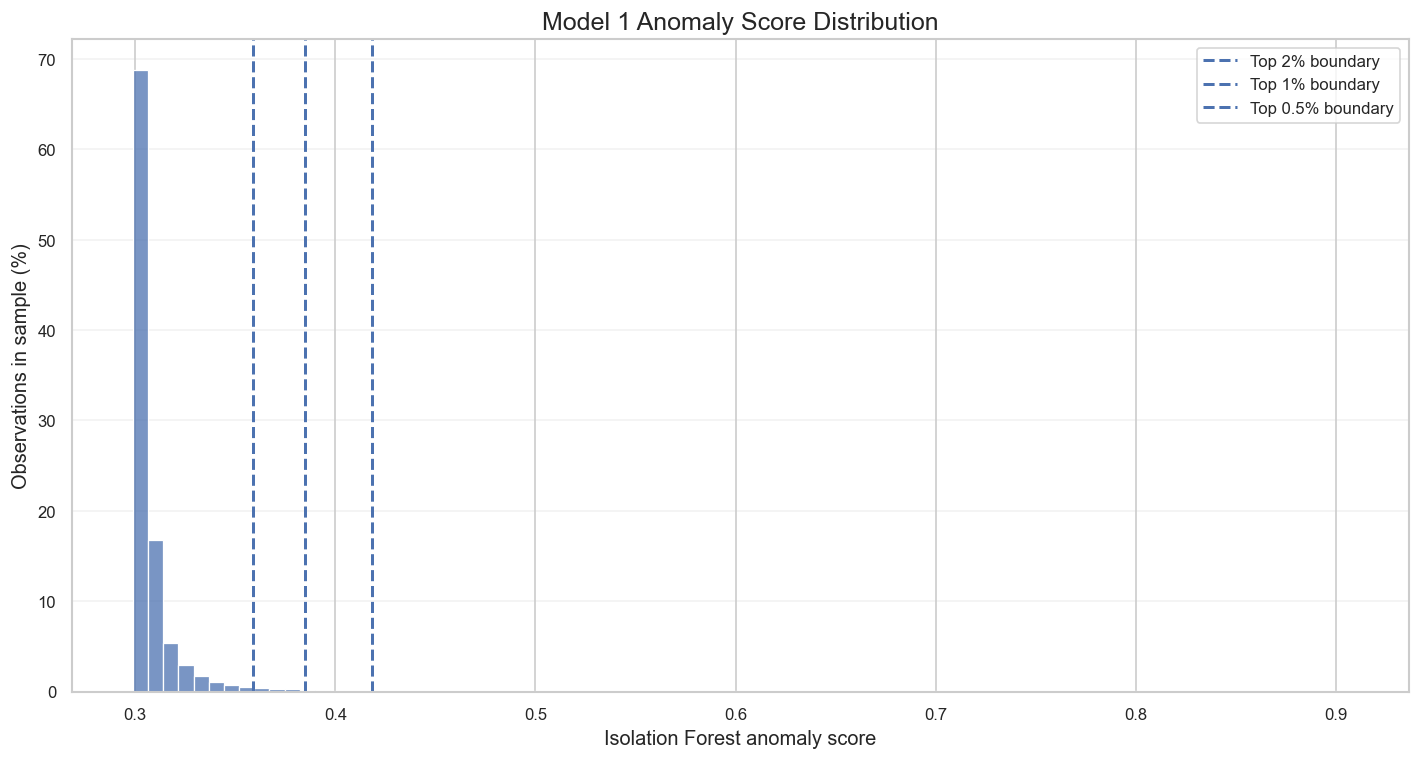

CELL 68 - PLOT THE ANOMALY SCORE DISTRIBUTION

Observations represented in plotting sample: 501,123
Sampling stride: 238

Anomaly-score boundaries:


,Anomaly Group,Maximum Global Rank,Boundary Score
0,Top 2%,2385341,0.358847
1,Top 1%,1192671,0.384876
2,Top 0.5%,596336,0.418355



The Model 1 anomaly-score distribution was plotted successfully.


In [69]:
# ================================================================
# CELL 68 - PLOT THE ANOMALY SCORE DISTRIBUTION
# ================================================================

import matplotlib.ticker as mticker
import seaborn as sns


# ------------------------------------------------
# Shared visualisation settings
# ------------------------------------------------

MODEL_1_VISUAL_FIGURE_DPI = (
    300
)


MODEL_1_SCORE_SAMPLE_TARGET = (
    500_000
)


MODEL_1_VISUAL_FIGURES = {
    "score_distribution": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_anomaly_score_distribution.png"
    ),
    "score_rank": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_score_by_global_rank.png"
    ),
    "daily_severity": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_daily_score_severity.png"
    ),
    "daily_top_1": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_daily_top_1_percent.png"
    ),
    "primary_reasons": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_primary_reason_frequency.png"
    ),
    "reason_heatmap": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_reason_heatmap.png"
    ),
    "primary_deviation": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_primary_deviation_distribution.png"
    ),
    "reason_count": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_total_reason_distribution.png"
    ),
    "threshold_groups": (
        MODEL_1_FIGURE_FOLDER
        /
        "model_1_score_by_anomaly_group.png"
    )
}


sns.set_theme(
    style="whitegrid",
    context="notebook"
)


plt.rcParams.update(
    {
        "figure.figsize": (
            12,
            6
        ),
        "figure.dpi": 120,
        "axes.titlesize": 15,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10
    }
)


# ------------------------------------------------
# Prepare ranked-partition SQL input
# ------------------------------------------------

model_1_visual_ranked_files = sorted(
    MODEL_1_RANKED_PARTITIONS_FOLDER.glob(
        "*_model_1_ranked.parquet"
    )
)


def model_1_sql_path(
    file_path
):

    safe_path = (
        file_path
        .resolve()
        .as_posix()
        .replace(
            "'",
            "''"
        )
    )


    return (
        f"'{safe_path}'"
    )


model_1_visual_ranked_sql_list = (
    "["
    +
    ", ".join(
        model_1_sql_path(
            file_path
        )
        for file_path
        in model_1_visual_ranked_files
    )
    +
    "]"
)


# ------------------------------------------------
# Create a deterministic score sample
# ------------------------------------------------

model_1_score_sample_stride = max(
    1,
    MODEL_DATASET_TOTAL_ROWS
    //
    MODEL_1_SCORE_SAMPLE_TARGET
)


model_1_score_distribution_sample = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_GLOBAL_RANK_COLUMN}
                AS global_rank,

            {MODEL_1_ANOMALY_SCORE_COLUMN}
                AS anomaly_score

        FROM model_1_global_ranking

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN} = 1

            OR

            MOD(
                {MODEL_1_GLOBAL_RANK_COLUMN},
                {model_1_score_sample_stride}
            ) = 0

        ORDER BY
            {MODEL_1_GLOBAL_RANK_COLUMN}
        """
    )
    .df()
)


# ------------------------------------------------
# Plot
# ------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        12,
        6.5
    )
)


sns.histplot(
    data=model_1_score_distribution_sample,
    x="anomaly_score",
    bins=80,
    stat="percent",
    ax=axis
)


axis.axvline(
    MODEL_1_TOP_2_PERCENT_SCORE,
    linestyle="--",
    linewidth=1.8,
    label="Top 2% boundary"
)


axis.axvline(
    MODEL_1_TOP_1_PERCENT_SCORE,
    linestyle="--",
    linewidth=1.8,
    label="Top 1% boundary"
)


axis.axvline(
    MODEL_1_TOP_0_5_PERCENT_SCORE,
    linestyle="--",
    linewidth=1.8,
    label="Top 0.5% boundary"
)


axis.set_title(
    "Model 1 Anomaly Score Distribution"
)


axis.set_xlabel(
    "Isolation Forest anomaly score"
)


axis.set_ylabel(
    "Observations in sample (%)"
)


axis.legend(
    frameon=True
)


axis.grid(
    axis="y",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "score_distribution"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 68 - PLOT THE ANOMALY SCORE DISTRIBUTION")
print("=" * 80)


print(
    f"\nObservations represented in plotting sample: "
    f"{len(model_1_score_distribution_sample):,}"
)


print(
    f"Sampling stride: "
    f"{model_1_score_sample_stride:,}"
)


print(
    "\nAnomaly-score boundaries:"
)


display(
    pd.DataFrame(
        {
            "Anomaly Group": [
                "Top 2%",
                "Top 1%",
                "Top 0.5%"
            ],
            "Maximum Global Rank": [
                MODEL_1_TOP_2_PERCENT_ROWS,
                MODEL_1_TOP_1_PERCENT_ROWS,
                MODEL_1_TOP_0_5_PERCENT_ROWS
            ],
            "Boundary Score": [
                MODEL_1_TOP_2_PERCENT_SCORE,
                MODEL_1_TOP_1_PERCENT_SCORE,
                MODEL_1_TOP_0_5_PERCENT_SCORE
            ]
        }
    )
)


assert len(
    model_1_visual_ranked_files
) == USABLE_MODEL_PARTITION_COUNT


assert len(
    model_1_score_distribution_sample
) > 0


assert MODEL_1_VISUAL_FIGURES[
    "score_distribution"
].exists()


print(
    "\nThe Model 1 anomaly-score distribution "
    "was plotted successfully."
)

## What Cell 68 Does

This cell plots the overall distribution of Model 1 Isolation Forest anomaly scores.

A deterministic sample of the complete global ranking is used so that the figure represents the full dataset without loading more than one hundred million score values into pandas.

The Top 2%, Top 1% and Top 0.5% score boundaries are shown as reference lines.

Higher Model 1 scores represent stronger anomalous behaviour.

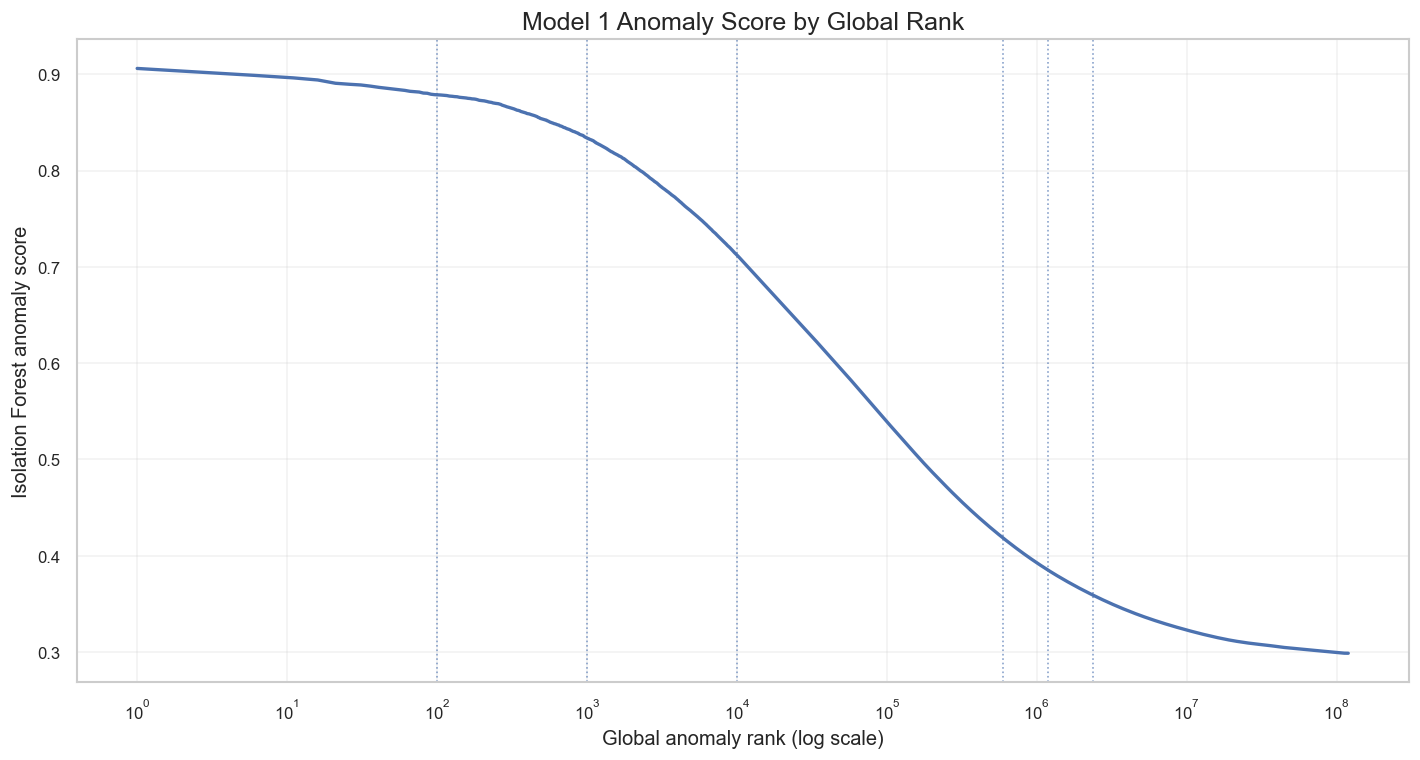

CELL 69 - PLOT ANOMALY SCORE AGAINST GLOBAL RANK

Rank-curve plotting observations: 7,011


,Reference,Global Rank
0,Top 100,100
1,"Top 1,000",1000
2,"Top 10,000",10000
3,Top 0.5%,596336
4,Top 1%,1192671
5,Top 2%,2385341



The anomaly-score versus global-rank figure was created successfully.


In [70]:
# ================================================================
# CELL 69 - PLOT ANOMALY SCORE AGAINST GLOBAL RANK
# ================================================================

# ------------------------------------------------
# Retain additional detail at the extreme ranks
# ------------------------------------------------

model_1_top_rank_curve = (
    model_1_top_10000[
        [
            MODEL_1_GLOBAL_RANK_COLUMN,
            MODEL_1_ANOMALY_SCORE_COLUMN
        ]
    ]
    .rename(
        columns={
            MODEL_1_GLOBAL_RANK_COLUMN: (
                "global_rank"
            ),
            MODEL_1_ANOMALY_SCORE_COLUMN: (
                "anomaly_score"
            )
        }
    )
    .copy()
)


model_1_rank_curve_data = (
    pd.concat(
        [
            model_1_top_rank_curve,
            model_1_score_distribution_sample
        ],
        ignore_index=True
    )
    .drop_duplicates(
        subset=[
            "global_rank"
        ]
    )
    .sort_values(
        "global_rank"
    )
    .reset_index(
        drop=True
    )
)


# Reduce plotting density while retaining the extreme tail
model_1_rank_curve_extreme = (
    model_1_rank_curve_data.loc[
        model_1_rank_curve_data[
            "global_rank"
        ]
        <=
        10_000
    ]
    .iloc[
        ::5
    ]
)


model_1_rank_curve_remainder = (
    model_1_rank_curve_data.loc[
        model_1_rank_curve_data[
            "global_rank"
        ]
        >
        10_000
    ]
    .iloc[
        ::100
    ]
)


model_1_rank_curve_plot = (
    pd.concat(
        [
            model_1_rank_curve_extreme,
            model_1_rank_curve_remainder
        ],
        ignore_index=True
    )
    .sort_values(
        "global_rank"
    )
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6.5
    )
)


sns.lineplot(
    data=model_1_rank_curve_plot,
    x="global_rank",
    y="anomaly_score",
    linewidth=2.0,
    ax=axis
)


important_rank_lines = {
    "Top 100": MODEL_1_TOP_100_ROWS,
    "Top 1,000": MODEL_1_TOP_1000_ROWS,
    "Top 10,000": MODEL_1_TOP_10000_ROWS,
    "Top 0.5%": MODEL_1_TOP_0_5_PERCENT_ROWS,
    "Top 1%": MODEL_1_TOP_1_PERCENT_ROWS,
    "Top 2%": MODEL_1_TOP_2_PERCENT_ROWS
}


for label, rank_value in (
    important_rank_lines.items()
):

    axis.axvline(
        rank_value,
        linestyle=":",
        linewidth=1.0,
        alpha=0.65
    )


axis.set_xscale(
    "log"
)


axis.set_title(
    "Model 1 Anomaly Score by Global Rank"
)


axis.set_xlabel(
    "Global anomaly rank (log scale)"
)


axis.set_ylabel(
    "Isolation Forest anomaly score"
)


axis.grid(
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "score_rank"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 69 - PLOT ANOMALY SCORE AGAINST GLOBAL RANK")
print("=" * 80)


print(
    f"\nRank-curve plotting observations: "
    f"{len(model_1_rank_curve_plot):,}"
)


display(
    pd.DataFrame(
        {
            "Reference": list(
                important_rank_lines.keys()
            ),
            "Global Rank": list(
                important_rank_lines.values()
            )
        }
    )
)


assert (
    model_1_rank_curve_plot[
        "global_rank"
    ]
    .is_monotonic_increasing
)


assert MODEL_1_VISUAL_FIGURES[
    "score_rank"
].exists()


print(
    "\nThe anomaly-score versus global-rank "
    "figure was created successfully."
)

## What Cell 69 Does

This cell visualises the relationship between Isolation Forest anomaly score and global anomaly rank.

The strongest part of the ranking is retained at greater detail, while the remainder of the dataset is thinned for plotting efficiency.

A logarithmic rank axis allows the most extreme observations and the much larger remainder of the dataset to be shown in the same figure.

The plot shows how anomaly strength decreases as observations move away from the top of the global ranking.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

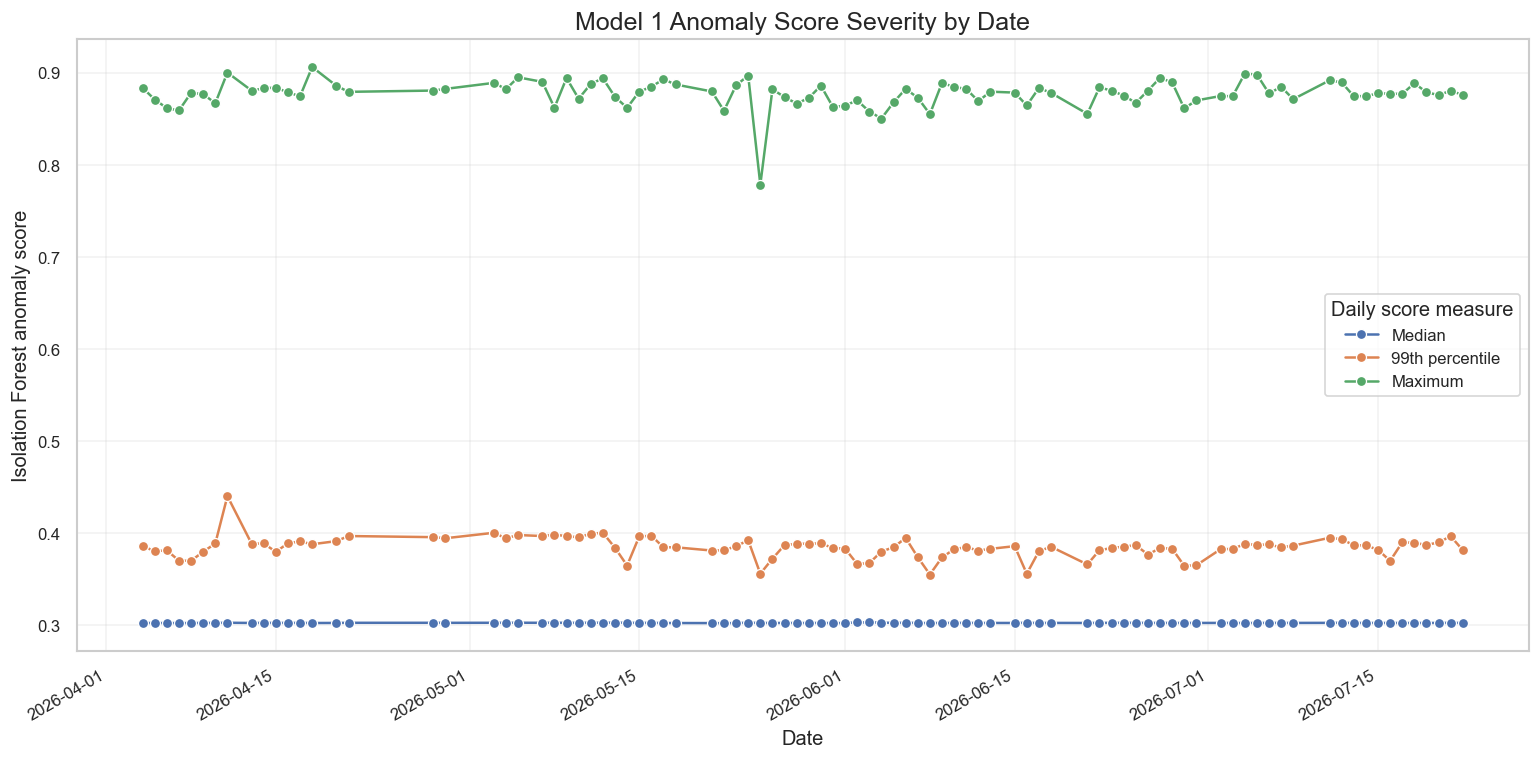

CELL 70 - ANALYSE DAILY ANOMALY SCORE SEVERITY


,observation_date,observations,median_anomaly_score,percentile_99_anomaly_score,maximum_anomaly_score,top_1_percent_count
0,2026-04-04,1322741,0.302664,0.386180,0.883488,"13,427.000000"
1,2026-04-05,1325263,0.302736,0.380620,0.870824,"11,856.000000"
2,2026-04-06,1371738,0.302618,0.381506,0.861459,"12,385.000000"
3,2026-04-07,1223418,0.302670,0.370351,0.858986,"7,993.000000"
4,2026-04-08,1294137,0.302602,0.370233,0.878093,"8,475.000000"
5,2026-04-09,1215695,0.302817,0.380042,0.876667,"10,587.000000"
6,2026-04-10,1276920,0.302728,0.389008,0.866860,"13,629.000000"
7,2026-04-11,1267340,0.302969,0.440399,0.900098,"30,284.000000"
8,2026-04-13,1232265,0.302756,0.388675,0.880511,"13,355.000000"
9,2026-04-14,1208420,0.302778,0.389023,0.883047,"13,201.000000"



Daily Model 1 score severity was analysed successfully.


In [71]:
# ================================================================
# CELL 70 - ANALYSE DAILY ANOMALY SCORE SEVERITY
# ================================================================

model_1_daily_score_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            CAST(
                en_dt
                AS DATE
            ) AS observation_date,

            COUNT(*) AS observations,

            MEDIAN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS median_anomaly_score,

            APPROX_QUANTILE(
                {MODEL_1_ANOMALY_SCORE_COLUMN},
                0.99
            ) AS percentile_99_anomaly_score,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_anomaly_score,

            COUNT_IF(
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
            ) AS top_1_percent_count

        FROM read_parquet(
            {model_1_visual_ranked_sql_list},
            union_by_name = true
        )

        GROUP BY
            CAST(
                en_dt
                AS DATE
            )

        ORDER BY
            observation_date
        """
    )
    .df()
)


model_1_daily_score_summary[
    "observation_date"
] = pd.to_datetime(
    model_1_daily_score_summary[
        "observation_date"
    ]
)


figure, axis = plt.subplots(
    figsize=(
        13,
        6.5
    )
)


sns.lineplot(
    data=model_1_daily_score_summary,
    x="observation_date",
    y="median_anomaly_score",
    marker="o",
    label="Median",
    ax=axis
)


sns.lineplot(
    data=model_1_daily_score_summary,
    x="observation_date",
    y="percentile_99_anomaly_score",
    marker="o",
    label="99th percentile",
    ax=axis
)


sns.lineplot(
    data=model_1_daily_score_summary,
    x="observation_date",
    y="maximum_anomaly_score",
    marker="o",
    label="Maximum",
    ax=axis
)


axis.set_title(
    "Model 1 Anomaly Score Severity by Date"
)


axis.set_xlabel(
    "Date"
)


axis.set_ylabel(
    "Isolation Forest anomaly score"
)


axis.legend(
    title="Daily score measure"
)


axis.grid(
    alpha=0.25
)


figure.autofmt_xdate()


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "daily_severity"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 70 - ANALYSE DAILY ANOMALY SCORE SEVERITY")
print("=" * 80)


display(
    model_1_daily_score_summary
)


assert int(
    model_1_daily_score_summary[
        "observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert (
    model_1_daily_score_summary[
        "median_anomaly_score"
    ]
    <=
    model_1_daily_score_summary[
        "percentile_99_anomaly_score"
    ]
).all()


assert (
    model_1_daily_score_summary[
        "percentile_99_anomaly_score"
    ]
    <=
    model_1_daily_score_summary[
        "maximum_anomaly_score"
    ]
).all()


assert MODEL_1_VISUAL_FIGURES[
    "daily_severity"
].exists()


print(
    "\nDaily Model 1 score severity was "
    "analysed successfully."
)

## What Cell 70 Does

This cell compares Model 1 anomaly-score severity across the available study dates.

For each date it calculates the median anomaly score, the 99th-percentile anomaly score and the maximum anomaly score.

The median describes the typical observation, while the 99th percentile and maximum focus on the strongest daily anomaly behaviour.

This provides a model-level temporal diagnostic before the more detailed temporal analysis in Part 2.

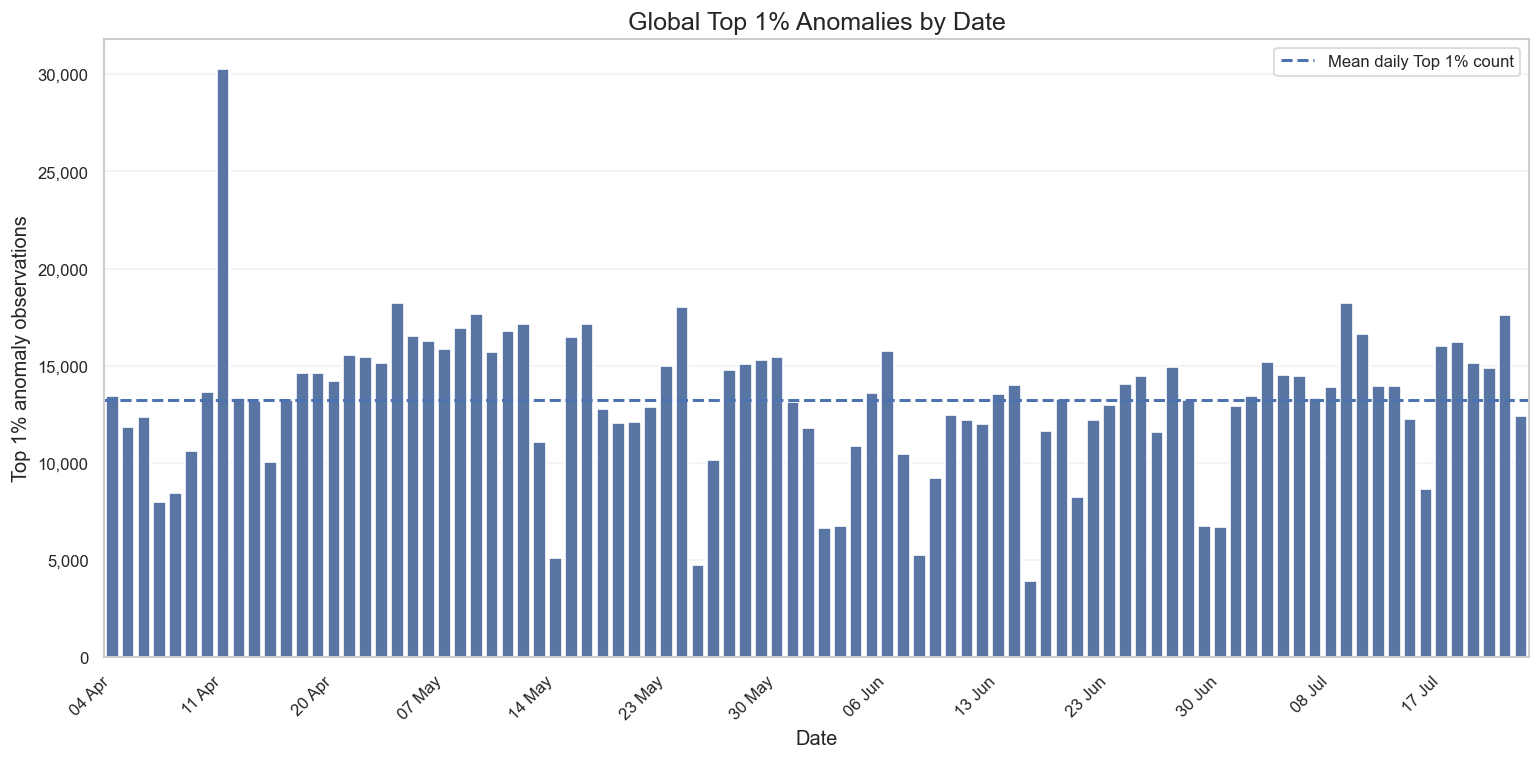

CELL 71 - PLOT DAILY TOP 1 PERCENT ANOMALY COUNTS

Dates containing the most global Top 1% anomalies:


,observation_date,observations,top_1_percent_count
7,2026-04-11,1267340,"30,284.000000"
18,2026-05-03,1355771,"18,247.000000"
78,2026-07-11,1490688,"18,244.000000"
36,2026-05-24,1559832,"18,033.000000"
23,2026-05-09,1382651,"17,661.000000"
88,2026-07-21,1402105,"17,604.000000"
30,2026-05-16,1349578,"17,141.000000"
26,2026-05-12,1258356,"17,124.000000"
22,2026-05-08,1290651,"16,921.000000"
25,2026-05-11,1221463,"16,770.000000"



Daily global Top 1% anomaly counts were plotted successfully.


In [72]:
# ================================================================
# CELL 71 - PLOT DAILY TOP 1 PERCENT ANOMALY COUNTS
# ================================================================

model_1_average_daily_top_1_count = (
    model_1_daily_score_summary[
        "top_1_percent_count"
    ]
    .mean()
)


figure, axis = plt.subplots(
    figsize=(
        13,
        6.5
    )
)


sns.barplot(
    data=model_1_daily_score_summary,
    x="observation_date",
    y="top_1_percent_count",
    ax=axis
)


axis.axhline(
    model_1_average_daily_top_1_count,
    linestyle="--",
    linewidth=1.8,
    label=(
        "Mean daily Top 1% count"
    )
)


axis.set_title(
    "Global Top 1% Anomalies by Date"
)


axis.set_xlabel(
    "Date"
)


axis.set_ylabel(
    "Top 1% anomaly observations"
)


axis.yaxis.set_major_formatter(
    mticker.StrMethodFormatter(
        "{x:,.0f}"
    )
)


date_tick_positions = list(
    range(
        0,
        len(
            model_1_daily_score_summary
        ),
        max(
            1,
            len(
                model_1_daily_score_summary
            )
            //
            12
        )
    )
)


axis.set_xticks(
    date_tick_positions
)


axis.set_xticklabels(
    [
        model_1_daily_score_summary.loc[
            position,
            "observation_date"
        ].strftime(
            "%d %b"
        )
        for position
        in date_tick_positions
    ],
    rotation=45,
    ha="right"
)


axis.legend()


axis.grid(
    axis="y",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "daily_top_1"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


model_1_highest_top_1_day = (
    model_1_daily_score_summary
    .sort_values(
        "top_1_percent_count",
        ascending=False
    )
    .head(
        10
    )
    .copy()
)


print("=" * 80)
print("CELL 71 - PLOT DAILY TOP 1 PERCENT ANOMALY COUNTS")
print("=" * 80)


print(
    "\nDates containing the most global "
    "Top 1% anomalies:"
)


display(
    model_1_highest_top_1_day[
        [
            "observation_date",
            "observations",
            "top_1_percent_count"
        ]
    ]
)


assert int(
    model_1_daily_score_summary[
        "top_1_percent_count"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert MODEL_1_VISUAL_FIGURES[
    "daily_top_1"
].exists()


print(
    "\nDaily global Top 1% anomaly counts "
    "were plotted successfully."
)

## What Cell 71 Does

This cell plots the number of observations belonging to the global Top 1% anomaly group on each date.

Because the threshold is defined across the complete dataset rather than separately for each day, dates with unusually large counts contribute disproportionately to the global anomaly group.

The horizontal reference line shows the mean number of Top 1% observations per study date.

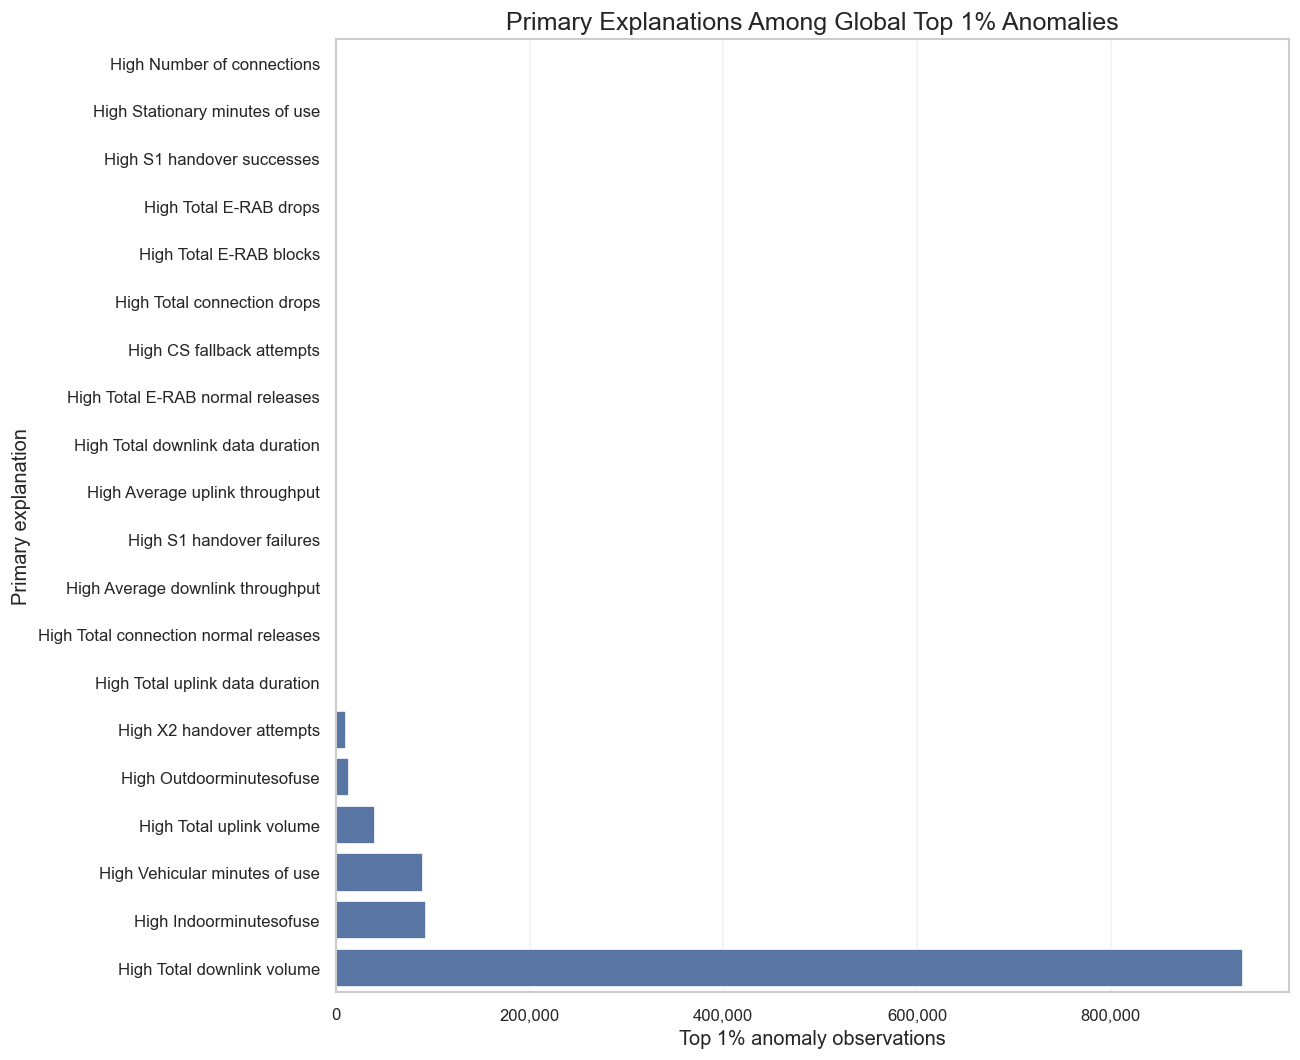

CELL 72 - PLOT PRIMARY ANOMALY REASONS


,primary_reason,observations,share_percent
0,High totaldownlinkvolume,936902,78.554941
1,High indoorminutesofuse,93587,7.846841
2,High vehicularminutesofuse,89933,7.540470
3,High totaluplinkvolume,40514,3.396913
4,High outdoorminutesofuse,13685,1.147425
5,High x2handoverattempts,10650,0.892954
6,High totaluplinkdataduration,1546,0.129625
7,High totalconnectionnormalreleases,1364,0.114365
8,High averagedownlinkthroughput,1323,0.110927
9,High s1handoverfailures,1278,0.107154



Primary anomaly explanations were plotted successfully.


In [73]:
# ================================================================
# CELL 72 - PLOT PRIMARY ANOMALY REASONS
# ================================================================

model_1_primary_reason_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_PRIMARY_REASON_COLUMN}
                AS primary_reason,

            COUNT(*) AS observations

        FROM read_parquet(
            {model_1_sql_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )

        GROUP BY
            {MODEL_1_PRIMARY_REASON_COLUMN}

        ORDER BY
            observations DESC
        """
    )
    .df()
)


MODEL_1_REASON_DISPLAY_NAMES = {
    "averagedownlinkthroughput": (
        "Average downlink throughput"
    ),
    "averageuplinkthroughput": (
        "Average uplink throughput"
    ),
    "csfallbackattempts": (
        "CS fallback attempts"
    ),
    "irathandoverattempts": (
        "IRAT handover attempts"
    ),
    "linearaveragersrp": (
        "Average RSRP"
    ),
    "linearaveragersrq": (
        "Average RSRQ"
    ),
    "minutesofuse": (
        "Minutes of use"
    ),
    "numberofconnections": (
        "Number of connections"
    ),
    "pedestrianminutesofuse": (
        "Pedestrian minutes of use"
    ),
    "s1handoverattempts": (
        "S1 handover attempts"
    ),
    "s1handoverfailures": (
        "S1 handover failures"
    ),
    "s1handoversuccesses": (
        "S1 handover successes"
    ),
    "stationaryminutesofuse": (
        "Stationary minutes of use"
    ),
    "totalconnectionblocks": (
        "Total connection blocks"
    ),
    "totalconnectiondrops": (
        "Total connection drops"
    ),
    "totalconnectionnormalreleases": (
        "Total connection normal releases"
    ),
    "totaldownlinkdataduration": (
        "Total downlink data duration"
    ),
    "totaldownlinkvolume": (
        "Total downlink volume"
    ),
    "totalerabblocks": (
        "Total E-RAB blocks"
    ),
    "totalerabdrops": (
        "Total E-RAB drops"
    ),
    "totalerabnormalreleases": (
        "Total E-RAB normal releases"
    ),
    "totaluplinkdataduration": (
        "Total uplink data duration"
    ),
    "totaluplinkvolume": (
        "Total uplink volume"
    ),
    "vehicularminutesofuse": (
        "Vehicular minutes of use"
    ),
    "voiceminutesofuse": (
        "Voice minutes of use"
    ),
    "x2handoverattempts": (
        "X2 handover attempts"
    ),
    "x2handoverfailures": (
        "X2 handover failures"
    ),
    "x2handoversuccesses": (
        "X2 handover successes"
    )
}


def model_1_reason_display_name(
    reason_value
):

    reason_text = str(
        reason_value
    )


    reason_lower = (
        reason_text.lower()
    )


    direction = ""


    if reason_lower.startswith(
        "high "
    ):

        direction = "High "

        reason_lower = (
            reason_lower[
                5:
            ]
        )


    elif reason_lower.startswith(
        "low "
    ):

        direction = "Low "

        reason_lower = (
            reason_lower[
                4:
            ]
        )


    base_label = (
        MODEL_1_REASON_DISPLAY_NAMES.get(
            reason_lower,
            reason_lower.replace(
                "_",
                " "
            ).capitalize()
        )
    )


    return (
        direction
        +
        base_label
    )


model_1_primary_reason_summary[
    "display_reason"
] = (
    model_1_primary_reason_summary[
        "primary_reason"
    ]
    .apply(
        model_1_reason_display_name
    )
)


model_1_primary_reason_summary[
    "share_percent"
] = (
    model_1_primary_reason_summary[
        "observations"
    ]
    /
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    *
    100.0
)


model_1_primary_reason_plot = (
    model_1_primary_reason_summary
    .sort_values(
        "observations",
        ascending=True
    )
)


figure, axis = plt.subplots(
    figsize=(
        11,
        9
    )
)


sns.barplot(
    data=model_1_primary_reason_plot,
    x="observations",
    y="display_reason",
    ax=axis
)


axis.set_title(
    "Primary Explanations Among Global Top 1% Anomalies"
)


axis.set_xlabel(
    "Top 1% anomaly observations"
)


axis.set_ylabel(
    "Primary explanation"
)


axis.xaxis.set_major_formatter(
    mticker.StrMethodFormatter(
        "{x:,.0f}"
    )
)


axis.grid(
    axis="x",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "primary_reasons"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 72 - PLOT PRIMARY ANOMALY REASONS")
print("=" * 80)


display(
    model_1_primary_reason_summary[
        [
            "primary_reason",
            "observations",
            "share_percent"
        ]
    ]
)


assert int(
    model_1_primary_reason_summary[
        "observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert MODEL_1_VISUAL_FIGURES[
    "primary_reasons"
].exists()


print(
    "\nPrimary anomaly explanations were "
    "plotted successfully."
)

## What Cell 72 Does

This cell shows which BT measurements most frequently provide the primary descriptive explanation for global Top 1% anomalies.

The explanation identifies the retained BT measurement with the largest relative deviation from its normal-reference behaviour.

Readable display labels are used in the figure while the original model column names remain unchanged.

These frequencies are descriptive explanation results and should not be interpreted as formal Isolation Forest feature importance values.

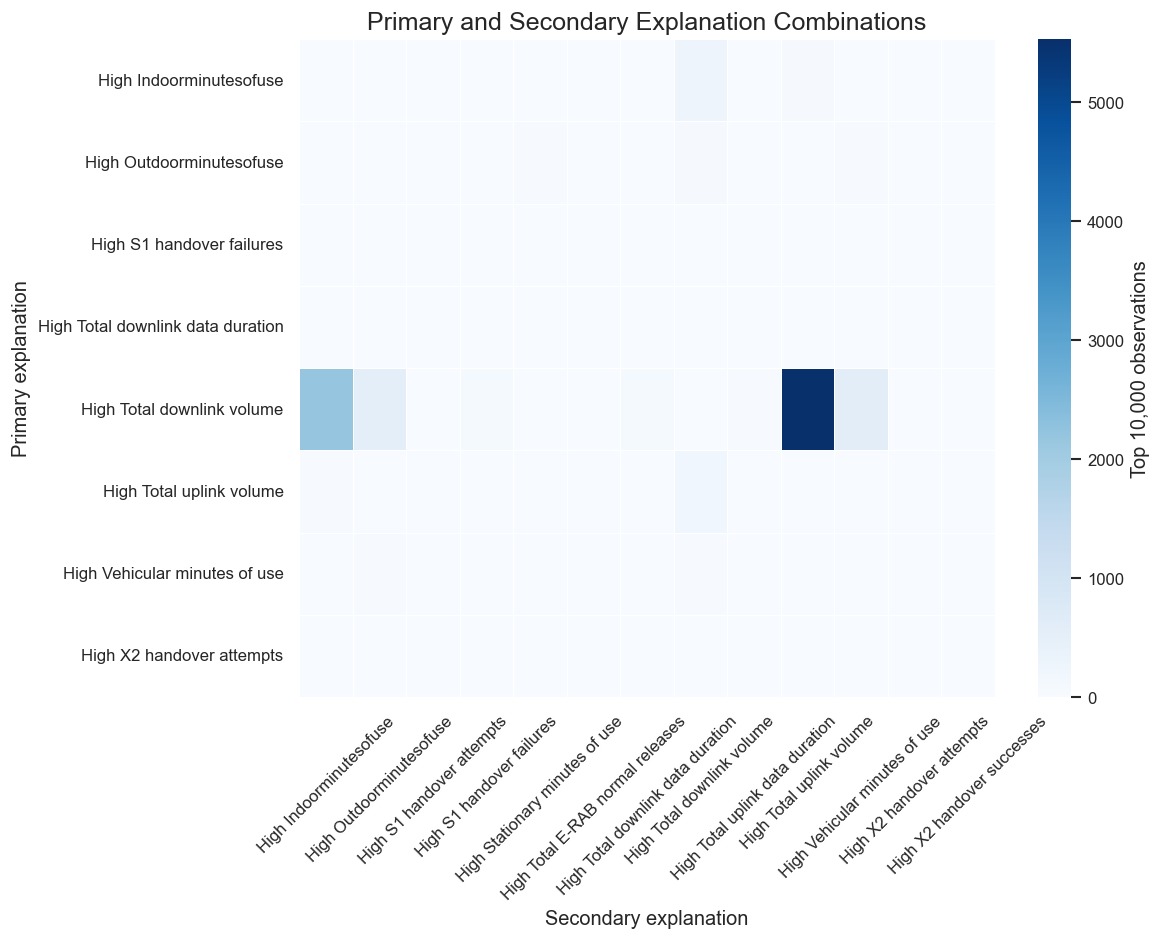

CELL 73 - PLOT PRIMARY AND SECONDARY REASON COMBINATIONS

Top 10,000 reason combinations represented: 10,000
Primary reason categories shown: 8
Secondary reason categories shown: 13

Primary and secondary explanation combinations were plotted successfully.


In [74]:
# ================================================================
# CELL 73 - PLOT PRIMARY AND SECONDARY REASON COMBINATIONS
# ================================================================

model_1_reason_pair_data = (
    model_1_top_10000[
        [
            MODEL_1_PRIMARY_REASON_COLUMN,
            MODEL_1_SECONDARY_REASON_COLUMN
        ]
    ]
    .dropna()
    .copy()
)


model_1_reason_pair_data[
    "Primary Reason"
] = (
    model_1_reason_pair_data[
        MODEL_1_PRIMARY_REASON_COLUMN
    ]
    .apply(
        model_1_reason_display_name
    )
)


model_1_reason_pair_data[
    "Secondary Reason"
] = (
    model_1_reason_pair_data[
        MODEL_1_SECONDARY_REASON_COLUMN
    ]
    .apply(
        model_1_reason_display_name
    )
)


model_1_reason_heatmap_table = (
    pd.crosstab(
        model_1_reason_pair_data[
            "Primary Reason"
        ],
        model_1_reason_pair_data[
            "Secondary Reason"
        ]
    )
)


# Keep only reason labels that actually occur
model_1_reason_heatmap_table = (
    model_1_reason_heatmap_table.loc[
        model_1_reason_heatmap_table.sum(
            axis=1
        )
        >
        0,
        model_1_reason_heatmap_table.sum(
            axis=0
        )
        >
        0
    ]
)


figure, axis = plt.subplots(
    figsize=(
        max(
            10,
            0.65
            *
            len(
                model_1_reason_heatmap_table.columns
            )
        ),
        max(
            8,
            0.55
            *
            len(
                model_1_reason_heatmap_table.index
            )
        )
    )
)


sns.heatmap(
    model_1_reason_heatmap_table,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "Top 10,000 observations"
    },
    ax=axis
)


axis.set_title(
    "Primary and Secondary Explanation Combinations"
)


axis.set_xlabel(
    "Secondary explanation"
)


axis.set_ylabel(
    "Primary explanation"
)


axis.tick_params(
    axis="x",
    rotation=45
)


axis.tick_params(
    axis="y",
    rotation=0
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "reason_heatmap"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 73 - PLOT PRIMARY AND SECONDARY REASON COMBINATIONS")
print("=" * 80)


print(
    f"\nTop 10,000 reason combinations represented: "
    f"{int(model_1_reason_heatmap_table.to_numpy().sum()):,}"
)


print(
    f"Primary reason categories shown: "
    f"{len(model_1_reason_heatmap_table.index):,}"
)


print(
    f"Secondary reason categories shown: "
    f"{len(model_1_reason_heatmap_table.columns):,}"
)


assert int(
    model_1_reason_heatmap_table
    .to_numpy()
    .sum()
) == len(
    model_1_reason_pair_data
)


assert MODEL_1_VISUAL_FIGURES[
    "reason_heatmap"
].exists()


print(
    "\nPrimary and secondary explanation "
    "combinations were plotted successfully."
)

## What Cell 73 Does

This cell shows which primary and secondary anomaly explanations commonly occur together among the global Top 10,000 anomalies.

Each heatmap cell contains the number of observations associated with that pair of explanation variables.

The figure focuses on the strongest anomalies so that recurring combinations can be identified without the much larger Top 1% group dominating the display.

The relationships are descriptive and do not represent causal interactions between BT measurements.

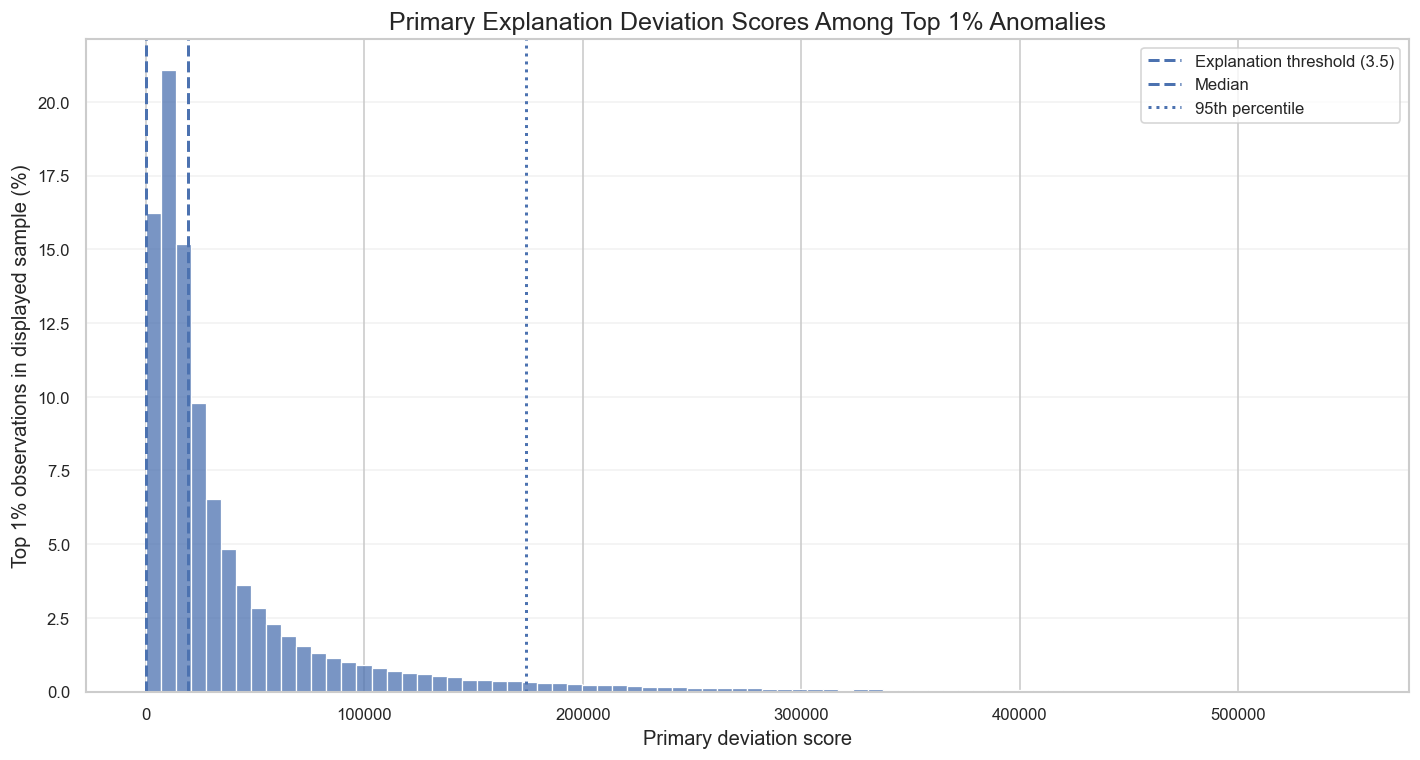

CELL 74 - PLOT PRIMARY DEVIATION SCORE DISTRIBUTION


,median_deviation,percentile_95_deviation,percentile_99_5_deviation,maximum_deviation
0,"19,506.242188","174,033.859467","550,695.246384","6,322,378.500000"



The figure is limited to the 99.5th percentile for readability.

Primary deviation scores were plotted successfully.


In [75]:
# ================================================================
# CELL 74 - PLOT PRIMARY DEVIATION SCORE DISTRIBUTION
# ================================================================

MODEL_1_DEVIATION_SAMPLE_TARGET = (
    250_000
)


model_1_deviation_sample_stride = max(
    1,
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    //
    MODEL_1_DEVIATION_SAMPLE_TARGET
)


model_1_primary_deviation_sample = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                AS primary_deviation

        FROM read_parquet(
            {model_1_sql_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN} = 1

            OR

            MOD(
                {MODEL_1_GLOBAL_RANK_COLUMN},
                {model_1_deviation_sample_stride}
            ) = 0
        """
    )
    .df()
)


model_1_primary_deviation_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            MEDIAN(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS median_deviation,

            APPROX_QUANTILE(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN},
                0.95
            ) AS percentile_95_deviation,

            APPROX_QUANTILE(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN},
                0.995
            ) AS percentile_99_5_deviation,

            MAX(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS maximum_deviation

        FROM read_parquet(
            {model_1_sql_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )
        """
    )
    .df()
)


model_1_primary_deviation_median = float(
    model_1_primary_deviation_summary.loc[
        0,
        "median_deviation"
    ]
)


model_1_primary_deviation_95 = float(
    model_1_primary_deviation_summary.loc[
        0,
        "percentile_95_deviation"
    ]
)


model_1_primary_deviation_99_5 = float(
    model_1_primary_deviation_summary.loc[
        0,
        "percentile_99_5_deviation"
    ]
)


model_1_deviation_plot_data = (
    model_1_primary_deviation_sample.loc[
        model_1_primary_deviation_sample[
            "primary_deviation"
        ]
        <=
        model_1_primary_deviation_99_5
    ]
    .copy()
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6.5
    )
)


sns.histplot(
    data=model_1_deviation_plot_data,
    x="primary_deviation",
    bins=80,
    stat="percent",
    ax=axis
)


axis.axvline(
    MODEL_1_EXPLANATION_THRESHOLD,
    linestyle="--",
    linewidth=1.8,
    label=(
        f"Explanation threshold "
        f"({MODEL_1_EXPLANATION_THRESHOLD:g})"
    )
)


axis.axvline(
    model_1_primary_deviation_median,
    linestyle="--",
    linewidth=1.8,
    label="Median"
)


axis.axvline(
    model_1_primary_deviation_95,
    linestyle=":",
    linewidth=1.8,
    label="95th percentile"
)


axis.set_title(
    "Primary Explanation Deviation Scores Among Top 1% Anomalies"
)


axis.set_xlabel(
    "Primary deviation score"
)


axis.set_ylabel(
    "Top 1% observations in displayed sample (%)"
)


axis.legend()


axis.grid(
    axis="y",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "primary_deviation"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 74 - PLOT PRIMARY DEVIATION SCORE DISTRIBUTION")
print("=" * 80)


display(
    model_1_primary_deviation_summary
)


print(
    "\nThe figure is limited to the 99.5th "
    "percentile for readability."
)


assert len(
    model_1_primary_deviation_sample
) > 0


assert model_1_primary_deviation_median >= 0


assert MODEL_1_VISUAL_FIGURES[
    "primary_deviation"
].exists()


print(
    "\nPrimary deviation scores were "
    "plotted successfully."
)

## What Cell 74 Does

This cell plots the distribution of the primary explanation deviation score among global Top 1% anomalies.

The deviation score measures how strongly the observation differs from the normal-reference behaviour of its primary explanatory BT measurement.

The explanation threshold, median and 95th percentile are shown as reference lines.

For readability, the displayed distribution is limited to the 99.5th percentile so that a small number of extreme deviation values do not compress the main distribution.

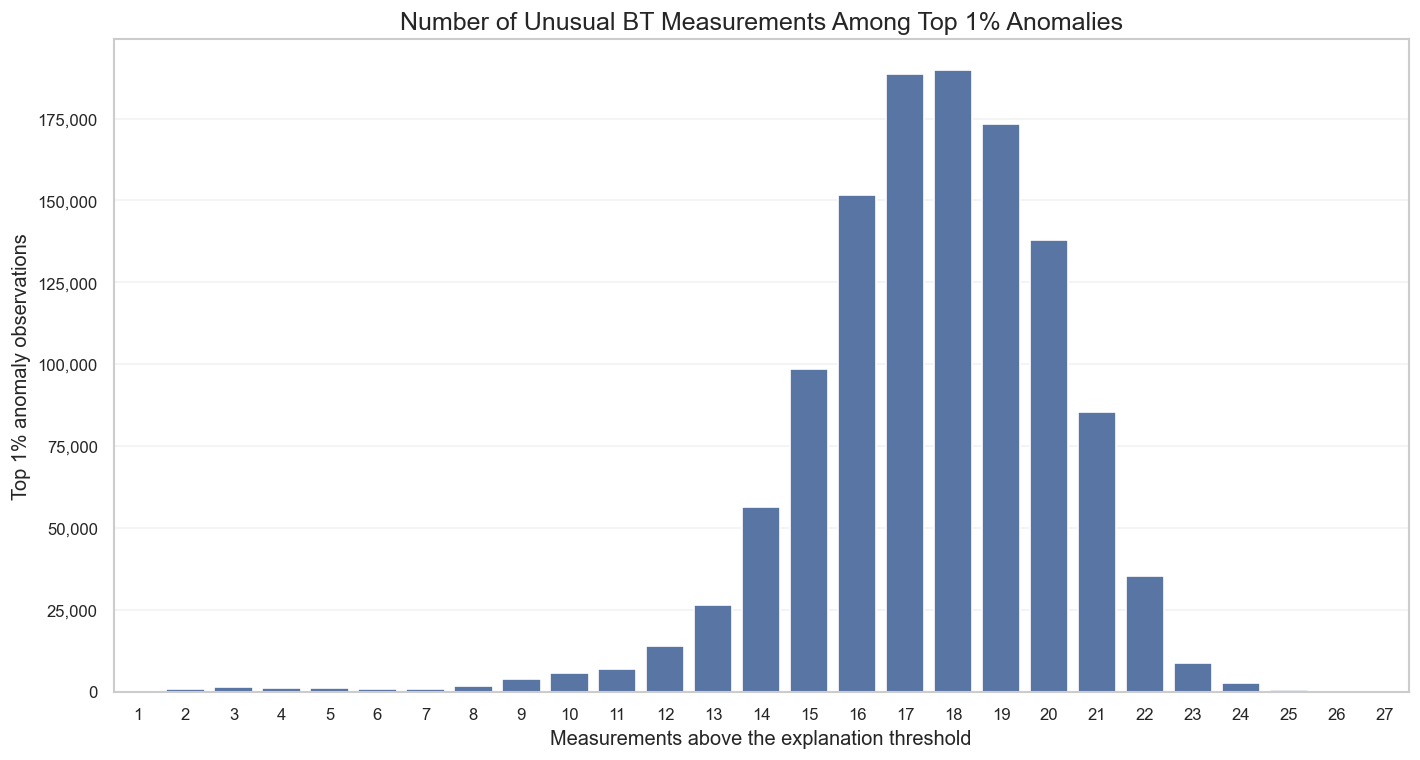

CELL 75 - PLOT THE NUMBER OF ANOMALY EXPLANATION REASONS


,minimum_reasons,median_reasons,mean_reasons,maximum_reasons
0,1,18.000000,17.545641,27


,total_reasons,observations
0,1,20
1,2,631
2,3,1347
3,4,1178
4,5,947
5,6,778
6,7,742
7,8,1654
8,9,3730
9,10,5714



The number of explanation reasons was plotted successfully.


In [76]:
# ================================================================
# CELL 75 - PLOT THE NUMBER OF ANOMALY EXPLANATION REASONS
# ================================================================

model_1_total_reason_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_TOTAL_REASONS_COLUMN}
                AS total_reasons,

            COUNT(*) AS observations

        FROM read_parquet(
            {model_1_sql_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )

        GROUP BY
            {MODEL_1_TOTAL_REASONS_COLUMN}

        ORDER BY
            {MODEL_1_TOTAL_REASONS_COLUMN}
        """
    )
    .df()
)


model_1_total_reason_statistics = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            MIN(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS minimum_reasons,

            MEDIAN(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS median_reasons,

            AVG(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS mean_reasons,

            MAX(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS maximum_reasons

        FROM read_parquet(
            {model_1_sql_path(MODEL_1_TOP_1_PERCENT_FILE)}
        )
        """
    )
    .df()
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6.5
    )
)


sns.barplot(
    data=model_1_total_reason_summary,
    x="total_reasons",
    y="observations",
    ax=axis
)


axis.set_title(
    "Number of Unusual BT Measurements Among Top 1% Anomalies"
)


axis.set_xlabel(
    "Measurements above the explanation threshold"
)


axis.set_ylabel(
    "Top 1% anomaly observations"
)


axis.yaxis.set_major_formatter(
    mticker.StrMethodFormatter(
        "{x:,.0f}"
    )
)


axis.grid(
    axis="y",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "reason_count"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 75 - PLOT THE NUMBER OF ANOMALY EXPLANATION REASONS")
print("=" * 80)


display(
    model_1_total_reason_statistics
)


display(
    model_1_total_reason_summary
)


assert int(
    model_1_total_reason_summary[
        "observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert (
    model_1_total_reason_summary[
        "total_reasons"
    ]
    >=
    0
).all()


assert MODEL_1_VISUAL_FIGURES[
    "reason_count"
].exists()


print(
    "\nThe number of explanation reasons "
    "was plotted successfully."
)

## What Cell 75 Does

This cell examines how many BT measurements are unusually different from their normal-reference behaviour for each global Top 1% anomaly.

`model_1_total_reasons` counts the retained BT measurements whose absolute deviation score reaches the explanation threshold.

The figure therefore distinguishes anomalies associated with one or a small number of unusual measurements from observations showing broader simultaneous changes across the network measurements.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

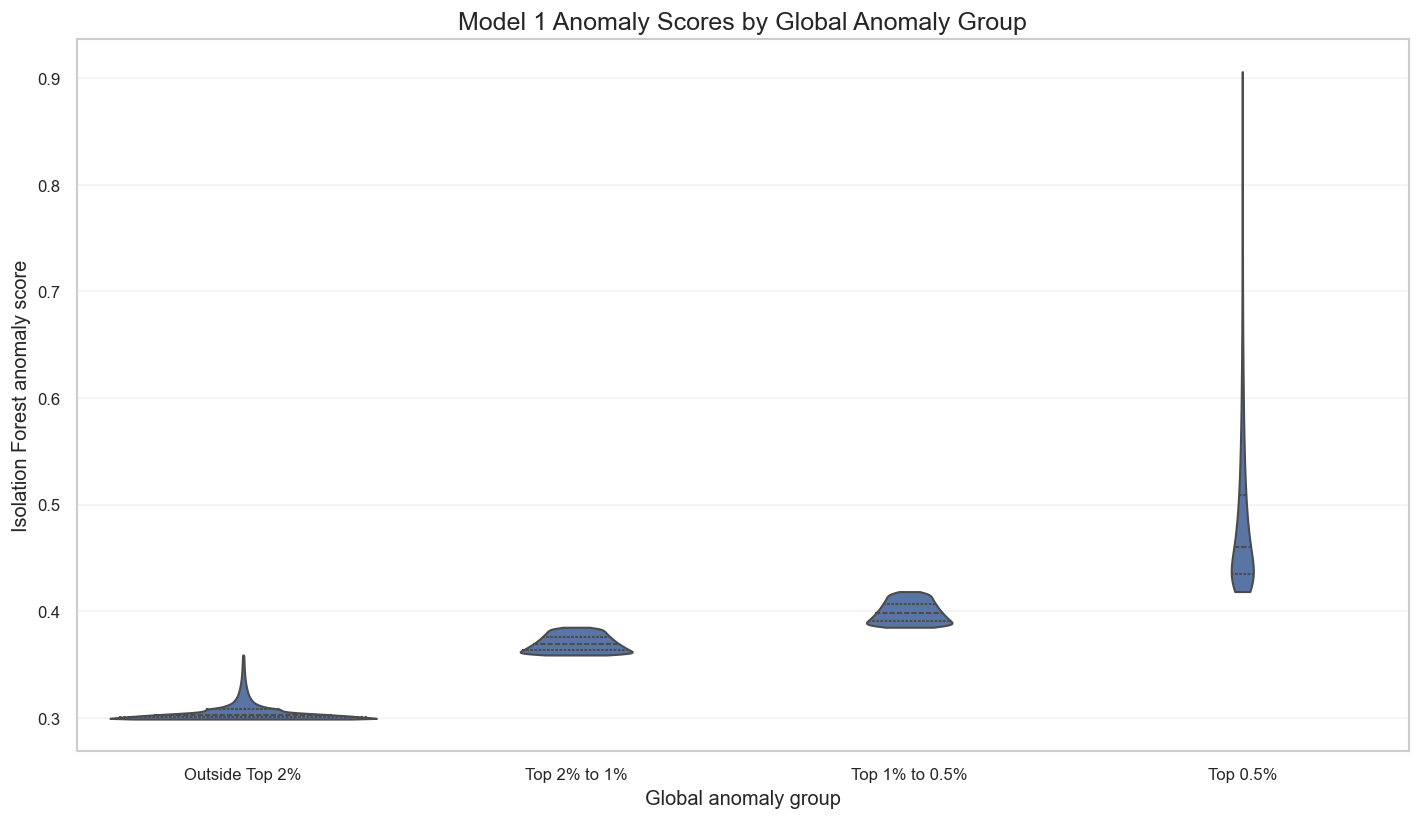

CELL 76 - COMPARE ANOMALY SCORE DISTRIBUTIONS BY GROUP


,anomaly_group,sample_observations,minimum_score,median_score,maximum_score
0,Outside Top 2%,392220,0.298747,0.302672,0.358845
1,Top 0.5%,2002,0.418359,0.459726,0.906137
2,Top 1% to 0.5%,2001,0.384879,0.397808,0.418328
3,Top 2% to 1%,4002,0.358849,0.368862,0.384869



Anomaly-score distributions were compared successfully.


In [77]:
# ================================================================
# CELL 76 - COMPARE ANOMALY SCORE DISTRIBUTIONS BY GROUP
# ================================================================

MODEL_1_GROUP_SAMPLE_TARGET = (
    400_000
)


model_1_group_sample_stride = max(
    1,
    MODEL_DATASET_TOTAL_ROWS
    //
    MODEL_1_GROUP_SAMPLE_TARGET
)


model_1_threshold_group_sample = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_ANOMALY_SCORE_COLUMN}
                AS anomaly_score,

            CASE

                WHEN
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                    <=
                    {MODEL_1_TOP_0_5_PERCENT_ROWS}

                THEN 'Top 0.5%'

                WHEN
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                    <=
                    {MODEL_1_TOP_1_PERCENT_ROWS}

                THEN 'Top 1% to 0.5%'

                WHEN
                    {MODEL_1_GLOBAL_RANK_COLUMN}
                    <=
                    {MODEL_1_TOP_2_PERCENT_ROWS}

                THEN 'Top 2% to 1%'

                ELSE 'Outside Top 2%'

            END AS anomaly_group

        FROM model_1_global_ranking

        WHERE
            {MODEL_1_GLOBAL_RANK_COLUMN} = 1

            OR

            MOD(
                {MODEL_1_GLOBAL_RANK_COLUMN},
                {model_1_group_sample_stride}
            ) = 0
        """
    )
    .df()
)


MODEL_1_ANOMALY_GROUP_ORDER = [
    "Outside Top 2%",
    "Top 2% to 1%",
    "Top 1% to 0.5%",
    "Top 0.5%"
]


figure, axis = plt.subplots(
    figsize=(
        12,
        7
    )
)


sns.violinplot(
    data=model_1_threshold_group_sample,
    x="anomaly_group",
    y="anomaly_score",
    order=MODEL_1_ANOMALY_GROUP_ORDER,
    inner="quartile",
    cut=0,
    ax=axis
)


axis.set_title(
    "Model 1 Anomaly Scores by Global Anomaly Group"
)


axis.set_xlabel(
    "Global anomaly group"
)


axis.set_ylabel(
    "Isolation Forest anomaly score"
)


axis.grid(
    axis="y",
    alpha=0.25
)


figure.tight_layout()


figure.savefig(
    MODEL_1_VISUAL_FIGURES[
        "threshold_groups"
    ],
    dpi=MODEL_1_VISUAL_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


model_1_threshold_group_summary = (
    model_1_threshold_group_sample
    .groupby(
        "anomaly_group",
        as_index=False
    )
    .agg(
        sample_observations=(
            "anomaly_score",
            "size"
        ),
        minimum_score=(
            "anomaly_score",
            "min"
        ),
        median_score=(
            "anomaly_score",
            "median"
        ),
        maximum_score=(
            "anomaly_score",
            "max"
        )
    )
)


print("=" * 80)
print("CELL 76 - COMPARE ANOMALY SCORE DISTRIBUTIONS BY GROUP")
print("=" * 80)


display(
    model_1_threshold_group_summary
)


assert set(
    model_1_threshold_group_sample[
        "anomaly_group"
    ].unique()
) == set(
    MODEL_1_ANOMALY_GROUP_ORDER
)


assert MODEL_1_VISUAL_FIGURES[
    "threshold_groups"
].exists()


print(
    "\nAnomaly-score distributions were "
    "compared successfully."
)

## What Cell 76 Does

This cell compares Model 1 anomaly-score distributions across four mutually exclusive global ranking groups.

The groups separate observations outside the Top 2%, the Top 2% to Top 1%, the Top 1% to Top 0.5%, and the strongest Top 0.5%.

A deterministic sample is used to keep the violin plot efficient while preserving observations from across the complete global ranking.

The comparison provides a visual check that increasingly strong rank groups correspond to increasingly high Isolation Forest anomaly scores.

In [78]:
# ================================================================
# CELL 77 - SUMMARISE MODEL 1 VISUAL RESULTS
# ================================================================

model_1_global_score_summary = (
    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SELECT
            MIN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS minimum_score,

            MEDIAN(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS median_score,

            APPROX_QUANTILE(
                {MODEL_1_ANOMALY_SCORE_COLUMN},
                0.99
            ) AS percentile_99_score,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_score

        FROM model_1_global_ranking
        """
    )
    .df()
)


model_1_peak_top_1_date = (
    model_1_daily_score_summary
    .sort_values(
        "top_1_percent_count",
        ascending=False
    )
    .iloc[
        0
    ]
)


model_1_most_common_primary_reason = (
    model_1_primary_reason_summary
    .iloc[
        0
    ]
)


model_1_visual_results_summary = pd.DataFrame(
    {
        "Measure": [
            "Total observations",
            "Minimum anomaly score",
            "Median anomaly score",
            "99th percentile anomaly score",
            "Maximum anomaly score",
            "Top 2% boundary score",
            "Top 1% boundary score",
            "Top 0.5% boundary score",
            "Date with most Top 1% anomalies",
            "Top 1% anomalies on peak date",
            "Most common primary explanation",
            "Most common primary explanation share (%)",
            "Median primary deviation score",
            "95th percentile primary deviation score",
            "Median number of explanation reasons"
        ],
        "Value": [
            MODEL_DATASET_TOTAL_ROWS,
            float(
                model_1_global_score_summary.loc[
                    0,
                    "minimum_score"
                ]
            ),
            float(
                model_1_global_score_summary.loc[
                    0,
                    "median_score"
                ]
            ),
            float(
                model_1_global_score_summary.loc[
                    0,
                    "percentile_99_score"
                ]
            ),
            float(
                model_1_global_score_summary.loc[
                    0,
                    "maximum_score"
                ]
            ),
            MODEL_1_TOP_2_PERCENT_SCORE,
            MODEL_1_TOP_1_PERCENT_SCORE,
            MODEL_1_TOP_0_5_PERCENT_SCORE,
            (
                model_1_peak_top_1_date[
                    "observation_date"
                ]
                .strftime(
                    "%Y-%m-%d"
                )
            ),
            int(
                model_1_peak_top_1_date[
                    "top_1_percent_count"
                ]
            ),
            model_1_reason_display_name(
                model_1_most_common_primary_reason[
                    "primary_reason"
                ]
            ),
            float(
                model_1_most_common_primary_reason[
                    "share_percent"
                ]
            ),
            model_1_primary_deviation_median,
            model_1_primary_deviation_95,
            float(
                model_1_total_reason_statistics.loc[
                    0,
                    "median_reasons"
                ]
            )
        ]
    }
)


model_1_visual_figure_verification = pd.DataFrame(
    {
        "Figure": [
            "Anomaly score distribution",
            "Score by global rank",
            "Daily score severity",
            "Daily Top 1% anomalies",
            "Primary explanation frequency",
            "Primary-secondary heatmap",
            "Primary deviation distribution",
            "Explanation reason count",
            "Scores by anomaly group"
        ],
        "File": list(
            MODEL_1_VISUAL_FIGURES.values()
        )
    }
)


model_1_visual_figure_verification[
    "Exists"
] = (
    model_1_visual_figure_verification[
        "File"
    ]
    .apply(
        lambda file_path:
        file_path.exists()
    )
)


model_1_visual_figure_verification[
    "File Size (MB)"
] = (
    model_1_visual_figure_verification[
        "File"
    ]
    .apply(
        lambda file_path:
        round(
            file_path.stat().st_size
            /
            (
                1024
                **
                2
            ),
            3
        )
        if file_path.exists()
        else 0.0
    )
)


print("=" * 80)
print("CELL 77 - SUMMARISE MODEL 1 VISUAL RESULTS")
print("=" * 80)


print(
    "\nHeadline Model 1 visual results:"
)


display(
    model_1_visual_results_summary
)


print(
    "\nSaved Model 1 visualisation figures:"
)


display(
    model_1_visual_figure_verification
)


assert len(
    model_1_visual_figure_verification
) == 9


assert (
    model_1_visual_figure_verification[
        "Exists"
    ]
    .all()
)


assert (
    model_1_visual_figure_verification[
        "File Size (MB)"
    ]
    >
    0
).all()


print(
    "\nSection 14 is complete. All Model 1 "
    "visualisation figures were created successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 77 - SUMMARISE MODEL 1 VISUAL RESULTS

Headline Model 1 visual results:


,Measure,Value
0,Total observations,119267039
1,Minimum anomaly score,0.298747
2,Median anomaly score,0.302789
3,99th percentile anomaly score,0.389623
4,Maximum anomaly score,0.906137
5,Top 2% boundary score,0.358847
6,Top 1% boundary score,0.384876
7,Top 0.5% boundary score,0.418355
8,Date with most Top 1% anomalies,2026-04-11
9,Top 1% anomalies on peak date,30284



Saved Model 1 visualisation figures:


,Figure,File,Exists,File Size (MB)
0,Anomaly score distribution,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.139000
1,Score by global rank,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.199000
2,Daily score severity,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.253000
3,Daily Top 1% anomalies,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.167000
4,Primary explanation frequency,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.317000
5,Primary-secondary heatmap,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.468000
6,Primary deviation distribution,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.174000
7,Explanation reason count,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.153000
8,Scores by anomaly group,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,True,0.161000



Section 14 is complete. All Model 1 visualisation figures were created successfully.


## What Cell 77 Does

This cell summarises the main results from the Model 1 visualisation section.

It reports headline values describing the global anomaly-score distribution, anomaly thresholds, strongest temporal concentration and descriptive anomaly explanations.

The cell also verifies that all nine visualisation figures were saved successfully and have non-zero file sizes.

The figures provide a visual summary of the Isolation Forest results before Part 1 is completed and the location and POI analysis begins.

# 15. Model Outputs

This section completes Part 1 of the Model 1 workflow.

It saves the final metadata and cache state, displays the complete Model 1 summary and verifies that all required outputs and reusable processing resources are available.

The final cache state is written only after the complete Part 1 workflow has passed its validation checks.

In [79]:
# ================================================================
# CELL 78 - SAVE METADATA
# ================================================================

import json
import platform
import sklearn
import pyarrow


metadata_start_time = time.time()


def convert_metadata_value(
    value
):
    """
    Convert common Python, NumPy and pandas values into
    JSON-compatible values.
    """

    if isinstance(
        value,
        Path
    ):

        return str(
            value
        )


    if isinstance(
        value,
        np.integer
    ):

        return int(
            value
        )


    if isinstance(
        value,
        np.floating
    ):

        return float(
            value
        )


    if isinstance(
        value,
        np.bool_
    ):

        return bool(
            value
        )


    if isinstance(
        value,
        pd.Timestamp
    ):

        return value.isoformat()


    if isinstance(
        value,
        np.ndarray
    ):

        return [
            convert_metadata_value(
                item
            )
            for item
            in value.tolist()
        ]


    if isinstance(
        value,
        pd.Series
    ):

        return {
            str(
                key
            ): convert_metadata_value(
                item
            )
            for key, item
            in value.to_dict().items()
        }


    if isinstance(
        value,
        pd.DataFrame
    ):

        return [
            {
                str(
                    key
                ): convert_metadata_value(
                    item
                )
                for key, item
                in record.items()
            }
            for record
            in value.to_dict(
                orient="records"
            )
        ]


    if isinstance(
        value,
        dict
    ):

        return {
            str(
                key
            ): convert_metadata_value(
                item
            )
            for key, item
            in value.items()
        }


    if isinstance(
        value,
        (
            list,
            tuple,
            set
        )
    ):

        return [
            convert_metadata_value(
                item
            )
            for item
            in value
        ]


    return value


MODEL_1_DISCOVERED_PARTITION_COUNT = len(
    discovered_model_ready_files
)


model_1_metadata = {
    "model": {
        "model_name": "Model 1",
        "model_type": "Isolation Forest",
        "model_file": (
            MODEL_1_ISOLATION_FOREST_FILE
        ),
        "random_seed": MODEL_1_RANDOM_SEED,
        "training_features": (
            MODEL_1_TRAINING_FEATURES
        ),
        "training_feature_count": (
            MODEL_1_TRAINING_FEATURE_COUNT
        ),
        "isolation_forest_parameters": (
            MODEL_1_ISOLATION_FOREST.get_params()
        )
    },
    "dataset": {
        "discovered_partitions": (
            MODEL_1_DISCOVERED_PARTITION_COUNT
        ),
        "usable_partitions": (
            USABLE_MODEL_PARTITION_COUNT
        ),
        "excluded_partitions": len(
            excluded_model_partition_audit
        ),
        "total_observations": (
            MODEL_DATASET_TOTAL_ROWS
        ),
        "original_columns": (
            EXPECTED_MODEL_READY_COLUMN_COUNT
        ),
        "final_ranked_columns": (
            MODEL_1_FINAL_RANKED_COLUMN_COUNT
        )
    },
    "training": {
        "requested_training_rows": (
            MODEL_1_TRAINING_SAMPLE_TARGET_ROWS
        ),
        "actual_training_rows": (
            MODEL_1_TRAINING_SAMPLE_ROWS
        ),
        "training_sample_dtype": (
            MODEL_1_TRAINING_SAMPLE_DTYPE
        ),
        "training_medians": (
            MODEL_1_IMPUTATION_VALUES
        )
    },
    "ranking": {
        "score_column": (
            MODEL_1_ANOMALY_SCORE_COLUMN
        ),
        "global_rank_column": (
            MODEL_1_GLOBAL_RANK_COLUMN
        ),
        "anomaly_percentile_column": (
            MODEL_1_ANOMALY_PERCENTILE_COLUMN
        ),
        "total_ranked_observations": (
            MODEL_DATASET_TOTAL_ROWS
        )
    },
    "thresholds": {
        "top_2_percent": {
            "rows": MODEL_1_TOP_2_PERCENT_ROWS,
            "boundary_score": (
                MODEL_1_TOP_2_PERCENT_SCORE
            ),
            "column": (
                MODEL_1_ANOMALY_2_PERCENT_COLUMN
            )
        },
        "top_1_percent": {
            "rows": MODEL_1_TOP_1_PERCENT_ROWS,
            "boundary_score": (
                MODEL_1_TOP_1_PERCENT_SCORE
            ),
            "column": (
                MODEL_1_ANOMALY_1_PERCENT_COLUMN
            )
        },
        "top_0_5_percent": {
            "rows": (
                MODEL_1_TOP_0_5_PERCENT_ROWS
            ),
            "boundary_score": (
                MODEL_1_TOP_0_5_PERCENT_SCORE
            ),
            "column": (
                MODEL_1_ANOMALY_0_5_PERCENT_COLUMN
            )
        }
    },
    "normal_reference": {
        "sampling_method": (
            MODEL_1_NORMAL_REFERENCE_SAMPLING_METHOD
        ),
        "eligible_rows": (
            MODEL_1_NORMAL_REFERENCE_ELIGIBLE_ROWS
        ),
        "selected_rows": (
            MODEL_1_NORMAL_REFERENCE_ROWS
        ),
        "excluded_group": "Global Top 1%"
    },
    "reference_statistics": {
        "statistics_file": (
            MODEL_1_REFERENCE_STATISTICS_FILE
        ),
        "statistics": (
            model_1_reference_statistics
        )
    },
    "explanations": {
        "threshold": (
            MODEL_1_EXPLANATION_THRESHOLD
        ),
        "primary_reason_column": (
            MODEL_1_PRIMARY_REASON_COLUMN
        ),
        "primary_deviation_column": (
            MODEL_1_PRIMARY_DEVIATION_COLUMN
        ),
        "secondary_reason_column": (
            MODEL_1_SECONDARY_REASON_COLUMN
        ),
        "secondary_deviation_column": (
            MODEL_1_SECONDARY_DEVIATION_COLUMN
        ),
        "total_reasons_column": (
            MODEL_1_TOTAL_REASONS_COLUMN
        ),
        "feature_configuration": (
            explanation_feature_configuration
        )
    },
    "outputs": {
        "final_ranked_folder": (
            MODEL_1_RANKED_PARTITIONS_FOLDER
        ),
        "top_100": MODEL_1_TOP_100_FILE,
        "top_1000": MODEL_1_TOP_1000_FILE,
        "top_10000": MODEL_1_TOP_10000_FILE,
        "top_1_percent": (
            MODEL_1_TOP_1_PERCENT_FILE
        ),
        "metadata_file": MODEL_1_METADATA_FILE
    },
    "retained_reusable_resources": {
        "scored_partitions_folder": (
            MODEL_1_TEMPORARY_PARTITIONS_FOLDER
        ),
        "final_ranked_partitions_folder": (
            MODEL_1_RANKED_PARTITIONS_FOLDER
        ),
        "explanation_partitions_folder": (
            MODEL_1_EXPLANATION_FOLDER
        ),
        "ranking_lookup_folder": (
            MODEL_1_RANKING_LOOKUP_FOLDER
        ),
        "working_database": (
            MODEL_1_WORKING_DATABASE_FILE
        ),
        "duckdb_temporary_folder": (
            MODEL_1_DUCKDB_TEMP_FOLDER
        ),
        "scored_partitions_retained": (
            MODEL_1_TEMPORARY_PARTITIONS_FOLDER.exists()
        ),
        "final_ranked_partitions_retained": (
            MODEL_1_RANKED_PARTITIONS_FOLDER.exists()
        ),
        "explanation_partitions_retained": (
            MODEL_1_EXPLANATION_FOLDER.exists()
        ),
        "ranking_lookup_files_retained": (
            MODEL_1_RANKING_LOOKUP_FOLDER.exists()
        ),
        "working_database_retained": (
            MODEL_1_WORKING_DATABASE_FILE.exists()
        ),
        "duckdb_temporary_folder_retained": (
            MODEL_1_DUCKDB_TEMP_FOLDER.exists()
        )
    },
    "dynamic_cache": {
        "cache_state_file": (
            MODEL_1_CACHE_STATE_FILE
        ),
        "cache_state_version": (
            MODEL_1_CACHE_STATE_VERSION
        ),
        "dataset_fingerprint": (
            MODEL_1_CURRENT_DATASET_FINGERPRINT
        ),
        "model_sha256": (
            MODEL_1_ACTIVE_MODEL_SHA256
        ),
        "model_configuration_fingerprint": (
            MODEL_1_MODEL_CONFIGURATION_FINGERPRINT
        ),
        "model_retrained_this_run": (
            MODEL_1_MODEL_WAS_RETRAINED
        ),
        "dataset_cache_reusable": (
            MODEL_1_DOWNSTREAM_REUSE_ALLOWED
        ),
        "new_source_partitions": (
            new_partition_count
        ),
        "changed_source_partitions": (
            changed_partition_count
        ),
        "removed_source_partitions": (
            removed_partition_count
        ),
        "active_explanation_folder": (
            MODEL_1_EXPLANATION_FOLDER
        ),
        "active_ranking_lookup_folder": (
            MODEL_1_RANKING_LOOKUP_FOLDER
        )
    },
    "software_versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
        "pyarrow": pyarrow.__version__,
        "duckdb": duckdb.__version__
    },
    "created_at": pd.Timestamp.now().isoformat()
}


json_compatible_metadata = convert_metadata_value(
    model_1_metadata
)


MODEL_1_METADATA_FILE.parent.mkdir(
    parents=True,
    exist_ok=True
)


temporary_metadata_file = (
    MODEL_1_METADATA_FILE.with_suffix(
        ".temporary.json"
    )
)


if temporary_metadata_file.exists():

    temporary_metadata_file.unlink()


with open(
    temporary_metadata_file,
    "w",
    encoding="utf-8"
) as metadata_file:

    json.dump(
        json_compatible_metadata,
        metadata_file,
        indent=4,
        ensure_ascii=False
    )


assert temporary_metadata_file.exists()


assert temporary_metadata_file.stat().st_size > 0


temporary_metadata_file.replace(
    MODEL_1_METADATA_FILE
)


with open(
    MODEL_1_METADATA_FILE,
    "r",
    encoding="utf-8"
) as metadata_file:

    saved_model_1_metadata = json.load(
        metadata_file
    )


metadata_seconds = (
    time.time()
    -
    metadata_start_time
)


metadata_file_size_mb = (
    MODEL_1_METADATA_FILE.stat().st_size
    /
    1_000_000
)


print("=" * 80)
print("CELL 78 - SAVE METADATA")
print("=" * 80)


metadata_summary = pd.DataFrame(
    {
        "Measure": [
            "Metadata file exists",
            "Metadata file size (MB)",
            "Metadata sections",
            "Training features recorded",
            "Statistics rows recorded",
            "Software versions recorded",
            "Discovered partitions recorded",
            "Usable partitions recorded",
            "Dataset fingerprint recorded",
            "Model SHA256 recorded",
            "Metadata saving time (seconds)"
        ],
        "Value": [
            MODEL_1_METADATA_FILE.exists(),
            round(
                metadata_file_size_mb,
                3
            ),
            len(
                saved_model_1_metadata
            ),
            len(
                saved_model_1_metadata[
                    "model"
                ][
                    "training_features"
                ]
            ),
            len(
                saved_model_1_metadata[
                    "reference_statistics"
                ][
                    "statistics"
                ]
            ),
            len(
                saved_model_1_metadata[
                    "software_versions"
                ]
            ),
            saved_model_1_metadata[
                "dataset"
            ][
                "discovered_partitions"
            ],
            saved_model_1_metadata[
                "dataset"
            ][
                "usable_partitions"
            ],
            bool(
                saved_model_1_metadata[
                    "dynamic_cache"
                ][
                    "dataset_fingerprint"
                ]
            ),
            bool(
                saved_model_1_metadata[
                    "dynamic_cache"
                ][
                    "model_sha256"
                ]
            ),
            round(
                metadata_seconds,
                2
            )
        ]
    }
)


display(
    metadata_summary
)


assert MODEL_1_METADATA_FILE.exists()


assert MODEL_1_METADATA_FILE.stat().st_size > 0


assert saved_model_1_metadata[
    "dataset"
][
    "usable_partitions"
] == USABLE_MODEL_PARTITION_COUNT


assert saved_model_1_metadata[
    "dataset"
][
    "total_observations"
] == MODEL_DATASET_TOTAL_ROWS


assert saved_model_1_metadata[
    "dynamic_cache"
][
    "dataset_fingerprint"
] == MODEL_1_CURRENT_DATASET_FINGERPRINT


assert saved_model_1_metadata[
    "dynamic_cache"
][
    "model_sha256"
] == MODEL_1_ACTIVE_MODEL_SHA256


print(
    "\nThe Model 1 metadata file was saved "
    "successfully."
)

CELL 78 - SAVE METADATA


,Measure,Value
0,Metadata file exists,True
1,Metadata file size (MB),0.032000
2,Metadata sections,13
3,Training features recorded,28
4,Statistics rows recorded,28
5,Software versions recorded,7
6,Discovered partitions recorded,90
7,Usable partitions recorded,90
8,Dataset fingerprint recorded,True
9,Model SHA256 recorded,True



The Model 1 metadata file was saved successfully.


## What Cell 78 Does

This cell saves the complete Model 1 metadata file.

The metadata records the model configuration, training features, current dataset, training information, original imputation medians, ranking fields, anomaly thresholds, normal-reference settings, reference statistics, explanation configuration, output locations and software versions.

It also records the dynamic-cache information, including:

- the current dataset fingerprint;
- the SHA256 fingerprint of the saved Isolation Forest;
- the model-configuration fingerprint;
- whether Model 1 was retrained during the current run;
- the numbers of new, changed and removed source partitions;
- the active explanation-cache folder;
- the active ranking-lookup folder.

The metadata is first written to a temporary JSON file and only replaces the official metadata after the write succeeds.

This protects the previous valid metadata from being lost if a write is interrupted.

The completed file is saved as:

`model/model_1_metadata.json`

In [80]:
# ================================================================
# CELL 79 - DISPLAY THE COMPLETE MODEL SUMMARY
# ================================================================

MODEL_1_DISCOVERED_PARTITION_COUNT = len(
    discovered_model_ready_files
)


current_explanation_partition_count = len(
    list(
        MODEL_1_EXPLANATION_FOLDER.glob(
            "model_1_explanations_*.parquet"
        )
    )
)


current_ranking_lookup_file_count = (
    len(
        list(
            MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
                "*.parquet"
            )
        )
    )
    if MODEL_1_RANKING_LOOKUP_FOLDER.exists()
    else 0
)


model_1_complete_summary = pd.DataFrame(
    {
        "Measure": [
            "Discovered model-ready partitions",
            "Usable model-ready partitions",
            "Excluded partitions",
            "Observations analysed",
            "Original model-ready columns",
            "Retained BT training features",
            "Training observations",
            "Normal-reference observations",
            "Globally ranked observations",
            "Top 2% anomalies",
            "Top 1% anomalies",
            "Top 0.5% anomalies",
            "Final ranked partitions",
            "Final columns per partition",
            "Top 100 output rows",
            "Top 1,000 output rows",
            "Top 10,000 output rows",
            "Top 1% output rows",
            "Reusable scored partitions retained",
            "Reusable explanation partitions retained",
            "Ranking lookup files retained",
            "Working database retained",
            "Model file",
            "Metadata file",
            "Final ranked folder",
            "Anomaly output folder"
        ],
        "Value": [
            MODEL_1_DISCOVERED_PARTITION_COUNT,
            USABLE_MODEL_PARTITION_COUNT,
            len(
                excluded_model_partition_audit
            ),
            MODEL_DATASET_TOTAL_ROWS,
            EXPECTED_MODEL_READY_COLUMN_COUNT,
            MODEL_1_TRAINING_FEATURE_COUNT,
            MODEL_1_TRAINING_SAMPLE_ROWS,
            MODEL_1_NORMAL_REFERENCE_ROWS,
            MODEL_DATASET_TOTAL_ROWS,
            MODEL_1_TOP_2_PERCENT_ROWS,
            MODEL_1_TOP_1_PERCENT_ROWS,
            MODEL_1_TOP_0_5_PERCENT_ROWS,
            len(
                observed_ranked_files
            ),
            MODEL_1_FINAL_RANKED_COLUMN_COUNT,
            len(
                model_1_top_100
            ),
            len(
                model_1_top_1000
            ),
            len(
                model_1_top_10000
            ),
            top_1_percent_saved_rows,
            len(
                temporary_scored_files_remaining
            ),
            current_explanation_partition_count,
            current_ranking_lookup_file_count,
            MODEL_1_WORKING_DATABASE_FILE.exists(),
            str(
                MODEL_1_ISOLATION_FOREST_FILE
            ),
            str(
                MODEL_1_METADATA_FILE
            ),
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_ANOMALY_OUTPUT_FOLDER
            )
        ]
    }
)


print("=" * 80)
print("CELL 79 - DISPLAY THE COMPLETE MODEL SUMMARY")
print("=" * 80)


display(
    model_1_complete_summary
)


print(
    "\nSelected anomaly-output summary:"
)


display(
    anomaly_output_verification
)


print(
    "\nAnomaly-threshold summary:"
)


display(
    threshold_display_summary
)


print(
    "\nMost frequent primary explanations:"
)


display(
    primary_reason_summary.head(
        10
    )
)


print(
    "\nMost frequent secondary explanations:"
)


display(
    secondary_reason_summary.head(
        10
    )
)


assert MODEL_DATASET_TOTAL_ROWS > 0


assert MODEL_1_DISCOVERED_PARTITION_COUNT >= (
    USABLE_MODEL_PARTITION_COUNT
)


assert len(
    observed_ranked_files
) == USABLE_MODEL_PARTITION_COUNT


assert anomaly_output_verification[
    "Valid"
].all()


assert len(
    temporary_scored_files_remaining
) == USABLE_MODEL_PARTITION_COUNT


assert current_explanation_partition_count == (
    USABLE_MODEL_PARTITION_COUNT
)


assert current_ranking_lookup_file_count >= (
    USABLE_MODEL_PARTITION_COUNT
)


assert MODEL_1_WORKING_DATABASE_FILE.exists()


assert MODEL_1_ISOLATION_FOREST_FILE.exists()


assert MODEL_1_METADATA_FILE.exists()


print(
    "\nThe complete Model 1 summary was "
    "displayed successfully."
)

CELL 79 - DISPLAY THE COMPLETE MODEL SUMMARY


,Measure,Value
0,Discovered model-ready partitions,90
1,Usable model-ready partitions,90
2,Excluded partitions,0
3,Observations analysed,119267039
4,Original model-ready columns,62
5,Retained BT training features,28
6,Training observations,10000000
7,Normal-reference observations,5000000
8,Globally ranked observations,119267039
9,Top 2% anomalies,2385341



Selected anomaly-output summary:


,Output,Expected Rows,Format,Output File,Observed Rows,Observed Columns,File Exists,File Size (MB),Valid
0,Top 100,100,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,100,73,True,0.090418,True
1,"Top 1,000",1000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1000,73,True,0.887187,True
2,"Top 10,000",10000,CSV,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,10000,73,True,8.810090,True
3,Top 1%,1192671,Parquet,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...,1192671,73,True,243.178255,True



Anomaly-threshold summary:


...


Most frequent primary explanations:


,primary_reason,observations,average_deviation_score,maximum_deviation_score
0,High indoorminutesofuse,30544846,435.233546,"351,958.562500"
1,High vehicularminutesofuse,22125473,154.244573,"91,626.195312"
2,High totaldownlinkvolume,20782729,"5,703.034278","6,322,378.500000"
3,Low linearaveragersrq,7971310,1.758438,2.239172
4,Low minutesofuse,6745027,0.680715,0.680736
5,Low averagedownlinkthroughput,5193876,0.674491,0.674491
6,Low linearaveragersrp,3864921,1.403218,3.192590
7,High outdoorminutesofuse,3789735,173.997650,"151,227.640625"
8,High averageuplinkthroughput,3635942,4.853627,"18,374.451172"
9,High averagedownlinkthroughput,2257432,5.664643,225.835297



Most frequent secondary explanations:


,secondary_reason,observations,average_deviation_score,maximum_deviation_score
0,Low averagedownlinkthroughput,12440867,0.674488,0.674491
1,High indoorminutesofuse,11556489,"1,358.927515","313,932.875000"
2,High totaldownlinkvolume,11467652,722.973322,"1,282,320.625000"
3,High vehicularminutesofuse,9197693,560.865327,"182,230.546875"
4,High outdoorminutesofuse,8325452,212.291500,"295,527.125000"
5,High totalerabnormalreleases,7977833,47.447372,"40,372.992188"
6,Low linearaveragersrp,6787320,1.243725,3.192590
7,High stationaryminutesofuse,6431726,88.008752,"50,262.792969"
8,High totaluplinkvolume,6019741,"1,830.866506","1,557,180.750000"
9,Low averageuplinkthroughput,5840597,0.674480,0.674491



The complete Model 1 summary was displayed successfully.


## What Cell 79 Does

This cell displays the complete Model 1 summary.

It brings together the main results from every stage of Part 1, including:

- dataset discovery and validation;
- retained BT training features;
- model-sample size;
- normal-reference sample;
- global anomaly ranking;
- Top 2%, Top 1% and Top 0.5% groups;
- final ranked daily partitions;
- selected anomaly outputs;
- retained reusable resources;
- saved model and metadata locations.

It also displays the anomaly-output checks, threshold totals and most frequent explanation categories.

This provides one central record of the completed Model 1 workflow before Cell 80 performs the final assertions and commits the current dynamic cache state.

No cleanup or deletion of reusable Model 1 outputs is required.

In [81]:
# ================================================================
# CELL 80 - PART 1 COMPLETION
# ================================================================

part_1_completion_start_time = time.time()


# ------------------------------------------------
# Final ranked partitions
# ------------------------------------------------

current_ranked_files = sorted(
    file_path.resolve()
    for file_path
    in MODEL_1_RANKED_PARTITIONS_FOLDER.glob(
        "*_model_1_ranked.parquet"
    )
    if file_path.is_file()
)


# ------------------------------------------------
# Reusable scored partitions
# ------------------------------------------------

current_scored_files = [
    Path(
        file_path
    ).resolve()
    for file_path
    in temporary_scored_files
    if Path(
        file_path
    ).exists()
]


# ------------------------------------------------
# Reusable explanation partitions
# ------------------------------------------------

current_explanation_files = sorted(
    file_path.resolve()
    for file_path
    in MODEL_1_EXPLANATION_FOLDER.glob(
        "model_1_explanations_*.parquet"
    )
    if file_path.is_file()
)


# ------------------------------------------------
# Reusable ranking lookup files
# ------------------------------------------------

current_ranking_lookup_files = (
    sorted(
        file_path.resolve()
        for file_path
        in MODEL_1_RANKING_LOOKUP_FOLDER.rglob(
            "*.parquet"
        )
        if file_path.is_file()
    )
    if MODEL_1_RANKING_LOOKUP_FOLDER.exists()
    else []
)


# ------------------------------------------------
# Required permanent Model 1 outputs
# ------------------------------------------------

required_output_files = [
    MODEL_1_ISOLATION_FOREST_FILE,
    MODEL_1_METADATA_FILE,
    MODEL_1_REFERENCE_STATISTICS_FILE,
    MODEL_1_TOP_100_FILE,
    MODEL_1_TOP_1000_FILE,
    MODEL_1_TOP_10000_FILE,
    MODEL_1_TOP_1_PERCENT_FILE
]


# ------------------------------------------------
# Verify the DuckDB connection
# ------------------------------------------------

duckdb_connection_available = False


try:

    duckdb_connection_available = bool(
        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT 1
            """
        ).fetchone()[0]
        ==
        1
    )


except Exception:

    duckdb_connection_available = False


# ------------------------------------------------
# Inspect reusable DuckDB tables
# ------------------------------------------------

if duckdb_connection_available:

    retained_duckdb_tables = (
        MODEL_1_RANKING_CONNECTION.execute(
            """
            SELECT
                table_name

            FROM information_schema.tables

            WHERE
                table_schema = 'main'

            ORDER BY
                table_name
            """
        )
        .df()
    )


    retained_duckdb_table_names = (
        retained_duckdb_tables[
            "table_name"
        ].tolist()
    )


else:

    retained_duckdb_tables = pd.DataFrame(
        {
            "table_name": []
        }
    )


    retained_duckdb_table_names = []


global_ranking_retained = (
    "model_1_global_ranking"
    in retained_duckdb_table_names
)


normal_reference_retained = (
    "model_1_normal_reference"
    in retained_duckdb_table_names
)


# ------------------------------------------------
# Final completion checks
# ------------------------------------------------

part_1_completion_checks = pd.DataFrame(
    {
        "Check": [
            "Isolation Forest model exists",
            "Metadata file exists",
            "Reference statistics file exists",
            "All final ranked partitions exist",
            "All observations are retained",
            "Every ranked partition has 73 columns",
            "Top 100 output is valid",
            "Top 1,000 output is valid",
            "Top 10,000 output is valid",
            "Top 1% output is valid",
            "All scored partitions retained",
            "All explanation partitions retained",
            "Ranking lookup files retained",
            "Working DuckDB database retained",
            "DuckDB connection available",
            "Global ranking retained in DuckDB",
            "Normal reference retained in DuckDB",
            "All required permanent files are non-empty"
        ],
        "Passed": [
            MODEL_1_ISOLATION_FOREST_FILE.exists(),
            MODEL_1_METADATA_FILE.exists(),
            MODEL_1_REFERENCE_STATISTICS_FILE.exists(),

            len(
                current_ranked_files
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,

            final_ranked_total_rows
            ==
            MODEL_DATASET_TOTAL_ROWS,

            (
                model_1_ranked_partition_verification[
                    "Columns"
                ]
                ==
                MODEL_1_FINAL_RANKED_COLUMN_COUNT
            ).all(),

            bool(
                anomaly_output_verification.loc[
                    anomaly_output_verification[
                        "Output"
                    ]
                    ==
                    "Top 100",
                    "Valid"
                ].iloc[0]
            ),

            bool(
                anomaly_output_verification.loc[
                    anomaly_output_verification[
                        "Output"
                    ]
                    ==
                    "Top 1,000",
                    "Valid"
                ].iloc[0]
            ),

            bool(
                anomaly_output_verification.loc[
                    anomaly_output_verification[
                        "Output"
                    ]
                    ==
                    "Top 10,000",
                    "Valid"
                ].iloc[0]
            ),

            bool(
                anomaly_output_verification.loc[
                    anomaly_output_verification[
                        "Output"
                    ]
                    ==
                    "Top 1%",
                    "Valid"
                ].iloc[0]
            ),

            len(
                current_scored_files
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,

            len(
                current_explanation_files
            )
            ==
            USABLE_MODEL_PARTITION_COUNT,

            len(
                current_ranking_lookup_files
            )
            >=
            USABLE_MODEL_PARTITION_COUNT,

            MODEL_1_WORKING_DATABASE_FILE.exists(),

            duckdb_connection_available,

            global_ranking_retained,

            normal_reference_retained,

            all(
                Path(
                    file_path
                ).exists()
                and
                Path(
                    file_path
                ).stat().st_size
                >
                0
                for file_path
                in required_output_files
            )
        ]
    }
)


print("=" * 80)
print("CELL 80 - PART 1 COMPLETION")
print("=" * 80)


display(
    part_1_completion_checks
)


print(
    "\nRetained DuckDB tables:"
)


display(
    retained_duckdb_tables
)


assert part_1_completion_checks[
    "Passed"
].all()


# ------------------------------------------------
# Save the completed dynamic cache state
# ------------------------------------------------

MODEL_1_COMPLETED_CACHE_STATE = {
    "state_version": (
        MODEL_1_CACHE_STATE_VERSION
    ),
    "completed": True,
    "completed_at": (
        pd.Timestamp.now().isoformat()
    ),
    "completed_dataset_fingerprint": (
        MODEL_1_CURRENT_DATASET_FINGERPRINT
    ),
    "model_sha256": (
        MODEL_1_ACTIVE_MODEL_SHA256
    ),
    "model_configuration_fingerprint": (
        MODEL_1_MODEL_CONFIGURATION_FINGERPRINT
    ),
    "total_observations": int(
        MODEL_DATASET_TOTAL_ROWS
    ),
    "usable_partition_count": int(
        USABLE_MODEL_PARTITION_COUNT
    ),
    "source_partitions": (
        MODEL_1_CURRENT_SOURCE_MANIFEST
    ),
    "active_explanation_folder": str(
        MODEL_1_EXPLANATION_FOLDER
    ),
    "active_ranking_lookup_folder": str(
        MODEL_1_RANKING_LOOKUP_FOLDER
    ),
    "scored_partition_folder": str(
        MODEL_1_TEMPORARY_PARTITIONS_FOLDER
    ),
    "final_ranked_partition_folder": str(
        MODEL_1_RANKED_PARTITIONS_FOLDER
    )
}


temporary_cache_state_file = (
    MODEL_1_CACHE_STATE_FILE.with_suffix(
        ".temporary.json"
    )
)


if temporary_cache_state_file.exists():

    temporary_cache_state_file.unlink()


with open(
    temporary_cache_state_file,
    "w",
    encoding="utf-8"
) as cache_state_file:

    json.dump(
        MODEL_1_COMPLETED_CACHE_STATE,
        cache_state_file,
        indent=4,
        ensure_ascii=False
    )


assert temporary_cache_state_file.exists()


assert temporary_cache_state_file.stat().st_size > 0


temporary_cache_state_file.replace(
    MODEL_1_CACHE_STATE_FILE
)


assert MODEL_1_CACHE_STATE_FILE.exists()


assert MODEL_1_CACHE_STATE_FILE.stat().st_size > 0


# ------------------------------------------------
# Retained-resource summary
# ------------------------------------------------

retained_resource_summary = pd.DataFrame(
    {
        "Reusable Resource": [
            "Temporary scored partitions",
            "Final ranked partitions",
            "Explanation partitions",
            "Ranking lookup Parquet files",
            "DuckDB working database",
            "DuckDB temporary folder",
            "Dynamic cache state"
        ],
        "Available": [
            len(
                current_scored_files
            ),
            len(
                current_ranked_files
            ),
            len(
                current_explanation_files
            ),
            len(
                current_ranking_lookup_files
            ),
            MODEL_1_WORKING_DATABASE_FILE.exists(),
            MODEL_1_DUCKDB_TEMP_FOLDER.exists(),
            MODEL_1_CACHE_STATE_FILE.exists()
        ],
        "Location": [
            str(
                MODEL_1_TEMPORARY_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_RANKED_PARTITIONS_FOLDER
            ),
            str(
                MODEL_1_EXPLANATION_FOLDER
            ),
            str(
                MODEL_1_RANKING_LOOKUP_FOLDER
            ),
            str(
                MODEL_1_WORKING_DATABASE_FILE
            ),
            str(
                MODEL_1_DUCKDB_TEMP_FOLDER
            ),
            str(
                MODEL_1_CACHE_STATE_FILE
            )
        ]
    }
)


print(
    "\nReusable resources retained:"
)


display(
    retained_resource_summary
)


print(
    "\nDynamic cache state saved:"
)


print(
    MODEL_1_CACHE_STATE_FILE
)


print(
    f"\nCompleted dataset fingerprint: "
    f"{MODEL_1_CURRENT_DATASET_FINGERPRINT}"
)


part_1_completion_seconds = (
    time.time()
    -
    part_1_completion_start_time
)


print(
    f"\nFinal Part 1 verification time: "
    f"{part_1_completion_seconds:,.2f} seconds"
)


print(
    "\nPART 1 COMPLETE"
)


if MODEL_1_MODEL_WAS_RETRAINED:

    print(
        "\nThe Isolation Forest model was trained, "
        "validated and saved during this run."
    )


else:

    print(
        "\nThe existing Isolation Forest model was "
        "reused without retraining."
    )


print(
    "\nEvery currently available model-ready "
    "observation has been scored and globally ranked."
)


print(
    "\nThe completed cache state now records this "
    "exact source dataset and Model 1 configuration."
)


print(
    "\nIf additional Notebook 2 model-ready partitions "
    "are added later, unchanged scored partitions can "
    "be reused while only new or changed partitions "
    "require Isolation Forest scoring."
)

CELL 80 - PART 1 COMPLETION


,Check,Passed
0,Isolation Forest model exists,True
1,Metadata file exists,True
2,Reference statistics file exists,True
3,All final ranked partitions exist,True
4,All observations are retained,True
5,Every ranked partition has 73 columns,True
6,Top 100 output is valid,True
7,"Top 1,000 output is valid",True
8,"Top 10,000 output is valid",True
9,Top 1% output is valid,True



Retained DuckDB tables:


,table_name
0,model_1_global_ranking
1,model_1_normal_reference



Reusable resources retained:


,Reusable Resource,Available,Location
0,Temporary scored partitions,90,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Final ranked partitions,90,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,Explanation partitions,90,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Ranking lookup Parquet files,90,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
4,DuckDB working database,True,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
5,DuckDB temporary folder,True,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
6,Dynamic cache state,True,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Dynamic cache state saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\model_1_cache_state.json

Completed dataset fingerprint: aec7e98b066d13f5cdd702f9e3127e59bbf649d0419ed783da50232b45aa95ae

Final Part 1 verification time: 0.14 seconds

PART 1 COMPLETE

The Isolation Forest model was trained, validated and saved during this run.

Every currently available model-ready observation has been scored and globally ranked.

The completed cache state now records this exact source dataset and Model 1 configuration.

If additional Notebook 2 model-ready partitions are added later, unchanged scored partitions can be reused while only new or changed partitions require Isolation Forest scoring.


## What Cell 80 Does

This cell performs the final Part 1 verification and commits the completed Model 1 cache state.

It confirms that the saved Isolation Forest, metadata, reference statistics, ranked daily partitions, selected anomaly outputs, scored partitions, explanation partitions, ranking lookups and required DuckDB tables are all available and valid.

Only after every final assertion has passed does the cell write `model_1_cache_state.json`.

The cache state records:

- the completed dataset fingerprint;
- the saved Model 1 fingerprint;
- the model-configuration fingerprint;
- all current source partitions and their stable partition numbers;
- the active explanation-cache location;
- the active ranking-lookup location;
- the scored and final ranked partition locations.

This cache state allows a later notebook run to determine exactly which previous calculations remain reusable.

If additional model-ready BT partitions are added, unchanged scored partitions can be retained while only new or changed partitions require Isolation Forest scoring.

# Part 1 Complete

The Model 1 Isolation Forest anomaly-detection workflow is complete.

All currently available model-ready BT daily partitions have been discovered, validated and incorporated automatically.

The workflow has established and saved a reproducible Isolation Forest using only the retained original BT network measurements.

During later runs, the established Model 1 can be reused without retraining when the model configuration remains unchanged.

Every current observation has an Isolation Forest anomaly score and belongs to one complete global ranking.

The completed workflow has:

- assigned global anomaly ranks and anomaly percentiles;
- created the Top 2%, Top 1% and Top 0.5% anomaly groups;
- created a normal-reference sample outside the Top 1%;
- calculated normal and robust reference statistics;
- created primary and secondary anomaly explanations;
- created the completed dynamically structured ranked daily partitions;
- created the Top 100, Top 1,000, Top 10,000 and Top 1% anomaly datasets;
- produced the main Model 1 diagnostic and results visualisations;
- saved detailed Model 1 metadata and software versions;
- saved a persistent dynamic cache state for future runs.

The Isolation Forest anomaly score remains the official model measure used to order observations by anomalous behaviour.

The explanation fields provide a descriptive indication of which BT measurements differ most strongly from the normal-reference distribution. They are not formal Isolation Forest feature-importance values.

The scored partitions, final ranked partitions, explanation partitions, ranking lookup files and DuckDB working database are retained as reusable processing resources.

When the notebook is rerun with unchanged source data, these resources allow completed calculations to be reused.

When additional model-ready BT partitions are added, the established Isolation Forest remains fixed by default. Existing scores for unchanged historical partitions can be reused while only new or changed partitions require scoring.

The global ranking and dependent outputs are then refreshed across the current complete dataset.

Part 1 is complete.

The notebook can now continue to **Part 2 – Location and POI Anomaly Analysis**.

# Part 2 — Location and POI Anomaly Analysis

Part 1 used the Isolation Forest to score and globally rank the BT observations.

Part 2 investigates where the detected anomalies occurred, how persistent they are and what geographic and network context may help explain them.

The analysis focuses on:

- the locations containing the strongest anomalies;
- geographic concentrations and DBSCAN anomaly hotspots;
- locations that generate anomalies frequently or repeatedly;
- consecutive periods of anomalous behaviour;
- daily, day-of-week, weekday/weekend and weekly anomaly patterns;
- relationships between anomalies and nearby POIs;
- whether POI relationships remain consistent across different distance thresholds;
- differences between clustered and isolated strong anomaly locations;
- the BT measurements and broader measurement families that help explain the anomalies;
- the locations that may be most useful for BT to investigate;
- and whether the final priority ranking remains stable under alternative weighting assumptions.

The complete ranked daily datasets are used for the main analysis, while the Top 100, Top 1,000, Top 10,000 and Top 1% outputs provide focused views of the strongest anomalies.

The results are summarised using tables, figures and interactive maps.

# Part 2 Roadmap

| Question | Purpose |
|---|---|
| 1. What data will be analysed? | Prepare and validate the Part 2 datasets |
| 2. Where do the strongest anomalies occur? | Identify strong individual locations and geographic hotspots |
| 3. Which locations generate anomalies most often? | Analyse frequency, rate, recurrence and consecutive anomaly streaks |
| 4. When do anomalies occur? | Investigate daily, day-of-week, weekday/weekend and weekly patterns |
| 5. Are anomalies associated with certain POIs? | Compare POI types, distances, individual categories and distance sensitivity |
| 6. What makes these locations anomalous? | Interpret anomalies using individual BT measurements and broader measurement families |
| 7. Which locations should BT investigate first? | Combine anomaly evidence into priorities and test ranking robustness |
| 8. What outputs has Part 2 produced? | Save and verify the completed analysis |

Each question finishes with a short Key Findings section summarising the main results.

# Question 1 — What data will be analysed?

Before analysing anomaly locations, the completed Model 1 outputs are prepared and checked.

This section identifies the ranked daily datasets, selected anomaly outputs and the location, date, POI and explanation information available for Part 2.

In [82]:
# ================================================================
# CELL 81 - CONFIGURE PART 2
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pyproj import Transformer


try:

    import folium


except ImportError as error:

    raise ImportError(
        "Folium is required for the interactive maps in Part 2. "
        "Install it in the current Anaconda environment using: "
        "conda install -c conda-forge folium"
    ) from error


# ------------------------------------------------
# Part 2 output folders
# ------------------------------------------------

PART_2_TABLES_FOLDER = (
    MODEL_1_FOLDER
    /
    "tables"
)


PART_2_FIGURES_FOLDER = (
    MODEL_1_FOLDER
    /
    "figures"
)


PART_2_MAPS_FOLDER = (
    MODEL_1_FOLDER
    /
    "maps"
)


for folder_path in [
    PART_2_TABLES_FOLDER,
    PART_2_FIGURES_FOLDER,
    PART_2_MAPS_FOLDER
]:

    folder_path.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------
# Final Part 2 tables
# ------------------------------------------------

PART_2_LOCATION_SUMMARY_FILE = (
    PART_2_TABLES_FOLDER
    /
    "model_1_location_summary.csv"
)


PART_2_HOTSPOT_SUMMARY_FILE = (
    PART_2_TABLES_FOLDER
    /
    "model_1_hotspot_summary.csv"
)


PART_2_DAILY_SUMMARY_FILE = (
    PART_2_TABLES_FOLDER
    /
    "model_1_daily_summary.csv"
)


PART_2_POI_SUMMARY_FILE = (
    PART_2_TABLES_FOLDER
    /
    "model_1_poi_summary.csv"
)


PART_2_PRIORITY_LOCATIONS_FILE = (
    PART_2_TABLES_FOLDER
    /
    "model_1_priority_locations.csv"
)


# ------------------------------------------------
# Shared Part 2 settings
# ------------------------------------------------

PART_2_TOP_LOCATION_ROWS = (
    100
)


PART_2_STATIC_PLOT_LOCATION_ROWS = (
    30
)


PART_2_MAP_LOCATION_ROWS = (
    100
)


PART_2_FIGURE_DPI = (
    300
)


PART_2_PROJECTED_CRS = (
    "EPSG:32630"
)


PART_2_GEOGRAPHIC_CRS = (
    "EPSG:4326"
)


PART_2_COORDINATE_TRANSFORMER = (
    Transformer.from_crs(
        PART_2_PROJECTED_CRS,
        PART_2_GEOGRAPHIC_CRS,
        always_xy=True
    )
)


PART_2_OVERWRITE_OUTPUTS = (
    False
)


# ------------------------------------------------
# Reuse the Model 1 DuckDB connection
# ------------------------------------------------

try:

    MODEL_1_RANKING_CONNECTION.execute(
        """
        SELECT 1
        """
    )


except Exception:

    MODEL_1_RANKING_CONNECTION = duckdb.connect(
        str(
            MODEL_1_WORKING_DATABASE_FILE
        )
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SET memory_limit = '{MODEL_1_DUCKDB_MEMORY_LIMIT}'
        """
    )


    MODEL_1_RANKING_CONNECTION.execute(
        f"""
        SET threads = {MODEL_1_DUCKDB_THREADS}
        """
    )


    MODEL_1_RANKING_CONNECTION.execute(
        """
        SET preserve_insertion_order = false
        """
    )


PART_2_CONNECTION = (
    MODEL_1_RANKING_CONNECTION
)


# ------------------------------------------------
# Display configuration
# ------------------------------------------------

part_2_configuration = pd.DataFrame(
    {
        "Setting": [
            "Tables folder",
            "Figures folder",
            "Maps folder",
            "Top locations retained in tables",
            "Locations labelled in static plots",
            "Locations retained in maps",
            "Figure resolution (DPI)",
            "Projected CRS",
            "Geographic CRS",
            "Reuse valid Part 2 outputs"
        ],
        "Value": [
            str(
                PART_2_TABLES_FOLDER
            ),
            str(
                PART_2_FIGURES_FOLDER
            ),
            str(
                PART_2_MAPS_FOLDER
            ),
            PART_2_TOP_LOCATION_ROWS,
            PART_2_STATIC_PLOT_LOCATION_ROWS,
            PART_2_MAP_LOCATION_ROWS,
            PART_2_FIGURE_DPI,
            PART_2_PROJECTED_CRS,
            PART_2_GEOGRAPHIC_CRS,
            not PART_2_OVERWRITE_OUTPUTS
        ]
    }
)


print("=" * 80)
print("CELL 81 - CONFIGURE PART 2")
print("=" * 80)


display(
    part_2_configuration
)


assert PART_2_TABLES_FOLDER.exists()


assert PART_2_FIGURES_FOLDER.exists()


assert PART_2_MAPS_FOLDER.exists()


assert PART_2_TOP_LOCATION_ROWS >= 100


assert PART_2_CONNECTION.execute(
    """
    SELECT 1
    """
).fetchone()[0] == 1


print(
    "\nPart 2 was configured successfully."
)

CELL 81 - CONFIGURE PART 2


,Setting,Value
0,Tables folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Figures folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,Maps folder,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Top locations retained in tables,100
4,Locations labelled in static plots,30
5,Locations retained in maps,100
6,Figure resolution (DPI),300
7,Projected CRS,EPSG:32630
8,Geographic CRS,EPSG:4326
9,Reuse valid Part 2 outputs,True



Part 2 was configured successfully.


## What Cell 81 Does

This cell prepares the shared settings used throughout Part 2.

It creates the `tables`, `figures` and `maps` folders inside `model_1`, configures the map coordinate conversion and reuses the existing DuckDB connection from Part 1.

Only the main final Part 2 outputs will be saved so that the project folder remains easy to use.

In [83]:
# ================================================================
# CELL 82 - DISCOVER AND PREPARE PART 2 INPUTS
# ================================================================

part_2_ranked_partition_files = sorted(
    file_path.resolve()
    for file_path
    in MODEL_1_RANKED_PARTITIONS_FOLDER.glob(
        "*_model_1_ranked.parquet"
    )
    if file_path.is_file()
)


part_2_ranked_partition_sql_list = (
    "["
    +
    ", ".join(
        sql_quote_path(
            file_path
        )
        for file_path
        in part_2_ranked_partition_files
    )
    +
    "]"
)


# ------------------------------------------------
# Selected anomaly outputs
# ------------------------------------------------

part_2_selected_output_files = {
    "Top 100": (
        MODEL_1_TOP_100_FILE
    ),
    "Top 1,000": (
        MODEL_1_TOP_1000_FILE
    ),
    "Top 10,000": (
        MODEL_1_TOP_10000_FILE
    ),
    "Top 1%": (
        MODEL_1_TOP_1_PERCENT_FILE
    )
}


part_2_selected_input_records = []


for output_name, output_file in (
    part_2_selected_output_files.items()
):

    output_file = Path(
        output_file
    )


    if output_file.exists():

        if output_file.suffix.lower() == ".csv":

            with open(
                output_file,
                "r",
                encoding="utf-8"
            ) as input_file:

                output_rows = (
                    sum(
                        1
                        for _ in input_file
                    )
                    -
                    1
                )


        elif output_file.suffix.lower() == ".parquet":

            output_rows = int(
                pq.read_metadata(
                    output_file
                ).num_rows
            )


        else:

            output_rows = np.nan


        output_size_mb = (
            output_file.stat().st_size
            /
            1_000_000
        )


    else:

        output_rows = np.nan

        output_size_mb = np.nan


    part_2_selected_input_records.append(
        {
            "Input": output_name,
            "Exists": output_file.exists(),
            "Rows": output_rows,
            "File Size (MB)": output_size_mb,
            "File": str(
                output_file
            )
        }
    )


part_2_selected_input_summary = pd.DataFrame(
    part_2_selected_input_records
)


# ------------------------------------------------
# Complete ranked dataset information
# ------------------------------------------------

part_2_ranked_total_size_gb = (
    sum(
        file_path.stat().st_size
        for file_path
        in part_2_ranked_partition_files
    )
    /
    1_000_000_000
)


part_2_ranked_total_rows = sum(
    int(
        pq.read_metadata(
            file_path
        ).num_rows
    )
    for file_path
    in part_2_ranked_partition_files
)


part_2_discovery_summary = pd.DataFrame(
    {
        "Measure": [
            "Ranked daily partitions discovered",
            "Expected ranked daily partitions",
            "Ranked observations",
            "Expected observations",
            "Ranked dataset size (GB)",
            "Selected anomaly outputs",
            "Model 1 metadata available",
            "Model 1 cache state available",
            "Model 1 working database available"
        ],
        "Value": [
            len(
                part_2_ranked_partition_files
            ),
            USABLE_MODEL_PARTITION_COUNT,
            part_2_ranked_total_rows,
            MODEL_DATASET_TOTAL_ROWS,
            round(
                part_2_ranked_total_size_gb,
                2
            ),
            len(
                part_2_selected_output_files
            ),
            MODEL_1_METADATA_FILE.exists(),
            MODEL_1_CACHE_STATE_FILE.exists(),
            MODEL_1_WORKING_DATABASE_FILE.exists()
        ]
    }
)


print("=" * 80)
print("CELL 82 - DISCOVER AND PREPARE PART 2 INPUTS")
print("=" * 80)


display(
    part_2_discovery_summary
)


print(
    "\nSelected anomaly outputs:"
)


display(
    part_2_selected_input_summary
)


assert len(
    part_2_ranked_partition_files
) == USABLE_MODEL_PARTITION_COUNT


assert part_2_ranked_total_rows == (
    MODEL_DATASET_TOTAL_ROWS
)


assert part_2_selected_input_summary[
    "Exists"
].all()


assert int(
    part_2_selected_input_summary.loc[
        part_2_selected_input_summary[
            "Input"
        ]
        ==
        "Top 100",
        "Rows"
    ].iloc[0]
) == MODEL_1_TOP_100_ROWS


assert int(
    part_2_selected_input_summary.loc[
        part_2_selected_input_summary[
            "Input"
        ]
        ==
        "Top 1,000",
        "Rows"
    ].iloc[0]
) == MODEL_1_TOP_1000_ROWS


assert int(
    part_2_selected_input_summary.loc[
        part_2_selected_input_summary[
            "Input"
        ]
        ==
        "Top 10,000",
        "Rows"
    ].iloc[0]
) == MODEL_1_TOP_10000_ROWS


assert int(
    part_2_selected_input_summary.loc[
        part_2_selected_input_summary[
            "Input"
        ]
        ==
        "Top 1%",
        "Rows"
    ].iloc[0]
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


print(
    "\nAll required Part 2 input datasets "
    "were discovered successfully."
)

CELL 82 - DISCOVER AND PREPARE PART 2 INPUTS


,Measure,Value
0,Ranked daily partitions discovered,90
1,Expected ranked daily partitions,90
2,Ranked observations,119267039
3,Expected observations,119267039
4,Ranked dataset size (GB),31.420000
5,Selected anomaly outputs,4
6,Model 1 metadata available,True
7,Model 1 cache state available,True
8,Model 1 working database available,True



Selected anomaly outputs:


,Input,Exists,Rows,File Size (MB),File
0,Top 100,True,100,0.090418,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,"Top 1,000",True,1000,0.887187,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,"Top 10,000",True,10000,8.810090,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,Top 1%,True,1192671,243.178255,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



All required Part 2 input datasets were discovered successfully.


## What Cell 82 Does

This cell discovers the completed Model 1 datasets used in Part 2.

The final ranked daily partitions provide the complete analysis dataset, while the Top 100, Top 1,000, Top 10,000 and Top 1% files provide focused views of the strongest anomalies.

The checks confirm that all current ranked partitions and observations are available.

In [84]:
# ================================================================
# CELL 83 - VALIDATE THE ANALYSIS INPUTS
# ================================================================

part_2_schema = (
    PART_2_CONNECTION.execute(
        f"""
        DESCRIBE

        SELECT *

        FROM read_parquet(
            {part_2_ranked_partition_sql_list},
            union_by_name = true
        )
        """
    )
    .df()
)


PART_2_RANKED_COLUMNS = (
    part_2_schema[
        "column_name"
    ].tolist()
)


# ------------------------------------------------
# Required Part 2 fields
# ------------------------------------------------

PART_2_REQUIRED_CORE_COLUMNS = [
    "location_id",
    "xbin",
    "ybin",
    "en_dt",
    MODEL_1_ANOMALY_SCORE_COLUMN,
    MODEL_1_GLOBAL_RANK_COLUMN,
    MODEL_1_ANOMALY_PERCENTILE_COLUMN,
    MODEL_1_ANOMALY_2_PERCENT_COLUMN,
    MODEL_1_ANOMALY_1_PERCENT_COLUMN,
    MODEL_1_ANOMALY_0_5_PERCENT_COLUMN,
    MODEL_1_PRIMARY_REASON_COLUMN,
    MODEL_1_PRIMARY_DEVIATION_COLUMN,
    MODEL_1_SECONDARY_REASON_COLUMN,
    MODEL_1_SECONDARY_DEVIATION_COLUMN,
    MODEL_1_TOTAL_REASONS_COLUMN
]


missing_part_2_core_columns = [
    column_name
    for column_name
    in PART_2_REQUIRED_CORE_COLUMNS
    if column_name not in PART_2_RANKED_COLUMNS
]


if missing_part_2_core_columns:

    raise ValueError(
        "The final ranked dataset is missing required "
        "Part 2 columns: "
        f"{missing_part_2_core_columns}"
    )


# ------------------------------------------------
# Identify POI information
# ------------------------------------------------

PART_2_POI_DISTANCE_COLUMNS = [
    column_name
    for column_name
    in PART_2_RANKED_COLUMNS
    if (
        column_name.startswith(
            "nearest_"
        )
        and
        column_name.endswith(
            "_distance"
        )
        and
        column_name
        not in [
            "nearest_poi_distance"
        ]
    )
]


PART_2_NEAREST_POI_COLUMNS = [
    column_name
    for column_name
    in [
        "nearest_poi_distance",
        "nearest_poi_type",
        "nearest_poi_name"
    ]
    if column_name in PART_2_RANKED_COLUMNS
]


PART_2_POI_COLUMNS = (
    PART_2_POI_DISTANCE_COLUMNS
    +
    PART_2_NEAREST_POI_COLUMNS
)


PART_2_POI_CATEGORIES = [
    column_name
    .replace(
        "nearest_",
        ""
    )
    .replace(
        "_distance",
        ""
    )
    for column_name
    in PART_2_POI_DISTANCE_COLUMNS
]


# ------------------------------------------------
# Nearest POI fields
# ------------------------------------------------

PART_2_NEAREST_POI_NAME_COLUMN = (
    "nearest_poi_name"
    if "nearest_poi_name" in PART_2_RANKED_COLUMNS
    else None
)


PART_2_NEAREST_POI_TYPE_COLUMN = (
    "nearest_poi_type"
    if "nearest_poi_type" in PART_2_RANKED_COLUMNS
    else None
)


PART_2_NEAREST_POI_DISTANCE_COLUMN = (
    "nearest_poi_distance"
    if "nearest_poi_distance" in PART_2_RANKED_COLUMNS
    else None
)


# ------------------------------------------------
# Inspect key field coverage
# ------------------------------------------------

part_2_field_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS observations,

            COUNT(
                DISTINCT location_id
            ) AS unique_location_ids,

            COUNT(
                DISTINCT en_dt
            ) AS unique_dates,

            COUNT_IF(
                location_id IS NULL
            ) AS missing_location_ids,

            COUNT_IF(
                xbin IS NULL
                OR
                ybin IS NULL
            ) AS missing_coordinates,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                IS NULL
            ) AS missing_global_ranks,

            COUNT_IF(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
                IS NULL
            ) AS missing_anomaly_scores,

            COUNT_IF(
                {MODEL_1_PRIMARY_REASON_COLUMN}
                IS NULL
            ) AS missing_primary_reasons,

            COUNT_IF(
                nearest_poi_type IS NOT NULL
            ) AS observations_with_nearest_poi_type,

            COUNT_IF(
                nearest_poi_name IS NOT NULL
                AND
                TRIM(
                    CAST(
                        nearest_poi_name
                        AS VARCHAR
                    )
                )
                <> ''
            ) AS observations_with_named_nearest_poi

        FROM read_parquet(
            {part_2_ranked_partition_sql_list},
            union_by_name = true
        )
        """
    )
    .df()
)


# ------------------------------------------------
# POI-distance-context summary
# ------------------------------------------------

part_2_poi_category_summary = pd.DataFrame(
    {
        "POI Category": (
            PART_2_POI_CATEGORIES
        ),
        "Distance Column": (
            PART_2_POI_DISTANCE_COLUMNS
        )
    }
)


# ------------------------------------------------
# Display column groups
# ------------------------------------------------

part_2_column_groups = pd.DataFrame(
    {
        "Column Group": [
            "Complete ranked columns",
            "Required Part 2 core columns",
            "BT training features",
            "Model 1 result columns",
            "POI distance context columns",
            "Overall nearest-POI columns"
        ],
        "Count": [
            len(
                PART_2_RANKED_COLUMNS
            ),
            len(
                PART_2_REQUIRED_CORE_COLUMNS
            ),
            MODEL_1_TRAINING_FEATURE_COUNT,
            len(
                MODEL_1_FINAL_ADDITIONAL_COLUMNS
            ),
            len(
                PART_2_POI_DISTANCE_COLUMNS
            ),
            len(
                PART_2_NEAREST_POI_COLUMNS
            )
        ]
    }
)


print("=" * 80)
print("CELL 83 - VALIDATE THE ANALYSIS INPUTS")
print("=" * 80)


display(
    part_2_column_groups
)


print(
    "\nKey field summary:"
)


display(
    part_2_field_summary
)


print(
    "\nAvailable POI distance contexts:"
)


display(
    part_2_poi_category_summary
)


print(
    "\nOverall nearest-POI fields:"
)


display(
    pd.DataFrame(
        {
            "Column": (
                PART_2_NEAREST_POI_COLUMNS
            )
        }
    )
)


print(
    "\nComplete ranked dataset schema:"
)


display(
    part_2_schema
)


# ------------------------------------------------
# Validation
# ------------------------------------------------

assert len(
    PART_2_RANKED_COLUMNS
) == MODEL_1_FINAL_RANKED_COLUMN_COUNT


assert len(
    missing_part_2_core_columns
) == 0


assert int(
    part_2_field_summary.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    part_2_field_summary.loc[
        0,
        "missing_location_ids"
    ]
) == 0


assert int(
    part_2_field_summary.loc[
        0,
        "missing_coordinates"
    ]
) == 0


assert int(
    part_2_field_summary.loc[
        0,
        "missing_global_ranks"
    ]
) == 0


assert int(
    part_2_field_summary.loc[
        0,
        "missing_anomaly_scores"
    ]
) == 0


assert int(
    part_2_field_summary.loc[
        0,
        "missing_primary_reasons"
    ]
) == 0


assert len(
    PART_2_POI_DISTANCE_COLUMNS
) >= 1


assert len(
    PART_2_NEAREST_POI_COLUMNS
) == 3


print(
    "\nThe Part 2 analysis inputs passed all "
    "required validation checks."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 83 - VALIDATE THE ANALYSIS INPUTS


,Column Group,Count
0,Complete ranked columns,73
1,Required Part 2 core columns,15
2,BT training features,28
3,Model 1 result columns,11
4,POI distance context columns,25
5,Overall nearest-POI columns,3



Key field summary:


,observations,unique_location_ids,unique_dates,missing_location_ids,missing_coordinates,missing_global_ranks,missing_anomaly_scores,missing_primary_reasons,observations_with_nearest_poi_type,observations_with_named_nearest_poi
0,119267039,2942185,90,0.000000,0.000000,0.000000,0.000000,0.000000,"119,267,039.000000","119,267,039.000000"


...


Overall nearest-POI fields:


,Column
0,nearest_poi_distance
1,nearest_poi_type
2,nearest_poi_name



Complete ranked dataset schema:


,column_name,column_type,null,key,default,extra
0,location_id,VARCHAR,YES,None,None,None
1,xbin,DOUBLE,YES,None,None,None
2,ybin,DOUBLE,YES,None,None,None
3,averagedownlinkthroughput,DOUBLE,YES,None,None,None
4,averageuplinkthroughput,DOUBLE,YES,None,None,None
5,csfallbackattempts,DOUBLE,YES,None,None,None
6,irathandoverattempts,DOUBLE,YES,None,None,None
7,linearaveragersrp,DOUBLE,YES,None,None,None
8,linearaveragersrq,DOUBLE,YES,None,None,None
9,minutesofuse,DOUBLE,YES,None,None,None



The Part 2 analysis inputs passed all required validation checks.


## What Cell 83 Does

This cell checks that the completed ranked datasets contain the information required for Part 2.

It verifies the location identifiers, coordinates, dates, anomaly results and explanation fields, and identifies the available location-name and POI columns.

Missing location names are treated only as a data-quality issue. These locations remain part of the analysis because their location IDs and coordinates are still available.

## Key Findings — Question 1

All currently available ranked daily partitions were discovered and successfully prepared for Part 2.

The validation checks confirm that the current observations have the required location identifiers, coordinates, anomaly scores, global ranks and primary anomaly explanations.

The dataset also contains the currently available POI distance information together with the type, name and distance of the nearest overall POI.

The exact numbers of partitions, observations, locations, dates and POI fields are reported by the tables above and are calculated from the current run.

The data are therefore ready for the location and POI anomaly analysis.

# Question 2 — Where do the strongest anomalies occur?

This section investigates the locations containing the strongest Model 1 anomalies.

The analysis first compares the main anomaly groups and measures how concentrated the strongest observations are across individual locations.

A location-level summary is then created to identify the strongest individual BT locations.

Finally, DBSCAN is used as a post-model geographic analysis method to determine whether nearby strong anomaly locations form larger geographic hotspots.

In [85]:
# ================================================================
# CELL 84 - COMPARE THE MAIN ANOMALY GROUPS
# ================================================================

PART_2_NEARBY_POI_DISTANCE_METRES = (
    500.0
)


def create_part_2_anomaly_source_sql(
    output_name
):
    """
    Create the DuckDB input expression for one
    selected Model 1 anomaly output.
    """

    output_file = Path(
        part_2_selected_output_files[
            output_name
        ]
    )


    if output_file.suffix.lower() == ".csv":

        return (
            "read_csv_auto("
            +
            sql_quote_path(
                output_file
            )
            +
            ", header = true)"
        )


    if output_file.suffix.lower() == ".parquet":

        return (
            "read_parquet("
            +
            sql_quote_path(
                output_file
            )
            +
            ")"
        )


    raise ValueError(
        f"Unsupported anomaly output format: "
        f"{output_file.suffix}"
    )


part_2_anomaly_group_names = [
    "Top 100",
    "Top 1,000",
    "Top 10,000",
    "Top 1%"
]


anomaly_group_comparison_records = []


for anomaly_group_name in (
    part_2_anomaly_group_names
):

    anomaly_source_sql = (
        create_part_2_anomaly_source_sql(
            anomaly_group_name
        )
    )


    anomaly_group_summary = (
        PART_2_CONNECTION.execute(
            f"""
            WITH anomaly_data AS (

                SELECT
                    location_id,
                    en_dt,
                    nearest_poi_distance,
                    {MODEL_1_ANOMALY_SCORE_COLUMN}
                        AS anomaly_score

                FROM {anomaly_source_sql}
            ),

            location_counts AS (

                SELECT
                    location_id,
                    COUNT(*) AS anomaly_observations

                FROM anomaly_data

                GROUP BY
                    location_id
            )

            SELECT
                (
                    SELECT COUNT(*)
                    FROM anomaly_data
                ) AS observations,

                (
                    SELECT COUNT(
                        DISTINCT location_id
                    )
                    FROM anomaly_data
                ) AS unique_locations,

                (
                    SELECT COUNT(
                        DISTINCT en_dt
                    )
                    FROM anomaly_data
                ) AS dates,

                (
                    SELECT COUNT(*)
                    FROM location_counts
                    WHERE anomaly_observations > 1
                ) AS repeated_locations,

                (
                    SELECT COUNT(*)
                    FROM anomaly_data
                    WHERE
                        nearest_poi_distance
                        <=
                        {PART_2_NEARBY_POI_DISTANCE_METRES}
                ) AS observations_within_500m_of_poi,

                (
                    SELECT MEDIAN(
                        nearest_poi_distance
                    )
                    FROM anomaly_data
                ) AS median_nearest_poi_distance,

                (
                    SELECT MIN(
                        anomaly_score
                    )
                    FROM anomaly_data
                ) AS minimum_anomaly_score,

                (
                    SELECT MAX(
                        anomaly_score
                    )
                    FROM anomaly_data
                ) AS maximum_anomaly_score
            """
        )
        .df()
    )


    anomaly_group_comparison_records.append(
        {
            "Anomaly Group": (
                anomaly_group_name
            ),
            "Observations": int(
                anomaly_group_summary.loc[
                    0,
                    "observations"
                ]
            ),
            "Unique Locations": int(
                anomaly_group_summary.loc[
                    0,
                    "unique_locations"
                ]
            ),
            "Dates": int(
                anomaly_group_summary.loc[
                    0,
                    "dates"
                ]
            ),
            "Repeated Locations": int(
                anomaly_group_summary.loc[
                    0,
                    "repeated_locations"
                ]
            ),
            "Observations Within 500m of POI": int(
                anomaly_group_summary.loc[
                    0,
                    "observations_within_500m_of_poi"
                ]
            ),
            "Median Nearest POI Distance (m)": float(
                anomaly_group_summary.loc[
                    0,
                    "median_nearest_poi_distance"
                ]
            ),
            "Minimum Anomaly Score": float(
                anomaly_group_summary.loc[
                    0,
                    "minimum_anomaly_score"
                ]
            ),
            "Maximum Anomaly Score": float(
                anomaly_group_summary.loc[
                    0,
                    "maximum_anomaly_score"
                ]
            )
        }
    )


part_2_anomaly_group_comparison = pd.DataFrame(
    anomaly_group_comparison_records
)


part_2_anomaly_group_comparison[
    "Repeated Location Share (%)"
] = (
    part_2_anomaly_group_comparison[
        "Repeated Locations"
    ]
    /
    part_2_anomaly_group_comparison[
        "Unique Locations"
    ]
    *
    100
)


part_2_anomaly_group_comparison[
    "Within 500m of POI (%)"
] = (
    part_2_anomaly_group_comparison[
        "Observations Within 500m of POI"
    ]
    /
    part_2_anomaly_group_comparison[
        "Observations"
    ]
    *
    100
)


print("=" * 80)
print("CELL 84 - COMPARE THE MAIN ANOMALY GROUPS")
print("=" * 80)


display(
    part_2_anomaly_group_comparison
)


assert len(
    part_2_anomaly_group_comparison
) == 4


assert (
    part_2_anomaly_group_comparison[
        "Observations"
    ]
    >
    0
).all()


assert (
    part_2_anomaly_group_comparison[
        "Unique Locations"
    ]
    >
    0
).all()


print(
    "\nThe main anomaly groups were compared "
    "successfully."
)

CELL 84 - COMPARE THE MAIN ANOMALY GROUPS


,Anomaly Group,Observations,Unique Locations,Dates,Repeated Locations,Observations Within 500m of POI,Median Nearest POI Distance (m),Minimum Anomaly Score,Maximum Anomaly Score,Repeated Location Share (%),Within 500m of POI (%)
0,Top 100,100,29,44,15,100,45.521190,0.878807,0.906137,51.724138,100.000000
1,"Top 1,000",1000,162,89,86,991,45.396052,0.833884,0.906137,53.086420,99.100000
2,"Top 10,000",10000,1297,90,735,9855,39.906731,0.712253,0.906137,56.669237,98.550000
3,Top 1%,1192671,126990,90,70269,1118573,86.633622,0.384876,0.906137,55.334278,93.787222



The main anomaly groups were compared successfully.


## What Cell 84 Does

This cell compares the Top 100, Top 1,000, Top 10,000 and Top 1% anomaly groups.

It shows how many locations and dates are represented, how often locations repeat, and how close the strongest observations are to the available POIs.

The 500 m POI measure is used only as a simple descriptive measure at this stage. POI relationships are investigated in more detail later.

In [86]:
# ================================================================
# CELL 85 - ANALYSE CONCENTRATION OF THE STRONGEST ANOMALIES
# ================================================================

concentration_location_counts = [
    10,
    25,
    50,
    100
]


anomaly_concentration_records = []


for anomaly_group_name in (
    part_2_anomaly_group_names
):

    anomaly_source_sql = (
        create_part_2_anomaly_source_sql(
            anomaly_group_name
        )
    )


    concentration_result = (
        PART_2_CONNECTION.execute(
            f"""
            WITH location_counts AS (

                SELECT
                    location_id,
                    COUNT(*) AS anomaly_observations

                FROM {anomaly_source_sql}

                GROUP BY
                    location_id
            ),

            ranked_locations AS (

                SELECT
                    location_id,
                    anomaly_observations,

                    ROW_NUMBER() OVER (
                        ORDER BY
                            anomaly_observations DESC,
                            location_id
                    ) AS location_frequency_rank

                FROM location_counts
            )

            SELECT
                SUM(
                    anomaly_observations
                ) AS observations,

                COUNT(*) AS unique_locations,

                MAX(
                    anomaly_observations
                ) AS maximum_location_observations,

                SUM(
                    CASE
                        WHEN location_frequency_rank <= 10
                        THEN anomaly_observations
                        ELSE 0
                    END
                ) AS top_10_location_observations,

                SUM(
                    CASE
                        WHEN location_frequency_rank <= 25
                        THEN anomaly_observations
                        ELSE 0
                    END
                ) AS top_25_location_observations,

                SUM(
                    CASE
                        WHEN location_frequency_rank <= 50
                        THEN anomaly_observations
                        ELSE 0
                    END
                ) AS top_50_location_observations,

                SUM(
                    CASE
                        WHEN location_frequency_rank <= 100
                        THEN anomaly_observations
                        ELSE 0
                    END
                ) AS top_100_location_observations

            FROM ranked_locations
            """
        )
        .df()
    )


    total_group_observations = int(
        concentration_result.loc[
            0,
            "observations"
        ]
    )


    anomaly_concentration_records.append(
        {
            "Anomaly Group": (
                anomaly_group_name
            ),
            "Observations": (
                total_group_observations
            ),
            "Unique Locations": int(
                concentration_result.loc[
                    0,
                    "unique_locations"
                ]
            ),
            "Maximum at One Location": int(
                concentration_result.loc[
                    0,
                    "maximum_location_observations"
                ]
            ),
            "Top 10 Locations Share (%)": (
                float(
                    concentration_result.loc[
                        0,
                        "top_10_location_observations"
                    ]
                )
                /
                total_group_observations
                *
                100
            ),
            "Top 25 Locations Share (%)": (
                float(
                    concentration_result.loc[
                        0,
                        "top_25_location_observations"
                    ]
                )
                /
                total_group_observations
                *
                100
            ),
            "Top 50 Locations Share (%)": (
                float(
                    concentration_result.loc[
                        0,
                        "top_50_location_observations"
                    ]
                )
                /
                total_group_observations
                *
                100
            ),
            "Top 100 Locations Share (%)": (
                float(
                    concentration_result.loc[
                        0,
                        "top_100_location_observations"
                    ]
                )
                /
                total_group_observations
                *
                100
            )
        }
    )


part_2_anomaly_concentration = pd.DataFrame(
    anomaly_concentration_records
)


print("=" * 80)
print("CELL 85 - ANALYSE CONCENTRATION OF THE STRONGEST ANOMALIES")
print("=" * 80)


display(
    part_2_anomaly_concentration
)


assert len(
    part_2_anomaly_concentration
) == 4


assert (
    part_2_anomaly_concentration[
        "Top 10 Locations Share (%)"
    ]
    <=
    part_2_anomaly_concentration[
        "Top 25 Locations Share (%)"
    ]
).all()


assert (
    part_2_anomaly_concentration[
        "Top 25 Locations Share (%)"
    ]
    <=
    part_2_anomaly_concentration[
        "Top 50 Locations Share (%)"
    ]
).all()


assert (
    part_2_anomaly_concentration[
        "Top 50 Locations Share (%)"
    ]
    <=
    part_2_anomaly_concentration[
        "Top 100 Locations Share (%)"
    ]
).all()


print(
    "\nThe geographic concentration of the "
    "strongest anomalies was calculated successfully."
)

CELL 85 - ANALYSE CONCENTRATION OF THE STRONGEST ANOMALIES


,Anomaly Group,Observations,Unique Locations,Maximum at One Location,Top 10 Locations Share (%),Top 25 Locations Share (%),Top 50 Locations Share (%),Top 100 Locations Share (%)
0,Top 100,100,29,17,76.000000,96.000000,100.000000,100.000000
1,"Top 1,000",1000,162,66,51.400000,75.300000,85.000000,93.800000
2,"Top 10,000",10000,1297,90,8.880000,20.760000,36.250000,55.630000
3,Top 1%,1192671,126990,90,0.075461,0.188652,0.377304,0.754609



The geographic concentration of the strongest anomalies was calculated successfully.


## What Cell 85 Does

This cell measures how concentrated the strongest anomalies are across individual BT locations.

It calculates the percentage of each anomaly group accounted for by the 10, 25, 50 and 100 most frequently represented locations.

This helps distinguish anomalies that are widely distributed from anomalies that are dominated by a relatively small number of locations.

In [87]:
# ================================================================
# CELL 86 - BUILD THE MASTER LOCATION ANOMALY SUMMARY
# ================================================================

location_summary_start_time = time.time()


PART_2_LOCATION_SUMMARY_TABLE = (
    "model_1_part_2_location_summary"
)


PART_2_LOCATION_BASE_TABLE = (
    "model_1_part_2_location_base"
)


PART_2_LOCATION_TOP_COUNTS_TABLE = (
    "model_1_part_2_location_top_counts"
)


PART_2_LOCATION_PERCENT_COUNTS_TABLE = (
    "model_1_part_2_location_percent_counts"
)


PART_2_STRONGEST_LOCATION_TABLE = (
    "model_1_part_2_strongest_location_rows"
)


# ------------------------------------------------
# Conservative settings for the large aggregation
# ------------------------------------------------

PART_2_CONNECTION.execute(
    """
    SET threads = 1
    """
)


PART_2_CONNECTION.execute(
    """
    SET preserve_insertion_order = false
    """
)


# ------------------------------------------------
# Check whether an existing completed summary
# is genuinely reusable
# ------------------------------------------------

part_2_location_table_exists = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT COUNT(*)

        FROM information_schema.tables

        WHERE
            table_schema = 'main'
            AND
            table_name = '{PART_2_LOCATION_SUMMARY_TABLE}'
        """
    )
    .fetchone()[0]
    ==
    1
)


existing_location_summary_valid = False


if (
    part_2_location_table_exists
    and
    MODEL_1_DOWNSTREAM_REUSE_ALLOWED
):

    try:

        existing_location_summary_check = (
            PART_2_CONNECTION.execute(
                f"""
                SELECT
                    COUNT(*) AS locations,

                    SUM(
                        location_observations
                    ) AS observations,

                    SUM(
                        top_100_count
                    ) AS top_100_observations,

                    SUM(
                        top_1000_count
                    ) AS top_1000_observations,

                    SUM(
                        top_10000_count
                    ) AS top_10000_observations,

                    SUM(
                        top_1_percent_count
                    ) AS top_1_percent_observations,

                    SUM(
                        top_0_5_percent_count
                    ) AS top_0_5_percent_observations,

                    MIN(
                        best_global_rank
                    ) AS strongest_rank

                FROM {PART_2_LOCATION_SUMMARY_TABLE}
                """
            )
            .df()
        )


        existing_location_summary_valid = bool(
            int(
                existing_location_summary_check.loc[
                    0,
                    "locations"
                ]
            )
            ==
            int(
                part_2_field_summary.loc[
                    0,
                    "unique_location_ids"
                ]
            )
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "observations"
                ]
            )
            ==
            MODEL_DATASET_TOTAL_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "top_100_observations"
                ]
            )
            ==
            MODEL_1_TOP_100_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "top_1000_observations"
                ]
            )
            ==
            MODEL_1_TOP_1000_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "top_10000_observations"
                ]
            )
            ==
            MODEL_1_TOP_10000_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "top_1_percent_observations"
                ]
            )
            ==
            MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "top_0_5_percent_observations"
                ]
            )
            ==
            MODEL_1_TOP_0_5_PERCENT_ROWS
            and
            int(
                existing_location_summary_check.loc[
                    0,
                    "strongest_rank"
                ]
            )
            ==
            1
        )


    except Exception:

        existing_location_summary_valid = (
            False
        )


# ------------------------------------------------
# Reuse or rebuild
# ------------------------------------------------

if existing_location_summary_valid:

    location_summary_action = (
        "Reused existing valid location summary"
    )


else:

    # ------------------------------------------------
    # Remove incomplete/old Part 2 working tables
    # ------------------------------------------------

    for table_name in [
        PART_2_LOCATION_SUMMARY_TABLE,
        PART_2_LOCATION_BASE_TABLE,
        PART_2_LOCATION_TOP_COUNTS_TABLE,
        PART_2_LOCATION_PERCENT_COUNTS_TABLE,
        PART_2_STRONGEST_LOCATION_TABLE
    ]:

        PART_2_CONNECTION.execute(
            f"""
            DROP TABLE IF EXISTS {table_name}
            """
        )


    # ------------------------------------------------
    # Stage 1/5
    # Basic location information from all observations
    # ------------------------------------------------

    print(
        "\nStage 1/5 - Building basic location summary..."
    )


    PART_2_CONNECTION.execute(
        f"""
        CREATE TABLE
            {PART_2_LOCATION_BASE_TABLE}
        AS

        SELECT
            location_id,

            MIN(
                xbin
            ) AS xbin,

            MIN(
                ybin
            ) AS ybin,

            COUNT(*) AS location_observations,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS best_global_rank,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_anomaly_score

        FROM read_parquet(
            {part_2_ranked_partition_sql_list},
            union_by_name = true
        )

        GROUP BY
            location_id
        """
    )


    # ------------------------------------------------
    # Stage 2/5
    # Exact Top 100 / 1,000 / 10,000 counts
    # ------------------------------------------------

    print(
        "Stage 2/5 - Calculating strongest-group counts..."
    )


    top_10000_source_sql = (
        create_part_2_anomaly_source_sql(
            "Top 10,000"
        )
    )


    PART_2_CONNECTION.execute(
        f"""
        CREATE TABLE
            {PART_2_LOCATION_TOP_COUNTS_TABLE}
        AS

        SELECT
            location_id,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                100
            ) AS top_100_count,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                1000
            ) AS top_1000_count,

            COUNT(*) AS top_10000_count

        FROM {top_10000_source_sql}

        GROUP BY
            location_id
        """
    )


    # ------------------------------------------------
    # Stage 3/5
    # Top 1% and Top 0.5% location information
    # ------------------------------------------------

    print(
        "Stage 3/5 - Calculating anomaly-threshold counts..."
    )


    top_1_percent_source_sql = (
        create_part_2_anomaly_source_sql(
            "Top 1%"
        )
    )


    PART_2_CONNECTION.execute(
        f"""
        CREATE TABLE
            {PART_2_LOCATION_PERCENT_COUNTS_TABLE}
        AS

        SELECT
            location_id,

            COUNT(*) AS top_1_percent_count,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_count,

            COUNT(
                DISTINCT en_dt
            ) AS top_1_percent_anomalous_days

        FROM {top_1_percent_source_sql}

        GROUP BY
            location_id
        """
    )


    # ------------------------------------------------
    # Stage 4/5
    # Strongest observation details
    #
    # Every location that matters for the anomaly
    # analysis is represented in the Top 1% file.
    # ------------------------------------------------

    print(
        "Stage 4/5 - Retrieving strongest-observation details..."
    )


    PART_2_CONNECTION.execute(
        f"""
        CREATE TABLE
            {PART_2_STRONGEST_LOCATION_TABLE}
        AS

        WITH ranked_top_1 AS (

            SELECT
                location_id,

                en_dt,

                nearest_poi_distance,

                nearest_poi_type,

                nearest_poi_name,

                {MODEL_1_PRIMARY_REASON_COLUMN},

                {MODEL_1_PRIMARY_DEVIATION_COLUMN},

                {MODEL_1_GLOBAL_RANK_COLUMN},

                ROW_NUMBER() OVER (

                    PARTITION BY
                        location_id

                    ORDER BY
                        {MODEL_1_GLOBAL_RANK_COLUMN}
                ) AS location_row_number

            FROM {top_1_percent_source_sql}
        )

        SELECT
            location_id,

            en_dt
                AS strongest_anomaly_date,

            nearest_poi_distance
                AS strongest_nearest_poi_distance,

            nearest_poi_type
                AS strongest_nearest_poi_type,

            nearest_poi_name
                AS strongest_nearest_poi_name,

            {MODEL_1_PRIMARY_REASON_COLUMN}
                AS strongest_primary_reason,

            {MODEL_1_PRIMARY_DEVIATION_COLUMN}
                AS strongest_primary_deviation

        FROM ranked_top_1

        WHERE
            location_row_number = 1
        """
    )


    # ------------------------------------------------
    # Stage 5/5
    # Combine all location-level information
    # ------------------------------------------------

    print(
        "Stage 5/5 - Combining location summaries..."
    )


    PART_2_CONNECTION.execute(
        f"""
        CREATE TABLE
            {PART_2_LOCATION_SUMMARY_TABLE}
        AS

        SELECT
            base.location_id,

            base.xbin,

            base.ybin,

            base.location_observations,

            base.best_global_rank,

            base.maximum_anomaly_score,

            COALESCE(
                top_counts.top_100_count,
                0
            ) AS top_100_count,

            COALESCE(
                top_counts.top_1000_count,
                0
            ) AS top_1000_count,

            COALESCE(
                top_counts.top_10000_count,
                0
            ) AS top_10000_count,

            COALESCE(
                percent_counts.top_1_percent_count,
                0
            ) AS top_1_percent_count,

            COALESCE(
                percent_counts.top_0_5_percent_count,
                0
            ) AS top_0_5_percent_count,

            COALESCE(
                percent_counts.top_1_percent_anomalous_days,
                0
            ) AS top_1_percent_anomalous_days,

            strongest.strongest_anomaly_date,

            strongest.strongest_nearest_poi_distance,

            strongest.strongest_nearest_poi_type,

            strongest.strongest_nearest_poi_name,

            strongest.strongest_primary_reason,

            strongest.strongest_primary_deviation

        FROM
            {PART_2_LOCATION_BASE_TABLE}
            AS base

        LEFT JOIN
            {PART_2_LOCATION_TOP_COUNTS_TABLE}
            AS top_counts

            ON
                base.location_id
                =
                top_counts.location_id

        LEFT JOIN
            {PART_2_LOCATION_PERCENT_COUNTS_TABLE}
            AS percent_counts

            ON
                base.location_id
                =
                percent_counts.location_id

        LEFT JOIN
            {PART_2_STRONGEST_LOCATION_TABLE}
            AS strongest

            ON
                base.location_id
                =
                strongest.location_id
        """
    )


    location_summary_action = (
        "Created staged location summary"
    )


# ------------------------------------------------
# Final validation
# ------------------------------------------------

location_summary_seconds = (
    time.time()
    -
    location_summary_start_time
)


part_2_location_summary_check = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS locations,

            SUM(
                location_observations
            ) AS observations,

            SUM(
                top_100_count
            ) AS top_100_observations,

            SUM(
                top_1000_count
            ) AS top_1000_observations,

            SUM(
                top_10000_count
            ) AS top_10000_observations,

            SUM(
                top_1_percent_count
            ) AS top_1_percent_observations,

            SUM(
                top_0_5_percent_count
            ) AS top_0_5_percent_observations,

            COUNT_IF(
                top_1_percent_count > 0
            ) AS locations_in_top_1_percent,

            MIN(
                best_global_rank
            ) AS strongest_rank

        FROM {PART_2_LOCATION_SUMMARY_TABLE}
        """
    )
    .df()
)


print("=" * 80)
print("CELL 86 - BUILD THE MASTER LOCATION ANOMALY SUMMARY")
print("=" * 80)


print(
    f"\nAction: "
    f"{location_summary_action}"
)


display(
    part_2_location_summary_check
)


print(
    f"\nLocation-summary stage time: "
    f"{location_summary_seconds / 60:,.2f} minutes"
)


assert int(
    part_2_location_summary_check.loc[
        0,
        "locations"
    ]
) == int(
    part_2_field_summary.loc[
        0,
        "unique_location_ids"
    ]
)


assert int(
    part_2_location_summary_check.loc[
        0,
        "observations"
    ]
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "top_100_observations"
    ]
) == MODEL_1_TOP_100_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "top_1000_observations"
    ]
) == MODEL_1_TOP_1000_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "top_10000_observations"
    ]
) == MODEL_1_TOP_10000_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "top_1_percent_observations"
    ]
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "top_0_5_percent_observations"
    ]
) == MODEL_1_TOP_0_5_PERCENT_ROWS


assert int(
    part_2_location_summary_check.loc[
        0,
        "strongest_rank"
    ]
) == 1


print(
    "\nThe master location anomaly summary "
    "is available successfully."
)


Stage 1/5 - Building basic location summary...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Stage 2/5 - Calculating strongest-group counts...
Stage 3/5 - Calculating anomaly-threshold counts...
Stage 4/5 - Retrieving strongest-observation details...
Stage 5/5 - Combining location summaries...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 86 - BUILD THE MASTER LOCATION ANOMALY SUMMARY

Action: Created staged location summary


,locations,observations,top_100_observations,top_1000_observations,top_10000_observations,top_1_percent_observations,top_0_5_percent_observations,locations_in_top_1_percent,strongest_rank
0,2942185,"119,267,039.000000",100.000000,"1,000.000000","10,000.000000","1,192,671.000000","596,336.000000","126,990.000000",1



Location-summary stage time: 0.70 minutes

The master location anomaly summary is available successfully.


## What Cell 86 Does

This cell creates one master summary row for every unique BT location.

The table combines each location's observation count, strongest anomaly rank, anomaly scores, threshold counts, anomalous days and information describing its strongest observation.

This location-level table is reused throughout the rest of Part 2.

In [88]:
# ================================================================
# CELL 87 - DISPLAY THE TOP 100 STRONGEST ANOMALY LOCATIONS
# ================================================================

part_2_top_100_strongest_locations = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            xbin,
            ybin,
            best_global_rank,
            maximum_anomaly_score,
            location_observations,
            top_100_count,
            top_1000_count,
            top_10000_count,
            top_1_percent_count,
            top_0_5_percent_count,
            top_1_percent_anomalous_days,
            strongest_anomaly_date,
            strongest_nearest_poi_distance,
            strongest_nearest_poi_type,
            strongest_nearest_poi_name,
            strongest_primary_reason,
            strongest_primary_deviation

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        ORDER BY
            best_global_rank ASC

        LIMIT {PART_2_TOP_LOCATION_ROWS}
        """
    )
    .df()
)


top_location_longitudes, top_location_latitudes = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        part_2_top_100_strongest_locations[
            "xbin"
        ].to_numpy(),
        part_2_top_100_strongest_locations[
            "ybin"
        ].to_numpy()
    )
)


part_2_top_100_strongest_locations[
    "longitude"
] = top_location_longitudes


part_2_top_100_strongest_locations[
    "latitude"
] = top_location_latitudes


part_2_top_100_strongest_locations.insert(
    0,
    "strongest_location_rank",
    np.arange(
        1,
        len(
            part_2_top_100_strongest_locations
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 87 - DISPLAY THE TOP 100 STRONGEST ANOMALY LOCATIONS")
print("=" * 80)


display(
    part_2_top_100_strongest_locations
)


assert len(
    part_2_top_100_strongest_locations
) == PART_2_TOP_LOCATION_ROWS


assert int(
    part_2_top_100_strongest_locations.loc[
        0,
        "best_global_rank"
    ]
) == 1


assert (
    part_2_top_100_strongest_locations[
        "best_global_rank"
    ]
    .is_monotonic_increasing
)


print(
    "\nThe Top 100 strongest individual "
    "anomaly locations were identified."
)

CELL 87 - DISPLAY THE TOP 100 STRONGEST ANOMALY LOCATIONS


,strongest_location_rank,location_id,xbin,ybin,best_global_rank,maximum_anomaly_score,location_observations,top_100_count,top_1000_count,top_10000_count,top_1_percent_count,top_0_5_percent_count,top_1_percent_anomalous_days,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason,strongest_primary_deviation,longitude,latitude
0,1,658250_5636500,"658,250.000000","5,636,500.000000",1,0.906137,90,1.000000,3.000000,9,56,35.000000,56,2026-04-18,147.371892,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,"144,416.281250",-0.751464,50.858512
1,2,658250_5636450,"658,250.000000","5,636,450.000000",2,0.905628,90,2.000000,3.000000,10,78,54.000000,78,2026-04-18,175.363309,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,"151,227.640625",-0.751486,50.858063
2,3,658250_5636550,"658,250.000000","5,636,550.000000",3,0.905628,90,1.000000,3.000000,8,61,38.000000,61,2026-04-18,115.396605,bus_stops,Airfield,High outdoorminutesofuse,"124,844.289062",-0.751443,50.858961
3,4,612200_5639850,"612,200.000000","5,639,850.000000",4,0.900098,90,5.000000,64.000000,90,90,90.000000,90,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume,"2,512,461.250000",-1.404423,50.899396
4,5,658200_5636400,"658,200.000000","5,636,400.000000",5,0.899760,90,1.000000,2.000000,11,68,48.000000,68,2026-04-18,147.429327,restaurants,Goodwood Aero Club,High outdoorminutesofuse,"111,323.351562",-0.752218,50.857627
5,6,623900_5616750,"623,900.000000","5,616,750.000000",6,0.898973,90,2.000000,4.000000,7,76,55.000000,76,2026-07-04,179.417600,bus_stops,Downend,High totaldownlinkvolume,"81,701.218750",-1.245910,50.689368
6,7,623900_5616700,"623,900.000000","5,616,700.000000",7,0.897962,90,3.000000,6.000000,13,82,69.000000,82,2026-07-05,187.527065,bus_stops,Downend,High totaldownlinkvolume,"104,877.140625",-1.245927,50.688919
7,8,579050_5619250,"579,050.000000","5,619,250.000000",9,0.896785,90,17.000000,66.000000,88,90,90.000000,90,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume,"537,679.625000",-1.880164,50.719671
8,9,658200_5636350,"658,200.000000","5,636,350.000000",10,0.896392,90,1.000000,5.000000,11,71,58.000000,71,2026-04-18,152.569570,restaurants,Goodwood Aero Club,High outdoorminutesofuse,"104,024.625000",-0.752239,50.857178
9,10,623850_5616650,"623,850.000000","5,616,650.000000",13,0.895552,90,2.000000,6.000000,13,85,74.000000,85,2026-07-05,166.453216,bus_stops,Downend,High totaldownlinkvolume,"131,164.578125",-1.246651,50.688480



The Top 100 strongest individual anomaly locations were identified.


## What Cell 87 Does

This cell identifies the 100 individual BT locations containing the strongest Model 1 anomalies.

Locations are ranked using the best global anomaly rank observed at each location.

The table also includes anomaly frequency, recurrence, nearby POI information and the primary explanation for each location's strongest observation.

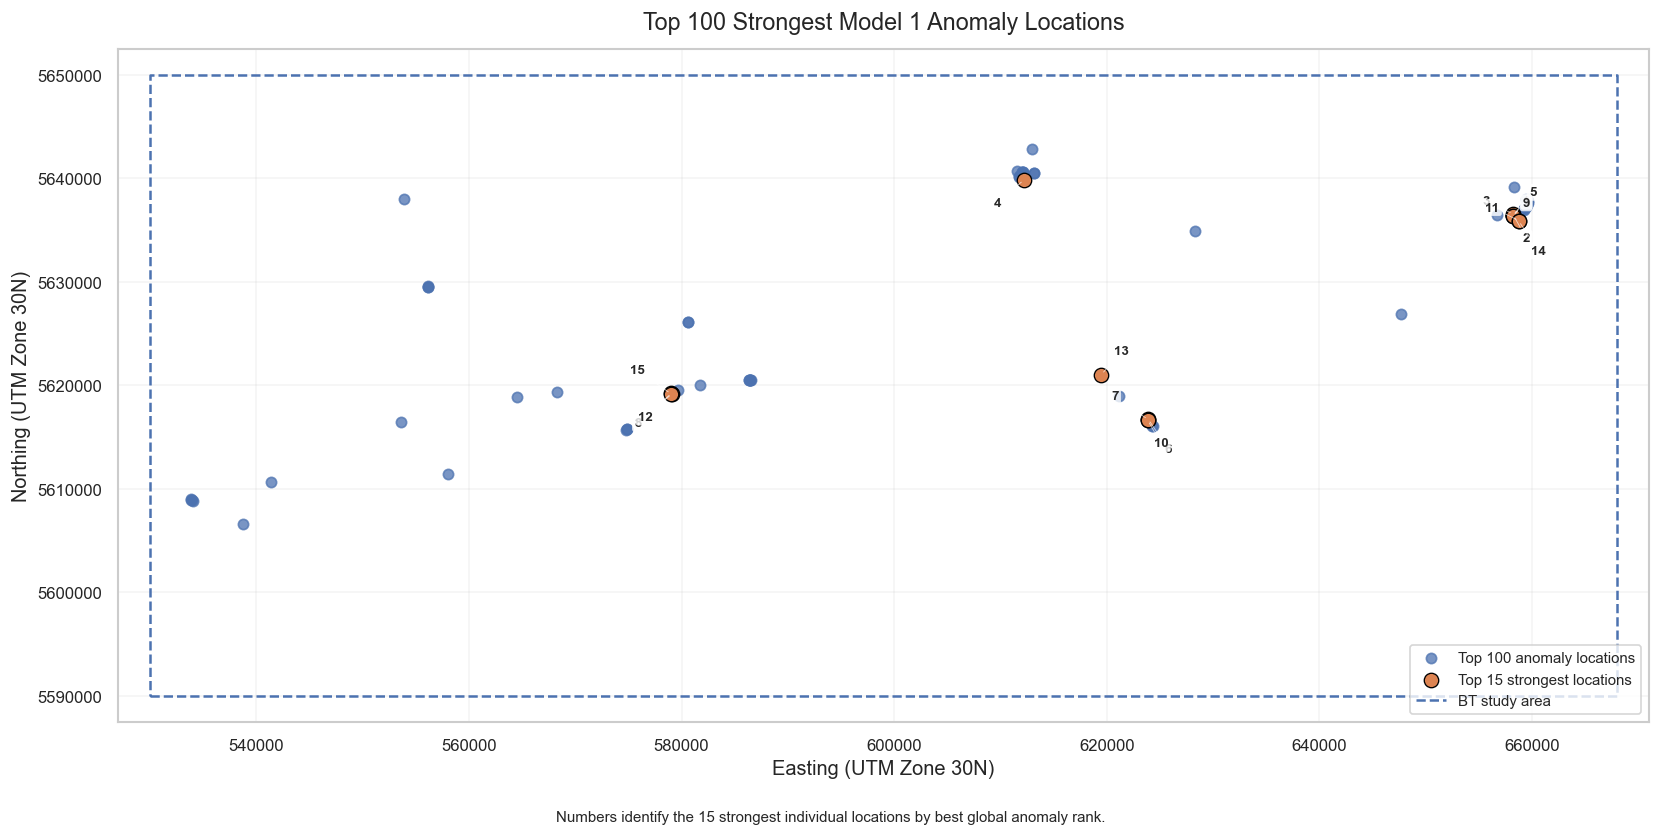

CELL 88 - PLOT THE STRONGEST ANOMALY LOCATIONS

Top 100 locations plotted: 100
Strongest locations labelled: 15

Strongest-location figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_strongest_anomaly_locations.png


In [89]:
# ================================================================
# CELL 88 - PLOT THE STRONGEST ANOMALY LOCATIONS
# ================================================================

PART_2_STRONGEST_LOCATIONS_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_strongest_anomaly_locations.png"
)


PART_2_STATIC_LABEL_COUNT = (
    15
)


# ------------------------------------------------
# Study-area bounds
# ------------------------------------------------

PART_2_STUDY_XMIN = 530000
PART_2_STUDY_YMIN = 5590000
PART_2_STUDY_XMAX = 668000
PART_2_STUDY_YMAX = 5650000


# ------------------------------------------------
# Create figure
# ------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        14,
        7
    )
)


# ------------------------------------------------
# Plot all Top 100 locations
# ------------------------------------------------

axis.scatter(
    part_2_top_100_strongest_locations[
        "xbin"
    ],
    part_2_top_100_strongest_locations[
        "ybin"
    ],
    s=38,
    alpha=0.75,
    label="Top 100 anomaly locations"
)


# ------------------------------------------------
# Highlight the Top 15
# ------------------------------------------------

top_labelled_locations = (
    part_2_top_100_strongest_locations
    .head(
        PART_2_STATIC_LABEL_COUNT
    )
    .copy()
)


axis.scatter(
    top_labelled_locations[
        "xbin"
    ],
    top_labelled_locations[
        "ybin"
    ],
    s=75,
    edgecolors="black",
    linewidths=0.8,
    label="Top 15 strongest locations"
)


# ------------------------------------------------
# Label Top 15 with alternating offsets
# ------------------------------------------------

label_offsets = [
    (8, 8),
    (8, -14),
    (-16, 8),
    (-16, -14),
    (12, 14),
    (12, -18),
    (-20, 14),
    (-20, -18)
]


for row_number, (_, location_row) in enumerate(
    top_labelled_locations.iterrows()
):

    offset_x, offset_y = label_offsets[
        row_number
        %
        len(
            label_offsets
        )
    ]


    axis.annotate(
        str(
            int(
                location_row[
                    "strongest_location_rank"
                ]
            )
        ),
        (
            location_row[
                "xbin"
            ],
            location_row[
                "ybin"
            ]
        ),
        xytext=(
            offset_x,
            offset_y
        ),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.8
        ),
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.5,
            alpha=0.7
        )
    )


# ------------------------------------------------
# Draw original BT study-area boundary
# ------------------------------------------------

study_area_x = [
    PART_2_STUDY_XMIN,
    PART_2_STUDY_XMAX,
    PART_2_STUDY_XMAX,
    PART_2_STUDY_XMIN,
    PART_2_STUDY_XMIN
]


study_area_y = [
    PART_2_STUDY_YMIN,
    PART_2_STUDY_YMIN,
    PART_2_STUDY_YMAX,
    PART_2_STUDY_YMAX,
    PART_2_STUDY_YMIN
]


axis.plot(
    study_area_x,
    study_area_y,
    linewidth=1.5,
    linestyle="--",
    label="BT study area"
)


# ------------------------------------------------
# Axis settings
# ------------------------------------------------

x_padding = 3000
y_padding = 2500


axis.set_xlim(
    PART_2_STUDY_XMIN
    -
    x_padding,
    PART_2_STUDY_XMAX
    +
    x_padding
)


axis.set_ylim(
    PART_2_STUDY_YMIN
    -
    y_padding,
    PART_2_STUDY_YMAX
    +
    y_padding
)


axis.set_title(
    "Top 100 Strongest Model 1 Anomaly Locations",
    fontsize=14,
    pad=12
)


axis.set_xlabel(
    "Easting (UTM Zone 30N)"
)


axis.set_ylabel(
    "Northing (UTM Zone 30N)"
)


axis.ticklabel_format(
    style="plain",
    axis="both"
)


axis.grid(
    alpha=0.20
)


axis.legend(
    loc="lower right",
    fontsize=9
)


# ------------------------------------------------
# Explanatory note
# ------------------------------------------------

figure.text(
    0.5,
    0.01,
    (
        "Numbers identify the 15 strongest individual locations "
        "by best global anomaly rank."
    ),
    ha="center",
    fontsize=9
)


figure.tight_layout(
    rect=[
        0,
        0.035,
        1,
        1
    ]
)


# ------------------------------------------------
# Save
# ------------------------------------------------

figure.savefig(
    PART_2_STRONGEST_LOCATIONS_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_STRONGEST_LOCATIONS_FIGURE.exists()


assert (
    PART_2_STRONGEST_LOCATIONS_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 88 - PLOT THE STRONGEST ANOMALY LOCATIONS")
print("=" * 80)


print(
    f"\nTop 100 locations plotted: "
    f"{len(part_2_top_100_strongest_locations):,}"
)


print(
    f"Strongest locations labelled: "
    f"{PART_2_STATIC_LABEL_COUNT:,}"
)


print(
    "\nStrongest-location figure saved:"
)


print(
    PART_2_STRONGEST_LOCATIONS_FIGURE
)

## What Cell 88 Does

This cell plots the 100 strongest individual anomaly locations across the study area.

The strongest 15 locations are labelled by their location ranking so that the figure remains readable.

The figure provides an initial view of whether the strongest anomalies are widely distributed or concentrated in particular parts of the study area.

In [90]:
# ================================================================
# CELL 89 - PREPARE LOCATIONS FOR HOTSPOT ANALYSIS
# ================================================================

PART_2_HOTSPOT_RANK_LIMIT = (
    10_000
)


part_2_hotspot_candidates = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            xbin,
            ybin,
            best_global_rank,
            maximum_anomaly_score,
            location_observations,
            top_100_count,
            top_1000_count,
            top_10000_count,
            top_1_percent_count,
            top_0_5_percent_count,
            top_1_percent_anomalous_days,
            strongest_anomaly_date,
            strongest_nearest_poi_distance,
            strongest_nearest_poi_type,
            strongest_nearest_poi_name,
            strongest_primary_reason

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            top_10000_count > 0

        ORDER BY
            best_global_rank
        """
    )
    .df()
)


hotspot_longitudes, hotspot_latitudes = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        part_2_hotspot_candidates[
            "xbin"
        ].to_numpy(),
        part_2_hotspot_candidates[
            "ybin"
        ].to_numpy()
    )
)


part_2_hotspot_candidates[
    "longitude"
] = hotspot_longitudes


part_2_hotspot_candidates[
    "latitude"
] = hotspot_latitudes


hotspot_candidate_summary = pd.DataFrame(
    {
        "Measure": [
            "Top-observation rank limit",
            "Candidate unique locations",
            "Top 10,000 observations represented",
            "Minimum candidate rank",
            "Maximum candidate rank",
            "Minimum Easting",
            "Maximum Easting",
            "Minimum Northing",
            "Maximum Northing"
        ],
        "Value": [
            PART_2_HOTSPOT_RANK_LIMIT,
            len(
                part_2_hotspot_candidates
            ),
            int(
                part_2_hotspot_candidates[
                    "top_10000_count"
                ].sum()
            ),
            int(
                part_2_hotspot_candidates[
                    "best_global_rank"
                ].min()
            ),
            int(
                part_2_hotspot_candidates[
                    "best_global_rank"
                ].max()
            ),
            float(
                part_2_hotspot_candidates[
                    "xbin"
                ].min()
            ),
            float(
                part_2_hotspot_candidates[
                    "xbin"
                ].max()
            ),
            float(
                part_2_hotspot_candidates[
                    "ybin"
                ].min()
            ),
            float(
                part_2_hotspot_candidates[
                    "ybin"
                ].max()
            )
        ]
    }
)


print("=" * 80)
print("CELL 89 - PREPARE LOCATIONS FOR HOTSPOT ANALYSIS")
print("=" * 80)


display(
    hotspot_candidate_summary
)


print(
    "\nFirst hotspot candidates:"
)


display(
    part_2_hotspot_candidates.head(
        20
    )
)


assert len(
    part_2_hotspot_candidates
) > 0


assert int(
    part_2_hotspot_candidates[
        "top_10000_count"
    ].sum()
) == MODEL_1_TOP_10000_ROWS


assert part_2_hotspot_candidates[
    [
        "xbin",
        "ybin"
    ]
].notna().all().all()


print(
    "\nThe strongest unique anomaly locations "
    "are ready for hotspot analysis."
)

CELL 89 - PREPARE LOCATIONS FOR HOTSPOT ANALYSIS


,Measure,Value
0,Top-observation rank limit,"10,000.000000"
1,Candidate unique locations,"1,297.000000"
2,"Top 10,000 observations represented","10,000.000000"
3,Minimum candidate rank,1.000000
4,Maximum candidate rank,"9,980.000000"
5,Minimum Easting,"531,100.000000"
6,Maximum Easting,"667,900.000000"
7,Minimum Northing,"5,596,000.000000"
8,Maximum Northing,"5,649,550.000000"



First hotspot candidates:


,location_id,xbin,ybin,best_global_rank,maximum_anomaly_score,location_observations,top_100_count,top_1000_count,top_10000_count,top_1_percent_count,top_0_5_percent_count,top_1_percent_anomalous_days,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason,longitude,latitude
0,658250_5636500,"658,250.000000","5,636,500.000000",1,0.906137,90,1.000000,3.000000,9,56,35.000000,56,2026-04-18,147.371892,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,-0.751464,50.858512
1,658250_5636450,"658,250.000000","5,636,450.000000",2,0.905628,90,2.000000,3.000000,10,78,54.000000,78,2026-04-18,175.363309,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,-0.751486,50.858063
2,658250_5636550,"658,250.000000","5,636,550.000000",3,0.905628,90,1.000000,3.000000,8,61,38.000000,61,2026-04-18,115.396605,bus_stops,Airfield,High outdoorminutesofuse,-0.751443,50.858961
3,612200_5639850,"612,200.000000","5,639,850.000000",4,0.900098,90,5.000000,64.000000,90,90,90.000000,90,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume,-1.404423,50.899396
4,658200_5636400,"658,200.000000","5,636,400.000000",5,0.899760,90,1.000000,2.000000,11,68,48.000000,68,2026-04-18,147.429327,restaurants,Goodwood Aero Club,High outdoorminutesofuse,-0.752218,50.857627
5,623900_5616750,"623,900.000000","5,616,750.000000",6,0.898973,90,2.000000,4.000000,7,76,55.000000,76,2026-07-04,179.417600,bus_stops,Downend,High totaldownlinkvolume,-1.245910,50.689368
6,623900_5616700,"623,900.000000","5,616,700.000000",7,0.897962,90,3.000000,6.000000,13,82,69.000000,82,2026-07-05,187.527065,bus_stops,Downend,High totaldownlinkvolume,-1.245927,50.688919
7,579050_5619250,"579,050.000000","5,619,250.000000",9,0.896785,90,17.000000,66.000000,88,90,90.000000,90,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume,-1.880164,50.719671
8,658200_5636350,"658,200.000000","5,636,350.000000",10,0.896392,90,1.000000,5.000000,11,71,58.000000,71,2026-04-18,152.569570,restaurants,Goodwood Aero Club,High outdoorminutesofuse,-0.752239,50.857178
9,623850_5616650,"623,850.000000","5,616,650.000000",13,0.895552,90,2.000000,6.000000,13,85,74.000000,85,2026-07-05,166.453216,bus_stops,Downend,High totaldownlinkvolume,-1.246651,50.688480



The strongest unique anomaly locations are ready for hotspot analysis.


## What Cell 89 Does

This cell prepares the unique locations represented within the Top 10,000 anomaly observations.

Each location appears only once in the hotspot dataset, preventing locations with many repeated anomaly observations from being duplicated during clustering.

The resulting location coordinates are suitable for DBSCAN because the UTM coordinates are measured directly in metres.

In [91]:
# ================================================================
# CELL 90 - TEST DBSCAN HOTSPOT SETTINGS
# ================================================================

from sklearn.cluster import DBSCAN


PART_2_DBSCAN_EPS_VALUES = [
    250,
    500,
    1000,
    2000
]


PART_2_DBSCAN_MIN_SAMPLES_VALUES = [
    3,
    5
]


hotspot_coordinate_matrix = (
    part_2_hotspot_candidates[
        [
            "xbin",
            "ybin"
        ]
    ]
    .to_numpy(
        dtype="float64"
    )
)


dbscan_setting_records = []


for eps_metres in (
    PART_2_DBSCAN_EPS_VALUES
):

    for minimum_samples in (
        PART_2_DBSCAN_MIN_SAMPLES_VALUES
    ):

        dbscan_test_model = DBSCAN(
            eps=eps_metres,
            min_samples=minimum_samples,
            metric="euclidean"
        )


        dbscan_test_labels = (
            dbscan_test_model.fit_predict(
                hotspot_coordinate_matrix
            )
        )


        clustered_mask = (
            dbscan_test_labels
            !=
            -1
        )


        cluster_labels = np.unique(
            dbscan_test_labels[
                clustered_mask
            ]
        )


        cluster_count = len(
            cluster_labels
        )


        clustered_locations = int(
            clustered_mask.sum()
        )


        noise_locations = int(
            (
                ~clustered_mask
            ).sum()
        )


        if cluster_count > 0:

            cluster_sizes = pd.Series(
                dbscan_test_labels[
                    clustered_mask
                ]
            ).value_counts()


            largest_cluster_size = int(
                cluster_sizes.max()
            )


        else:

            largest_cluster_size = 0


        clustered_share_percent = (
            clustered_locations
            /
            len(
                dbscan_test_labels
            )
            *
            100
        )


        largest_cluster_share_percent = (
            (
                largest_cluster_size
                /
                clustered_locations
                *
                100
            )
            if clustered_locations > 0
            else 0
        )


        dbscan_setting_records.append(
            {
                "Epsilon (m)": (
                    eps_metres
                ),
                "Minimum Samples": (
                    minimum_samples
                ),
                "Clusters": (
                    cluster_count
                ),
                "Clustered Locations": (
                    clustered_locations
                ),
                "Noise Locations": (
                    noise_locations
                ),
                "Clustered Share (%)": (
                    clustered_share_percent
                ),
                "Largest Cluster Locations": (
                    largest_cluster_size
                ),
                "Largest Cluster Share (%)": (
                    largest_cluster_share_percent
                )
            }
        )


part_2_dbscan_setting_comparison = pd.DataFrame(
    dbscan_setting_records
)


# ------------------------------------------------
# Select a balanced configuration
# ------------------------------------------------

eligible_dbscan_settings = (
    part_2_dbscan_setting_comparison.loc[
        (
            part_2_dbscan_setting_comparison[
                "Clusters"
            ]
            >=
            2
        )
        &
        (
            part_2_dbscan_setting_comparison[
                "Clustered Share (%)"
            ]
            >=
            20
        )
        &
        (
            part_2_dbscan_setting_comparison[
                "Clustered Share (%)"
            ]
            <=
            90
        )
        &
        (
            part_2_dbscan_setting_comparison[
                "Largest Cluster Share (%)"
            ]
            <=
            50
        )
    ]
    .copy()
)


if len(
    eligible_dbscan_settings
) > 0:

    eligible_dbscan_settings[
        "Balance Distance"
    ] = (
        eligible_dbscan_settings[
            "Clustered Share (%)"
        ]
        -
        60
    ).abs()


    selected_dbscan_row = (
        eligible_dbscan_settings
        .sort_values(
            [
                "Balance Distance",
                "Epsilon (m)",
                "Minimum Samples"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
        .iloc[0]
    )


    PART_2_DBSCAN_SELECTION_METHOD = (
        "Balanced eligible configuration"
    )


else:

    fallback_dbscan_settings = (
        part_2_dbscan_setting_comparison.loc[
            part_2_dbscan_setting_comparison[
                "Clusters"
            ]
            >=
            2
        ]
        .copy()
    )


    if len(
        fallback_dbscan_settings
    ) == 0:

        raise RuntimeError(
            "None of the tested DBSCAN settings "
            "produced at least two clusters."
        )


    fallback_dbscan_settings[
        "Balance Distance"
    ] = (
        fallback_dbscan_settings[
            "Clustered Share (%)"
        ]
        -
        60
    ).abs()


    selected_dbscan_row = (
        fallback_dbscan_settings
        .sort_values(
            [
                "Balance Distance",
                "Largest Cluster Share (%)",
                "Epsilon (m)"
            ]
        )
        .iloc[0]
    )


    PART_2_DBSCAN_SELECTION_METHOD = (
        "Fallback balanced configuration"
    )


PART_2_DBSCAN_FINAL_EPS_METRES = int(
    selected_dbscan_row[
        "Epsilon (m)"
    ]
)


PART_2_DBSCAN_FINAL_MIN_SAMPLES = int(
    selected_dbscan_row[
        "Minimum Samples"
    ]
)


print("=" * 80)
print("CELL 90 - TEST DBSCAN HOTSPOT SETTINGS")
print("=" * 80)


display(
    part_2_dbscan_setting_comparison
)


print(
    "\nSelected DBSCAN configuration:"
)


selected_dbscan_summary = pd.DataFrame(
    {
        "Setting": [
            "Selection method",
            "Epsilon (m)",
            "Minimum samples",
            "Clusters",
            "Clustered locations",
            "Noise locations",
            "Clustered share (%)",
            "Largest cluster share (%)"
        ],
        "Value": [
            PART_2_DBSCAN_SELECTION_METHOD,
            PART_2_DBSCAN_FINAL_EPS_METRES,
            PART_2_DBSCAN_FINAL_MIN_SAMPLES,
            int(
                selected_dbscan_row[
                    "Clusters"
                ]
            ),
            int(
                selected_dbscan_row[
                    "Clustered Locations"
                ]
            ),
            int(
                selected_dbscan_row[
                    "Noise Locations"
                ]
            ),
            float(
                selected_dbscan_row[
                    "Clustered Share (%)"
                ]
            ),
            float(
                selected_dbscan_row[
                    "Largest Cluster Share (%)"
                ]
            )
        ]
    }
)


display(
    selected_dbscan_summary
)


assert PART_2_DBSCAN_FINAL_EPS_METRES > 0


assert PART_2_DBSCAN_FINAL_MIN_SAMPLES >= 2


print(
    "\nThe candidate DBSCAN settings were "
    "compared successfully."
)

CELL 90 - TEST DBSCAN HOTSPOT SETTINGS


,Epsilon (m),Minimum Samples,Clusters,Clustered Locations,Noise Locations,Clustered Share (%),Largest Cluster Locations,Largest Cluster Share (%)
0,250,3,81,1111,186,85.659214,157,14.131413
1,250,5,55,1009,288,77.794911,157,15.559960
2,500,3,71,1168,129,90.053971,203,17.380137
3,500,5,49,1091,206,84.117194,203,18.606783
4,1000,3,60,1214,83,93.600617,209,17.215815
5,1000,5,39,1142,155,88.049345,209,18.301226
6,2000,3,44,1251,46,96.453354,260,20.783373
7,2000,5,32,1203,94,92.752506,260,21.612635



Selected DBSCAN configuration:


,Setting,Value
0,Selection method,Balanced eligible configuration
1,Epsilon (m),250
2,Minimum samples,5
3,Clusters,55
4,Clustered locations,1009
5,Noise locations,288
6,Clustered share (%),77.794911
7,Largest cluster share (%),15.559960



The candidate DBSCAN settings were compared successfully.


## What Cell 90 Does

This cell tests several DBSCAN settings before the final hotspot analysis is created.

The distance parameter is measured in metres because the BT coordinates use UTM Zone 30N.

The comparison shows how each setting changes the number of clusters, the proportion of locations assigned to a cluster and the amount of isolated noise.

A balanced configuration is selected automatically from the tested settings. This is a practical hotspot definition rather than a new anomaly-detection model.

In [92]:
# ================================================================
# CELL 91 - IDENTIFY THE GEOGRAPHIC ANOMALY HOTSPOTS
# ================================================================

PART_2_DBSCAN_MODEL = DBSCAN(
    eps=PART_2_DBSCAN_FINAL_EPS_METRES,
    min_samples=PART_2_DBSCAN_FINAL_MIN_SAMPLES,
    metric="euclidean"
)


PART_2_DBSCAN_LABELS = (
    PART_2_DBSCAN_MODEL.fit_predict(
        hotspot_coordinate_matrix
    )
)


part_2_hotspot_candidates[
    "dbscan_cluster"
] = PART_2_DBSCAN_LABELS


part_2_hotspot_candidates[
    "hotspot_status"
] = np.where(
    part_2_hotspot_candidates[
        "dbscan_cluster"
    ]
    ==
    -1,
    "Isolated",
    "Clustered"
)


part_2_hotspot_candidates[
    "hotspot_id"
] = np.where(
    part_2_hotspot_candidates[
        "dbscan_cluster"
    ]
    ==
    -1,
    "Isolated",
    (
        "Hotspot "
        +
        (
            part_2_hotspot_candidates[
                "dbscan_cluster"
            ]
            +
            1
        )
        .astype(
            str
        )
    )
)


PART_2_DBSCAN_CLUSTER_COUNT = int(
    part_2_hotspot_candidates.loc[
        part_2_hotspot_candidates[
            "dbscan_cluster"
        ]
        >=
        0,
        "dbscan_cluster"
    ]
    .nunique()
)


PART_2_DBSCAN_CLUSTERED_LOCATIONS = int(
    (
        part_2_hotspot_candidates[
            "dbscan_cluster"
        ]
        >=
        0
    ).sum()
)


PART_2_DBSCAN_ISOLATED_LOCATIONS = int(
    (
        part_2_hotspot_candidates[
            "dbscan_cluster"
        ]
        ==
        -1
    ).sum()
)


dbscan_final_summary = pd.DataFrame(
    {
        "Measure": [
            "Candidate locations",
            "DBSCAN distance (m)",
            "Minimum neighbouring locations",
            "Hotspots identified",
            "Clustered locations",
            "Isolated locations",
            "Clustered share (%)"
        ],
        "Value": [
            len(
                part_2_hotspot_candidates
            ),
            PART_2_DBSCAN_FINAL_EPS_METRES,
            PART_2_DBSCAN_FINAL_MIN_SAMPLES,
            PART_2_DBSCAN_CLUSTER_COUNT,
            PART_2_DBSCAN_CLUSTERED_LOCATIONS,
            PART_2_DBSCAN_ISOLATED_LOCATIONS,
            (
                PART_2_DBSCAN_CLUSTERED_LOCATIONS
                /
                len(
                    part_2_hotspot_candidates
                )
                *
                100
            )
        ]
    }
)


print("=" * 80)
print("CELL 91 - IDENTIFY THE GEOGRAPHIC ANOMALY HOTSPOTS")
print("=" * 80)


display(
    dbscan_final_summary
)


print(
    "\nFirst clustered locations:"
)


display(
    part_2_hotspot_candidates.loc[
        part_2_hotspot_candidates[
            "dbscan_cluster"
        ]
        >=
        0
    ]
    .head(
        20
    )
)


assert len(
    PART_2_DBSCAN_LABELS
) == len(
    part_2_hotspot_candidates
)


assert (
    PART_2_DBSCAN_CLUSTERED_LOCATIONS
    +
    PART_2_DBSCAN_ISOLATED_LOCATIONS
) == len(
    part_2_hotspot_candidates
)


assert PART_2_DBSCAN_CLUSTER_COUNT >= 1


print(
    "\nThe geographic anomaly hotspots were "
    "identified successfully."
)

CELL 91 - IDENTIFY THE GEOGRAPHIC ANOMALY HOTSPOTS


,Measure,Value
0,Candidate locations,"1,297.000000"
1,DBSCAN distance (m),250.000000
2,Minimum neighbouring locations,5.000000
3,Hotspots identified,55.000000
4,Clustered locations,"1,009.000000"
5,Isolated locations,288.000000
6,Clustered share (%),77.794911



First clustered locations:


,location_id,xbin,ybin,best_global_rank,maximum_anomaly_score,location_observations,top_100_count,top_1000_count,top_10000_count,top_1_percent_count,top_0_5_percent_count,top_1_percent_anomalous_days,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason,longitude,latitude,dbscan_cluster,hotspot_status,hotspot_id
0,658250_5636500,"658,250.000000","5,636,500.000000",1,0.906137,90,1.000000,3.000000,9,56,35.000000,56,2026-04-18,147.371892,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,-0.751464,50.858512,0,Clustered,Hotspot 1
1,658250_5636450,"658,250.000000","5,636,450.000000",2,0.905628,90,2.000000,3.000000,10,78,54.000000,78,2026-04-18,175.363309,attractions,Goodwood Motor Circuit,High outdoorminutesofuse,-0.751486,50.858063,0,Clustered,Hotspot 1
2,658250_5636550,"658,250.000000","5,636,550.000000",3,0.905628,90,1.000000,3.000000,8,61,38.000000,61,2026-04-18,115.396605,bus_stops,Airfield,High outdoorminutesofuse,-0.751443,50.858961,0,Clustered,Hotspot 1
3,612200_5639850,"612,200.000000","5,639,850.000000",4,0.900098,90,5.000000,64.000000,90,90,90.000000,90,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume,-1.404423,50.899396,1,Clustered,Hotspot 2
4,658200_5636400,"658,200.000000","5,636,400.000000",5,0.899760,90,1.000000,2.000000,11,68,48.000000,68,2026-04-18,147.429327,restaurants,Goodwood Aero Club,High outdoorminutesofuse,-0.752218,50.857627,0,Clustered,Hotspot 1
5,623900_5616750,"623,900.000000","5,616,750.000000",6,0.898973,90,2.000000,4.000000,7,76,55.000000,76,2026-07-04,179.417600,bus_stops,Downend,High totaldownlinkvolume,-1.245910,50.689368,2,Clustered,Hotspot 3
6,623900_5616700,"623,900.000000","5,616,700.000000",7,0.897962,90,3.000000,6.000000,13,82,69.000000,82,2026-07-05,187.527065,bus_stops,Downend,High totaldownlinkvolume,-1.245927,50.688919,2,Clustered,Hotspot 3
7,579050_5619250,"579,050.000000","5,619,250.000000",9,0.896785,90,17.000000,66.000000,88,90,90.000000,90,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume,-1.880164,50.719671,3,Clustered,Hotspot 4
8,658200_5636350,"658,200.000000","5,636,350.000000",10,0.896392,90,1.000000,5.000000,11,71,58.000000,71,2026-04-18,152.569570,restaurants,Goodwood Aero Club,High outdoorminutesofuse,-0.752239,50.857178,0,Clustered,Hotspot 1
9,623850_5616650,"623,850.000000","5,616,650.000000",13,0.895552,90,2.000000,6.000000,13,85,74.000000,85,2026-07-05,166.453216,bus_stops,Downend,High totaldownlinkvolume,-1.246651,50.688480,2,Clustered,Hotspot 3



The geographic anomaly hotspots were identified successfully.


## What Cell 91 Does

This cell applies the selected DBSCAN configuration to the strong anomaly locations.

Locations with enough nearby strong anomaly locations are assigned to a geographic hotspot. Locations that do not meet the clustering requirement remain classified as isolated.

DBSCAN is used only to interpret the geography of the Isolation Forest results. The Isolation Forest remains the anomaly-detection model.

In [93]:
# ================================================================
# CELL 92 - SUMMARISE AND RANK THE ANOMALY HOTSPOTS
# ================================================================

clustered_hotspot_locations = (
    part_2_hotspot_candidates.loc[
        part_2_hotspot_candidates[
            "dbscan_cluster"
        ]
        >=
        0
    ]
    .copy()
)


hotspot_summary_records = []


for cluster_number, cluster_data in (
    clustered_hotspot_locations.groupby(
        "dbscan_cluster"
    )
):

    centre_x = float(
        cluster_data[
            "xbin"
        ].mean()
    )


    centre_y = float(
        cluster_data[
            "ybin"
        ].mean()
    )


    cluster_distances = np.sqrt(
        (
            cluster_data[
                "xbin"
            ]
            -
            centre_x
        )
        **
        2
        +
        (
            cluster_data[
                "ybin"
            ]
            -
            centre_y
        )
        **
        2
    )


    hotspot_radius_metres = float(
        cluster_distances.max()
    )


    hotspot_longitude, hotspot_latitude = (
        PART_2_COORDINATE_TRANSFORMER.transform(
            centre_x,
            centre_y
        )
    )


    poi_type_mode = (
        cluster_data[
            "strongest_nearest_poi_type"
        ]
        .dropna()
        .mode()
    )


    poi_name_mode = (
        cluster_data[
            "strongest_nearest_poi_name"
        ]
        .dropna()
        .mode()
    )


    hotspot_summary_records.append(
        {
            "dbscan_cluster": int(
                cluster_number
            ),
            "hotspot_id": (
                f"Hotspot "
                f"{int(cluster_number) + 1}"
            ),
            "locations": len(
                cluster_data
            ),
            "top_100_observations": int(
                cluster_data[
                    "top_100_count"
                ].sum()
            ),
            "top_1000_observations": int(
                cluster_data[
                    "top_1000_count"
                ].sum()
            ),
            "top_10000_observations": int(
                cluster_data[
                    "top_10000_count"
                ].sum()
            ),
            "top_1_percent_observations": int(
                cluster_data[
                    "top_1_percent_count"
                ].sum()
            ),
            "top_0_5_percent_observations": int(
                cluster_data[
                    "top_0_5_percent_count"
                ].sum()
            ),
            "strongest_global_rank": int(
                cluster_data[
                    "best_global_rank"
                ].min()
            ),
            "maximum_anomaly_score": float(
                cluster_data[
                    "maximum_anomaly_score"
                ].max()
            ),
            "maximum_anomalous_days": int(
                cluster_data[
                    "top_1_percent_anomalous_days"
                ].max()
            ),
            "centre_x": (
                centre_x
            ),
            "centre_y": (
                centre_y
            ),
            "longitude": float(
                hotspot_longitude
            ),
            "latitude": float(
                hotspot_latitude
            ),
            "approximate_radius_metres": (
                hotspot_radius_metres
            ),
            "common_nearest_poi_type": (
                poi_type_mode.iloc[0]
                if len(
                    poi_type_mode
                ) > 0
                else None
            ),
            "common_nearest_poi_name": (
                poi_name_mode.iloc[0]
                if len(
                    poi_name_mode
                ) > 0
                else None
            )
        }
    )


part_2_hotspot_summary = pd.DataFrame(
    hotspot_summary_records
)


part_2_hotspot_summary = (
    part_2_hotspot_summary
    .sort_values(
        [
            "strongest_global_rank",
            "top_10000_observations",
            "locations"
        ],
        ascending=[
            True,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


part_2_hotspot_summary.insert(
    0,
    "hotspot_rank",
    np.arange(
        1,
        len(
            part_2_hotspot_summary
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 92 - SUMMARISE AND RANK THE ANOMALY HOTSPOTS")
print("=" * 80)


print(
    f"\nHotspots identified: "
    f"{len(part_2_hotspot_summary):,}"
)


print(
    "\nTop 20 anomaly hotspots:"
)


display(
    part_2_hotspot_summary.head(
        20
    )
)


assert len(
    part_2_hotspot_summary
) == PART_2_DBSCAN_CLUSTER_COUNT


assert (
    part_2_hotspot_summary[
        "locations"
    ]
    >=
    PART_2_DBSCAN_FINAL_MIN_SAMPLES
).all()


assert int(
    part_2_hotspot_summary[
        "strongest_global_rank"
    ].min()
) >= 1


print(
    "\nThe geographic anomaly hotspots were "
    "summarised successfully."
)

CELL 92 - SUMMARISE AND RANK THE ANOMALY HOTSPOTS

Hotspots identified: 55

Top 20 anomaly hotspots:


,hotspot_rank,dbscan_cluster,hotspot_id,locations,top_100_observations,top_1000_observations,top_10000_observations,top_1_percent_observations,top_0_5_percent_observations,strongest_global_rank,maximum_anomaly_score,maximum_anomalous_days,centre_x,centre_y,longitude,latitude,approximate_radius_metres,common_nearest_poi_type,common_nearest_poi_name
0,1,0,Hotspot 1,45,8,25,144,1178,716,1,0.906137,78,"658,296.666667","5,637,166.666667",-0.750514,50.864490,"1,187.836502",bus_stops,Offices
1,2,1,Hotspot 2,157,7,260,2569,13905,13384,4,0.900098,90,"612,102.547771","5,640,367.515924",-1.405649,50.904067,"1,284.006687",bus_stops,Chunky Chips
2,3,2,Hotspot 3,12,9,22,62,613,416,6,0.898973,85,"623,895.833333","5,616,691.666667",-1.245989,50.688845,259.974625,bus_stops,Downend
3,4,3,Hotspot 4,108,24,189,1435,8812,8434,9,0.896785,90,"579,292.129630","5,619,208.333333",-1.876744,50.719263,"1,146.367814",hotels,Salt & Lemon
4,5,4,Hotspot 5,15,43,316,743,1285,1247,14,0.894937,90,"658,790.000000","5,635,876.666667",-0.744068,50.852763,141.931126,parks,Parks
5,6,5,Hotspot 6,10,2,6,32,324,173,19,0.892814,85,"619,520.000000","5,621,050.000000",-1.306498,50.728937,250.798724,bus_stops,Crockers Farm School Stop
6,7,6,Hotspot 7,68,2,38,131,796,562,30,0.889416,88,"659,527.941176","5,637,679.411765",-0.732807,50.868759,882.359069,bus_stops,Goodwood Park Hotel
7,8,7,Hotspot 8,11,2,6,52,653,511,31,0.888972,75,"574,831.818182","5,615,686.363636",-1.940631,50.688187,271.892662,bus_stops,St Nicolas Chapel
8,9,8,Hotspot 9,24,1,18,142,1682,1430,42,0.886364,89,"586,370.833333","5,620,700.000000",-1.776140,50.731666,389.466337,parks,Parks
9,10,9,Hotspot 10,13,2,3,38,513,276,61,0.883323,77,"553,338.461538","5,616,615.384615",-2.244737,50.698909,390.000759,schools,Bovington Academy



The geographic anomaly hotspots were summarised successfully.


## What Cell 92 Does

This cell summarises every DBSCAN hotspot.

For each hotspot it reports the number of strong anomaly locations, anomaly counts, strongest global rank, anomaly score, geographic centre, approximate size and common nearby POI information.

The table allows broader anomalous areas to be compared rather than considering every BT grid location independently.

In [94]:
# ================================================================
# CELL 93 - CREATE THE STRONGEST-ANOMALY AND HOTSPOT MAP
# ================================================================

PART_2_STRONGEST_HOTSPOT_MAP_FILE = (
    PART_2_MAPS_FOLDER
    /
    "model_1_strongest_anomaly_hotspots.html"
)


# ------------------------------------------------
# BT study-area coordinates
# ------------------------------------------------

PART_2_STUDY_XMIN = 530000
PART_2_STUDY_YMIN = 5590000

PART_2_STUDY_XMAX = 668000
PART_2_STUDY_YMAX = 5650000


# ------------------------------------------------
# 5 km buffered study-area coordinates
# ------------------------------------------------

PART_2_BUFFER_DISTANCE_METRES = 5000


PART_2_BUFFER_XMIN = (
    PART_2_STUDY_XMIN
    -
    PART_2_BUFFER_DISTANCE_METRES
)


PART_2_BUFFER_YMIN = (
    PART_2_STUDY_YMIN
    -
    PART_2_BUFFER_DISTANCE_METRES
)


PART_2_BUFFER_XMAX = (
    PART_2_STUDY_XMAX
    +
    PART_2_BUFFER_DISTANCE_METRES
)


PART_2_BUFFER_YMAX = (
    PART_2_STUDY_YMAX
    +
    PART_2_BUFFER_DISTANCE_METRES
)


# ------------------------------------------------
# Convert study-area corners to latitude/longitude
# ------------------------------------------------

study_west_longitude, study_south_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        PART_2_STUDY_XMIN,
        PART_2_STUDY_YMIN
    )
)


study_east_longitude, study_north_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        PART_2_STUDY_XMAX,
        PART_2_STUDY_YMAX
    )
)


buffer_west_longitude, buffer_south_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        PART_2_BUFFER_XMIN,
        PART_2_BUFFER_YMIN
    )
)


buffer_east_longitude, buffer_north_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        PART_2_BUFFER_XMAX,
        PART_2_BUFFER_YMAX
    )
)


study_area_bounds = [
    [
        study_south_latitude,
        study_west_longitude
    ],
    [
        study_north_latitude,
        study_east_longitude
    ]
]


buffer_area_bounds = [
    [
        buffer_south_latitude,
        buffer_west_longitude
    ],
    [
        buffer_north_latitude,
        buffer_east_longitude
    ]
]


# ------------------------------------------------
# Create map
# ------------------------------------------------

map_centre_latitude = (
    study_south_latitude
    +
    study_north_latitude
) / 2


map_centre_longitude = (
    study_west_longitude
    +
    study_east_longitude
) / 2


part_2_strongest_hotspot_map = folium.Map(
    location=[
        map_centre_latitude,
        map_centre_longitude
    ],
    zoom_start=9,
    control_scale=True
)


# ------------------------------------------------
# 5 km buffer layer
# ------------------------------------------------

buffer_layer = folium.FeatureGroup(
    name="5 km POI buffer"
)


folium.Rectangle(
    bounds=buffer_area_bounds,
    tooltip="5 km buffered POI area",
    popup=(
        "5 km buffer around the original "
        "BT study area"
    ),
    color="orange",
    weight=2,
    fill=False,
    dash_array="8, 6"
).add_to(
    buffer_layer
)


buffer_layer.add_to(
    part_2_strongest_hotspot_map
)


# ------------------------------------------------
# Original BT study-area layer
# ------------------------------------------------

study_area_layer = folium.FeatureGroup(
    name="Original BT study area"
)


folium.Rectangle(
    bounds=study_area_bounds,
    tooltip="Original BT study area",
    popup=(
        "Original BT study area: "
        "530000–668000 Easting, "
        "5590000–5650000 Northing"
    ),
    color="red",
    weight=3,
    fill=False
).add_to(
    study_area_layer
)


study_area_layer.add_to(
    part_2_strongest_hotspot_map
)


# ------------------------------------------------
# Hotspot layer
# ------------------------------------------------

hotspot_layer = folium.FeatureGroup(
    name="DBSCAN anomaly hotspots"
)


for _, hotspot_row in (
    part_2_hotspot_summary.iterrows()
):

    circle_radius = max(
        200.0,
        float(
            hotspot_row[
                "approximate_radius_metres"
            ]
        )
    )


    hotspot_popup = (
        f"<b>{hotspot_row['hotspot_id']}</b><br>"
        f"Hotspot rank: "
        f"{int(hotspot_row['hotspot_rank'])}<br>"
        f"Strong locations: "
        f"{int(hotspot_row['locations']):,}<br>"
        f"Strongest global rank: "
        f"{int(hotspot_row['strongest_global_rank']):,}<br>"
        f"Top 10,000 observations: "
        f"{int(hotspot_row['top_10000_observations']):,}<br>"
        f"Top 1% observations: "
        f"{int(hotspot_row['top_1_percent_observations']):,}<br>"
        f"Approximate radius: "
        f"{hotspot_row['approximate_radius_metres']:,.0f} m<br>"
        f"Common nearest POI type: "
        f"{hotspot_row['common_nearest_poi_type']}<br>"
        f"Common nearest POI name: "
        f"{hotspot_row['common_nearest_poi_name']}"
    )


    folium.Circle(
        location=[
            float(
                hotspot_row[
                    "latitude"
                ]
            ),
            float(
                hotspot_row[
                    "longitude"
                ]
            )
        ],
        radius=circle_radius,
        tooltip=(
            f"{hotspot_row['hotspot_id']} | "
            f"rank "
            f"{int(hotspot_row['hotspot_rank'])}"
        ),
        popup=folium.Popup(
            hotspot_popup,
            max_width=400
        )
    ).add_to(
        hotspot_layer
    )


hotspot_layer.add_to(
    part_2_strongest_hotspot_map
)


# ------------------------------------------------
# Top 100 individual-location layer
# ------------------------------------------------

strongest_location_layer = folium.FeatureGroup(
    name="Top 100 strongest locations"
)


for _, location_row in (
    part_2_top_100_strongest_locations.iterrows()
):

    poi_name = (
        location_row[
            "strongest_nearest_poi_name"
        ]
    )


    if pd.isna(
        poi_name
    ):

        poi_name = (
            "No named nearest POI"
        )


    location_popup = (
        f"<b>Location "
        f"{location_row['location_id']}</b><br>"
        f"Location rank: "
        f"{int(location_row['strongest_location_rank'])}<br>"
        f"Global anomaly rank: "
        f"{int(location_row['best_global_rank']):,}<br>"
        f"Anomaly score: "
        f"{location_row['maximum_anomaly_score']:.6f}<br>"
        f"Date: "
        f"{location_row['strongest_anomaly_date']}<br>"
        f"Top 1% observations: "
        f"{int(location_row['top_1_percent_count']):,}<br>"
        f"Anomalous days: "
        f"{int(location_row['top_1_percent_anomalous_days']):,}<br>"
        f"Nearest POI type: "
        f"{location_row['strongest_nearest_poi_type']}<br>"
        f"Nearest POI name: "
        f"{poi_name}<br>"
        f"Nearest POI distance: "
        f"{location_row['strongest_nearest_poi_distance']:,.1f} m<br>"
        f"Primary explanation: "
        f"{location_row['strongest_primary_reason']}"
    )


    folium.CircleMarker(
        location=[
            float(
                location_row[
                    "latitude"
                ]
            ),
            float(
                location_row[
                    "longitude"
                ]
            )
        ],
        radius=5,
        tooltip=(
            f"Global rank "
            f"{int(location_row['best_global_rank']):,}"
        ),
        popup=folium.Popup(
            location_popup,
            max_width=450
        ),
        fill=True
    ).add_to(
        strongest_location_layer
    )


strongest_location_layer.add_to(
    part_2_strongest_hotspot_map
)


# ------------------------------------------------
# Layer controls and map extent
# ------------------------------------------------

folium.LayerControl(
    collapsed=False
).add_to(
    part_2_strongest_hotspot_map
)


part_2_strongest_hotspot_map.fit_bounds(
    buffer_area_bounds
)


# ------------------------------------------------
# Save map
# ------------------------------------------------

part_2_strongest_hotspot_map.save(
    str(
        PART_2_STRONGEST_HOTSPOT_MAP_FILE
    )
)


assert PART_2_STRONGEST_HOTSPOT_MAP_FILE.exists()


assert (
    PART_2_STRONGEST_HOTSPOT_MAP_FILE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 93 - CREATE THE STRONGEST-ANOMALY AND HOTSPOT MAP")
print("=" * 80)


print(
    f"\nTop 100 locations mapped: "
    f"{len(part_2_top_100_strongest_locations):,}"
)


print(
    f"DBSCAN hotspots mapped: "
    f"{len(part_2_hotspot_summary):,}"
)


print(
    "\nOriginal study area:"
)


print(
    f"{PART_2_STUDY_XMIN}, "
    f"{PART_2_STUDY_YMIN} "
    f"to "
    f"{PART_2_STUDY_XMAX}, "
    f"{PART_2_STUDY_YMAX}"
)


print(
    "\n5 km buffered area:"
)


print(
    f"{PART_2_BUFFER_XMIN}, "
    f"{PART_2_BUFFER_YMIN} "
    f"to "
    f"{PART_2_BUFFER_XMAX}, "
    f"{PART_2_BUFFER_YMAX}"
)


print(
    "\nInteractive map saved:"
)


print(
    PART_2_STRONGEST_HOTSPOT_MAP_FILE
)


display(
    part_2_strongest_hotspot_map
)

CELL 93 - CREATE THE STRONGEST-ANOMALY AND HOTSPOT MAP

Top 100 locations mapped: 100
DBSCAN hotspots mapped: 55

Original study area:
530000, 5590000 to 668000, 5650000

5 km buffered area:
525000, 5585000 to 673000, 5655000

Interactive map saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\maps\model_1_strongest_anomaly_hotspots.html


## What Cell 93 Does

This cell creates an interactive map combining the strongest individual anomaly locations with the DBSCAN geographic hotspots.

The location popups show the global anomaly rank, anomaly score, date, recurrence, nearest POI and primary explanation.

The hotspot layer provides a broader view of areas containing multiple neighbouring strong anomaly locations.

## Key Findings — Question 2

The strongest Model 1 anomalies are concentrated across a relatively small subset of BT locations.

The strongest anomaly groups contain repeated observations from some locations, while the geographic pattern becomes more widely distributed as larger anomaly groups are considered.

DBSCAN identifies groups of neighbouring strong anomaly locations as geographic hotspots while retaining geographically isolated strong locations separately.

The current numbers of unique locations, identified hotspots, clustered locations and isolated locations are reported directly by the tables and maps above.

The results therefore distinguish individual extreme locations from wider geographic areas containing several neighbouring anomalous BT grid locations.

# Question 3 — Which locations generate anomalies most often?

The strongest anomaly rank identifies the most extreme individual observations, but it does not show whether a location repeatedly becomes anomalous.

This section compares anomaly frequency, anomaly rate and recurrence across BT locations.

The analysis identifies locations that generate many Top 1% anomalies, locations with unusually high anomaly rates, and locations that become anomalous across many different dates.

In [95]:
# ================================================================
# CELL 94 - CALCULATE ANOMALY FREQUENCY AND RATE
# ================================================================

PART_2_CONNECTION.execute(
    f"""
    ALTER TABLE {PART_2_LOCATION_SUMMARY_TABLE}

    ADD COLUMN IF NOT EXISTS
        top_1_percent_rate DOUBLE
    """
)


PART_2_CONNECTION.execute(
    f"""
    ALTER TABLE {PART_2_LOCATION_SUMMARY_TABLE}

    ADD COLUMN IF NOT EXISTS
        top_0_5_percent_rate DOUBLE
    """
)


PART_2_CONNECTION.execute(
    f"""
    UPDATE {PART_2_LOCATION_SUMMARY_TABLE}

    SET
        top_1_percent_rate =
            CASE
                WHEN location_observations > 0
                THEN
                    (
                        top_1_percent_count
                        /
                        CAST(
                            location_observations
                            AS DOUBLE
                        )
                    )
                    *
                    100.0
                ELSE NULL
            END,

        top_0_5_percent_rate =
            CASE
                WHEN location_observations > 0
                THEN
                    (
                        top_0_5_percent_count
                        /
                        CAST(
                            location_observations
                            AS DOUBLE
                        )
                    )
                    *
                    100.0
                ELSE NULL
            END
    """
)


part_2_location_frequency_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            COUNT(*) AS locations,

            COUNT_IF(
                top_1_percent_count > 0
            ) AS locations_with_top_1_percent_anomaly,

            COUNT_IF(
                top_0_5_percent_count > 0
            ) AS locations_with_top_0_5_percent_anomaly,

            MAX(
                top_1_percent_count
            ) AS maximum_top_1_percent_count,

            MAX(
                top_0_5_percent_count
            ) AS maximum_top_0_5_percent_count,

            MAX(
                top_1_percent_anomalous_days
            ) AS maximum_anomalous_days,

            MAX(
                top_1_percent_rate
            ) AS maximum_top_1_percent_rate,

            MEDIAN(
                CASE
                    WHEN top_1_percent_count > 0
                    THEN top_1_percent_rate
                END
            ) AS median_rate_among_anomalous_locations

        FROM {PART_2_LOCATION_SUMMARY_TABLE}
        """
    )
    .df()
)


print("=" * 80)
print("CELL 94 - CALCULATE ANOMALY FREQUENCY AND RATE")
print("=" * 80)


display(
    part_2_location_frequency_summary
)


assert int(
    part_2_location_frequency_summary.loc[
        0,
        "locations"
    ]
) == int(
    part_2_field_summary.loc[
        0,
        "unique_location_ids"
    ]
)


assert (
    PART_2_CONNECTION.execute(
        f"""
        SELECT COUNT(*)

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            top_1_percent_rate < 0
            OR
            top_1_percent_rate > 100
            OR
            top_0_5_percent_rate < 0
            OR
            top_0_5_percent_rate > 100
        """
    )
    .fetchone()[0]
    ==
    0
)


print(
    "\nAnomaly frequency and rate measures "
    "were calculated successfully."
)

CELL 94 - CALCULATE ANOMALY FREQUENCY AND RATE


,locations,locations_with_top_1_percent_anomaly,locations_with_top_0_5_percent_anomaly,maximum_top_1_percent_count,maximum_top_0_5_percent_count,maximum_anomalous_days,maximum_top_1_percent_rate,median_rate_among_anomalous_locations
0,2942185,"126,990.000000","69,162.000000",90,90.000000,90,100.000000,2.222222



Anomaly frequency and rate measures were calculated successfully.


## What Cell 94 Does

This cell calculates anomaly rates for every BT location.

The anomaly count shows how many anomalous observations occurred at a location, while the anomaly rate shows what percentage of all observations at that location were anomalous.

Keeping both measures prevents locations with many observations from automatically appearing important simply because they are observed more often.

In [96]:
# ================================================================
# CELL 95 - DISPLAY THE TOP 100 MOST FREQUENT ANOMALY LOCATIONS
# ================================================================

part_2_top_100_frequent_locations = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            xbin,
            ybin,
            top_1_percent_count,
            top_0_5_percent_count,
            top_1_percent_rate,
            top_0_5_percent_rate,
            top_1_percent_anomalous_days,
            location_observations,
            best_global_rank,
            maximum_anomaly_score,
            strongest_anomaly_date,
            strongest_nearest_poi_distance,
            strongest_nearest_poi_type,
            strongest_nearest_poi_name,
            strongest_primary_reason

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            top_1_percent_count > 0

        ORDER BY
            top_1_percent_count DESC,
            top_1_percent_anomalous_days DESC,
            best_global_rank ASC

        LIMIT {PART_2_TOP_LOCATION_ROWS}
        """
    )
    .df()
)


frequent_longitudes, frequent_latitudes = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        part_2_top_100_frequent_locations[
            "xbin"
        ].to_numpy(),
        part_2_top_100_frequent_locations[
            "ybin"
        ].to_numpy()
    )
)


part_2_top_100_frequent_locations[
    "longitude"
] = frequent_longitudes


part_2_top_100_frequent_locations[
    "latitude"
] = frequent_latitudes


part_2_top_100_frequent_locations.insert(
    0,
    "frequency_rank",
    np.arange(
        1,
        len(
            part_2_top_100_frequent_locations
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 95 - DISPLAY THE TOP 100 MOST FREQUENT ANOMALY LOCATIONS")
print("=" * 80)


display(
    part_2_top_100_frequent_locations
)


assert len(
    part_2_top_100_frequent_locations
) == PART_2_TOP_LOCATION_ROWS


assert (
    part_2_top_100_frequent_locations[
        "top_1_percent_count"
    ]
    .is_monotonic_decreasing
)


print(
    "\nThe Top 100 most frequent Top 1% "
    "anomaly locations were identified."
)

CELL 95 - DISPLAY THE TOP 100 MOST FREQUENT ANOMALY LOCATIONS


,frequency_rank,location_id,xbin,ybin,top_1_percent_count,top_0_5_percent_count,top_1_percent_rate,top_0_5_percent_rate,top_1_percent_anomalous_days,location_observations,best_global_rank,maximum_anomaly_score,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason,longitude,latitude
0,1,612200_5639850,"612,200.000000","5,639,850.000000",90,90.000000,100.000000,100.000000,90,90,4,0.900098,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume,-1.404423,50.899396
1,2,579050_5619250,"579,050.000000","5,619,250.000000",90,90.000000,100.000000,100.000000,90,90,9,0.896785,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume,-1.880164,50.719671
2,3,658800_5635900,"658,800.000000","5,635,900.000000",90,89.000000,100.000000,98.888889,90,90,14,0.894937,2026-05-05,94.089750,parks,Parks,High totaldownlinkvolume,-0.743916,50.852970
3,4,579100_5619200,"579,100.000000","5,619,200.000000",90,90.000000,100.000000,100.000000,90,90,15,0.894322,2026-06-27,21.492162,fast_foods,Five Guys,High totaldownlinkvolume,-1.879467,50.719215
4,5,658750_5635900,"658,750.000000","5,635,900.000000",90,90.000000,100.000000,100.000000,90,90,22,0.890139,2026-05-05,45.396052,parks,Parks,High totaldownlinkvolume,-0.744626,50.852983
5,6,579000_5619200,"579,000.000000","5,619,200.000000",90,90.000000,100.000000,100.000000,90,90,26,0.889694,2026-06-27,38.910268,gyms,Ippon Gym,High totaldownlinkvolume,-1.880883,50.719228
6,7,658750_5635950,"658,750.000000","5,635,950.000000",90,90.000000,100.000000,100.000000,90,90,27,0.889472,2026-05-05,45.521190,parks,Parks,High totaldownlinkvolume,-0.744604,50.853433
7,8,579000_5619250,"579,000.000000","5,619,250.000000",90,89.000000,100.000000,98.888889,90,90,63,0.882936,2026-04-11,32.260640,gyms,Ippon Gym,High totaldownlinkvolume,-1.880872,50.719678
8,9,612100_5640650,"612,100.000000","5,640,650.000000",90,90.000000,100.000000,100.000000,90,90,79,0.881007,2026-04-11,29.338017,offices,The Marlands Management,High totaldownlinkvolume,-1.405599,50.906607
9,10,612050_5640100,"612,050.000000","5,640,100.000000",90,90.000000,100.000000,100.000000,90,90,90,0.879411,2026-04-11,47.207267,restaurants,Thaikhun,High totaldownlinkvolume,-1.406478,50.901673



The Top 100 most frequent Top 1% anomaly locations were identified.


## What Cell 95 Does

This cell identifies the 100 locations containing the largest numbers of Top 1% anomaly observations.

The table also shows anomaly rate, number of anomalous days, strongest global rank and nearby POI information.

This separates locations that repeatedly generate anomalies from locations that contain only one extreme observation.

In [97]:
# ================================================================
# CELL 96 - DISPLAY THE HIGHEST CREDIBLE ANOMALY RATES
# ================================================================

PART_2_MINIMUM_RATE_OBSERVATIONS = (
    30
)


part_2_top_100_rate_locations = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            xbin,
            ybin,
            location_observations,
            top_1_percent_count,
            top_0_5_percent_count,
            top_1_percent_rate,
            top_0_5_percent_rate,
            top_1_percent_anomalous_days,
            best_global_rank,
            maximum_anomaly_score,
            strongest_anomaly_date,
            strongest_nearest_poi_distance,
            strongest_nearest_poi_type,
            strongest_nearest_poi_name,
            strongest_primary_reason

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            location_observations
            >=
            {PART_2_MINIMUM_RATE_OBSERVATIONS}

            AND

            top_1_percent_count > 0

        ORDER BY
            top_1_percent_rate DESC,
            top_1_percent_count DESC,
            top_1_percent_anomalous_days DESC,
            best_global_rank ASC

        LIMIT {PART_2_TOP_LOCATION_ROWS}
        """
    )
    .df()
)


part_2_top_100_rate_locations.insert(
    0,
    "rate_rank",
    np.arange(
        1,
        len(
            part_2_top_100_rate_locations
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 96 - DISPLAY THE HIGHEST CREDIBLE ANOMALY RATES")
print("=" * 80)


print(
    f"\nMinimum observations required: "
    f"{PART_2_MINIMUM_RATE_OBSERVATIONS:,}"
)


display(
    part_2_top_100_rate_locations
)


assert len(
    part_2_top_100_rate_locations
) == PART_2_TOP_LOCATION_ROWS


assert (
    part_2_top_100_rate_locations[
        "location_observations"
    ]
    >=
    PART_2_MINIMUM_RATE_OBSERVATIONS
).all()


assert (
    part_2_top_100_rate_locations[
        "top_1_percent_rate"
    ]
    .between(
        0,
        100
    )
    .all()
)


print(
    "\nThe Top 100 highest credible anomaly-rate "
    "locations were identified."
)

CELL 96 - DISPLAY THE HIGHEST CREDIBLE ANOMALY RATES

Minimum observations required: 30


,rate_rank,location_id,xbin,ybin,location_observations,top_1_percent_count,top_0_5_percent_count,top_1_percent_rate,top_0_5_percent_rate,top_1_percent_anomalous_days,best_global_rank,maximum_anomaly_score,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason
0,1,612200_5639850,"612,200.000000","5,639,850.000000",90,90,90.000000,100.000000,100.000000,90,4,0.900098,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume
1,2,579050_5619250,"579,050.000000","5,619,250.000000",90,90,90.000000,100.000000,100.000000,90,9,0.896785,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume
2,3,658800_5635900,"658,800.000000","5,635,900.000000",90,90,89.000000,100.000000,98.888889,90,14,0.894937,2026-05-05,94.089750,parks,Parks,High totaldownlinkvolume
3,4,579100_5619200,"579,100.000000","5,619,200.000000",90,90,90.000000,100.000000,100.000000,90,15,0.894322,2026-06-27,21.492162,fast_foods,Five Guys,High totaldownlinkvolume
4,5,658750_5635900,"658,750.000000","5,635,900.000000",90,90,90.000000,100.000000,100.000000,90,22,0.890139,2026-05-05,45.396052,parks,Parks,High totaldownlinkvolume
5,6,579000_5619200,"579,000.000000","5,619,200.000000",90,90,90.000000,100.000000,100.000000,90,26,0.889694,2026-06-27,38.910268,gyms,Ippon Gym,High totaldownlinkvolume
6,7,658750_5635950,"658,750.000000","5,635,950.000000",90,90,90.000000,100.000000,100.000000,90,27,0.889472,2026-05-05,45.521190,parks,Parks,High totaldownlinkvolume
7,8,579000_5619250,"579,000.000000","5,619,250.000000",90,90,89.000000,100.000000,98.888889,90,63,0.882936,2026-04-11,32.260640,gyms,Ippon Gym,High totaldownlinkvolume
8,9,612100_5640650,"612,100.000000","5,640,650.000000",90,90,90.000000,100.000000,100.000000,90,79,0.881007,2026-04-11,29.338017,offices,The Marlands Management,High totaldownlinkvolume
9,10,612050_5640100,"612,050.000000","5,640,100.000000",90,90,90.000000,100.000000,100.000000,90,90,0.879411,2026-04-11,47.207267,restaurants,Thaikhun,High totaldownlinkvolume



The Top 100 highest credible anomaly-rate locations were identified.


## What Cell 96 Does

This cell identifies locations with the highest Top 1% anomaly rates.

A minimum of 30 observations is required so that locations with very small observation counts do not appear important because of unstable percentages.

The results therefore provide a more reliable comparison of locations where anomalous behaviour makes up a large share of the available observations.

In [98]:
# ================================================================
# CELL 97 - IDENTIFY THE MOST RECURRING ANOMALY LOCATIONS
# ================================================================

part_2_top_100_recurring_locations = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            xbin,
            ybin,
            top_1_percent_anomalous_days,
            top_1_percent_count,
            top_0_5_percent_count,
            top_1_percent_rate,
            location_observations,
            best_global_rank,
            maximum_anomaly_score,
            strongest_anomaly_date,
            strongest_nearest_poi_distance,
            strongest_nearest_poi_type,
            strongest_nearest_poi_name,
            strongest_primary_reason

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            top_1_percent_anomalous_days > 0

        ORDER BY
            top_1_percent_anomalous_days DESC,
            top_1_percent_count DESC,
            best_global_rank ASC

        LIMIT {PART_2_TOP_LOCATION_ROWS}
        """
    )
    .df()
)


part_2_top_100_recurring_locations.insert(
    0,
    "recurrence_rank",
    np.arange(
        1,
        len(
            part_2_top_100_recurring_locations
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 97 - IDENTIFY THE MOST RECURRING ANOMALY LOCATIONS")
print("=" * 80)


display(
    part_2_top_100_recurring_locations
)


assert len(
    part_2_top_100_recurring_locations
) == PART_2_TOP_LOCATION_ROWS


assert (
    part_2_top_100_recurring_locations[
        "top_1_percent_anomalous_days"
    ]
    .is_monotonic_decreasing
)


print(
    "\nThe Top 100 most recurring anomaly "
    "locations were identified."
)

CELL 97 - IDENTIFY THE MOST RECURRING ANOMALY LOCATIONS


,recurrence_rank,location_id,xbin,ybin,top_1_percent_anomalous_days,top_1_percent_count,top_0_5_percent_count,top_1_percent_rate,location_observations,best_global_rank,maximum_anomaly_score,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason
0,1,612200_5639850,"612,200.000000","5,639,850.000000",90,90,90.000000,100.000000,90,4,0.900098,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume
1,2,579050_5619250,"579,050.000000","5,619,250.000000",90,90,90.000000,100.000000,90,9,0.896785,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume
2,3,658800_5635900,"658,800.000000","5,635,900.000000",90,90,89.000000,100.000000,90,14,0.894937,2026-05-05,94.089750,parks,Parks,High totaldownlinkvolume
3,4,579100_5619200,"579,100.000000","5,619,200.000000",90,90,90.000000,100.000000,90,15,0.894322,2026-06-27,21.492162,fast_foods,Five Guys,High totaldownlinkvolume
4,5,658750_5635900,"658,750.000000","5,635,900.000000",90,90,90.000000,100.000000,90,22,0.890139,2026-05-05,45.396052,parks,Parks,High totaldownlinkvolume
5,6,579000_5619200,"579,000.000000","5,619,200.000000",90,90,90.000000,100.000000,90,26,0.889694,2026-06-27,38.910268,gyms,Ippon Gym,High totaldownlinkvolume
6,7,658750_5635950,"658,750.000000","5,635,950.000000",90,90,90.000000,100.000000,90,27,0.889472,2026-05-05,45.521190,parks,Parks,High totaldownlinkvolume
7,8,579000_5619250,"579,000.000000","5,619,250.000000",90,90,89.000000,100.000000,90,63,0.882936,2026-04-11,32.260640,gyms,Ippon Gym,High totaldownlinkvolume
8,9,612100_5640650,"612,100.000000","5,640,650.000000",90,90,90.000000,100.000000,90,79,0.881007,2026-04-11,29.338017,offices,The Marlands Management,High totaldownlinkvolume
9,10,612050_5640100,"612,050.000000","5,640,100.000000",90,90,90.000000,100.000000,90,90,0.879411,2026-04-11,47.207267,restaurants,Thaikhun,High totaldownlinkvolume



The Top 100 most recurring anomaly locations were identified.


## What Cell 97 Does

This cell ranks locations by the number of different dates on which they entered the Top 1% anomaly group.

This identifies persistent anomaly locations rather than locations dominated by a single unusual day.

Anomaly count and strongest global rank are used as secondary ranking measures.

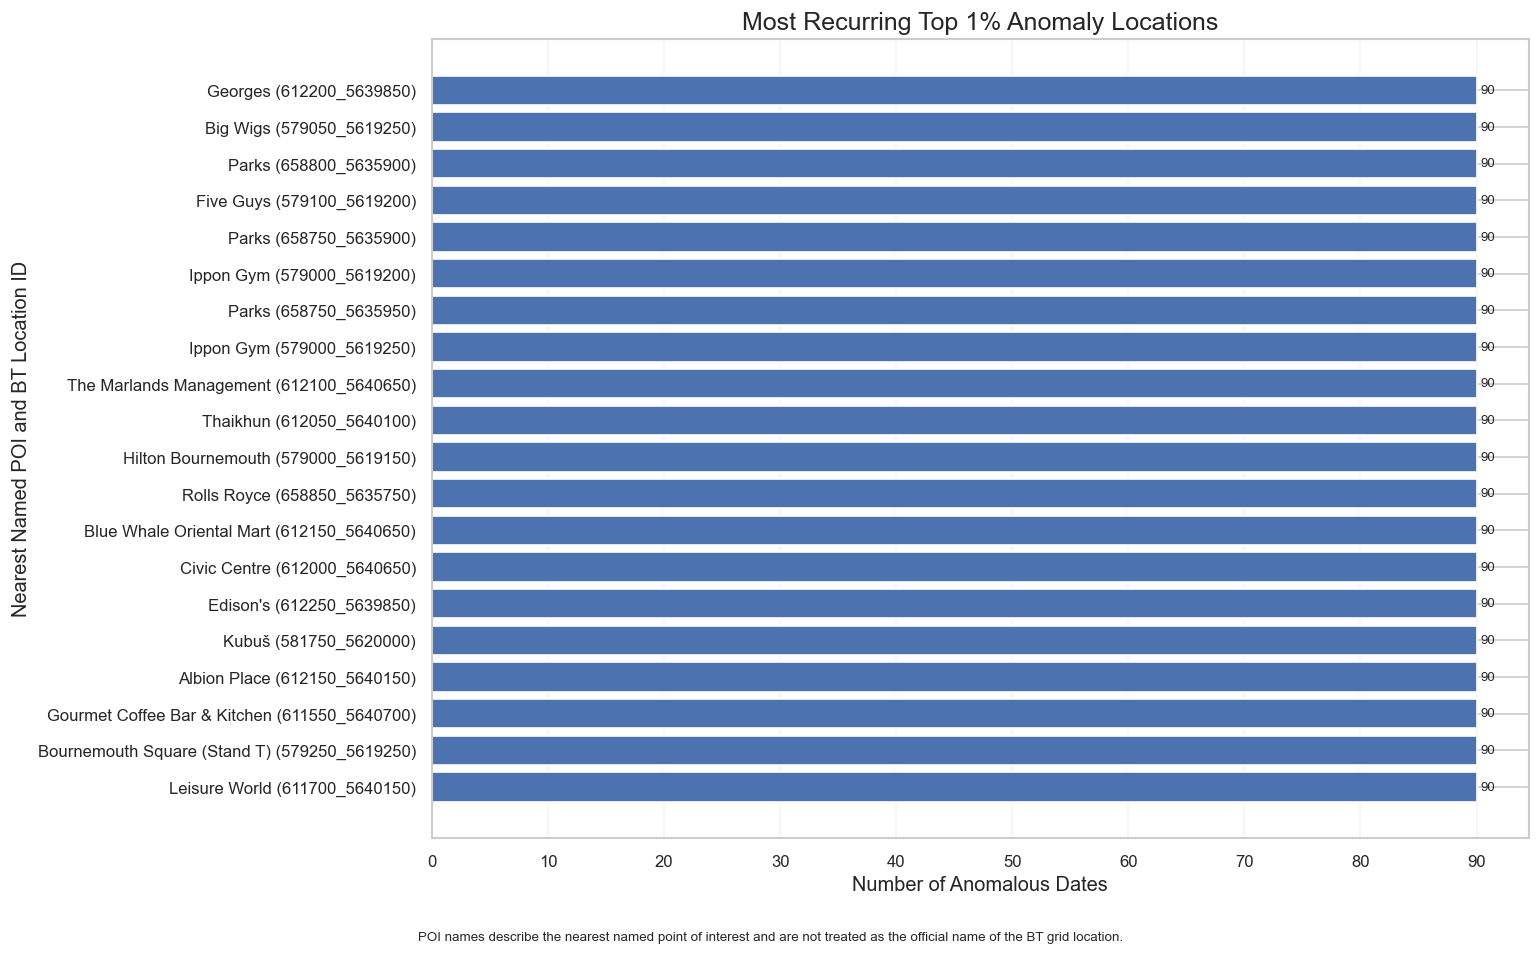

CELL 98 - PLOT THE MOST RECURRING ANOMALY LOCATIONS

Locations displayed: 20

Nearest named POIs are used only as readable location descriptions.

Recurring-location figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_recurring_anomaly_locations.png


In [99]:
# ================================================================
# CELL 98 - PLOT THE MOST RECURRING ANOMALY LOCATIONS
# ================================================================

PART_2_RECURRING_LOCATIONS_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_recurring_anomaly_locations.png"
)


PART_2_RECURRING_PLOT_ROWS = (
    20
)


recurring_plot_data = (
    part_2_top_100_recurring_locations
    .head(
        PART_2_RECURRING_PLOT_ROWS
    )
    .copy()
)


# ------------------------------------------------
# Create readable location labels
# ------------------------------------------------

def create_location_display_label(
    poi_name,
    location_id,
    maximum_length=45
):
    """
    Create a readable location label using the nearest
    named POI where available, while retaining the BT
    location ID.
    """

    if (
        pd.notna(
            poi_name
        )
        and
        str(
            poi_name
        ).strip()
        !=
        ""
    ):

        cleaned_poi_name = str(
            poi_name
        ).strip()


        if len(
            cleaned_poi_name
        ) > maximum_length:

            cleaned_poi_name = (
                cleaned_poi_name[
                    :maximum_length - 3
                ]
                +
                "..."
            )


        return (
            f"{cleaned_poi_name} "
            f"({location_id})"
        )


    return (
        f"Location {location_id}"
    )


recurring_plot_data[
    "location_label"
] = recurring_plot_data.apply(
    lambda row:
        create_location_display_label(
            row[
                "strongest_nearest_poi_name"
            ],
            row[
                "location_id"
            ]
        ),
    axis=1
)


# ------------------------------------------------
# Create figure
# ------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        13,
        8
    )
)


axis.barh(
    recurring_plot_data[
        "location_label"
    ][::-1],
    recurring_plot_data[
        "top_1_percent_anomalous_days"
    ][::-1]
)


axis.set_title(
    "Most Recurring Top 1% Anomaly Locations"
)


axis.set_xlabel(
    "Number of Anomalous Dates"
)


axis.set_ylabel(
    "Nearest Named POI and BT Location ID"
)


axis.xaxis.set_major_locator(
    mticker.MaxNLocator(
        integer=True
    )
)


axis.grid(
    axis="x",
    alpha=0.20
)


# ------------------------------------------------
# Add values to bars
# ------------------------------------------------

for bar in axis.patches:

    bar_width = bar.get_width()


    axis.text(
        bar_width
        +
        0.3,
        bar.get_y()
        +
        bar.get_height() / 2,
        f"{int(bar_width)}",
        va="center",
        fontsize=8
    )


# ------------------------------------------------
# Explanatory note
# ------------------------------------------------

figure.text(
    0.5,
    0.01,
    (
        "POI names describe the nearest named point of interest "
        "and are not treated as the official name of the BT grid location."
    ),
    ha="center",
    fontsize=8
)


figure.tight_layout(
    rect=[
        0,
        0.035,
        1,
        1
    ]
)


# ------------------------------------------------
# Save figure
# ------------------------------------------------

figure.savefig(
    PART_2_RECURRING_LOCATIONS_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_RECURRING_LOCATIONS_FIGURE.exists()


assert (
    PART_2_RECURRING_LOCATIONS_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 98 - PLOT THE MOST RECURRING ANOMALY LOCATIONS")
print("=" * 80)


print(
    f"\nLocations displayed: "
    f"{PART_2_RECURRING_PLOT_ROWS:,}"
)


print(
    "\nNearest named POIs are used only "
    "as readable location descriptions."
)


print(
    "\nRecurring-location figure saved:"
)


print(
    PART_2_RECURRING_LOCATIONS_FIGURE
)

## What Cell 98 Does

This cell plots the 20 locations that recur on the greatest number of Top 1% anomaly dates.

Where available, the nearest named POI is shown alongside the BT location ID to make the locations easier to interpret.

The POI name is used only as a description of the surrounding area and is not treated as the official name of the BT grid location.

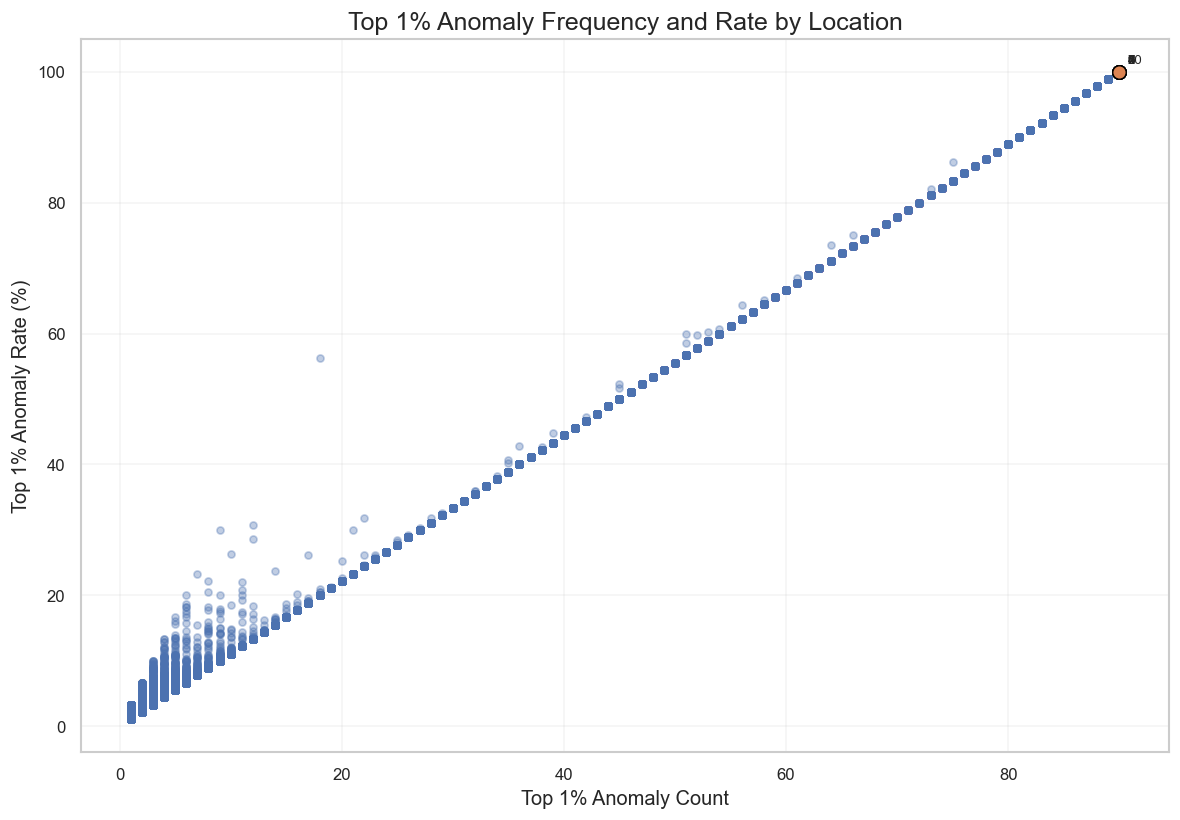

CELL 99 - COMPARE ANOMALY FREQUENCY AND ANOMALY RATE

Locations plotted: 124,440

The 10 most recurring locations are highlighted and labelled by recurrence rank.

Frequency-rate figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_anomaly_frequency_vs_rate.png


In [100]:
# ================================================================
# CELL 99 - COMPARE ANOMALY FREQUENCY AND ANOMALY RATE
# ================================================================

PART_2_FREQUENCY_RATE_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_anomaly_frequency_vs_rate.png"
)


part_2_frequency_rate_data = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,
            top_1_percent_count,
            top_1_percent_rate,
            top_1_percent_anomalous_days,
            best_global_rank

        FROM {PART_2_LOCATION_SUMMARY_TABLE}

        WHERE
            location_observations
            >=
            {PART_2_MINIMUM_RATE_OBSERVATIONS}

            AND

            top_1_percent_count > 0
        """
    )
    .df()
)


figure, axis = plt.subplots(
    figsize=(
        10,
        7
    )
)


axis.scatter(
    part_2_frequency_rate_data[
        "top_1_percent_count"
    ],
    part_2_frequency_rate_data[
        "top_1_percent_rate"
    ],
    s=18,
    alpha=0.35
)


highlight_locations = (
    part_2_top_100_recurring_locations
    .head(
        10
    )
)


axis.scatter(
    highlight_locations[
        "top_1_percent_count"
    ],
    highlight_locations[
        "top_1_percent_rate"
    ],
    s=65,
    edgecolors="black",
    linewidths=0.8
)


for _, location_row in (
    highlight_locations.iterrows()
):

    axis.annotate(
        str(
            int(
                location_row[
                    "recurrence_rank"
                ]
            )
        ),
        (
            location_row[
                "top_1_percent_count"
            ],
            location_row[
                "top_1_percent_rate"
            ]
        ),
        xytext=(
            5,
            5
        ),
        textcoords="offset points",
        fontsize=8
    )


axis.set_title(
    "Top 1% Anomaly Frequency and Rate by Location"
)


axis.set_xlabel(
    "Top 1% Anomaly Count"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.grid(
    alpha=0.20
)


figure.tight_layout()


figure.savefig(
    PART_2_FREQUENCY_RATE_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_FREQUENCY_RATE_FIGURE.exists()


assert (
    PART_2_FREQUENCY_RATE_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 99 - COMPARE ANOMALY FREQUENCY AND ANOMALY RATE")
print("=" * 80)


print(
    f"\nLocations plotted: "
    f"{len(part_2_frequency_rate_data):,}"
)


print(
    "\nThe 10 most recurring locations are "
    "highlighted and labelled by recurrence rank."
)


print(
    "\nFrequency-rate figure saved:"
)


print(
    PART_2_FREQUENCY_RATE_FIGURE
)

## What Cell 99 Does

This cell compares anomaly frequency with anomaly rate.

Locations toward the right generate many Top 1% anomalies, while locations higher on the figure have a larger proportion of their observations classified as anomalous.

The most recurring locations are highlighted so that persistent anomaly locations can be compared with the wider location population.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

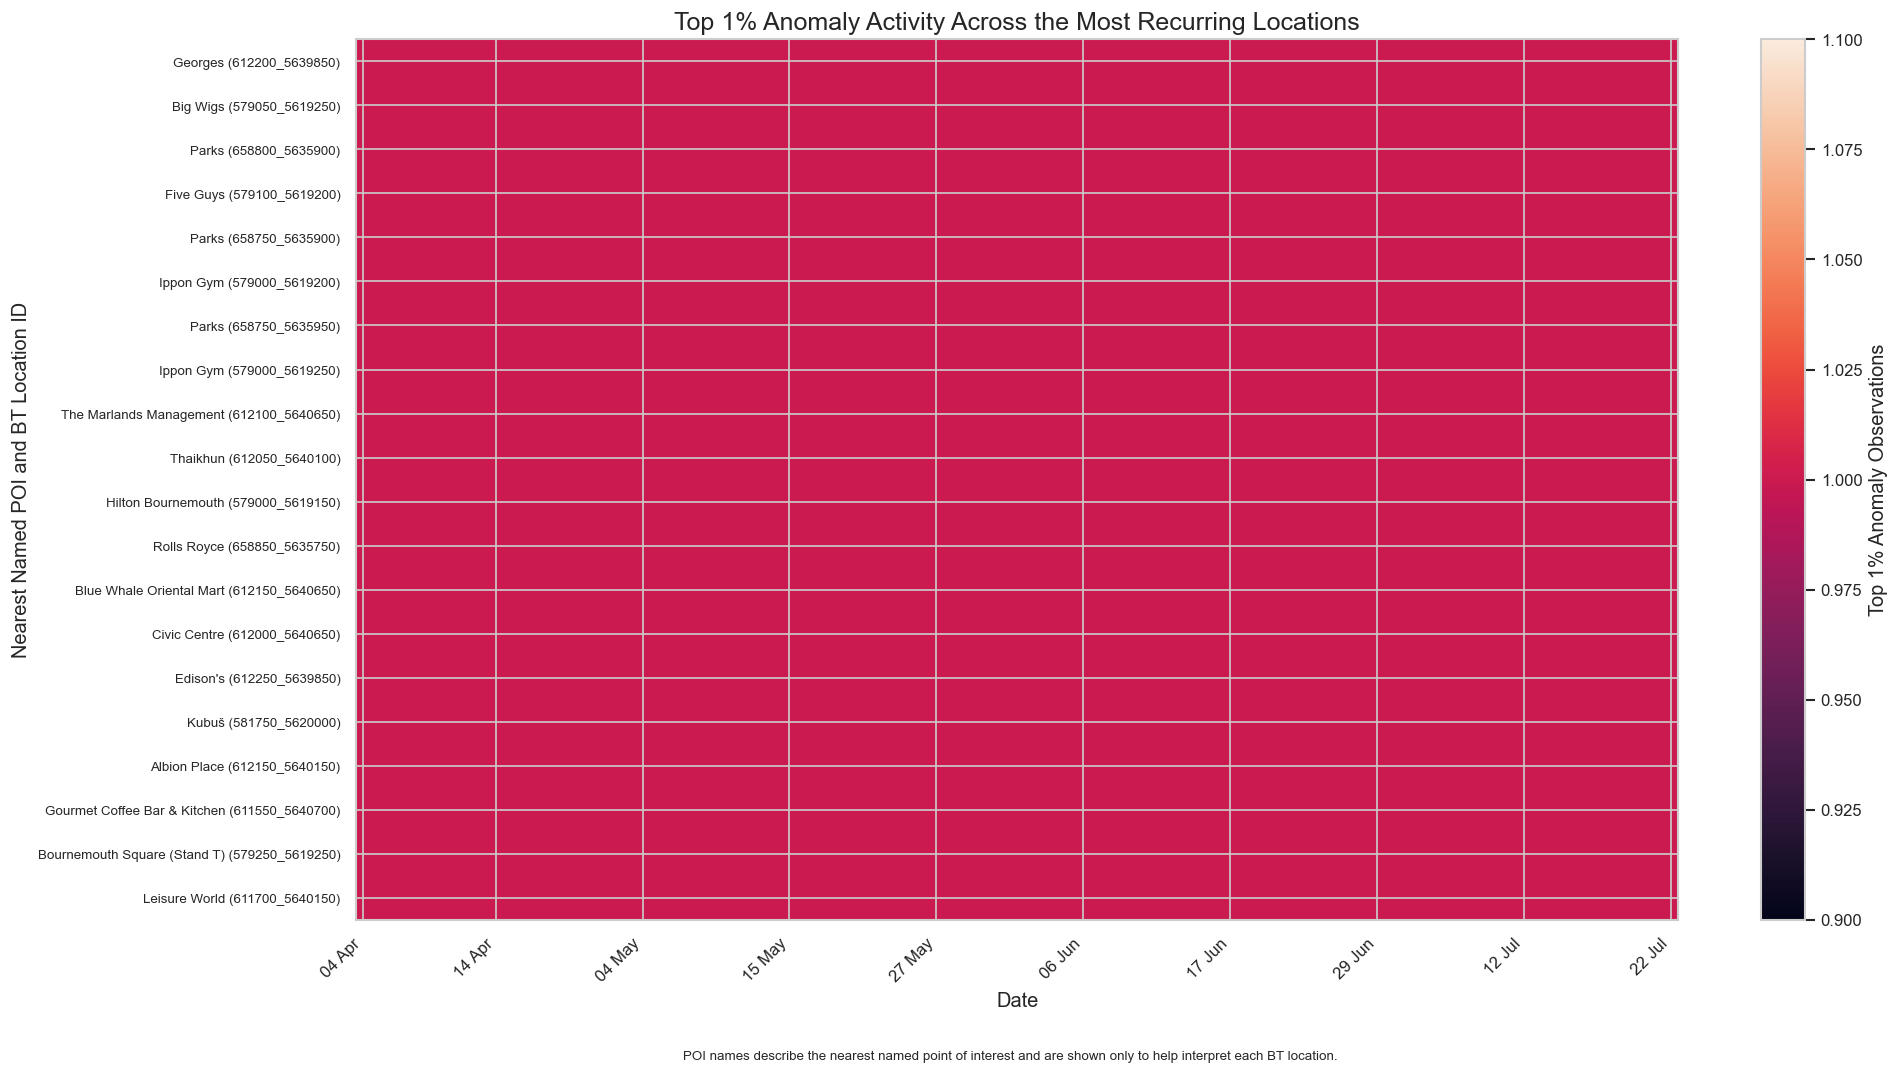

CELL 100 - CREATE THE LOCATION-BY-DATE ANOMALY HEATMAP

Locations displayed: 20
Dates displayed: 90

Nearest named POIs are shown only as readable location descriptions.

Location-date heatmap saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_location_date_anomaly_heatmap.png


In [101]:
# ================================================================
# CELL 100 - CREATE THE LOCATION-BY-DATE ANOMALY HEATMAP
# ================================================================

PART_2_LOCATION_DATE_HEATMAP_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_location_date_anomaly_heatmap.png"
)


PART_2_HEATMAP_LOCATION_ROWS = (
    20
)


heatmap_location_data = (
    part_2_top_100_recurring_locations
    .head(
        PART_2_HEATMAP_LOCATION_ROWS
    )
    .copy()
)


heatmap_location_ids = (
    heatmap_location_data[
        "location_id"
    ]
    .tolist()
)


heatmap_location_labels = (
    heatmap_location_data.apply(
        lambda row:
            create_location_display_label(
                row[
                    "strongest_nearest_poi_name"
                ],
                row[
                    "location_id"
                ],
                maximum_length=40
            ),
        axis=1
    )
    .tolist()
)


heatmap_location_sql = (
    ", ".join(
        "'"
        +
        str(
            location_id
        ).replace(
            "'",
            "''"
        )
        +
        "'"
        for location_id
        in heatmap_location_ids
    )
)


top_1_percent_source_sql = (
    create_part_2_anomaly_source_sql(
        "Top 1%"
    )
)


# ------------------------------------------------
# Count Top 1% anomaly observations by
# location and date
# ------------------------------------------------

part_2_location_date_counts = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            location_id,

            CAST(
                en_dt
                AS DATE
            ) AS anomaly_date,

            COUNT(*) AS anomaly_count

        FROM {top_1_percent_source_sql}

        WHERE
            location_id IN (
                {heatmap_location_sql}
            )

        GROUP BY
            location_id,
            CAST(
                en_dt
                AS DATE
            )

        ORDER BY
            anomaly_date,
            location_id
        """
    )
    .df()
)


# ------------------------------------------------
# Get all dates in the study period
# ------------------------------------------------

all_part_2_dates = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT DISTINCT
            CAST(
                en_dt
                AS DATE
            ) AS observation_date

        FROM read_parquet(
            {part_2_ranked_partition_sql_list},
            union_by_name = true
        )

        ORDER BY
            observation_date
        """
    )
    .df()[
        "observation_date"
    ]
    .tolist()
)


# ------------------------------------------------
# Create the location-by-date matrix
# ------------------------------------------------

heatmap_matrix = (
    part_2_location_date_counts
    .pivot(
        index="location_id",
        columns="anomaly_date",
        values="anomaly_count"
    )
    .reindex(
        index=heatmap_location_ids,
        columns=all_part_2_dates
    )
    .fillna(
        0
    )
)


# ------------------------------------------------
# Create figure
# ------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        17,
        9
    )
)


heatmap_image = axis.imshow(
    heatmap_matrix.to_numpy(),
    aspect="auto",
    interpolation="nearest"
)


axis.set_title(
    "Top 1% Anomaly Activity Across the Most Recurring Locations"
)


axis.set_xlabel(
    "Date"
)


axis.set_ylabel(
    "Nearest Named POI and BT Location ID"
)


axis.set_yticks(
    np.arange(
        len(
            heatmap_location_labels
        )
    )
)


axis.set_yticklabels(
    heatmap_location_labels,
    fontsize=8
)


# ------------------------------------------------
# Create readable date ticks
# ------------------------------------------------

date_tick_positions = np.linspace(
    0,
    len(
        all_part_2_dates
    )
    -
    1,
    10,
    dtype=int
)


axis.set_xticks(
    date_tick_positions
)


axis.set_xticklabels(
    [
        pd.Timestamp(
            all_part_2_dates[
                position
            ]
        ).strftime(
            "%d %b"
        )
        for position
        in date_tick_positions
    ],
    rotation=45,
    ha="right"
)


# ------------------------------------------------
# Colour bar
# ------------------------------------------------

colour_bar = figure.colorbar(
    heatmap_image,
    ax=axis
)


colour_bar.set_label(
    "Top 1% Anomaly Observations"
)


# ------------------------------------------------
# Explanatory note
# ------------------------------------------------

figure.text(
    0.5,
    0.01,
    (
        "POI names describe the nearest named point of interest "
        "and are shown only to help interpret each BT location."
    ),
    ha="center",
    fontsize=8
)


figure.tight_layout(
    rect=[
        0,
        0.035,
        1,
        1
    ]
)


# ------------------------------------------------
# Save
# ------------------------------------------------

figure.savefig(
    PART_2_LOCATION_DATE_HEATMAP_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_LOCATION_DATE_HEATMAP_FIGURE.exists()


assert (
    PART_2_LOCATION_DATE_HEATMAP_FIGURE
    .stat()
    .st_size
    >
    0
)


assert heatmap_matrix.shape[0] == (
    PART_2_HEATMAP_LOCATION_ROWS
)


assert heatmap_matrix.shape[1] == int(
    part_2_field_summary.loc[
        0,
        "unique_dates"
    ]
)


print("=" * 80)
print("CELL 100 - CREATE THE LOCATION-BY-DATE ANOMALY HEATMAP")
print("=" * 80)


print(
    f"\nLocations displayed: "
    f"{heatmap_matrix.shape[0]:,}"
)


print(
    f"Dates displayed: "
    f"{heatmap_matrix.shape[1]:,}"
)


print(
    "\nNearest named POIs are shown only "
    "as readable location descriptions."
)


print(
    "\nLocation-date heatmap saved:"
)


print(
    PART_2_LOCATION_DATE_HEATMAP_FIGURE
)

## What Cell 100 Does

This cell shows Top 1% anomaly activity across the 20 most recurring locations and all dates in the study period.

Where available, the nearest named POI is displayed alongside the BT location ID to make important areas easier to recognise.

The heatmap helps distinguish persistent locations from isolated anomaly spikes and shows whether several important locations become anomalous on the same dates.

In [102]:
# ================================================================
# CELL 101 - ANALYSE CONSECUTIVE ANOMALY STREAKS
# ================================================================

PART_2_STREAK_DISPLAY_ROWS = (
    100
)


part_2_anomaly_streak_summary = (
    PART_2_CONNECTION.execute(
        f"""
        WITH anomaly_days AS (

            SELECT DISTINCT
                location_id,

                CAST(
                    en_dt
                    AS DATE
                ) AS anomaly_date

            FROM read_parquet(
                {part_2_ranked_partition_sql_list},
                union_by_name = true
            )

            WHERE
                {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
        ),

        numbered_days AS (

            SELECT
                location_id,
                anomaly_date,

                ROW_NUMBER() OVER (
                    PARTITION BY
                        location_id
                    ORDER BY
                        anomaly_date
                ) AS day_number

            FROM anomaly_days
        ),

        streak_groups AS (

            SELECT
                location_id,
                anomaly_date,

                anomaly_date
                -
                CAST(
                    day_number
                    AS INTEGER
                ) AS streak_group

            FROM numbered_days
        ),

        streaks AS (

            SELECT
                location_id,
                streak_group,

                MIN(
                    anomaly_date
                ) AS streak_start,

                MAX(
                    anomaly_date
                ) AS streak_end,

                COUNT(*) AS streak_days

            FROM streak_groups

            GROUP BY
                location_id,
                streak_group
        ),

        location_streaks AS (

            SELECT
                location_id,

                MAX(
                    streak_days
                ) AS longest_consecutive_streak,

                COUNT(*) AS anomaly_episodes,

                MIN(
                    streak_start
                ) FILTER (
                    WHERE streak_days = (
                        SELECT MAX(
                            inner_streak.streak_days
                        )

                        FROM streaks AS inner_streak

                        WHERE
                            inner_streak.location_id
                            =
                            streaks.location_id
                    )
                ) AS longest_streak_start,

                MAX(
                    streak_end
                ) FILTER (
                    WHERE streak_days = (
                        SELECT MAX(
                            inner_streak.streak_days
                        )

                        FROM streaks AS inner_streak

                        WHERE
                            inner_streak.location_id
                            =
                            streaks.location_id
                    )
                ) AS longest_streak_end

            FROM streaks

            GROUP BY
                location_id
        )

        SELECT
            streak.location_id,

            streak.longest_consecutive_streak,

            streak.anomaly_episodes,

            streak.longest_streak_start,

            streak.longest_streak_end,

            location.top_1_percent_anomalous_days,

            location.top_1_percent_count,

            location.top_1_percent_rate,

            location.location_observations,

            location.best_global_rank,

            location.strongest_nearest_poi_type,

            location.strongest_nearest_poi_name

        FROM location_streaks AS streak

        INNER JOIN
            {PART_2_LOCATION_SUMMARY_TABLE}
            AS location

        ON
            streak.location_id
            =
            location.location_id

        ORDER BY
            streak.longest_consecutive_streak DESC,
            location.top_1_percent_anomalous_days DESC,
            location.top_1_percent_count DESC,
            location.best_global_rank ASC
        """
    )
    .df()
)


part_2_top_100_anomaly_streaks = (
    part_2_anomaly_streak_summary
    .head(
        PART_2_STREAK_DISPLAY_ROWS
    )
    .copy()
)


part_2_streak_overview = pd.DataFrame(
    {
        "Measure": [
            "Locations with a Top 1% anomaly",
            "Maximum consecutive anomaly streak",
            "Median longest streak",
            "Locations anomalous for 7+ consecutive days",
            "Locations anomalous for 30+ consecutive days",
            "Locations anomalous for all 90 consecutive days"
        ],
        "Value": [
            len(
                part_2_anomaly_streak_summary
            ),
            int(
                part_2_anomaly_streak_summary[
                    "longest_consecutive_streak"
                ].max()
            ),
            float(
                part_2_anomaly_streak_summary[
                    "longest_consecutive_streak"
                ].median()
            ),
            int(
                (
                    part_2_anomaly_streak_summary[
                        "longest_consecutive_streak"
                    ]
                    >=
                    7
                ).sum()
            ),
            int(
                (
                    part_2_anomaly_streak_summary[
                        "longest_consecutive_streak"
                    ]
                    >=
                    30
                ).sum()
            ),
            int(
                (
                    part_2_anomaly_streak_summary[
                        "longest_consecutive_streak"
                    ]
                    ==
                    90
                ).sum()
            )
        ]
    }
)


print("=" * 80)
print("CELL 101 - ANALYSE CONSECUTIVE ANOMALY STREAKS")
print("=" * 80)


display(
    part_2_streak_overview
)


print(
    "\nTop 100 locations by longest consecutive "
    "Top 1% anomaly streak:"
)


display(
    part_2_top_100_anomaly_streaks
)


assert len(
    part_2_anomaly_streak_summary
) == int(
    part_2_location_frequency_summary.loc[
        0,
        "locations_with_top_1_percent_anomaly"
    ]
)


assert (
    part_2_anomaly_streak_summary[
        "longest_consecutive_streak"
    ]
    >=
    1
).all()


assert (
    part_2_anomaly_streak_summary[
        "longest_consecutive_streak"
    ]
    <=
    part_2_anomaly_streak_summary[
        "top_1_percent_anomalous_days"
    ]
).all()


print(
    "\nConsecutive anomaly streaks were "
    "analysed successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 101 - ANALYSE CONSECUTIVE ANOMALY STREAKS


,Measure,Value
0,Locations with a Top 1% anomaly,"126,990.000000"
1,Maximum consecutive anomaly streak,24.000000
2,Median longest streak,1.000000
3,Locations anomalous for 7+ consecutive days,"10,120.000000"
4,Locations anomalous for 30+ consecutive days,0.000000
5,Locations anomalous for all 90 consecutive days,0.000000



Top 100 locations by longest consecutive Top 1% anomaly streak:


,location_id,longest_consecutive_streak,anomaly_episodes,longest_streak_start,longest_streak_end,top_1_percent_anomalous_days,top_1_percent_count,top_1_percent_rate,location_observations,best_global_rank,strongest_nearest_poi_type,strongest_nearest_poi_name
0,612200_5639850,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,4,restaurants,Georges
1,579050_5619250,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,9,cafes,Big Wigs
2,658800_5635900,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,14,parks,Parks
3,579100_5619200,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,15,fast_foods,Five Guys
4,658750_5635900,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,22,parks,Parks
5,579000_5619200,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,26,gyms,Ippon Gym
6,658750_5635950,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,27,parks,Parks
7,579000_5619250,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,63,gyms,Ippon Gym
8,612100_5640650,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,79,offices,The Marlands Management
9,612050_5640100,24,11,2026-05-21,2026-06-13,90,90,100.000000,90,90,restaurants,Thaikhun



Consecutive anomaly streaks were analysed successfully.


## What Cell 101 Does

This cell measures whether Top 1% anomalies occur on consecutive dates at the same BT location.

The longest consecutive anomaly streak is calculated for every location containing at least one Top 1% anomaly.

This distinguishes persistent periods of anomalous behaviour from locations whose anomalies occur on the same number of dates but are spread across the study period.

## Key Findings — Question 3

The location-level results show substantial differences in anomaly frequency, anomaly rate and recurrence.

Some locations generate anomalies only occasionally, while others repeatedly appear within the strongest anomaly groups across multiple study dates.

The consecutive-streak analysis provides a different measure of persistence by distinguishing repeated anomalies across the full study period from genuinely uninterrupted sequences of anomalous dates.

The exact numbers of anomalous locations, recurrence dates, longest streaks and anomaly rates are reported by the tables above for the current dataset.

These results distinguish isolated anomaly events from locations showing repeated or sustained periods of unusual network behaviour.

# Question 4 — When do anomalies occur?

The previous section identified locations where anomalous behaviour occurs repeatedly.

This section changes the analysis from locations to dates and investigates whether some days contain more unusual activity than others.

Daily anomaly counts, the number of affected locations and the strongest anomaly observed on each date are compared across the complete study period.

In [103]:
# ================================================================
# CELL 102 - BUILD THE DAILY ANOMALY SUMMARY
# ================================================================

PART_2_DAILY_BASE_TABLE = (
    "model_1_part_2_daily_base"
)


PART_2_DAILY_ANOMALY_TABLE = (
    "model_1_part_2_daily_anomalies"
)


PART_2_DAILY_SUMMARY_TABLE = (
    "model_1_part_2_daily_summary"
)


# ------------------------------------------------
# Remove existing working versions
# ------------------------------------------------

for table_name in [
    PART_2_DAILY_BASE_TABLE,
    PART_2_DAILY_ANOMALY_TABLE,
    PART_2_DAILY_SUMMARY_TABLE
]:

    PART_2_CONNECTION.execute(
        f"""
        DROP TABLE IF EXISTS {table_name}
        """
    )


# ------------------------------------------------
# Basic daily observation information
# ------------------------------------------------

PART_2_CONNECTION.execute(
    f"""
    CREATE TABLE
        {PART_2_DAILY_BASE_TABLE}
    AS

    SELECT
        CAST(
            en_dt
            AS DATE
        ) AS observation_date,

        COUNT(*) AS observations,

        COUNT(
            DISTINCT location_id
        ) AS unique_locations

    FROM read_parquet(
        {part_2_ranked_partition_sql_list},
        union_by_name = true
    )

    GROUP BY
        CAST(
            en_dt
            AS DATE
        )
    """
)


# ------------------------------------------------
# Daily anomaly information from Top 1%
# ------------------------------------------------

top_1_percent_source_sql = (
    create_part_2_anomaly_source_sql(
        "Top 1%"
    )
)


PART_2_CONNECTION.execute(
    f"""
    CREATE TABLE
        {PART_2_DAILY_ANOMALY_TABLE}
    AS

    SELECT
        CAST(
            en_dt
            AS DATE
        ) AS observation_date,

        COUNT(*) AS top_1_percent_count,

        COUNT_IF(
            {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
        ) AS top_0_5_percent_count,

        COUNT(
            DISTINCT location_id
        ) AS unique_top_1_percent_locations,

        COUNT(
            DISTINCT CASE
                WHEN {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                THEN location_id
            END
        ) AS unique_top_0_5_percent_locations,

        MIN(
            {MODEL_1_GLOBAL_RANK_COLUMN}
        ) AS best_global_rank,

        MAX(
            {MODEL_1_ANOMALY_SCORE_COLUMN}
        ) AS maximum_anomaly_score,

        MEDIAN(
            {MODEL_1_ANOMALY_SCORE_COLUMN}
        ) AS median_top_1_percent_score,

        COUNT_IF(
            nearest_poi_distance
            <=
            {PART_2_NEARBY_POI_DISTANCE_METRES}
        ) AS anomalies_within_500m_of_poi

    FROM {top_1_percent_source_sql}

    GROUP BY
        CAST(
            en_dt
            AS DATE
        )
    """
)


# ------------------------------------------------
# Combine daily information
# ------------------------------------------------

PART_2_CONNECTION.execute(
    f"""
    CREATE TABLE
        {PART_2_DAILY_SUMMARY_TABLE}
    AS

    SELECT
        base.observation_date,

        base.observations,

        base.unique_locations,

        COALESCE(
            anomalies.top_1_percent_count,
            0
        ) AS top_1_percent_count,

        COALESCE(
            anomalies.top_0_5_percent_count,
            0
        ) AS top_0_5_percent_count,

        COALESCE(
            anomalies.unique_top_1_percent_locations,
            0
        ) AS unique_top_1_percent_locations,

        COALESCE(
            anomalies.unique_top_0_5_percent_locations,
            0
        ) AS unique_top_0_5_percent_locations,

        anomalies.best_global_rank,

        anomalies.maximum_anomaly_score,

        anomalies.median_top_1_percent_score,

        COALESCE(
            anomalies.anomalies_within_500m_of_poi,
            0
        ) AS anomalies_within_500m_of_poi,

        (
            COALESCE(
                anomalies.top_1_percent_count,
                0
            )
            /
            CAST(
                base.observations
                AS DOUBLE
            )
        )
        *
        100.0
        AS top_1_percent_daily_rate,

        (
            COALESCE(
                anomalies.top_0_5_percent_count,
                0
            )
            /
            CAST(
                base.observations
                AS DOUBLE
            )
        )
        *
        100.0
        AS top_0_5_percent_daily_rate

    FROM
        {PART_2_DAILY_BASE_TABLE}
        AS base

    LEFT JOIN
        {PART_2_DAILY_ANOMALY_TABLE}
        AS anomalies

        ON
            base.observation_date
            =
            anomalies.observation_date

    ORDER BY
        base.observation_date
    """
)


part_2_daily_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT *

        FROM {PART_2_DAILY_SUMMARY_TABLE}

        ORDER BY
            observation_date
        """
    )
    .df()
)


part_2_daily_validation = pd.DataFrame(
    {
        "Measure": [
            "Dates",
            "Total observations",
            "Top 1% observations",
            "Top 0.5% observations",
            "Minimum daily observations",
            "Maximum daily observations",
            "Minimum Top 1% daily count",
            "Maximum Top 1% daily count"
        ],
        "Value": [
            len(
                part_2_daily_summary
            ),
            int(
                part_2_daily_summary[
                    "observations"
                ].sum()
            ),
            int(
                part_2_daily_summary[
                    "top_1_percent_count"
                ].sum()
            ),
            int(
                part_2_daily_summary[
                    "top_0_5_percent_count"
                ].sum()
            ),
            int(
                part_2_daily_summary[
                    "observations"
                ].min()
            ),
            int(
                part_2_daily_summary[
                    "observations"
                ].max()
            ),
            int(
                part_2_daily_summary[
                    "top_1_percent_count"
                ].min()
            ),
            int(
                part_2_daily_summary[
                    "top_1_percent_count"
                ].max()
            )
        ]
    }
)


print("=" * 80)
print("CELL 102 - BUILD THE DAILY ANOMALY SUMMARY")
print("=" * 80)


display(
    part_2_daily_validation
)


print(
    "\nDaily anomaly summary:"
)


display(
    part_2_daily_summary
)


assert len(
    part_2_daily_summary
) == int(
    part_2_field_summary.loc[
        0,
        "unique_dates"
    ]
)


assert int(
    part_2_daily_summary[
        "observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    part_2_daily_summary[
        "top_1_percent_count"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_daily_summary[
        "top_0_5_percent_count"
    ].sum()
) == MODEL_1_TOP_0_5_PERCENT_ROWS


print(
    "\nThe daily anomaly summary was created "
    "successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 102 - BUILD THE DAILY ANOMALY SUMMARY


,Measure,Value
0,Dates,90
1,Total observations,119267039
2,Top 1% observations,1192671
3,Top 0.5% observations,596336
4,Minimum daily observations,989610
5,Maximum daily observations,1559832
6,Minimum Top 1% daily count,3925
7,Maximum Top 1% daily count,30284



Daily anomaly summary:


,observation_date,observations,unique_locations,top_1_percent_count,top_0_5_percent_count,unique_top_1_percent_locations,unique_top_0_5_percent_locations,best_global_rank,maximum_anomaly_score,median_top_1_percent_score,anomalies_within_500m_of_poi,top_1_percent_daily_rate,top_0_5_percent_daily_rate
0,2026-04-04,1322741,1322741,13427,"6,854.000000",13427,6854,58,0.883488,0.419439,"12,703.000000",1.015089,0.518166
1,2026-04-05,1325263,1325263,11856,"5,758.000000",11856,5758,230,0.870824,0.416810,"10,967.000000",0.894615,0.434480
2,2026-04-06,1371738,1371738,12385,"6,148.000000",12385,6148,363,0.861459,0.417911,"11,521.000000",0.902869,0.448191
3,2026-04-07,1223418,1223418,7993,"3,667.000000",7993,3667,407,0.858986,0.414124,"7,505.000000",0.653334,0.299734
4,2026-04-08,1294137,1294137,8475,"3,920.000000",8475,3920,113,0.878093,0.414862,"8,058.000000",0.654877,0.302905
5,2026-04-09,1215695,1215695,10587,"4,987.000000",10587,4987,137,0.876667,0.415455,"10,069.000000",0.870860,0.410218
6,2026-04-10,1276920,1276920,13629,"6,748.000000",13629,6748,286,0.866860,0.417922,"12,855.000000",1.067334,0.528459
7,2026-04-11,1267340,1267340,30284,"17,292.000000",30284,17292,4,0.900098,0.427240,"28,546.000000",2.389572,1.364433
8,2026-04-13,1232265,1232265,13355,"6,429.000000",13355,6429,83,0.880511,0.416433,"12,588.000000",1.083777,0.521722
9,2026-04-14,1208420,1208420,13201,"6,398.000000",13201,6398,62,0.883047,0.416589,"12,521.000000",1.092418,0.529452



The daily anomaly summary was created successfully.


## What Cell 102 Does

This cell creates one summary row for every date in the study period.

For each date it records the number of observations, the number of Top 1% and Top 0.5% anomalies, the number of affected locations and the strongest anomaly observed.

Daily anomaly rates are also calculated so that dates with different numbers of observations can be compared fairly.

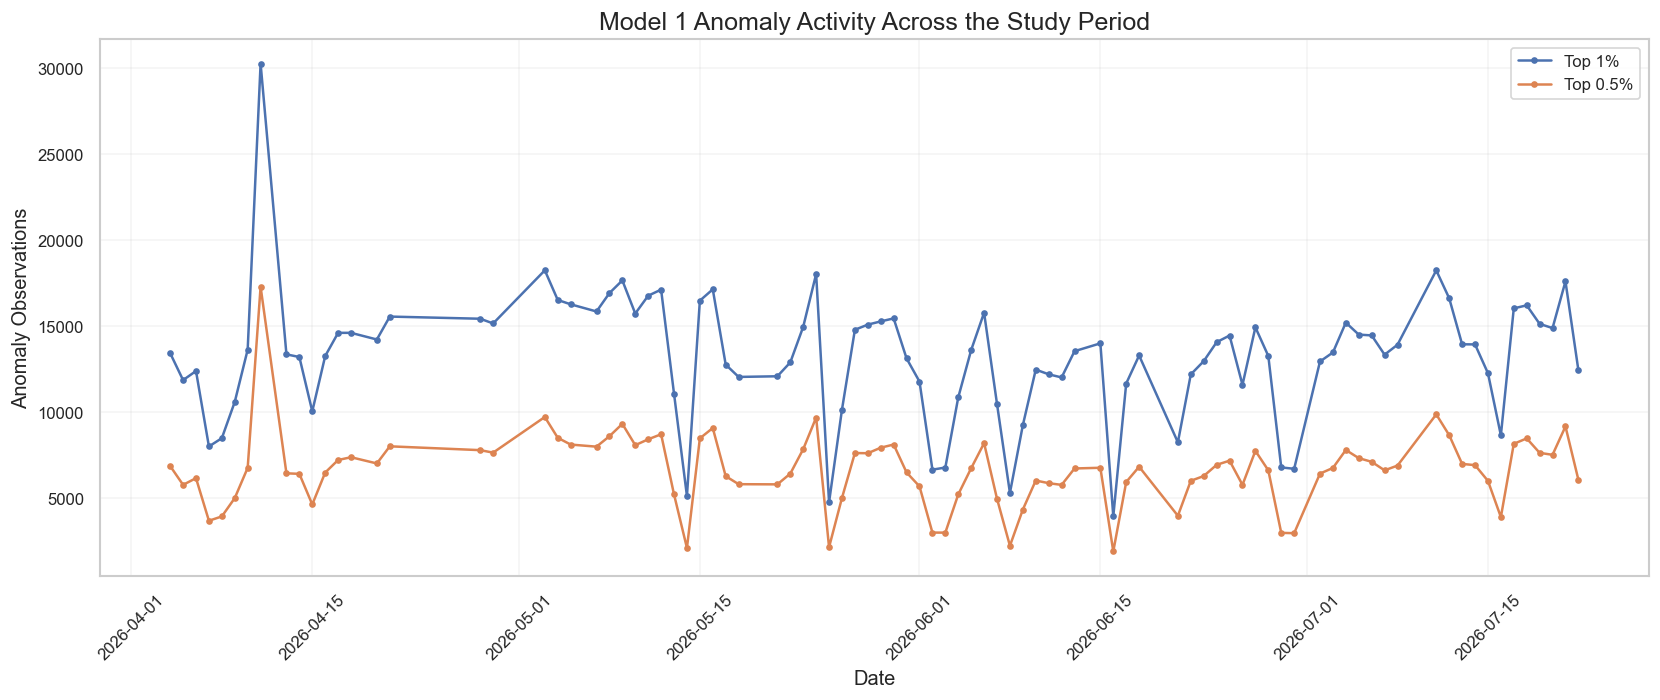

CELL 103 - PLOT ANOMALIES ACROSS THE STUDY PERIOD

Dates plotted: 90

Daily anomaly-count figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_daily_anomaly_counts.png


In [104]:
# ================================================================
# CELL 103 - PLOT ANOMALIES ACROSS THE STUDY PERIOD
# ================================================================

PART_2_DAILY_ANOMALY_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_daily_anomaly_counts.png"
)


figure, axis = plt.subplots(
    figsize=(
        14,
        6
    )
)


axis.plot(
    part_2_daily_summary[
        "observation_date"
    ],
    part_2_daily_summary[
        "top_1_percent_count"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Top 1%"
)


axis.plot(
    part_2_daily_summary[
        "observation_date"
    ],
    part_2_daily_summary[
        "top_0_5_percent_count"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Top 0.5%"
)


axis.set_title(
    "Model 1 Anomaly Activity Across the Study Period"
)


axis.set_xlabel(
    "Date"
)


axis.set_ylabel(
    "Anomaly Observations"
)


axis.tick_params(
    axis="x",
    rotation=45
)


axis.grid(
    alpha=0.20
)


axis.legend()


figure.tight_layout()


figure.savefig(
    PART_2_DAILY_ANOMALY_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_DAILY_ANOMALY_FIGURE.exists()


assert (
    PART_2_DAILY_ANOMALY_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 103 - PLOT ANOMALIES ACROSS THE STUDY PERIOD")
print("=" * 80)


print(
    f"\nDates plotted: "
    f"{len(part_2_daily_summary):,}"
)


print(
    "\nDaily anomaly-count figure saved:"
)


print(
    PART_2_DAILY_ANOMALY_FIGURE
)

## What Cell 103 Does

This cell plots the number of Top 1% and Top 0.5% anomaly observations recorded on each date.

The figure shows whether anomaly activity remains relatively stable or whether particular dates contain unusually large numbers of strong anomalies.

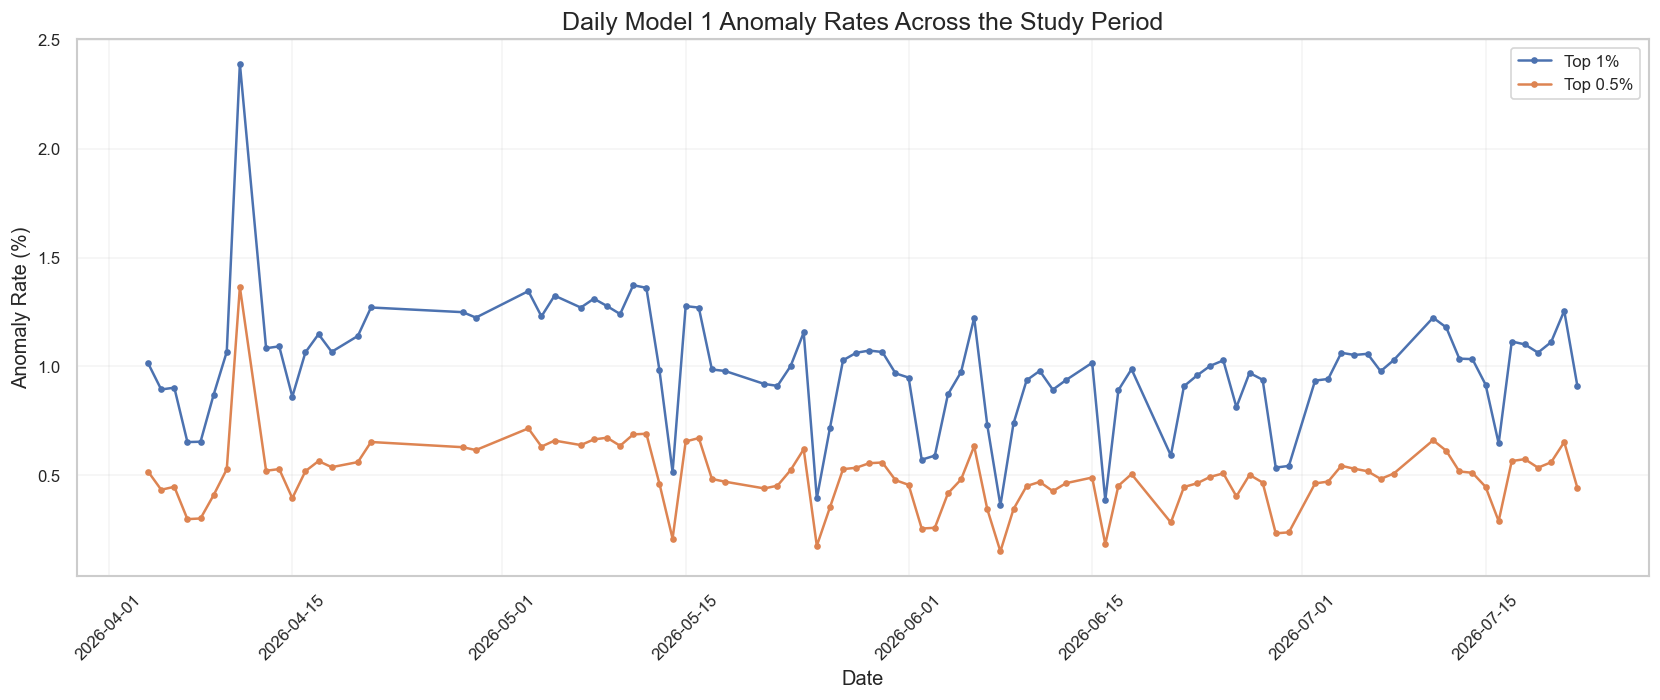

CELL 104 - PLOT DAILY ANOMALY RATES

Dates plotted: 90

Highest Top 1% daily anomaly rate:


,observation_date,observations,top_1_percent_count,top_1_percent_daily_rate,top_0_5_percent_daily_rate
7,2026-04-11,1267340,30284,2.389572,1.364433



Daily anomaly-rate figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_daily_anomaly_rates.png


In [105]:
# ================================================================
# CELL 104 - PLOT DAILY ANOMALY RATES
# ================================================================

PART_2_DAILY_RATE_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_daily_anomaly_rates.png"
)


figure, axis = plt.subplots(
    figsize=(
        14,
        6
    )
)


axis.plot(
    part_2_daily_summary[
        "observation_date"
    ],
    part_2_daily_summary[
        "top_1_percent_daily_rate"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Top 1%"
)


axis.plot(
    part_2_daily_summary[
        "observation_date"
    ],
    part_2_daily_summary[
        "top_0_5_percent_daily_rate"
    ],
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Top 0.5%"
)


axis.set_title(
    "Daily Model 1 Anomaly Rates Across the Study Period"
)


axis.set_xlabel(
    "Date"
)


axis.set_ylabel(
    "Anomaly Rate (%)"
)


axis.tick_params(
    axis="x",
    rotation=45
)


axis.grid(
    alpha=0.20
)


axis.legend()


figure.tight_layout()


figure.savefig(
    PART_2_DAILY_RATE_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_DAILY_RATE_FIGURE.exists()


assert (
    PART_2_DAILY_RATE_FIGURE
    .stat()
    .st_size
    >
    0
)


assert (
    part_2_daily_summary[
        "top_1_percent_daily_rate"
    ]
    .between(
        0,
        100
    )
    .all()
)


assert (
    part_2_daily_summary[
        "top_0_5_percent_daily_rate"
    ]
    .between(
        0,
        100
    )
    .all()
)


print("=" * 80)
print("CELL 104 - PLOT DAILY ANOMALY RATES")
print("=" * 80)


print(
    f"\nDates plotted: "
    f"{len(part_2_daily_summary):,}"
)


print(
    "\nHighest Top 1% daily anomaly rate:"
)


highest_daily_rate_row = (
    part_2_daily_summary
    .sort_values(
        "top_1_percent_daily_rate",
        ascending=False
    )
    .head(
        1
    )
)


display(
    highest_daily_rate_row[
        [
            "observation_date",
            "observations",
            "top_1_percent_count",
            "top_1_percent_daily_rate",
            "top_0_5_percent_daily_rate"
        ]
    ]
)


print(
    "\nDaily anomaly-rate figure saved:"
)


print(
    PART_2_DAILY_RATE_FIGURE
)

## What Cell 104 Does

This cell plots the percentage of observations classified within the Top 1% and Top 0.5% anomaly groups on each date.

Using rates accounts for differences in the total number of BT observations available on different dates.

This helps identify dates where anomaly activity is unusually high relative to the amount of data collected.

In [106]:
# ================================================================
# CELL 105 - IDENTIFY THE MOST UNUSUAL DAYS
# ================================================================

PART_2_TOP_UNUSUAL_DAYS = (
    20
)


part_2_unusual_days = (
    part_2_daily_summary
    .sort_values(
        [
            "top_0_5_percent_count",
            "top_1_percent_count",
            "unique_top_1_percent_locations",
            "best_global_rank"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .head(
        PART_2_TOP_UNUSUAL_DAYS
    )
    .copy()
    .reset_index(
        drop=True
    )
)


part_2_unusual_days.insert(
    0,
    "unusual_day_rank",
    np.arange(
        1,
        len(
            part_2_unusual_days
        )
        +
        1
    )
)


part_2_unusual_days[
    "top_1_percent_location_share"
] = (
    part_2_unusual_days[
        "unique_top_1_percent_locations"
    ]
    /
    part_2_unusual_days[
        "unique_locations"
    ]
    *
    100
)


print("=" * 80)
print("CELL 105 - IDENTIFY THE MOST UNUSUAL DAYS")
print("=" * 80)


display(
    part_2_unusual_days
)


assert len(
    part_2_unusual_days
) == PART_2_TOP_UNUSUAL_DAYS


assert (
    part_2_unusual_days[
        "top_1_percent_count"
    ]
    >
    0
).all()


assert (
    part_2_unusual_days[
        "top_0_5_percent_count"
    ]
    >
    0
).all()


print(
    "\nThe most unusual dates were "
    "identified successfully."
)

CELL 105 - IDENTIFY THE MOST UNUSUAL DAYS


,unusual_day_rank,observation_date,observations,unique_locations,top_1_percent_count,top_0_5_percent_count,unique_top_1_percent_locations,unique_top_0_5_percent_locations,best_global_rank,maximum_anomaly_score,median_top_1_percent_score,anomalies_within_500m_of_poi,top_1_percent_daily_rate,top_0_5_percent_daily_rate,top_1_percent_location_share
0,1,2026-04-11,1267340,1267340,30284,"17,292.000000",30284,17292,4,0.900098,0.427240,"28,546.000000",2.389572,1.364433,2.389572
1,2,2026-07-11,1490688,1490688,18244,"9,862.000000",18244,9862,20,0.891643,0.423735,"16,875.000000",1.223864,0.661574,1.223864
2,3,2026-05-03,1355771,1355771,18247,"9,708.000000",18247,9708,32,0.888916,0.421852,"16,978.000000",1.345876,0.716050,1.345876
3,4,2026-05-24,1559832,1559832,18033,"9,677.000000",18033,9677,9,0.896785,0.422754,"16,590.000000",1.156086,0.620387,1.156086
4,5,2026-05-09,1382651,1382651,17661,"9,309.000000",17661,9309,16,0.894154,0.421441,"16,577.000000",1.277329,0.673272,1.277329
5,6,2026-07-21,1402105,1402105,17604,"9,159.000000",17604,9159,86,0.880346,0.420703,"16,427.000000",1.255541,0.653232,1.255541
6,7,2026-05-16,1349578,1349578,17141,"9,066.000000",17141,9066,51,0.884704,0.421512,"15,982.000000",1.270101,0.671766,1.270101
7,8,2026-05-12,1258356,1258356,17124,"8,702.000000",17124,8702,17,0.893875,0.419232,"16,175.000000",1.360823,0.691537,1.360823
8,9,2026-07-12,1409311,1409311,16623,"8,650.000000",16623,8650,30,0.889416,0.420604,"15,220.000000",1.179513,0.613775,1.179513
9,10,2026-05-08,1290651,1290651,16921,"8,588.000000",16921,8588,358,0.861944,0.419128,"15,941.000000",1.311044,0.665401,1.311044



The most unusual dates were identified successfully.


## What Cell 105 Does

This cell identifies the 20 dates with the strongest overall anomaly activity.

Dates are prioritised using the number of Top 0.5% anomalies, followed by Top 1% anomaly count, the number of affected locations and the strongest global anomaly rank.

The resulting table highlights dates that may be useful for later investigation against known events, population changes or other external activity.

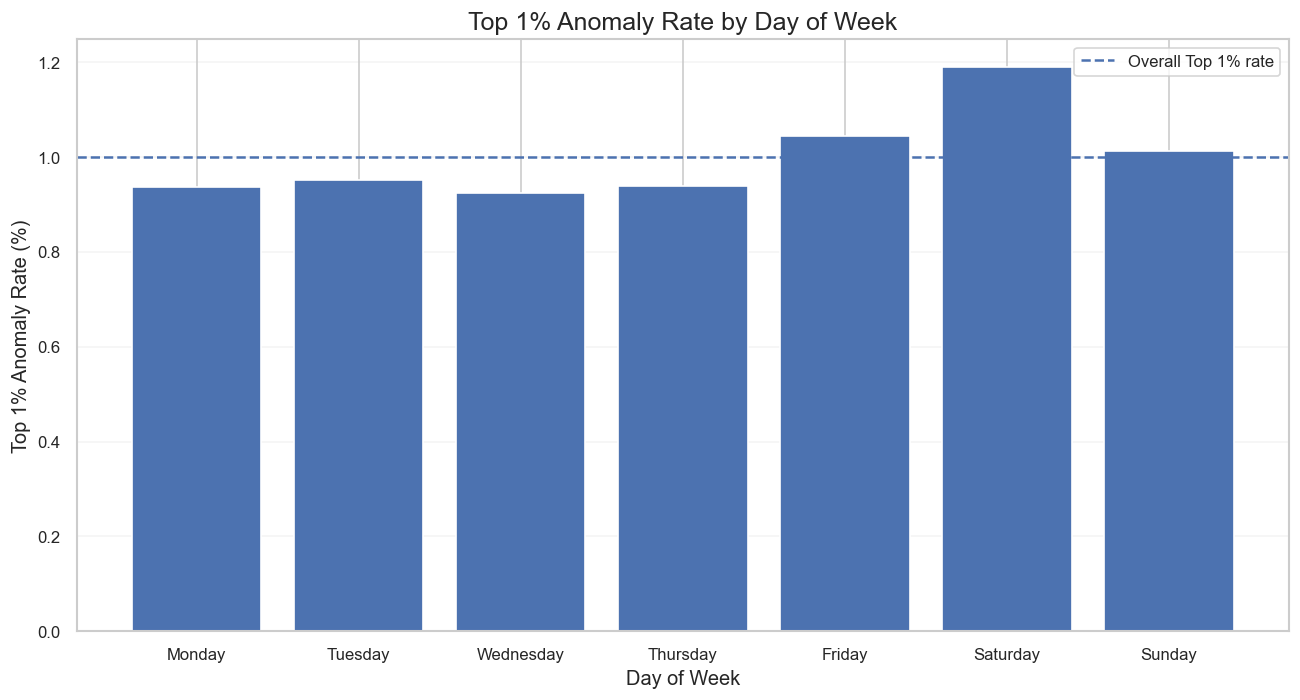

CELL 106 - ANALYSE ANOMALIES BY DAY OF WEEK

Overall Top 1% anomaly rate: 1.0000%
Overall Top 0.5% anomaly rate: 0.5000%

Day-of-week summary:


,day_of_week,study_dates,observations,top_1_percent_count,top_0_5_percent_count,mean_daily_observations,mean_daily_top_1_percent_count,top_1_percent_rate,top_0_5_percent_rate
0,Monday,15,19570997,183330,"89,579.000000","1,304,733.133333","12,222.000000",0.936743,0.457713
1,Tuesday,15,18911040,180037,"88,707.000000","1,260,736.000000","12,002.466667",0.952021,0.469075
2,Wednesday,12,15499148,143079,"69,733.000000","1,291,595.666667","11,923.250000",0.923141,0.449915
3,Thursday,12,15387834,144328,"70,235.000000","1,282,319.500000","12,027.333333",0.937936,0.456432
4,Friday,11,14998383,156496,"78,464.000000","1,363,489.363636","14,226.909091",1.043419,0.523150
5,Saturday,13,18298689,217438,"114,573.000000","1,407,591.461538","16,726.000000",1.188271,0.626127
6,Sunday,12,16600948,167963,"85,045.000000","1,383,412.333333","13,996.916667",1.011768,0.512290



Weekday versus weekend summary:


,day_type,study_dates,observations,top_1_percent_count,top_0_5_percent_count,mean_daily_top_1_percent_count,top_1_percent_rate,top_0_5_percent_rate
0,Weekday,65,84367402,807270,"396,718.000000","12,419.538462",0.956851,0.470227
1,Weekend,25,34899637,385401,"199,618.000000","15,416.040000",1.104312,0.571977



Day-of-week and weekend anomaly patterns were analysed successfully.


In [107]:
# ================================================================
# CELL 106 - ANALYSE ANOMALIES BY DAY OF WEEK
# ================================================================

PART_2_DAY_OF_WEEK_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_day_of_week_anomaly_rates.png"
)


# ------------------------------------------------
# Global anomaly rates
# ------------------------------------------------

PART_2_GLOBAL_TOP_1_RATE = (
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


PART_2_GLOBAL_TOP_0_5_RATE = (
    MODEL_1_TOP_0_5_PERCENT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


# ------------------------------------------------
# Prepare calendar fields
# ------------------------------------------------

part_2_daily_calendar = (
    part_2_daily_summary
    .copy()
)


part_2_daily_calendar[
    "observation_date"
] = pd.to_datetime(
    part_2_daily_calendar[
        "observation_date"
    ]
)


part_2_daily_calendar[
    "day_of_week"
] = (
    part_2_daily_calendar[
        "observation_date"
    ]
    .dt.day_name()
)


part_2_daily_calendar[
    "day_number"
] = (
    part_2_daily_calendar[
        "observation_date"
    ]
    .dt.dayofweek
)


part_2_daily_calendar[
    "day_type"
] = np.where(
    part_2_daily_calendar[
        "day_number"
    ]
    >=
    5,
    "Weekend",
    "Weekday"
)


PART_2_WEEKDAY_ORDER = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


# ------------------------------------------------
# Day-of-week summary
# ------------------------------------------------

part_2_day_of_week_summary = (
    part_2_daily_calendar
    .groupby(
        "day_of_week",
        as_index=False
    )
    .agg(
        study_dates=(
            "observation_date",
            "count"
        ),
        observations=(
            "observations",
            "sum"
        ),
        top_1_percent_count=(
            "top_1_percent_count",
            "sum"
        ),
        top_0_5_percent_count=(
            "top_0_5_percent_count",
            "sum"
        ),
        mean_daily_observations=(
            "observations",
            "mean"
        ),
        mean_daily_top_1_percent_count=(
            "top_1_percent_count",
            "mean"
        )
    )
)


part_2_day_of_week_summary[
    "top_1_percent_rate"
] = (
    part_2_day_of_week_summary[
        "top_1_percent_count"
    ]
    /
    part_2_day_of_week_summary[
        "observations"
    ]
    *
    100.0
)


part_2_day_of_week_summary[
    "top_0_5_percent_rate"
] = (
    part_2_day_of_week_summary[
        "top_0_5_percent_count"
    ]
    /
    part_2_day_of_week_summary[
        "observations"
    ]
    *
    100.0
)


part_2_day_of_week_summary[
    "day_of_week"
] = pd.Categorical(
    part_2_day_of_week_summary[
        "day_of_week"
    ],
    categories=PART_2_WEEKDAY_ORDER,
    ordered=True
)


part_2_day_of_week_summary = (
    part_2_day_of_week_summary
    .sort_values(
        "day_of_week"
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------
# Weekday versus weekend summary
# ------------------------------------------------

part_2_weekend_summary = (
    part_2_daily_calendar
    .groupby(
        "day_type",
        as_index=False
    )
    .agg(
        study_dates=(
            "observation_date",
            "count"
        ),
        observations=(
            "observations",
            "sum"
        ),
        top_1_percent_count=(
            "top_1_percent_count",
            "sum"
        ),
        top_0_5_percent_count=(
            "top_0_5_percent_count",
            "sum"
        ),
        mean_daily_top_1_percent_count=(
            "top_1_percent_count",
            "mean"
        )
    )
)


part_2_weekend_summary[
    "top_1_percent_rate"
] = (
    part_2_weekend_summary[
        "top_1_percent_count"
    ]
    /
    part_2_weekend_summary[
        "observations"
    ]
    *
    100.0
)


part_2_weekend_summary[
    "top_0_5_percent_rate"
] = (
    part_2_weekend_summary[
        "top_0_5_percent_count"
    ]
    /
    part_2_weekend_summary[
        "observations"
    ]
    *
    100.0
)


# ------------------------------------------------
# Plot
# ------------------------------------------------

figure, axis = plt.subplots(
    figsize=(
        11,
        6
    )
)


axis.bar(
    part_2_day_of_week_summary[
        "day_of_week"
    ].astype(
        str
    ),
    part_2_day_of_week_summary[
        "top_1_percent_rate"
    ]
)


axis.axhline(
    PART_2_GLOBAL_TOP_1_RATE,
    linestyle="--",
    linewidth=1.5,
    label="Overall Top 1% rate"
)


axis.set_title(
    "Top 1% Anomaly Rate by Day of Week"
)


axis.set_xlabel(
    "Day of Week"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.grid(
    axis="y",
    alpha=0.20
)


axis.legend()


figure.tight_layout()


figure.savefig(
    PART_2_DAY_OF_WEEK_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


# ------------------------------------------------
# Display results
# ------------------------------------------------

print("=" * 80)
print("CELL 106 - ANALYSE ANOMALIES BY DAY OF WEEK")
print("=" * 80)


print(
    f"\nOverall Top 1% anomaly rate: "
    f"{PART_2_GLOBAL_TOP_1_RATE:.4f}%"
)


print(
    f"Overall Top 0.5% anomaly rate: "
    f"{PART_2_GLOBAL_TOP_0_5_RATE:.4f}%"
)


print(
    "\nDay-of-week summary:"
)


display(
    part_2_day_of_week_summary
)


print(
    "\nWeekday versus weekend summary:"
)


display(
    part_2_weekend_summary
)


# ------------------------------------------------
# Validation
# ------------------------------------------------

assert len(
    part_2_day_of_week_summary
) == 7


assert set(
    part_2_weekend_summary[
        "day_type"
    ]
) == {
    "Weekday",
    "Weekend"
}


assert int(
    part_2_day_of_week_summary[
        "observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert np.isclose(
    PART_2_GLOBAL_TOP_1_RATE,
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


assert np.isclose(
    PART_2_GLOBAL_TOP_0_5_RATE,
    MODEL_1_TOP_0_5_PERCENT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


assert PART_2_DAY_OF_WEEK_FIGURE.exists()


print(
    "\nDay-of-week and weekend anomaly "
    "patterns were analysed successfully."
)

## What Cell 106 Does

This cell derives the day of week directly from each study date and compares anomaly activity from Monday to Sunday.

It also groups the dates into weekdays and weekends.

These variables are created only for the Part 2 temporal analysis and do not alter the underlying ranked BT datasets.

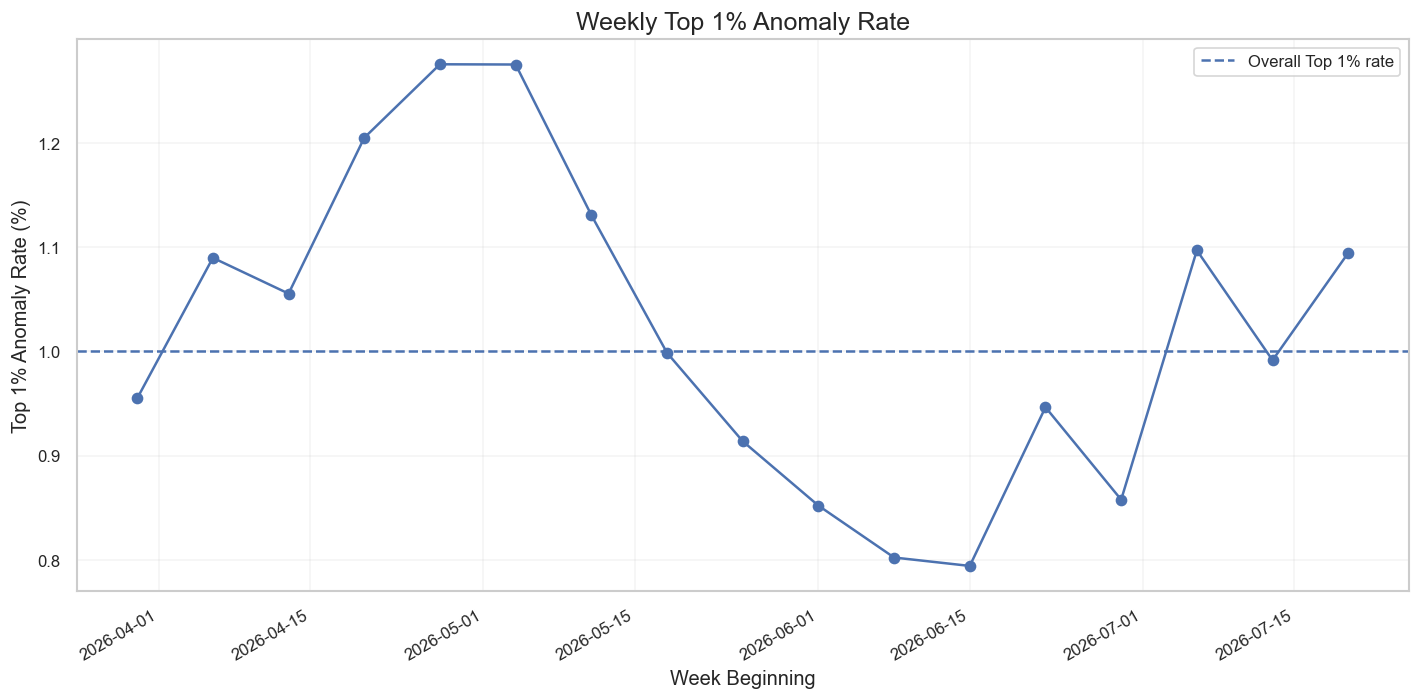

CELL 107 - ANALYSE WEEKLY ANOMALY TRENDS


,week_start,study_dates,observations,top_1_percent_count,top_0_5_percent_count,mean_daily_top_1_percent_count,top_1_percent_rate,top_0_5_percent_rate
0,2026-03-30,2,2648004,25283,"12,612.000000","12,641.500000",0.954795,0.476283
1,2026-04-06,6,7649248,83353,"42,762.000000","13,892.166667",1.089689,0.559035
2,2026-04-13,6,7491893,79066,"38,485.000000","13,177.666667",1.055354,0.513689
3,2026-04-20,2,2471256,29775,"15,004.000000","14,887.500000",1.204853,0.607141
4,2026-04-27,3,3828674,48830,"25,119.000000","16,276.666667",1.275376,0.656076
5,2026-05-04,6,7760245,98955,"50,547.000000","16,492.500000",1.275153,0.651358
6,2026-05-11,7,8529759,96446,"48,191.000000","13,778.000000",1.130700,0.564975
7,2026-05-18,5,7010458,70002,"35,506.000000","14,000.400000",0.998537,0.506472
8,2026-05-25,7,9695774,88592,"44,838.000000","12,656.000000",0.913718,0.462449
9,2026-06-01,7,8907020,75883,"36,682.000000","10,840.428571",0.851946,0.411832



Weekly anomaly trends were analysed successfully.


In [108]:
# ================================================================
# CELL 107 - ANALYSE WEEKLY ANOMALY TRENDS
# ================================================================

PART_2_WEEKLY_ANOMALY_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_weekly_anomaly_rates.png"
)


part_2_weekly_data = (
    part_2_daily_calendar
    .copy()
)


part_2_weekly_data[
    "week_start"
] = (
    part_2_weekly_data[
        "observation_date"
    ]
    -
    pd.to_timedelta(
        part_2_weekly_data[
            "observation_date"
        ].dt.dayofweek,
        unit="D"
    )
)


part_2_weekly_summary = (
    part_2_weekly_data
    .groupby(
        "week_start",
        as_index=False
    )
    .agg(
        study_dates=(
            "observation_date",
            "count"
        ),
        observations=(
            "observations",
            "sum"
        ),
        top_1_percent_count=(
            "top_1_percent_count",
            "sum"
        ),
        top_0_5_percent_count=(
            "top_0_5_percent_count",
            "sum"
        ),
        mean_daily_top_1_percent_count=(
            "top_1_percent_count",
            "mean"
        )
    )
)


part_2_weekly_summary[
    "top_1_percent_rate"
] = (
    part_2_weekly_summary[
        "top_1_percent_count"
    ]
    /
    part_2_weekly_summary[
        "observations"
    ]
    *
    100.0
)


part_2_weekly_summary[
    "top_0_5_percent_rate"
] = (
    part_2_weekly_summary[
        "top_0_5_percent_count"
    ]
    /
    part_2_weekly_summary[
        "observations"
    ]
    *
    100.0
)


figure, axis = plt.subplots(
    figsize=(
        12,
        6
    )
)


axis.plot(
    part_2_weekly_summary[
        "week_start"
    ],
    part_2_weekly_summary[
        "top_1_percent_rate"
    ],
    marker="o"
)


axis.axhline(
    PART_2_GLOBAL_TOP_1_RATE,
    linestyle="--",
    linewidth=1.5,
    label="Overall Top 1% rate"
)


axis.set_title(
    "Weekly Top 1% Anomaly Rate"
)


axis.set_xlabel(
    "Week Beginning"
)


axis.set_ylabel(
    "Top 1% Anomaly Rate (%)"
)


axis.grid(
    alpha=0.20
)


axis.legend()


figure.autofmt_xdate()


figure.tight_layout()


figure.savefig(
    PART_2_WEEKLY_ANOMALY_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


print("=" * 80)
print("CELL 107 - ANALYSE WEEKLY ANOMALY TRENDS")
print("=" * 80)


display(
    part_2_weekly_summary
)


assert int(
    part_2_weekly_summary[
        "study_dates"
    ].sum()
) == len(
    part_2_daily_summary
)


assert int(
    part_2_weekly_summary[
        "observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert PART_2_WEEKLY_ANOMALY_FIGURE.exists()


print(
    "\nWeekly anomaly trends were "
    "analysed successfully."
)

## What Cell 107 Does

This cell groups all currently available study dates into calendar weeks.

Weekly Top 1% and Top 0.5% anomaly rates are calculated so that broader temporal patterns can be seen more clearly than in the individual daily results.

Partial weeks at the beginning or end of the study period remain included and are identified by their number of available study dates.

## Key Findings — Question 4

Model 1 anomaly activity varies across the available study dates.

The daily analysis identifies individual dates with unusually high anomaly counts or anomaly rates.

The day-of-week and weekday-versus-weekend analyses provide a broader view of recurring temporal patterns, while weekly aggregation shows changes that may be less visible at the individual-day level.

The exact strongest dates, anomaly rates and day-of-week patterns are reported by the current tables and figures above.

The temporal results therefore distinguish short-term unusual dates from broader recurring patterns in anomaly activity.

# Question 5 — Are anomalies associated with certain POIs?

The previous sections identified where and when the strongest anomalies occur.

This section investigates whether anomalous observations are associated with particular types of nearby points of interest.

Raw anomaly counts alone can be misleading because some POI types occur much more frequently across the study area than others. The anomaly distributions are therefore compared with the complete BT dataset to determine whether particular POI types are over-represented or under-represented among the anomalies.

The analysis considers the nearest overall POI, distance from the nearest POI, all currently available category-specific POI distance fields, the derived transport-hub distance context and named POIs associated with the strongest anomalies.

The number of category-specific POI fields is discovered dynamically from the current ranked dataset rather than being fixed manually.

In [109]:
# ================================================================
# CELL 108 - COMPARE ANOMALIES BY NEAREST POI TYPE
# ================================================================

top_1_percent_source_sql = (
    create_part_2_anomaly_source_sql(
        "Top 1%"
    )
)


PART_2_GLOBAL_TOP_1_RATE = (
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


PART_2_GLOBAL_TOP_0_5_RATE = (
    MODEL_1_TOP_0_5_PERCENT_ROWS
    /
    MODEL_DATASET_TOTAL_ROWS
    *
    100.0
)


part_2_nearest_poi_type_summary = (
    PART_2_CONNECTION.execute(
        f"""
        WITH baseline AS (

            SELECT
                nearest_poi_type,

                COUNT(*) AS baseline_observations

            FROM read_parquet(
                {part_2_ranked_partition_sql_list},
                union_by_name = true
            )

            GROUP BY
                nearest_poi_type
        ),

        anomalies AS (

            SELECT
                nearest_poi_type,

                COUNT(*) AS top_1_percent_observations,

                COUNT_IF(
                    {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                ) AS top_0_5_percent_observations

            FROM {top_1_percent_source_sql}

            GROUP BY
                nearest_poi_type
        )

        SELECT
            baseline.nearest_poi_type,

            baseline.baseline_observations,

            COALESCE(
                anomalies.top_1_percent_observations,
                0
            ) AS top_1_percent_observations,

            COALESCE(
                anomalies.top_0_5_percent_observations,
                0
            ) AS top_0_5_percent_observations,

            (
                baseline.baseline_observations
                /
                CAST(
                    {MODEL_DATASET_TOTAL_ROWS}
                    AS DOUBLE
                )
                *
                100.0
            ) AS baseline_share_percent,

            (
                COALESCE(
                    anomalies.top_1_percent_observations,
                    0
                )
                /
                CAST(
                    {MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS}
                    AS DOUBLE
                )
                *
                100.0
            ) AS top_1_percent_share,

            (
                COALESCE(
                    anomalies.top_0_5_percent_observations,
                    0
                )
                /
                CAST(
                    {MODEL_1_TOP_0_5_PERCENT_ROWS}
                    AS DOUBLE
                )
                *
                100.0
            ) AS top_0_5_percent_share,

            (
                COALESCE(
                    anomalies.top_1_percent_observations,
                    0
                )
                /
                CAST(
                    baseline.baseline_observations
                    AS DOUBLE
                )
                *
                100.0
            ) AS top_1_percent_anomaly_rate,

            (
                (
                    COALESCE(
                        anomalies.top_1_percent_observations,
                        0
                    )
                    /
                    CAST(
                        baseline.baseline_observations
                        AS DOUBLE
                    )
                    *
                    100.0
                )
                /
                {PART_2_GLOBAL_TOP_1_RATE}
            ) AS top_1_percent_enrichment,

            (
                (
                    COALESCE(
                        anomalies.top_0_5_percent_observations,
                        0
                    )
                    /
                    CAST(
                        baseline.baseline_observations
                        AS DOUBLE
                    )
                    *
                    100.0
                )
                /
                {PART_2_GLOBAL_TOP_0_5_RATE}
            ) AS top_0_5_percent_enrichment

        FROM baseline

        LEFT JOIN anomalies

            ON
                baseline.nearest_poi_type
                =
                anomalies.nearest_poi_type

        ORDER BY
            top_1_percent_enrichment DESC
        """
    )
    .df()
)


print("=" * 80)
print("CELL 108 - COMPARE ANOMALIES BY NEAREST POI TYPE")
print("=" * 80)


print(
    f"\nOverall Top 1% anomaly rate: "
    f"{PART_2_GLOBAL_TOP_1_RATE:.4f}%"
)


print(
    f"Overall Top 0.5% anomaly rate: "
    f"{PART_2_GLOBAL_TOP_0_5_RATE:.4f}%"
)


display(
    part_2_nearest_poi_type_summary
)


assert int(
    part_2_nearest_poi_type_summary[
        "baseline_observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    part_2_nearest_poi_type_summary[
        "top_1_percent_observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_nearest_poi_type_summary[
        "top_0_5_percent_observations"
    ].sum()
) == MODEL_1_TOP_0_5_PERCENT_ROWS


assert (
    part_2_nearest_poi_type_summary[
        "top_1_percent_enrichment"
    ]
    >=
    0
).all()


print(
    "\nNearest-POI anomaly associations were "
    "calculated successfully."
)

CELL 108 - COMPARE ANOMALIES BY NEAREST POI TYPE

Overall Top 1% anomaly rate: 1.0000%
Overall Top 0.5% anomaly rate: 0.5000%


,nearest_poi_type,baseline_observations,top_1_percent_observations,top_0_5_percent_observations,baseline_share_percent,top_1_percent_share,top_0_5_percent_share,top_1_percent_anomaly_rate,top_1_percent_enrichment,top_0_5_percent_enrichment
0,bus_stations,10567,1290,941.000000,0.008860,0.108161,0.157797,12.207817,12.207811,17.810140
1,shopping_malls,11231,1064,555.000000,0.009417,0.089212,0.093068,9.473778,9.473773,9.883345
2,universities,71939,6295,"4,199.000000",0.060318,0.527807,0.704133,8.750469,8.750465,11.673763
3,supermarkets,590383,33800,"17,310.000000",0.495009,2.833975,2.902726,5.725097,5.725094,5.863982
4,fast_foods,1593572,77393,"43,967.000000",1.336138,6.489049,7.372857,4.856574,4.856571,5.518036
5,stadiums,48024,1689,954.000000,0.040266,0.141615,0.159977,3.516992,3.516990,3.973008
6,hospitals,284809,8159,"4,118.000000",0.238799,0.684095,0.690550,2.864727,2.864725,2.891759
7,offices,3459705,94389,"51,398.000000",2.900806,7.914085,8.618966,2.728238,2.728237,2.971232
8,restaurants,2709840,61706,"35,872.000000",2.272078,5.173765,6.015401,2.277109,2.277107,2.647533
9,gyms,398482,8981,"4,681.000000",0.334109,0.753016,0.784960,2.253803,2.253802,2.349413



Nearest-POI anomaly associations were calculated successfully.


## What Cell 108 Does

This cell compares anomaly activity across the type of the nearest POI.

Each POI type's anomaly rate is compared with its representation in the complete BT dataset.

An enrichment value above 1 indicates that the POI type is more common among anomalies than expected from the baseline data, while a value below 1 indicates lower-than-expected anomaly representation.

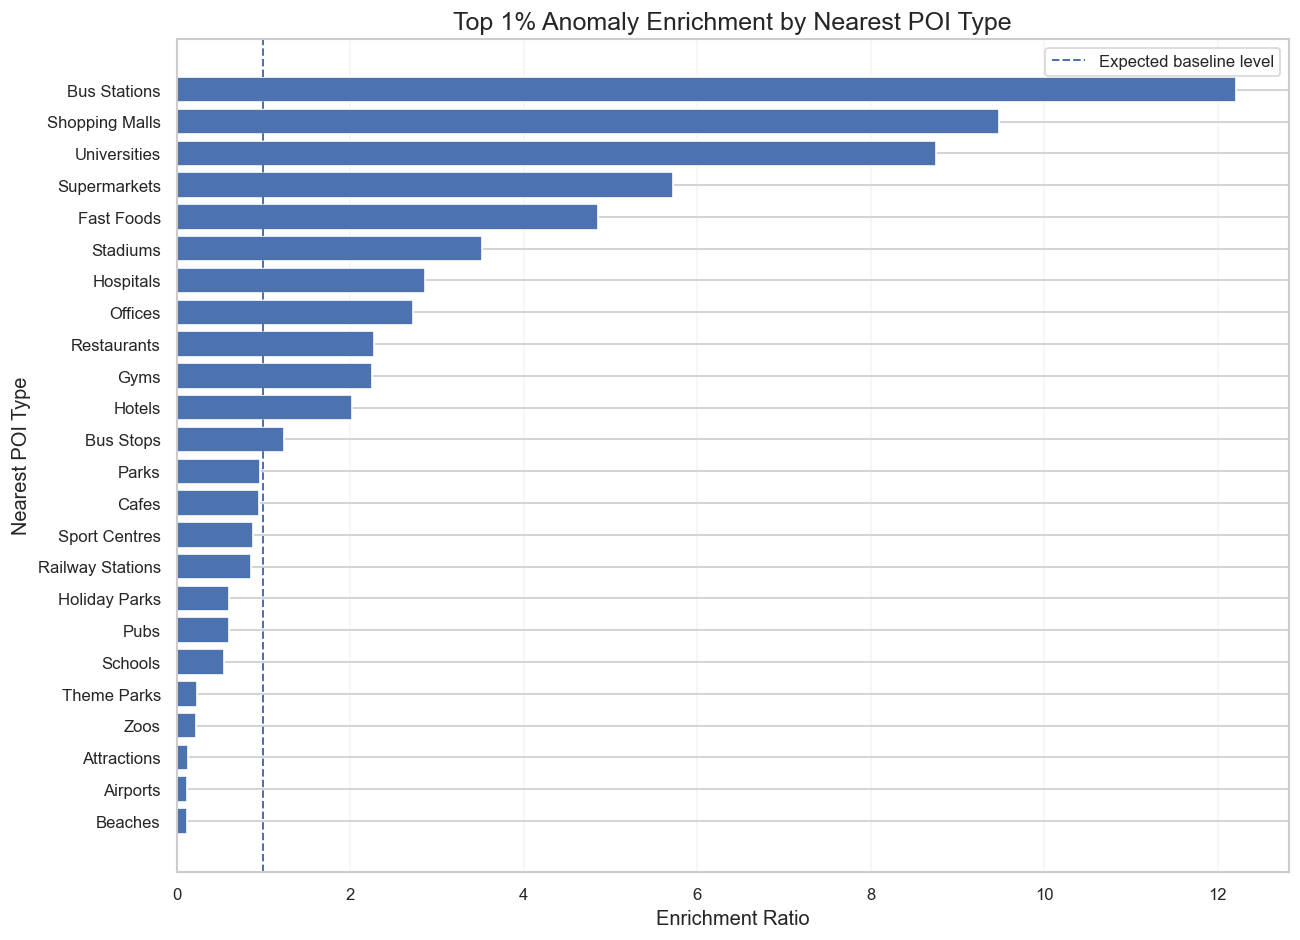

CELL 109 - PLOT NEAREST-POI ANOMALY ENRICHMENT

POI types plotted: 24

An enrichment ratio above 1 means the POI type is over-represented among Top 1% anomalies.

POI enrichment figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_nearest_poi_type_enrichment.png


In [110]:
# ================================================================
# CELL 109 - PLOT NEAREST-POI ANOMALY ENRICHMENT
# ================================================================

PART_2_POI_TYPE_ENRICHMENT_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_nearest_poi_type_enrichment.png"
)


poi_type_plot_data = (
    part_2_nearest_poi_type_summary
    .sort_values(
        "top_1_percent_enrichment",
        ascending=True
    )
    .copy()
)


poi_type_plot_data[
    "poi_label"
] = (
    poi_type_plot_data[
        "nearest_poi_type"
    ]
    .astype(
        str
    )
    .str.replace(
        "_",
        " ",
        regex=False
    )
    .str.title()
)


figure, axis = plt.subplots(
    figsize=(
        11,
        8
    )
)


axis.barh(
    poi_type_plot_data[
        "poi_label"
    ],
    poi_type_plot_data[
        "top_1_percent_enrichment"
    ]
)


axis.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="Expected baseline level"
)


axis.set_title(
    "Top 1% Anomaly Enrichment by Nearest POI Type"
)


axis.set_xlabel(
    "Enrichment Ratio"
)


axis.set_ylabel(
    "Nearest POI Type"
)


axis.grid(
    axis="x",
    alpha=0.20
)


axis.legend()


figure.tight_layout()


figure.savefig(
    PART_2_POI_TYPE_ENRICHMENT_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_POI_TYPE_ENRICHMENT_FIGURE.exists()


assert (
    PART_2_POI_TYPE_ENRICHMENT_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 109 - PLOT NEAREST-POI ANOMALY ENRICHMENT")
print("=" * 80)


print(
    f"\nPOI types plotted: "
    f"{len(poi_type_plot_data):,}"
)


print(
    "\nAn enrichment ratio above 1 means the "
    "POI type is over-represented among Top 1% anomalies."
)


print(
    "\nPOI enrichment figure saved:"
)


print(
    PART_2_POI_TYPE_ENRICHMENT_FIGURE
)

## What Cell 109 Does

This figure compares the Top 1% anomaly enrichment of each nearest POI type.

The dashed line at 1 represents the expected baseline level.

POI types above this line occur more often among Top 1% anomalies than expected from their occurrence in the complete dataset.

In [111]:
# ================================================================
# CELL 110 - COMPARE ANOMALIES BY DISTANCE FROM THE NEAREST POI
# ================================================================

PART_2_POI_DISTANCE_BANDS = [
    "0-100 m",
    "100-250 m",
    "250-500 m",
    "500 m-1 km",
    "1-2 km",
    "More than 2 km",
    "Missing"
]


poi_distance_case_sql = """
CASE
    WHEN nearest_poi_distance IS NULL
        THEN 'Missing'

    WHEN nearest_poi_distance <= 100
        THEN '0-100 m'

    WHEN nearest_poi_distance <= 250
        THEN '100-250 m'

    WHEN nearest_poi_distance <= 500
        THEN '250-500 m'

    WHEN nearest_poi_distance <= 1000
        THEN '500 m-1 km'

    WHEN nearest_poi_distance <= 2000
        THEN '1-2 km'

    ELSE 'More than 2 km'
END
"""


part_2_poi_distance_summary = (
    PART_2_CONNECTION.execute(
        f"""
        WITH baseline AS (

            SELECT
                {poi_distance_case_sql}
                    AS distance_band,

                COUNT(*) AS baseline_observations

            FROM read_parquet(
                {part_2_ranked_partition_sql_list},
                union_by_name = true
            )

            GROUP BY
                distance_band
        ),

        anomalies AS (

            SELECT
                {poi_distance_case_sql}
                    AS distance_band,

                COUNT(*) AS top_1_percent_observations,

                COUNT_IF(
                    {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                ) AS top_0_5_percent_observations

            FROM {top_1_percent_source_sql}

            GROUP BY
                distance_band
        )

        SELECT
            baseline.distance_band,

            baseline.baseline_observations,

            COALESCE(
                anomalies.top_1_percent_observations,
                0
            ) AS top_1_percent_observations,

            COALESCE(
                anomalies.top_0_5_percent_observations,
                0
            ) AS top_0_5_percent_observations,

            (
                baseline.baseline_observations
                /
                CAST(
                    {MODEL_DATASET_TOTAL_ROWS}
                    AS DOUBLE
                )
                *
                100.0
            ) AS baseline_share_percent,

            (
                COALESCE(
                    anomalies.top_1_percent_observations,
                    0
                )
                /
                CAST(
                    {MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS}
                    AS DOUBLE
                )
                *
                100.0
            ) AS top_1_percent_share,

            (
                COALESCE(
                    anomalies.top_1_percent_observations,
                    0
                )
                /
                CAST(
                    baseline.baseline_observations
                    AS DOUBLE
                )
                *
                100.0
            ) AS top_1_percent_anomaly_rate,

            (
                (
                    COALESCE(
                        anomalies.top_1_percent_observations,
                        0
                    )
                    /
                    CAST(
                        baseline.baseline_observations
                        AS DOUBLE
                    )
                    *
                    100.0
                )
                /
                {PART_2_GLOBAL_TOP_1_RATE}
            ) AS top_1_percent_enrichment

        FROM baseline

        LEFT JOIN anomalies

            ON
                baseline.distance_band
                =
                anomalies.distance_band
        """
    )
    .df()
)


distance_band_order = {
    band_name: band_number
    for band_number, band_name
    in enumerate(
        PART_2_POI_DISTANCE_BANDS
    )
}


part_2_poi_distance_summary[
    "distance_order"
] = (
    part_2_poi_distance_summary[
        "distance_band"
    ]
    .map(
        distance_band_order
    )
)


part_2_poi_distance_summary = (
    part_2_poi_distance_summary
    .sort_values(
        "distance_order"
    )
    .drop(
        columns=[
            "distance_order"
        ]
    )
    .reset_index(
        drop=True
    )
)


print("=" * 80)
print("CELL 110 - COMPARE ANOMALIES BY DISTANCE FROM THE NEAREST POI")
print("=" * 80)


display(
    part_2_poi_distance_summary
)


assert int(
    part_2_poi_distance_summary[
        "baseline_observations"
    ].sum()
) == MODEL_DATASET_TOTAL_ROWS


assert int(
    part_2_poi_distance_summary[
        "top_1_percent_observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


print(
    "\nNearest-POI distance associations were "
    "calculated successfully."
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

CELL 110 - COMPARE ANOMALIES BY DISTANCE FROM THE NEAREST POI


,distance_band,baseline_observations,top_1_percent_observations,top_0_5_percent_observations,baseline_share_percent,top_1_percent_share,top_1_percent_anomaly_rate,top_1_percent_enrichment
0,0-100 m,10895044,661475,"350,518.000000",9.135000,55.461649,6.071338,6.071335
1,100-250 m,20281971,343085,"159,603.000000",17.005512,28.766106,1.691576,1.691575
2,250-500 m,23005159,114013,"52,887.000000",19.288782,9.559468,0.495598,0.495597
3,500 m-1 km,27477160,49228,"22,059.000000",23.038352,4.127542,0.179160,0.179160
4,1-2 km,23304169,17639,"7,314.000000",19.539488,1.478949,0.075690,0.075690
5,More than 2 km,14303536,7231,"3,955.000000",11.992866,0.606286,0.050554,0.050554



Nearest-POI distance associations were calculated successfully.


## What Cell 110 Does

This cell compares anomaly activity at different distances from the nearest POI.

Observations are divided into distance bands ranging from within 100 metres to more than 2 kilometres from the nearest POI.

The baseline and anomaly distributions are compared to determine whether anomalies become more or less common close to POIs.

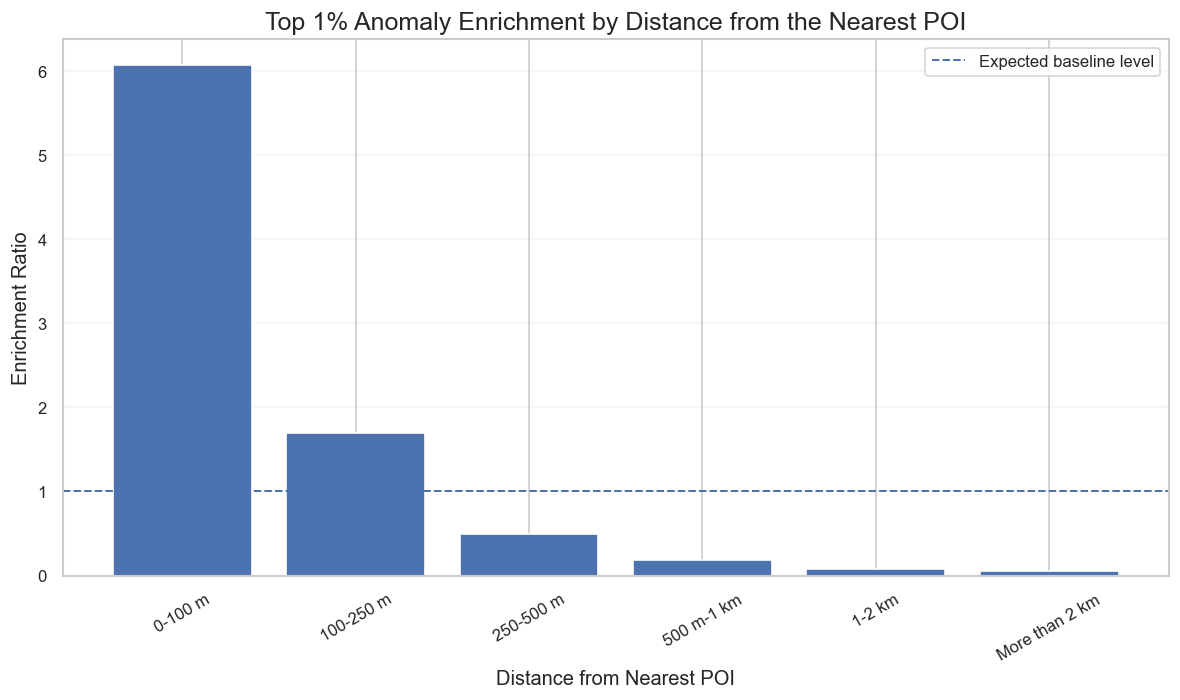

CELL 111 - PLOT ANOMALY ENRICHMENT BY POI DISTANCE

Distance bands plotted: 6

POI-distance enrichment figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_poi_distance_enrichment.png


In [112]:
# ================================================================
# CELL 111 - PLOT ANOMALY ENRICHMENT BY POI DISTANCE
# ================================================================

PART_2_POI_DISTANCE_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_poi_distance_enrichment.png"
)


poi_distance_plot_data = (
    part_2_poi_distance_summary.loc[
        part_2_poi_distance_summary[
            "distance_band"
        ]
        !=
        "Missing"
    ]
    .copy()
)


figure, axis = plt.subplots(
    figsize=(
        10,
        6
    )
)


axis.bar(
    poi_distance_plot_data[
        "distance_band"
    ],
    poi_distance_plot_data[
        "top_1_percent_enrichment"
    ]
)


axis.axhline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="Expected baseline level"
)


axis.set_title(
    "Top 1% Anomaly Enrichment by Distance from the Nearest POI"
)


axis.set_xlabel(
    "Distance from Nearest POI"
)


axis.set_ylabel(
    "Enrichment Ratio"
)


axis.tick_params(
    axis="x",
    rotation=30
)


axis.grid(
    axis="y",
    alpha=0.20
)


axis.legend()


figure.tight_layout()


figure.savefig(
    PART_2_POI_DISTANCE_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_POI_DISTANCE_FIGURE.exists()


assert (
    PART_2_POI_DISTANCE_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 111 - PLOT ANOMALY ENRICHMENT BY POI DISTANCE")
print("=" * 80)


print(
    f"\nDistance bands plotted: "
    f"{len(poi_distance_plot_data):,}"
)


print(
    "\nPOI-distance enrichment figure saved:"
)


print(
    PART_2_POI_DISTANCE_FIGURE
)

## What Cell 111 Does

This figure shows whether Top 1% anomalies are over-represented or under-represented at different distances from the nearest POI.

An enrichment ratio above 1 indicates more anomaly activity than expected from the baseline distribution.

This provides a broader test of whether strong anomaly activity tends to occur closer to identifiable places and facilities.

In [113]:
# ================================================================
# CELL 112 - COMPARE ALL POI DISTANCE CONTEXTS
# ================================================================

PART_2_POI_PROXIMITY_METRES = (
    500.0
)


if len(
    PART_2_POI_DISTANCE_COLUMNS
) == 0:

    raise ValueError(
        "No POI distance columns are available "
        "for the Part 2 POI comparison."
    )


baseline_poi_count_expressions = ",\n".join(
    [
        (
            f"COUNT_IF("
            f"{column_name} <= "
            f"{PART_2_POI_PROXIMITY_METRES}"
            f") AS {column_name}"
        )
        for column_name
        in PART_2_POI_DISTANCE_COLUMNS
    ]
)


anomaly_poi_count_expressions = ",\n".join(
    [
        (
            f"COUNT_IF("
            f"{column_name} <= "
            f"{PART_2_POI_PROXIMITY_METRES}"
            f") AS {column_name}"
        )
        for column_name
        in PART_2_POI_DISTANCE_COLUMNS
    ]
)


top_0_5_poi_count_expressions = ",\n".join(
    [
        (
            f"COUNT_IF("
            f"{column_name} <= "
            f"{PART_2_POI_PROXIMITY_METRES} "
            f"AND "
            f"{MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}"
            f") AS {column_name}"
        )
        for column_name
        in PART_2_POI_DISTANCE_COLUMNS
    ]
)


print("=" * 80)
print("CELL 112 - COMPARE ALL POI DISTANCE CONTEXTS")
print("=" * 80)


print(
    f"\nPOI distance fields to compare: "
    f"{len(PART_2_POI_DISTANCE_COLUMNS):,}"
)


print(
    "\nScanning the complete dataset for "
    "POI proximity counts..."
)


baseline_poi_counts = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {baseline_poi_count_expressions}

        FROM read_parquet(
            {part_2_ranked_partition_sql_list},
            union_by_name = true
        )
        """
    )
    .df()
)


print(
    "Calculating anomaly POI proximity counts..."
)


top_1_poi_counts = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {anomaly_poi_count_expressions}

        FROM {top_1_percent_source_sql}
        """
    )
    .df()
)


top_0_5_poi_counts = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {top_0_5_poi_count_expressions}

        FROM {top_1_percent_source_sql}
        """
    )
    .df()
)


poi_category_records = []


for (
    poi_category,
    distance_column
) in zip(
    PART_2_POI_CATEGORIES,
    PART_2_POI_DISTANCE_COLUMNS
):

    baseline_count = int(
        baseline_poi_counts.loc[
            0,
            distance_column
        ]
    )


    top_1_count = int(
        top_1_poi_counts.loc[
            0,
            distance_column
        ]
    )


    top_0_5_count = int(
        top_0_5_poi_counts.loc[
            0,
            distance_column
        ]
    )


    baseline_share = (
        baseline_count
        /
        MODEL_DATASET_TOTAL_ROWS
        *
        100.0
    )


    top_1_share = (
        top_1_count
        /
        MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
        *
        100.0
    )


    top_0_5_share = (
        top_0_5_count
        /
        MODEL_1_TOP_0_5_PERCENT_ROWS
        *
        100.0
    )


    top_1_rate = (
        (
            top_1_count
            /
            baseline_count
            *
            100.0
        )
        if baseline_count > 0
        else np.nan
    )


    top_0_5_rate = (
        (
            top_0_5_count
            /
            baseline_count
            *
            100.0
        )
        if baseline_count > 0
        else np.nan
    )


    top_1_enrichment = (
        (
            top_1_rate
            /
            PART_2_GLOBAL_TOP_1_RATE
        )
        if baseline_count > 0
        else np.nan
    )


    top_0_5_enrichment = (
        (
            top_0_5_rate
            /
            PART_2_GLOBAL_TOP_0_5_RATE
        )
        if baseline_count > 0
        else np.nan
    )


    poi_category_records.append(
        {
            "POI Category": (
                poi_category
            ),
            "Distance Column": (
                distance_column
            ),
            "Baseline Within 500m": (
                baseline_count
            ),
            "Top 1% Within 500m": (
                top_1_count
            ),
            "Top 0.5% Within 500m": (
                top_0_5_count
            ),
            "Baseline Share (%)": (
                baseline_share
            ),
            "Top 1% Share (%)": (
                top_1_share
            ),
            "Top 0.5% Share (%)": (
                top_0_5_share
            ),
            "Top 1% Anomaly Rate (%)": (
                top_1_rate
            ),
            "Top 1% Enrichment": (
                top_1_enrichment
            ),
            "Top 0.5% Enrichment": (
                top_0_5_enrichment
            )
        }
    )


part_2_poi_category_summary = (
    pd.DataFrame(
        poi_category_records
    )
    .sort_values(
        "Top 1% Enrichment",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nPOI-distance-context anomaly comparison:"
)


display(
    part_2_poi_category_summary
)


assert len(
    part_2_poi_category_summary
) == len(
    PART_2_POI_DISTANCE_COLUMNS
)


assert len(
    part_2_poi_category_summary
) == len(
    PART_2_POI_CATEGORIES
)


assert (
    part_2_poi_category_summary[
        "Baseline Within 500m"
    ]
    >
    0
).all()


print(
    f"\nAll "
    f"{len(PART_2_POI_CATEGORIES):,} "
    f"available POI distance contexts were compared "
    f"successfully."
)

CELL 112 - COMPARE ALL POI DISTANCE CONTEXTS

POI distance fields to compare: 25

Scanning the complete dataset for POI proximity counts...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Calculating anomaly POI proximity counts...

POI-distance-context anomaly comparison:


,POI Category,Distance Column,Baseline Within 500m,Top 1% Within 500m,Top 0.5% Within 500m,Baseline Share (%),Top 1% Share (%),Top 0.5% Share (%),Top 1% Anomaly Rate (%),Top 1% Enrichment,Top 0.5% Enrichment
0,bus_stations,nearest_bus_stations_distance,508620,112831,72196,0.426455,9.460362,12.106598,22.183752,22.183741,28.388936
1,universities,nearest_universities_distance,611313,110679,66211,0.512558,9.279927,11.102969,18.105128,18.105119,21.661869
2,shopping_malls,nearest_shopping_malls_distance,607510,108664,68064,0.509370,9.110979,11.413700,17.886784,17.886775,22.407502
3,gyms,nearest_gyms_distance,2747628,281520,160060,2.303761,23.604162,26.840573,10.245928,10.245923,11.650761
4,stadiums,nearest_stadiums_distance,270946,25854,13637,0.227176,2.167739,2.286798,9.542123,9.542118,10.066199
5,supermarkets,nearest_supermarkets_distance,6038037,514917,279253,5.062620,43.173432,46.828130,8.527887,8.527883,9.249782
6,hotels,nearest_hotels_distance,5781270,446740,257138,4.847333,37.457103,43.119651,7.727368,7.727364,8.895542
7,railway_stations,nearest_railway_stations_distance,2377883,169908,94006,1.993747,14.246007,15.763932,7.145347,7.145344,7.906686
8,hospitals,nearest_hospitals_distance,1529739,101173,54777,1.282617,8.482893,9.185593,6.613743,6.613739,7.161604
9,restaurants,nearest_restaurants_distance,10044966,641674,347742,8.422248,53.801426,58.313099,6.388016,6.388012,6.923698



All 25 available POI distance contexts were compared successfully.


## What Cell 112 Does

This cell compares anomaly activity within 500 metres across every POI distance context currently available in the ranked dataset.

These distance contexts include the category-specific POI distance fields together with the derived transport-hub distance field.

For each distance context, the proportion of the complete BT dataset located nearby is compared with the corresponding proportion of Top 1% and Top 0.5% anomalies.

This baseline comparison is important because common geographic contexts could otherwise produce large anomaly counts simply because they occur frequently across the study area.

The number of distance contexts analysed is discovered automatically from the current enriched dataset.

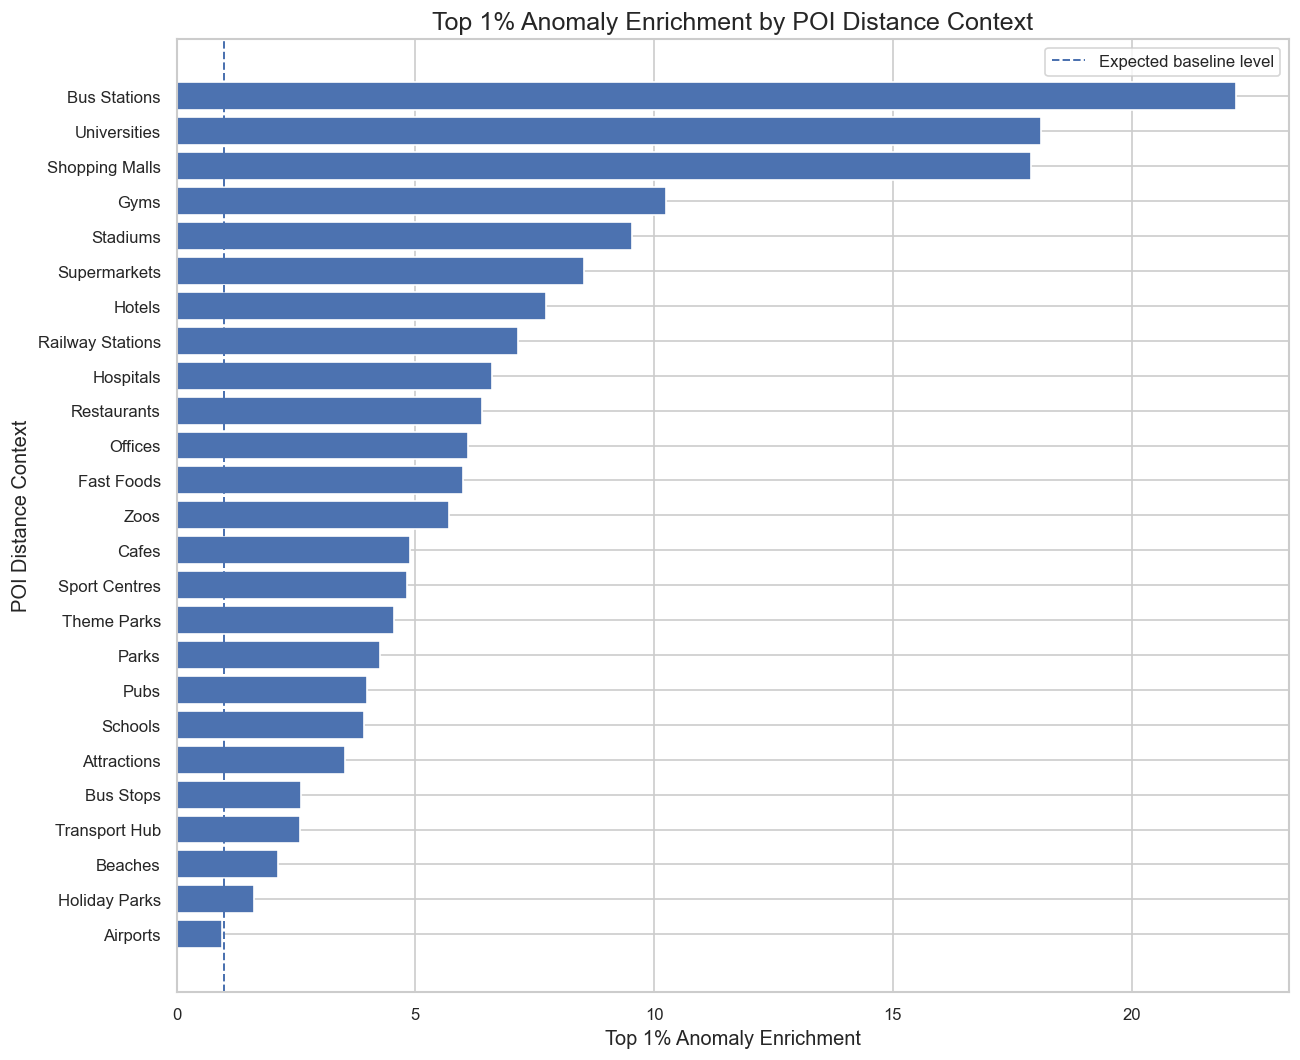


POI-distance-context anomaly enrichment figure saved successfully.


In [114]:
# ================================================================
# CELL 113 - PLOT POI-DISTANCE-CONTEXT ANOMALY ENRICHMENT
# ================================================================

PART_2_POI_CATEGORY_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_poi_category_enrichment.png"
)


poi_category_plot_data = (
    part_2_poi_category_summary
    .sort_values(
        "Top 1% Enrichment",
        ascending=True
    )
    .copy()
)


poi_category_plot_data[
    "POI Label"
] = (
    poi_category_plot_data[
        "POI Category"
    ]
    .str.replace(
        "_",
        " ",
        regex=False
    )
    .str.title()
)


figure, axis = plt.subplots(
    figsize=(
        11,
        9
    )
)


axis.barh(
    poi_category_plot_data[
        "POI Label"
    ],
    poi_category_plot_data[
        "Top 1% Enrichment"
    ]
)


axis.axvline(
    1.0,
    linestyle="--",
    linewidth=1.2,
    label="Expected baseline level"
)


axis.set_xlabel(
    "Top 1% Anomaly Enrichment"
)


axis.set_ylabel(
    "POI Distance Context"
)


axis.set_title(
    "Top 1% Anomaly Enrichment by POI Distance Context"
)


axis.legend()


plt.tight_layout()


figure.savefig(
    PART_2_POI_CATEGORY_FIGURE,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


assert (
    PART_2_POI_CATEGORY_FIGURE.exists()
)


assert (
    PART_2_POI_CATEGORY_FIGURE.stat().st_size
    >
    0
)


print(
    "\nPOI-distance-context anomaly enrichment "
    "figure saved successfully."
)

## What Cell 113 Does

This figure compares Top 1% anomaly enrichment within 500 metres across every currently available POI distance context.

An enrichment value above 1 indicates that anomalies are more common near that geographic context than would be expected from the complete dataset, while a value below 1 indicates lower-than-expected anomaly activity.

The analysed distance contexts are discovered dynamically from the current ranked dataset and include the category-specific POI distance fields together with the derived transport-hub distance field.

This provides a direct comparison of the geographic contexts most strongly associated with anomalous BT observations.

In [115]:
# ================================================================
# CELL 114 - IDENTIFY NAMED POIS NEAR THE STRONGEST ANOMALIES
# ================================================================

PART_2_NAMED_POI_ROWS = (
    100
)


top_10000_source_sql = (
    create_part_2_anomaly_source_sql(
        "Top 10,000"
    )
)


part_2_named_poi_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            nearest_poi_name,

            nearest_poi_type,

            COUNT(*) AS top_10000_observations,

            COUNT(
                DISTINCT location_id
            ) AS unique_anomaly_locations,

            COUNT(
                DISTINCT CAST(
                    en_dt
                    AS DATE
                )
            ) AS anomaly_dates,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS strongest_global_rank,

            MAX(
                {MODEL_1_ANOMALY_SCORE_COLUMN}
            ) AS maximum_anomaly_score,

            MEDIAN(
                nearest_poi_distance
            ) AS median_distance_metres,

            MIN(
                nearest_poi_distance
            ) AS minimum_distance_metres

        FROM {top_10000_source_sql}

        WHERE
            nearest_poi_name IS NOT NULL

            AND

            TRIM(
                CAST(
                    nearest_poi_name
                    AS VARCHAR
                )
            )
            <> ''

        GROUP BY
            nearest_poi_name,
            nearest_poi_type

        ORDER BY
            top_10000_observations DESC,
            unique_anomaly_locations DESC,
            strongest_global_rank ASC

        LIMIT {PART_2_NAMED_POI_ROWS}
        """
    )
    .df()
)


part_2_named_poi_summary.insert(
    0,
    "named_poi_rank",
    np.arange(
        1,
        len(
            part_2_named_poi_summary
        )
        +
        1
    )
)


print("=" * 80)
print("CELL 114 - IDENTIFY NAMED POIS NEAR THE STRONGEST ANOMALIES")
print("=" * 80)


print(
    f"\nNamed POIs displayed: "
    f"{len(part_2_named_poi_summary):,}"
)


display(
    part_2_named_poi_summary
)


assert len(
    part_2_named_poi_summary
) > 0


assert len(
    part_2_named_poi_summary
) <= PART_2_NAMED_POI_ROWS


assert (
    part_2_named_poi_summary[
        "top_10000_observations"
    ]
    >
    0
).all()


print(
    "\nNamed POIs associated with the strongest "
    "anomalies were identified successfully."
)

CELL 114 - IDENTIFY NAMED POIS NEAR THE STRONGEST ANOMALIES

Named POIs displayed: 100


,named_poi_rank,nearest_poi_name,nearest_poi_type,top_10000_observations,unique_anomaly_locations,anomaly_dates,strongest_global_rank,maximum_anomaly_score,median_distance_metres,minimum_distance_metres
0,1,Parks,parks,718,37,90,14,0.894937,56.645100,13.563095
1,2,Sandford Drive,bus_stops,214,9,48,673,0.846250,92.386865,19.653648
2,3,Central Station,bus_stops,193,3,87,955,0.835606,47.784882,15.536766
3,4,Egmont Road Substation,bus_stops,175,5,61,504,0.853474,158.155182,111.753124
4,5,Ippon Gym,gyms,171,3,87,26,0.889694,32.260640,32.106165
5,6,Leisure World,bus_stops,169,6,86,292,0.866210,71.159090,43.007699
6,7,South Academic Block,universities,147,5,69,838,0.839890,53.719899,17.413724
7,8,The Ironmaster,pubs,141,3,73,526,0.852737,71.981782,25.421502
8,9,Nando's,restaurants,140,4,87,827,0.840337,7.948433,7.948433
9,10,Thunderbird Chicken,fast_foods,136,6,59,533,0.852514,86.427884,20.836548



Named POIs associated with the strongest anomalies were identified successfully.


## What Cell 114 Does

This cell identifies named POIs associated with observations in the global Top 10,000 anomalies.

The table shows how many strong anomaly observations and unique BT locations occur near each named POI, together with the number of dates involved and the strongest global rank.

The POI names are used to provide geographic context. They do not imply that the POI itself caused the detected anomaly.

In [116]:
# ================================================================
# CELL 115 - TEST POI DISTANCE SENSITIVITY
# ================================================================

PART_2_POI_SENSITIVITY_DISTANCES = [
    250.0,
    500.0,
    1000.0
]


poi_sensitivity_records = []


print("=" * 80)
print("CELL 115 - TEST POI DISTANCE SENSITIVITY")
print("=" * 80)


for (
    poi_category,
    distance_column
) in zip(
    PART_2_POI_CATEGORIES,
    PART_2_POI_DISTANCE_COLUMNS
):

    for distance_metres in (
        PART_2_POI_SENSITIVITY_DISTANCES
    ):

        sensitivity_counts = (
            PART_2_CONNECTION.execute(
                f"""
                SELECT

                    COUNT_IF(
                        {distance_column}
                        <=
                        {distance_metres}
                    ) AS baseline_count,

                    COUNT_IF(
                        {distance_column}
                        <=
                        {distance_metres}
                        AND
                        {MODEL_1_ANOMALY_1_PERCENT_COLUMN}
                    ) AS anomaly_count

                FROM read_parquet(
                    {part_2_ranked_partition_sql_list},
                    union_by_name = true
                )
                """
            )
            .df()
        )


        baseline_count = int(
            sensitivity_counts.loc[
                0,
                "baseline_count"
            ]
        )


        anomaly_count = int(
            sensitivity_counts.loc[
                0,
                "anomaly_count"
            ]
        )


        baseline_share = (
            baseline_count
            /
            MODEL_DATASET_TOTAL_ROWS
            *
            100.0
        )


        anomaly_share = (
            anomaly_count
            /
            MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
            *
            100.0
        )


        anomaly_rate = (
            (
                anomaly_count
                /
                baseline_count
                *
                100.0
            )
            if baseline_count > 0
            else np.nan
        )


        enrichment = (
            (
                anomaly_share
                /
                baseline_share
            )
            if baseline_share > 0
            else np.nan
        )


        poi_sensitivity_records.append(
            {
                "POI Category": (
                    poi_category
                ),
                "Distance (m)": (
                    distance_metres
                ),
                "Baseline Observations": (
                    baseline_count
                ),
                "Top 1% Observations": (
                    anomaly_count
                ),
                "Baseline Share (%)": (
                    baseline_share
                ),
                "Top 1% Share (%)": (
                    anomaly_share
                ),
                "Top 1% Anomaly Rate (%)": (
                    anomaly_rate
                ),
                "Top 1% Enrichment": (
                    enrichment
                )
            }
        )


part_2_poi_distance_sensitivity = (
    pd.DataFrame(
        poi_sensitivity_records
    )
)


part_2_poi_sensitivity_pivot = (
    part_2_poi_distance_sensitivity
    .pivot(
        index="POI Category",
        columns="Distance (m)",
        values="Top 1% Enrichment"
    )
    .reset_index()
)


part_2_poi_sensitivity_pivot.columns = [
    "POI Category",
    "250 m Enrichment",
    "500 m Enrichment",
    "1000 m Enrichment"
]


part_2_poi_sensitivity_pivot[
    "Minimum Enrichment"
] = (
    part_2_poi_sensitivity_pivot[
        [
            "250 m Enrichment",
            "500 m Enrichment",
            "1000 m Enrichment"
        ]
    ]
    .min(
        axis=1
    )
)


part_2_poi_sensitivity_pivot[
    "Above Baseline at All Distances"
] = (
    part_2_poi_sensitivity_pivot[
        "Minimum Enrichment"
    ]
    >
    1.0
)


part_2_poi_sensitivity_pivot = (
    part_2_poi_sensitivity_pivot
    .sort_values(
        "Minimum Enrichment",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


display(
    part_2_poi_sensitivity_pivot
)


print(
    "\nPOI distance contexts enriched above baseline "
    "at all three distances:"
)


display(
    part_2_poi_sensitivity_pivot[
        part_2_poi_sensitivity_pivot[
            "Above Baseline at All Distances"
        ]
    ]
)


assert len(
    part_2_poi_distance_sensitivity
) == (
    len(
        PART_2_POI_CATEGORIES
    )
    *
    len(
        PART_2_POI_SENSITIVITY_DISTANCES
    )
)


assert len(
    part_2_poi_sensitivity_pivot
) == len(
    PART_2_POI_CATEGORIES
)


print(
    "\nPOI distance sensitivity was "
    "tested successfully."
)

CELL 115 - TEST POI DISTANCE SENSITIVITY


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,POI Category,250 m Enrichment,500 m Enrichment,1000 m Enrichment,Minimum Enrichment,Above Baseline at All Distances
0,universities,23.408266,18.105119,13.398776,13.398776,True
1,bus_stations,31.409796,22.183741,12.784286,12.784286,True
2,shopping_malls,28.391008,17.886775,10.264111,10.264111,True
3,stadiums,8.340743,9.542118,8.976360,8.340743,True
4,gyms,14.612529,10.245923,6.175262,6.175262,True
5,hospitals,9.644084,6.613739,5.399455,5.399455,True
6,railway_stations,9.469239,7.145344,5.012374,5.012374,True
7,supermarkets,13.967660,8.527883,4.642307,4.642307,True
8,hotels,12.804452,7.727364,4.071991,4.071991,True
9,sport_centres,5.050676,4.820528,3.821631,3.821631,True



POI distance contexts enriched above baseline at all three distances:


,POI Category,250 m Enrichment,500 m Enrichment,1000 m Enrichment,Minimum Enrichment,Above Baseline at All Distances
0,universities,23.408266,18.105119,13.398776,13.398776,True
1,bus_stations,31.409796,22.183741,12.784286,12.784286,True
2,shopping_malls,28.391008,17.886775,10.264111,10.264111,True
3,stadiums,8.340743,9.542118,8.976360,8.340743,True
4,gyms,14.612529,10.245923,6.175262,6.175262,True
5,hospitals,9.644084,6.613739,5.399455,5.399455,True
6,railway_stations,9.469239,7.145344,5.012374,5.012374,True
7,supermarkets,13.967660,8.527883,4.642307,4.642307,True
8,hotels,12.804452,7.727364,4.071991,4.071991,True
9,sport_centres,5.050676,4.820528,3.821631,3.821631,True



POI distance sensitivity was tested successfully.


## What Cell 115 Does

This cell tests whether the POI-context enrichment results depend strongly on the selected 500 metre proximity threshold.

Every currently available POI distance context is compared at 250 metres, 500 metres and 1 kilometre.

These contexts include the category-specific POI distance fields together with the derived transport-hub distance field.

A context that remains enriched at several distances provides stronger evidence of a robust geographic association than one whose enrichment appears only at a single selected distance.

The number of distance contexts included in the sensitivity analysis updates automatically with the current enriched dataset.

In [117]:
# ================================================================
# CELL 116 - COMPARE POI CONTEXT FOR CLUSTERED AND ISOLATED ANOMALIES
# ================================================================

part_2_hotspot_poi_context = (
    part_2_hotspot_candidates[
        [
            "location_id",
            "hotspot_status",
            "hotspot_id"
        ]
    ]
    .merge(
        PART_2_CONNECTION.execute(
            f"""
            SELECT
                location_id,

                strongest_nearest_poi_distance,

                strongest_nearest_poi_type,

                strongest_nearest_poi_name,

                best_global_rank,

                top_10000_count

            FROM {PART_2_LOCATION_SUMMARY_TABLE}

            WHERE
                top_10000_count > 0
            """
        )
        .df(),
        on="location_id",
        how="left"
    )
)


part_2_hotspot_poi_context[
    "named_poi_available"
] = (
    part_2_hotspot_poi_context[
        "strongest_nearest_poi_name"
    ]
    .notna()
    &
    (
        part_2_hotspot_poi_context[
            "strongest_nearest_poi_name"
        ]
        .astype(
            str
        )
        .str.strip()
        !=
        ""
    )
)


for distance_metres in [
    250,
    500,
    1000
]:

    part_2_hotspot_poi_context[
        f"within_{distance_metres}m"
    ] = (
        part_2_hotspot_poi_context[
            "strongest_nearest_poi_distance"
        ]
        <=
        distance_metres
    )


hotspot_poi_summary_records = []


for hotspot_status in [
    "Clustered",
    "Isolated"
]:

    status_data = (
        part_2_hotspot_poi_context[
            part_2_hotspot_poi_context[
                "hotspot_status"
            ]
            ==
            hotspot_status
        ]
        .copy()
    )


    most_common_type = (
        status_data[
            "strongest_nearest_poi_type"
        ]
        .dropna()
        .value_counts()
    )


    most_common_type_name = (
        most_common_type.index[
            0
        ]
        if len(
            most_common_type
        ) > 0
        else None
    )


    hotspot_poi_summary_records.append(
        {
            "Hotspot Status": (
                hotspot_status
            ),
            "Locations": (
                len(
                    status_data
                )
            ),
            "Median Nearest POI Distance (m)": (
                status_data[
                    "strongest_nearest_poi_distance"
                ]
                .median()
            ),
            "Within 250m (%)": (
                status_data[
                    "within_250m"
                ]
                .mean()
                *
                100.0
            ),
            "Within 500m (%)": (
                status_data[
                    "within_500m"
                ]
                .mean()
                *
                100.0
            ),
            "Within 1km (%)": (
                status_data[
                    "within_1000m"
                ]
                .mean()
                *
                100.0
            ),
            "Named POI Available (%)": (
                status_data[
                    "named_poi_available"
                ]
                .mean()
                *
                100.0
            ),
            "Most Common Nearest POI Type": (
                most_common_type_name
            )
        }
    )


part_2_clustered_isolated_poi_summary = (
    pd.DataFrame(
        hotspot_poi_summary_records
    )
)


part_2_clustered_poi_types = (
    part_2_hotspot_poi_context[
        part_2_hotspot_poi_context[
            "hotspot_status"
        ]
        ==
        "Clustered"
    ][
        "strongest_nearest_poi_type"
    ]
    .value_counts()
    .head(
        10
    )
    .rename_axis(
        "POI Type"
    )
    .reset_index(
        name="Clustered Locations"
    )
)


part_2_isolated_poi_types = (
    part_2_hotspot_poi_context[
        part_2_hotspot_poi_context[
            "hotspot_status"
        ]
        ==
        "Isolated"
    ][
        "strongest_nearest_poi_type"
    ]
    .value_counts()
    .head(
        10
    )
    .rename_axis(
        "POI Type"
    )
    .reset_index(
        name="Isolated Locations"
    )
)


print("=" * 80)
print("CELL 116 - COMPARE POI CONTEXT FOR CLUSTERED AND ISOLATED ANOMALIES")
print("=" * 80)


display(
    part_2_clustered_isolated_poi_summary
)


print(
    "\nMost common POI types for clustered "
    "strong anomaly locations:"
)


display(
    part_2_clustered_poi_types
)


print(
    "\nMost common POI types for isolated "
    "strong anomaly locations:"
)


display(
    part_2_isolated_poi_types
)


assert len(
    part_2_hotspot_poi_context
) == len(
    part_2_hotspot_candidates
)


assert set(
    part_2_hotspot_poi_context[
        "hotspot_status"
    ].unique()
) == {
    "Clustered",
    "Isolated"
}


print(
    "\nClustered and isolated anomaly POI "
    "contexts were compared successfully."
)

CELL 116 - COMPARE POI CONTEXT FOR CLUSTERED AND ISOLATED ANOMALIES


,Hotspot Status,Locations,Median Nearest POI Distance (m),Within 250m (%),Within 500m (%),Within 1km (%),Named POI Available (%),Most Common Nearest POI Type
0,Clustered,1009,73.818499,80.376611,93.756194,98.711596,100.000000,bus_stops
1,Isolated,288,92.372824,79.166667,90.277778,94.444444,100.000000,bus_stops



Most common POI types for clustered strong anomaly locations:


,POI Type,Clustered Locations
0,bus_stops,314
1,cafes,81
2,restaurants,79
3,fast_foods,78
4,offices,76
5,hotels,71
6,parks,62
7,pubs,54
8,sport_centres,41
9,schools,36



Most common POI types for isolated strong anomaly locations:


,POI Type,Isolated Locations
0,bus_stops,112
1,offices,25
2,restaurants,19
3,cafes,18
4,fast_foods,17
5,schools,14
6,pubs,13
7,holiday_parks,12
8,parks,12
9,beaches,11



Clustered and isolated anomaly POI contexts were compared successfully.


## What Cell 116 Does

This cell connects the geographic hotspot analysis with the POI analysis.

The 1,297 locations represented in the global Top 10,000 anomalies are separated into DBSCAN-clustered and geographically isolated locations.

Their nearest-POI distances, named-POI coverage and most common POI types are compared to determine whether larger geographic hotspots occur in different environments from isolated extreme locations.

## Key Findings — Question 5

The anomaly results show clear relationships with POI context.

Several POI categories are more strongly represented among the highest-ranked anomalies than would be expected from their occurrence in the complete BT dataset.

The distance-sensitivity analysis tests whether these relationships remain visible at 250 metres, 500 metres and 1 kilometre rather than depending on one selected threshold.

The clustered-versus-isolated comparison also examines whether strong anomaly locations contained within DBSCAN hotspots differ in their proximity to nearby POIs from geographically isolated strong locations.

The exact strongest POI categories, enrichment values and distance comparisons are reported by the current tables and figures above.

POI proximity provides geographic context and evidence of association, but it does not demonstrate that a nearby POI caused an anomaly.

# Question 6 — What makes these locations anomalous?

The previous sections identified where anomalies occur, how frequently they recur and which POIs are associated with them.

This section investigates the BT measurements that help explain why these observations appear unusual.

For every observation, Part 1 identified the primary and secondary BT measurements with the largest deviation from normal-reference behaviour. These explanation fields are now compared across different anomaly severities.

The analysis considers the most common primary explanations, the number of measurements deviating simultaneously and combinations of primary and secondary anomaly reasons.

These explanations are descriptive interpretations of the detected anomalies and should not be interpreted as formal Isolation Forest feature importance.

In [118]:
# ================================================================
# CELL 117 - SUMMARISE PRIMARY ANOMALY REASONS
# ================================================================

part_2_primary_reason_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_PRIMARY_REASON_COLUMN}
                AS primary_reason,

            COUNT(*) AS top_1_percent_observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                10000
            ) AS top_10000_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                1000
            ) AS top_1000_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                100
            ) AS top_100_observations,

            MEDIAN(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS median_primary_deviation,

            AVG(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS mean_primary_deviation,

            MAX(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS maximum_primary_deviation

        FROM {top_1_percent_source_sql}

        GROUP BY
            {MODEL_1_PRIMARY_REASON_COLUMN}

        ORDER BY
            top_10000_observations DESC,
            top_1_percent_observations DESC
        """
    )
    .df()
)


part_2_primary_reason_summary[
    "top_1_percent_share"
] = (
    part_2_primary_reason_summary[
        "top_1_percent_observations"
    ]
    /
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    *
    100.0
)


part_2_primary_reason_summary[
    "top_0_5_percent_share"
] = (
    part_2_primary_reason_summary[
        "top_0_5_percent_observations"
    ]
    /
    MODEL_1_TOP_0_5_PERCENT_ROWS
    *
    100.0
)


part_2_primary_reason_summary[
    "top_10000_share"
] = (
    part_2_primary_reason_summary[
        "top_10000_observations"
    ]
    /
    MODEL_1_TOP_10000_ROWS
    *
    100.0
)


part_2_primary_reason_summary[
    "top_1000_share"
] = (
    part_2_primary_reason_summary[
        "top_1000_observations"
    ]
    /
    MODEL_1_TOP_1000_ROWS
    *
    100.0
)


part_2_primary_reason_summary[
    "top_100_share"
] = (
    part_2_primary_reason_summary[
        "top_100_observations"
    ]
    /
    MODEL_1_TOP_100_ROWS
    *
    100.0
)


print("=" * 80)
print("CELL 117 - SUMMARISE PRIMARY ANOMALY REASONS")
print("=" * 80)


print(
    f"\nPrimary reason categories found: "
    f"{len(part_2_primary_reason_summary):,}"
)


display(
    part_2_primary_reason_summary
)


assert int(
    part_2_primary_reason_summary[
        "top_1_percent_observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_primary_reason_summary[
        "top_0_5_percent_observations"
    ].sum()
) == MODEL_1_TOP_0_5_PERCENT_ROWS


assert int(
    part_2_primary_reason_summary[
        "top_10000_observations"
    ].sum()
) == MODEL_1_TOP_10000_ROWS


assert int(
    part_2_primary_reason_summary[
        "top_1000_observations"
    ].sum()
) == MODEL_1_TOP_1000_ROWS


assert int(
    part_2_primary_reason_summary[
        "top_100_observations"
    ].sum()
) == MODEL_1_TOP_100_ROWS


print(
    "\nPrimary anomaly reasons were "
    "summarised successfully."
)

CELL 117 - SUMMARISE PRIMARY ANOMALY REASONS

Primary reason categories found: 20


,primary_reason,top_1_percent_observations,top_0_5_percent_observations,top_10000_observations,top_1000_observations,top_100_observations,median_primary_deviation,mean_primary_deviation,maximum_primary_deviation,top_1_percent_share,top_0_5_percent_share,top_10000_share,top_1000_share,top_100_share
0,High totaldownlinkvolume,936902,"477,804.000000","9,139.000000",925.000000,91.000000,"24,396.429688","52,150.645607","6,322,378.500000",78.554941,80.123286,91.390000,92.500000,91.000000
1,High indoorminutesofuse,93587,"37,420.000000",360.000000,12.000000,0.000000,"11,803.334961","13,383.379330","351,958.562500",7.846841,6.274986,3.600000,1.200000,0.000000
2,High totaluplinkvolume,40514,"21,462.000000",250.000000,31.000000,0.000000,"38,633.546875","90,328.737450","4,593,018.000000",3.396913,3.598978,2.500000,3.100000,0.000000
3,High outdoorminutesofuse,13685,"5,470.000000",141.000000,19.000000,8.000000,"3,579.875732","4,496.782530","151,227.640625",1.147425,0.917268,1.410000,1.900000,8.000000
4,High vehicularminutesofuse,89933,"42,833.000000",66.000000,0.000000,0.000000,"5,785.916504","6,900.898901","91,626.195312",7.540470,7.182696,0.660000,0.000000,0.000000
5,High totaldownlinkdataduration,502,233.000000,28.000000,13.000000,1.000000,"2,696.018066","5,524.206442","69,900.234375",0.042090,0.039072,0.280000,1.300000,1.000000
6,High s1handoverfailures,1278,839.000000,10.000000,0.000000,0.000000,295.543976,741.580879,"14,264.703125",0.107154,0.140692,0.100000,0.000000,0.000000
7,High x2handoverattempts,10650,"8,337.000000",6.000000,0.000000,0.000000,"5,507.891602","7,814.341126","75,638.742188",0.892954,1.398037,0.060000,0.000000,0.000000
8,High totaluplinkdataduration,1546,609.000000,0.000000,0.000000,0.000000,"2,468.678223","3,909.066632","34,118.550781",0.129625,0.102124,0.000000,0.000000,0.000000
9,High totalconnectionnormalreleases,1364,665.000000,0.000000,0.000000,0.000000,"1,879.580933","2,805.562938","20,665.722656",0.114365,0.111514,0.000000,0.000000,0.000000



Primary anomaly reasons were summarised successfully.


## What Cell 117 Does

This cell summarises the primary BT measurement associated with each anomalous observation.

Reason frequencies are compared across the Top 1%, Top 0.5%, Top 10,000, Top 1,000 and Top 100 anomaly groups.

This shows whether the measurements explaining the most extreme anomalies differ from those explaining the wider anomaly population.

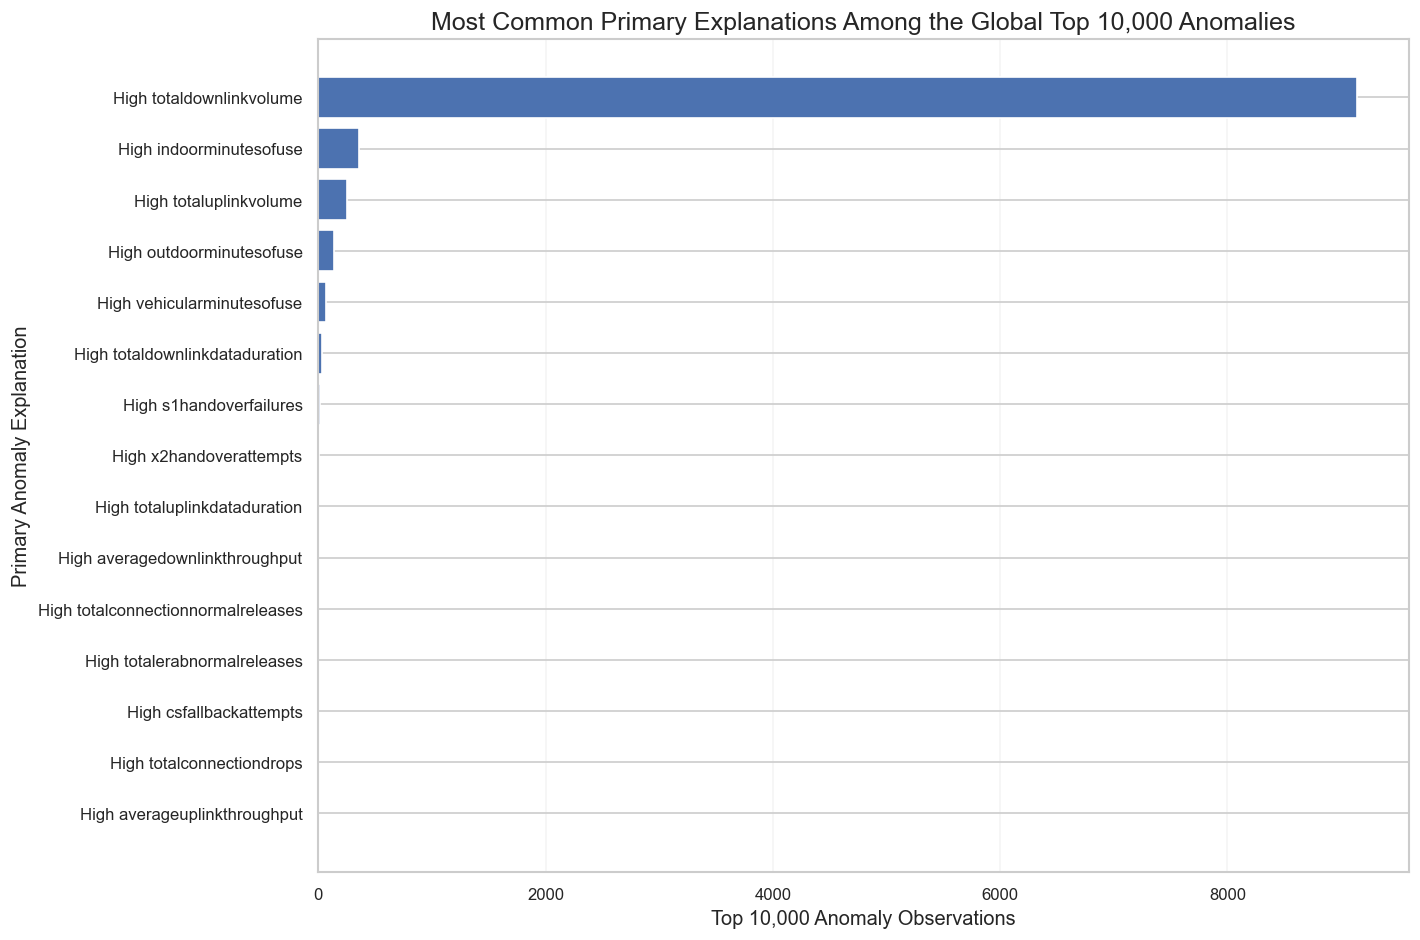

CELL 118 - PLOT THE MAIN REASONS BEHIND THE STRONGEST ANOMALIES

Primary reasons plotted: 15

Most common Top 10,000 primary reason:


,primary_reason,top_10000_observations,top_10000_share,top_0_5_percent_observations,top_1_percent_observations
0,High totaldownlinkvolume,"9,139.000000",91.390000,"477,804.000000",936902
1,High indoorminutesofuse,360.000000,3.600000,"37,420.000000",93587
2,High totaluplinkvolume,250.000000,2.500000,"21,462.000000",40514
3,High outdoorminutesofuse,141.000000,1.410000,"5,470.000000",13685
4,High vehicularminutesofuse,66.000000,0.660000,"42,833.000000",89933
5,High totaldownlinkdataduration,28.000000,0.280000,233.000000,502
6,High s1handoverfailures,10.000000,0.100000,839.000000,1278
7,High x2handoverattempts,6.000000,0.060000,"8,337.000000",10650
8,High totaluplinkdataduration,0.000000,0.000000,609.000000,1546
9,High totalconnectionnormalreleases,0.000000,0.000000,665.000000,1364



Primary-reason figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_primary_anomaly_reasons.png


In [119]:
# ================================================================
# CELL 118 - PLOT THE MAIN REASONS BEHIND THE STRONGEST ANOMALIES
# ================================================================

PART_2_REASON_PLOT_ROWS = (
    15
)


PART_2_PRIMARY_REASON_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_primary_anomaly_reasons.png"
)


primary_reason_plot_data = (
    part_2_primary_reason_summary
    .sort_values(
        "top_10000_observations",
        ascending=False
    )
    .head(
        PART_2_REASON_PLOT_ROWS
    )
    .sort_values(
        "top_10000_observations",
        ascending=True
    )
    .copy()
)


primary_reason_plot_data[
    "reason_label"
] = (
    primary_reason_plot_data[
        "primary_reason"
    ]
    .astype(
        str
    )
    .str.replace(
        "_",
        " ",
        regex=False
    )
)


figure, axis = plt.subplots(
    figsize=(
        12,
        8
    )
)


axis.barh(
    primary_reason_plot_data[
        "reason_label"
    ],
    primary_reason_plot_data[
        "top_10000_observations"
    ]
)


axis.set_title(
    "Most Common Primary Explanations Among the Global Top 10,000 Anomalies"
)


axis.set_xlabel(
    "Top 10,000 Anomaly Observations"
)


axis.set_ylabel(
    "Primary Anomaly Explanation"
)


axis.grid(
    axis="x",
    alpha=0.20
)


figure.tight_layout()


figure.savefig(
    PART_2_PRIMARY_REASON_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_PRIMARY_REASON_FIGURE.exists()


assert (
    PART_2_PRIMARY_REASON_FIGURE
    .stat()
    .st_size
    >
    0
)


assert len(
    primary_reason_plot_data
) <= PART_2_REASON_PLOT_ROWS


print("=" * 80)
print("CELL 118 - PLOT THE MAIN REASONS BEHIND THE STRONGEST ANOMALIES")
print("=" * 80)


print(
    f"\nPrimary reasons plotted: "
    f"{len(primary_reason_plot_data):,}"
)


print(
    "\nMost common Top 10,000 primary reason:"
)


display(
    part_2_primary_reason_summary[
        [
            "primary_reason",
            "top_10000_observations",
            "top_10000_share",
            "top_0_5_percent_observations",
            "top_1_percent_observations"
        ]
    ]
    .sort_values(
        "top_10000_observations",
        ascending=False
    )
    .head(
        10
    )
)


print(
    "\nPrimary-reason figure saved:"
)


print(
    PART_2_PRIMARY_REASON_FIGURE
)

## What Cell 118 Does

This figure shows the 15 most common primary explanations among the global Top 10,000 anomalies.

The primary explanation identifies the BT measurement with the largest relative deviation from its normal-reference behaviour for each observation.

Using the Top 10,000 focuses the figure on strong anomalies while retaining enough observations to identify recurring explanation patterns.

In [120]:
# ================================================================
# CELL 119 - COMPARE THE NUMBER OF SIMULTANEOUS ANOMALY REASONS
# ================================================================

part_2_total_reason_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_TOTAL_REASONS_COLUMN}
                AS total_reasons,

            COUNT(*) AS top_1_percent_observations,

            COUNT_IF(
                {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
            ) AS top_0_5_percent_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                10000
            ) AS top_10000_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                1000
            ) AS top_1000_observations,

            COUNT_IF(
                {MODEL_1_GLOBAL_RANK_COLUMN}
                <=
                100
            ) AS top_100_observations

        FROM {top_1_percent_source_sql}

        GROUP BY
            {MODEL_1_TOTAL_REASONS_COLUMN}

        ORDER BY
            total_reasons
        """
    )
    .df()
)


part_2_total_reason_summary[
    "top_1_percent_share"
] = (
    part_2_total_reason_summary[
        "top_1_percent_observations"
    ]
    /
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    *
    100.0
)


part_2_total_reason_summary[
    "top_0_5_percent_share"
] = (
    part_2_total_reason_summary[
        "top_0_5_percent_observations"
    ]
    /
    MODEL_1_TOP_0_5_PERCENT_ROWS
    *
    100.0
)


part_2_total_reason_summary[
    "top_10000_share"
] = (
    part_2_total_reason_summary[
        "top_10000_observations"
    ]
    /
    MODEL_1_TOP_10000_ROWS
    *
    100.0
)


print("=" * 80)
print("CELL 119 - COMPARE THE NUMBER OF SIMULTANEOUS ANOMALY REASONS")
print("=" * 80)


display(
    part_2_total_reason_summary
)


part_2_reason_count_overview = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            MEDIAN(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS top_1_percent_median_reasons,

            AVG(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS top_1_percent_mean_reasons,

            MAX(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS top_1_percent_maximum_reasons,

            MEDIAN(
                CASE
                    WHEN
                        {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                    THEN
                        {MODEL_1_TOTAL_REASONS_COLUMN}
                END
            ) AS top_0_5_percent_median_reasons,

            AVG(
                CASE
                    WHEN
                        {MODEL_1_ANOMALY_0_5_PERCENT_COLUMN}
                    THEN
                        {MODEL_1_TOTAL_REASONS_COLUMN}
                END
            ) AS top_0_5_percent_mean_reasons,

            MEDIAN(
                CASE
                    WHEN
                        {MODEL_1_GLOBAL_RANK_COLUMN}
                        <=
                        10000
                    THEN
                        {MODEL_1_TOTAL_REASONS_COLUMN}
                END
            ) AS top_10000_median_reasons,

            AVG(
                CASE
                    WHEN
                        {MODEL_1_GLOBAL_RANK_COLUMN}
                        <=
                        10000
                    THEN
                        {MODEL_1_TOTAL_REASONS_COLUMN}
                END
            ) AS top_10000_mean_reasons

        FROM {top_1_percent_source_sql}
        """
    )
    .df()
)


print(
    "\nReason-count overview:"
)


display(
    part_2_reason_count_overview
)


assert int(
    part_2_total_reason_summary[
        "top_1_percent_observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_total_reason_summary[
        "top_10000_observations"
    ].sum()
) == MODEL_1_TOP_10000_ROWS


assert (
    part_2_total_reason_summary[
        "total_reasons"
    ]
    .between(
        0,
        MODEL_1_TRAINING_FEATURE_COUNT
    )
    .all()
)


print(
    "\nSimultaneous anomaly-reason counts were "
    "summarised successfully."
)

CELL 119 - COMPARE THE NUMBER OF SIMULTANEOUS ANOMALY REASONS


,total_reasons,top_1_percent_observations,top_0_5_percent_observations,top_10000_observations,top_1000_observations,top_100_observations,top_1_percent_share,top_0_5_percent_share,top_10000_share
0,1,20,3.000000,0.000000,0.000000,0.000000,0.001677,0.000503,0.000000
1,2,631,41.000000,0.000000,0.000000,0.000000,0.052906,0.006875,0.000000
2,3,1347,125.000000,0.000000,0.000000,0.000000,0.112940,0.020961,0.000000
3,4,1178,158.000000,0.000000,0.000000,0.000000,0.098770,0.026495,0.000000
4,5,947,194.000000,0.000000,0.000000,0.000000,0.079402,0.032532,0.000000
5,6,778,157.000000,0.000000,0.000000,0.000000,0.065232,0.026327,0.000000
6,7,742,123.000000,0.000000,0.000000,0.000000,0.062213,0.020626,0.000000
7,8,1654,390.000000,0.000000,0.000000,0.000000,0.138680,0.065399,0.000000
8,9,3730,"1,225.000000",0.000000,0.000000,0.000000,0.312743,0.205421,0.000000
9,10,5714,"2,574.000000",0.000000,0.000000,0.000000,0.479093,0.431636,0.000000



Reason-count overview:


,top_1_percent_median_reasons,top_1_percent_mean_reasons,top_1_percent_maximum_reasons,top_0_5_percent_median_reasons,top_0_5_percent_mean_reasons,top_10000_median_reasons,top_10000_mean_reasons
0,18.000000,17.545641,27,19.000000,18.276441,22.000000,21.882500



Simultaneous anomaly-reason counts were summarised successfully.


## What Cell 119 Does

This cell examines how many BT measurements are unusually different from normal behaviour at the same time.

The `model_1_total_reasons` value counts the number of retained BT features whose explanation deviation exceeds the threshold defined in Part 1.

The comparison helps determine whether the strongest anomalies are generally associated with one unusual measurement or with broader changes across several network measurements simultaneously.

In [121]:
# ================================================================
# CELL 120 - IDENTIFY COMMON ANOMALY REASON COMBINATIONS
# ================================================================

PART_2_REASON_PAIR_ROWS = (
    30
)


part_2_reason_pair_summary = (
    PART_2_CONNECTION.execute(
        f"""
        SELECT
            {MODEL_1_PRIMARY_REASON_COLUMN}
                AS primary_reason,

            {MODEL_1_SECONDARY_REASON_COLUMN}
                AS secondary_reason,

            COUNT(*) AS top_10000_observations,

            COUNT(
                DISTINCT location_id
            ) AS unique_locations,

            COUNT(
                DISTINCT CAST(
                    en_dt
                    AS DATE
                )
            ) AS anomaly_dates,

            MIN(
                {MODEL_1_GLOBAL_RANK_COLUMN}
            ) AS strongest_global_rank,

            MEDIAN(
                {MODEL_1_PRIMARY_DEVIATION_COLUMN}
            ) AS median_primary_deviation,

            MEDIAN(
                {MODEL_1_SECONDARY_DEVIATION_COLUMN}
            ) AS median_secondary_deviation,

            AVG(
                {MODEL_1_TOTAL_REASONS_COLUMN}
            ) AS mean_total_reasons

        FROM {top_10000_source_sql}

        GROUP BY
            {MODEL_1_PRIMARY_REASON_COLUMN},
            {MODEL_1_SECONDARY_REASON_COLUMN}

        ORDER BY
            top_10000_observations DESC,
            unique_locations DESC,
            strongest_global_rank ASC

        LIMIT {PART_2_REASON_PAIR_ROWS}
        """
    )
    .df()
)


part_2_reason_pair_summary.insert(
    0,
    "reason_pair_rank",
    np.arange(
        1,
        len(
            part_2_reason_pair_summary
        )
        +
        1
    )
)


part_2_reason_pair_summary[
    "top_10000_share"
] = (
    part_2_reason_pair_summary[
        "top_10000_observations"
    ]
    /
    MODEL_1_TOP_10000_ROWS
    *
    100.0
)


print("=" * 80)
print("CELL 120 - IDENTIFY COMMON ANOMALY REASON COMBINATIONS")
print("=" * 80)


print(
    f"\nReason combinations displayed: "
    f"{len(part_2_reason_pair_summary):,}"
)


display(
    part_2_reason_pair_summary
)


assert len(
    part_2_reason_pair_summary
) > 0


assert len(
    part_2_reason_pair_summary
) <= PART_2_REASON_PAIR_ROWS


assert (
    part_2_reason_pair_summary[
        "top_10000_observations"
    ]
    >
    0
).all()


assert (
    part_2_reason_pair_summary[
        "strongest_global_rank"
    ]
    .between(
        1,
        MODEL_1_TOP_10000_ROWS
    )
    .all()
)


print(
    "\nPrimary and secondary anomaly-reason "
    "combinations were identified successfully."
)

CELL 120 - IDENTIFY COMMON ANOMALY REASON COMBINATIONS

Reason combinations displayed: 30


,reason_pair_rank,primary_reason,secondary_reason,top_10000_observations,unique_locations,anomaly_dates,strongest_global_rank,median_primary_deviation,median_secondary_deviation,mean_total_reasons,top_10000_share
0,1,High totaldownlinkvolume,High totaluplinkvolume,5530,787,90,4,"157,627.515000","50,241.185500",22.212658,55.300000
1,2,High totaldownlinkvolume,High indoorminutesofuse,2203,312,90,85,"142,195.890000","75,298.880000",21.092147,22.030000
2,3,High totaldownlinkvolume,High vehicularminutesofuse,602,93,89,90,"94,621.917000","37,064.145000",22.526578,6.020000
3,4,High totaldownlinkvolume,High outdoorminutesofuse,579,133,85,6,"76,880.060000","25,714.060000",22.112263,5.790000
4,5,High indoorminutesofuse,High totaldownlinkvolume,288,127,77,528,"71,145.285000","54,643.473500",20.722222,2.880000
5,6,High totaluplinkvolume,High totaldownlinkvolume,214,159,62,138,"161,733.620000","104,509.602000",21.532710,2.140000
6,7,High totaldownlinkvolume,High totaldownlinkdataduration,104,44,50,623,"73,500.885000","21,988.672500",22.740385,1.040000
7,8,High totaldownlinkvolume,High s1handoverfailures,95,14,28,673,"16,897.283000","9,169.586000",22.505263,0.950000
8,9,High outdoorminutesofuse,High totaldownlinkvolume,68,51,21,1,"22,346.103000","16,592.540000",21.852941,0.680000
9,10,High indoorminutesofuse,High totaluplinkvolume,67,42,10,201,"78,005.620000","61,943.992000",20.746269,0.670000



Primary and secondary anomaly-reason combinations were identified successfully.


## What Cell 120 Does

This cell identifies the most common combinations of primary and secondary explanations among the global Top 10,000 anomalies.

The table shows how often each pair occurs, how many different BT locations and dates are involved and the strongest global anomaly rank associated with the combination.

This helps identify whether particular BT measurements repeatedly become unusual together rather than appearing independently.

In [122]:
# ================================================================
# CELL 121 - GROUP ANOMALY REASONS INTO BT MEASUREMENT FAMILIES
# ================================================================

def classify_bt_reason_family(
    reason_value
):

    if pd.isna(
        reason_value
    ):

        return (
            "Unknown"
        )


    reason_text = (
        str(
            reason_value
        )
        .lower()
        .replace(
            "high ",
            ""
        )
        .replace(
            "low ",
            ""
        )
        .strip()
    )


    if (
        "throughput" in reason_text
        or
        "volume" in reason_text
        or
        "dataduration" in reason_text
    ):

        return (
            "Data Volume / Throughput"
        )


    if (
        "minutesofuse" in reason_text
        or
        "numberofconnections" in reason_text
    ):

        return (
            "Usage / Mobility"
        )


    if (
        "rsrp" in reason_text
        or
        "rsrq" in reason_text
    ):

        return (
            "Signal"
        )


    if (
        "handover" in reason_text
    ):

        return (
            "Handovers"
        )


    if (
        "connectionblock" in reason_text
        or
        "connectiondrop" in reason_text
        or
        "connectionnormalrelease" in reason_text
        or
        "erabblock" in reason_text
        or
        "erabdrop" in reason_text
        or
        "erabnormalrelease" in reason_text
        or
        "csfallback" in reason_text
    ):

        return (
            "Connection / Network Quality"
        )


    return (
        "Other"
    )


part_2_reason_family_detail = (
    part_2_primary_reason_summary
    .copy()
)


part_2_reason_family_detail[
    "reason_family"
] = (
    part_2_reason_family_detail[
        "primary_reason"
    ]
    .apply(
        classify_bt_reason_family
    )
)


part_2_reason_family_summary = (
    part_2_reason_family_detail
    .groupby(
        "reason_family",
        as_index=False
    )
    .agg(
        top_1_percent_observations=(
            "top_1_percent_observations",
            "sum"
        ),
        top_0_5_percent_observations=(
            "top_0_5_percent_observations",
            "sum"
        ),
        top_10000_observations=(
            "top_10000_observations",
            "sum"
        ),
        top_1000_observations=(
            "top_1000_observations",
            "sum"
        ),
        top_100_observations=(
            "top_100_observations",
            "sum"
        )
    )
)


part_2_reason_family_summary[
    "top_1_percent_share"
] = (
    part_2_reason_family_summary[
        "top_1_percent_observations"
    ]
    /
    MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS
    *
    100.0
)


part_2_reason_family_summary[
    "top_10000_share"
] = (
    part_2_reason_family_summary[
        "top_10000_observations"
    ]
    /
    MODEL_1_TOP_10000_ROWS
    *
    100.0
)


part_2_reason_family_summary[
    "top_100_share"
] = (
    part_2_reason_family_summary[
        "top_100_observations"
    ]
    /
    MODEL_1_TOP_100_ROWS
    *
    100.0
)


part_2_reason_family_summary = (
    part_2_reason_family_summary
    .sort_values(
        "top_10000_observations",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("=" * 80)
print("CELL 121 - GROUP ANOMALY REASONS INTO BT MEASUREMENT FAMILIES")
print("=" * 80)


print(
    "\nMeasurement-family summary:"
)


display(
    part_2_reason_family_summary
)


print(
    "\nIndividual reasons and assigned families:"
)


display(
    part_2_reason_family_detail[
        [
            "primary_reason",
            "reason_family",
            "top_1_percent_observations",
            "top_10000_observations",
            "top_100_observations"
        ]
    ]
)


assert int(
    part_2_reason_family_summary[
        "top_1_percent_observations"
    ].sum()
) == MODEL_1_TOP_1_PERCENT_OUTPUT_ROWS


assert int(
    part_2_reason_family_summary[
        "top_10000_observations"
    ].sum()
) == MODEL_1_TOP_10000_ROWS


assert int(
    part_2_reason_family_summary[
        "top_100_observations"
    ].sum()
) == MODEL_1_TOP_100_ROWS


print(
    "\nAnomaly explanations were grouped into "
    "BT measurement families successfully."
)

CELL 121 - GROUP ANOMALY REASONS INTO BT MEASUREMENT FAMILIES

Measurement-family summary:


,reason_family,top_1_percent_observations,top_0_5_percent_observations,top_10000_observations,top_1000_observations,top_100_observations,top_1_percent_share,top_10000_share,top_100_share
0,Data Volume / Throughput,981501,"500,443.000000","9,417.000000",969.000000,92.000000,82.294363,94.170000,92.000000
1,Usage / Mobility,197212,"85,730.000000",567.000000,31.000000,8.000000,16.535323,5.670000,8.000000
2,Handovers,11937,"9,182.000000",16.000000,0.000000,0.000000,1.000863,0.160000,0.000000
3,Connection / Network Quality,2021,981.000000,0.000000,0.000000,0.000000,0.169452,0.000000,0.000000



Individual reasons and assigned families:


,primary_reason,reason_family,top_1_percent_observations,top_10000_observations,top_100_observations
0,High totaldownlinkvolume,Data Volume / Throughput,936902,"9,139.000000",91.000000
1,High indoorminutesofuse,Usage / Mobility,93587,360.000000,0.000000
2,High totaluplinkvolume,Data Volume / Throughput,40514,250.000000,0.000000
3,High outdoorminutesofuse,Usage / Mobility,13685,141.000000,8.000000
4,High vehicularminutesofuse,Usage / Mobility,89933,66.000000,0.000000
5,High totaldownlinkdataduration,Data Volume / Throughput,502,28.000000,1.000000
6,High s1handoverfailures,Handovers,1278,10.000000,0.000000
7,High x2handoverattempts,Handovers,10650,6.000000,0.000000
8,High totaluplinkdataduration,Data Volume / Throughput,1546,0.000000,0.000000
9,High totalconnectionnormalreleases,Connection / Network Quality,1364,0.000000,0.000000



Anomaly explanations were grouped into BT measurement families successfully.


## What Cell 121 Does

This cell groups the individual anomaly explanation variables into broader BT measurement families.

The families distinguish data volume and throughput, usage and mobility, signal measurements, handovers and connection or network-quality behaviour.

This provides a higher-level interpretation of the anomaly explanations while retaining the individual reason analysis from the previous cells.

## Key Findings — Question 6

The explanation results show which retained BT measurements differ most strongly from normal-reference behaviour among the strongest Model 1 anomalies.

The analysis considers the most common primary explanations, recurring primary-secondary explanation combinations and the number of measurements simultaneously exceeding the explanation threshold.

Grouping the individual measurements into broader BT measurement families provides a higher-level interpretation of the strongest anomaly behaviour.

The exact dominant measurements, explanation shares and measurement-family proportions are reported by the current tables and figures above.

These explanation fields remain descriptive post-model interpretations rather than formal Isolation Forest feature-importance values.

# Question 7 — Which locations should BT investigate first?

The previous sections examined anomaly strength, recurrence, anomaly rate, geographic hotspots, nearby POIs and the BT measurements explaining the detected behaviour.

This section combines the main anomaly evidence into a practical location-priority ranking.

Each anomalous location is compared using four equally weighted measures:

1. anomaly strength;
2. Top 1% anomaly frequency;
3. recurrence across different dates;
4. Top 1% anomaly rate.

Each measure is converted to a percentile score across the anomalous locations before the four scores are averaged.

DBSCAN hotspot membership and POI information are retained as additional investigation context but do not increase the priority score.

The resulting ranking is a transparent post-model prioritisation tool and is not an additional machine-learning model.

In [123]:
# ================================================================
# CELL 122 - BUILD THE LOCATION PRIORITY RANKING
# ================================================================

PART_2_PRIORITY_MINIMUM_OBSERVATIONS = (
    30
)


# ------------------------------------------------
# Build percentile-based priority measures
# ------------------------------------------------

part_2_location_priority = (
    PART_2_CONNECTION.execute(
        f"""
        WITH eligible_locations AS (

            SELECT
                location_id,
                xbin,
                ybin,
                location_observations,

                best_global_rank,
                maximum_anomaly_score,

                top_100_count,
                top_1000_count,
                top_10000_count,

                top_1_percent_count,
                top_0_5_percent_count,

                top_1_percent_rate,
                top_0_5_percent_rate,

                top_1_percent_anomalous_days,

                strongest_anomaly_date,

                strongest_nearest_poi_distance,
                strongest_nearest_poi_type,
                strongest_nearest_poi_name,

                strongest_primary_reason,
                strongest_primary_deviation

            FROM {PART_2_LOCATION_SUMMARY_TABLE}

            WHERE
                top_1_percent_count > 0

                AND

                location_observations
                >=
                {PART_2_PRIORITY_MINIMUM_OBSERVATIONS}
        ),

        scored_locations AS (

            SELECT
                *,

                PERCENT_RANK() OVER (
                    ORDER BY
                        best_global_rank DESC
                ) AS strength_percentile,

                PERCENT_RANK() OVER (
                    ORDER BY
                        top_1_percent_count ASC
                ) AS frequency_percentile,

                PERCENT_RANK() OVER (
                    ORDER BY
                        top_1_percent_anomalous_days ASC
                ) AS recurrence_percentile,

                PERCENT_RANK() OVER (
                    ORDER BY
                        top_1_percent_rate ASC
                ) AS anomaly_rate_percentile

            FROM eligible_locations
        )

        SELECT
            *,

            (
                (
                    strength_percentile
                    +
                    frequency_percentile
                    +
                    recurrence_percentile
                    +
                    anomaly_rate_percentile
                )
                /
                4.0
                *
                100.0
            ) AS priority_score

        FROM scored_locations

        ORDER BY
            priority_score DESC,
            best_global_rank ASC,
            location_id
        """
    )
    .df()
)


# ------------------------------------------------
# Add final priority rank
# ------------------------------------------------

part_2_location_priority.insert(
    0,
    "priority_rank",
    np.arange(
        1,
        len(
            part_2_location_priority
        )
        +
        1
    )
)


# ------------------------------------------------
# Add DBSCAN hotspot context
# ------------------------------------------------

priority_hotspot_lookup = (
    part_2_hotspot_candidates[
        [
            "location_id",
            "hotspot_status",
            "hotspot_id"
        ]
    ]
    .drop_duplicates(
        subset=[
            "location_id"
        ]
    )
    .copy()
)


part_2_location_priority = (
    part_2_location_priority
    .merge(
        priority_hotspot_lookup,
        on="location_id",
        how="left"
    )
)


part_2_location_priority[
    "hotspot_status"
] = (
    part_2_location_priority[
        "hotspot_status"
    ]
    .fillna(
        "Not in Top 10,000 hotspot analysis"
    )
)


part_2_location_priority[
    "hotspot_id"
] = (
    part_2_location_priority[
        "hotspot_id"
    ]
    .fillna(
        "Not applicable"
    )
)


# ------------------------------------------------
# Convert coordinates for later maps
# ------------------------------------------------

priority_longitudes, priority_latitudes = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        part_2_location_priority[
            "xbin"
        ].to_numpy(),
        part_2_location_priority[
            "ybin"
        ].to_numpy()
    )
)


part_2_location_priority[
    "longitude"
] = priority_longitudes


part_2_location_priority[
    "latitude"
] = priority_latitudes


# ------------------------------------------------
# Create simple evidence flags
# ------------------------------------------------

part_2_location_priority[
    "global_top_10000_location"
] = (
    part_2_location_priority[
        "top_10000_count"
    ]
    >
    0
)


part_2_location_priority[
    "contains_top_0_5_percent_anomaly"
] = (
    part_2_location_priority[
        "top_0_5_percent_count"
    ]
    >
    0
)


part_2_location_priority[
    "in_geographic_hotspot"
] = (
    part_2_location_priority[
        "hotspot_status"
    ]
    ==
    "Clustered"
)


part_2_location_priority[
    "named_poi_available"
] = (
    part_2_location_priority[
        "strongest_nearest_poi_name"
    ]
    .notna()
    &
    (
        part_2_location_priority[
            "strongest_nearest_poi_name"
        ]
        .astype(
            str
        )
        .str.strip()
        !=
        ""
    )
)


# ------------------------------------------------
# Summary
# ------------------------------------------------

part_2_priority_summary = pd.DataFrame(
    {
        "Measure": [
            "Top 1% anomalous locations",
            "Locations meeting minimum observation requirement",
            "Minimum observations required",
            "Priority measures",
            "Highest priority score",
            "Lowest priority score",
            "Top 10,000 locations in priority dataset",
            "Priority locations in DBSCAN hotspots",
            "Priority locations with named POI context"
        ],
        "Value": [
            int(
                part_2_location_frequency_summary.loc[
                    0,
                    "locations_with_top_1_percent_anomaly"
                ]
            ),
            len(
                part_2_location_priority
            ),
            PART_2_PRIORITY_MINIMUM_OBSERVATIONS,
            4,
            float(
                part_2_location_priority[
                    "priority_score"
                ].max()
            ),
            float(
                part_2_location_priority[
                    "priority_score"
                ].min()
            ),
            int(
                part_2_location_priority[
                    "global_top_10000_location"
                ].sum()
            ),
            int(
                part_2_location_priority[
                    "in_geographic_hotspot"
                ].sum()
            ),
            int(
                part_2_location_priority[
                    "named_poi_available"
                ].sum()
            )
        ]
    }
)


print("=" * 80)
print("CELL 122 - BUILD THE LOCATION PRIORITY RANKING")
print("=" * 80)


display(
    part_2_priority_summary
)


assert len(
    part_2_location_priority
) > 0


assert (
    part_2_location_priority[
        "location_observations"
    ]
    >=
    PART_2_PRIORITY_MINIMUM_OBSERVATIONS
).all()


assert (
    part_2_location_priority[
        "priority_score"
    ]
    .between(
        0,
        100
    )
    .all()
)


assert (
    part_2_location_priority[
        "priority_rank"
    ]
    .is_unique
)


assert int(
    part_2_location_priority[
        "priority_rank"
    ].min()
) == 1


assert int(
    part_2_location_priority[
        "priority_rank"
    ].max()
) == len(
    part_2_location_priority
)


print(
    "\nThe location priority ranking was "
    "created successfully."
)

CELL 122 - BUILD THE LOCATION PRIORITY RANKING


,Measure,Value
0,Top 1% anomalous locations,"126,990.000000"
1,Locations meeting minimum observation requirement,"124,440.000000"
2,Minimum observations required,30.000000
3,Priority measures,4.000000
4,Highest priority score,99.464798
5,Lowest priority score,0.000201
6,"Top 10,000 locations in priority dataset","1,297.000000"
7,Priority locations in DBSCAN hotspots,"1,009.000000"
8,Priority locations with named POI context,"124,440.000000"



The location priority ranking was created successfully.


## What Cell 122 Does

This cell creates a practical priority score for locations containing Top 1% anomalies.

Four pieces of anomaly evidence are given equal importance: strength, frequency, recurrence and anomaly rate. Each measure is first converted to a percentile before the four values are averaged into a score between 0 and 100.

A minimum of 30 observations is required so that very high anomaly rates based on only a small number of observations do not dominate the ranking.

Hotspot membership and POI information are added afterwards as investigation context and do not affect the priority score.

In [124]:
# ================================================================
# CELL 123 - DISPLAY THE TOP 100 PRIORITY LOCATIONS
# ================================================================

PART_2_PRIORITY_LOCATION_ROWS = (
    100
)


part_2_top_100_priority_locations = (
    part_2_location_priority
    .head(
        PART_2_PRIORITY_LOCATION_ROWS
    )
    .copy()
)


part_2_priority_display_columns = [
    "priority_rank",
    "location_id",
    "priority_score",
    "best_global_rank",
    "maximum_anomaly_score",
    "top_1_percent_count",
    "top_0_5_percent_count",
    "top_1_percent_rate",
    "top_1_percent_anomalous_days",
    "location_observations",
    "hotspot_status",
    "hotspot_id",
    "strongest_anomaly_date",
    "strongest_nearest_poi_distance",
    "strongest_nearest_poi_type",
    "strongest_nearest_poi_name",
    "strongest_primary_reason",
    "longitude",
    "latitude"
]


print("=" * 80)
print("CELL 123 - DISPLAY THE TOP 100 PRIORITY LOCATIONS")
print("=" * 80)


print(
    f"\nPriority locations displayed: "
    f"{len(part_2_top_100_priority_locations):,}"
)


display(
    part_2_top_100_priority_locations[
        part_2_priority_display_columns
    ]
)


assert len(
    part_2_top_100_priority_locations
) == PART_2_PRIORITY_LOCATION_ROWS


assert (
    part_2_top_100_priority_locations[
        "priority_score"
    ]
    .is_monotonic_decreasing
)


assert int(
    part_2_top_100_priority_locations.loc[
        0,
        "priority_rank"
    ]
) == 1


print(
    "\nThe Top 100 practical investigation "
    "priorities were identified successfully."
)

CELL 123 - DISPLAY THE TOP 100 PRIORITY LOCATIONS

Priority locations displayed: 100


,priority_rank,location_id,priority_score,best_global_rank,maximum_anomaly_score,top_1_percent_count,top_0_5_percent_count,top_1_percent_rate,top_1_percent_anomalous_days,location_observations,hotspot_status,hotspot_id,strongest_anomaly_date,strongest_nearest_poi_distance,strongest_nearest_poi_type,strongest_nearest_poi_name,strongest_primary_reason,longitude,latitude
0,1,612200_5639850,99.464798,4,0.900098,90,90.000000,100.000000,90,90,Clustered,Hotspot 2,2026-04-11,13.583948,restaurants,Georges,High totaldownlinkvolume,-1.404423,50.899396
1,2,579050_5619250,99.463994,9,0.896785,90,90.000000,100.000000,90,90,Clustered,Hotspot 4,2026-05-24,20.964314,cafes,Big Wigs,High totaldownlinkvolume,-1.880164,50.719671
2,3,658800_5635900,99.463392,14,0.894937,90,89.000000,100.000000,90,90,Clustered,Hotspot 5,2026-05-05,94.089750,parks,Parks,High totaldownlinkvolume,-0.743916,50.852970
3,4,579100_5619200,99.463191,15,0.894322,90,90.000000,100.000000,90,90,Clustered,Hotspot 4,2026-06-27,21.492162,fast_foods,Five Guys,High totaldownlinkvolume,-1.879467,50.719215
4,5,658750_5635900,99.462789,22,0.890139,90,90.000000,100.000000,90,90,Clustered,Hotspot 5,2026-05-05,45.396052,parks,Parks,High totaldownlinkvolume,-0.744626,50.852983
5,6,579000_5619200,99.462588,26,0.889694,90,90.000000,100.000000,90,90,Clustered,Hotspot 4,2026-06-27,38.910268,gyms,Ippon Gym,High totaldownlinkvolume,-1.880883,50.719228
6,7,658750_5635950,99.462387,27,0.889472,90,90.000000,100.000000,90,90,Clustered,Hotspot 5,2026-05-05,45.521190,parks,Parks,High totaldownlinkvolume,-0.744604,50.853433
7,8,579000_5619250,99.460177,63,0.882936,90,89.000000,100.000000,90,90,Clustered,Hotspot 4,2026-04-11,32.260640,gyms,Ippon Gym,High totaldownlinkvolume,-1.880872,50.719678
8,9,612100_5640650,99.459976,79,0.881007,90,90.000000,100.000000,90,90,Clustered,Hotspot 2,2026-04-11,29.338017,offices,The Marlands Management,High totaldownlinkvolume,-1.405599,50.906607
9,10,612050_5640100,99.459775,90,0.879411,90,90.000000,100.000000,90,90,Clustered,Hotspot 2,2026-04-11,47.207267,restaurants,Thaikhun,High totaldownlinkvolume,-1.406478,50.901673



The Top 100 practical investigation priorities were identified successfully.


## What Cell 123 Does

This cell displays the 100 BT locations with the highest combined investigation priority.

The table retains the individual anomaly measures behind the priority score so that the ranking remains transparent.

It also shows geographic hotspot membership, nearby POI information, the strongest anomaly date and the primary BT explanation to provide practical context for further investigation.

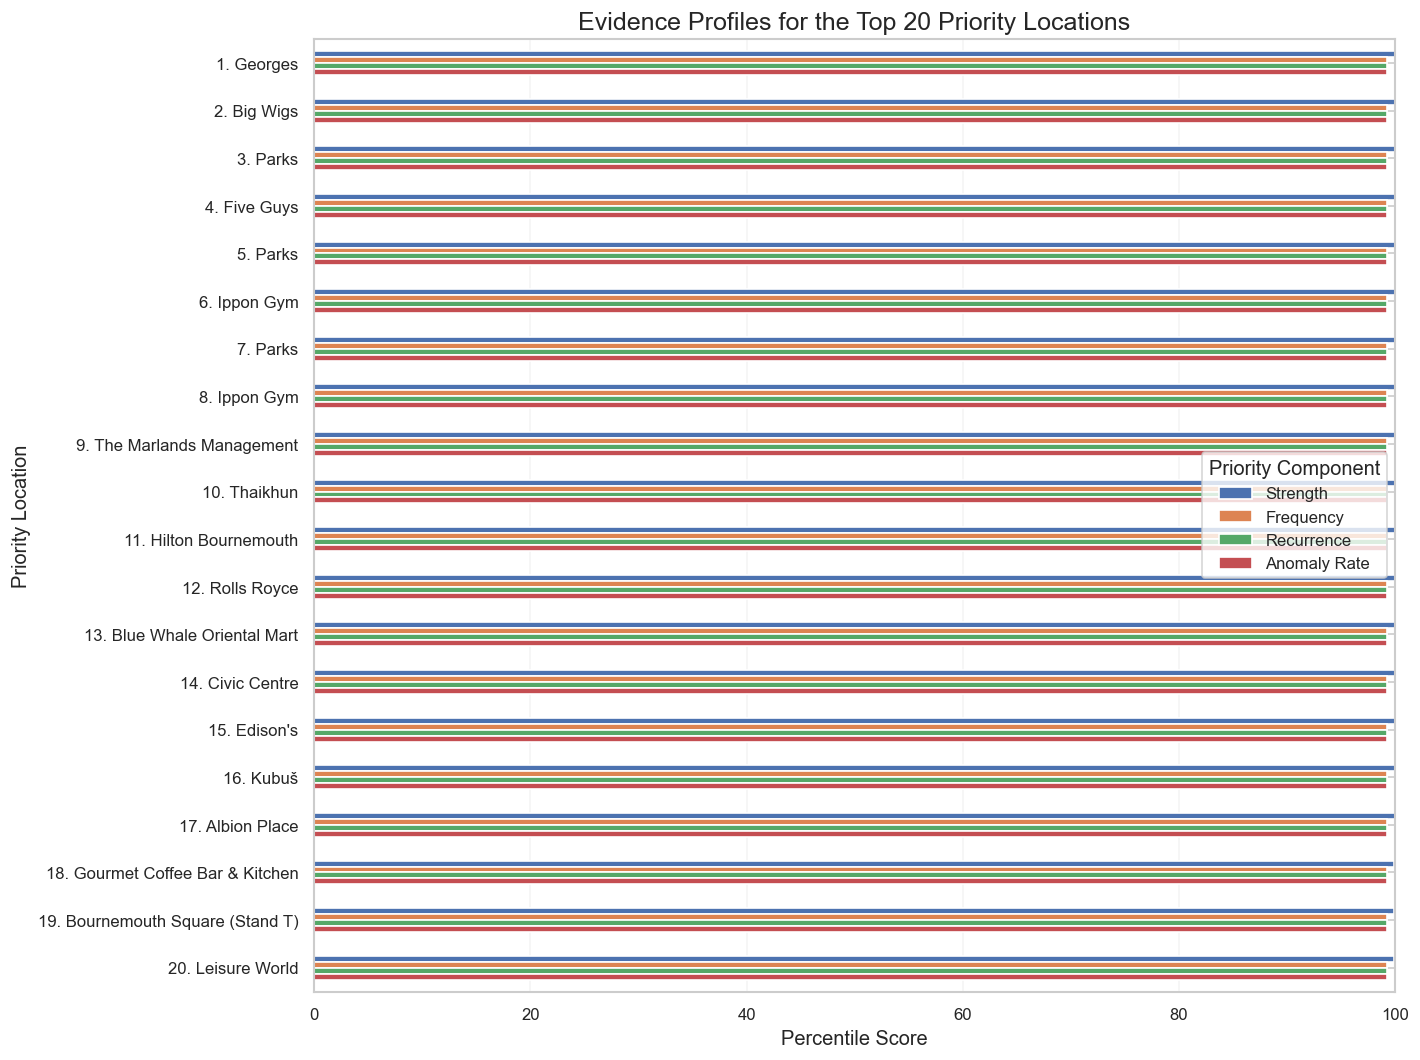

CELL 124 - SHOW THE EVIDENCE BEHIND THE HIGHEST PRIORITIES

Priority locations profiled: 20

Each bar component shows the location's relative standing for one priority measure.

Priority-profile figure saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\figures\model_1_priority_location_profiles.png


In [125]:
# ================================================================
# CELL 124 - SHOW THE EVIDENCE BEHIND THE HIGHEST PRIORITIES
# ================================================================

PART_2_PRIORITY_PROFILE_ROWS = (
    20
)


PART_2_PRIORITY_PROFILE_FIGURE = (
    PART_2_FIGURES_FOLDER
    /
    "model_1_priority_location_profiles.png"
)


priority_profile_data = (
    part_2_location_priority
    .head(
        PART_2_PRIORITY_PROFILE_ROWS
    )
    .copy()
)


priority_profile_labels = []


for _, priority_row in (
    priority_profile_data.iterrows()
):

    poi_name = (
        priority_row[
            "strongest_nearest_poi_name"
        ]
    )


    if (
        pd.notna(
            poi_name
        )
        and
        str(
            poi_name
        ).strip()
        !=
        ""
    ):

        label = (
            f"{int(priority_row['priority_rank'])}. "
            f"{poi_name}"
        )

    else:

        label = (
            f"{int(priority_row['priority_rank'])}. "
            f"{priority_row['location_id']}"
        )


    priority_profile_labels.append(
        label
    )


priority_profile_plot = pd.DataFrame(
    {
        "Strength": (
            priority_profile_data[
                "strength_percentile"
            ]
            .to_numpy()
            *
            100.0
        ),
        "Frequency": (
            priority_profile_data[
                "frequency_percentile"
            ]
            .to_numpy()
            *
            100.0
        ),
        "Recurrence": (
            priority_profile_data[
                "recurrence_percentile"
            ]
            .to_numpy()
            *
            100.0
        ),
        "Anomaly Rate": (
            priority_profile_data[
                "anomaly_rate_percentile"
            ]
            .to_numpy()
            *
            100.0
        )
    },
    index=priority_profile_labels
)


figure, axis = plt.subplots(
    figsize=(
        12,
        9
    )
)


priority_profile_plot.plot(
    kind="barh",
    ax=axis
)


axis.set_title(
    "Evidence Profiles for the Top 20 Priority Locations"
)


axis.set_xlabel(
    "Percentile Score"
)


axis.set_ylabel(
    "Priority Location"
)


axis.set_xlim(
    0,
    100
)


axis.grid(
    axis="x",
    alpha=0.20
)


axis.invert_yaxis()


axis.legend(
    title="Priority Component"
)


figure.tight_layout()


figure.savefig(
    PART_2_PRIORITY_PROFILE_FIGURE,
    dpi=PART_2_FIGURE_DPI,
    bbox_inches="tight"
)


plt.show()


assert PART_2_PRIORITY_PROFILE_FIGURE.exists()


assert (
    PART_2_PRIORITY_PROFILE_FIGURE
    .stat()
    .st_size
    >
    0
)


print("=" * 80)
print("CELL 124 - SHOW THE EVIDENCE BEHIND THE HIGHEST PRIORITIES")
print("=" * 80)


print(
    f"\nPriority locations profiled: "
    f"{len(priority_profile_data):,}"
)


print(
    "\nEach bar component shows the location's "
    "relative standing for one priority measure."
)


print(
    "\nPriority-profile figure saved:"
)


print(
    PART_2_PRIORITY_PROFILE_FIGURE
)

## What Cell 124 Does

This figure separates the combined priority score into its four underlying components for the 20 highest-priority locations.

A location may therefore rank highly because it contains an extremely strong anomaly, because anomalies occur frequently, because they recur across many dates, because its anomaly rate is unusually high, or because several of these patterns occur together.

This keeps the final priority ranking interpretable rather than treating the combined score as a black-box result.

In [126]:
# ================================================================
# CELL 125 - CREATE THE INTERACTIVE PRIORITY MAP
# ================================================================

PART_2_PRIORITY_MAP_FILE = (
    PART_2_MAPS_FOLDER
    /
    "model_1_priority_locations_map.html"
)


priority_map_data = (
    part_2_top_100_priority_locations
    .copy()
)


# ------------------------------------------------
# Create base map
# ------------------------------------------------

priority_map = folium.Map(
    location=[
        float(
            priority_map_data[
                "latitude"
            ].median()
        ),
        float(
            priority_map_data[
                "longitude"
            ].median()
        )
    ],
    zoom_start=8,
    control_scale=True,
    tiles="CartoDB positron"
)


# ------------------------------------------------
# Define BT study area
# ------------------------------------------------

study_area_corner_x = [
    530000,
    668000
]


study_area_corner_y = [
    5590000,
    5650000
]


study_area_longitude, study_area_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        study_area_corner_x,
        study_area_corner_y
    )
)


# ------------------------------------------------
# Define 5 km analysis buffer
# ------------------------------------------------

buffer_corner_x = [
    525000,
    673000
]


buffer_corner_y = [
    5585000,
    5655000
]


buffer_longitude, buffer_latitude = (
    PART_2_COORDINATE_TRANSFORMER.transform(
        buffer_corner_x,
        buffer_corner_y
    )
)


# ------------------------------------------------
# Add BT study-area rectangle
# ------------------------------------------------

folium.Rectangle(
    bounds=[
        [
            study_area_latitude[0],
            study_area_longitude[0]
        ],
        [
            study_area_latitude[1],
            study_area_longitude[1]
        ]
    ],
    tooltip="BT study area",
    fill=False,
    weight=3
).add_to(
    priority_map
)


# ------------------------------------------------
# Add 5 km buffer rectangle
# ------------------------------------------------

folium.Rectangle(
    bounds=[
        [
            buffer_latitude[0],
            buffer_longitude[0]
        ],
        [
            buffer_latitude[1],
            buffer_longitude[1]
        ]
    ],
    tooltip="5 km analysis buffer",
    fill=False,
    weight=2,
    dash_array="6"
).add_to(
    priority_map
)


# ------------------------------------------------
# Create priority-location layer
# ------------------------------------------------

priority_location_layer = folium.FeatureGroup(
    name="Top 100 Priority Locations",
    show=True
)


# ------------------------------------------------
# Add priority locations
# ------------------------------------------------

for _, priority_row in (
    priority_map_data.iterrows()
):

    poi_name = (
        priority_row[
            "strongest_nearest_poi_name"
        ]
    )


    if (
        pd.isna(
            poi_name
        )
        or
        str(
            poi_name
        ).strip()
        ==
        ""
    ):

        poi_name = (
            "No named POI available"
        )


    poi_type = (
        priority_row[
            "strongest_nearest_poi_type"
        ]
    )


    if (
        pd.isna(
            poi_type
        )
        or
        str(
            poi_type
        ).strip()
        ==
        ""
    ):

        poi_type = (
            "No POI type available"
        )


    hotspot_id = (
        priority_row[
            "hotspot_id"
        ]
    )


    primary_reason = (
        priority_row[
            "strongest_primary_reason"
        ]
    )


    popup_html = (
        f"<b>Priority rank:</b> "
        f"{int(priority_row['priority_rank']):,}"
        f"<br>"

        f"<b>Priority score:</b> "
        f"{priority_row['priority_score']:.2f}"
        f"<br>"

        f"<b>Location ID:</b> "
        f"{priority_row['location_id']}"
        f"<br>"

        f"<b>Best global anomaly rank:</b> "
        f"{int(priority_row['best_global_rank']):,}"
        f"<br>"

        f"<b>Maximum anomaly score:</b> "
        f"{priority_row['maximum_anomaly_score']:.6f}"
        f"<br>"

        f"<b>Top 1% anomalies:</b> "
        f"{int(priority_row['top_1_percent_count']):,}"
        f"<br>"

        f"<b>Top 0.5% anomalies:</b> "
        f"{int(priority_row['top_0_5_percent_count']):,}"
        f"<br>"

        f"<b>Top 1% anomaly rate:</b> "
        f"{priority_row['top_1_percent_rate']:.2f}%"
        f"<br>"

        f"<b>Anomalous dates:</b> "
        f"{int(priority_row['top_1_percent_anomalous_days']):,}"
        f"<br>"

        f"<b>Hotspot:</b> "
        f"{hotspot_id}"
        f"<br>"

        f"<b>Nearest named POI:</b> "
        f"{poi_name}"
        f"<br>"

        f"<b>Nearest POI type:</b> "
        f"{poi_type}"
        f"<br>"

        f"<b>Primary explanation:</b> "
        f"{primary_reason}"
        f"<br>"

        f"<b>Strongest anomaly date:</b> "
        f"{priority_row['strongest_anomaly_date']}"
    )


    marker_radius = (
        10
        if int(
            priority_row[
                "priority_rank"
            ]
        )
        <=
        10
        else
        6
    )


    folium.CircleMarker(
        location=[
            float(
                priority_row[
                    "latitude"
                ]
            ),
            float(
                priority_row[
                    "longitude"
                ]
            )
        ],
        radius=marker_radius,
        popup=folium.Popup(
            popup_html,
            max_width=450
        ),
        tooltip=(
            f"Priority "
            f"{int(priority_row['priority_rank'])}: "
            f"{priority_row['location_id']}"
        ),
        fill=True,
        fill_opacity=0.75,
        weight=1
    ).add_to(
        priority_location_layer
    )


priority_location_layer.add_to(
    priority_map
)


# ------------------------------------------------
# Add layer control
# ------------------------------------------------

folium.LayerControl(
    collapsed=False
).add_to(
    priority_map
)


# ------------------------------------------------
# Fit map to complete 5 km analysis buffer
# ------------------------------------------------

priority_map.fit_bounds(
    [
        [
            min(
                buffer_latitude
            ),
            min(
                buffer_longitude
            )
        ],
        [
            max(
                buffer_latitude
            ),
            max(
                buffer_longitude
            )
        ]
    ]
)


# ------------------------------------------------
# Save map
# ------------------------------------------------

priority_map.save(
    PART_2_PRIORITY_MAP_FILE
)


# ------------------------------------------------
# Display map
# ------------------------------------------------

display(
    priority_map
)


# ------------------------------------------------
# Validate saved map
# ------------------------------------------------

assert PART_2_PRIORITY_MAP_FILE.exists()


assert (
    PART_2_PRIORITY_MAP_FILE
    .stat()
    .st_size
    >
    0
)


assert len(
    priority_map_data
) == PART_2_PRIORITY_LOCATION_ROWS


# ------------------------------------------------
# Final output
# ------------------------------------------------

print("=" * 80)
print("CELL 125 - CREATE THE INTERACTIVE PRIORITY MAP")
print("=" * 80)


print(
    f"\nPriority locations mapped: "
    f"{len(priority_map_data):,}"
)


print(
    "\nBT study area and 5 km analysis buffer "
    "were added to the map."
)


print(
    "\nInteractive priority map saved:"
)


print(
    PART_2_PRIORITY_MAP_FILE
)


print(
    "\nThe interactive priority map was "
    "created successfully."
)

CELL 125 - CREATE THE INTERACTIVE PRIORITY MAP

Priority locations mapped: 100

BT study area and 5 km analysis buffer were added to the map.

Interactive priority map saved:
C:\Users\adaml\OneDrive\Desktop\BT_Dissertation_AL\model_1\maps\model_1_priority_locations_map.html

The interactive priority map was created successfully.


## What Cell 125 Does

This cell maps the 100 highest-priority BT locations identified by the combined investigation ranking.

Each popup shows the priority score together with the underlying anomaly strength, frequency, recurrence, hotspot membership, nearby POI context, strongest anomaly date and primary BT explanation.

The BT study area and 5 km analysis buffer are also displayed so that the locations can be interpreted within the geographic extent used throughout the project.

In [127]:
# ================================================================
# CELL 126 - TEST PRIORITY-RANKING SENSITIVITY
# ================================================================

PART_2_PRIORITY_SENSITIVITY_TOP_N = (
    100
)


priority_sensitivity_weights = {
    "Equal Weight": {
        "strength_percentile": 0.25,
        "frequency_percentile": 0.25,
        "recurrence_percentile": 0.25,
        "anomaly_rate_percentile": 0.25
    },
    "Strength Focused": {
        "strength_percentile": 0.40,
        "frequency_percentile": 0.20,
        "recurrence_percentile": 0.20,
        "anomaly_rate_percentile": 0.20
    },
    "Persistence Focused": {
        "strength_percentile": 0.20,
        "frequency_percentile": 0.25,
        "recurrence_percentile": 0.35,
        "anomaly_rate_percentile": 0.20
    },
    "Rate Focused": {
        "strength_percentile": 0.20,
        "frequency_percentile": 0.20,
        "recurrence_percentile": 0.20,
        "anomaly_rate_percentile": 0.40
    }
}


part_2_priority_sensitivity = (
    part_2_location_priority[
        [
            "location_id",
            "priority_rank",
            "priority_score",
            "strength_percentile",
            "frequency_percentile",
            "recurrence_percentile",
            "anomaly_rate_percentile"
        ]
    ]
    .copy()
)


scenario_rank_columns = {}


for scenario_name, scenario_weights in (
    priority_sensitivity_weights.items()
):

    safe_name = (
        scenario_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    score_column = (
        f"{safe_name}_score"
    )


    rank_column = (
        f"{safe_name}_rank"
    )


    part_2_priority_sensitivity[
        score_column
    ] = (
        (
            part_2_priority_sensitivity[
                "strength_percentile"
            ]
            *
            scenario_weights[
                "strength_percentile"
            ]
        )
        +
        (
            part_2_priority_sensitivity[
                "frequency_percentile"
            ]
            *
            scenario_weights[
                "frequency_percentile"
            ]
        )
        +
        (
            part_2_priority_sensitivity[
                "recurrence_percentile"
            ]
            *
            scenario_weights[
                "recurrence_percentile"
            ]
        )
        +
        (
            part_2_priority_sensitivity[
                "anomaly_rate_percentile"
            ]
            *
            scenario_weights[
                "anomaly_rate_percentile"
            ]
        )
    ) * 100.0


    part_2_priority_sensitivity[
        rank_column
    ] = (
        part_2_priority_sensitivity[
            score_column
        ]
        .rank(
            method="first",
            ascending=False
        )
        .astype(
            int
        )
    )


    scenario_rank_columns[
        scenario_name
    ] = rank_column


equal_top_100_locations = set(
    part_2_priority_sensitivity.loc[
        part_2_priority_sensitivity[
            scenario_rank_columns[
                "Equal Weight"
            ]
        ]
        <=
        PART_2_PRIORITY_SENSITIVITY_TOP_N,
        "location_id"
    ]
)


priority_sensitivity_records = []


equal_rank_series = (
    part_2_priority_sensitivity[
        scenario_rank_columns[
            "Equal Weight"
        ]
    ]
)


for scenario_name, rank_column in (
    scenario_rank_columns.items()
):

    scenario_top_100_locations = set(
        part_2_priority_sensitivity.loc[
            part_2_priority_sensitivity[
                rank_column
            ]
            <=
            PART_2_PRIORITY_SENSITIVITY_TOP_N,
            "location_id"
        ]
    )


    top_100_overlap = len(
        equal_top_100_locations
        &
        scenario_top_100_locations
    )


    rank_correlation = (
        equal_rank_series
        .corr(
            part_2_priority_sensitivity[
                rank_column
            ]
        )
    )


    priority_sensitivity_records.append(
        {
            "Scenario": scenario_name,
            "Top 100 Overlap with Equal Weight": (
                top_100_overlap
            ),
            "Top 100 Overlap (%)": (
                top_100_overlap
                /
                PART_2_PRIORITY_SENSITIVITY_TOP_N
                *
                100.0
            ),
            "Rank Correlation with Equal Weight": (
                rank_correlation
            )
        }
    )


part_2_priority_sensitivity_summary = (
    pd.DataFrame(
        priority_sensitivity_records
    )
)


top_20_sets = []


for rank_column in (
    scenario_rank_columns.values()
):

    top_20_sets.append(
        set(
            part_2_priority_sensitivity.loc[
                part_2_priority_sensitivity[
                    rank_column
                ]
                <=
                20,
                "location_id"
            ]
        )
    )


locations_in_every_top_20 = (
    set.intersection(
        *top_20_sets
    )
)


part_2_robust_top_20_locations = (
    part_2_location_priority[
        part_2_location_priority[
            "location_id"
        ]
        .isin(
            locations_in_every_top_20
        )
    ]
    .copy()
    .sort_values(
        "priority_rank"
    )
)


print("=" * 80)
print("CELL 126 - TEST PRIORITY-RANKING SENSITIVITY")
print("=" * 80)


print(
    "\nPriority sensitivity summary:"
)


display(
    part_2_priority_sensitivity_summary
)


print(
    "\nLocations remaining in the Top 20 "
    "under every weighting scenario:"
)


display(
    part_2_robust_top_20_locations[
        [
            "priority_rank",
            "location_id",
            "priority_score",
            "best_global_rank",
            "top_1_percent_count",
            "top_1_percent_rate",
            "top_1_percent_anomalous_days",
            "strongest_nearest_poi_name"
        ]
    ]
)


assert len(
    part_2_priority_sensitivity
) == len(
    part_2_location_priority
)


assert (
    part_2_priority_sensitivity_summary[
        "Top 100 Overlap with Equal Weight"
    ]
    .between(
        0,
        100
    )
    .all()
)


assert (
    part_2_priority_sensitivity_summary[
        "Rank Correlation with Equal Weight"
    ]
    .between(
        -1,
        1
    )
    .all()
)


print(
    "\nPriority-ranking sensitivity was "
    "tested successfully."
)

CELL 126 - TEST PRIORITY-RANKING SENSITIVITY

Priority sensitivity summary:


,Scenario,Top 100 Overlap with Equal Weight,Top 100 Overlap (%),Rank Correlation with Equal Weight
0,Equal Weight,100,100.000000,1.000000
1,Strength Focused,100,100.000000,0.993681
2,Persistence Focused,100,100.000000,0.999741
3,Rate Focused,100,100.000000,0.995970



Locations remaining in the Top 20 under every weighting scenario:


,priority_rank,location_id,priority_score,best_global_rank,top_1_percent_count,top_1_percent_rate,top_1_percent_anomalous_days,strongest_nearest_poi_name
0,1,612200_5639850,99.464798,4,90,100.000000,90,Georges
1,2,579050_5619250,99.463994,9,90,100.000000,90,Big Wigs
2,3,658800_5635900,99.463392,14,90,100.000000,90,Parks
3,4,579100_5619200,99.463191,15,90,100.000000,90,Five Guys
4,5,658750_5635900,99.462789,22,90,100.000000,90,Parks
5,6,579000_5619200,99.462588,26,90,100.000000,90,Ippon Gym
6,7,658750_5635950,99.462387,27,90,100.000000,90,Parks
7,8,579000_5619250,99.460177,63,90,100.000000,90,Ippon Gym
8,9,612100_5640650,99.459976,79,90,100.000000,90,The Marlands Management
9,10,612050_5640100,99.459775,90,90,100.000000,90,Thaikhun



Priority-ranking sensitivity was tested successfully.


### What Cell 126 Does

This cell checks whether the final location-priority ranking depends heavily on the chosen weighting of its four components.

The original ranking gives equal importance to anomaly strength, frequency, recurrence and anomaly rate.

It is compared with alternative versions that place greater importance on different types of anomaly behaviour.

The cell then checks:

- how many of the same locations remain within the Top 100;
- and how similar the overall ordering of locations remains.

If the rankings remain similar under these different assumptions, this provides evidence that the final investigation priorities are not being driven by one particular choice of weights.

## Key Findings — Question 7

The combined priority ranking identifies locations that show strong evidence across several complementary anomaly measures rather than relying on anomaly strength alone.

The ranking incorporates anomaly strength, frequency, anomaly rate and recurrence.

DBSCAN hotspot membership and POI information provide additional geographic investigation context but do not contribute directly to the priority score.

The sensitivity analysis compares the equal-weight ranking with alternative weighting assumptions to test whether the main recommendations remain stable.

The exact highest-priority locations, priority scores, Top 100 overlap and rank correlations are reported by the current tables above.

The final ranking therefore provides BT with a transparent way to identify locations where several forms of anomalous behaviour occur together.

# Question 8 — What outputs has Part 2 produced?

The final section saves the main Part 2 results and verifies that the completed analysis outputs are available.

Only a small number of useful summary tables are saved. The larger working datasets created during the analysis remain in the notebook or existing Model 1 resources and are not duplicated unnecessarily.

The final checks also confirm that the principal figures and interactive maps created throughout Part 2 are present and non-empty.

In [128]:
# ================================================================
# CELL 127 - SAVE THE FINAL PART 2 TABLES
# ================================================================

part_2_final_table_outputs = [
    {
        "Output": "Strongest locations",
        "Data": (
            part_2_top_100_strongest_locations
            .copy()
        ),
        "File": PART_2_LOCATION_SUMMARY_FILE
    },
    {
        "Output": "Geographic hotspots",
        "Data": (
            part_2_hotspot_summary
            .copy()
        ),
        "File": PART_2_HOTSPOT_SUMMARY_FILE
    },
    {
        "Output": "Daily anomaly summary",
        "Data": (
            part_2_daily_summary
            .copy()
        ),
        "File": PART_2_DAILY_SUMMARY_FILE
    },
    {
        "Output": "POI category summary",
        "Data": (
            part_2_poi_category_summary
            .copy()
        ),
        "File": PART_2_POI_SUMMARY_FILE
    },
    {
        "Output": "Priority locations",
        "Data": (
            part_2_top_100_priority_locations[
                part_2_priority_display_columns
            ]
            .copy()
        ),
        "File": PART_2_PRIORITY_LOCATIONS_FILE
    }
]


part_2_saved_table_records = []


for table_output in (
    part_2_final_table_outputs
):

    output_name = (
        table_output[
            "Output"
        ]
    )


    output_data = (
        table_output[
            "Data"
        ]
    )


    output_file = (
        table_output[
            "File"
        ]
    )


    output_data.to_csv(
        output_file,
        index=False
    )


    assert output_file.exists()


    assert (
        output_file.stat().st_size
        >
        0
    )


    saved_table_rows = (
        pd.read_csv(
            output_file
        )
        .shape[
            0
        ]
    )


    assert saved_table_rows == len(
        output_data
    )


    part_2_saved_table_records.append(
        {
            "Output": output_name,
            "Rows": len(
                output_data
            ),
            "Columns": len(
                output_data.columns
            ),
            "File Size (MB)": round(
                output_file.stat().st_size
                /
                (
                    1024
                    **
                    2
                ),
                4
            ),
            "File": str(
                output_file
            )
        }
    )


part_2_saved_table_summary = (
    pd.DataFrame(
        part_2_saved_table_records
    )
)


print("=" * 80)
print("CELL 127 - SAVE THE FINAL PART 2 TABLES")
print("=" * 80)


display(
    part_2_saved_table_summary
)


assert len(
    part_2_saved_table_summary
) == 5


assert (
    part_2_saved_table_summary[
        "Rows"
    ]
    >
    0
).all()


print(
    "\nFive final Part 2 summary tables "
    "were saved successfully."
)

CELL 127 - SAVE THE FINAL PART 2 TABLES


,Output,Rows,Columns,File Size (MB),File
0,Strongest locations,100,21,0.020600,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
1,Geographic hotspots,55,19,0.009400,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
2,Daily anomaly summary,90,13,0.012200,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
3,POI category summary,25,11,0.004300,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...
4,Priority locations,100,19,0.021000,C:\Users\adaml\OneDrive\Desktop\BT_Dissertatio...



Five final Part 2 summary tables were saved successfully.


## What Cell 127 Does

This cell saves the five main Part 2 summary tables.

The outputs contain:

- the 100 strongest anomaly locations;
- the geographic hotspot summary;
- the complete daily anomaly summary for the current study period;
- the POI-distance-context comparison for all currently available distance fields;
- the Top 100 investigation-priority locations.

Only these compact summary tables are saved so that the final project folder does not contain unnecessary duplicate datasets.

In [129]:
# ================================================================
# CELL 128 - VERIFY THE FINAL PART 2 TABLES
# ================================================================

part_2_expected_table_checks = [
    {
        "Output": "Strongest locations",
        "File": PART_2_LOCATION_SUMMARY_FILE,
        "Expected Rows": 100
    },
    {
        "Output": "Geographic hotspots",
        "File": PART_2_HOTSPOT_SUMMARY_FILE,
        "Expected Rows": (
            PART_2_DBSCAN_CLUSTER_COUNT
        )
    },
    {
        "Output": "Daily anomaly summary",
        "File": PART_2_DAILY_SUMMARY_FILE,
        "Expected Rows": int(
            part_2_field_summary.loc[
                0,
                "unique_dates"
            ]
        )
    },
    {
        "Output": "POI category summary",
        "File": PART_2_POI_SUMMARY_FILE,
        "Expected Rows": len(
            PART_2_POI_CATEGORIES
        )
    },
    {
        "Output": "Priority locations",
        "File": PART_2_PRIORITY_LOCATIONS_FILE,
        "Expected Rows": 100
    }
]


part_2_table_verification_records = []


for table_check in (
    part_2_expected_table_checks
):

    output_file = (
        table_check[
            "File"
        ]
    )


    expected_rows = int(
        table_check[
            "Expected Rows"
        ]
    )


    file_exists = (
        output_file.exists()
    )


    if file_exists:

        saved_table = pd.read_csv(
            output_file
        )


        actual_rows = len(
            saved_table
        )


        actual_columns = len(
            saved_table.columns
        )


        file_size_mb = round(
            output_file.stat().st_size
            /
            (
                1024
                **
                2
            ),
            4
        )

    else:

        actual_rows = 0

        actual_columns = 0

        file_size_mb = 0.0


    passed = (
        file_exists
        and
        actual_rows == expected_rows
        and
        actual_columns > 0
        and
        file_size_mb > 0
    )


    part_2_table_verification_records.append(
        {
            "Output": (
                table_check[
                    "Output"
                ]
            ),
            "Exists": file_exists,
            "Expected Rows": (
                expected_rows
            ),
            "Actual Rows": (
                actual_rows
            ),
            "Columns": (
                actual_columns
            ),
            "File Size (MB)": (
                file_size_mb
            ),
            "Passed": passed
        }
    )


part_2_table_verification = (
    pd.DataFrame(
        part_2_table_verification_records
    )
)


print("=" * 80)
print("CELL 128 - VERIFY THE FINAL PART 2 TABLES")
print("=" * 80)


display(
    part_2_table_verification
)


assert len(
    part_2_table_verification
) == 5


assert (
    part_2_table_verification[
        "Passed"
    ]
    .all()
)


print(
    "\nAll five final Part 2 tables "
    "passed verification."
)

CELL 128 - VERIFY THE FINAL PART 2 TABLES


,Output,Exists,Expected Rows,Actual Rows,Columns,File Size (MB),Passed
0,Strongest locations,True,100,100,21,0.020600,True
1,Geographic hotspots,True,55,55,19,0.009400,True
2,Daily anomaly summary,True,90,90,13,0.012200,True
3,POI category summary,True,25,25,11,0.004300,True
4,Priority locations,True,100,100,19,0.021000,True



All five final Part 2 tables passed verification.


## What Cell 128 Does

This cell checks the five saved Part 2 tables.

It confirms that every file exists, contains the expected number of rows, has a valid column structure and has a non-zero file size.

The checks ensure that the final summary tables are complete before the notebook finishes.

In [130]:
# ================================================================
# CELL 129 - INVENTORY THE FINAL PART 2 FIGURES AND MAPS
# ================================================================

part_2_saved_figures = sorted(
    file_path
    for file_path
    in PART_2_FIGURES_FOLDER.glob(
        "model_1_*.png"
    )
    if file_path.is_file()
)


part_2_saved_maps = sorted(
    file_path
    for file_path
    in PART_2_MAPS_FOLDER.glob(
        "model_1_*.html"
    )
    if file_path.is_file()
)


part_2_visual_output_records = []


for figure_file in (
    part_2_saved_figures
):

    part_2_visual_output_records.append(
        {
            "Type": "Figure",
            "Filename": (
                figure_file.name
            ),
            "File Size (MB)": round(
                figure_file.stat().st_size
                /
                (
                    1024
                    **
                    2
                ),
                4
            ),
            "Valid": (
                figure_file.stat().st_size
                >
                0
            )
        }
    )


for map_file in (
    part_2_saved_maps
):

    part_2_visual_output_records.append(
        {
            "Type": "Interactive map",
            "Filename": (
                map_file.name
            ),
            "File Size (MB)": round(
                map_file.stat().st_size
                /
                (
                    1024
                    **
                    2
                ),
                4
            ),
            "Valid": (
                map_file.stat().st_size
                >
                0
            )
        }
    )


part_2_visual_output_inventory = (
    pd.DataFrame(
        part_2_visual_output_records
    )
)


part_2_visual_output_summary = (
    pd.DataFrame(
        {
            "Measure": [
                "Saved Part 2 figures",
                "Saved Part 2 interactive maps",
                "Total visual outputs",
                "Invalid visual outputs"
            ],
            "Value": [
                len(
                    part_2_saved_figures
                ),
                len(
                    part_2_saved_maps
                ),
                len(
                    part_2_visual_output_inventory
                ),
                int(
                    (
                        ~
                        part_2_visual_output_inventory[
                            "Valid"
                        ]
                    ).sum()
                )
            ]
        }
    )
)


print("=" * 80)
print("CELL 129 - INVENTORY THE FINAL PART 2 FIGURES AND MAPS")
print("=" * 80)


display(
    part_2_visual_output_summary
)


print(
    "\nSaved visual outputs:"
)


display(
    part_2_visual_output_inventory
)


assert len(
    part_2_saved_figures
) > 0


assert len(
    part_2_saved_maps
) > 0


assert (
    part_2_visual_output_inventory[
        "Valid"
    ]
    .all()
)


assert (
    PART_2_PRIORITY_MAP_FILE
    in
    part_2_saved_maps
)


assert (
    PART_2_PRIORITY_PROFILE_FIGURE
    in
    part_2_saved_figures
)


print(
    "\nAll discovered Part 2 figures and maps "
    "are valid."
)

CELL 129 - INVENTORY THE FINAL PART 2 FIGURES AND MAPS


,Measure,Value
0,Saved Part 2 figures,22
1,Saved Part 2 interactive maps,2
2,Total visual outputs,24
3,Invalid visual outputs,0



Saved visual outputs:


,Type,Filename,File Size (MB),Valid
0,Figure,model_1_anomaly_frequency_vs_rate.png,0.204500,True
1,Figure,model_1_anomaly_score_distribution.png,0.139300,True
2,Figure,model_1_daily_anomaly_counts.png,0.390500,True
3,Figure,model_1_daily_anomaly_rates.png,0.348600,True
4,Figure,model_1_daily_score_severity.png,0.252600,True
5,Figure,model_1_daily_top_1_percent.png,0.167500,True
6,Figure,model_1_day_of_week_anomaly_rates.png,0.125000,True
7,Figure,model_1_location_date_anomaly_heatmap.png,0.467800,True
8,Figure,model_1_nearest_poi_type_enrichment.png,0.228600,True
9,Figure,model_1_poi_category_enrichment.png,0.246800,True



All discovered Part 2 figures and maps are valid.


## What Cell 129 Does

This cell inventories the figures and interactive maps already created during Part 2.

It confirms that each discovered visual output has been saved successfully and has a non-zero file size.

No additional figures or maps are created by this cell.

In [131]:
# ================================================================
# CELL 130 - FINAL PART 2 VERIFICATION
# ================================================================

part_2_final_checks = pd.DataFrame(
    {
        "Check": [
            "All ranked daily partitions available",
            "Complete observation count retained",
            "Complete unique-location count retained",
            "Top 100 strongest locations available",
            "DBSCAN hotspots identified",
            "Location recurrence analysis available",
            "Consecutive anomaly streak analysis available",
            "Daily summary contains all dates",
            "Seven day-of-week groups available",
            "Weekday and weekend groups available",
            "Weekly temporal analysis available",
            "All available POI distance contexts analysed",
            "POI distance sensitivity analysed",
            "Clustered and isolated POI context analysed",
            "Primary anomaly reasons analysed",
            "BT measurement families analysed",
            "Top 100 priority locations available",
            "Priority sensitivity analysis available",
            "Five final tables saved",
            "All final tables valid",
            "Saved figures available",
            "Saved interactive maps available",
            "Priority map available"
        ],
        "Passed": [
            (
                len(
                    part_2_ranked_partition_files
                )
                ==
                USABLE_MODEL_PARTITION_COUNT
            ),

            (
                int(
                    part_2_field_summary.loc[
                        0,
                        "observations"
                    ]
                )
                ==
                MODEL_DATASET_TOTAL_ROWS
            ),

            (
                int(
                    part_2_field_summary.loc[
                        0,
                        "unique_location_ids"
                    ]
                )
                >
                0
            ),

            (
                len(
                    part_2_top_100_strongest_locations
                )
                ==
                min(
                    100,
                    MODEL_DATASET_TOTAL_ROWS
                )
            ),

            (
                len(
                    part_2_hotspot_summary
                )
                ==
                PART_2_DBSCAN_CLUSTER_COUNT
            ),

            (
                len(
                    part_2_location_frequency_summary
                )
                >
                0
            ),

            (
                len(
                    part_2_anomaly_streak_summary
                )
                >
                0
            ),

            (
                len(
                    part_2_daily_summary
                )
                ==
                int(
                    part_2_field_summary.loc[
                        0,
                        "unique_dates"
                    ]
                )
            ),

            (
                len(
                    part_2_day_of_week_summary
                )
                ==
                7
            ),

            (
                set(
                    part_2_weekend_summary[
                        "day_type"
                    ]
                )
                ==
                {
                    "Weekday",
                    "Weekend"
                }
            ),

            (
                len(
                    part_2_weekly_summary
                )
                >
                0
            ),

            (
                len(
                    part_2_poi_category_summary
                )
                ==
                len(
                    PART_2_POI_CATEGORIES
                )
                and
                len(
                    PART_2_POI_CATEGORIES
                )
                >
                0
            ),

            (
                len(
                    part_2_poi_sensitivity_pivot
                )
                ==
                len(
                    PART_2_POI_CATEGORIES
                )
            ),

            (
                set(
                    part_2_hotspot_poi_context[
                        "hotspot_status"
                    ].unique()
                )
                ==
                {
                    "Clustered",
                    "Isolated"
                }
            ),

            (
                len(
                    part_2_primary_reason_summary
                )
                >
                0
            ),

            (
                len(
                    part_2_reason_family_summary
                )
                >
                0
            ),

            (
                len(
                    part_2_top_100_priority_locations
                )
                ==
                100
            ),

            (
                len(
                    part_2_priority_sensitivity_summary
                )
                ==
                4
            ),

            (
                len(
                    part_2_saved_table_summary
                )
                ==
                5
            ),

            (
                part_2_table_verification[
                    "Passed"
                ]
                .all()
            ),

            (
                len(
                    part_2_saved_figures
                )
                >
                0
            ),

            (
                len(
                    part_2_saved_maps
                )
                >
                0
            ),

            (
                PART_2_PRIORITY_MAP_FILE.exists()
                and
                PART_2_PRIORITY_MAP_FILE.stat().st_size
                >
                0
            )
        ]
    }
)


print("=" * 80)
print("CELL 130 - FINAL PART 2 VERIFICATION")
print("=" * 80)


display(
    part_2_final_checks
)


assert (
    part_2_final_checks[
        "Passed"
    ]
    .all()
)


print(
    "\nPART 2 COMPLETE"
)


print(
    "\nAll Part 2 analysis stages and final "
    "output checks passed successfully."
)


print(
    f"\nCurrent observations: "
    f"{MODEL_DATASET_TOTAL_ROWS:,}"
)


print(
    f"Current unique locations: "
    f"{int(part_2_field_summary.loc[0, 'unique_location_ids']):,}"
)


print(
    f"Current POI distance contexts analysed: "
    f"{len(PART_2_POI_CATEGORIES):,}"
)


print(
    f"Final summary tables: "
    f"{len(part_2_saved_table_summary):,}"
)


print(
    f"Saved figures: "
    f"{len(part_2_saved_figures):,}"
)


print(
    f"Saved interactive maps: "
    f"{len(part_2_saved_maps):,}"
)


print(
    "\nThe Model 1 location and POI anomaly "
    "analysis is complete."
)

CELL 130 - FINAL PART 2 VERIFICATION


,Check,Passed
0,All ranked daily partitions available,True
1,Complete observation count retained,True
2,Complete unique-location count retained,True
3,Top 100 strongest locations available,True
4,DBSCAN hotspots identified,True
5,Location recurrence analysis available,True
6,Consecutive anomaly streak analysis available,True
7,Daily summary contains all dates,True
8,Seven day-of-week groups available,True
9,Weekday and weekend groups available,True



PART 2 COMPLETE

All Part 2 analysis stages and final output checks passed successfully.

Current observations: 119,267,039
Current unique locations: 2,942,185
Current POI distance contexts analysed: 25
Final summary tables: 5
Saved figures: 22
Saved interactive maps: 2

The Model 1 location and POI anomaly analysis is complete.


## What Cell 130 Does

This cell performs the final verification of Part 2.

It checks the ranked input data, strongest locations, geographic hotspots, daily analysis, POI analysis, anomaly explanations, priority ranking and saved outputs.

Part 2 is considered complete only after every final check passes.

# Part 2 Summary

Part 2 used the completed Model 1 rankings to investigate where the daily anomalies occur, how often they return, when they occur, what may help explain them and which locations may be most useful for BT to investigate further.

## Strongest Anomaly Locations

The analysis identifies the BT locations containing the strongest Model 1 anomalies.

The strongest observations are concentrated within a smaller number of locations, while the larger anomaly groups are spread across more of the study area.

DBSCAN is used to distinguish groups of neighbouring anomalous locations from strong locations that occur in isolation. This helps identify both individual unusual locations and wider geographic areas containing several anomalies.

## Anomaly Frequency and Recurrence

Locations are compared using several measures of repeated anomalous behaviour.

These include:

- how many anomalies each location produces;
- the proportion of its observations that are anomalous;
- how many different dates it appears as anomalous;
- and whether anomalies continue across consecutive dates.

Together, these measures distinguish isolated unusual events from locations that repeatedly show anomalous network behaviour.

## Temporal Behaviour

The analysis examines how anomaly activity changes through time.

Anomaly counts, rates and numbers of affected locations are compared by date, day of the week, weekday versus weekend and week.

This provides several views of when unusual network behaviour is most common during the available study period.

## POI Relationships

The analysis investigates whether anomalies are associated with nearby Points of Interest.

The proportion of anomalies near each POI context is compared with the corresponding proportion in the complete dataset. This avoids treating a common geographic feature as important simply because many observations are located near it.

The analysis is also repeated using different distance ranges to check whether the main relationships remain similar.

These results show geographic associations between anomalies and POIs, but they do not prove that a particular POI causes anomalous network behaviour.

## Understanding the Anomalies

The explanation fields identify which BT measurements differ most strongly from normal behaviour for each anomaly.

The analysis considers both individual BT measurements and broader groups of related measurements.

These explanations are added after the Isolation Forest has detected the anomalies. They help interpret what is unusual about each observation but are not formal Isolation Forest feature-importance values.

## Investigation Priorities

The final priority ranking combines four pieces of evidence:

- anomaly strength;
- anomaly frequency;
- anomaly rate;
- recurrence across different dates.

This means that a location can receive a high priority because several forms of unusual behaviour occur there, rather than because it contains only one extreme observation.

Alternative weighting choices are also tested to check whether the main investigation priorities remain similar.

Geographic hotspot membership and nearby POI information are retained as additional context but do not directly affect the priority score.

## Final Outputs

Part 2 saves five main summary tables covering:

- the 100 strongest anomaly locations;
- geographic anomaly hotspots;
- daily anomaly behaviour;
- POI relationships;
- and the Top 100 investigation-priority locations.

Figures and interactive maps are also produced throughout the analysis.

Part 2 therefore converts the Isolation Forest anomaly scores from Part 1 into a geographic, temporal and explanatory analysis that can help identify locations of potential interest for further BT investigation.